## Data review, prepare, Clean(maybe)
* ### data prepare, check
* ### 資料分割, split and embedding, 儲存向量庫
* ### pdf 轉為 txt, **resave and load**, 資料分割, split and embedding, 儲存儲存向量庫
* ### 資料分布視覺化, 提問(query)與取出資料的分布位置視覺化
* ### Retriver(Retriver, MultiQueryRetriever,ContextualCompressionRetriever)
* ### 理想答案資料庫, LLM 生成問答對等的建立及儲存

## Retrieval augmented generation
 
In **retrieval augmented generation (RAG)**, an LLM retrieves contextual documents from an external dataset as part of its execution. 

This is useful if we want to ask question about specific documents (e.g., our PDFs, a set of videos, etc). 

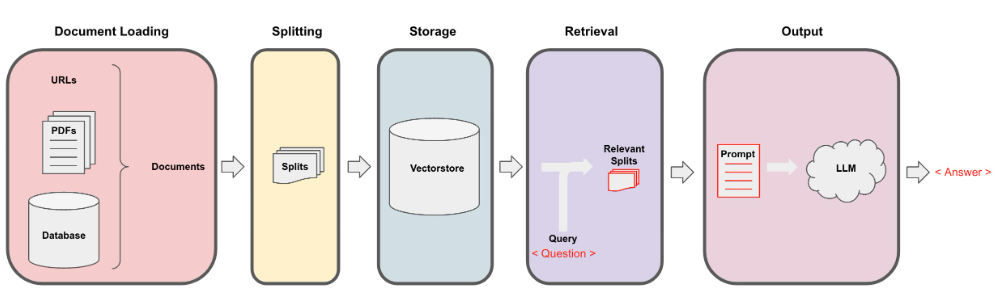

# Document Loading

In [4]:
import warnings
warnings.filterwarnings('ignore')

* ## 1. Loading

* ## import sqllite web_data.db


In [5]:
#所有檔案合併成一個
import sqlite3
import os

# Connect to the SQLite database
conn = sqlite3.connect(r'C:\Users\廖新瑜\Desktop\系統開發\ch\web_data.db')
cursor = conn.cursor()

# Fetch all entries from the web_content table
cursor.execute("SELECT * FROM web_content;")

# Get all results
all_data = cursor.fetchall()

# Directory to save text files
merged_file_path ='C:/Users/廖新瑜/Desktop/系統開發/ch/cs/acp/web_content.txt'

# Open the merged file for writing
with open(merged_file_path, 'w', encoding='utf-8') as merged_file:
    for entry in all_data:
        _, content = entry
        merged_file.write(content + "\n")  # Append content and a newline for separation

# Close the connection
conn.close()

# Confirmation message
print(f"All content has been merged into {merged_file_path}.")


All content has been merged into C:/Users/廖新瑜/Desktop/系統開發/ch/cs/acp/web_content.txt.


In [20]:
##所有檔案分別儲存
import sqlite3
import os

# Connect to the SQLite database
conn = sqlite3.connect(r'C:\Users\廖新瑜\Desktop\系統開發\ch\web_data.db')
cursor = conn.cursor()

# Fetch all entries from the web_content table
cursor.execute("SELECT id, content FROM web_content;")  # Assuming each entry has an 'id'

# Get all results
all_data = cursor.fetchall()

# Base directory to save text files
base_dir = r'C:/Users/廖新瑜/Desktop/系統開發/ch/cs/acp/DATA2'

# Ensure the directory exists
os.makedirs(base_dir, exist_ok=True)

# Loop through each entry in the database
for entry in all_data:
    entry_id, content = entry
    file_path = os.path.join(base_dir, f'web_content_{entry_id}.txt')  # Create a file name using the entry ID

    # Open the file for writing and save the content
    with open(file_path, 'w', encoding='utf-8') as file:
        file.write(content)

# Close the connection
conn.close()

# Confirmation message
print("All content has been saved to separate files.")


All content has been saved to separate files.


In [21]:
## 載入所有 txt files, TextLoader
import glob

path = 'C:/Users/廖新瑜/Desktop/系統開發/ch/cs/acp/DATA2/*txt'               # get file path
txt_path = glob.glob(path)                            # file path list

from langchain.document_loaders import TextLoader

loaders = [TextLoader(txt, encoding = "utf-8") for txt in txt_path]        
 
docs = []
for loader in loaders:
    docs.extend(loader.load())

len(txt_path), len(loaders), len(docs) 

(81, 81, 81)

In [23]:
docs[2]
txt_path

['C:/Users/廖新瑜/Desktop/系統開發/ch/cs/acp/DATA2\\web_content_1.txt',
 'C:/Users/廖新瑜/Desktop/系統開發/ch/cs/acp/DATA2\\web_content_10.txt',
 'C:/Users/廖新瑜/Desktop/系統開發/ch/cs/acp/DATA2\\web_content_11.txt',
 'C:/Users/廖新瑜/Desktop/系統開發/ch/cs/acp/DATA2\\web_content_12.txt',
 'C:/Users/廖新瑜/Desktop/系統開發/ch/cs/acp/DATA2\\web_content_13.txt',
 'C:/Users/廖新瑜/Desktop/系統開發/ch/cs/acp/DATA2\\web_content_14.txt',
 'C:/Users/廖新瑜/Desktop/系統開發/ch/cs/acp/DATA2\\web_content_15.txt',
 'C:/Users/廖新瑜/Desktop/系統開發/ch/cs/acp/DATA2\\web_content_16.txt',
 'C:/Users/廖新瑜/Desktop/系統開發/ch/cs/acp/DATA2\\web_content_17.txt',
 'C:/Users/廖新瑜/Desktop/系統開發/ch/cs/acp/DATA2\\web_content_18.txt',
 'C:/Users/廖新瑜/Desktop/系統開發/ch/cs/acp/DATA2\\web_content_19.txt',
 'C:/Users/廖新瑜/Desktop/系統開發/ch/cs/acp/DATA2\\web_content_2.txt',
 'C:/Users/廖新瑜/Desktop/系統開發/ch/cs/acp/DATA2\\web_content_20.txt',
 'C:/Users/廖新瑜/Desktop/系統開發/ch/cs/acp/DATA2\\web_content_21.txt',
 'C:/Users/廖新瑜/Desktop/系統開發/ch/cs/acp/DATA2\\web_content_22.txt',
 'C:/Users/廖

Each page is a `Document`.

A `Document` contains text (`page_content`) and `metadata`.

* ### all docs combine into one text for later text split, 缺點 失去metadata...

* #### save text file

In [15]:
## save to text file
#file = "../Data_test/預立醫療資料/預立醫療照護.txt"
#with open(file, 'w', encoding = "utf-8") as f:
#    f.write(text)                                      ## f.writelines(text) 不適合

* #### load text file

In [4]:
## load text file
file = "C:/Users/廖新瑜/Desktop/系統開發/ch/cs/acp/web_content.txt"
with open(file, 'r', encoding = "utf-8") as f:
    text_all = f.read()                                ## f.readlines() 不適合

type(text_all)

str

In [5]:
from IPython.display import Markdown

display(Markdown(text_all))    






臺南市政府衛生局-病人自主權利法專區


























































您的瀏覽器不支援JavaScript功能，若網頁功能無法正常使用時，請開啟瀏覽器JavaScript狀態。










:::
網站導覽

English
中文


小｜
中｜
大












訊息公告焦點新聞活動訊息宣導事項徵才專區護理人員甄試專區採購專區登革熱防治專區誘卵桶監測資訊臺南400活動專區蘇丹色素食安專區本局介紹組織架構局長介紹業務職掌交通資訊人事園地公文附件下載區廉政園地會計園地業務專區疾病管制業務醫事管理業務食品藥物管理心理健康管理國民健康管理檢驗中心業務綜合企劃服務專業人員區醫事管理資訊護理機構資訊證照服務廣告申請(醫療/藥物)糖尿病共同照護網代謝症候群防治專區基層醫療院所死亡通報教育訓練專區講義下載專區主題專區臺南市政府登革熱防治中心臺南市政府生物資料庫健康飲食運動地圖網長者社區資源整合運用平台社會安全網 -關懷e起來e反毒好心情問卷網幼兒專責醫師制度計畫專區便民服務為民服務窗口我要留言臺南市所屬醫院資訊平台身心障礙者各項連結專區行政相驗專區衛生保健志工各區衛生所門診服務各項費用收費標準各項申請表單下載專區委託檢驗申請表單下載第二官方語言常見問答集本局臉書帳號遊說法資訊專區資訊公開政府資訊公開施政計畫及成果補助公告專區視覺化查詢統計年報統計分析預告統計發佈時間表性別主流化專區公務統計方案衛生局預算及決算書市政府總預算及總決算書統計通報公開徵信內控聲明書公共衛生年報 支付或接受之補助




Home
病人自主權利法專區




跳到主要內容區塊:::



病人自主權利法QA







分享至 




Q1:什麼是《病人自主權利法》? 《病人自主權利法》是亞洲首部以病人為主體，保障病人醫療自主權利之專法，經立法院104年12月18日三讀通過，並於108年1月6日正式施行，其立法目的在於尊重病人醫療自主、保障其善終權益及促進醫病關係和諧。Q2:《病人自主權利法》為什麼重要？自己的生命由自己作主，《病人自主權利法》保障病人面臨5種臨床狀態時，醫療團隊能夠遵照病人自己的意願，提供適當照護方式及接受或拒絕維持生命治療與人工營養及流體餵養。透過醫療自主權的表達，不但可以保障病人尊嚴與善終權益，亦能降低親屬幫病人下醫療決策之壓力。Q3:什麼是「預立醫療照護諮商(ACP)」與「預立醫療決定(AD)」?「預立醫療照護諮商(ACP)」係指意願人與醫療機構的預立醫療照護諮商團隊、意願人親屬或其他關係人進行溝通討論的過程。商討當意願人處於特定臨床條件、意識昏迷或無法清楚表達意願時，醫療團隊應提供之適當照護方式及意願人得接受或拒絕之維持生命治療、人工營養及流體餵養。「預立醫療決定(AD)」係事先立下之書面意思表示，指明處於特定臨床條件時，希望接受或拒絕之維持生命治療、人工營養及流體餵養或其他與醫療照護、善終等相關意願之決定。Q4:「預立醫療決定(AD)」與「預立安寧緩和醫療暨維生醫療抉擇意願書(DNR)」有什麼不同？「預立安寧緩和醫療暨維生醫療抉擇意願書(DNR)」僅保障末期病人的醫療決定權，而「預立醫療決定(AD)」則除了末期病人外，新增4款臨床條件(處於不可逆轉之昏迷狀況、永久植物人狀態、極重度失智、其他經政府公告之疾病)；另，簽署「預立安寧緩和醫療暨維生醫療抉擇意願書(DNR)」只須簽署人本身及2位見證人共同填寫即可生效，而「預立醫療決定(AD)」須經過醫療機構的「預立醫療照護諮商」過程，且註記在健保IC卡，始具法律效力。預立安寧緩和醫療暨維生醫療抉擇意願書Q5:「預立醫療決定(AD)」和「安樂死」有什麼不同？不論是「安樂死」或「協助自殺」都是藉由藥物主動終結病人生命，目前僅有少數國家合法；但是「預立醫療決定(AD)」簽署內容是在保障病患有拒絕醫療的權利，讓生命回歸自然的歷程，不以醫療加工來延長生命。Q6:如果簽署「預立醫療決定(AD)」，是不是以後生病住院或受傷，醫護人員就不再幫我急救？不是，只有在「5種特定臨床條件」，「預立醫療決定(AD)」才會被啟動與執行，而且是否符合這5種條件，必須經過2位專科醫師確診，並經緩和醫療團隊至少二次照會確認，並不是在任何情況下都不予急救。Q7:「預立醫療照護諮商」須有哪些成員共同參與？另二親等內親屬無法親自到場怎麼辦？「預立醫療照護諮商」除了醫療團隊和意願人本人之外，醫療委任代理人及二親等內親屬(至少1人)必須在場，但二親等內之親屬死亡、失蹤或具特殊事由時，得不參與。另二親等內之親屬因居住地交通距離或特殊事由而無法親自到場參與諮商時，為免影響意願人簽署預立醫療決定之權利，並考量現今網路技術普及、科技產品運用進步，二親等內之親屬得以視訊方式參與預立醫療照護諮商。



點閱數3745　最後修改日期  2023/3/22 下午 04:48:33
回上頁


延伸閱讀








病人自主權利法幸福上路
                            







病人自主權利法短片簡介
                            















醫事管理業務



醫事管理業務簡介
臺南市中、重度級急救責任醫院急診即時資訊
醫療廣告相關業務
護理機構資訊
醫事機構收費標準
幼兒專責醫師制度計畫專區
執業查詢
醫院
診所
身心障礙鑑定及醫療輔具專區
醫療爭議調處
救護車管理
AED
器官捐贈與安寧緩和醫療
東南亞人士就醫資訊
病人自主權利法專區
偏遠地區巡迴醫療服務
醫療暴力防治專區
臺南市已裝設移位機醫院一覽表
全民國防手冊專區











點選收合 訊息公告 焦點新聞 活動訊息 宣導事項 徵才專區 護理人員甄試專區 採購專區 登革熱防治專區 誘卵桶監測資訊 臺南400活動專區 蘇丹色素食安專區 本局介紹 組織架構 局長介紹 業務職掌 交通資訊 人事園地 公文附件下載區 廉政園地 會計園地 業務專區 疾病管制業務 醫事管理業務 食品藥物管理 心理健康管理 國民健康管理 檢驗中心業務 綜合企劃服務 專業人員區 醫事管理資訊 護理機構資訊 證照服務 廣告申請(醫療/藥物) 糖尿病共同照護網 代謝症候群防治專區 基層醫療院所死亡通報 教育訓練專區 講義下載專區 主題專區 臺南市政府登革熱防治中心 臺南市政府生物資料庫 健康飲食運動地圖網 長者社區資源整合運用平台 社會安全網 -關懷e起來 e反毒好心情問卷網 幼兒專責醫師制度計畫專區 便民服務 為民服務窗口 我要留言 臺南市所屬醫院資訊平台 身心障礙者各項連結專區 行政相驗專區 衛生保健志工 各區衛生所門診服務 各項費用收費標準 各項申請表單下載專區 委託檢驗申請表單下載 第二官方語言 常見問答集 本局臉書帳號 遊說法資訊專區 資訊公開 政府資訊公開 施政計畫及成果 補助公告專區 視覺化查詢 統計年報 統計分析 預告統計發佈時間表 性別主流化專區 公務統計方案 衛生局預算及決算書 市政府總預算及總決算書 統計通報 公開徵信 內控聲明書 公共衛生年報  支付或接受之補助最佳瀏覽解析度 1024 x 800 建議使用IE10.0以上版本隱私權及安全政策｜網站資料開放宣告｜資訊安全政策聲明｜分類檢索：主題｜施政｜服務













東興辦公室730213 臺南市新營區東興路163號｜電話：06-6357716 撥出電話顯示號碼：06-7020000
林森辦公室701017 臺南市東區林森路一段418號｜電話：06-2679751 撥出電話顯示號碼：06-7020700因應防疫居家照護專線顯示號碼：7031400~7031461(林森)、7031462~7031499(東興)


































﻿





















































	臺北市立聯合醫院-常見問答及QA-病人自主權利法相關法律(施行細則)問題-答客問














跳到主要內容區塊 













  
搜尋
搜尋







進階搜尋

  分享您的瀏覽器不支援JavaScript功能，若網頁功能無法正常使用時，請開啟瀏覽器JavaScript狀態 分享至 Facebook[另開新視窗] 分享至 Plurk[另開新視窗] 分享至 twitter[另開新視窗] 分享至 line[另開新視窗] 分享至 email[另開新視窗]
   掛號服務  醫師簡介 醫師休(代)診資訊 查詢/取消掛號 醫師看診查詢 掛號須知 網路掛號 電子門診表
  就醫指南  門診服務 住院服務 就醫資訊參考 醫療收費基準 證明文件申請 就診科別查詢 疾病症狀索引 為民服務白皮書 就醫費用協助 電子病歷專區 民眾自費檢驗 COVID-19門診
  衛教專區  藥品資訊 營養百科 受試者保護專區 人體研究倫理審查委員會 圖書教育資源
  互動交流  政府資訊公開 公文公開專區 社會服務 醫病共享決策輔助平台 醫療品質與病人安全 民眾感謝函 健康諮詢FAQ 保有管理個人資料項目 利益衝突迴避法公開專區 陳情系統 院訊雙月刊 建教合作 臺北國際醫旅 表單下載
  線上申辦系統   認識市醫  使命願景及定位 首長介紹 部科介紹
  熱門關鍵字  上方連結 網站導覽 回首頁 台北通-健康服務 陳情系統 院訊雙月刊 員工信箱 English 雙語詞彙
  下方連結 雙語詞彙 FAQ 陳情系統 隱私權及資訊安全政策 資通安全政策及目標 宣導使用ODF開放文件格式
   :::  上方連結 網站導覽 回首頁 台北通-健康服務 陳情系統 院訊雙月刊 員工信箱 English 雙語詞彙
  分享您的瀏覽器不支援JavaScript功能，若網頁功能無法正常使用時，請開啟瀏覽器JavaScript狀態 分享至 Facebook[另開新視窗] 分享至 Plurk[另開新視窗] 分享至 twitter[另開新視窗] 分享至 line[另開新視窗] 分享至 email[另開新視窗]
  字級 小 中 大
  臺北市立聯合醫院 :::   掛號服務  醫師簡介 醫師休(代)診資訊 查詢/取消掛號 醫師看診查詢 掛號須知 網路掛號 電子門診表
  就醫指南  門診服務 住院服務 就醫資訊參考 醫療收費基準 證明文件申請 就診科別查詢 疾病症狀索引 為民服務白皮書 就醫費用協助 電子病歷專區 民眾自費檢驗 COVID-19門診
  衛教專區  藥品資訊 營養百科 受試者保護專區 人體研究倫理審查委員會 圖書教育資源
  互動交流  政府資訊公開 公文公開專區 社會服務 醫病共享決策輔助平台 醫療品質與病人安全 民眾感謝函 健康諮詢FAQ 保有管理個人資料項目 利益衝突迴避法公開專區 陳情系統 院訊雙月刊 建教合作 臺北國際醫旅 表單下載
  線上申辦系統   認識市醫  使命願景及定位 首長介紹 部科介紹
    熱門關鍵字 
搜尋
搜尋







進階搜尋

      首頁 預立醫療照護諮商 常見問答及QA
  常見問答及QA    網頁功能 列印內容[另開新視窗] 注音
 :::  病人自主權利法相關法律(施行細則)問題-答客問
      
    點閱數：2007

 資料更新：111-08-08 08:53 資料檢視：111-08-08 08:53 資料維護：臺北市立聯合醫院
  回上一頁
  :::   掛號服務  醫師簡介 醫師休(代)診資訊 查詢/取消掛號 醫師看診查詢 掛號須知 網路掛號 電子門診表
  就醫指南  門診服務 住院服務 就醫資訊參考 醫療收費基準 證明文件申請 就診科別查詢 疾病症狀索引 為民服務白皮書 就醫費用協助 電子病歷專區 民眾自費檢驗 COVID-19門診
  衛教專區  藥品資訊 營養百科 受試者保護專區 人體研究倫理審查委員會 圖書教育資源
  互動交流  政府資訊公開 公文公開專區 社會服務 民眾感謝函 健康諮詢FAQ 利益衝突迴避法公開專區 陳情系統 院訊雙月刊 建教合作
  認識市醫  使命願景及定位 首長介紹 部科介紹
  廠商入口專區  供應商入口網站  採購案件資訊 採購法令 衛材試用 技術移轉專區 智慧病房場域實驗 臺北市立聯合醫院資通安全管理規範文件
  重大建設計畫    下方連結 雙語詞彙 FAQ 陳情系統 隱私權及資訊安全政策 資通安全政策及目標 宣導使用ODF開放文件格式
  更新日期113-03-14 院址：103212 臺北市鄭州路145號 總機：(02)2555-3000臺北市民當家熱線 1999 轉 888 本院客服中心(外縣市請撥 02-25553000)24小時語音掛號號碼：(02)2181-1995本網站最佳瀏覽解析度為 1024 x 768本網站內容所有權歸臺北市立聯合醫院所有，禁止任意轉載、複製或做商業用途     



















預立醫療照護諮商及病人自主權利法 - 長庚醫療財團法人












長庚醫療財團法人 預立醫療照護諮商及病人自主權利法




Q&A


《病人自主權法案》和目前的《安寧緩和醫療條例》有何不同？
《安寧緩和醫療條例》僅保障末期病人的醫療決定權，而《病人自主權利法》則新增四大類保障對象；此外，簽署現行「預立安寧緩和醫療暨維生醫療抉擇意願書」時，只須簽署人本身及二位見證人共同填寫即可，而《病人自主權利法》中所保障的「預立醫療決定」則須經過醫療機構的「預立醫療照護諮商」過程，且註記在健保憑證，方可成立。


我可以更改我的預立醫療自主計畫書嗎？
只要您還有作決定的能力，您可以隨時更改。

選擇不再繼續接受醫療介入方式來維持生命時，還能做些甚麼？
醫療機構或醫師尊重病人在五種臨床狀態下，選擇終止、撤除或不施行維持生命治療或人工營養及流體餵養時，仍應提供病人緩和醫療，透過緩和醫療的舒適照護、疼痛控制、心理、靈性照護等方式，引導病人和家屬進行道謝、道歉、道愛、道別的「四道人生」，讓病人有限的生命裡保有尊嚴，不留遺憾。

「預立醫療決定」與現有「預立安寧緩和醫療暨維生醫療抉擇意願書」異同？


與「預立醫療自主計畫」相關之醫療措施與名詞有哪些？
心肺復甦術（Cardiopulmonary Resuscitation，簡稱CPR）是指當病人的心臟或肺臟功能突然停止時，以醫療方式使心臟跳動和恢復呼吸。心肺復甦術包含可經由人工呼吸方式和體外按壓心臟，或是使用電擊使得心臟恢復跳動和恢復呼吸；亦包含氣管內插管，與急救藥物注射。
不施行心肺復甦術（Do Not Resuscitate，簡稱DNR）指的是當病情已到末期 ，施予心肺復甦並不能延長病人的生命，此時拒絕相關的無效醫療程序。拒絕急救嘗試並非放棄生命的希望，而是面對一個事實——CPR無法挽回末期病人的生命。
接受自然死亡（Allow Natural Death，簡稱AND）接受自然死亡是指對於已達疾病末期的病人，任何治療只是延後病人的死亡，此時不採取任何延後死亡的治療，讓病人在家人陪伴下尊嚴的自然離開世界。
維生醫療用以維持病人生命徵象的醫療措施，如人工營養、呼吸器、腎臟透析、葉克膜等醫療行為，每一種醫療措施都有其適應的時機，但對於末期病人已無治癒效果，而只能延長其瀕死過程。
腎臟透析（洗腎）分為「血液透析」和「腹膜透析」兩種，在血液透析中病人全身的血液必須流經一台機器，「洗淨」血中雜質，再將乾淨的血送回病人體內。
管灌餵食這是為不能吞嚥食物的病人餵食的一種方式，鼻胃管是由一根能夠裝載流質食物的小塑膠管，經由鼻腔直接插入胃或腸子。對末期的病人，太多的營養可能造成病人不適，臨終病人不使用人工水分（如靜脈點滴或餵食管）的好處多於壞處，包括肺積水減少，就能減輕肺水腫，讓呼吸較順暢；喉部痰液減少，就能減少抽痰的不適；減少排尿，就不太需要為了換床（單）或尿布而搬動病人。
呼吸器這是指當病人無法自行呼吸時用來協助呼吸的機器，這一個特殊機器與插入氣管內的軟管相連，連接機器的管子會由口部置入，通到氣管，以便機器將空氣打進肺部。對於可能會自行拔掉管子的病人，往往必須縛住雙手，或是注射鎮靜劑，以免因意外拔管而造成危險。
使用血液製品輸注（如輸血）末期病人若發生貧血相關的不適症狀，例如呼吸困難等，經醫生評估，會依病況建議進行輸血或是使用紅血球生成素治療。
抗生素末期病人常會因吞嚥困難造成吸入性肺炎，。如果病人在接受幾次抗生素療程之後，仍舊持續併發肺炎，病人和家屬也許就要考慮是否繼續接受這類治療。因為藥物雖然可能暫時有效，卻無法根治持續惡化的基本問題。
化學治療或化療化療一詞是泛指用抗癌藥物來治療癌症。是抑制癌細胞的生長，但也會同時殺死正常細胞而造成副作用。



維護單位：社會服務處網站內容為長庚醫療財團法人所有 未經授權 禁止轉載











主選單


首頁
門診掛號
Q&A





相關連結

安寧緩和醫學會安寧緩和護理學會台灣安寧照顧基金會



相關法規

病人自主權利法病人自主權利法施行細則預立醫療決定書


















《病人自主權法》ＱＡ - Free To Fly 護理師 • 林佳嬡

























































































		跳至主要內容










 



首頁關於攝影選單切換按鈕

醫療攝影選單切換按鈕

醫療┆真實故事紀錄 
 人像攝影 親子攝影
醫療選單切換按鈕

醫療┆資訊 醫療┆真實故事紀錄
育兒選單切換按鈕

育兒┆大小事 育兒┆旅遊 育兒┆親子遊戲
自我成長選單切換按鈕

所有文章 課程┆心得 閱讀筆記 自我探索 實用工具
服務 



  Email   







 







 







Main Menu

 












  Email   






首頁關於攝影選單切換按鈕

醫療攝影選單切換按鈕

醫療┆真實故事紀錄 
 人像攝影 親子攝影
醫療選單切換按鈕

醫療┆資訊 醫療┆真實故事紀錄
育兒選單切換按鈕

育兒┆大小事 育兒┆旅遊 育兒┆親子遊戲
自我成長選單切換按鈕

所有文章 課程┆心得 閱讀筆記 自我探索 實用工具
服務 










《病人自主權法》ＱＡ醫療┆資訊 / 作者:  


				林佳嬡 (Jiaai)			





		 /  2021-12-01 


本文最後更新日期： 2024-03-13 
《病人自主權法》ＱＡ

Ｑ：生命自主為何還要二等親同意？
Ａ：醫療現場有時會發生家屬有不同意見，這也是為什麼在進行預立醫療照顧諮商時，需要有二親等內的親屬及醫療委任代理人參與。ACP諮商過程中無論是醫療專業人員、意願人、家屬、醫療委任代理人，大家都必須好好討論，為了意願人期待的生活品質，做出最合適的選擇。

Ｑ沒家人的話？可以自己預立醫療照護諮商嗎？
Ａ：預立醫療照護諮商是規定「二親等內親屬至少一人」參加，二親等內親屬包含了姻親跟血親，所以父母、祖父母、配偶的兄弟姊妹、兄嫂弟媳姐夫妹夫….等其實都算喔！若真的都沒有時，病主法第九條有一個但書：「二親等內之親屬死亡、失蹤或具特殊事由時，得不參與。」

Ｑ：之前我已經有到三軍總醫院內湖分院辦理不急救的登記是否也有效嗎？
Ａ：先前簽的應該是「預立安寧緩和醫療暨維生醫療抉擇意願書」
與病人自主權利法新制度下的「預立醫療決定」是不同東西，原先簽署內容仍然有效。

Ｑ：以前簽過「預立安寧緩和醫療暨維生醫療抉擇意願書」，現在還需要簽「預立醫療決定」嗎？
Ａ：建議簽署，因「預立醫療決定」除了保障末期病人，還擴大到上面所提的四種 臨床條件病人，且拒絕醫療的範圍還包括：不接受鼻胃管灌食等延命措施範圍，建議簽過安寧意願書的人還是要簽預立醫療決定。

Ｑ：一定要諮商才能簽意願書嗎？
Ａ：是的，病主法第九條有提到，預立醫療決定，一定要經過預立醫療照護諮商，要有法律效力的話，還是要經過諮商等法上規定的流程。

Ｑ：收費如何計算？為什麼這麼貴？
Ａ：
1. 目前收費上限是60分鐘3500元。
推行之前衛福部有先進行試辦，依據台北市聯合醫院過往的試辦經驗，醫療團隊為民眾進行預立醫療照護諮商，平均每人次耗時60~90分鐘，成本約在2千至4千元間，經與地方衛生局共同研商收費核定原則，初步共識以60分鐘3,500元為「上限」。
2. 的確金額是較高的，所以鼓勵家屬一起參與諮商，目前有規劃同一時段第2人次可減免「預立醫療諮商」費用。
3. 另外，還有以下三類人可以免費接受ACP：
(1) 中、低收入戶可於各縣市之「預立醫療照護諮商推廣獎勵計畫」之示範醫院，免費接受照護諮商服務。
(2) 無法出門的失能長者，透過居家失能個案家庭醫師方案，由醫師到宅協助進行「預立醫療照護諮商」服務
(3) 經確診之癌症病人可免費進行「預立醫療照護諮商」(目前持續規劃確認中)

Ｑ：如果我簽署預立醫療決定，以後我生病住院的話，醫護人員會不會就直接放棄 不救我了」？
Ａ：不會，經由「預立醫療決定」簽署後，當上述五款「臨床條件病人」發生時，您的預立醫療決定才會被啟動與執行，而是否符合這五款的條件，必須經過兩位專科醫師、至少二次緩和醫療團隊照會評估，其過程非常謹慎，不可能因立下預立醫療決定，而讓原有治癒機會的患者因而被提前放棄治療。

Ｑ：醫療進展快速，若現在治不好的疾病以後有機會根癒，想改變決定怎麼辦？
Ａ：可以隨時撤回或變更AD，如果改變決定，須向醫療機構提供變更，並再次註記在健保卡。

Ｑ：「預立醫療決定」跟安樂死有什麼不同?
Ａ：病人自主權利法不是安樂死，病人衡量自我生命品質價值觀後，可自主決定拒絕 透過人工或儀器介入來維繫生命，醫師則在尊重「末期病人」意願下中止醫療，讓病人自然地走。

Ｑ：簽署「預立醫療決定」要找見證人，所以我要找到見證人一起去醫院嗎？
Ａ：是的，本法規定在預立醫療決定書上簽名時有二名以上具完全行為能力人在場見證 或經公證人公證即可。另請注意，您的醫療委任代理人是無法做見證人的。

Ｑ：家人現在已經生病、意識不清，我可以幫他簽署「預立醫療決定」嗎？
Ａ：不行，當病人意識昏迷或無法表達意願時，AD為尊重病人，因此必須在只有本人能表達意見時才可簽署。

Ｑ：我的家屬已經中風了，現在在養護中心可以簽署「預立醫療決定」嗎？
Ａ：原則上只要您的家屬意識清楚且可以表達意願，在沒有心智缺陷或非出於自願的疑 慮下，需邀請二親等家屬及醫療委任代理人（若無醫療委任代理人則二親等家屬即可），共同參與預立醫療照護諮商及簽署預立醫療決定書。

Ｑ：我的家屬現在失智，可以帶她可進行「預立醫療照護諮商」嗎？
Ａ：失智症視嚴重程度有不同分期，早期失智的病人若經預立醫療照護諮商團隊評估仍具有心智能力可進行醫療決定的討論，則可依法定程序進行預立醫療照護諮商。

Ｑ：我是同志 ,我帶我的伴侶去簽署「預立醫療決定」可以嗎？
Ａ：可以，原則上您可指定 20 歲以上之人為您的醫療委任代理人，在未違反法規排除對象的情況下，您可以指定您的伴侶為醫療委任代理人。

Ｑ：我想帶媽媽去諮商，我要怎麼跟她說？
Ａ：您可透過新聞報導、社會重大事件等話題，試著在聊天中找到討論時機，先聊聊自己對生命與死亡之體悟，鼓勵媽媽分享她的感受及想法，觀察媽媽反應。若媽媽不排斥，願意表達所期待的醫療照顧或身心靈需求，則可邀請她參加「預立醫療照護諮商」；並請告訴她，這是由醫師、護理師、社工師或心理師組成的諮商團隊，提供醫療、社會、家庭與心理的討論；諮商過後不一定要簽署「預立醫療決定書」，但可透過諮商過程，讓媽媽有機會更清楚的思考與表達想法，也讓您有機會事先瞭解媽媽的期待。 

☞ 資訊來源：
台中市政府衛生局
衛生福利部

延伸閱讀：

你聽過「病人自主權利法」嗎？透過預立醫療決定，「善終」可以自己做主


相關閱讀：

DNR是什麼？花點時間了解，好死沒這麼難！
《DNR》如果拍下來，能夠更了解急救和善終嗎？一位護理師的沉痛告白
《DNR同意書》完整簽署流程
《器官捐贈》— 移植前後，巨然變化的兩個人生
《八仙塵爆》83%全身燒傷下的重生-天使之吻





林佳嬡 (Jiaai)加護病房 護理師/ 攝影師/ Free To Fly 的作者，同時也是一位母親
現為自由工作者，倘若我的一篇文或一張影像能帶給你價值
那就是創立這網站的初衷。
這邊涵蓋了：
𓇢 影像創作 ➛ 醫療攝影 、人像攝影、親子攝影
𓇢 那些被埋沒的真實影像故事 ➛ 醫療真實故事紀錄 、醫療資訊
𓇢 育兒的相關資訊 ➛ 育兒大小事、育兒旅遊、親子遊戲
𓇢 幫助你重新定義生命、找到自我價值的內容 ➛ 閱讀筆記 、 自我探索
還有……很多乾貨 ➛ 實用工具 、 課程心得
—————————————————————————✿
𝐼𝐺  claire__0212        𝐹𝐵  Free To Fly
合作邀約請來信：ai@freetofly.com.tw
—————————————————————————
將本文分享至：

相關閱讀：


DNR是什麼？花點時間了解，好死沒這麼難！

震驚！簽了拒絕心肺復甦（DNR）還是被急救？

《長照2.0》獻給照顧者-長照資源懶人包

《全身健康檢查》31歲送給自己的禮物—台中澄清醫院柏忕自費一日體驗






Post navigation
← 上一篇 文章下一篇 文章 →
 

發佈留言 取消回覆發佈留言必須填寫的電子郵件地址不會公開。 必填欄位標示為 *請在這裡輸入內容...姓名 *
電子郵件地址 *
網站網址
 在瀏覽器中儲存顯示名稱、電子郵件地址及個人網站網址，以供下次發佈留言時使用。
 

 







搜尋關鍵字:





嗨！我是佳嬡，我是一名護理師2014年替燒傷患者拍攝《天使之吻》，意外成了拍攝醫療攝影的開端。2020年離開職場後，沈浸於當母親的喜悅。現為自由工作者，用自己喜歡的節奏，打造想要的生活。合作邀約：ai@freetofly.com.tw▼▼——— Instagram ———▼▼





claire__0212
護理師 │ 攝影 │ 自我成長 │ 育兒 │ #freetoflytw 作者













👼🏻

《無緣的孩子》

.
.

三年前經


 






 





❄️

2024 北海道
太喜歡雪國，下回要
 





#自製烏魚子 #自曬烏魚子
 





#市場 #菜市場 #菜價
 













 






 






 


 


Load More






 在 Instagram 上追蹤







—— 熱門文章 ——《DNR同意書》完整簽署流程《子宮外孕全記錄》從發現到緊急手術臨終前48小時會出現的症狀這半年，孩子接連四次長針眼手術《使用心得》Kobo Libra H2O白色閱讀器 ▏使用半年看電子書的心得

𝘯𝘦𝘸—— 最新文章 ———
自製烏魚子：曬烏魚子的簡易做法分享2024-02-07
《奶克菲爾Kefir》自己做vs買現成？探尋輕鬆好味的選擇2024-01-23
《開箱》BOSCH 8 沸石系列洗碗機 SMV8ZCX00X – 真的能拯救我的雙手嗎？2023-10-04
《幼兒視力》四歲竟然發現近視了！2023-06-13
《親子活動》循田水小旅行：與四歲女兒在彰化溪洲共度純樂時光│濁水溪土泥染體驗│牛糞薰香製作│林下野餐│近距離牽水牛2023-06-05
《育兒》下雨天絕對是最開心的一件事！帶著孩子轉變心態找到新樂趣 4Y3M2023-05-23



——— 我的第一本書 ———Free To Fly：生命、勇氣、愛，加護病房護理師眼中的醫療群像與生死覺察

—— Free To Fly 臉書專頁 ——

《 Hahow 線上課程專屬優惠碼 》


點我註冊折抵300元


課程推薦𖤐 1 《可愛先決！跟著叮咚拍出日雜般的家庭寫真》☞實際上課心得：《Hahow課程心得》叮咚攝影課-這堂課教了我怎麼用相機拍故事

課程推薦𖤐 2 《Notion 實戰課程：打造專屬數位工作術》☞實際上課心得：《生產力工具Notion》：每天忙碌仍沒有進展？子彈筆記幫你重新定位自己，打造理想生活！（免費模板分享）


註冊會員領取 50元 折扣券


—— 𖤐 影像故事 ——

《憂鬱症Depression》再活一次，就看見生命是完整的點我繼續閱讀》

《八仙塵爆》83%全身燒傷下的重生-天使之吻點我繼續閱讀》

《長照2.0》Sound of Silence致照顧者，病後人生點我繼續閱讀》

《器官捐贈》— 移植前後，巨然變化的兩個人生點我繼續閱讀》

《DNR》如果拍下來，能夠更了解急救和善終嗎？一位護理師的沉痛告白點我繼續閱讀》

《卵巢癌重生紀錄》Pinko的一千零一夜點我繼續閱讀》

《乳癌Breast cancer》心房上的印記點我繼續閱讀》

《護理師日常》褪去護理職涯，談談在加護病房那七年的護理工作點我繼續閱讀》
分類

Uncategorized (1)

實用工具 (7)

育兒┆大小事 (25)

育兒┆旅遊 (4)

育兒┆親子遊戲 (13)

自我探索 (3)

課程┆心得 (5)

醫療┆真實故事紀錄 (10)

醫療┆資訊 (14)

閱讀筆記 (23)


近期留言「camisa da costa rica」於〈臨終前48小時會出現的症狀〉發佈留言「吳孟弦」於〈這半年，孩子接連四次長針眼手術〉發佈留言「林佳嬡 (Jiaai)」於〈28歲，我決定離職〉發佈留言「蘇小姐」於〈28歲，我決定離職〉發佈留言




 









 











Copyright © 2024 Free To Fly 護理師 • 林佳嬡
 



 



連絡信箱：ai@freetofly.com.tw連絡信箱：ai@freetofly.com.tw 



隱私權政策
免責聲明
聯繫我們
 









返回頂端


 回到頂端


































什麼是預立醫療照護諮商？ | 安寧照顧基金會


































Jump to Navigation











search
facebook
line
youtube
en
管理員登入


最新消息
文宣會訊
安寧資源地圖
常見問題
留言詢問
時數證明
線上課程







最新消息
認識我們
安寧療護/病主法
教育訓練
經濟補助
國際關係
文宣推廣
安寧資源地圖
線上課程
時數證明
English


認識我們安寧療護│病人自主生命教育教育訓練經濟補助國際關係捐款支持







什麼是預立醫療照護諮商？




「預立醫療照護諮商」指的是病人、家屬、醫療團隊三方在醫療機構進行的溝通過程，也是簽署「預立醫療決定」的先決條件。
主要目的，就是讓您與您的家屬諮詢專業團隊的意見，並與他們討論當自己面臨特定臨床條件、意識昏迷或無法清楚表達意願時，醫療機構或醫師應該處理的方式。您可以在諮詢過後，事先做出決定，簽下預立醫療決定書。
您可以在本網站查詢到有提供「預立醫療照護諮商」的醫療機構；請注意，「預立醫療照護諮商」是自費門診，詳細收費內容需依各醫院規定。
問題類別: 生命教育 




















 經濟補助文宣索取
 
   

 






 face booklineYoutube
 
   

 
























 地址：(251404)新北市淡水區民生路45號
　　　(交通方式)
Email：hospice@hospice.org.tw
電話：(02)2808-1130　
傳真：(02)2808-1137
  
 
   

 







      訂閱電子報    










 







Copyright (c) 2024 All Rights Reserved by Hospice Foundation of Taiwan本網站由 網絡行動科技 NETivism 製作



   請升級或更換其他瀏覽器 本系統已提升網路傳輸加密等級，IE8及以下版本將無法支援。為維護網路交易安全性，請升級或更換至右列其他瀏覽器。  



















什麼是預立醫療照護諮商？ | 安寧照顧基金會


































Jump to Navigation











search
facebook
line
youtube
en
管理員登入


最新消息
文宣會訊
安寧資源地圖
常見問題
留言詢問
時數證明
線上課程







最新消息
認識我們
安寧療護/病主法
教育訓練
經濟補助
國際關係
文宣推廣
安寧資源地圖
線上課程
時數證明
English


認識我們安寧療護│病人自主生命教育教育訓練經濟補助國際關係捐款支持







什麼是預立醫療照護諮商？




「預立醫療照護諮商」指的是病人、家屬、醫療團隊三方在醫療機構進行的溝通過程，也是簽署「預立醫療決定」的先決條件。
主要目的，就是讓您與您的家屬諮詢專業團隊的意見，並與他們討論當自己面臨特定臨床條件、意識昏迷或無法清楚表達意願時，醫療機構或醫師應該處理的方式。您可以在諮詢過後，事先做出決定，簽下預立醫療決定書。
您可以在本網站查詢到有提供「預立醫療照護諮商」的醫療機構；請注意，「預立醫療照護諮商」是自費門診，詳細收費內容需依各醫院規定。
問題類別: 生命教育 




















 經濟補助文宣索取
 
   

 






 face booklineYoutube
 
   

 
























 地址：(251404)新北市淡水區民生路45號
　　　(交通方式)
Email：hospice@hospice.org.tw
電話：(02)2808-1130　
傳真：(02)2808-1137
  
 
   

 







      訂閱電子報    










 







Copyright (c) 2024 All Rights Reserved by Hospice Foundation of Taiwan本網站由 網絡行動科技 NETivism 製作



   請升級或更換其他瀏覽器 本系統已提升網路傳輸加密等級，IE8及以下版本將無法支援。為維護網路交易安全性，請升級或更換至右列其他瀏覽器。  

















安寧照顧 安寧療護 | 安寧照顧基金會







































Jump to Navigation











search
facebook
line
youtube
en
管理員登入


最新消息
文宣會訊
安寧資源地圖
常見問題
留言詢問
時數證明
線上課程







最新消息
認識我們
安寧療護/病主法
教育訓練
經濟補助
國際關係
文宣推廣
安寧資源地圖
線上課程
時數證明
English


認識我們安寧療護│病人自主生命教育教育訓練經濟補助國際關係捐款支持







安寧照顧 安寧療護









  
   

 



安寧療護
病人自主權利法
 






 什麼是安寧療護？ 
 安寧療護的服務對象是末期病人。目的是幫助、尊重病患、減輕痛苦，讓病患能擁有生命的尊嚴與生活品質，並在五全照顧下得以安然逝去；同時陪伴家屬勇敢地渡過哀傷，重新展開自己的人生。
安寧團隊是由不同職類的專業醫療人員組成，提供病人及家屬身、心、靈的全方位照顧，並且協助病人及家屬面對死亡的各種調適，讓生死兩無憾！
以下「基本概念」內容，感謝賴鈺嘉醫師同意引用《安寧療護入門》一書,蔡佩渝醫師重整。
 
   

 



      基本概念介紹    




 什麼是安寧緩和療護? 
 依世界衛生組織的定義，安寧緩和療護是指，當病人及家屬面臨威脅生命的疾病時，得經過預防及緩解的方式，來改善他們的生活品質。並且要以早期偵測、周全評估以及全人身心靈的方式去治療其疼痛及其他問題，以達提升生活品質之目標。
安寧療護的理念：

提供疼痛及其他症狀的緩解並結合心理、社會及靈性照顧。
肯定生命，提供支持系統，協助患者積極生存直到死亡自然到來。
認同死亡是生命的必然過程，因此不加速或延長死亡。
支持家屬，使他們在病人生病中及過世後的悲傷期，能作適當的調整。
利用團隊的力量，提供病人及家屬的需要，包括悲傷期的諮詢。
	 

安寧療護沿自中世紀之Hospice，原意是指提供朝聖者或長程旅行者休養體力之中途驛站；1967年6月，英國桑德絲博士(Cicely Saunders)成立Hospice醫院（St. Christopher’s Hospice），為照顧臨終垂危病患之醫療機構，幫助那些正走入人生最後一程的病患及其家屬。
安寧療護診治模式以尊重為出發點，兼顧身心靈全人照顧，這種強調人性尊嚴，生活品質的醫療方式獲得許多先進國家的認同，目前已經從醫療工作發展成為一種社會運動，敦促人類去思考生存的價值，生活的目標，以及生命的終極意義。1981年，安寧照顧觀念首度在國內醫學界提出; 1990年，淡水馬偕紀念醫院成立第一個安寧病房，台灣成為世界上第18個有安寧療護的國家，至今台灣有數百個醫療單位，提供不同模式的安寧緩和醫療照顧。
  

 接受安寧緩和醫療照顧條件 
 1. 末期病人：根據安寧緩和醫療條例的定義，末期病人是指罹患嚴重傷病，經醫師診斷認為不可治癒，且有醫學上之證據，近期內病程進行至死亡已不可避免者。
雖然醫療有許多不確定性，對於生命存活期評估無法精準到完全令人滿意，但是仍有一些方法可供醫療人員參考，如：若是病人在未來一年死亡，醫師不感意外。
2. 病人有接受安寧療護的需要，如：持續性身體疼痛及其他不適之症狀及心理、精神、心靈問題需要輔導者。除此之外，也可以參考國外的安寧需求指標SPICT(SupportiveandPalliativeCareIndicatorsTool），如：短時間內非預期性頻繁住院、明顯體重減輕或持續體重過輕、身體/認知功能很差或下降、照顧者需要更多協助與支持。
3. 病人及家屬同意接受安寧療護。安寧緩和療護並不為了治癒疾病或延長受苦的生命，而是以積極提升病人及家屬的生活品質為醫療目標。照顧過程中，病家需要與醫療團隊一起合作，所以病家及團隊的照顧理念一致非常重要。
  

 醫病關係常見問題 
 「信任」，在安寧療護的照顧過程扮演非常重要的角色，病人、家屬與醫療人員間若沒有信任，在診斷與治療的過程之中，往往會有許多的不安與遲疑。以下是病家常見的疑問：

病情告知：
	出於怕病人傷心、不配合治療、胡思亂想等各種理由，家屬大多對末期病人隱瞞病情。雖是保護病人，但錯失和病人真誠互動。當病人身體一直走下坡，卻無法得到適當說明，反而容易焦慮不安，心裡的想法或願望沒機會交代與實現，徒然留下遺憾。

如何在適當時機，以適當方式告知病情已是醫師必要訓練。家屬可以和醫療人員合作，以最適合病人的方式告知病情。病人難免會經歷情緒低落，需要家屬與醫療團隊的關心與陪伴，病人獲真誠的支持，才能更有力量面對各種難題。

病人未能事先表達醫療意願：

華人忌談死亡，加上未充分告知病情，使得病人常沒機會表達對生命末期的醫療照護需求。一旦病人意識不清或認知功能受損而無法表達意見時，家屬必須替病人做出重大決定。此時除了需承受做決定的壓力，甚至需經歷家屬間因意見不同而失和。建議每個人在平時都能思考若生命即將走到盡頭，希望獲得什麼樣的醫療及照護? 所重視的生命價值為何? 怎樣的生活品質及死亡品質是可以接受的?
家中若有長輩，可利用新聞事件或生活周遭的情境為引子，和長輩討論以上的話題，瞭解他們的想法，鼓勵表達。若是長輩主動提起這些話題，更要用心聆聽，切勿打斷，最好可以錄音下來，讓未在場的家人也能知道長輩的想法，若長輩可以親自簽署意願書，以書面表達想法是最好的。日後，就按照長輩的意願處理，如此，既可減少做決定的壓力又避免意見衝突傷了和氣，這對長輩來說，是最符合華人的孝「順」了。

嗎啡類藥物使用：

衛福部食藥署明文規定，末期病人經醫師評估有需要，皆能居家使用嗎啡類藥物。證諸各國藥典及癌症治療指引，嗎啡類藥物之使用適應症不侷限於疼痛，尚包括呼吸困難、急性肺水腫、心肌梗塞、嚴重腹瀉等症狀。在專業醫師評估下使用嗎啡類藥物緩解末期病人症狀，是合乎法律及醫學倫理的醫療行為。透過適當的劑量調整，可以讓病人獲得良好的症狀控制及生活品質。

營養水分的給予：

根據國內外研究，末期病人使用全靜脈營養並無法延長存活期，對於提升生活品質及身體功能也沒有明確效果。即使是單純給予人工水份，也要留意是否會增加病人水腫、腹水、肋膜積水…的負擔， 反而違反了讓病人舒適的原則。

和安樂死差異：

安樂死的出發點為捨不得病人受苦，而採取立即結束病人生命的做法。但是刻意結束生命，卻可能失去妥善緩解病人痛苦的機會。安寧緩和療護則是積極地運用專業能力緩解病人身心靈痛苦，讓病人有尊嚴有品質的活到最後一刻。
建立信賴感往往需要經過良好的溝通，消息的互換、情緒的表達與意義的瞭解。尤其在生命末期，醫病之間相互傾聽了解對方的真實想法是必要的。建議病人及家屬向醫療人員提出擔心或疑慮的地方，獲得充份訊息後，和醫療團隊合作，做出最適合病人的醫療處置計畫。
 
  

 對臨終病人及家屬的幫助 
 1. 談論：談論有關疾病之事，若為癌症則直呼之，勿隱瞞病情。此點在於診斷的初期往往非常困難，跟親人談論致死性疾病是人生很少的經驗，以至於往往需要醫護人員的參與及引導才能進行。
2. 接受：接受死亡是生命之一部分，而它也確實如此。把每一天都視為生命可能的最後一天，這樣做有些困難，但是，能夠讓我們平靜地把每一天過得更有意義，更能夠把握住真實的生命。
3. 感念：感念每一天皆為(神)之恩賜，並盡可能有意義的度過，不要整天想著死亡之靠近。日子裡面有許多微不足道的事情都值得我們感謝，在平常不太知覺的快樂，也可以為每天增添色彩。
4. 認知：認知生命無法完美無缺，知道世事無法盡如人意，也知道疾病無法根除，從認知而認同，才能轉換心境。
5. 祈禱：不要羞怯於祈禱拜佛，它並非怯弱而是力量的來源。把自己的懦弱表達在神的面前，也把自己的害怕說出來。有些宗教的儀式會適合某些人，基本上祈禱是有幫助的日常功課。
6. 學習：我們每人都會因為一種原因而死亡，需學習與疾病一起共存，而非只想著會因它而亡。在生命的末期才學習面對生命的不完美，往往是困難而辛苦的歷程，有經驗的義工或醫護人員的幫忙通常是需要的。有時候，親友也會因為一起學習而獲益。
7. 關係：跟你的親朋好友處於讓你覺得舒適之關係，勿期待憐憫。把自己放置在一個新的人際關係網內是不容易的事情，要把別人的惋惜與悲憐視為鴻毛，也並非易事，躲避談論病情更是難為。只有自己的心情平靜，接受事實，才能夠讓新的人際關係建立在穩定而不悲傷的基礎上面。
8. 安排：為將來做切合實際的安排，並確認家人了解。預先表達臨終時的醫療意願是沉重也是慎重的的，生前遺囑的簽立更是需要突破心理障礙、家庭壓力以及社會文化的影響，並不是每一個想這樣做的人都能夠達成願望。小小心願的追求值得一試，生前事蹟的回顧與整理也很有意義，只是需要堅決的毅力。
9. 設定：設定生活之新目標，且了解自己之限制，這時，生活中就單純事件可以成為最享受的是。對於小事件的滿足與享受是要學習的，並不是每一個人都能夠在生活細節上面找到生存的意味，小範圍的目標也不容易建構，每天讀兩首詩能否滿足就因人而異。
10. 討論：當問題出現時與家人共同討論之，最好包含小孩。如果平時來往密切，親朋好友或左鄰右舍也是可以交談的對象，有時候，只是傾倒一些情緒，並不是要改變事實；有時候，則只是單純講講話，這樣已經足夠讓心情繼續穩定走下去。
正向的態度與有效的方法對病人的照顧是必要的。這些，我們都要一起學習。
  

 靈性層面之照顧 
 末期病人靈性層面的問題是很複雜的，病人可能對生命的意義、生病所帶來的各種痛苦、死後生命的去向產生質疑。此刻病人特別需要周圍親人的關愛，以及提供靈性層面的關懷。有鑑於此，安寧照顧團隊中設有專屬的牧靈人員，期能為末期病人及家屬提供以下的服務：

做為一位有愛心、同理心的傾聽陪伴者，瞭解病人真正內心的需求，陪伴他度過這一切的苦難。靜靜的陪伴傾聽就是一顆很有效的藥物.
提供病人靈性層面的需求，在人生意義、愛與歸屬上尋得滿足。不知道生命該停泊於何方是很不舒適的，尤其會讓人意志消沉。
病患因痛苦所產生的各種人生疑惑、宗教信仰的困惑，提供宗教性的解答，並協助病患瞭解今生、來世之後之路，使心靈得到安寧與希望，坦然無懼的面對死亡。
協助病患解除不安、怨恨、罪惡等感覺，能夠寬恕別人與蒙獲寬恕，尋求釋放與獲得心靈的平安。並不是每一個人都能夠找到心靈深處不安的原因，專業的訪談有時候是有幫助的。
成為病患和家屬之間的調和者。有些交談溝通需要足夠的資訊才能啟動，照護團隊的每一個成員都有可能是一個成功的訊息調和者，某些應該彈說出來的問題，往往需要醫護人員才能啟動。
執行宗教性懺悔或彌留時刻之祝福等儀式。儀典有心靈沉澱的作用，不只是對病人，對親人情緒的穩定也有幫助；有虔誠宗教信仰的人，在熟悉的儀式、樂音、朋友的包圍之中，往往能夠釋放內心的焦慮與不安，也更有勇氣面對疾病。
協助喪葬禮儀，並提供完整的助喪服務。往生以後的處理流程，是親朋往後重要的回憶經驗，莊嚴平順的禮儀不但表現出對死者的尊敬，也讓生者有正向的體驗；如果能夠因此而獲得一場生命教育的課程，更是意外的收穫。
病人離世後，協助家屬走過哀傷期。家人的悲傷期有時候會很長，三個月到半年是很常見的。家人在哀傷期也比較容易有病情產生，所以，陪伴家人也是一件重要的工作。
病患逝世後定時之追思、哀悼禮儀的執行與安排。照片、著作、藝術品等等的回顧審視，一個群體性質的追念活動，小團體的聚會等等，都有助於家屬親朋的懷念。令人感動的聚會是一種生命的體驗，許多人會因此而省思自己的人生目標與生命方向。

靈性照顧是需要安排的，是需要儀典的，也需要專業知識的加入。
  

 情緒問題 
 面對逐漸逼近的死亡卻只能照顧而無法治癒，對任何人來講都是一個很大的壓力。
壓力一旦造成了，對人體就會產生一定程度的影響，最常見的影響有三類：其一為焦慮：前面是一個不可知的未來，心裡自然是容易不知所措；尤其容易因為焦慮而形成害怕，使人不敢面對現實。其二為調適困難：使人陷入手足無措，不知如何處理，憂鬱的情緒更會因此而累積出來。其三為單純性的精神症狀：例如，行為的異常或混亂，在視覺或聽覺方面所產生的幻象並非少見，這種症狀的出現，通常需要醫療人員運用藥物來幫忙解決，就醫是必要的。
  

 哀傷期 
 在病人照顧的過程之中應該兼及照顧者的關懷，以免延長哀傷期。哀傷期會出現否認（不相信事實）、生氣（責怪別人或自己）或強烈的沮喪。哀傷期如果延宕過久，就有可能出現一些病態性反應：憂鬱症、創傷後壓力症候群或急性精神病反應。
如何幫忙病家度過哀傷期？以下有幾個方法可以作為參考：

會談室的陪伴，藉以付出關懷。
鼓勵抒發哀傷、表達情緒。
鼓勵參與公眾性活動。
提供生活上實際的幫助。
	 

評估家屬是否屬於憂鬱的高危險群。並找出支持系統，協助他們度過哀傷期，以期找出生活的重心。
  

 



      相關辦法與條例    




 安寧療護的創設 
 遠在1967年，英國的醫療界為臨終病人設立了“Hospice”。
“Hospice”來自於拉 丁文“Hospes”，原意是旅途上的驛站，一個供長途旅行的旅客及驢駒休息的地方 （Robbins, 1983）。安寧病院可想而知便是在人生旅途上，當生命受到威脅，身心靈 受折磨時的一個「加油站」。這樣的機構讓受苦的人在此重新得力、感到安慰，萌生 盼望與希望，進而勇敢地迎接即將到來的痛苦與死亡。
熊誼芳、賴允亮、蘇韋如（2014)。《生命教育研究》，邁向安寧緩和醫療的新一頁，六卷第二期，100。
 
　圖片來源：Cicely Saunders Int
桑德絲（Dame Cicely Saunders），1918年生於英國。1940年接受護士訓練成為護士， 後因患背痛而無法再任護士之職，但她熱愛照顧病人，便轉修社工學分，於1947年成為 社工人員，繼續在醫院中服務病人。
1947年她照顧一位年輕的癌症病人大衛．塔斯馬， 兩人建立起深厚的友誼。由於當時醫生對癌症病人的疼痛束手無策，桑德絲突發奇想： 不知能否為癌症病人的疼痛做點什麼？能否給他們更好的照顧？於是桑德絲決定為癌症 病人建立一個像家而較不像醫院的地方。
1948年大衛去世，並將他的遺產五百英磅都留給桑德絲，從此桑德絲便特別關心癌症病人，且繼續為她的理想到處演講，募款。為了有更多照顧病人的機會，桑德絲還想應徵晚上照顧病人的義工，但一位醫師建議她：如果妳真想幫助癌症病人，就該去當醫生，因為是醫生遺棄了癌症病人。於是她在33歲時 進入醫學院，40歲以前終於成為正式醫師。
1958年到1965年間，她與幾位醫師同事研究出許多能減輕癌症病人痛苦的新藥。1963年她開始建造醫院，1967年醫院落成，取名Hospice，原意是接待收容旅人之處，引申為照顧癌症末期病人的地方。
桑德絲開創了全世界第一家有特殊服務方案的醫院，以醫療團隊合作方式照顧癌症末期病人，陪他們走完生命全程，並輔導家屬度過哀慟時期。聖克里思多福安寧院（St. Christopher’s Hospice）建立迄今，Hospice Care 成為文明社會與人道醫療的驕傲。
台灣是第18個建立安寧療護服務的國家。我們相信，死亡不是最後的悲劇，真正的悲劇是病患臨終前被冷落，失去精神支柱與愛的援助。
讓生死兩無憾，請伸出您的援手，陪伴末期病人與他們的家人走過人生最黑暗的一段路。
 
  

 安寧療護目的與做法 
 定義：
世界衛生組織（WHO）2002針對安寧療護修訂之最新定義：「安寧緩和醫療係針對面對威脅生命之疾病的病人與家屬的一種照顧模式，目標藉由早期偵測及周全評估與治療疼痛及其身、心、靈的問題，預防及減緩痛苦，以達提升生活品質的目標。」
對象：
安寧療護的服務對象為末期病患，我國衛福部於2022年5月24公告擴大健保在「住院安寧療護」及「安寧居家療護」的適用對象範圍（健保醫字第1110106622號），包括共５大類：

癌症末期病人
末期運動神經元病人
主要診斷為下列疾病，且已進入末期狀態者：

(1)老年期及初老期器質性精神病態
(2)其他腦變質
(3)心臟衰竭
(4)慢性氣道阻塞，他處未歸類者
(5)肺部其他疾病
(6)慢性肝病及肝硬化
(7)急性腎衰竭，未明示者
(8)慢性腎衰竭及腎衰竭，未明示者
(9)末期骨髓增生不良症候群(Myelodysplastic syndromes，MDS)
(10)末期衰弱老人

符合病人自主權利法第十四條第一項第二款至第五款所列臨床條件者
罕見疾病或其他預估生命受限者

 
目的：
幫助、尊重病患、減輕痛苦、照顧他們，讓病患能擁有生命的尊嚴及完成心願，安然逝去；家屬也能勇敢地渡過哀傷，重新展開自己的人生。
作法：
由一組醫療專業人員（包含醫師、護理師、社工師、心理師、宗教師、營養師、志工...等），提供五全照顧，協助病人緩解症狀、尊嚴善終，同時也陪伴家屬，讓生死兩無憾。
安寧療護的五全照顧

全人：為病人提供涵蓋身、心、社、靈的全面性照顧
全隊：專業的醫療團隊，包括醫、護、社、心、靈性關懷師、各種輔療（如芳香療法、藝術治療、園藝治療…等）、志工，從多面向支持並協助末期病人達到身心靈安適
全程：自確診起適時介入、全程陪伴照顧，病人過世後仍提供家屬悲傷輔導
全家：以病人及其家屬為中心的照顧，關心病人、也支持家屬，共同走過生命中最艱難的幽谷。
全社區：落實「去機構化」的照顧，完成病人落葉歸根的心願

 
  

 安寧療護模式 
 安寧門診：
提供緩和醫療的處置與照顧諮詢、末期臨終照顧、病情告知、悲傷輔導。
安寧病房：
提供必須住院才能處理的醫療服務（症狀改善後可出院）。
安寧共同照護：
由安寧團隊人員與末期病人原醫療團隊合作，共同擬定照護計畫及諮詢服務，提供更全面的症狀控制與緩解、情緒支持以及心理調適。
安寧居家療護服務（甲類）：
提供病人在熟悉安適的家中，適當的症狀緩解與控制，協助其順利度過瀕死期、在宅善終，或在必要時提供適時轉介。
社區化安寧居家療護（乙類）：
銜接基層診所或區域醫院，銜接末期病人返家後的安寧療護服務。
長照安寧：
銜接長期照護和安寧療護間、一種由失能到死亡進行的垂直連續性照護。
 
 相關連結:  《愛你這麼多》居家安寧的選擇
  

 安寧緩和醫療條例 
 
中華民國一百十年一月二十日總統華總一義字第 11000003571 號令修正公布第 5 條條文　 　
中華民國一百零二年一月九日總統華總一義字第 10200000811 號令修正公布第 1、3～5、6-1～9 條條文
中華民國一百零二年七月十九日行政院院臺規字第 1020141353 號公告第 2 條所列屬「行政院衛生署」之權責事項，自一百零二年七月二十
三日起改由「衛生福利部」管轄
中華民國一百年一月二十六日總統華總一義字第 10000015621 號令修正公布第 1、7 條條文；增訂第 6-1 條條文；並刪除第 13 條條文
中華民國九十一年十二月十一日總統華總一義字第 09100239020 號令修正公布第 3、7 條條文
中華民國八十九年六月七日總統（89）華總一義字第 8900135080 號令制定公布全文 15 條；並自公布日起施行

 
第 1 條
為尊重末期病人之醫療意願及保障其權益，特制定本條例。
第 2 條
本條例所稱主管機關：在中央為行政院衛生署；在直轄市為直轄市政府；在縣 (市) 為縣 (市) 政府。
第 3 條
本條例專用名詞定義如下：
一、安寧緩和醫療：指為減輕或免除末期病人之生理、心理及靈性痛苦，施予緩解性、支持性之醫療照護，以增進其生活品質。
二、末期病人：指罹患嚴重傷病，經醫師診斷認為不可治癒，且有醫學上之證據，近期內病程進行至死亡已不可避免者。
三、心肺復甦術：指對臨終、瀕死或無生命徵象之病人，施予氣管內插管、體外心臟按壓、急救藥物注射、心臟電擊、心臟人工調頻、人工呼吸等標準急救程序或其他緊急救治行為。
四、維生醫療：指用以維持末期病人生命徵象，但無治癒效果，而只能延長其瀕死過程的醫療措施。
五、維生醫療抉擇：指末期病人對心肺復甦術或維生醫療施行之選擇。
六、意願人：指立意願書選擇安寧緩和醫療或作維生醫療抉擇之人。
第 4 條
末期病人得立意願書選擇安寧緩和醫療或作維生醫療抉擇。
前項意願書，至少應載明下列事項，並由意願人簽署：
一、意願人之姓名、國民身分證統一編號及住所或居所。
二、意願人接受安寧緩和醫療或維生醫療抉擇之意願及其內容。
三、立意願書之日期。
意願書之簽署，應有具完全行為能力者二人以上在場見證。但實施安寧緩和醫療及執行意願人維生醫療抉擇之醫療機構所屬人員不得為見證人。
第 5 條
成年且具完全行為能力之人，得預立第四條之意願書。
前項意願書，意願人得預立醫療委任代理人，並以書面載明委任意旨，於其無法表達意願時，由代理人代為簽署。
第 6 條
意願人得隨時自行或由其代理人，以書面撤回其意願之意思表示。
第 6-1 條
經第四條第一項或第五條之意願人或其醫療委任代理人於意願書表示同意，中央主管機關應將其意願註記於全民健康保險憑證（以下簡稱健保卡），該意願註記之效力與意願書正本相同。但意願人或其醫療委任代理人依前條規定撤回意願時，應通報中央主管機關廢止該註記。
前項簽署之意願書，應由醫療機構、衛生機關或受中央主管機關委託之法人以掃描電子檔存記於中央主管機關之資料庫後，始得於健保卡註記。
經註記於健保卡之意願，與意願人臨床醫療過程中書面明示之意思表示不一致時，以意願人明示之意思表示為準。
第 7 條
不施行心肺復甦術或維生醫療，應符合下列規定：
一、應由二位醫師診斷確為末期病人。
二、應有意願人簽署之意願書。但未成年人簽署意願書時，應得其法定代理人之同意。未成年人無法表達意願時，則應由法定代理人簽署意願書。
前項第一款之醫師，應具有相關專科醫師資格。
末期病人無簽署第一項第二款之意願書且意識昏迷或無法清楚表達意願時，由其最近親屬出具同意書代替之。無最近親屬者，應經安寧緩和醫療照會後，依末期病人最大利益出具醫囑代替之。同意書或醫囑均不得與末期病人於意識昏迷或無法清楚表達意願前明示之意思表示相反。
前項最近親屬之範圍如下：
一、配偶。
二、成年子女、孫子女。
三、父母。
四、兄弟姐妹。
五、祖父母。
六、曾祖父母、曾孫子女或三親等旁系血親。
七、一親等直系姻親。
末期病人符合第一項至第四項規定不施行心肺復甦術或維生醫療之情形時，原施予之心肺復甦術或維生醫療，得予終止或撤除。
第三項最近親屬出具同意書，得以一人行之；其最近親屬意思表示不一致時，依第四項各款先後定其順序。後順序者已出具同意書時，先順序者如有不同之意思表示，應於不施行、終止或撤除心肺復甦術或維生醫療前以書面為之。
第 8 條
醫師應將病情、安寧緩和醫療之治療方針及維生醫療抉擇告知末期病人或其家屬。但病人有明確意思表示欲知病情及各種醫療選項時，應予告知。
第 9 條
醫師應將第四條至前條規定之事項，詳細記載於病歷；意願書或同意書並應連同病歷保存。
第 10 條
醫師違反第七條規定者，處新台幣六萬元以上三十萬元以下罰鍰，並得處一個月以上一年以下停業處分或廢止其執業執照。
第 11 條
醫師違反第九條規定者，處新台幣三萬元以上十五萬元以下罰鍰。
第 12 條
本條例所定之罰鍰、停業及廢止執業執照，由直轄市、縣 (市) 主管機關處罰之。
第 13 條
（刪除）
第 14 條
本條例施行細則，由中央主管機關定之。
第 15 條
本條例自公布日施行。
 
 檔案下載  

 安寧緩和醫療條例施行細則 
 1.中華民國九十年四月二十五日行政院衛生署（90）衛署醫字第 09600022792 號令訂定發布全文 8 條；並自發布日起施行
2.中華民國一百零四年一月十六日衛生福利部衛部醫字第 1031669596 號令修正發布全文 9 條；並自發布日施行
 
第 1 條
本細則依安寧緩和醫療條例（以下簡稱本條例）第十四條規定訂定之。
第 2 條
經診斷為本條例第三條第二款之末期病人者，醫師應於其病歷記載下列事項：
一、治療過程。
二、與該疾病相關之診斷。
三、診斷當時之病況、生命徵象及不可治癒之理由。
第 3 條
本條例第六條之一第一項但書所稱廢止該註記，其方式準用同條第二項規定。
第 4 條
本條例第七條第一項第一款所稱之二位醫師，不以在同一時間診斷或同一醫療機構之醫師為限。
第 5 條
本條例第七條第二項所稱相關專科醫師，指與診斷病人所罹患傷病相關專業領域之專科醫師。
第 6 條
本條例第七條第六項所稱得以一人行之，於同條第四項所定同一款之最近親屬有二人以上時，指其中一人依同條第三項規定出具同意書者，即為同意不施行、終止或撤除心肺復甦術或維生醫療。
第 7 條
本條例第八條所稱家屬，指醫療機構實施安寧緩和醫療或提供維生醫療抉擇時，在場之家屬。
第 8 條
本條例第九條所定之意願書或同意書，應以正本為之。但病人轉診者，由原診治醫療機構留具影本，正本隨同病人轉診。
意願書已依本條例第六條之一第二項規定，以掃描電子檔存記於中央主管機關資料庫者，診治醫療機構得下載列印，並等同前項之正本。
病人在同一或不同醫療機構就醫時，其能提出前次簽署同意書之影本或複寫本者，無需重複簽署。診治醫療機構應將該影本或複寫本，連同病歷保存。
第 9 條
本細則自發布日施行。
  

 安寧住院療護病房設置參考規範 
 中華民國84年8月3日行政院衛生署衛署保字第84052355號函訂定發布全文 7點
一、為促使安寧療護業務之健全發展，確保服務品質，供未來訂定相關規定之參考，訂定本規範。
二、本規範所稱安寧療護病房，係指於醫院內設置獨立病房，提供安寧療護服務。
三、安寧療護病房之病患，需經醫師診斷與轉介。
四、安寧療護病房應為其病患及其家屬提供完整且連續之照護服務。
五、安寧療護病房需以醫師為主導之團隊方式提供服務，工作人員包括醫師、護理人員、社會工作、臨床心理工作、職能與物理治療及宗教靈性等人員。
六、前項各類業務負責人需受過相關之訓練，另對工作人員訂有在職訓練計畫。
七、安寧住院療護病房設置規範如附表。（請見下方檔案下載）
 
 檔案下載  

 意願書等五款表單介紹 
 
【以下表單＂無＂法定格式，皆為參考格式，您亦可直接下載使用】

為自己做決定：
請簽署「預立安寧緩和醫療暨維生醫療抉擇意願書」

簽署人條件：成年且具行為能力之人或未成年之末期病人

得依安寧緩和醫療條例第四條第一項、第五條第一項及第七條第一項第二款之規定，立意願書選擇安寧緩和醫療或作維生醫療抉擇。

意願加註在健保 IC 卡

將已填妥之意願書正本（即親筆簽名聯）送回意願書原索取之醫療單位或寄至衛生福利部預立醫療決定、安寧緩和醫療及器官捐贈意願資料處理小組（100013 台北市中正區紹興北街 5 號8 樓）。

查詢註記進度

　　  網路查詢：須備有(1)一般讀卡機(非健保專用讀卡機)  (2)健保 IC 卡​
          進 入衛生福利部預立醫療決定、安寧緩和醫療及器官捐贈意願資料處理小組網頁>民眾意願查詢>
          利用註冊之帳號密碼或健保卡插入讀卡機中>【完成查詢】    
電話查詢：可向意願書原送交之醫療機構查詢；或撥打衛生福利部資料處理小組02-2393-3298 /安寧照顧協會02-2808-1585／董安寧免付費諮詢專線0800-220-927 查詢。
醫療機構查詢：可自中央健康保險署各區業務組、附設門診中心之公共服務站或與中央健康保險署有合約之醫療院所，先進行健保 IC 卡資料內容更新後，再請機構協助查詢。
為他人做決定：
請簽署「不施行心肺復甦術同意書」、「不施行維生醫療同意書」

（安寧緩和醫療條例第七條）不施行心肺復甦術，應符合下列規定：

1.應由二位醫師診斷確為末期病人
2.應有意願人簽署之意願書。但未成年人簽署意願書時，應得其法定代理人之同意。
前項第一款所定醫師，其中一位醫師應具相關專科醫師資格。
末期病人意識昏迷或無法清楚表達意願時，第一項第二款之意願書，由其最近親屬出具同意書代替之。但不得與末期病人於意識昏迷或無法清楚表達意願前明示之意思表示相反。
前項最近親屬之範圍如下：


一、配偶。
	二、成人直系血親卑親屬。
	三、父母。
	四、兄弟姐妹。
	五、祖父母。
	六、曾祖父母或三親等旁系血親。
	七、一親等直系姻親。


第三項最近親屬出具同意書，得以一人行之；其最近親屬意思表示不一致時，依前項各款先後定其順序。
後順序者已出具同意書時，先順序者如有不同之意思表示，應於安寧緩和醫療實施前以書面為之。
末期病人符合第一項、第二項規定不施行心肺復甦術之情形時，原施予之心肺復甦術，得予終止或撤除。
委託他人做決定：
請簽署「醫療委任代理人委任書」

安寧緩和醫療條例第五條規定：

1.成年且具完全行為能力之人，得預立意願書。
2.前項意願書，意願人得預立醫療委任代理人，並以書面載明委任意旨，於其無法表達意願時，由
代理人代為簽署。

當委任代理人因故無法代為簽署選擇安寧緩和醫療意願書時， 後補代理人得依序代理之。

 
改變主意想撤回註記：
請簽署「撤回預立安寧緩和醫療暨維生醫療抉擇意願聲明書」

安寧緩和醫療條例第六條規定：意願人得隨時自行或由其代理人，以書面撤回其意願之意思表示。
意願人如前於醫療單位存留意願書，除意願人自行簽署保存本聲明書正本乙份外，並應再行簽署本聲請書乙份，送交該醫療單位存留辦理。如於多家醫療單位存留意願書者，應比照上開方式，填寫多份，分別送交各該醫療單位存留辦理。
如果有疑問，請與衛生福利部預立醫療決定、安寧緩和醫療及器官捐贈意願資料處理小組（電話：02-2393-3298）或台灣安寧照顧協會洽詢（電話：02-2808-1585）。
	 


111.12.07行政院衛生福利部公告修正「預立安寧緩和醫療暨維生醫療抉擇意願書」及「醫療委任代理人委任書」二種表單參考範例。(衛部醫字第1111668647號)
102.05.15行政院衛生署公告修正「預立安寧緩和醫療暨維生醫療抉擇意願書」、「不施行心肺復甦術同意書」、「不施行維生醫療同意書」、「醫療委任代理人委任書」及 「撤回預立安寧緩和醫療暨維生醫療抉擇意願聲明書」五種表單參考範例。(衛署醫字第1020206125號)
89.07.17行政院衛生署公告「選擇安寧緩和醫療意願書」、「預立選擇安寧緩和醫療意願書」、「不施行心肺復甦術意願書」、「預立不施行心肺復甦術意願書」、「預立醫療委任代理人委任書」、「不施行心肺復甦術同意書」。(衛署醫字第89040164號)
  

 全民健康保險居家醫療照護整合計畫 
 衛生福利部中央健康保險署公告-「全民健康保險居家醫療照護整合計畫」
簡介
本計畫整合一般居家照護、呼吸居家照護、安寧居家療護及居家醫療試辦計畫4項服務，為3照護階段，鼓勵院所組成整合性照護團隊，強化醫療照護資源連結轉介，提供以病人為中心之整合照護。
計畫目的
(一)提升因失能或疾病特性致外出就醫不便病人之醫療照護可近性，減少病人因行動不便委請他人向醫師陳述病情領藥之情形。
(二)鼓勵醫事服務機構連結社區照護網絡，提供住院替代服務，降低住院日數或減少不必要之社會性住院。
(三)改善現行不同類型居家醫療照護片段式的服務模式，以提供病人整合性之全人照護。
醫療服務提供者資格
由本保險特約醫事服務機構組成整合性照護團隊（以下稱照護團隊），提供含括「居家醫療」、「重度居家醫療」及「安寧療護」三照護階段，並依其執業人員專長提供各階段之服務項目。照護團隊應提供團隊內、外轉診服務，確保病人轉介與後送就醫之需求，並應建立各類訪視人員之聯繫窗口，以利連結服務。
收案條件等詳細內容請見下方附件。
 
 檔案下載  

 安寧照顧基金會-安寧繼續教育課程時數認證辦法 
 請參考本會「安寧繼續教育課程時數認證辦法」，檢附相關資料向本會提出申請。
  

 安寧照顧基金會-合約機構申請/管理辦法 
 請參考本會「合約機構申請/管理辦法」，檢附相關資料向本會提出申請。
  

 



      表單下載    




 全國安寧資源（截至2023.07.15止有效名單） 
 表單下載  

 預立安寧緩和醫療暨維生醫療抉擇意願書（參考範例） 
 表單下載  

 預立安寧緩和醫療暨維生醫療抉擇意願書（參考範例_試填版） 
 表單下載  

 不施行心肺復甦術同意書（參考範例） 
 表單下載  

 不施行維生醫療同意書（參考範例） 
 表單下載  

 醫療委任代理人委任書（參考範例） 
 表單下載  

 撤回預立安寧緩和醫療暨維生醫療抉擇意願聲明書（參考範例） 
 表單下載  

 




















 經濟補助文宣索取
 
   

 






 face booklineYoutube
 
   

 
























 地址：(251404)新北市淡水區民生路45號
　　　(交通方式)
Email：hospice@hospice.org.tw
電話：(02)2808-1130　
傳真：(02)2808-1137
  
 
   

 







      訂閱電子報    










 







Copyright (c) 2024 All Rights Reserved by Hospice Foundation of Taiwan本網站由 網絡行動科技 NETivism 製作



   請升級或更換其他瀏覽器 本系統已提升網路傳輸加密等級，IE8及以下版本將無法支援。為維護網路交易安全性，請升級或更換至右列其他瀏覽器。  

















安寧照顧 病人自主權利法 | 安寧照顧基金會







































Jump to Navigation











search
facebook
line
youtube
en
管理員登入


最新消息
文宣會訊
安寧資源地圖
常見問題
留言詢問
時數證明
線上課程







最新消息
認識我們
安寧療護/病主法
教育訓練
經濟補助
國際關係
文宣推廣
安寧資源地圖
線上課程
時數證明
English


認識我們安寧療護│病人自主生命教育教育訓練經濟補助國際關係捐款支持







安寧照顧 病人自主權利法









  
   

 



安寧療護
病人自主權利法
 






 什麼是病人自主權利法？ 
 《病人自主權利法》，是台灣第一部以病人為主體的醫療法規，也是全亞洲第一部完整地保障病人自主權利的專法，適用對象不再僅限於末期病人，而是擴大為五款臨床條件；從立法宗旨來看，除了保障病人醫療自主、善終權益，也旨在促進醫病關係和諧，可以說是超越個人性的保障，進而擴及家庭、社會性的權益。
 
   

 



      相關辦法與條例    




 認識病人自主權利法 
 所有生命都有其獨一無二的價值，而每個人的價值觀更需要受尊重且被保障，《病人自主權利法》就是基於這樣的基本人權應運而生。
《病人自主權利法》是首部以病人為主體的法案，法案中明確保障每個人的知情，決策與選擇權，同時確保病人善終意願在意識昏迷、無法清楚表達時，他的自主意願都能獲得法律的保障與貫徹。
此外拒絕醫療的部分可事先透過「預立醫療決定」（Advance directive，AD）決定，一旦自身面臨特定五款臨床狀態（如疾病末期、永久植物人等）時，是否要以「醫療介入」的方式繼續延長生命、亦或選擇善終並獲得緩和醫療照顧的權利。透過這樣醫療自主權的表達，可尊重病人醫療自主意願，保障其尊嚴與善終權益；也讓病人、家屬、醫療團隊三方在「預立醫療照護諮商」（Advance care planning，ACP）過程中，瞭解病人真實願望，以達促進醫病關係和諧的目的，同時減輕家屬面對病人離世時的茫然與不知所措，並因為將決定權交還給病人，降低家屬幫他人做決定所造成的內疚與自責，進而因著尊重和支持病人的決定，體認到自己是實現病人願望的幫助者。
《病人自主權利法》同時也保障醫療人員在病人面臨五種臨床狀態時，有明確的遵循依歸，並獲得法律完全的保護。
  

 病人自主權利法－本法 
 3.中華民國一百十年一月二十日總統華總一義字第 11000003561 號令修正公布第 10、19 條條文；並自公布日施行
2.中華民國一百零八年六月十二日總統華總一義字第 10800059281 號令修正公布第 15、19 條條文；並自公布日施行
1.中華民國一百零五年一月六日總統華總一義字第 10400154061  號令制定公布全文 19 條；並自公布後三年施行
第 1 條
為尊重病人醫療自主、保障其善終權益，促進醫病關係和諧，特制定本法。
第 2 條
本法所稱主管機關：在中央為衛生福利部；在直轄市為直轄市政府；在縣（市）為縣（市）政府。
第 3 條
本法名詞定義如下：
一、維持生命治療：指心肺復甦術、機械式維生系統、血液製品、為特定疾病而設之專門治療、重度感染時所給予之 抗生素等任何有可能延長病人生命之必要醫療措施。
二、人工營養及流體餵養：指透過導管或其他侵入性措施餵養食物與水分。
三、預立醫療決定：指事先立下之書面意思表示，指明處於特定臨床條件時，希望接受或拒絕之維持生命治療、人工營養及流體餵養或其他與醫療照護、善終等相關意願之決定。
四、意願人：指以書面方式為預立醫療決定之人。
五、醫療委任代理人：指接受意願人書面委任，於意願人意識昏迷或無法清楚表達意願時，代理意願人表達意願之人。
六、預立醫療照護諮商：指病人與醫療服務提供者、親屬或其他相關人士所進行之溝通過程，商討當病人處於特定臨床條件、意識昏迷或無法清楚表達意願時，對病人應提供之適當照護方式以及病人得接受或拒絕之維持生命治療與人工營養及流體餵養。
七、緩和醫療：指為減輕或免除病人之生理、心理及靈性痛苦，施予緩解性、支持性之醫療照護，以增進其生活品質。
第 4 條
病人對於病情、醫療選項及各選項之可能成效與風險預後，有知情之權利。
對於醫師提供之醫療選項有選擇與決定之權利。
病人之法定代理人、配偶、親屬、醫療委任代理人或與病人有特別密切關係之人（以下統稱關係人），不得妨礙醫療機構或醫師依病人就醫療選項決定之作為。
第 5 條
病人就診時，醫療機構或醫師應以其所判斷之適當時機及方式，將病人之病情、治療方針、處置、用藥、預後情形及可能之不良反應等相關事項告知本人。病人未明示反對時，亦得告知其關係人。
病人為無行為能力人、限制行為能力人、受輔助宣告之人或不能為意思表示或受意思表示時，醫療機構或醫師應以適當方式告知本人及其關係人。
第 6 條
病人接受手術、中央主管機關規定之侵入性檢查或治療前，醫療機構應經病人或關係人同意，簽具同意書，始得為之。但情況緊急者，不在此限。
第 7 條
醫療機構或醫師遇有危急病人，除符合第十四條第一項、第二項及安寧緩和醫療條例相關規定者外，應先予適當急救或採取必要措施，不得無故拖延。
第 8 條
具完全行為能力之人，得為預立醫療決定，並得隨時以書面撤回或變更之。
前項預立醫療決定應包括意願人於第十四條特定臨床條件時，接受或拒絕維持生命治療或人工營養及流體餵養之全部或一部。
預立醫療決定之內容、範圍及格式，由中央主管機關定之。
第 9 條
意願人為預立醫療決定，應符合下列規定：
一、經醫療機構提供預立醫療照護諮商，並經其於預立醫療決定上核章證明。
二、經公證人公證或有具完全行為能力者二人以上在場見證。
三、經註記於全民健康保險憑證。
意願人、二親等內之親屬至少一人及醫療委任代理人應參與前項第一款預立醫療照護諮商。經意願人同意之親屬亦得參與。但二親等內之親屬死亡、失蹤或具特殊事由時，得不參與。
第一項第一款提供預立醫療照護諮商之醫療機構，有事實足認意願人具心智缺陷或非出於自願者，不得為核章證明。
意願人之醫療委任代理人、主責照護醫療團隊成員及第十條第二項各款之人不得為第一項第二款之見證人。
提供預立醫療照護諮商之醫療機構，其資格、應組成之諮商團隊成員與條件、程序及其他應遵循事項之辦法，由中央主管機關定之。
第 10 條
意願人指定之醫療委任代理人，應以成年且具行為能力之人為限，並經其書面同意。
下列之人，除意願人之繼承人外，不得為醫療委任代理人：
      一、意願人之受遺贈人。
      二、意願人遺體或器官指定之受贈人。
      三、其他因意願人死亡而獲得利益之人。
醫療委任代理人於意願人意識昏迷或無法清楚表達意願時，代理意願人表達醫療意願，其權限如下：
      一、聽取第五條之告知。
      二、簽具第六條之同意書。
      三、依病人預立醫療決定內容，代理病人表達醫療意願。
醫療委任代理人有二人以上者，均得單獨代理意願人。
醫療委任代理人處理委任事務，應向醫療機構或醫師出具身分證明。
第 11 條
醫療委任代理人得隨時以書面終止委任。
醫療委任代理人有下列情事之一者，當然解任：
一、因疾病或意外，經相關醫學或精神鑑定，認定心智能力受損。
二、受輔助宣告或監護宣告。
第 12 條
中央主管機關應將預立醫療決定註記於全民健康保險憑證。
意願人之預立醫療決定，於全民健康保險憑證註記前，應先由醫療機構以掃描電子檔存記於中央主管機關之資料庫。
經註記於全民健康保險憑證之預立醫療決定，與意願人臨床醫療過程中書面明示之意思表示不一致時，應完成變更預立醫療決定。
前項變更預立醫療決定之程序，由中央主管機關公告之。
第 13 條
意願人有下列情形之一者，應向中央主管機關申請更新註記：
一、撤回或變更預立醫療決定。
二、指定、終止委任或變更醫療委任代理人。
第 14 條
病人符合下列臨床條件之一，且有預立醫療決定者，醫療機構或醫師得依其預立醫療決定終止、撤除或不施行維持生命治療或人工營養及流體餵養之全部或一部：
一、末期病人。
二、處於不可逆轉之昏迷狀況。
三、永久植物人狀態。
四、極重度失智。
五、其他經中央主管機關公告之病人疾病狀況或痛苦難以忍受、疾病無法治癒且依當時醫療水準無其他合適解決方法之情形。
前項各款應由二位具相關專科醫師資格之醫師確診，並經緩和醫療團隊至少二次照會確認。
醫療機構或醫師依其專業或意願，無法執行病人預立醫療決定時，得不施行之。
前項情形，醫療機構或醫師應告知病人或關係人。
醫療機構或醫師依本條規定終止、撤除或不施行維持生命治療或人工營養及流體餵養之全部或一部，不負刑事與行政責任；因此所生之損害，除有故意或重大過失，且違反病人預立醫療決定者外，不負賠償責任。
第 15 條
醫療機構或醫師對前條第一項第一款及第五款之病人，於開始執行預立醫療決定前，應向有意思能力之意願人確認該決定之內容及範圍。
第 16 條
醫療機構或醫師終止、撤除或不施行維持生命治療或人工營養及流體餵養時，應提供病人緩和醫療及其他適當處置。醫療機構依其人員、設備及專長能力無法提供時，應建議病人轉診，並提供協助。
第 17 條
醫療機構或醫師應將其所執行第十二條第三項、第十四條及第十五條規定之事項，詳細記載於病歷；同意書、病人之書面意思表示及預立醫療決定應連同病歷保存。
第 18 條
本法施行細則，由中央主管機關定之。
第 19 條
本法自公布後三年施行。
本法修正條文，自公布日施行。
 
 檔案下載 
 相關連結:  〈病人自主權利法〉全文
  

 病人自主權利法－施行細則 
 1.中華民國一百零七年十月三日衛生福利部衛部醫字第 1071666162 號令訂定發布全文 17 條；並自病人自主權利法施行之日（一百零八年一月六日）施行
第一條 
本細則依病人自主權利法(以下簡稱本法)第十八條規定定之。
第二條 
本法第三條第四款意願人，應符合本法第八條第一項規定，具完全行為能力，並依本法第九條第一項規定，參加全民健康保險，領有全民健康保險憑證。 
本法第三條第六款所稱病人，指前項意願人。
第三條 
病人為無行為能力或限制行為能力者，其法定代理人不受本法第四條第二項不得妨礙醫療選項決定之限制。
但病人具完全行為能力時，已預立醫療決定者，應受本法第四條第二項規定之限制。
第四條 
醫療機構或醫師依本法第五條告知時，因病人及在場關係人之語言、文化因素，或有聽覺、語言功能或其他障礙，致溝通困難者，得由受有相關訓練之人員協助。
第五條 
本法第六條所定同意，應以病人同意為優先，病人未明示反對時，得以關係人同意為之。 
病人為限制行為能力人、受輔助宣告，或意思表示能力，顯有不足者，除病人同意外，應經關係人同意。 
病人為無行為能力、意識昏迷或無法清楚表達意願者，應經關係人同意。
第六條 
意願人依本法第八條第一項規定，以書面撤回或變更預立醫療決定者，應向醫療機構為之；醫療機構應以掃描電子檔存記於本法第十二條第二項中央主管機關之資料庫，並由中央主管機關更新註記於全民健康保險憑證。
第七條 
醫療委任代理人不為本法第十條第三項第三款代理意願人表達醫療意願，或經醫療機構確認無法聯繫時，意願人之預立醫療決定，不予執行。 
意願人委任醫療委任代理人二人以上者，得就本法第十條第三項第三款預立醫療決定所定權限，指定順位；先順位者不為意思表示或無法聯繫時，由後順位者行使之。
後順位者已為意思表示後，先順位者不得提出不同意思表示。
第八條 
意願人於臨床醫療過程中，其書面明示之意思表示，與本法第十二條第一項全民健康保險憑證之預立醫療決定註記，或同條第二項預立醫療決定掃描電子檔不一致時，意願人依第六條撤回或變更前，醫療機構應依其書面明示之意思表示為之。
但意願人書面意思表示之內容，係選擇不接受維持生命治療或人工營養及流體餵養者，於撤回或變更程序完成前，醫師仍應依原預立醫療決定註記或醫療決定掃描電子檔之內容為之。
第九條 
意願人之預立醫療決定，依本法第十二條第二項規定存記於中央主管機關資料庫者，其掃描電子檔之效力，與預立醫療決定正本相同。
第十條 
本法第十四條第一項第一款所定末期病人，依安寧緩和醫療條例第三條第二款規定。 
前項末期病人之確診，應由二位與該疾病診斷或治療相關之專科醫師為之。
第十一條 
本法第十四條第一項第二款所稱不可逆轉之昏迷狀況，指因腦部病變，經檢查顯示符合下列情形之一之持續性重度昏迷： 
一、因外傷所致，經診察其意識超過六個月無恢復跡象。 
二、非因外傷所致，經診察其意識超過三個月無恢復跡象。 
三、有明確醫學證據確診腦部受嚴重傷害，極難恢復意識。 
前項診察及確診，應由二位神經醫學相關之專科醫師為之。
第十二條
本法第十四條第一項第三款所稱永久植物人狀態，指因腦部病變，經檢查顯示符合下列情形之一之植物人狀態： 
一、因外傷所致，其植物人狀態超過六個月無改善跡象。 
二、非因外傷所致，其植物人狀態超過三個月無改善跡象。 
前項確診，應由二位神經醫學相關之專科醫師為之。
第十三條 
本法第十四條第一項第四款所稱極重度失智，指確診失智程度嚴重，持續有意識障礙，導致無法進行生活自理、學習或工作，並符合下列情形之一者： 
一、臨床失智評估量表(Clinical Dementia Rating）達三分以上。 
二、功能性評估量表(Functional Assessment Staging Test）達七分以上。 
前項確診，應由二位神經或精神醫學相關之專科醫師為之。
第十四條 
本法第十四條第一項第五款所定情形，由中央主管機關召開會議後公告之。前項會議前，病人、關係人、病友團體、醫療機構、醫學專業團體得檢具相關文件、資料，向中央主管機關提出建議。
第十五條 
本法第十四條第二項所定緩和醫療團隊至少二次照會確認，為在相關專科醫師確診後，協助確認本法第八條第二項病人之預立醫療決定及其內容。
第十六條 
醫療機構或醫師依本法第十四條第三項規定不施行病人預立醫療決定時，應建議病人轉診，並提供協助。
第十七條 
本細則自本法施行之日施行。
 
 相關連結:  〈病人自主權利法施行細則〉全文
  

 提供預立醫療照護諮商之機構管理辦法 
 第一條 
本辦法依病人自主權利法(以下簡稱本法)第九條第五項規定訂定之。
第二條 
直轄市、縣(市)主管機關應就符合下列條件之醫院，指定 其為預立醫療照護諮商機構(以下簡稱諮商機構），提供預立醫療照護諮商: 
一、 一般病床二百床以上。  
二、 經醫院評鑑通過之醫院。
前項以外之醫院、診所具特殊專長，或位於離島、山地或其他偏遠地區，向直轄市、縣(市)主管機關申請並經同意者， 得為諮商機構，提供預立醫療照護諮商，不受前項規定之限制。
第三條 
前條第一項諮商機構，應指定預立醫療照護諮商專責單位， 並符合下列規定：　
一、 諮商處所應有明顯區隔之獨立空間，並具隱密性；設施、設備具舒適及便利性。 　
二、 提供臨櫃、語音及網路掛號服務。 　
三、 提供預立醫療照護諮商資訊網頁。
第四條 
諮商機構應組成預立醫療照護諮商團隊(以下簡稱諮商團隊)，至少包括下列人員： 　
一、 醫師一人:應具有專科醫師資格。 　
二、 護理人員一人:應具有二年以上臨床實務經驗。 　
三、 心理師或社會工作人員一人:應具有二年以上臨床實務經驗。 
第二條第二項諮商機構，得就前項第二款或第三款人員擇一設置。
第一項人員，應完成中央主管機關公告之預立醫療照護諮商訓練課程。
第五條 
諮商機構於諮商前，應提供意願人下列資訊及資料：　
一、 依本法規定應參與及得參與諮商之人員。　
二、 意願人得指定醫療委任代理人，並備妥醫療委任書。　
三、 預立醫療決定書及相關法令資料。　
四、 諮商費用之相關資訊。 　
五、 其他協助意願人作成預立醫療決定之相關資料。
第六條 
諮商團隊應向意願人及參與者為下列之說明： 　
一、意願人依本法擁有知情、選擇及決定權。 　
二、 終止、撤除或不施行維持生命治療或人工營養及流體餵養應符合之特定臨床條件。 　
三、 預立醫療決定書之格式及其法定程序。 　
四、 預立醫療決定書之變更及撤回程序。 　
五、醫療委任代理人之權限及終止委任、當然解任之規定。 
諮商機構應就諮商之過程作成紀錄，並經意願人及參與者簽名；其紀錄應併同病歷保存。
諮商機構於完成諮商後，應於決定書上核章交予意願人。 
但經諮商團隊判斷意願人具有心智缺陷而無意思能力，或非出於自願者，依本法第九條第三項規定，不得為核章證明。
第七條
簽署預立醫療決定之意願人為住院病人者，其直接負責該意願人照護之主治醫師及護理人員，依本法第九條第四項規定， 不得為見證人。
第八條
意願人無二親等內親屬，或二親等內親屬因死亡、失蹤或具特殊事由無法參與預立醫療照護諮商時，應由意願人以書面提出無法參與之事由或檢具相關證明。
第九條 
諮商機構得經直轄市、縣(市)主管機關核准，酌收諮商費用。
第十條 
本辦法自本法施行之日施行。
 
 相關連結:  提供預立醫療照護諮商之機構管理辦法
  

 【Pre-ACP】病人自主權利法介紹（國、台、手語版影片） 
 
108年1月6日上路的《病人自主權利法》為亞洲第一部病人自主權利之專法。
病主法的上路，保障所有病人知情、選擇、決定的權利，也推動臺灣病人自主權利往前邁一大步。
但是，究竟甚麼是病人自主權利法？
我們又能怎麼做，才能保障自己的善終權呢？
透過簡短影片，帶您一起來關心。
歡迎點閱影片　國語版　台語版　手語版
 
製作單位：安寧照顧基金會　　　　　　指導單位：衛生福利部
如對病人自主權利法有疑問，歡迎撥打免付費諮詢專線0800-008-545
 
 相關連結:  病人自主權利法宣導短片-國語版
病人自主權利法宣導短片-台語版
病人自主權利法宣導短片-手語版
  

 【Pre-ACP】心願探索手冊（北市聯醫提供） 
 一、北市聯醫《心願探索手冊》內容特點：
1.  適用對象：
一般有興趣民眾、對於生命價值探索有興趣者、有興趣了解預立醫療決定者或準備進行預立醫療照護諮商(Pre-ACP)的意願人。
2.  手冊架構：
分為兩大項目，前者為使用引導式字句進行生命探索，後者為預立醫療決定內容簡介。
3.  符合Pre-ACP法規需求：
手冊已包含提供預立醫療照護諮商機構管理辦法第五條應提供資訊內容所有應提供內容(除了諮商費用因各院無統一標準外)，可做為醫院進行Pre-ACP之提供使用。

二、各ACP指定醫院使用原則：
1.    聯名合作出版請來文：
歡迎各界下載列印使用，若欲「放上貴院LOGO標章且自行印製」，請來文至臺北市立聯合醫院院本部人文創新書院取得授權即可，謝謝。
2.    聯繫電話：
鑒於各界使用宣導聯繫需求，在手冊內文最後一頁已放上衛福部之病主法免費諮詢電話，並提供空白處給各界單位置入聯繫資訊。
3.    使用須知：
本文件已經院內法務單位諮詢，使用請註明「本手冊版權為臺北市立聯合醫院所有，請尊重智慧財產權；若需使用文章內容，須經本院授權同意，並註明出處」！
 
 相關連結:  北市聯醫《心願探索手冊》
  

 【Pre-ACP】預立醫療決定書線上試填版 
 https://www.hospice.org.tw/acp/leading
面對誰也無法逃避的死亡，您是否想過如何寫下屬於自己的人生終章？
歡迎您靜下心，讓我們透過五個小問題，帶您一起思考...  （點圖進入生命教育）
 
 相關連結:  預立醫療決定書線上試填
  

 【Pre-ACP】預立醫療照護諮商前準備(Pre-ACP)紀錄表 
 為協助各院Pre-ACP運作，本會邀請專家設計本「預立醫療照護諮商前準備(Pre-ACP)紀錄表」，歡迎下載使用。
本表單同時提供PDF檔及DOC檔（請見本頁下方「表單下載」），各院可依需求自行調整內容。
 
 檔案下載  

 【ACP】預立醫療照護諮商收案檢核表 
 檢核表無法定格式，可依各院需求自行調整內容或格式。
感謝北市聯醫、台北榮總、台中榮總提供其設計製作的檢核表，歡迎各院參考使用。
如有需要請於本頁下方「表單下載」區點選下載。
1.北市聯醫版
本版為衛生福利部107 年度委託中華民國醫師公會全國聯合會，辦理「建置病人自主權利法相關配套機制」計畫中設計。
2.台北榮總版
由台北榮民總醫院設計製作。
3.台中榮總版
由台中榮民總醫院設計製作。
 
 
  

 【ACP】資訊系統登入（一般民眾查詢／推廣機構登入） 
 
點圖進入衛福部登入系統 ，使用方法請下載使用說明
系統操作諮詢專線 (02)2393-3298
 
 檔案下載  

 【ACP】預立醫療照護諮商說明工具 
 本「預立醫療照護諮商」說明工具分為「意願人版」及「諮商團隊版」，相互對照使用；作為各團隊在ACP過程中，說明流程、人工營養及流體餵養、五大臨床條件及AD啟動時機的輔助工具。
2021年新版工具書

本會為ACP團隊設計製作的「預立醫療照護諮商」說明工具，藉由三角桌曆的雙向、可翻面的特性，結合「意願人版」及「諮商團隊版」，同步提供意願人閱讀圖文資訊，以及團隊諮商重點提示。
新版說明工具更新相關法規修訂內容，歡迎諮商團隊購買。(訂購連結)


2019年舊版電子檔

歡迎團隊自本頁下方「表單下載」下載使用
分享使用請註明出處：安寧照顧基金會
請注意，本工具書禁止做任何形式、顏色的修改更動。

 
  

 【ACP】預立醫療照護諮商機構名單（最新資料2023.08.16） 
  資料來源：衛生福利部預立醫療決定、安寧緩和醫療及器官捐贈意願資訊系統
 更新日期：2023.08.16








機構名稱


連絡電話(門診專線)





臺北榮民總醫院
(02)2875-7818


新光醫療財團法人新光吳火獅紀念醫院
(02)2833-2211 轉2584


國泰醫療財團法人國泰綜合醫院
(02)27082121 轉1901


臺北市立萬芳醫院－委託財團法人臺北醫學大學辦理
(02)2930-7930 轉1809或1811


臺北醫學大學附設醫院
(02)2737-2181轉8148


國立臺灣大學醫學院附設醫院
(02)2312-3456 轉66986或66987


台灣基督長老教會馬偕醫療財團法人馬偕紀念醫院
(02)2543-3535 轉3698


三軍總醫院附設民眾診療服務處
社會服務室:87923311轉88024
						醫療諮詢站:87923311轉88725


振興醫療財團法人振興醫院
(02)2826-4400 轉7568


基督復臨安息日會醫療財團法人臺安醫院
(02)2771-8151轉2321
						0975-592-692


醫療財團法人辜公亮基金會和信治癌醫院中心醫院
(02)2897-0011轉3958或3952社會服務室


康育診所
(02)2790-9134


長庚醫療財團法人台北長庚紀念醫院
(02)2713-5211轉3620


臺北市立聯合醫院
院本部：(02)2555-3000 轉2175 


臺北市立聯合醫院仁愛院區
(02)2709-3600 轉3521、3519


臺北市立聯合醫院中興院區
(02)2552-3234 轉3615


臺北市立聯合醫院和平婦幼院區
(02)2388-9595 轉2024 


臺北市立聯合醫院忠孝院區
忠孝院區：(02)2786-1288 轉8156


臺北市立聯合醫院陽明院區
(02)2835-3456 轉5137


臺北市立聯合醫院林森中醫昆明院區
(02)2591-6681 轉1505 (林森)
						(02)2370-3739 轉1464 (昆明)


臺北市立聯合醫院松德院區
松德院區：(02)2726-3141 轉1141


臺北市立聯合醫院附設松山門診部
(02)2786-1288分機8156或1746 (由聯醫忠孝院區社工課安排)


臺北市立聯合醫院附設士林門診部
(02)2835-3456 轉5137


育睿診所
(02)2656-0801


李文珍小兒科診所
(02)2651-1871


行一診所
(02)2784-0736


國立臺灣大學醫學院附設醫院北護分院
(02)2371-7107轉6257


國立臺灣大學醫學院附設醫院癌醫中心分院
(02)23220322分機37059


三軍總醫院松山分院附設民眾診療服務處
(02)2764-2151轉671148


康健居家護理所
　


新北市立土城醫院（委託長庚醫療財團法人興建經營）
02-22630588轉6910


新北市石門區衛生所
02-26381007


博新小兒科家庭醫學科診所.
02-32334150


新北市貢寮區衛生所
02-24901431


新北市萬里區衛生所
02-24921117分機310


新北市金山區衛生所
02-24984807分機25


新北市三芝區衛生所
02-26362007分機308


博新小兒科家庭醫學科診所
02-32334150


樂文診所
02-24942358


仁邦診所
02-86012201


國立臺灣大學醫學院附設醫院金山分院
02-24989898分機2012


天主教耕莘醫療財團法人耕莘醫院
(02)22193391分機66330


衛生福利部樂生療養院
(02)82001752


新北市深坑區衛生所
(02)26621567分機307


新北市平溪區衛生所
(02)24951015


新北市雙溪區衛生所
(02)24931210分機22


新北市瑞芳區衛生所
(02)24972132分機27


新北市坪林區衛生所
(02)26656272分機207


新北市烏來區衛生所
02-26617200分機27


新北市立聯合醫院
(02)29829111分機3373、3505


衛生福利部台北醫院
(02)22765566 轉1126


天主教耕莘醫療財團法人永和耕莘醫院
(02)66373659


新北市石碇區衛生所
(02)26631325分機24


輔仁大學學校財團法人輔仁大學附設醫院
(02)85128909或(02)85128888 轉21675


國泰醫療財團法人汐止國泰綜合醫院
(02)26482121分機3613


元復醫院
(02)22661886 轉611


台灣基督長老教會馬偕醫療財團法人淡水馬偕紀念醫院
(02)28094661 轉3147


衛生福利部雙和醫院
(02)22490088分機2405


佛教慈濟醫療財團法人台北慈濟醫院
(02)66289779分機8608 


醫療財團法人徐元智先生醫藥基金會亞東紀念醫院
(02)77282855


行天宮醫療志業醫療財團法人恩主公醫院
(02)2672-3456 轉8758


澄清綜合醫院中港分院
(04)2463-2000 轉32648、32649


澄清綜合醫院
(04)2463-2000 轉66386


衛生福利部臺中醫院
(04)2229-4411 轉2121


童綜合醫療社團法人童綜合醫院
(04)26581919轉58284、58270


仁愛醫療社團法人大里仁愛醫院
(04)2481-9900 轉11161或11431


衛生福利部豐原醫院
(04)2527-1180 轉1103


中國醫藥大學附設醫院
(04)22062121 轉1031


國軍台中總醫院附設民眾診療處
(04)2393-4191轉525410、525279(掛號室)


臺中榮民總醫院
(04)2359-2525 轉83119


賢德醫院
(04)2273-2551


中山醫學大學附設醫院
(04)2473-9595 轉38505


林新醫療社團法人林新醫院
(04)2258-6688 轉1679


光田醫療社團法人光田綜合醫院
(04)2662-5111 轉2646


佛教慈濟醫療財團法人台中慈濟醫院
(04)3606-0666 轉3700


亞洲大學附屬醫院
(04)3706-1668 轉1349


佳禾診所
(04)2463-0596


黃純義內兒科診所
(04)2227-0855


主悅診所
(04)2254-0711


柏羽診所
(04)2325-5018


五權博士診所
04-26261285


李昭德診所
04-23719977


全信賴診所
04-26762248


東榮診所
04-23583769


明朗身心診所
04-24836800


宏美德生診所
(04)2371-8383


向陽耳鼻喉科診所
04-26228595


醫療財團法人正德癌症醫療基金會佛教正德醫院
(04)3702-6588 轉1580


莊金城診所
06-2224381


宗詰診所
06-5991829


王肇陽皮膚科診所
06-2891634


維摩詰診所
06-3501999


鄭建輝婦產科診所
06-2702345


台灣基督長老教會新樓醫療財團法人麻豆新樓醫院
(06)570-2228 轉7227


衛生福利部臺南醫院
(06)220-0055 轉2611


台南市立醫院(委託秀傳醫療社團法人經營)
(06)260-9926 轉21189


臺南市立安南醫院-委託中國醫藥大學興建經營
(06)355-3111轉3293


國立成功大學醫學院附設醫院
(06)235-3535 轉2755


奇美醫療財團法人永康奇美醫院
(06)281-2811 轉53066


奇美醫療財團法人柳營奇美醫院
(06)6226999 轉77480


台灣基督長老教會新樓醫療財團法人台南新樓醫院
(06)274-8316 轉3160


高雄榮民總醫院臺南分院
(06)312-5101 轉8023


高雄榮民總醫院
(07)342-2121轉77298或74983


高雄市立小港醫院(委託財團法人私立高雄醫學大學經營) 
(07)803-6783 轉3841或3493


長庚醫療財團法人高雄長庚紀念醫院
(07)731-7123 轉8134


財團法人私立高雄醫學大學附設中和紀念醫院
(07)311-0675


高雄市立大同醫院(委託財團法人私立高雄醫學大學附設中和紀念醫院經營) 
(07)291-1101 轉8938


義大醫療財團法人義大醫院
(07)615-0011 轉1352、1334


天主教聖功醫院財團法人聖功醫院
(07)223-8153分機2110、2104


阮綜合醫療社團法人阮綜合醫院
專線：(07)535-4533、總機 (07)335-3395分機2293、2294


大中診所
07-3500348


育明診所
07-3478461


衛生福利部旗山醫院
07-6613811#1160、1170


高雄市立聯合醫院
07-5552565#2403


連江縣立醫院
(0836)23995


衛生福利部基隆醫院
(02)2429-2525 轉2602


長庚醫療財團法人基隆長庚紀念醫院(包含情人湖院區)
(02)2431-3131 轉2045


醫療財團法人煤礦業基金會臺灣礦工醫院
(02)24579101轉343


宜蘭仁愛醫療財團法人宜蘭仁愛醫院
(03)932-1888轉6102


長庚家安診所
(03)9330838


宜蘭縣員山鄉衛生所
(03)922-1575


宜蘭縣蘇澳鎮衛生所
(03)995-1669


宜蘭縣羅東鎮衛生所
(03)954-2321


宜蘭縣礁溪鄉衛生所
(03)988-2908


宜蘭縣宜蘭市衛生所
(03)932-2362


吳震世診所
(03)987-1268


岳成診所
(03)987-6586轉11


宜蘭縣五結鄉衛生所
(03)950-1564


宜蘭縣壯圍鄉衛生所
(03)938-5503


宜蘭縣頭城鎮衛生所
(03)977-1034


宜蘭縣大同鄉衛生所
(03)980-1175


宜蘭縣三星鄉衛生所
(03)989-2227


開蘭安心診所
(03)931-1230


臺北榮民總醫院員山分院
(03)922-2141 轉6301


維揚診所
(03)951-0299


王維昌診所
(03)956-2512


愛德仁診所
(03)937-2614


醫療財團法人羅許基金會 羅東博愛醫院
(03)954-3131轉6670或1083


天主教靈醫會醫療財團法人 羅東聖母醫院
(03)9544106 轉6135 


國立陽明交通大學附設醫院
(03)932-5192轉72571、72572


臺北榮民總醫院蘇澳分院
(03)990-5106 轉6314


東元醫療社團法人東元綜合醫院
(03)552-7000 轉1477


台北榮民總醫院新竹分院
(03)602-9981


大安醫院
 (03)555-7188#932


中國醫藥大學新竹附設醫院
03-5580558分機1479、1478


龍和診所
(03)378-6145


長庚醫療財團法人桃園長庚紀念醫院
(03)391-6200分機3418


王德和診所
(03)401-3006


豐田診所
(03)365-6019


范姜皮膚科診所
(03)356-6269分機7


泰千診所
(03)3822748


桃園市觀音區衛生所
(03)473-2031


天成醫院
(03)478-2350分機62839


活力診所
(03)271-3585


晨新診所
(03)322-2232


當代楊新牙醫診所
　


鼎侑診所
(03)216-1159


聯恩診所
(03)439-5633分機221或0916-909317


國軍桃園總醫院
(03)479-9595分機325740


天成醫療社團法人天晟醫院
(03)462-9292 轉22839


怡仁綜合醫院
(03)485-5566 轉2105


敏盛綜合醫院
(03)317-9599 分機2213


沙爾德聖保祿修女會醫療財團法人聖保祿醫院
(03)361-3141轉3315


衛生福利部桃園醫院
(03)369-9721分機1055


長庚醫療財團法人林口長庚紀念醫院
(03)328-1200轉5130


臺北榮民總醫院桃園分院
(03)338-4889 轉2996或0976-731679


聯新國際醫院
(03)494-1234轉8117


國立臺灣大學醫學院附設醫院新竹分院
(03)532-6151 轉3709


國泰醫療財團法人新竹國泰綜合醫院
(03)527-8999 轉2230


台灣基督長老教會馬偕醫療財團法人新竹馬偕紀念醫院
(03)611-9595 轉6206


實和診所
(03)5277333~16（家醫科）


重光醫院
037-663030轉267或120


衛生福利部苗栗醫院
(037)261-920 轉2284


天恩診所
0937-006266


大千綜合醫院
(037)357-125轉 79014、79015


為恭醫療財團法人為恭紀念醫院
(037)676-811轉88322


彰化基督教醫療財團法人鹿港基督教醫院
04-7779595分機7843


頂安診所
0912-663998、04-7722989


彰化基督教醫療財團法人員林基督教醫院
(04)838-1456 轉2286


衛生福利部彰化醫院
(04)829-8686 轉1211、1205


彰化基督教醫療財團法人彰化基督教醫院
04-7238595分機2681、2682


秀傳醫療社團法人秀傳紀念醫院
04-7256166分機81122


彰化基督教醫療財團法人二林基督教醫院
04-8952031轉8126


員郭醫院
(04) 8312-889


黃建成診所
(04)8524-074


秀傳醫療財團法人彰濱秀傳紀念醫院
04-7810566


彰化基督教醫療財團法人漢銘基督教醫院
04-7113456轉8079


員林郭醫院大村分院
04-8539666轉2103


謝銘森小兒科診所
04-7371997


東華醫院
(049)2658949 分機2193


詹建盛診所
(049)2243055


普仁診所
049-2930373-201


惠和醫院
049-2321188


埔基醫療財團法人埔里基督教醫院
049-2912151分機1170


竹山秀傳醫療社團法人竹山秀傳醫院
049-2624266分機31128


衛生福利部南投醫院
049-2231150分機1216


臺中榮民總醫院埔里分院
049-2990833分機1810


陳宏麟診所
049-2900303


衛生福利部草屯療養院
049-2550800分機5110


衛生福利部朴子醫院
(05)379-0600 轉355


佛教慈濟醫療財團法人大林慈濟醫院
(05)264-8000轉5039


長庚醫療財團法人嘉義長庚紀念醫院
(05)362-1000 轉3088


臺中榮民總醫院灣橋分院
(05)279-1072 轉7556
						(05)279-1072 轉7347


國立臺灣大學醫學院附設醫院雲林分院
(05)5323911轉560502斗六社工室
						(05)6330002轉570501虎尾社工室


國立成功大學醫學院附設醫院斗六分院
(05)533-2121 轉6803


天主教若瑟醫療財團法人若瑟醫院
(05)633-7333 轉8177、2279


彰化基督教醫療財團法人雲林基督教醫院
(05)587-1111轉5055社工室黃社工(門診預約、諮詢)


中國醫藥大學北港附設醫院
(05)783-7901 轉2132


廖寶全診所
05-6322584


國軍退除役官兵輔導委員會雲林榮譽國民之家附設醫務室
保健組05-5324100#1704


王國哲診所
(05)231-0550


孫小兒科診所
(05)222-2829


王診所
(05)227-6563


羅大德診所
(05)278-8297


大恩整體自然醫學診所
(05)223-4829


衛生福利部嘉義醫院
(05)2319090轉2231


臺中榮民總醫院嘉義分院
(05)235-9630 轉2068


戴德森醫療財團法人嘉義基督教醫院
(05)2765041 轉7178


陽明醫院
(05)225-2000


天主教中華聖母修女會醫療財團法人天主教聖馬爾定醫院
(05)275-6000 轉1858


福音聯合診所
(05)278-2036


長樁耳鼻喉科診所
(05)228-9981


三軍總醫院澎湖分院
(06)921-1116　轉59126


衛生福利部澎湖醫院
(06)9261151 轉50725


澎湖惠民醫院
(06)9272318 轉228


衛生福利部金門醫院
(082)332-546


民眾醫院
(08)732-5455轉331或133(社工室)


安泰醫療社團法人安泰醫院
(08)832-9966轉2023(社工室)


屏基醫療財團法人屏東基督教醫院
(08)736-8686轉2415、2416(社工室)


屏東榮民總醫院龍泉分院
(08)770-4115 轉掛號處


衛生福利部屏東醫院
(08)736-3011 轉2115(社工室)


恆基醫療財團法人恆春基督教醫院
(08)889-2293


寶建醫療社團法人寶建醫院
(08)766-5995 轉7337或0988521067


輔英科技大學附設醫院
(08)832-3146轉1550


屏東縣來義鄉衛生所
087850103；08-7851448


屏東縣九如鄉衛生所
(08)739-2006、(08)739-0024


屏東縣牡丹鄉衛生所
08-8831013，08-8831376 


屏東縣萬巒鄉衛生所
08-7810002


屏東縣萬丹鄉衛生所
08-7772049 


屏東縣瑪家鄉衛生所
08-7991164


慶仁診所
(08)734-1539


屏東縣南州鄉衛生所
(08)864-2224


鄭英傑婦產科診所
(08)736-3335


屏東縣恆春鎮衛生所
(08)889-2140


屏東縣霧台鄉衛生所
(08)790-2232


屏東縣麟洛鄉衛生所
(08)7221152、(08)7236742


屏安醫療社團法人  屏安醫院
(08) 762 2670


屏東縣獅子鄉衛生所
(08)8771324.8770436


屏東縣枋寮鄉衛生所
08-8782940 / 08-8780007


佛教慈濟醫療財團法人關山慈濟醫院
089-814880分機503


都蘭診所
(089)531-950


台東馬偕紀念醫院
(089)310-195


臺北榮民總醫院臺東分院
(089)222-995轉5048


佛教慈濟醫療財團法人花蓮慈濟醫院
社會服務室(03)856-1825轉13251或13252


臺灣基督教門諾會醫療財團法人門諾醫院
社服處：(03)824-1202


臺北榮民總醫院玉里分院
預立醫療照護諮商中心/社工室(03)888-3141 轉2036/3605


臺北榮民總醫院鳳林分院
預立醫療照護諮商中心(03)876-4539 轉366、376 


台灣基督教門諾會醫療財團法人門諾醫院壽豐分院
窗口聯繫方式：陳社工師(03)866-4678


衛生福利部花蓮醫院
社工課張社工師(03)8358141轉3152


康寧診所
03-8530910


國軍花蓮總醫院附設民眾診療服務處
03-8263151轉815187陳社工


珍幸福診所
03-8328291


衛生福利部玉里醫院
03-8651272#1125陳社工師
						03-8651272#1108李社工師
						03-8886141#1149楊心理師







 
 
 相關連結:  [衛福部地圖查詢] 預立醫療照護諮商醫療機構
  

 【最新公告】衛福部公告第12類疾病 擴大適用病主法之臨床條件-2021.04.13 
 衛福部公告 2021.04.13
衛福部公告第12類疾病 擴大適用病主法之臨床條件
衛福部於110年4月13日公告修正病人自主權利法第14條第1項第5款之「病人疾病狀況或痛苦難以忍受、疾病無法治癒且依當時醫療水準無其他合適解決方法之情形」，並自即日生效。
計有：
1、囊狀纖維化症
2、亨丁頓氏舞蹈症
3、脊髓小腦退化性動作協調障礙
4、脊髓性肌肉萎縮症
5、肌萎縮性側索硬化症
6、多發性系統萎縮症
7、裘馨氏肌肉失養症
8、肢帶型肌失養症
9、Nemaline線狀肌肉病變
10、原發性肺動脈高壓
11、遺傳性表皮分解性水泡症
12、先天性多發性關節攣縮症（新增）
公告明定上述疾病其符合之臨床條件、確診之專科醫師；
未來前開病人如事先簽署預定醫療決定，則可依其意願終止、撤除或不施行維持生命治療或人工營養及流體餵養。
 
 相關連結:  衛福部公告及附件(2021.04.13)
預立醫療照護諮商機構查詢
  

 【文宣海報】病人自主權利法五折頁（歡迎索取） 
  

版權所有，歡迎按下載分享或使用，轉載分享請註明出處：安寧照顧基金會

請勿進行任何內容或顏色的修改更動
歡迎推廣機構索取，請填寫線上文宣品索取表

 
 
 檔案下載  

 【文宣海報】病人自主權利法海報（歡迎索取） 
 

版權所有，歡迎下載分享或使用，轉載分享請註明出處：安寧照顧基金會
請勿進行任何內容或顏色的修改更動
歡迎推廣機構索取，請填寫線上文宣品索取表

 
 檔案下載  

 【友善連結】病主法推動友善機構／單位 
 歡迎點閱，認識更多病主法相關訊息

病人自主研究中心
臺北市立聯合醫院病主法專區
生命美學-終點讚
財團法人器官捐贈移植登錄及病人自主推廣中心

  

 



      表單下載    




 預立醫療照護諮商機構名單（最新資料2023.08.16） 
 表單下載  

 【政府公告】預立醫療決定書 
 表單下載  

 【政府公告】預立醫療決定書附件：其他照護與善終選項 
 表單下載  

 【政府公告】第5類臨床條件提案申請表 
 表單下載  

 【ACP】預立醫療照護諮商說明工具─團隊版(2019年舊版) 
 表單下載  

 【ACP】預立醫療照護諮商說明工具─意願人版(2019年舊版) 
 表單下載  

 【ACP】預立醫療照護諮商檢核表－台中榮總版 
 表單下載  

 【ACP】預立醫療照護諮商檢核表－台北榮總版 
 表單下載  

 【ACP】預立醫療照護諮商檢核表－北市聯醫版 
 表單下載  

 【Pre-ACP】預立醫療照護諮商前準備紀錄表－doc 
 表單下載  

 【Pre-ACP】預立醫療照護諮商前準備紀錄表－PDF 
 表單下載  

 【Pre-ACP】心願探索手冊（北市聯醫提供） 
 表單下載  

 




















 經濟補助文宣索取
 
   

 






 face booklineYoutube
 
   

 
























 地址：(251404)新北市淡水區民生路45號
　　　(交通方式)
Email：hospice@hospice.org.tw
電話：(02)2808-1130　
傳真：(02)2808-1137
  
 
   

 







      訂閱電子報    










 







Copyright (c) 2024 All Rights Reserved by Hospice Foundation of Taiwan本網站由 網絡行動科技 NETivism 製作



   請升級或更換其他瀏覽器 本系統已提升網路傳輸加密等級，IE8及以下版本將無法支援。為維護網路交易安全性，請升級或更換至右列其他瀏覽器。  

























































	臺北市立聯合醫院-預立醫療照護諮商服務-預立醫療照護諮商前，我要做哪些準備?














跳到主要內容區塊 













  
搜尋
搜尋







進階搜尋

  分享您的瀏覽器不支援JavaScript功能，若網頁功能無法正常使用時，請開啟瀏覽器JavaScript狀態 分享至 Facebook[另開新視窗] 分享至 Plurk[另開新視窗] 分享至 twitter[另開新視窗] 分享至 line[另開新視窗] 分享至 email[另開新視窗]
   掛號服務  醫師簡介 醫師休(代)診資訊 查詢/取消掛號 醫師看診查詢 掛號須知 網路掛號 電子門診表
  就醫指南  門診服務 住院服務 就醫資訊參考 醫療收費基準 證明文件申請 就診科別查詢 疾病症狀索引 為民服務白皮書 就醫費用協助 電子病歷專區 民眾自費檢驗 COVID-19門診
  衛教專區  藥品資訊 營養百科 受試者保護專區 人體研究倫理審查委員會 圖書教育資源
  互動交流  政府資訊公開 公文公開專區 社會服務 醫病共享決策輔助平台 醫療品質與病人安全 民眾感謝函 健康諮詢FAQ 保有管理個人資料項目 利益衝突迴避法公開專區 陳情系統 院訊雙月刊 建教合作 臺北國際醫旅 表單下載
  線上申辦系統   認識市醫  使命願景及定位 首長介紹 部科介紹
  熱門關鍵字  上方連結 網站導覽 回首頁 台北通-健康服務 陳情系統 院訊雙月刊 員工信箱 English 雙語詞彙
  下方連結 雙語詞彙 FAQ 陳情系統 隱私權及資訊安全政策 資通安全政策及目標 宣導使用ODF開放文件格式
   :::  上方連結 網站導覽 回首頁 台北通-健康服務 陳情系統 院訊雙月刊 員工信箱 English 雙語詞彙
  分享您的瀏覽器不支援JavaScript功能，若網頁功能無法正常使用時，請開啟瀏覽器JavaScript狀態 分享至 Facebook[另開新視窗] 分享至 Plurk[另開新視窗] 分享至 twitter[另開新視窗] 分享至 line[另開新視窗] 分享至 email[另開新視窗]
  字級 小 中 大
  臺北市立聯合醫院 :::   掛號服務  醫師簡介 醫師休(代)診資訊 查詢/取消掛號 醫師看診查詢 掛號須知 網路掛號 電子門診表
  就醫指南  門診服務 住院服務 就醫資訊參考 醫療收費基準 證明文件申請 就診科別查詢 疾病症狀索引 為民服務白皮書 就醫費用協助 電子病歷專區 民眾自費檢驗 COVID-19門診
  衛教專區  藥品資訊 營養百科 受試者保護專區 人體研究倫理審查委員會 圖書教育資源
  互動交流  政府資訊公開 公文公開專區 社會服務 醫病共享決策輔助平台 醫療品質與病人安全 民眾感謝函 健康諮詢FAQ 保有管理個人資料項目 利益衝突迴避法公開專區 陳情系統 院訊雙月刊 建教合作 臺北國際醫旅 表單下載
  線上申辦系統   認識市醫  使命願景及定位 首長介紹 部科介紹
    熱門關鍵字 
搜尋
搜尋







進階搜尋

      首頁 預立醫療照護諮商 預立醫療照護諮商服務
  預立醫療照護諮商服務    網頁功能 列印內容[另開新視窗] 注音
 :::  預立醫療照護諮商前，我要做哪些準備?
   參加諮商前，您可以想想下列事情： 準備1：我的生命品質與價值思考生命價值，開始思考這些意外或疾病發生時您的想法Q1.如果有一天，您病得非常嚴重，是否會想知道自己的病情？Q2.如果這個疾病，會造成您逐漸無法照顧自己(包括：洗澡、吃飯等日常活動)，或失去自主意識，您對自己需要被他人照顧想法是？Q3.您對自己生活品質與意義的看法是？Q4.若再病重經過一段時間的治療，若仍無法治癒、或治療的痛苦大於好處時，您對接受維持生命治療(例如：心肺復甦術、機械式維生設備、抗生素等)的想法是?Q5.若該疾病已造成已無法獨立自主用嘴巴進食，您對於透過人工管灌的方式提供養分與水分(例如：鼻胃管、胃造口等)，您的想法是?以上問題您可以閱覽本院出版「我的預立醫療決定-心願探索手冊」，來更深入的探索與了解！  準備2：邀請至少一位二親等家屬：向家人說明參與預立醫療照護諮商對您的重要性您必須邀請二親等內親屬至少一人，一起參與預立醫療照護諮商的溝通及討論過程。二親等親屬之範圍：      (1)配偶 (2)子女  (3)父母  (4)手足 (5)孫子女/外孫子女       (6)祖父母/外祖父母 (7)公婆/岳父母  (8)女婿/媳婦      (9)弟媳/兄嫂  (10)姐夫/妹夫   (11)妯娌/連襟Ø說明：只要您同意，其他家屬皆可一起參與，以凝聚家庭成員之間的想法與共識，讓他們在未來得以理解與尊重您的決定，讓生死兩相安!  小撇步: 我不知道怎麼開口邀請我的家屬?      這是華人文化與社會中，相當正常的反應。您可透過新聞報導、社會重大事件等話題，試著在聊天中找到與家人討論的時機，或透過其他人的案例來表達您自己的想法。 小困擾:我單身或獨居很久了，跟家屬也很久沒有聯絡，沒有二親等家屬怎麼辦?      這也是多元社會中很常見的家庭情況，但是面對最後一哩路，相關家人的意見還是很關鍵的! 若是因為時間或地理因素，建議應充分溝通讓家人明瞭預立醫療決定的重要，共同前來相互理解彼此想法與提早規劃。      若是實在無法聯繫上或是因死亡或特殊事由無法出席，您可出示書面聲明或是相關文件，您仍然擁有完成預立醫療決定的權利喔! 準備3：您可以選擇醫療委任代理人(也可以不選擇)：想想有誰最適合擔任?       病人自主權利法的醫療委任代理人不是在任何時刻都幫您代理醫療決定的人，而是您在符合五款特定臨床條件，昏迷或無法清楚表達意願時，可以協助聽取病況告知、簽具第同意書，並依據您預立醫療決定內容表達醫療意願的人!      若您有想選擇或指定醫療委任代理人，要一起邀請參與預立醫療照護諮商喔!Ø資格：必須是年滿18歲以上具完全行為能力之人。若有兩人以上者，均得單獨代理意願人。Ø限制：除了是意願人之繼承人外，下列之人不得為醫療委任代理人：(1)意願人之受遺贈人，(2)意願人遺體或器官指定之受贈人，(3)其他因意願人死亡而獲得利益之人。 準備四：恭喜您!! 快快至合格預立醫療照護諮商院所預約時間吧!! 完整的了解您「知情、選擇與決定」之權利恭喜，您已經準備好了！即刻預約「北市聯醫預立醫療照護諮商服務」， 開始與我們臺北市立聯合醫院的諮商團隊進行諮商吧！同場加映-【預立醫療照護諮商前的五件事】影片除了前面提到的內容是個人價值探索、心願思考以外，我們也針對諮商前的基本準備事項(行政流程)，製做以下影片，讓您諮商前可以做好準備喔！若圖片無法點選，影片網址為：https://youtu.be/UIk-4kY9nYw https://youtu.be/UIk-4kY9nYw   
    點閱數：11355

 資料更新：112-05-26 11:09 資料檢視：112-05-26 11:09 資料維護：臺北市立聯合醫院
  回上一頁
  :::   掛號服務  醫師簡介 醫師休(代)診資訊 查詢/取消掛號 醫師看診查詢 掛號須知 網路掛號 電子門診表
  就醫指南  門診服務 住院服務 就醫資訊參考 醫療收費基準 證明文件申請 就診科別查詢 疾病症狀索引 為民服務白皮書 就醫費用協助 電子病歷專區 民眾自費檢驗 COVID-19門診
  衛教專區  藥品資訊 營養百科 受試者保護專區 人體研究倫理審查委員會 圖書教育資源
  互動交流  政府資訊公開 公文公開專區 社會服務 民眾感謝函 健康諮詢FAQ 利益衝突迴避法公開專區 陳情系統 院訊雙月刊 建教合作
  認識市醫  使命願景及定位 首長介紹 部科介紹
  廠商入口專區  供應商入口網站  採購案件資訊 採購法令 衛材試用 技術移轉專區 智慧病房場域實驗 臺北市立聯合醫院資通安全管理規範文件
  重大建設計畫    下方連結 雙語詞彙 FAQ 陳情系統 隱私權及資訊安全政策 資通安全政策及目標 宣導使用ODF開放文件格式
  更新日期113-03-21 院址：103212 臺北市鄭州路145號 總機：(02)2555-3000臺北市民當家熱線 1999 轉 888 本院客服中心(外縣市請撥 02-25553000)24小時語音掛號號碼：(02)2181-1995本網站最佳瀏覽解析度為 1024 x 768本網站內容所有權歸臺北市立聯合醫院所有，禁止任意轉載、複製或做商業用途     




































































	臺北市立聯合醫院-什麼是維持生命治療-什麼是維持生命治療














跳到主要內容區塊 













  
搜尋
搜尋







進階搜尋

  分享您的瀏覽器不支援JavaScript功能，若網頁功能無法正常使用時，請開啟瀏覽器JavaScript狀態 分享至 Facebook[另開新視窗] 分享至 Plurk[另開新視窗] 分享至 twitter[另開新視窗] 分享至 line[另開新視窗] 分享至 email[另開新視窗]
   掛號服務  醫師簡介 醫師休(代)診資訊 查詢/取消掛號 醫師看診查詢 掛號須知 網路掛號 電子門診表
  就醫指南  門診服務 住院服務 就醫資訊參考 醫療收費基準 證明文件申請 就診科別查詢 疾病症狀索引 為民服務白皮書 就醫費用協助 電子病歷專區 民眾自費檢驗 COVID-19門診
  衛教專區  藥品資訊 營養百科 受試者保護專區 人體研究倫理審查委員會 圖書教育資源
  互動交流  政府資訊公開 公文公開專區 社會服務 醫病共享決策輔助平台 醫療品質與病人安全 民眾感謝函 健康諮詢FAQ 保有管理個人資料項目 利益衝突迴避法公開專區 陳情系統 院訊雙月刊 建教合作 臺北國際醫旅 表單下載
  線上申辦系統   認識市醫  使命願景及定位 首長介紹 部科介紹
  熱門關鍵字  上方連結 網站導覽 回首頁 台北通-健康服務 陳情系統 院訊雙月刊 員工信箱 English 雙語詞彙
  下方連結 雙語詞彙 FAQ 陳情系統 隱私權及資訊安全政策 資通安全政策及目標 宣導使用ODF開放文件格式
   :::  上方連結 網站導覽 回首頁 台北通-健康服務 陳情系統 院訊雙月刊 員工信箱 English 雙語詞彙
  分享您的瀏覽器不支援JavaScript功能，若網頁功能無法正常使用時，請開啟瀏覽器JavaScript狀態 分享至 Facebook[另開新視窗] 分享至 Plurk[另開新視窗] 分享至 twitter[另開新視窗] 分享至 line[另開新視窗] 分享至 email[另開新視窗]
  字級 小 中 大
  臺北市立聯合醫院 :::   掛號服務  醫師簡介 醫師休(代)診資訊 查詢/取消掛號 醫師看診查詢 掛號須知 網路掛號 電子門診表
  就醫指南  門診服務 住院服務 就醫資訊參考 醫療收費基準 證明文件申請 就診科別查詢 疾病症狀索引 為民服務白皮書 就醫費用協助 電子病歷專區 民眾自費檢驗 COVID-19門診
  衛教專區  藥品資訊 營養百科 受試者保護專區 人體研究倫理審查委員會 圖書教育資源
  互動交流  政府資訊公開 公文公開專區 社會服務 醫病共享決策輔助平台 醫療品質與病人安全 民眾感謝函 健康諮詢FAQ 保有管理個人資料項目 利益衝突迴避法公開專區 陳情系統 院訊雙月刊 建教合作 臺北國際醫旅 表單下載
  線上申辦系統   認識市醫  使命願景及定位 首長介紹 部科介紹
    熱門關鍵字 
搜尋
搜尋







進階搜尋

      首頁 預立醫療照護諮商 什麼是維持生命治療
  什麼是維持生命治療    網頁功能 列印內容[另開新視窗] 注音
 ::: 
   根據病人自主權利法第三條第一項，定義為：「任何有可能延長病人生命之必要醫療措施」包含有下列幾項：心肺復甦術機械式維生系統血液製品為特定疾病而設之專門治療重度感染時所給予之抗生素等用白話來說，維持生命治療就是「能延續您生命的醫療措施。」，那這些醫療措施到底有那些呢？以下一一為您簡介： 1. 心肺復甦術 (急救、CPR)：使用時機：當遭受意外或突發疾病時，在黃金時間內所進行的急救措施，以恢復人體正常的心跳與呼吸。常見的急救措施：氣管內插管、體外心臟按壓、急救藥物注射、心臟電擊、心臟人工調頻、人工呼吸或其他救治行為等。可能的副作用：用力按壓胸骨過程中，會導致肋骨骨折、穿破肺臟、肝臟等風險。即使成功救活病人、恢復心跳與呼吸，但病人仍有可能會因大腦缺氧，導致腦部永久性的損傷，成為植物人狀態。(心肺復甦術示意圖)2. 機械式維生系統        用機械做成的醫療設備來維持病人的心臟、肺臟、肝臟等重大器官的功能，常見的有：葉克膜：暫時代替心臟功能維持全身血液循環呼吸器：需插管/氣切來取代肺臟功能洗肝機：暫時代替肝臟來解毒過濾功能(此機器較少見)(呼吸器)3. 血液製品（輸血）使用時機：當貧血時，藉由輸入血液製品來補充紅血球、白血球、血小板或血漿。可能的副作用：可能會併發輸血不良反應、急性溶血等。若捐血者是Ｂ型、Ｃ型肝炎或愛滋病毒帶原者等，在空窗期捐血而未檢出，接受輸血的人會有被感染的機會                 ４. 為特定疾病而設之專門治療:針對特定疾病所使用的專門治療方法，常見的有： 針對腎臟疾病：洗腎（血液透析、腹膜透析）   針對癌症（惡性腫瘤）：化學治療、放射治療、免疫療法、標靶治療、荷爾蒙治療…等針對罕見疾病：政府核定之罕病藥物(腹膜透析) 5. 重度感染時所給予之抗生素：使用時機：可清除或抑制外來微生物，緩解身體各器官因這些微生物感染後引起之發炎反應及不適症狀，例如咳嗽、高燒、寒顫、疼痛等。可能的副作用：        ⇒抗生素過度使用，細菌可能對其產生抗藥性。⇒若疾病本身不可逆，抗生素可能只能暫時控制感染，而無法逆轉病情。⇒可能發生過敏、腹瀉等副作用。以上說明為簡單介紹，若您需要更具體的資訊，在預立醫療照護諮商當中，醫師會跟您進行完整的說明。然後請您思考，在預立醫療決定書中，您在五種臨床條件中，對於「維持生命治療」的需求是什麼呢？若有疑問也可以向醫師提出喔！ 延伸閱讀：什麼是預立醫療照護諮商?延伸閱讀：預立醫療決定書太複雜？那請看看它的易讀版介紹！   
    點閱數：20078

 資料更新：112-01-11 11:01 資料檢視：112-01-11 11:01 資料維護：臺北市立聯合醫院
  回上一頁
  :::   掛號服務  醫師簡介 醫師休(代)診資訊 查詢/取消掛號 醫師看診查詢 掛號須知 網路掛號 電子門診表
  就醫指南  門診服務 住院服務 就醫資訊參考 醫療收費基準 證明文件申請 就診科別查詢 疾病症狀索引 為民服務白皮書 就醫費用協助 電子病歷專區 民眾自費檢驗 COVID-19門診
  衛教專區  藥品資訊 營養百科 受試者保護專區 人體研究倫理審查委員會 圖書教育資源
  互動交流  政府資訊公開 公文公開專區 社會服務 民眾感謝函 健康諮詢FAQ 利益衝突迴避法公開專區 陳情系統 院訊雙月刊 建教合作
  認識市醫  使命願景及定位 首長介紹 部科介紹
  廠商入口專區  供應商入口網站  採購案件資訊 採購法令 衛材試用 技術移轉專區 智慧病房場域實驗 臺北市立聯合醫院資通安全管理規範文件
  重大建設計畫    下方連結 雙語詞彙 FAQ 陳情系統 隱私權及資訊安全政策 資通安全政策及目標 宣導使用ODF開放文件格式
  更新日期113-03-21 院址：103212 臺北市鄭州路145號 總機：(02)2555-3000臺北市民當家熱線 1999 轉 888 本院客服中心(外縣市請撥 02-25553000)24小時語音掛號號碼：(02)2181-1995本網站最佳瀏覽解析度為 1024 x 768本網站內容所有權歸臺北市立聯合醫院所有，禁止任意轉載、複製或做商業用途     




































































	臺北市立聯合醫院-什麼是人工營養及流體餵養-什麼是人工營養及流體餵養














跳到主要內容區塊 













  
搜尋
搜尋







進階搜尋

  分享您的瀏覽器不支援JavaScript功能，若網頁功能無法正常使用時，請開啟瀏覽器JavaScript狀態 分享至 Facebook[另開新視窗] 分享至 Plurk[另開新視窗] 分享至 twitter[另開新視窗] 分享至 line[另開新視窗] 分享至 email[另開新視窗]
   掛號服務  醫師簡介 醫師休(代)診資訊 查詢/取消掛號 醫師看診查詢 掛號須知 網路掛號 電子門診表
  就醫指南  門診服務 住院服務 就醫資訊參考 醫療收費基準 證明文件申請 就診科別查詢 疾病症狀索引 為民服務白皮書 就醫費用協助 電子病歷專區 民眾自費檢驗 COVID-19門診
  衛教專區  藥品資訊 營養百科 受試者保護專區 人體研究倫理審查委員會 圖書教育資源
  互動交流  政府資訊公開 公文公開專區 社會服務 醫病共享決策輔助平台 醫療品質與病人安全 民眾感謝函 健康諮詢FAQ 保有管理個人資料項目 利益衝突迴避法公開專區 陳情系統 院訊雙月刊 建教合作 臺北國際醫旅 表單下載
  線上申辦系統   認識市醫  使命願景及定位 首長介紹 部科介紹
  熱門關鍵字  上方連結 網站導覽 回首頁 台北通-健康服務 陳情系統 院訊雙月刊 員工信箱 English 雙語詞彙
  下方連結 雙語詞彙 FAQ 陳情系統 隱私權及資訊安全政策 資通安全政策及目標 宣導使用ODF開放文件格式
   :::  上方連結 網站導覽 回首頁 台北通-健康服務 陳情系統 院訊雙月刊 員工信箱 English 雙語詞彙
  分享您的瀏覽器不支援JavaScript功能，若網頁功能無法正常使用時，請開啟瀏覽器JavaScript狀態 分享至 Facebook[另開新視窗] 分享至 Plurk[另開新視窗] 分享至 twitter[另開新視窗] 分享至 line[另開新視窗] 分享至 email[另開新視窗]
  字級 小 中 大
  臺北市立聯合醫院 :::   掛號服務  醫師簡介 醫師休(代)診資訊 查詢/取消掛號 醫師看診查詢 掛號須知 網路掛號 電子門診表
  就醫指南  門診服務 住院服務 就醫資訊參考 醫療收費基準 證明文件申請 就診科別查詢 疾病症狀索引 為民服務白皮書 就醫費用協助 電子病歷專區 民眾自費檢驗 COVID-19門診
  衛教專區  藥品資訊 營養百科 受試者保護專區 人體研究倫理審查委員會 圖書教育資源
  互動交流  政府資訊公開 公文公開專區 社會服務 醫病共享決策輔助平台 醫療品質與病人安全 民眾感謝函 健康諮詢FAQ 保有管理個人資料項目 利益衝突迴避法公開專區 陳情系統 院訊雙月刊 建教合作 臺北國際醫旅 表單下載
  線上申辦系統   認識市醫  使命願景及定位 首長介紹 部科介紹
    熱門關鍵字 
搜尋
搜尋







進階搜尋

      首頁 預立醫療照護諮商 什麼是人工營養及流體餵養
  什麼是人工營養及流體餵養    網頁功能 列印內容[另開新視窗] 注音
 ::: 
   「人工營養及流體餵養」簡單來說，就是「透過導管或其他侵入性措施餵養食物與水分」： 1、鼻胃管： 當因疾病造成病人無法經由口進食時，只要病患的腸胃功能正常，可考慮以插管灌食方式，將食物以灌食的方式來提供病人營養需求。雖然是一項簡單方便提供營養的方式，但有可能會造成鼻咽部的不適感，產生鼻竇炎、壓瘡、發音障礙的可能；每個月( 矽膠材質 )須定期更換而引起的身體不適及影響外觀；長期鼻胃管置入，使胃與食道交接處不易緊閉，胃酸容易逆流而引起食道發炎出血。2、靜脈注射：指將血液、藥液、營養液等液體物質直接注射到靜脈中。分為短暫性(俗稱打針)和連續性(吊點滴)兩種方式，為將留置針插入靜脈後固定，然後接上可更換或補充的瓶裝或袋裝醫療液體。至於靜脈注射算是侵入性醫療，長期施打除了會破壞血管的功能，也會有引發感染的風險，而且罹患靜脈炎或靜脈血栓的風險會提高。 3、胃造瘻(胃造口)：胃造瘻術的管灌飲食則是直接由腹壁與胃部創造一個開口，可避免鼻胃管之併發症，並可經由造口處進食的一種方式。可避免因使用鼻胃管造成不舒服、出血、食道炎的狀況，且相對鼻胃管來說較美觀。胃造瘻手術分為皮內視鏡和手術胃造口術兩種，若為食道阻塞、食道癌或內視鏡無法實施者，則僅能採用手術胃造口術裝設胃造廔。就以上資料中，是目前病人自主權利法中，明定提供人工營養及流體餵養的項目，您或許也會有以下疑問...Q：拒絕人工營養及流體餵養，是否會將病人餓死、渴死？A:在特定臨床條件下，雖拒絕使用人工營養及流體餵養，仍可以提供「細心手工餵食」，原因如下：(1) 經國外醫學研究證實，長期放置鼻胃管並不會減少吸入性肺炎的機率，也沒有增加病人的存活率。(2) 對某些病人來說，放置鼻胃管是很不舒服的，病人經常會無意識地拔管，因此手腕、腳踝需再約束捆綁，長期下來不僅病人味覺退化，也影響生活與照護品質。(3) 對於末期病人，因身體機能減緩，有時給予過多水分、養分，反而造成病人身體額外的負擔。在脫水及減少營養的狀態下，會使血液內的酮體積聚，有止痛藥的效果、產生開心喜悅的感覺。若是給予水份或葡萄糖，或許可以改善譫妄的症狀，但也降低了愉悅感受 (孫文榮、璩大成、黃勝堅，2015)。採用「細心手工餵食（Careful Hand-feeding）」之優點：透過家屬及醫療照護人員之努力，讓高齡者、重病者經口攝取食物到最後一刻，近距離的接觸與關懷，讓其順利進食，避免病人嗆到或噎到，降低造成吸入性肺炎之風險、造口感染等情形，保障善終尊嚴與權益。(細心手工餵食示意圖)以上說明為簡單介紹，若您需要更具體的資訊，在預立醫療照護諮商當中，醫師會跟您進行完整的說明。然後請您思考，在預立醫療決定書中，您在五種臨床條件中，對於「人工營養及流體餵養」的需求是什麼呢？若有疑問也可以向醫師提出喔！ 延伸閱讀：什麼是預立醫療照護諮商?延伸閱讀：預立醫療決定書太複雜？那請看看它的易讀版介紹！   
    點閱數：10055

 資料更新：112-01-13 14:50 資料檢視：112-01-13 14:50 資料維護：臺北市立聯合醫院
  回上一頁
  :::   掛號服務  醫師簡介 醫師休(代)診資訊 查詢/取消掛號 醫師看診查詢 掛號須知 網路掛號 電子門診表
  就醫指南  門診服務 住院服務 就醫資訊參考 醫療收費基準 證明文件申請 就診科別查詢 疾病症狀索引 為民服務白皮書 就醫費用協助 電子病歷專區 民眾自費檢驗 COVID-19門診
  衛教專區  藥品資訊 營養百科 受試者保護專區 人體研究倫理審查委員會 圖書教育資源
  互動交流  政府資訊公開 公文公開專區 社會服務 民眾感謝函 健康諮詢FAQ 利益衝突迴避法公開專區 陳情系統 院訊雙月刊 建教合作
  認識市醫  使命願景及定位 首長介紹 部科介紹
  廠商入口專區  供應商入口網站  採購案件資訊 採購法令 衛材試用 技術移轉專區 智慧病房場域實驗 臺北市立聯合醫院資通安全管理規範文件
  重大建設計畫    下方連結 雙語詞彙 FAQ 陳情系統 隱私權及資訊安全政策 資通安全政策及目標 宣導使用ODF開放文件格式
  更新日期113-03-21 院址：103212 臺北市鄭州路145號 總機：(02)2555-3000臺北市民當家熱線 1999 轉 888 本院客服中心(外縣市請撥 02-25553000)24小時語音掛號號碼：(02)2181-1995本網站最佳瀏覽解析度為 1024 x 768本網站內容所有權歸臺北市立聯合醫院所有，禁止任意轉載、複製或做商業用途     




















	安寧緩和醫療條例§7-全國法規資料庫






















您的瀏覽器，不支援javascript script語法，恐影響到網頁的閱讀

跳至主要內容






:::
網站導覽
English
會員登入


小字型
中字型
大字型






Toggle navigation
















整合查詢

整合查詢
最新訊息
中央法規
司法解釋
條約協定
兩岸協議
智慧查找















熱門詞彙：刑法、職業安全衛生、憲法、勞基法、性騷擾














最新訊息
中央法規
司法解釋
條約協定
兩岸協議
綜合查詢
跨機關檢索

熱門法規
相關連結
網站導覽
English
會員登入


























:::


            現在位置：

            首頁
中央法規
所有條文
條文內容










P






友善列印

加入資料夾：





儲存





確定
新增資料夾
管理資料夾






條文內容




法規名稱：

安寧緩和醫療條例
EN



法規類別：
行政 ＞ 衛生福利部 ＞ 醫事目



※如已配合行政院組織改造，公告變更管轄或停止辦理業務之法規條文，請詳見沿革





第 7 條

不施行心肺復甦術或維生醫療，應符合下列規定：一、應由二位醫師診斷確為末期病人。二、應有意願人簽署之意願書。但未成年人簽署意願書時，應得其法定代理人之同意。未成年人無法表達意願時，則應由法定代理人簽署意願書。前項第一款之醫師，應具有相關專科醫師資格。末期病人無簽署第一項第二款之意願書且意識昏迷或無法清楚表達意願時，由其最近親屬出具同意書代替之。無最近親屬者，應經安寧緩和醫療照會後，依末期病人最大利益出具醫囑代替之。同意書或醫囑均不得與末期病人於意識昏迷或無法清楚表達意願前明示之意思表示相反。前項最近親屬之範圍如下：一、配偶。二、成年子女、孫子女。三、父母。四、兄弟姐妹。五、祖父母。六、曾祖父母、曾孫子女或三親等旁系血親。七、一親等直系姻親。末期病人符合第一項至第四項規定不施行心肺復甦術或維生醫療之情形時，原施予之心肺復甦術或維生醫療，得予終止或撤除。第三項最近親屬出具同意書，得以一人行之；其最近親屬意思表示不一致時，依第四項各款先後定其順序。後順序者已出具同意書時，先順序者如有不同之意思表示，應於不施行、終止或撤除心肺復甦術或維生醫療前以書面為之。




















:::

最新訊息
中央法規
司法解釋
條約協定
兩岸協議
綜合查詢
跨機關檢索


法治宣導專區

                            
智慧查找
法律扶助
創意教案
法律時事漫談


網站使用說明

                            
網站使用手冊
會員服務介紹
網站單元簡介
法規資料檢索範圍
資料更新頻率說明


資訊服務

                            
全國法規連結圖示
全國法規作業要點
法規名稱英譯標準表


相關網站



訂閱電子報




















瀏覽人次總計
1,192,286,000人


本月瀏覽人次
13,848,439人


目前使用人次
1,043人


電子報訂閱人數
209,668人







本網站係提供法規之最新動態資訊及資料檢索，並不提供法規及法律諮詢之服務。
若有任何法律上的疑義，建議您可逕向發布法規之主管機關洽詢。
本網站法規資料係由政府各機關提供之電子檔或書面文字登打製作，若與各法規主管機關之公布文字有所不同，仍以各法規主管機關之公布資料為準。
部分資料內容，使用特殊文字或符號，如欲詳閱內容，請連結至司法院網站下載造字檔。
全國法規資料庫之內容每週五定期更新，當週發布之法律、命令資料，將於完成法規整編作業後，於下週五更新上線。
法規整編資料截止日：民國 113 年 03 月 15 日 
瀏覽人次總計：1,192,286,000人
本月瀏覽人次：13,848,439人
目前使用人次：1,043人
電子報訂閱：209,668人






│ 政府網站資料開放宣告 │ 隱私權保護宣告 │ 資訊安全政策 │ Q & A │ 意見回饋 │  API文件 │ 
本網站由法務部全國法規資料庫工作小組維運管理...
法務部地址：100204 台北市重慶南路一段130號　電話：(02)2191-0189
第二辦公室地址：100006 台北市貴陽街1段235號　電話：(02)2191-0189






回上方














	病人自主權利法-全國法規資料庫























您的瀏覽器，不支援javascript script語法，恐影響到網頁的閱讀

跳至主要內容






:::
網站導覽
English
會員登入


小字型
中字型
大字型






Toggle navigation
















整合查詢

整合查詢
最新訊息
中央法規
司法解釋
條約協定
兩岸協議
智慧查找















熱門詞彙：刑法、職業安全衛生、憲法、勞基法、性騷擾














最新訊息
中央法規
司法解釋
條約協定
兩岸協議
綜合查詢
跨機關檢索

熱門法規
相關連結
網站導覽
English
會員登入


























:::


            現在位置：

            首頁
中央法規
所有條文










P








下載
友善列印

加入資料夾：





儲存





確定
新增資料夾
管理資料夾






所有條文




法規名稱：

病人自主權利法
EN



修正日期：
民國 110 年 01 月 20 日 


法規類別：
行政 ＞ 衛生福利部 ＞ 醫事目



所有條文

條號查詢
條文檢索
沿革
立法歷程(附帶決議)




※如已配合行政院組織改造，公告變更管轄或停止辦理業務之法規條文，請詳見沿革




 第 1 條
為尊重病人醫療自主、保障其善終權益，促進醫病關係和諧，特制定本法。

 第 2 條
本法所稱主管機關：在中央為衛生福利部；在直轄市為直轄市政府；在縣（市）為縣（市）政府。

 第 3 條
本法名詞定義如下：一、維持生命治療：指心肺復甦術、機械式維生系統、血液製品、為特定疾病而設之專門治療、重度感染時所給予之抗生素等任何有可能延長病人生命之必要醫療措施。二、人工營養及流體餵養：指透過導管或其他侵入性措施餵養食物與水分。三、預立醫療決定：指事先立下之書面意思表示，指明處於特定臨床條件時，希望接受或拒絕之維持生命治療、人工營養及流體餵養或其他與醫療照護、善終等相關意願之決定。四、意願人：指以書面方式為預立醫療決定之人。五、醫療委任代理人：指接受意願人書面委任，於意願人意識昏迷或無法清楚表達意願時，代理意願人表達意願之人。六、預立醫療照護諮商：指病人與醫療服務提供者、親屬或其他相關人士所進行之溝通過程，商討當病人處於特定臨床條件、意識昏迷或無法清楚表達意願時，對病人應提供之適當照護方式以及病人得接受或拒絕之維持生命治療與人工營養及流體餵養。七、緩和醫療：指為減輕或免除病人之生理、心理及靈性痛苦，施予緩解性、支持性之醫療照護，以增進其生活品質。

 第 4 條
病人對於病情、醫療選項及各選項之可能成效與風險預後，有知情之權利。對於醫師提供之醫療選項有選擇與決定之權利。病人之法定代理人、配偶、親屬、醫療委任代理人或與病人有特別密切關係之人（以下統稱關係人），不得妨礙醫療機構或醫師依病人就醫療選項決定之作為。

 第 5 條
病人就診時，醫療機構或醫師應以其所判斷之適當時機及方式，將病人之病情、治療方針、處置、用藥、預後情形及可能之不良反應等相關事項告知本人。病人未明示反對時，亦得告知其關係人。病人為無行為能力人、限制行為能力人、受輔助宣告之人或不能為意思表示或受意思表示時，醫療機構或醫師應以適當方式告知本人及其關係人。

 第 6 條
病人接受手術、中央主管機關規定之侵入性檢查或治療前，醫療機構應經病人或關係人同意，簽具同意書，始得為之。但情況緊急者，不在此限。

 第 7 條
醫療機構或醫師遇有危急病人，除符合第十四條第一項、第二項及安寧緩和醫療條例相關規定者外，應先予適當急救或採取必要措施，不得無故拖延。

 第 8 條
具完全行為能力之人，得為預立醫療決定，並得隨時以書面撤回或變更之。前項預立醫療決定應包括意願人於第十四條特定臨床條件時，接受或拒絕維持生命治療或人工營養及流體餵養之全部或一部。預立醫療決定之內容、範圍及格式，由中央主管機關定之。

 第 9 條
意願人為預立醫療決定，應符合下列規定：一、經醫療機構提供預立醫療照護諮商，並經其於預立醫療決定上核章證明。二、經公證人公證或有具完全行為能力者二人以上在場見證。三、經註記於全民健康保險憑證。意願人、二親等內之親屬至少一人及醫療委任代理人應參與前項第一款預立醫療照護諮商。經意願人同意之親屬亦得參與。但二親等內之親屬死亡、失蹤或具特殊事由時，得不參與。第一項第一款提供預立醫療照護諮商之醫療機構，有事實足認意願人具心智缺陷或非出於自願者，不得為核章證明。意願人之醫療委任代理人、主責照護醫療團隊成員及第十條第二項各款之人不得為第一項第二款之見證人。提供預立醫療照護諮商之醫療機構，其資格、應組成之諮商團隊成員與條件、程序及其他應遵循事項之辦法，由中央主管機關定之。

 第 10 條
意願人指定之醫療委任代理人，應以成年且具行為能力之人為限，並經其書面同意。下列之人，除意願人之繼承人外，不得為醫療委任代理人：一、意願人之受遺贈人。二、意願人遺體或器官指定之受贈人。三、其他因意願人死亡而獲得利益之人。醫療委任代理人於意願人意識昏迷或無法清楚表達意願時，代理意願人表達醫療意願，其權限如下：一、聽取第五條之告知。二、簽具第六條之同意書。三、依病人預立醫療決定內容，代理病人表達醫療意願。醫療委任代理人有二人以上者，均得單獨代理意願人。醫療委任代理人處理委任事務，應向醫療機構或醫師出具身分證明。

 第 11 條
醫療委任代理人得隨時以書面終止委任。醫療委任代理人有下列情事之一者，當然解任：一、因疾病或意外，經相關醫學或精神鑑定，認定心智能力受損。二、受輔助宣告或監護宣告。

 第 12 條
中央主管機關應將預立醫療決定註記於全民健康保險憑證。意願人之預立醫療決定，於全民健康保險憑證註記前，應先由醫療機構以掃描電子檔存記於中央主管機關之資料庫。經註記於全民健康保險憑證之預立醫療決定，與意願人臨床醫療過程中書面明示之意思表示不一致時，應完成變更預立醫療決定。前項變更預立醫療決定之程序，由中央主管機關公告之。

 第 13 條
意願人有下列情形之一者，應向中央主管機關申請更新註記：一、撤回或變更預立醫療決定。二、指定、終止委任或變更醫療委任代理人。

 第 14 條
病人符合下列臨床條件之一，且有預立醫療決定者，醫療機構或醫師得依其預立醫療決定終止、撤除或不施行維持生命治療或人工營養及流體餵養之全部或一部：一、末期病人。二、處於不可逆轉之昏迷狀況。三、永久植物人狀態。四、極重度失智。五、其他經中央主管機關公告之病人疾病狀況或痛苦難以忍受、疾病無法治癒且依當時醫療水準無其他合適解決方法之情形。前項各款應由二位具相關專科醫師資格之醫師確診，並經緩和醫療團隊至少二次照會確認。醫療機構或醫師依其專業或意願，無法執行病人預立醫療決定時，得不施行之。前項情形，醫療機構或醫師應告知病人或關係人。醫療機構或醫師依本條規定終止、撤除或不施行維持生命治療或人工營養及流體餵養之全部或一部，不負刑事與行政責任；因此所生之損害，除有故意或重大過失，且違反病人預立醫療決定者外，不負賠償責任。

 第 15 條
醫療機構或醫師對前條第一項第一款及第五款之病人，於開始執行預立醫療決定前，應向有意思能力之意願人確認該決定之內容及範圍。

 第 16 條
醫療機構或醫師終止、撤除或不施行維持生命治療或人工營養及流體餵養時，應提供病人緩和醫療及其他適當處置。醫療機構依其人員、設備及專長能力無法提供時，應建議病人轉診，並提供協助。

 第 17 條
醫療機構或醫師應將其所執行第十二條第三項、第十四條及第十五條規定之事項，詳細記載於病歷；同意書、病人之書面意思表示及預立醫療決定應連同病歷保存。

 第 18 條
本法施行細則，由中央主管機關定之。

 第 19 條
本法自公布後三年施行。本法修正條文，自公布日施行。












:::

最新訊息
中央法規
司法解釋
條約協定
兩岸協議
綜合查詢
跨機關檢索


法治宣導專區

                            
智慧查找
法律扶助
創意教案
法律時事漫談


網站使用說明

                            
網站使用手冊
會員服務介紹
網站單元簡介
法規資料檢索範圍
資料更新頻率說明


資訊服務

                            
全國法規連結圖示
全國法規作業要點
法規名稱英譯標準表


相關網站



訂閱電子報




















瀏覽人次總計
1,192,286,766人


本月瀏覽人次
13,849,205人


目前使用人次
1,168人


電子報訂閱人數
209,668人







本網站係提供法規之最新動態資訊及資料檢索，並不提供法規及法律諮詢之服務。
若有任何法律上的疑義，建議您可逕向發布法規之主管機關洽詢。
本網站法規資料係由政府各機關提供之電子檔或書面文字登打製作，若與各法規主管機關之公布文字有所不同，仍以各法規主管機關之公布資料為準。
部分資料內容，使用特殊文字或符號，如欲詳閱內容，請連結至司法院網站下載造字檔。
全國法規資料庫之內容每週五定期更新，當週發布之法律、命令資料，將於完成法規整編作業後，於下週五更新上線。
法規整編資料截止日：民國 113 年 03 月 15 日 
瀏覽人次總計：1,192,286,766人
本月瀏覽人次：13,849,205人
目前使用人次：1,168人
電子報訂閱：209,668人






│ 政府網站資料開放宣告 │ 隱私權保護宣告 │ 資訊安全政策 │ Q & A │ 意見回饋 │  API文件 │ 
本網站由法務部全國法規資料庫工作小組維運管理...
法務部地址：100204 台北市重慶南路一段130號　電話：(02)2191-0189
第二辦公室地址：100006 台北市貴陽街1段235號　電話：(02)2191-0189






回上方







































預立醫療照護諮商 - 安寧緩和照護 - 緩和療護中心 - 特色部門 - 科別介紹 - 新光醫院



































































    交通方式
    


    網站地圖
    


    人才招募
    


    員工專區
   



      員工專區
      


      員工信箱
      


      VPN下載
      



    歡迎來信
    


    招標公告
    


    EN
    












































科別介紹


內科

內科部 
心臟內科 
胸腔內科 
腎臟科 
感染科 
胃腸肝膽科 
血液腫瘤科 
內分泌及糖尿病科 
過敏免疫風濕科 

外科

外科部 
心臟血管外科 
胸腔外科 
神經外科 
小兒外科 
泌尿科 
一般外科 
整形外科 
外傷科 

其他專科

急診醫學科 
家庭醫學科 
職業醫學科 
婦產科 
小兒科 
皮膚科 
耳鼻喉頭頸外科 
眼科 
牙科 
復健科 
精神科 
骨科 
神經科 
一般醫學科 
麻醉科 
周邊血管科 
中醫科 

特色部門

健康檢查中心 
螺旋刀治療中心 
再生醫學中心 
透析血管通路管理中心 
兒童發展評估及療育中心 
國際醫療服務中心 
癌症防治中心 
乳癌中心 
口腔癌防治中心 
睡眠檢查中心 
減重手術中心 
同新門診中心 
緩和療護中心 

醫事專科

放射診斷科 
腫瘤治療科 
核子醫學科 
藥劑部 
護理部 
病理檢驗科 
營養課 




     科別介紹首頁  



用藥照護及申請


用藥

用藥查詢 
藥物諮詢 
Q&A案例分享 
藥物不良反應通報 

文件申請

證明文件申請 
證明書申請流程 
病歷資料申請須知 
費用證明申請須知 




     用藥照護及申請首頁  



醫療服務


就醫指南

門診 
住院 
轉診 
急診 

收費標準

收費標準 
健保自付差額品項 

實用資源

社會服務 
健保藥局列表 
社區健康營造 
居家護理 
出院準備服務 
自主醫療專區 
疼痛照護專區 
衛福部藥品安全資訊網 
失智症照護推動 
諮詢服務 
外院癌篩轉介 
交通指南 
住院友善照顧共聘 

滿意度調查

門診就醫經驗(滿意度)調查 
急診就醫經驗(滿意度)調查 
住院就醫經驗(滿意度)調查 
調查結果 
意見回應 




     醫療服務首頁  



認識新光


關於新光醫院

吳火獅簡介 
醫院介紹 
醫院使命 
大事紀 
長官的話 
管理團隊 
社區角色功能 

媒體資訊

活動集錦 
新光醫訊 
媒體報導 

營運資訊

資訊公開 
衛福部財報 
新光關係企業機構 

永續發展專區

永續發展專區 
永續發展 
報告書下載 
誠信治理永續經營 
智慧醫療創新發展 
卓越品質病人優先 
幸福職場厚植人才 
國際共融社會關懷 
環境友善綠色醫院 
互動專區 
影音專區 
CSR網站地圖 




     認識新光首頁  



教學研究


教學

教學部 
最新消息 
建教合作 
醫學教育中心-醫師 
醫學教育中心-醫事 
師資培育中心 
臨床技能中心 
圖書館 
教育研究委員會 
醫學倫理委員會 
實證醫學中心 
數位教學中心 
多媒體中心 

研究

研究部 
精準醫學中心 
創新育成中心 
轉譯醫學中心 
臨床試驗中心 
人體生物資料庫 
人體試驗委員會 
受試者保護中心 




     教學研究首頁  



防疫專區


陪病預約登記

陪病者預約/登記及健康聲明書 
陪病預約查詢 




     防疫專區首頁  



癌防中心


癌防中心

癌症防治中心 
乳癌中心 




     癌防中心首頁  




















健康檢查中心

健康檢查中心

簡介與理念

醫師陣容

儀器設備

正子

腦血管

心血管


企業健檢

腸胃健檢

方案介紹

方案總覽

精緻健檢

婦女健檢

精緻健檢 LDCT

婦女健檢 LDCT


檢查流程

檢查須知

衛教資訊

常見問題

案例分享


癌症健檢

方案介紹

方案總覽

PET/CT正子斷層造影癌症健檢

LD-CT低劑量肺部電腦斷層


檢查流程

PET/CT正子斷層造影癌症健檢

LD-CT低劑量肺部電腦斷層


檢查須知

PET/CT正子斷層造影癌症健檢

LD-CT低劑量肺部電腦斷層


常見問題

案例分享


心血管健檢

方案介紹

方案總覽

CT心臟健檢

CTA心血管檢查


檢查流程

CT 心臟健檢

CTA 心血管檢查


檢查須知

CT心臟健檢

CTA心血管檢查


常見問題

案例分享


腦血管健檢

方案介紹

方案總覽

MRI腦血管健檢

MRI磁振造影健檢


檢查流程

MRI 腦血管健檢

MRI 磁振造影健檢


檢查須知

MRI腦血管健檢

MRI磁振造影健檢


常見問題

案例分享



螺旋刀治療中心

再生醫學中心

科別簡介

衛教資訊

治療項目

常見問題


透析血管通路管理中心

科別簡介

透析血管通路管理中心

透析血管通路訓練中心


醫療團隊

衛教資訊

教育訓練

好站連結

與我聯絡


兒童發展評估及療育中心

早療簡介

發展遲緩

早期療育

醫療團隊

鑑定流程

治療項目

服務項目

服務時間

儀器設備

評估及治療空間

榮譽

社區服務

研究成果


國際醫療服務中心

癌症防治中心

中心介紹

癌症簡介

醫療團隊

癌症資源中心

衛教資訊

篩檢服務

活動訊息

好站連結


乳癌中心

中心介紹

醫療團隊

手術治療與方式

達文西乳房重建手術

好站連結


口腔癌防治中心

中心簡介

主任的話

活動快訊

衛教資訊


睡眠檢查中心

簡介與理念

醫療團隊

聯絡方式及檢查地點

服務檢查項目

夜間睡眠多項生理檢查

連續正壓呼吸器測定

白天多次入眠檢查

鼻阻力檢查儀

連續血氧監測

腕錶式睡眠記錄器

失眠認知行為治療

生理回饋治療

自費健檢套餐睡眠項目


衛教資訊

案例分享

常見問題


減重手術中心

中心簡介

醫療團隊

衛教資訊

手術相關資訊

中心特色及設備

成功案例

好站連結

常見問題及相關資訊


同新門診中心

環境介紹

看診須知

服務內容

衛教資訊


緩和療護中心

安寧緩和照護

最新消息

中心簡介

醫療團隊

安寧病房服務

安寧共照服務

安寧居家服務

預立醫療照護諮商

衛教專區

活動花絮

常用連結
















                                        我要掛號

                                    







                                        門診進度

                                    







                                        門診時刻表

                                    















什麼是「預立醫療照護諮商」


標題三



預立醫療照護諮商（Advance Care Planning,簡稱ACP）是一個和醫療團隊討論醫療照護的溝通過程，依《病人自主權利法》規定，您與自己的親屬必須經過預立醫療照護諮商的討論後，所簽署的預立醫療決定書（Advance Decision,簡稱AD）才會生效；也就是說，如果您在報章雜誌、在臉書上進行的公開聲明或是口頭交代的醫療照護決定，在法律上是沒有效益的，必須要經過預立醫療照護諮商，我們所做的預立醫療決定才會受到法律的保障。











誰可以進行預立醫療照護諮商？


標題三



年滿18歲或未成年已結婚者，都可以進行預立醫療照護諮商；思考自己的醫療照護選項不是病人專屬的權利，即使是健康的人也可以先思考自己在生病的時候希望接受哪些治療。 










註：《病人自主權利法》規範意願人必須是完全行為能力者，故年滿18歲者、未成年已結婚者、受輔助宣告者可以為意願人；受監護宣告之人，則無行為能力，不得為意願人。 











預立醫療照護諮商要談什麼??


《病人自主權利法》規範您可以分別針對五種特定臨床條件，思考是否接受「維持生命治療」及「人工營養及流體餵養」等醫療照護，且可以指定醫療委任代理人成為您的醫療代言人。















五種特定臨床條件：

末期病人：經醫師確認且有醫學上的證據證明短時間之內無法避免死亡的結果。
不可逆轉之昏迷：指因腦部病變而失去意識，對於內外刺激沒有反應且持續閉眼等狀態，由醫師觀察三至六個月確認其意識無法恢復者。
永久植物人狀態：指因腦部病變而失去意識，眼睛可能會自發性張開，或對刺激有反射性反應，但無法進行生活自理、學習及工作，由醫師觀察三至六個月確認其康復機會渺茫者。
極重度失智：指每日持續有意識障礙導致無法進行生活自理、學習及工作者，如大小便失禁、無法辨識親友、失去判斷力等。
經政府公告之疾病：病人疾病狀況或痛苦難以忍受、疾病無法治癒且依當時醫療水準無其他合適解決方法之情形。




特殊醫療拒絕權：

維持生命治療 指任何有可能延長病人生命之必要醫療措施，如心肺復甦術、維生醫療系統、血液製品、重度感染之抗生素等。
人工營養及流體餵養 指透過鼻胃管、胃造口、或其他侵入性措施（如全靜脈營養針）提供營養或水份。
































如何開始「預立醫療照護諮商」?


第一步：認識何謂「預立醫療照護諮商」



「預立醫療照護諮商」是一個您本人與醫院的預立醫療照護諮商團隊、至親好友、醫療委任代理人（若有指定）等相關人士所進行之溝通過程。 討論內容為面對五款臨床條件時，您希望接受或拒絕的醫療照護選項。 這是一個開放討論且尊重彼此想法的「醫病溝通與家庭會議」，預立醫療照護諮商團隊會在過程中，說明預立醫療決定書之內容，並引導您與親友共同溝通討論。














第二步：邀請親友共同參與您的「預立醫療照護諮商」




依病人自主權利法規定，您至少要邀請一位二等親內親屬共同至醫療機構參與「預立醫療照護諮商」
二等親內親屬包含： (1)配偶 (2)子女 (3)父母 (4)手足 (5)孫子女/外孫子女 (6)祖父母/外祖父母 (7)公婆/岳父母 (8)女婿/媳婦 (9)弟媳/兄嫂 (10)姐夫/妹夫 (11)妯娌/連襟
若您有指定「醫療委任代理人」，也必須邀請他／她一起參與此次的諮商。醫療委任代理人得一人以上，但須指定其優先順序，受委任之代理人當日皆須出席，並簽署委任書。 




















二等親內家屬

 










誰適合當我的醫療委任代理人?















第三步：完成「預立醫療照護諮商」後，得簽署「預立醫療決定書」並完成註記




完成「預立醫療照護諮商」後，可簽署「預立醫療決定書」，寫下您在五款臨床條件的醫療照護選項。此份「預立醫療決定書」必須經過醫療機構核章證明、兩人以上在場見證或至法院公證，再由醫院進行健保卡註記，您的預立醫療決定才具有法律效力。
若「預立醫療照護諮商」後，未於現場簽署「預立醫療決定書」可攜回審閱，並於一個月內，於上班時間攜帶健保卡，至本院B3社會服務室進行簽署。 












「預立醫療決定書」何時生效？


標題三



當以上五款臨床條件可能發生時，經過兩位專科醫師確診及緩和醫療團隊2次確認，則會依照預立醫療決定接受或拒絕維持生命治療的選擇，以及人工營養及流體餵養的選擇，以維持您的善終權益。











 「預立醫療決定書」可以更改嗎？


標題三



我們簽署的預立醫療決定書隨時可以更改，只要您還有做決定的能力。在健康的情況下，若要更改預立醫療決定書的內容，可以透過書面向提供預立醫療照護諮商的機構提出申請；若是在生病住院的情況下，則可以先透過口頭變更，再完成書面變更的程序。











如何預約「預立醫療照護諮商」


標題三



預立醫療照護諮商門診為自費門診
預約電話：02-28332211 #2584 歡迎來電洽詢















預立醫療決定等於安樂死？



不一樣！！！安樂死是由醫師開處方後給予病人使用，加速死亡過程。病人自主權利法只是「回歸疾病自然的歷程」，布施行或撤除您認為不需要的醫療照護措施，並尊重您自己對於生命品質的看法。


連結文字連結文字連結文字連結文字



 






簽過安寧還要再簽AD？



因為保障範圍跟適用法規的不同，安寧意願書只有適用於末期病人的部分，如果像是極重度失智、永久植物人，還是得長期臥床照顧到最後才適用安寧，所以您可以先邀請家屬或醫療委任代理人一起來參與「預立醫療照護諮商」，再做決定。


連結文字連結文字連結文字連結文字



 






參加ACP一定要AD？



不一定要。可以先了解資訊，並在諮商過程中與親友討論生命議題，讓彼此了解自己期待之照護與善終。


連結文字連結文字連結文字連結文字



 






失智症病人可以做ACP？



失智症不同時期表現症狀不一，心智缺損狀態也因人而異，依規定若有事實足以認定醫院人心智缺陷或非自願十，是無法完成預立醫療照護諮商，醫師會協助評估是否能符合簽屬預立醫療決定的規定。


連結文字連結文字連結文字連結文字



 






見證人一定要一起參加ACP



不一定。本法規定在預立醫療決定書上簽名時有二名以上具完全行為能力在場見證或公證人公證即可。若您的親友無法無法擔任見證人，您可事先告知院方，可以自費公證，或攜帶預立醫療決定回去讓親友見證，再帶回醫院完成註記程序。另請注意，您的醫療委任代理人是無法做見證人的。


連結文字連結文字連結文字連結文字



 






單身無二親等怎麼辦？



只要您提出二親等事實上無法出席知是由，或是無法期待參與之書面說明，仍是可以做的，但預立醫療照護諮商的意義，有部分是希望協助您的家屬了解並尊重您的意願及決定，所以還是希望盡可能的邀請他們一起參加。


連結文字連結文字連結文字連結文字



 


























預約掛號電話




語音預約 (02)2833-5000
人工預約 (02)2833-3000







歡迎來信



G000@MS.SKH.ORG.TW










諮詢專線總機 (02)2833-2211






總機 (02)2833-2211
急診#9995 
藥物諮詢#2922/#2166
營養諮詢#2228
護理保健諮詢#2601




癌症篩檢預約#2868/#2586
社會工作及身心障礙服務#2581
健康檢查中心 28389466/28389488
正子電腦斷層#6968













聖賢大樓總機 (02)2833-2211




總機 (02)2833-2211
新光眼科中心#2513
腎臟科門診#2301/透析室#3390
復健科#7350/#7351
牙科(02)2838-9496











網站內容為新光醫院所有未經許可 請勿任意轉載 ｜ 最佳解析度為1440x768 | 維護者：資訊部







































































































 
 
 


 
 
 

 
 
 





































 
 
 
 
 
 
 
 
 



 
 
 
 
 
 
 
 
 



 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 



 
 
 
 
 
 
 
 
 
 
 
 
 



 
 
 
 
 
 
 













 
 
 
 



 
 
 
 













 
 
 
 



 
 



 
 
 
 
 
 
 
 
 
 
 
 
 



 
 
 
 
 













 
 
 
 
 
 
 



 
 
 



 
 
 



 
 
 
 
 
 
 
 
 
 
 
 













 
 
 
 
 
 
 
 
 
 
 
 
 



 
 
 
 
 
 
 
 













 
 













 
 
































































































































































































































































































































































































什麼是「預立醫療照護諮商」


標題三



預立醫療照護諮商（Advance Care Planning,簡稱ACP）是一個和醫療團隊討論醫療照護的溝通過程，依《病人自主權利法》規定，您與自己的親屬必須經過預立醫療照護諮商的討論後，所簽署的預立醫療決定書（Advance Decision,簡稱AD）才會生效；也就是說，如果您在報章雜誌、在臉書上進行的公開聲明或是口頭交代的醫療照護決定，在法律上是沒有效益的，必須要經過預立醫療照護諮商，我們所做的預立醫療決定才會受到法律的保障。











誰可以進行預立醫療照護諮商？


標題三



年滿18歲或未成年已結婚者，都可以進行預立醫療照護諮商；思考自己的醫療照護選項不是病人專屬的權利，即使是健康的人也可以先思考自己在生病的時候希望接受哪些治療。 










註：《病人自主權利法》規範意願人必須是完全行為能力者，故年滿18歲者、未成年已結婚者、受輔助宣告者可以為意願人；受監護宣告之人，則無行為能力，不得為意願人。 











預立醫療照護諮商要談什麼??


《病人自主權利法》規範您可以分別針對五種特定臨床條件，思考是否接受「維持生命治療」及「人工營養及流體餵養」等醫療照護，且可以指定醫療委任代理人成為您的醫療代言人。















五種特定臨床條件：

末期病人：經醫師確認且有醫學上的證據證明短時間之內無法避免死亡的結果。
不可逆轉之昏迷：指因腦部病變而失去意識，對於內外刺激沒有反應且持續閉眼等狀態，由醫師觀察三至六個月確認其意識無法恢復者。
永久植物人狀態：指因腦部病變而失去意識，眼睛可能會自發性張開，或對刺激有反射性反應，但無法進行生活自理、學習及工作，由醫師觀察三至六個月確認其康復機會渺茫者。
極重度失智：指每日持續有意識障礙導致無法進行生活自理、學習及工作者，如大小便失禁、無法辨識親友、失去判斷力等。
經政府公告之疾病：病人疾病狀況或痛苦難以忍受、疾病無法治癒且依當時醫療水準無其他合適解決方法之情形。




特殊醫療拒絕權：

維持生命治療 指任何有可能延長病人生命之必要醫療措施，如心肺復甦術、維生醫療系統、血液製品、重度感染之抗生素等。
人工營養及流體餵養 指透過鼻胃管、胃造口、或其他侵入性措施（如全靜脈營養針）提供營養或水份。
































如何開始「預立醫療照護諮商」?


第一步：認識何謂「預立醫療照護諮商」



「預立醫療照護諮商」是一個您本人與醫院的預立醫療照護諮商團隊、至親好友、醫療委任代理人（若有指定）等相關人士所進行之溝通過程。 討論內容為面對五款臨床條件時，您希望接受或拒絕的醫療照護選項。 這是一個開放討論且尊重彼此想法的「醫病溝通與家庭會議」，預立醫療照護諮商團隊會在過程中，說明預立醫療決定書之內容，並引導您與親友共同溝通討論。














第二步：邀請親友共同參與您的「預立醫療照護諮商」




依病人自主權利法規定，您至少要邀請一位二等親內親屬共同至醫療機構參與「預立醫療照護諮商」
二等親內親屬包含： (1)配偶 (2)子女 (3)父母 (4)手足 (5)孫子女/外孫子女 (6)祖父母/外祖父母 (7)公婆/岳父母 (8)女婿/媳婦 (9)弟媳/兄嫂 (10)姐夫/妹夫 (11)妯娌/連襟
若您有指定「醫療委任代理人」，也必須邀請他／她一起參與此次的諮商。醫療委任代理人得一人以上，但須指定其優先順序，受委任之代理人當日皆須出席，並簽署委任書。 




















二等親內家屬

 










誰適合當我的醫療委任代理人?















第三步：完成「預立醫療照護諮商」後，得簽署「預立醫療決定書」並完成註記




完成「預立醫療照護諮商」後，可簽署「預立醫療決定書」，寫下您在五款臨床條件的醫療照護選項。此份「預立醫療決定書」必須經過醫療機構核章證明、兩人以上在場見證或至法院公證，再由醫院進行健保卡註記，您的預立醫療決定才具有法律效力。
若「預立醫療照護諮商」後，未於現場簽署「預立醫療決定書」可攜回審閱，並於一個月內，於上班時間攜帶健保卡，至本院B3社會服務室進行簽署。 












「預立醫療決定書」何時生效？


標題三



當以上五款臨床條件可能發生時，經過兩位專科醫師確診及緩和醫療團隊2次確認，則會依照預立醫療決定接受或拒絕維持生命治療的選擇，以及人工營養及流體餵養的選擇，以維持您的善終權益。











 「預立醫療決定書」可以更改嗎？


標題三



我們簽署的預立醫療決定書隨時可以更改，只要您還有做決定的能力。在健康的情況下，若要更改預立醫療決定書的內容，可以透過書面向提供預立醫療照護諮商的機構提出申請；若是在生病住院的情況下，則可以先透過口頭變更，再完成書面變更的程序。











如何預約「預立醫療照護諮商」


標題三



預立醫療照護諮商門診為自費門診
預約電話：02-28332211 #2584 歡迎來電洽詢















預立醫療決定等於安樂死？



不一樣！！！安樂死是由醫師開處方後給予病人使用，加速死亡過程。病人自主權利法只是「回歸疾病自然的歷程」，布施行或撤除您認為不需要的醫療照護措施，並尊重您自己對於生命品質的看法。






 






簽過安寧還要再簽AD？



因為保障範圍跟適用法規的不同，安寧意願書只有適用於末期病人的部分，如果像是極重度失智、永久植物人，還是得長期臥床照顧到最後才適用安寧，所以您可以先邀請家屬或醫療委任代理人一起來參與「預立醫療照護諮商」，再做決定。






 






參加ACP一定要AD？



不一定要。可以先了解資訊，並在諮商過程中與親友討論生命議題，讓彼此了解自己期待之照護與善終。






 






失智症病人可以做ACP？



失智症不同時期表現症狀不一，心智缺損狀態也因人而異，依規定若有事實足以認定醫院人心智缺陷或非自願十，是無法完成預立醫療照護諮商，醫師會協助評估是否能符合簽屬預立醫療決定的規定。






 






見證人一定要一起參加ACP



不一定。本法規定在預立醫療決定書上簽名時有二名以上具完全行為能力在場見證或公證人公證即可。若您的親友無法無法擔任見證人，您可事先告知院方，可以自費公證，或攜帶預立醫療決定回去讓親友見證，再帶回醫院完成註記程序。另請注意，您的醫療委任代理人是無法做見證人的。






 






單身無二親等怎麼辦？



只要您提出二親等事實上無法出席知是由，或是無法期待參與之書面說明，仍是可以做的，但預立醫療照護諮商的意義，有部分是希望協助您的家屬了解並尊重您的意願及決定，所以還是希望盡可能的邀請他們一起參加。






 
























語音預約 (02)2833-5000
人工預約 (02)2833-3000



















總機 (02)2833-2211
急診#9995 
藥物諮詢#2922/#2166
營養諮詢#2228
護理保健諮詢#2601




癌症篩檢預約#2868/#2586
社會工作及身心障礙服務#2581
健康檢查中心 28389466/28389488
正子電腦斷層#6968













總機 (02)2833-2211
新光眼科中心#2513
腎臟科門診#2301/透析室#3390
復健科#7350/#7351
牙科(02)2838-9496











網站內容為新光醫院所有未經許可 請勿任意轉載 ｜ 最佳解析度為1440x768 | 維護者：資訊部







































































































 
 
 


 
 
 

 
 
 





































 
 
 
 
 
 
 
 
 



 
 
 
 
 
 
 
 
 



 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 



 
 
 
 
 
 
 
 
 
 
 
 
 



 
 
 
 
 
 
 













 
 
 
 



 
 
 
 













 
 
 
 



 
 



 
 
 
 
 
 
 
 
 
 
 
 
 



 
 
 
 
 













 
 
 
 
 
 
 



 
 
 



 
 
 



 
 
 
 
 
 
 
 
 
 
 
 













 
 
 
 
 
 
 
 
 
 
 
 
 



 
 
 
 
 
 
 
 













 
 













 
 
































































































































































































































































































































































































什麼是「預立醫療照護諮商」


標題三



預立醫療照護諮商（Advance Care Planning,簡稱ACP）是一個和醫療團隊討論醫療照護的溝通過程，依《病人自主權利法》規定，您與自己的親屬必須經過預立醫療照護諮商的討論後，所簽署的預立醫療決定書（Advance Decision,簡稱AD）才會生效；也就是說，如果您在報章雜誌、在臉書上進行的公開聲明或是口頭交代的醫療照護決定，在法律上是沒有效益的，必須要經過預立醫療照護諮商，我們所做的預立醫療決定才會受到法律的保障。











誰可以進行預立醫療照護諮商？


標題三



年滿18歲或未成年已結婚者，都可以進行預立醫療照護諮商；思考自己的醫療照護選項不是病人專屬的權利，即使是健康的人也可以先思考自己在生病的時候希望接受哪些治療。 










註：《病人自主權利法》規範意願人必須是完全行為能力者，故年滿18歲者、未成年已結婚者、受輔助宣告者可以為意願人；受監護宣告之人，則無行為能力，不得為意願人。 











預立醫療照護諮商要談什麼??


《病人自主權利法》規範您可以分別針對五種特定臨床條件，思考是否接受「維持生命治療」及「人工營養及流體餵養」等醫療照護，且可以指定醫療委任代理人成為您的醫療代言人。















五種特定臨床條件：

末期病人：經醫師確認且有醫學上的證據證明短時間之內無法避免死亡的結果。
不可逆轉之昏迷：指因腦部病變而失去意識，對於內外刺激沒有反應且持續閉眼等狀態，由醫師觀察三至六個月確認其意識無法恢復者。
永久植物人狀態：指因腦部病變而失去意識，眼睛可能會自發性張開，或對刺激有反射性反應，但無法進行生活自理、學習及工作，由醫師觀察三至六個月確認其康復機會渺茫者。
極重度失智：指每日持續有意識障礙導致無法進行生活自理、學習及工作者，如大小便失禁、無法辨識親友、失去判斷力等。
經政府公告之疾病：病人疾病狀況或痛苦難以忍受、疾病無法治癒且依當時醫療水準無其他合適解決方法之情形。




特殊醫療拒絕權：

維持生命治療 指任何有可能延長病人生命之必要醫療措施，如心肺復甦術、維生醫療系統、血液製品、重度感染之抗生素等。
人工營養及流體餵養 指透過鼻胃管、胃造口、或其他侵入性措施（如全靜脈營養針）提供營養或水份。
































如何開始「預立醫療照護諮商」?


第一步：認識何謂「預立醫療照護諮商」



「預立醫療照護諮商」是一個您本人與醫院的預立醫療照護諮商團隊、至親好友、醫療委任代理人（若有指定）等相關人士所進行之溝通過程。 討論內容為面對五款臨床條件時，您希望接受或拒絕的醫療照護選項。 這是一個開放討論且尊重彼此想法的「醫病溝通與家庭會議」，預立醫療照護諮商團隊會在過程中，說明預立醫療決定書之內容，並引導您與親友共同溝通討論。














第二步：邀請親友共同參與您的「預立醫療照護諮商」




依病人自主權利法規定，您至少要邀請一位二等親內親屬共同至醫療機構參與「預立醫療照護諮商」
二等親內親屬包含： (1)配偶 (2)子女 (3)父母 (4)手足 (5)孫子女/外孫子女 (6)祖父母/外祖父母 (7)公婆/岳父母 (8)女婿/媳婦 (9)弟媳/兄嫂 (10)姐夫/妹夫 (11)妯娌/連襟
若您有指定「醫療委任代理人」，也必須邀請他／她一起參與此次的諮商。醫療委任代理人得一人以上，但須指定其優先順序，受委任之代理人當日皆須出席，並簽署委任書。 




















二等親內家屬

 










誰適合當我的醫療委任代理人?















第三步：完成「預立醫療照護諮商」後，得簽署「預立醫療決定書」並完成註記




完成「預立醫療照護諮商」後，可簽署「預立醫療決定書」，寫下您在五款臨床條件的醫療照護選項。此份「預立醫療決定書」必須經過醫療機構核章證明、兩人以上在場見證或至法院公證，再由醫院進行健保卡註記，您的預立醫療決定才具有法律效力。
若「預立醫療照護諮商」後，未於現場簽署「預立醫療決定書」可攜回審閱，並於一個月內，於上班時間攜帶健保卡，至本院B3社會服務室進行簽署。 












「預立醫療決定書」何時生效？


標題三



當以上五款臨床條件可能發生時，經過兩位專科醫師確診及緩和醫療團隊2次確認，則會依照預立醫療決定接受或拒絕維持生命治療的選擇，以及人工營養及流體餵養的選擇，以維持您的善終權益。











 「預立醫療決定書」可以更改嗎？


標題三



我們簽署的預立醫療決定書隨時可以更改，只要您還有做決定的能力。在健康的情況下，若要更改預立醫療決定書的內容，可以透過書面向提供預立醫療照護諮商的機構提出申請；若是在生病住院的情況下，則可以先透過口頭變更，再完成書面變更的程序。











如何預約「預立醫療照護諮商」


標題三



預立醫療照護諮商門診為自費門診
預約電話：02-28332211 #2584 歡迎來電洽詢















預立醫療決定等於安樂死？



不一樣！！！安樂死是由醫師開處方後給予病人使用，加速死亡過程。病人自主權利法只是「回歸疾病自然的歷程」，布施行或撤除您認為不需要的醫療照護措施，並尊重您自己對於生命品質的看法。






 






簽過安寧還要再簽AD？



因為保障範圍跟適用法規的不同，安寧意願書只有適用於末期病人的部分，如果像是極重度失智、永久植物人，還是得長期臥床照顧到最後才適用安寧，所以您可以先邀請家屬或醫療委任代理人一起來參與「預立醫療照護諮商」，再做決定。






 






參加ACP一定要AD？



不一定要。可以先了解資訊，並在諮商過程中與親友討論生命議題，讓彼此了解自己期待之照護與善終。






 






失智症病人可以做ACP？



失智症不同時期表現症狀不一，心智缺損狀態也因人而異，依規定若有事實足以認定醫院人心智缺陷或非自願十，是無法完成預立醫療照護諮商，醫師會協助評估是否能符合簽屬預立醫療決定的規定。






 






見證人一定要一起參加ACP



不一定。本法規定在預立醫療決定書上簽名時有二名以上具完全行為能力在場見證或公證人公證即可。若您的親友無法無法擔任見證人，您可事先告知院方，可以自費公證，或攜帶預立醫療決定回去讓親友見證，再帶回醫院完成註記程序。另請注意，您的醫療委任代理人是無法做見證人的。






 






單身無二親等怎麼辦？



只要您提出二親等事實上無法出席知是由，或是無法期待參與之書面說明，仍是可以做的，但預立醫療照護諮商的意義，有部分是希望協助您的家屬了解並尊重您的意願及決定，所以還是希望盡可能的邀請他們一起參加。






 
























語音預約 (02)2833-5000
人工預約 (02)2833-3000



















總機 (02)2833-2211
急診#9995 
藥物諮詢#2922/#2166
營養諮詢#2228
護理保健諮詢#2601




癌症篩檢預約#2868/#2586
社會工作及身心障礙服務#2581
健康檢查中心 28389466/28389488
正子電腦斷層#6968













總機 (02)2833-2211
新光眼科中心#2513
腎臟科門診#2301/透析室#3390
復健科#7350/#7351
牙科(02)2838-9496











網站內容為新光醫院所有未經許可 請勿任意轉載 ｜ 最佳解析度為1440x768 | 維護者：資訊部







































































































 
 
 


 
 
 

 
 
 





































 
 
 
 
 
 
 
 
 



 
 
 
 
 
 
 
 
 



 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 



 
 
 
 
 
 
 
 
 
 
 
 
 



 
 
 
 
 
 
 













 
 
 
 



 
 
 
 













 
 
 
 



 
 



 
 
 
 
 
 
 
 
 
 
 
 
 



 
 
 
 
 













 
 
 
 
 
 
 



 
 
 



 
 
 



 
 
 
 
 
 
 
 
 
 
 
 













 
 
 
 
 
 
 
 
 
 
 
 
 



 
 
 
 
 
 
 
 













 
 













 
 
































































































































































































































































































































































































什麼是「預立醫療照護諮商」


標題三



預立醫療照護諮商（Advance Care Planning,簡稱ACP）是一個和醫療團隊討論醫療照護的溝通過程，依《病人自主權利法》規定，您與自己的親屬必須經過預立醫療照護諮商的討論後，所簽署的預立醫療決定書（Advance Decision,簡稱AD）才會生效；也就是說，如果您在報章雜誌、在臉書上進行的公開聲明或是口頭交代的醫療照護決定，在法律上是沒有效益的，必須要經過預立醫療照護諮商，我們所做的預立醫療決定才會受到法律的保障。











誰可以進行預立醫療照護諮商？


標題三



年滿18歲或未成年已結婚者，都可以進行預立醫療照護諮商；思考自己的醫療照護選項不是病人專屬的權利，即使是健康的人也可以先思考自己在生病的時候希望接受哪些治療。 










註：《病人自主權利法》規範意願人必須是完全行為能力者，故年滿18歲者、未成年已結婚者、受輔助宣告者可以為意願人；受監護宣告之人，則無行為能力，不得為意願人。 











預立醫療照護諮商要談什麼??


《病人自主權利法》規範您可以分別針對五種特定臨床條件，思考是否接受「維持生命治療」及「人工營養及流體餵養」等醫療照護，且可以指定醫療委任代理人成為您的醫療代言人。















五種特定臨床條件：

末期病人：經醫師確認且有醫學上的證據證明短時間之內無法避免死亡的結果。
不可逆轉之昏迷：指因腦部病變而失去意識，對於內外刺激沒有反應且持續閉眼等狀態，由醫師觀察三至六個月確認其意識無法恢復者。
永久植物人狀態：指因腦部病變而失去意識，眼睛可能會自發性張開，或對刺激有反射性反應，但無法進行生活自理、學習及工作，由醫師觀察三至六個月確認其康復機會渺茫者。
極重度失智：指每日持續有意識障礙導致無法進行生活自理、學習及工作者，如大小便失禁、無法辨識親友、失去判斷力等。
經政府公告之疾病：病人疾病狀況或痛苦難以忍受、疾病無法治癒且依當時醫療水準無其他合適解決方法之情形。




特殊醫療拒絕權：

維持生命治療 指任何有可能延長病人生命之必要醫療措施，如心肺復甦術、維生醫療系統、血液製品、重度感染之抗生素等。
人工營養及流體餵養 指透過鼻胃管、胃造口、或其他侵入性措施（如全靜脈營養針）提供營養或水份。
































如何開始「預立醫療照護諮商」?


第一步：認識何謂「預立醫療照護諮商」



「預立醫療照護諮商」是一個您本人與醫院的預立醫療照護諮商團隊、至親好友、醫療委任代理人（若有指定）等相關人士所進行之溝通過程。 討論內容為面對五款臨床條件時，您希望接受或拒絕的醫療照護選項。 這是一個開放討論且尊重彼此想法的「醫病溝通與家庭會議」，預立醫療照護諮商團隊會在過程中，說明預立醫療決定書之內容，並引導您與親友共同溝通討論。














第二步：邀請親友共同參與您的「預立醫療照護諮商」




依病人自主權利法規定，您至少要邀請一位二等親內親屬共同至醫療機構參與「預立醫療照護諮商」
二等親內親屬包含： (1)配偶 (2)子女 (3)父母 (4)手足 (5)孫子女/外孫子女 (6)祖父母/外祖父母 (7)公婆/岳父母 (8)女婿/媳婦 (9)弟媳/兄嫂 (10)姐夫/妹夫 (11)妯娌/連襟
若您有指定「醫療委任代理人」，也必須邀請他／她一起參與此次的諮商。醫療委任代理人得一人以上，但須指定其優先順序，受委任之代理人當日皆須出席，並簽署委任書。 




















二等親內家屬

 










誰適合當我的醫療委任代理人?















第三步：完成「預立醫療照護諮商」後，得簽署「預立醫療決定書」並完成註記




完成「預立醫療照護諮商」後，可簽署「預立醫療決定書」，寫下您在五款臨床條件的醫療照護選項。此份「預立醫療決定書」必須經過醫療機構核章證明、兩人以上在場見證或至法院公證，再由醫院進行健保卡註記，您的預立醫療決定才具有法律效力。
若「預立醫療照護諮商」後，未於現場簽署「預立醫療決定書」可攜回審閱，並於一個月內，於上班時間攜帶健保卡，至本院B3社會服務室進行簽署。 












「預立醫療決定書」何時生效？


標題三



當以上五款臨床條件可能發生時，經過兩位專科醫師確診及緩和醫療團隊2次確認，則會依照預立醫療決定接受或拒絕維持生命治療的選擇，以及人工營養及流體餵養的選擇，以維持您的善終權益。











 「預立醫療決定書」可以更改嗎？


標題三



我們簽署的預立醫療決定書隨時可以更改，只要您還有做決定的能力。在健康的情況下，若要更改預立醫療決定書的內容，可以透過書面向提供預立醫療照護諮商的機構提出申請；若是在生病住院的情況下，則可以先透過口頭變更，再完成書面變更的程序。











如何預約「預立醫療照護諮商」


標題三



預立醫療照護諮商門診為自費門診
預約電話：02-28332211 #2584 歡迎來電洽詢















預立醫療決定等於安樂死？



不一樣！！！安樂死是由醫師開處方後給予病人使用，加速死亡過程。病人自主權利法只是「回歸疾病自然的歷程」，布施行或撤除您認為不需要的醫療照護措施，並尊重您自己對於生命品質的看法。






 






簽過安寧還要再簽AD？



因為保障範圍跟適用法規的不同，安寧意願書只有適用於末期病人的部分，如果像是極重度失智、永久植物人，還是得長期臥床照顧到最後才適用安寧，所以您可以先邀請家屬或醫療委任代理人一起來參與「預立醫療照護諮商」，再做決定。






 






參加ACP一定要AD？



不一定要。可以先了解資訊，並在諮商過程中與親友討論生命議題，讓彼此了解自己期待之照護與善終。






 






失智症病人可以做ACP？



失智症不同時期表現症狀不一，心智缺損狀態也因人而異，依規定若有事實足以認定醫院人心智缺陷或非自願十，是無法完成預立醫療照護諮商，醫師會協助評估是否能符合簽屬預立醫療決定的規定。






 






見證人一定要一起參加ACP



不一定。本法規定在預立醫療決定書上簽名時有二名以上具完全行為能力在場見證或公證人公證即可。若您的親友無法無法擔任見證人，您可事先告知院方，可以自費公證，或攜帶預立醫療決定回去讓親友見證，再帶回醫院完成註記程序。另請注意，您的醫療委任代理人是無法做見證人的。






 






單身無二親等怎麼辦？



只要您提出二親等事實上無法出席知是由，或是無法期待參與之書面說明，仍是可以做的，但預立醫療照護諮商的意義，有部分是希望協助您的家屬了解並尊重您的意願及決定，所以還是希望盡可能的邀請他們一起參加。






 
























語音預約 (02)2833-5000
人工預約 (02)2833-3000



















總機 (02)2833-2211
急診#9995 
藥物諮詢#2922/#2166
營養諮詢#2228
護理保健諮詢#2601




癌症篩檢預約#2868/#2586
社會工作及身心障礙服務#2581
健康檢查中心 28389466/28389488
正子電腦斷層#6968













總機 (02)2833-2211
新光眼科中心#2513
腎臟科門診#2301/透析室#3390
復健科#7350/#7351
牙科(02)2838-9496











網站內容為新光醫院所有未經許可 請勿任意轉載 ｜ 最佳解析度為1440x768 | 維護者：資訊部





































	臺北醫學大學附設醫院







































點擊下載
iTPass













                        字體設定 
大
小
還原



























































































































































































                    政令宣導

                




























































        預立醫療照護諮商(ACP)

    

























最新消息


預立醫療照護團體諮商活動
 

為提升民眾參與預立醫療照護諮商之便利性，臺北醫學大學附設醫院辦理【預立醫療照護團體諮商】活動
113年1-6月預定辦理場次如下，請點選網址或掃描QR code進入網站報名

意願人須為成年且具完全行為能力，並且至少邀請一位二親等參與諮商及一位見證人
諮商當日務必攜帶健保卡及身分證
報名費用：掛號費$180元/人
當日報到時間：08:30-09:00 
當日報到截止時間：09:15（為確保諮商品質並保障您簽署的權益，遲到超過15分鐘者則不受理報到，請見諒!）
諮商時間：09:00準時開始；預計諮商結束時間：預計12:30結束
活動地點：第三醫療大樓11樓 3111會議室


可加入我們的LINE社群唷！




 活動日期 


113/03/16(六)


113/03/23(六)


113/04/13(六)


113/04/27(六)




活動時間


上午8:30-12:00


上午 8:30-12:00


上午8:30-12:00


上午8:30-12:00




活動地點


第三醫療大樓11樓


第三醫療大樓11樓


第三醫療大樓11樓


第三醫療大樓11樓




活動狀態


已額滿


已額滿


已額滿


已額滿



報名網址
已額滿
已額滿

已額滿


已額滿



報名QRcode  
-
-
-
-



 




活動日期


113/05/11(六)


113/05/25(六)


113/06/08(六)


113/06/22(六)




活動時間


上午8:30-12:00


上午8:30-12:00


上午8:30-12:00


上午8:30-12:00




活動地點


第三醫療大樓11樓


第三醫療大樓11樓


第三醫療大樓11樓


第三醫療大樓11樓



活動狀態
可預約報名
已額滿
可預約報名
可預約報名


    報名網址   

https://reurl.cc/RWE9z9


已額滿

https://reurl.cc/Z9qllp
https://reurl.cc/QZa8p9



 報名QRcode 


-





 

更新日期: 2024.03.19
更新者：游曉蘭








認識病人自主權利法




安寧療護在臺灣推動了20多年，臺灣民眾對安寧療護的接受度與願意談論與面對死亡的態度，較之20年前，已有長足的進步。如今，隨著安寧善終概念深植國人內心，我們是否可以思考，在其他疾病情況下，自己是否也能擁有同樣的醫療自主選擇權呢？
 
《病人自主權利法》105年1月6日公布，108年1月6日上路實施，是台灣第一部以病人為主體的醫療法規，也是全亞洲第一部完整保障病人自主權利的專法，適用對象不再僅限於末期病人，而是擴大為五種臨床條件，包含末期病人、不可逆轉的昏迷情況、永久植物人狀態、極重度失智或是其他經政府公告之重症。針對未來自己面臨上述情況時，預先表達接受、拒絕或撤除維持生命治療，給自己一個自然善終的機會，除了保障病人醫療自主、善終權益，更促進醫病關係和諧。
 
本院自108年1月起，提供預約預立醫療照護諮商服務，由專業諮商團隊成員(醫師、護理師、社工師)，與您、二親等內家屬(至少1位)、醫療委任代理人(若有指定)共同討論您想要的醫療照護模式，並書面立下「預立醫療決定」，經過認證程序，註記在意願人健保卡中，保障您的醫療權利！
 



 

 
 

更新日期: 2024.03.04
更新者：游曉蘭










什麼是預立醫療決定




預立醫療決定即指意願人(就是本人)經「預立醫療照護諮商」，經清楚瞭解「病人自主權利法」，賦予病人在特定臨床條件下，接受或拒絕維持生命治療，或人工營養及流體餵養的權利，由意願人事先表達個人所期待的臨終醫療照護模式的正式書面文件。
 
預立醫療決定書(正式書面文件)格式 
預立醫療決定書格式分為兩個部分和一份附件。其中，第一部分的本人以及見證人的簽署欄位；第二部分是醫療照護選項的表達; 附件為醫療委任代理人的委任書，若您有想指定的醫療委任代理人再填寫就好囉！

※提醒您，若有指定醫療委任代理人，其醫療委任代理人亦應參與預立醫療照護諮商。
 
預立醫療決定書何時會啟動呢? 
預立醫療決定書不是生效(即完成健保卡註記)後，當您因意外或疾病昏迷時就會馬上啟動！而是在疑似臨床特定條件之一發生時，經由兩位相關專科醫師確診，並經緩和團隊至少兩次照會，確認您符合五款臨床條件之一的時候，才會依醫療常規與家屬、醫療委任代理人或關係人進行討論後執行。
因此即便您簽署了預立醫療決定書，但在事情發生前，與您身邊重要的人討論與達成共識是很重要的。您也可以參照以下圖解流程，了解預立醫療決定書生效的程序，以及執行步驟。

更新日期: 2024.03.04
更新者：游曉蘭










預立醫療照護諮商服務




如何預約預立醫療照護諮商?


本院諮商服務為預約制，諮詢及預約諮商請洽社工室 (02)-27372181轉5161、8155。


本諮商門診費用為健保不給付項目，需自費3500元。​


為鼓勵家屬或親友間同時諮商(2人或5人以上之團體)，及減輕弱勢族群(具中/低收入戶證明)負擔，本院提供諮商費用優惠，詳細請洽社工室。


 
諮商前，您應該要先了解......
※ 什麼是預立醫療照護諮商?
預立醫療照護諮商是讓預立醫療決定生效的必要條件之一，意願人(也就是本人)與預立醫療照護諮商機構內的ACP醫療團隊、跟自己的親屬或其他相關人士所進行的溝通過程。主要是討論若因為重大意外或疾病時，使自己處於特定臨床條件後，我想要接受或拒絕的維持生命治療與人工營養及流體餵養的醫療選擇。


何謂維持生命治療


根據病人自主權利法第三條第一項，定義為：「任何有可能延長病人生命之必要醫療措施」，例如：心肺復甦術、機械式維生系統、血液製品、為特定疾病而設之專門治療、重度感染時所給予之抗生素等。


何謂人工營養及流體餵養


所謂「人工營養及流體餵養」是「透過導管或其他侵入性措施餵養食物與水分」，例如鼻胃管、靜脈注射(點滴)、胃造瘻(胃造口)。
→若您對病人自主權利法之預立醫療決定內容還不是很清楚，請點選 。 
 
​※ 諮商前，我應該做些什麼? 
準備1：我的生命品質與價值思考生命價值，開始思考這些意外或疾病發生時您的想法
如：
Q1:如果有一天，您病得非常嚴重，是否會想知道自己的病情？
Q2:如果這個疾病，會造成您逐漸無法照顧自己(包括：洗澡、吃飯等日常活動)，或失去自主意識，您對自己需要被他人照顧想法是？
Q3:您對自己生活品質與意義的看法是？
Q4:若再病重經過一段時間的治療，若仍無法治癒、或治療的痛苦大於好處時，您對接受維持生命治療(例如：心肺復甦術、機械式維生設備、抗生素等)的想法是?
Q5:若該疾病已造成已無法獨立自主用嘴巴進食，您對於透過人工管灌的方式提供養分與水分(例如：鼻胃管、胃造口等)，您的想法是?
準備2：邀請至少一位二親等家屬：向家人說明參與預立醫療照護諮商對您的重要性
您必須邀請二親等內親屬至少一人，一起參與預立醫療照護諮商的溝通及討論過程。二親等親屬之範圍：(1)配偶 (2)子女  (3)父母  (4)手足 (5)孫子女/外孫子女 (6)祖父母/外祖父母 (7)公婆/岳父母 (8)女婿/媳婦 (9)弟媳/兄嫂 (10)姐夫/妹夫  (11)妯娌/連襟。
※經您本人同意之家屬皆可一起參與，以凝聚家庭成員之間的想法與共識。
準備3：您可以選擇醫療委任代理人(也可以不選擇)：想想有誰最適合擔任?
病人自主權利法的醫療委任代理人不是在任何時刻都幫您代理醫療決定的人，而是您在符合五款特定臨床條件，昏迷或無法清楚表達意願時，可以協助聽取病況告知、簽具第同意書，並依據您預立醫療決定內容表達醫療意願的人！若您有想選擇或指定醫療委任代理人，要一起邀請參與預立醫療照護諮商喔！
※資格：必須是成年具完全行為能力之人。若有兩人以上者，均得單獨代理意願人。
※限制：除了是意願人之繼承人外，下列之人不得為醫療委任代理人：(1)意願人之受遺贈人，(2)意願人遺體或器官指定之受贈人，(3)其他因意願人死亡而獲得利益之人。
                                                                                                                                               更新日期:2024.03.04
                                                                                                                                               更新者：游曉蘭










衛教宣導與推廣影片




想更加認識『病人自主權利法』或『預立醫療照護諮商』之內容嗎？ 本頁集結文宣單張與影音短片，讓您用最短時間認識！
(以下連結影片之所有權以各影片上傳者擁有，若連結遺失敬請見諒。)
 
文宣單張



 
影音短片
認識病人自主權利法






病主輕鬆談 善終我決定





更新日期: 2024.03.04
更新者：游曉蘭










病主法友善連結






（最新資料2023.11.20）


 
更新日期: 2024.03.04
更新者：游曉蘭




















總　機 ：(02) 2737-2181|
語音預約 ：(02) 2377-1323 ;(02) 2377-1866|
 | 





|
|
|
|
|
|
|
|





地址：110301臺北市信義區吳興街252號
代表號：02-27372181
Copyright © 2024 臺北醫學大學附設醫院 版權所有
最佳瀏覽環境：IE8以上版本    






臺北醫學大學附設醫院
點擊下載
iTPass
字體設定
大
小
還原
政令宣導
預立醫療照護諮商(ACP)
最新消息
預立醫療照護團體諮商活動
為提升民眾參與預立醫療照護諮商之便利性，臺北醫學大學附設醫院辦理【預立醫療照護團體諮商】活動
113年1-6月預定辦理場次如下，請點選網址或掃描QR code進入網站報名
意願人須為成年且具完全行為能力，並且至少邀請一位二親等參與諮商及一位見證人
諮商當日務必攜帶健保卡及身分證
報名費用：掛號費$180元/人
當日報到時間：08:30-09:00
當日報到截止時間：09:15（為確保諮商品質並保障您簽署的權益，遲到超過15分鐘者則不受理報到，請見諒!）
諮商時間：09:00準時開始；預計諮商結束時間：預計12:30結束
活動地點：第三醫療大樓11樓 3111會議室
可加入我們的LINE社群唷！
活動日期
113/03/16(六)
113/03/23(六)
113/04/13(六)
113/04/27(六)
活動時間
上午8:30-12:00
上午 8:30-12:00
上午8:30-12:00
上午8:30-12:00
活動地點
第三醫療大樓11樓
第三醫療大樓11樓
第三醫療大樓11樓
第三醫療大樓11樓
活動狀態
已額滿
已額滿
已額滿
已額滿
報名網址
已額滿
已額滿
已額滿
已額滿
報名QRcode
-
-
-
-
活動日期
113/05/11(六)
113/05/25(六)
113/06/08(六)
113/06/22(六)
活動時間
上午8:30-12:00
上午8:30-12:00
上午8:30-12:00
上午8:30-12:00
活動地點
第三醫療大樓11樓
第三醫療大樓11樓
第三醫療大樓11樓
第三醫療大樓11樓
活動狀態
可預約報名
已額滿
可預約報名
可預約報名
報名網址
https://reurl.cc/RWE9z9
已額滿
https://reurl.cc/Z9qllp
https://reurl.cc/QZa8p9
報名QRcode
-
更新日期: 2024.03.19
更新者：游曉蘭
認識病人自主權利法
安寧療護在臺灣推動了20多年，臺灣民眾對安寧療護的接受度與願意談論與面對死亡的態度，較之20年前，已有長足的進步。如今，隨著安寧善終概念深植國人內心，我們是否可以思考，在其他疾病情況下，自己是否也能擁有同樣的醫療自主選擇權呢？
《病人自主權利法》105年1月6日公布，108年1月6日上路實施，是台灣第一部以病人為主體的醫療法規，也是全亞洲第一部完整保障病人自主權利的專法，適用對象不再僅限於末期病人，而是擴大為五種臨床條件，包含末期病人、不可逆轉的昏迷情況、永久植物人狀態、極重度失智或是其他經政府公告之重症。針對未來自己面臨上述情況時，預先表達接受、拒絕或撤除維持生命治療，給自己一個自然善終的機會，除了保障病人醫療自主、善終權益，更促進醫病關係和諧。
本院自108年1月起，提供預約預立醫療照護諮商服務，由專業諮商團隊成員(醫師、護理師、社工師)，與您、二親等內家屬(至少1位)、醫療委任代理人(若有指定)共同討論您想要的醫療照護模式，並書面立下「預立醫療決定」，經過認證程序，註記在意願人健保卡中，保障您的醫療權利！
更新日期: 2024.03.04
更新者：游曉蘭
什麼是預立醫療決定
預立醫療決定即指意願人(就是本人)經「預立醫療照護諮商」，經清楚瞭解「病人自主權利法」，賦予病人在特定臨床條件下，接受或拒絕維持生命治療，或人工營養及流體餵養的權利，由意願人事先表達個人所期待的臨終醫療照護模式的正式書面文件。
預立醫療決定書(正式書面文件)格式
預立醫療決定書格式分為兩個部分和一份附件。其中，第一部分的本人以及見證人的簽署欄位；第二部分是醫療照護選項的表達; 附件為醫療委任代理人的委任書，若您有想指定的醫療委任代理人再填寫就好囉！
※提醒您，若有指定醫療委任代理人，其醫療委任代理人亦應參與預立醫療照護諮商。
預立醫療決定書何時會啟動呢?
預立醫療決定書不是生效(即完成健保卡註記)後，當您因意外或疾病昏迷時就會馬上啟動！而是在疑似臨床特定條件之一發生時，經由兩位相關專科醫師確診，並經緩和團隊至少兩次照會，確認您符合五款臨床條件之一的時候，才會依醫療常規與家屬、醫療委任代理人或關係人進行討論後執行。
因此即便您簽署了預立醫療決定書，但在事情發生前，與您身邊重要的人討論與達成共識是很重要的。您也可以參照以下圖解流程，了解預立醫療決定書生效的程序，以及執行步驟。
更新日期: 2024.03.04
更新者：游曉蘭
預立醫療照護諮商服務
如何預約預立醫療照護諮商?
本院諮商服務為預約制，諮詢及預約諮商請洽社工室 (02)-27372181轉5161、8155。
本諮商門診費用為健保不給付項目，需自費3500元。​
為鼓勵家屬或親友間同時諮商(2人或5人以上之團體)，及減輕弱勢族群(具中/低收入戶證明)負擔，本院提供諮商費用優惠，詳細請洽社工室。
諮商前，您應該要先了解......
※ 什麼是預立醫療照護諮商?
預立醫療照護諮商是讓預立醫療決定生效的必要條件之一，意願人(也就是本人)與預立醫療照護諮商機構內的ACP醫療團隊、跟自己的親屬或其他相關人士所進行的溝通過程。主要是討論若因為重大意外或疾病時，使自己處於特定臨床條件後，我想要接受或拒絕的維持生命治療與人工營養及流體餵養的醫療選擇。
何謂維持生命治療
根據病人自主權利法第三條第一項，定義為：「任何有可能延長病人生命之必要醫療措施」，例如：心肺復甦術、機械式維生系統、血液製品、為特定疾病而設之專門治療、重度感染時所給予之抗生素等。
何謂人工營養及流體餵養
所謂「人工營養及流體餵養」是「透過導管或其他侵入性措施餵養食物與水分」，例如鼻胃管、靜脈注射(點滴)、胃造瘻(胃造口)。
→若您對病人自主權利法之預立醫療決定內容還不是很清楚，請點選 。
​※ 諮商前，我應該做些什麼?
準備1：我的生命品質與價值思考生命價值，開始思考這些意外或疾病發生時您的想法
如：
Q1:如果有一天，您病得非常嚴重，是否會想知道自己的病情？
Q2:如果這個疾病，會造成您逐漸無法照顧自己(包括：洗澡、吃飯等日常活動)，或失去自主意識，您對自己需要被他人照顧想法是？
Q3:您對自己生活品質與意義的看法是？
Q4:若再病重經過一段時間的治療，若仍無法治癒、或治療的痛苦大於好處時，您對接受維持生命治療(例如：心肺復甦術、機械式維生設備、抗生素等)的想法是?
Q5:若該疾病已造成已無法獨立自主用嘴巴進食，您對於透過人工管灌的方式提供養分與水分(例如：鼻胃管、胃造口等)，您的想法是?
準備2：邀請至少一位二親等家屬：向家人說明參與預立醫療照護諮商對您的重要性
您必須邀請二親等內親屬至少一人，一起參與預立醫療照護諮商的溝通及討論過程。二親等親屬之範圍：(1)配偶 (2)子女  (3)父母  (4)手足 (5)孫子女/外孫子女 (6)祖父母/外祖父母 (7)公婆/岳父母 (8)女婿/媳婦 (9)弟媳/兄嫂 (10)姐夫/妹夫  (11)妯娌/連襟。
※經您本人同意之家屬皆可一起參與，以凝聚家庭成員之間的想法與共識。
準備3：您可以選擇醫療委任代理人(也可以不選擇)：想想有誰最適合擔任?
病人自主權利法的醫療委任代理人不是在任何時刻都幫您代理醫療決定的人，而是您在符合五款特定臨床條件，昏迷或無法清楚表達意願時，可以協助聽取病況告知、簽具第同意書，並依據您預立醫療決定內容表達醫療意願的人！若您有想選擇或指定醫療委任代理人，要一起邀請參與預立醫療照護諮商喔！
※資格：必須是成年具完全行為能力之人。若有兩人以上者，均得單獨代理意願人。
※限制：除了是意願人之繼承人外，下列之人不得為醫療委任代理人：(1)意願人之受遺贈人，(2)意願人遺體或器官指定之受贈人，(3)其他因意願人死亡而獲得利益之人。
更新日期:2024.03.04
更新者：游曉蘭
衛教宣導與推廣影片
想更加認識『病人自主權利法』或『預立醫療照護諮商』之內容嗎？ 本頁集結文宣單張與影音短片，讓您用最短時間認識！
(以下連結影片之所有權以各影片上傳者擁有，若連結遺失敬請見諒。)
文宣單張
影音短片
認識病人自主權利法
病主輕鬆談 善終我決定
更新日期: 2024.03.04
更新者：游曉蘭
病主法友善連結
（最新資料2023.11.20）
更新日期: 2024.03.04
更新者：游曉蘭
總　機 ：(02) 2737-2181|
語音預約 ：(02) 2377-1323 ;(02) 2377-1866|
|
|
|
|
|
|
|
|
|
地址：110301臺北市信義區吳興街252號
代表號：02-27372181
Copyright © 2024 臺北醫學大學附設醫院 版權所有
最佳瀏覽環境：IE8以上版本
衛生福利部｜預立醫療決定、安寧緩和醫療及器官捐贈意願資訊系統
若您的電腦不支援script，亦不會影響您瀏覽本網站主要內容
以下連結是用來連結主要選單，若您的瀏覽器無法支援，請到點選對應連結。
｜｜｜
字級
現在位置： / 常見Q&A / 一般民眾-預立醫療決定意願問題
常見Q&A
觀念篇
Q1
什麼是「病人自主權利法」？
A1
我國於105年1月6日公布「病人自主權利法」，為亞洲第一部病人自主權利之專法，讓臺灣病人自主權利往前邁一大步，保障了病人有知情選擇與決定的權力，並針對五大類臨床條件病人，包含「末期病人、不可逆轉之昏迷、永久植物人、極重度失智及其他經中央主管機關公告之痛苦難以忍受、無法治癒且依當時醫療水準無合適解決方法之情形」使具完全行為能力的意願人，可以透過「預先」經由「預立醫療照護諮商」事先立下書面之「預立醫療決定」，加以選擇接受或拒絕醫療，法案中保障病人善終意願在意識昏迷、無法清楚表達時，他的自主意願都能獲得法律的保障與貫徹。
Q2
什麼是「預立醫療照護諮商（Advance care planning，ACP）」？
A2
透過「病人自主權利法」，可尊重病人醫療自主意願讓病人、家屬、醫療團隊三方在醫療機構進行「預立醫療照護諮商」（ACP）過程中，瞭解病人真實願望，以達促進醫病關係和諧的目的，同時減輕家屬面對病人離世時的茫然與不知所措，並因將決定權交還給病人，降低家屬幫他人做決定所造成的內疚與自責，進而因著尊重和支持病人的決定，體認到自己是實現病人願望的幫助者。
Q3
「預立醫療照護諮商(ACP)」前需要注意什麼？
A3
「預立醫療照護諮商」是一個溝通的過程，需由意願人本人、受過專業訓練的諮商醫療團隊人員、二親等內親屬至少1人及醫療委任代理人（可不指定，如有指定，須成年具完全行為能力並經書面同意）共同參與，商討當意願人處於上述五大類臨床條件時，決定接受、終止、撤除或不施行維持生命治療或人工營養及流體餵養之全部或一部，經由ACP諮詢後，後續須簽署「預立醫療決定(AD)」。
Q4
什麼是「預立醫療決定」？(Advance Decision, AD)
A4
1. 預立醫療決定(AD)是意願人(本人)經「預立醫療照護諮商(ACP）」後，已經清楚瞭解 「病人自主權利法」裡面規定，經由簽署書面文件，由兩位見證人見證或公證，經醫療機構核章，註記在健保卡上才生效。
Q5
簽署「預立醫療決定」前需要注意什麼？
A5
「病人自主權利法」規定具完全行為能力之人(如下)即可簽署
1. 成年人
2. 未成年但已合法結婚者
意願人參加ACP時可以直接簽署AD。簽署AD後如有疑慮，得以書面撤回或變更重新註記。
Q6
「如果我簽署預立醫療決定，以後我生病住院的話，醫護人員會不會就直接放棄不救我了」?
A6
不會，經由「預立醫療決定」簽署後，當上述五款「臨床條件病人」發生時，您的預立醫療決定才會被啟動與執行，而是否符合這五款的條件，必須經過兩位專科醫師、至少二次緩和醫療團隊照會評估，其過程非常謹慎，不可能因立下預立醫療決定，而讓原有治癒機會的患者因而被提前放棄治療。
Q7
如果我選擇不接受鼻胃管餵食不就等於餓死嗎？
A7
不會，經由醫護人員飲食指導家屬可親手餵食。
Q8
「預立醫療決定」跟安樂死有什麼不同?
A8
病人自主權利法不是安樂死，病人衡量自我生命品質價值觀後，可自主決定拒絕透過人工或儀器介入來維繫生命，醫師則在尊重「末期病人」意願下中止醫療，讓病人自然地走。
Q9
「病人自主權利法」和先前頒布「安寧緩和醫療條例」有何不同?
A9
三大不同
安寧緩和醫療條例
病人自主權利法
理論基礎
不同
1. 保障末期病人的善終權益。
2. 病人簽具意願書，亦可由最近親屬簽具同意書為之(但實務上多由親屬為之)
1. 保障每個人的人格尊嚴、自主與善終權利，僅心智能力健全者可自己做成決定。
2. 以病人為核心，保障其知情、選擇與決定權。
3. 搭配各種程序保障機制：預立醫療照護諮商(ACP)、預立醫療決定(AD)、醫療委任代理人。
適用對象
不同
1.末期病人only
1.末期病人
2.不可逆轉昏迷
3.永久植物人
4.極重度失智
5.其他經主管機關公告的重症
適用範圍
不同
1.心肺復甦術
2.只能延長頻死過程的【維生醫療】
1.任何有可能延長病人生命之必要醫療措施：心肺復甦術、機械式維生系統、血液製品，為特定疾病而設之專門治療、重度感染時所給予之抗生素等。
2.人工營養及流體餵養
Q10
以前簽過「預立安寧緩和醫療暨維生醫療抉擇意願書」，現在還需要簽「預立醫療決定」嗎？
A10
建議應簽署，因「預立醫療決定」除了保障末期病人，還擴大到上面所提的四種臨床條件病人，且拒絕醫療的範圍還包括，不接受鼻胃管灌食等延命措施範圍，建議簽過安寧意願書的人還是要簽預立醫療決定。
Q11
當我已簽署「預立醫療決定」時，何時我的預立醫療決定會被啟動?
A11
當疑似發生上面所提「五種臨床條件病人」時，會經由兩位專科醫師、至少二次緩和醫療團隊照會評估，確認符合上述 5 種臨床條件之一時，依照先前所簽署「預立醫療決定」內容，執行接受或拒絕醫療。
Q12
臨床執行預立醫療決定(AD)時，當家屬妨礙醫護人員執行病人意願無法阻止，或醫療委任代理人和病人家屬或配偶有意見衝突時，應以何者意見為主？
A12
1.病人自主權利法第4條第2項規定，「病人之法定代理人、配偶、親屬、醫療委任代理人或與病人有特別密切關係之人，不得妨礙醫療機構或醫師依病人就醫療選項決定之作為。」
2.若意願人預立醫療決定於特定臨床條件，勾選由醫療委任代理人代為表達停止或決定項目(即該決定書之第一部分選項2及選項3)時，應以醫療委任代理人意見為之。
Q13
預立醫療決定可能被意願人更改，應以最終決定內容為主，預立醫療決定可否不存於病歷？
A13
意願人若修改預立醫療決定內容，則變更機構會將變更後之決定書內容上傳至「預立醫療決定、安寧緩和醫療及器官捐贈意願資訊系統」，但書面資料仍須依病人自主權利法第17條規定，連同病歷保存之。
Q14
為末期病人情況時，預立安寧與預立醫療所選如不同，臨床應執行哪種？
A14
如末期病人簽署「預立醫療決定(AD)」及「預立安寧緩和醫療暨維生醫療抉擇意願書(DNR)」，則應依其後簽署意願為之。
查詢篇
Q1
如何查詢全國預立醫療照護諮商機構及相關資訊？
A1
定期更新之全國諮商機構名單於衛生福利部官網「預立醫療決定、安寧緩和醫療及器官捐贈意願資訊系統>預立醫療決定>提供預立醫療照護諮商醫療機構。」
Q2
我需要付費嗎？
A2
1.	依提供預立醫療照護諮商之醫療機構管理辦法第9條規定，諮商機構得經直轄市、縣(市)主管機關核准，酌收諮商費用。爰基於使用者付費原則，諮商機構可以依所轄的地方衛生局核准之費用合理範圍，收取預立醫療照護諮商費用。
2.	另外為減輕民眾負擔、鼓勵簽署，衛福部規劃補助獎勵方案：
(1)中、低收入戶可於各縣市之「預立醫療照護諮商推廣獎勵計畫」之示範醫院，免費接受照護諮商服務。
(2)推動居家失能個案家庭醫師計畫，對於無法或不便出門的失能個案，可透過家庭醫師到宅協助進行照護諮商與預立醫療決定之簽署。
Q3
可以從哪些管道了解「預立醫療決定」的內容？
A3
Q4
病主法中的醫療委任代理人，若意願人指定兩名以上時，醫療團隊該聽誰的話來執行？
A4
意願人委任醫療委任代理人二人以上者，得就本法第十條第三項第三款預
立醫療決定所定權限，得排定順位；先順位之代理人有優先代理權，如先順位者不為意思表示或無法聯繫時，由後順位者行使之。後順位者已為意思表示後，先順位者不得提出不同意思表示。
Q5
簽署「預立醫療決定」要找見證人，所以我要找到見證人一起去醫院嗎？
A5
本法規定在預立醫療決定書上簽名時有二名以上具完全行為能力人在場見證或經公證人公證即可。另請注意，您的醫療委任代理人是無法做見證人的。
Q6
家人現在已經生病、意識不清，我可以幫他簽署「預立醫療決定」嗎？
A6
不行，當病人意識昏迷或無法表達意願時，AD為尊重病人，因此必須在只有本人能表達意見時才可簽署。
Q7
我的家屬已經中風了，現在在養護中心可以簽署「預立醫療決定」嗎？
A7
原則上只要您的家屬意識清楚且可以表達意願，在沒有心智缺陷或非出於自願的疑慮下，需邀請二親等家屬及醫療委任代理人（若無醫療委任代理人則二親等家屬即可），共同參與預立醫療照護諮商及簽署預立醫療決定書。
Q8
我的家屬現在失智，可以帶她可進行「預立醫療照護諮商」嗎？
A8
失智症視嚴重程度有不同分期，早期失智的病人若經預立醫療照護諮商團隊評估仍具有心智能力可進行醫療決定的討論，則可依法定程序進行預立醫療照護諮商。
Q9
我是同志，我帶我的伴侶去簽署「預立醫療決定」可以嗎？
A9
可以，原則上您可指定成年人為您的醫療委任代理人，在未違反法規排除對象的情況下，您可以指定您的伴侶為醫療委任代理人。
Q10
醫療日新月異，說不定現在治不好的病以後能治，如果改變決定怎麼辦？
A10
可以隨時撤回或變更AD，如果改變決定，須向醫療機構提供變更，並再次註記在健保卡。
資源篇
Q1
請問加入會員有什麼好處呢?
A1
加入會員後，民眾可利用自然人憑證線上簽署預立選擇安寧緩和醫療意願書、器官捐贈同意及撤回大幅縮短註記時間。並於各項簽署可用會員身分查詢，不須插入自然人憑證。
Q2
如果有「預立醫療決定」內容疑問應如何詢問?
A2
可至及撥打病人自主權利法專線(0800-008-545) 簡易詢問，若想詳細了解，還是須經由預立醫療照護諮商較為完善。
Q3
簽署過後一段時間忘記當初「預立醫療決定」內容，可從哪裡得知？
A3
可使用健保卡(每次查詢經需使用健保卡讀卡)或申請一般民眾會員帳號(僅第一次申請需認證)，帳號登入經由網站註冊會員後即可查詢。()
Q4
可否提供病人自主權利法相關宣傳影片及單張？
A4
病人自主權利法相關宣導影片及單張，可至本部「預立醫療決定、安寧緩和醫療及器官捐贈意願資訊系統>預立醫療決定>推廣頁面」觀看及下載。
網站導覽
預立醫療決定
安寧緩和醫療
器官捐贈
簽署資訊
政策與法令
常見Ｑ＆Ａ
｜｜
衛生福利部｜預立醫療決定、安寧緩和醫療及器官捐贈意願資料處理小組
地址：10049台北市中正區紹興北街5號8樓  |
傳真：  |  網站服務電話：
安寧服務電話：  |
器捐服務電話：
病人自主權利法免付費諮詢專線    |
董安寧免費諮詢專線
衛生福利部｜預立醫療決定、安寧緩和醫療及器官捐贈意願資訊系統
若您的電腦不支援script，亦不會影響您瀏覽本網站主要內容
以下連結是用來連結主要選單，若您的瀏覽器無法支援，請到點選對應連結。
｜｜｜
字級
現在位置： / 常見Q&A / 一般民眾-安寧問題
常見Q&A
簽署技巧篇
Q1
民眾該如何將安寧緩和醫療暨維生醫療抉擇意願加註於健保IC卡上呢？
A1
1、只要將親自簽名填妥「」之正本，勾選「願意將此意願加註於健保IC卡上」，並將意願書正本寄至衛生福利部、台灣安寧照顧協會、原索取意願書之醫療機構社會服務室或相關推廣單位，各單位彙整相關資料後會送至衛生福利部資料處理小組完成加註事宜。
2、民眾透過加入會員後，進行線上簽署同意安寧緩和醫療暨維生醫療抉擇意願。
Q2
簽署「預立安寧緩和醫療暨維生醫療抉擇意願書」(以下簡稱意願書)，進行註記應該注意什麼事項？
A2
1、簽署人的基本條件是必須成年並具行為能力。
2、以正楷於簽署人欄位親筆簽名並正確填寫意願書所有內容，其中「身分證字號」、 「出生年月日」、「電話」、「地址」、「簽署日期」等資料務必正確。填妥後再將正本寄到衛生福利部或原索取意願書之醫療機構社會服務室或台灣安寧照顧協會辦理健保IC卡註記登錄手續。
3、意願書之副本或影本由簽署人自行保留，無需寄回。意願書寄出前務必檢查資料有無錯誤，以避免因資料錯誤或書寫潦草無法辨識，導致退件處理。
4、見證人身分可以是親友、醫院志工等，且需成年並具有完全行為能力的人。
5、意願書依您的意願選項勾選並正確填寫「意願人」、「見證人一」、「見證人二」、「簽署日期」等欄位即可。
Q3
「安寧緩和醫療條例」相關表格有五款：
A3
「安寧緩和醫療條例」相關表格有五款：
1、預立安寧緩和醫療暨維生醫療抉擇意願書
2、不施行心肺復甦術同意書
3、不施行維生醫療同意書
4、醫療委任代理人委任書
5、撤回預立安寧緩和醫療暨維生醫療意願聲明書
其中當我們意識清楚時，只需本人親自簽名填寫「預立安寧緩和醫療暨維生醫療抉擇意願書」，即可表達本人於 疾病末期選擇接受安寧緩和醫療暨維生醫療抉擇意願。而「不施行心肺復甦術同意書」或「不施行維生醫療同意書」是指當我們失去意識或沒辦法自己表達意願時，由我們的家屬親人依民法規範親屬之順序填寫表示於疾病末期時同意不施行心肺復甦術或同意不施行維生醫療(這二份同意書應交給醫療機構，無需寄回台灣安寧照顧協會)。所以，安寧意願註記健保IC卡的申請只要填寫「預立安寧緩和醫療暨維生醫療抉擇意願書」此表格即可。
Q4
我已經成年了，為什麼簽署預立安寧緩和醫療暨維生醫療抉擇意願書還要二個見證人？
A4
安寧緩和醫療條例第五條條文「成年且具行為能力之人，得預立第四條之意願書。」未規範是否須見證人，但，當疾病末期時，依安寧緩和醫療條例第四條規定：「意願書之簽署，應有具完全行為能者二人以上在場見證。」，因此於法來說，意願書有見證人簽署會讓該份意願書更加完備。此外，許多專家都鼓勵簽署人邀請親人或好友當見證人，因為良好溝通可以減少施行安寧緩和醫療之阻力，也有利於良法美意之推廣，並也可確保臨床上我們個人意願能明確的表達。
Q5
當安老院長者因年長或不識字等緣由，簽署意願書時是不是可以由他人代為簽名並蓋上本人手印？
A5
按民法第3條規定：「依法律之規定，有使用文字之必要者，得不由本人自寫，但必須親自簽名。如有用印章代簽名者，其蓋章與簽名生同等之效力。如以指印、十字或其他符號代簽名者，在文件上，經二人簽名證明，亦與簽名生 同等之效力」。意願書上已有兩名見證人，本文件應具法律效力，且簽署「預立安寧緩和醫療暨維生醫療抉擇意願書」，係以本人意願為最高原則。
Q6
預立安寧緩和醫療暨維生醫療抉擇意願書一旦簽署並已加註於健保IC卡上，是否就無法撤回意願或取消註記？
A6
不是的，簽署「預立安寧緩和醫療暨維生醫療抉擇意願書」後，如果改變想法欲撤回意願時，只需填妥「」，並將該份聲明書正本寄回衛生福利部、台灣安寧照顧協會、原索取意願書之醫療機構社會服務室或相關推廣單位將協助辦理撤回手續。
Q7
預立安寧緩和醫療暨維生醫療抉擇意願何時生效？是否民眾同意將安寧緩和醫療意願暨維生醫療抉擇加註在健保IC卡上時，醫療院所就能由健保IC卡上知道簽署人的意願？
A7
1、「預立安寧緩和醫療暨維生醫療抉擇意願書」一旦簽署完備，您個人意願即時生效。但因為目前辦理健保IC卡加註登錄手續需 一定的行政辦理時間(約20個工作天)，所以在健保IC卡加註手續尚未完成前，建議仍應隨身攜帶已簽署的「預立安寧緩和醫療暨維生醫療抉擇意願書」副本(影本)，主動出示供醫療機構參考。
2、民眾透過加入會員後，進行線上簽署同意安寧緩和醫療暨維生醫療抉擇意願，會員可透過「民眾意願查詢」查詢註記進度。
Q8
民眾申請辦理「預立安寧緩和醫療暨維生醫療抉擇意願書」健保IC卡註記登錄須要繳費嗎?
A8
本項註記服務完全不需給付任何費用。
意願書下載
Q9
民眾可以從哪些管道獲得相關的意願書？
A9
1、各醫院之社會服務室或志工服務台或安寧病房。
2、各場次之安寧緩和醫療宣導活動現場。
3、自衛生福利部、台灣安寧照顧協會及推廣安寧緩和醫療機構等相關單位網站下載。
4、可電洽衛生福利部(02-85906666)或台灣安寧照顧協會索取(02-28081585或0800220927)。
5、本網站>簽署相關資訊>
Q10
外籍人士與外籍配偶若欲簽署「預立安寧緩和醫療暨維生醫療抉擇意願書」並註記在健保IC卡上，請問其註記流程是否與我國一般民眾註記流程一樣？
A10
外籍人士只要依規定參加全民健康保險，並取得健保IC卡，是可辦理簽署註記。註記流程和本國人完全相同；惟註記之身分證號欄位請填寫簽署人健保IC卡上的10碼統一證號。
Q11
請問「預立安寧緩和醫療暨維生醫療抉擇意願書」是否有【有效期限】之限制？
A11
「安寧緩和醫療條例」中對於「預立安寧緩和醫療暨維生醫療抉擇意願書」的填寫無【有效期限】之規定，除非簽署意願書之本人或其委任代理人有進行書面撤除表示。
查詢篇
Q1
我已經寄出我的意願書了，我怎麼知道註記手續是否完成？
A1
「預立安寧緩和醫療暨維生醫療抉擇意願書」一旦簽署完備，您個人意願即時生效。但因為目前辦理健保IC卡加註登錄手續需一定的行政辦理時間，所以當您寄出意願書之後 約20個工作天，即可至各健保合約醫院或是各地健保署服務中心，請醫院櫃檯人員或是社服室或診間醫護人員，協助健保卡註記查詢。(查詢之前務必先更新健保IC卡，否則無法查詢)
Q2
註記查詢地點及方式？
A2
因健保IC卡上，安寧緩和醫療註記與器官捐贈註記為同一欄位，民眾可自區域級以上醫療機構或健保署各分區業務組，及附設門診中心之公共服務站更新健保卡IC卡資料內容，再點入「安寧醫療意願註記、器官捐贈意願註記及預立醫療決定意願註記」 欄位即可查詢。
Q3
當意願人已簽署「預立安寧緩和醫療暨維生醫療抉擇意願書」也完成個人健保IC卡註記，請問意願人要如何得知註記結果？
A3
1、簽署意願人可逕至區域級以上醫療機構出示健保IC卡請機構人員先行資料更新後即可查詢。
2、可撥打台灣安寧照顧協會0800220927免付費電話請工作人員代為查詢。
3、可透過本網站「民眾意願查詢」選項，以健保卡（需安裝執行）或加入本網站會員（首次認證需使用自然人憑證）登入帳號查詢註記進度。
Q4
「預立安寧緩和醫療暨維生醫療抉擇意願」註記健保IC卡查詢的流程？
A4
方法一：將簽署人健保卡IC插入健保卡讀卡機。
1、至區域級以上醫療機構【服務台、診間、掛號處、批價處】。
2、進行健保卡資料更新，按【ENTER鍵】。
3、顯示畫面後點選【安寧醫療意願註記、器官捐贈意願註記及預立醫療決定意願註記】。
4、點選該欄位 按【ENTER鍵】。
5、呈現【同意安寧緩和醫療】、【同意不實施心肺復甦術】及【同意不施行維生醫療】。
方法二：攜帶您的健保IC卡至 使用健保IC卡查詢機台查詢。
1、插入健保卡，點選卡片更新 ，完成更新作業。
2、重新插入健保卡，點選卡片查詢。
3、點選衛生行政專區。
4、顯示畫面【器官捐贈及安寧緩和註記】欄位。
5、呈現【同意安寧緩和醫療】、【同意不實施心肺復甦術】及「同意不施行維生醫療」。
◎若尚未簽署意願書之民眾則呈現未註記
方法三：可透過「民眾意願查詢」選項，以健保卡（需安裝執行）或加入本網站會員（首次認證需使用自然人憑證）登入帳號查詢註記進度。
Q5
如果有「預立安寧緩和醫療暨維生醫療抉擇意願」疑問應如何詢問？
A5
請與衛生福利部或台灣安寧照顧協會或各醫療機構社會服務室聯絡。
▶衛生福利部 電話：02-85906666
地址：115 台北市南港區忠孝東路六段488號
▶台灣安寧照顧協會 電話：02-28081585或0800220927
地址：新北市25160淡水區民生路45號
網址：www.tho.org.tw
觀念篇
Q1
為什麼要將安寧緩和醫療暨維生醫療抉擇意願加註在健保IC卡上呢？
A1
為尊重末期病人之醫療意願及保障其善終之權益，我國於民國89年公布施行『安寧緩和醫療條例』，條文中明訂：
1、末期病人得立意願書選擇安寧緩和醫療。
2、成年且具行為能力之人，得預立意願書。
但對於已經簽署「預立安寧緩和醫療暨維生醫療抉擇意願書」之民眾，所簽署之「意願書」若未隨身攜帶，在末期病危，卻無法主動出示時， 一般醫療院所，就醫護人員的職責，可能會全力救治，導致常生不符合病人意願與利益之急救等遺憾事件。因此，在民國100年增修條文規定：經第四條第一項或第五條之意願人或其醫療委任代理人於意願書表示同意，中央主管機關應將其意願註記於全民健康保險憑證，該意願註記之效力與意願書正本相同。
惟因健保IC卡上加註之資料較為簡略，不像書面意願書之記載詳盡，故民眾仍應妥善保存所簽署之書面意願書(可同時簽署數份)。
Q2
什麼是「安寧緩和醫療」？什麼是「維生醫療」？
A2
【安寧緩和醫療】是指為減輕或免除末期病人之痛苦，施予緩解性、支持性之醫療照護，或不施行心肺復甦術。這樣的治療沒有辦法讓 病人痊癒，但能夠減少病人在末期時所承受的痛苦。主要包含：
(1)身體不適症狀之控制，如疼痛或呼吸困難等。
(2)心理與靈性問題之紓 緩，如焦慮、憂鬱、失望等。
(3)家庭與社會功能之協助，如主要照 顧者之支持與協助、善別與哀傷輔導等。
【維生醫療】是指用以維持末期病人生命徵象，但無治癒效果，而只能延長其瀕死過程的醫療措施。
Q3
我預先簽署預立安寧緩和醫療暨維生醫療抉擇意願後(包括植物人、中風)是不是就可以什麼情況都不救、不治療？
A3
非因末期疾病送醫之病人，不適用「安寧緩和醫療條例」。
簽署意願書是希望在生命面臨【無法救治的末期狀態】時，能免去無效之治療或急救所導致的痛苦。而所謂【無法救治的末期狀態】必須有兩位醫師都做出相同的判斷，才能成立；若是確定可治癒的一般輕微傷病自然還是會進行治療。而在部份意外事故導致生命垂危的情況，由於一時無法確定傷害的程度，所以還是會盡力救治，倘若病況持續惡化出現多重器官衰竭之現象，便是所謂【無法救治的末期狀態】，此時可依病人簽署之意願書，幫他撤除呼吸器及插管等維生設備。
Q4
失智症或是植物人可不可以填寫「預立安寧緩和醫療暨維生醫療抉擇意願」？
A4
失智症者若有被法院宣告「監護之宣告」或「輔助之宣告」，本人不可以填寫。另外，他人都不可以代替「植物人」或「無行為能力人」簽署「預立安寧緩和醫療暨維生醫療抉擇意願書」。
Q5
「預立醫療委任代理人」是指誰？他的任務是什麼？
A5
預立醫療委任代理人，是指當我們身體健康、意識清楚時，可以先以明文委任一位我們信任且了解我們價值觀及想法的親友做為我們的醫療代理人，以便當我們重病且意識不清沒辦法表達意見時，可以委由他來幫我們決定相關的醫療決策或簽署安寧緩和醫療意願書。
網站導覽
預立醫療決定
安寧緩和醫療
器官捐贈
簽署資訊
政策與法令
常見Ｑ＆Ａ
｜｜
衛生福利部｜預立醫療決定、安寧緩和醫療及器官捐贈意願資料處理小組
地址：10049台北市中正區紹興北街5號8樓  |
傳真：  |  網站服務電話：
安寧服務電話：  |
器捐服務電話：
病人自主權利法免付費諮詢專線    |
董安寧免費諮詢專線
常見問答及QA | 烏日林新醫院
烏日林新
常見問答及QA
Q：請問「預立醫療決定(AD)」就是放棄醫療嗎？跟之前的DNR(不施行心肺復甦術)、安寧緩和醫療意願書有什麼不同？A：不同喔，「病人自主權利法」除了更完整的去保障每個人對自己醫療措施的「知情、選擇與決定權」，也強調在您意識清楚時，能夠及早表達自己對於在「五種特定臨床條件下」希望接受或拒絕的醫療照護選項。為了讓您能夠在簽署文件之前，對於相關規定有更深入的了解，所以必須事先透過一個與醫療團隊共同諮商的過程 (稱之為「預立醫療照護諮商」，ACP)，邀請您與親友一起來討論後，再做出適合您的決定。
Q：如果我來參加「預立醫療照護諮商」一定要簽署「預立醫療決定(AD)」嗎？A：來參加ACP不一定需要當下簽屬預立醫療決定書，不需要有壓力。但是經過這樣自己跟親友一起思考、探索生命議題的過程很有意義。由於您的醫療決定必須讓家人知道，萬一當你意識不清的時候，他們才能幫你執行，所以您必須邀請至少一位二親等家屬〈如：配偶、子女、手足、父母、叔伯、公婆…等皆可〉，如果是獨居長者需填寫無家屬之聲明書。若您想指定一位以上之「醫療委任代理人」，也要一起參與喔！
Q：參加「預立醫療照護諮商」時會討論些什麼內容？A：預立醫療照護諮商諮商團隊會跟您說明下列事項：何謂五款臨床條件：末期病人、不可逆轉之昏迷、永久植物人、極重度失智、或其他疾病痛苦難以承受、無法治癒且無其他合適之醫療解決方法之疾病。常見之醫療選項的成效與風險：包括「維持生命治療」及「人工營養或流體餵養」這兩種能夠延長生命之必要措施。
Q：如果我簽署了「預立醫療決定書」，那以後我生病住院，醫護人員會不會放棄不救我了？A：並不會哦，只有在上述五款「特定臨床條件」之外，您的預立醫療決定才會被啟動與執行，在那之前，醫師都還是依照醫療常規進行必要之急救措施，不得無故拖延。而是否符合這五款的條件，還須經過兩位專科醫師及至少二次緩和醫療團隊照會評估方可執行，所以啟動程序是非常嚴謹的，請您放心。
Q：任何人都可以進行「預立醫療照護諮商」 及「預立醫療決定」嗎？A：是的，只要具有完全行為能力者皆可參與。記得，得至醫療機構完成「預立醫療照護諮商」，並經兩人以上在場見證或公證程序後，簽署預立醫療決定書，完成健保IC卡註記，您的「預立醫療決定」方具有法律效力。
Q：若我已經簽了「安寧緩和醫療意願書」，還需要再簽一次嗎？A：因為保障範圍跟適用法規的不同，安寧意願書只有適用於末期病人的部分，若像是極重度失智、永久植物人，還是得長期臥床照顧到最後才適用安寧，所以您可以先邀請家屬或醫療委任代理人一起來參與「預立醫療照護諮商」，再做決定。
Q：「預立醫療決定」跟安樂死有什麼不同？A：「安樂死」是由醫師開處方後給予病人使用，加速死亡過程，但通常醫師不願意或不忍心採用這麼強烈的方法，且於本國不合法；「協助自殺」則是醫師開藥，但病人自己服用，亦不合法；但是病主法只是「回歸疾病自然的歷程」，不施予或撤除您認為不需要的醫療照護措施，並尊重您自己對於生命品質的看法。
Q：我是單身(小孩沒空、老公死了、跟家裡人吵架……)沒有家屬，可以做嗎？A：只要您提出二親等事實上無法出席之事由，或是無法期待參與之書面說明，仍是可以做的。但預立醫療照護諮商的意義，有部分是希望協助您的家屬了解並尊重您的意願及決定，所以還是希望盡可能的邀請他們一起參加。
Q：我媽現在失智，可以帶她來做嗎？A：失智症不同時期表現症狀不一，心智缺損狀態也因人而異。依規定若有事實足以認定意願人心智缺陷或非自願時，是無法完成預立醫療照護諮商程序的。未來仍可帶媽媽至醫院洽詢預立醫療照護諮商，醫師會協助評估是否能符合簽署預立醫療決定的規定。
Q：我想帶我媽去參加諮商，我要怎麼跟她說？A：您可透過新聞報導、社會重大事件等話題，試著在聊天中找到討論時機，先聊聊自己對生命與死亡之體悟，鼓勵媽媽分享她的感受及想法，觀察媽媽反應。若媽媽不排斥，願意表達所期待的醫療照顧或身心靈需求，則可邀請她參加「預立醫療照護諮商」；並請告訴她，這是由醫師、護理師、社工師或心理師組成的諮商團隊，提供醫療、社會、家庭與心理的討論；諮商過後不一定要簽署「預立醫療決定書」，但可透過諮商過程，讓媽媽有機會更清楚的思考與表達想法，也讓您有機會事先瞭解媽媽的期待。
Q：我爸中風7年了，現在在養護中心可以簽嗎？A：原則上只要您的父親意識清楚且可以表達意願，以及在沒有心智缺陷或非出於自願的疑慮下，是可以邀請二親等家屬或醫療委任代理人，共同參與預立醫療照護諮商及簽署預立醫療決定書。
Q：聽說還要找見證人，所以我要找到見證人一起去你們醫院嗎？
A：不一定。本法規定在預立醫療決定書上簽名時有二名以上具完全行為能力人在場見證或經公證人公證即可。另請注意，您的醫療委任代理人是無法做見證人的唷！
Q：我在你們醫院簽過安寧還要再簽嗎？A：「病人自主權利法」擴及了末期病人以外的「特定臨床條件」、還有「醫療照護選項」的意願表達，更能保障您自主彈性選擇之空間，因此強烈建議您簽屬喔。
Q：我是同志，但我父母不知情，我能帶我的伴侶去簽嗎？A：可以。原則上您可指定20歲以上之人為您的醫療委任代理人，在未違反法規排除對象的情況下，您當然可以指定您的伴侶為醫療委任代理人。
Q：哪邊可以拿到預立醫療決定書的表格？ 是不是簽名就可以？A：經過「預立醫療照護諮商」，討論各項醫療選項的成效與風險，透過溝通與決策過程，諮商團隊會提供公版表格供您以書面形式完成您的「預立醫療決定書」。另外，還需完成健保IC卡註記，您的「預立醫療決定書」才具法律效力哦。
~若您還有疑問，歡迎來院或來電諮詢~
諮詢專線：
電話： 轉1818 彭護理師
手機： 彭護理師
服務專線:(04)23388766  本院地址:台中市烏日區榮和路168號
如有連結錯誤或是任何建議請來信謝謝！
禁止任何網際網路服務業者轉錄本網路資訊之內容供人點閱
版權 Copyright 2017 烏日林新醫院
預立醫療照護諮商 | 烏日林新醫院
烏日林新
預立醫療照護諮商
何謂「預立醫療照護諮商」(Advance Care Planning, ACP)
預立醫療照護諮商是讓預立醫療決定生效的必要條件之一，意願人(也就是本人)與預立醫療照護諮商機構內的ACP醫療團隊、跟自己的親屬或其他相關人士所進行的溝通過程。主要是討論若因為重大意外或疾病時，使自己處於「特定臨床條件」後，我想要接受或拒絕的維持生命治療與人工營養及流體餵養的醫療選擇。
預立醫療服務流程及說明
為尊重病人醫療自主、保障其善終權益，促進醫病關係和諧，而制定的「病人自主權利法」，已於2019年1月6日正式施行。基於對病人自主權利的支持，以及政令的配合，烏日林新醫院特開立「預立醫療照護諮詢門診」，由專業醫療團隊提供諮商，協助您做預立醫療照護決定。
「預立醫療照護諮詢門診」因須接受門診前衛教及準備，不開放當天門診掛號，僅提供電話預約門診。  約診專線： 彭護理師
「預立醫療照護諮商門診」進行時，會由醫師、護理師及社會工作師，詳細說明約莫六十分鐘，請預留諮商及前後流程處  理時間。
當天門診僅可預約三人次；為避免醫療資源閒置，若臨時不克前來，請務必提早三天前通知本院約診人員。
因健保不給付「預立醫療照護諮詢門診」費用，本諮商門診需自費。
《四步驟》讓你為自己發聲，預立醫療決定生效！
步驟一：至醫療院所完成預立醫療照護諮
諮商團隊成員會向您(意願人)及參與者(親屬或參與的親友)做下列的說明：
依病人自主權利法的規定，我會有那些知情、選擇與決定權？
可終止、撤除或不施行維持生命治療或人工營養及流體餵養所應符合的特定臨床條件有哪些？
預立醫療決定書之格式及其法定程序是什麼？
預立醫療決定書之變更或撤回程序是什麼？
醫療委任代理人是什麼？終止委任或解除委任的相關規定？
步驟二：簽署預立醫療決定書完成「預立醫療照護諮商」，不代表完成預立醫療決定喔！別忘了簽妥預立醫療決定書。鼓勵您可在預立醫療照護諮商後，現場完成您的預立醫療決定書，若您尚須考慮，您亦可回家簽署，但別忘了必須見證或公證欄位的完成。見證人僅見證此預立醫療決定為您本人簽署，不負擔見證預立醫療照護諮商過程與您何種決定的責任！20歲以上或未滿20歲但已婚的家屬、親友或其他人均可作為見證人。
步驟三：預立醫療決定書完成後，至醫療機構掃描上傳至健保卡
確認您本人已簽名並完成身分證字號等欄位。
確認應記載的醫療照護選項欄位一定要勾選完成。
確認是否完成見證或公證。
確認您預立醫療決定書中的預立醫療照護諮商完成機構欄位中已核章，諮商參與人與簽署人姓名相符。
確認您的選項若是填由您的醫療委任代理人決定，您要完成附件內的醫療委任代理人委任書。
步驟四：預立醫療決定的生效醫院將協助掃描上傳您的預立醫療決定書於中央主管機關資料庫，並註記至健保卡方完成您的預立醫療決定。您所上傳至中央主管機關資料庫的預立醫療決定掃描檔與正本效力相同喔！因此，若您之後想變更您的決定書內容，亦須到醫院上傳您最新之預立醫療決定書才算生效哦。
服務專線:(04)23388766  本院地址:台中市烏日區榮和路168號
如有連結錯誤或是任何建議請來信謝謝！
禁止任何網際網路服務業者轉錄本網路資訊之內容供人點閱
版權 Copyright 2017 烏日林新醫院
常見QA  - 成大醫院
院內搜尋
本功能需使用支援JavaScript之瀏覽器才能正常操作
病主法專區
常見QA
字體大小調整
本功能需使用支援JavaScript之瀏覽器才能正常操作
Q1.什麼是「預立醫療照護諮商（ACP）」與「預立醫療決定（AD）」?
※「預立醫療照護諮商」(Advance Care Planning, ACP)：
指意願人與醫療機構的預立醫療照護諮商團隊、自己的親屬或其他關係人進行溝通討論的過程。商討當意願人處於特定臨床條件、意識昏迷或無法清楚表達意願時，應提供之適當照護方式，以及意願人得接受或拒絕之維持生命治療、人工營養及流體餵養。
※「預立醫療決定」(Advance Decision, AD)：
預先表達，在符合特定臨床條件的情況下，接受或拒絕維持生命治療、人工營養及流體餵養的正式書面文件，依據衛生福利公告法定格式內容。
Q2.參加「預立醫療照護諮商（ACP）」時會討論些什麼內容？
預立醫療照護諮商團隊會跟您說明討論下列事項：
您有那些知情、選擇與決定權？
維持生命治療、人工營養及流體餵養，這些常見醫療選項的成效與風險（例如：心肺復甦術、機械式維生系統、血液製品、特定疾病之專門治療、重度感染時的抗生素、鼻胃管…等）。
可終止、撤除或不施行上述醫療處置，所應符合的五種臨床條件：(1)末期病人、(2)不可逆轉之昏迷、(3)永久植物人、(4)極重度失智、或(5)其他疾病痛苦難以承受、無法治癒且無其他合適之醫療解決方法之疾病 （例如：泡泡龍症、漸凍人…等）。
預立醫療決定書之格式及生效、變更或撤回程序是什麼？
醫療委任代理人權限、終止或解除委任的相關規定有哪些？
Q3.如果我來參加「預立醫療照護諮商（ACP）」，一定要簽署「預立醫療決定（AD）」嗎？
來參加「預立醫療照護諮商」不一定要簽署「預立醫療決定」，不需要有壓力！但是經過這樣自己跟親友一起思考、探索生命議題的過程很有意義。由於您的醫療決定必須讓家人知道，萬一當你意識不清的時候，他們才能幫你表達執行，所以：
您必須邀請至少一位二親等內家屬（如：配偶、子女、手足、父母、公婆…等皆可），如果是獨居長者需填寫無家屬之聲明書。
若您想指定一位以上之「醫療委任代理人」，也要一起參與喔！
Q4.我是單身、獨居、跟家人已沒有聯絡、家人沒空檔或喪親等原因，沒有親屬可陪同參加，可以進行「預立醫療照護諮商（ACP）」嗎？
可以，只要您提出二親等內親屬事實上無法出席之事由、或是無法參與之書面說明，仍是可以進行。但「預立醫療照護諮商」的意義，有部分是希望協助您的親屬知悉並尊重您的意願及決定，所以還是希望盡可能的邀請他們一起參加。
Q5.請問「預立醫療決定（AD）」就是放棄醫療嗎？跟之前的「預立安寧緩和醫療暨維生醫療抉擇意願書（DNR）」有什麼不同？
不同喔，民國108年1月6日上路的「病人自主權利法」，除了更完整的保障每個人對自己醫療措施的「知情、選擇與決定權」，也強調在您意識清楚時，能夠及早表達自己對於在「五種特定臨床條件」，希望接受或拒絕的醫療照護選擇相關意願。為了讓您能夠在簽署文件之前，對於相關規定有更深入的了解，所以必須事先透過一個與專業醫療團隊共同諮商的過程，稱之為「預立醫療照護諮商」，邀請您與親友一起來討論後，再做出適合您的決定。
Q6.若我已經簽了「預立安寧緩和醫療暨維生醫療抉擇意願書（DNR）」，還需要再簽一次「預立醫療決定（AD）」嗎？
需要，因為保障範圍跟適用法規的不同，安寧意願書只有保障末期病人，而預立醫療決定擴及「五種特定臨床條件」，像是極重度失智、永久植物人、不可逆轉之昏迷等，還有「醫療照護選項」的意願表達，保障您自主彈性選擇空間。所以您可以先邀請家屬或醫療委任代理人，一起來參與「預立醫療照護諮商」，再做決定。
Q7.哪邊可以拿到「預立醫療決定（AD）」的表格？是不是簽名就可以？
根據法規規定簽署「預立醫療決定」前，必須與醫療團隊共同進行「預立醫療照護諮商」會議，討論各項醫療選項的成效與風險，透過溝通與決策過程，以書面形式完成您的「預立醫療決定」。另外，還需完成健保IC卡註記，您的「預立醫療決定」才具法律效力。
Q8.如果我簽署了「預立醫療決定（AD）」，那以後我生病住院，醫護人員會不會放棄不救我了？
並不是喔，只有在「五種特定臨床條件」註，您的「預立醫療決定」才會被啟動與執行，在那之前，醫療團隊都還是依照醫療常規進行必要之急救措施，不得無故拖延。而是否符合這五款的條件，必須經過兩位相關專科醫師、至少二次緩和醫療團隊照會評估，所以啟動程序是非常嚴謹的。
註：五款臨床條件：(1)末期病人、(2)不可逆轉之昏迷、(3)永久植物人、(4)極重度失智、或(5)其他疾病痛苦難以承受、無法治癒且無其他合適之醫療解決方法之疾病 （例如：泡泡龍症、漸凍人…等）。
Q9.「預立醫療決定（AD）」跟安樂死有什麼不同？
「安樂死」是由醫師開處方後給予病人使用，加速死亡過程，但通常醫師不願意或不忍心採用這麼強烈的方法；「協助自殺」則是醫師開藥，但病人自己服用；但是病人自主權利法只是「回歸疾病自然的歷程」，不施予或撤除您認為不需要的醫療照護措施，並尊重您自己對於生命品質的看法。
Q10.我想帶我爸去參加「預立醫療照護諮商（ACP）」，我要怎麼跟他說？
您可透過新聞報導、社會重大事件等話題，試著在聊天中找到討論時機，先聊聊自己對生命與死亡之體悟，鼓勵爸爸分享他的感受及想法，觀察爸爸反應。若爸爸不排斥，願意表達所期待的醫療照顧或身心靈需求，則可邀請他參加「預立醫療照護諮商」；並請告訴他，這是由醫師、護理師、社工師或心理師組成的諮商團隊，提供醫療、社會、家庭與心理的討論；諮商過後不一定要簽署「預立醫療決定」，但可透過諮商過程，讓爸爸有機會更清楚的思考與表達想法，也讓您有機會事先瞭解爸爸的期待。
Q11.任何人都可以進行「預立醫療照護諮商（ACP）」及「預立醫療決定（AD）」嗎？
是的，只要成年，具有完全行為能力者皆可參與，民國108年1月6日政府公告實施之後，只要您：
至指定的醫療機構進行「預立醫療照護諮商」，並經兩人以上在場見證或公證程序完成預立醫療決定。
由醫療機構協助文件上傳並完成健保IC卡註記，您的「預立醫療決定」即具有法律效力。
Q12.我媽現在失智，可以帶她來做「預立醫療照護諮商（ACP）」嗎？
失智症不同時期表現症狀不一，心智缺損狀態也因人而異。依規定若有事實足以認定意願人心智缺陷或非自願時，是無法完成「預立醫療照護諮商」程序的。未來仍可帶媽媽至醫院洽詢「預立醫療照護諮商」，醫師會協助評估是否能符合簽署「預立醫療決定」的規定。
Q13.我爸中風7年了，現在在養護中心可以簽「預立醫療決定（AD）」嗎？
原則上只要您的父親意識清楚且可以表達意願，以及在沒有心智缺陷或非出於自願的疑慮下，是可以邀請二親等內家屬或醫療委任代理人，共同參與「預立醫療照護諮商」及簽署「預立醫療決定」。
Q14.聽說「預立醫療決定（AD）」還要找見證人，所以我要找到見證人一起去你們醫院嗎？
不一定，《病人自主權利法》規定，在「預立醫療決定」簽名時，有二位以上具完全行為能力人在場見證或經公證人公證即可。若您的親友無法擔任見證人，您可事先告知院方，有些醫院或許協助安排見證人。另請注意，您的醫療委任代理人是無法做見證人的唷！
Q15.我是同志，但我家人都不知道，我只想帶我的伴侶參加「預立醫療照護諮商（ACP）」可以嗎？
我們仍鼓勵您能讓家人清楚理解您的預立醫療決定，若家人未能陪同出席，只要您提出二親等內親屬無法出席之事由、或是無法參與之書面說明，仍是可以進行。
若為日後考量想讓伴侶成為您的醫療委任代理人，其必須為成年且具行為能力之人，且不屬於下列排除對象之一：
意願人之受遺贈人。
意願人器官指定之受贈人。
其他因意願人死亡而獲得利益之人。
Q16.我現在要去哪裡簽「預立醫療決定（AD）」？
《病人自主權利法》於108年1月6日正式上路，可逕洽衛福部公告核可為「預立醫療照護諮商」之醫療機構，前往該機構參與「預立醫療照護諮商」後，即可簽署「預立醫療決定」。
院址：704 臺南市勝利路138號
電話：(06)235-3535
人工預約：(06)235-3333
意見反映：(06)276-6668
防詐騙電話：(06)2353535轉6110
自殺防治/衛教單張專線：0972401618
▸ 禁止網路服務業者轉錄本院網路資訊內容
▸ 本院為身心障礙者就醫機構
▸ 瀏覽請使用 Chrome 或 IE10(含)以上等最新版瀏覽器
版權所有 © 國立成功大學醫學院附設醫院 NCKUH
認識病人自主權利法  - 成大醫院
院內搜尋
本功能需使用支援JavaScript之瀏覽器才能正常操作
病主法專區
認識病人自主權利法
字體大小調整
本功能需使用支援JavaScript之瀏覽器才能正常操作
《病人自主權利法》是台灣首部以病人為主體的法案，於2019年1月6日施行，立法目的為尊重病人醫療自主、保障其善終權益、促進醫病關係和諧，保障每個人的知情、選擇、接受或拒絕醫療的權利，確保病人善終意願在意識昏迷、無法清楚表達時，自身意願都能獲得法律的保障與貫徹，同時也可以指定醫療委任代理人代為表達意願。
《安寧緩和醫療條例》推動已20年之久，保障末期病人在末期階段，得以透過預立安寧緩和醫療暨維生醫療抉擇意願書去選擇拒絕維生醫療、心肺復甦術(CPR)等的權利，隨著安寧善終概念持續普及，開始思考在其他疾病情況下，是否也能擁有同樣的醫療自主選擇權呢？而《病人自主權利法》適用對象不再僅限於末期病人，而擴大為五款臨床條件：
末期病人、處於不可逆轉之昏迷狀況、永久植物人狀態、極重度失智、或主管機關公告之難以忍受之疾病。
瀏覽數:
院址：704 臺南市勝利路138號
電話：(06)235-3535
人工預約：(06)235-3333
意見反映：(06)276-6668
防詐騙電話：(06)2353535轉6110
自殺防治/衛教單張專線：0972401618
▸ 禁止網路服務業者轉錄本院網路資訊內容
▸ 本院為身心障礙者就醫機構
▸ 瀏覽請使用 Chrome 或 IE10(含)以上等最新版瀏覽器
版權所有 © 國立成功大學醫學院附設醫院 NCKUH
提供預立醫療照護諮商之醫療機構管理辦法§4-全國法規資料庫
您的瀏覽器，不支援javascript script語法，恐影響到網頁的閱讀
熱門詞彙：、、、、
現在位置：
條文內容
加入資料夾：
條文內容
法規名稱：
法規類別：
行政 ＞ 衛生福利部 ＞ 醫事目
※歷史法規係提供九十年四月以後法規修正之歷次完整舊條文。
※如已配合行政院組織改造，公告變更管轄或停止辦理業務之法規條文，請詳見沿革
第 4 條
諮商機構應組成預立醫療照護諮商團隊（以下簡稱諮商團隊），至少包括下列人員：一、醫師一人：應具有專科醫師資格。二、護理人員一人：應具有二年以上臨床實務經驗。三、心理師或社會工作人員一人：應具有二年以上臨床實務經驗。第二條第二項諮商機構，得就前項第二款或第三款人員擇一設置。第一項人員，應完成中央主管機關公告之預立醫療照護諮商訓練課程。
法治宣導專區
網站使用說明
資訊服務
訂閱電子報
瀏覽人次總計
1,195,656,574人
本月瀏覽人次
17,219,013人
目前使用人次
1人
電子報訂閱人數
209,786人
本網站係提供法規之最新動態資訊及資料檢索，並不提供法規及法律諮詢之服務。
若有任何法律上的疑義，建議您可逕向發布法規之主管機關洽詢。
本網站法規資料係由政府各機關提供之電子檔或書面文字登打製作，若與各法規主管機關之公布文字有所不同，仍以各法規主管機關之公布資料為準。
部分資料內容，使用特殊文字或符號，如欲詳閱內容，請連結至下載造字檔。
全國法規資料庫之內容每週五定期更新，當週發布之法律、命令資料，將於完成法規整編作業後，於下週五更新上線。
法規整編資料截止日：民國 113 年 03 月 15 日
瀏覽人次總計：1,195,656,574人
本月瀏覽人次：17,219,013人
目前使用人次：1人
電子報訂閱：209,786人
│  │  │  │  │  │  │
本網站由法務部全國法規資料庫工作小組維運管理..
法務部地址：100204 台北市重慶南路一段130號　電話：(02)2191-0189
第二辦公室地址：100006 台北市貴陽街1段235號　電話：(02)2191-0189
國立陽明交通大學附設醫院 - 預立醫療照護諮商專區
您的 Javascript 已關閉或不支援。可能造成部分功能無法使用。請依照瀏覽器之規範開啟 Javascript 功能。
字級設定
大字級
中字級
小字級
/ /  /
你目前位置:
預立醫療照護諮商專區
預立醫療照護諮商
文章索引
第 1 頁，共 7 頁 前言
什麼是病人自主權利法？
每個人都會經過生、老、病、死的人生歷程，在面對臨床問題時，
往往有許多重要的決策，除了醫療面，亦有心理、靈性以及家庭
社會層面需要全盤的考量，安寧緩和醫療條例於民國89年成立，
至今已推行將近二十年，此法適用於末期病人，但除了末期病人之外，
還有許多狀況下會面臨重大的醫療決策。
＂人自主權利法＂正是在這樣的情況下發展出來的，
於民國105年1月6 日公布，民國108年1月6日正式上路，
是台灣第一部以病人為主體的醫療法規，也是全亞洲第一部完整地保障病人自主權利的專法，
相較於安寧緩和醫療條例適用對象僅於末期病人，病人自主權立法擴大為五個臨床條件，
能讓病人及家屬在更早期的階段，就能先思考與決定未來治療方向，
除了保障病人醫療自主權利、善終權益，也可促進整體醫病關係和諧與流暢。
建立者 網站○
建立於: 2019-07-03, 週三 09:18
修改者 網站○				更新於: 2024-03-19, 週二 12:56
點擊數: 11961
/     /     /     /     /
總機電話專線 : (03)932-5192 語音掛號 : (03)936-5432 () 人工預約專線 : (03)937-4280
院區地址 ()蘭陽院區 : 260006 宜蘭市校舍路169號 () 新民院區 : 260002 宜蘭市新民路152號 ()
© 2021 國立陽明交通大學附設醫院. All Rights Reserved.
醫療機構網際網路資訊管理辦法聲明：禁止任何網際網路服務業者轉錄本網路資訊之內容供人點閱。
但以網路搜尋或超連結方式，進入本醫療機構之網址（域）直接點閱者，不在此限。
醫院介紹
首長介紹
關於本院
醫療宗旨願景目標
就醫資訊
病歷釋出專區
電子病歷推動專區
服務項目
is developed by
靈性關懷 | 安寧靈性視窗 | 大悲學苑
認識大悲最新動態服務項目生命教育推廣講座回上一層安寧靈性視窗幫助我們捐款支持回上一層查詢專區
查詢
安寧靈性視窗 靈性關懷
靈性關懷
依據臨床研究，末期病人通常有七種到十一種不等的身體症狀，心理上也承受著未來病情變化對未知的恐懼、擔心失能或失去控制的恐懼、得不到有效幫忙的恐懼、被遺棄的恐懼、現世心願未了的恐懼、擔心死亡過程痛苦的恐懼，以及死後去哪裡、是否會被懲罰的恐懼。
簡單說，末期病人承受著身心靈整體性的痛苦。這些來自心理、社會、靈性的痛苦，醫藥有極限，不見得幫得上忙，有時候這些心理靈性的痛苦，還會加劇生理的痛苦。
靈性關懷是在理解臨終處境的前提下，協助病人瞭解自己的狀況，找到緩解痛苦的方法，以及努力的目標。
靈性是什麼？
安寧緩和醫療透過全人、全家、全隊、全程、全社區的五全照顧協助臨終病患，以症狀控制為優先，以提升末期病人生命品質，達到善終為目標。其中「全人」指「以病人為中心之身、心、社會、靈性層面的照顧」。
「靈性」是一種學習成長的能力，是每個人本具有的內在力量，是人在任何處璄下都可找到面對困難的力量。台大醫院緩和醫療病房靈性照顧研究小組經過多年的研究與照顧經驗，將靈性定義為：「對正法(生死智慧)的感應、證悟與理解能力，是一種生命力，心智成熟的表現」。
何謂靈性照顧？
末期病人在臨終的生死困頓中，由團隊、宗教師、靈性關懷人員的協助，幫助他看見自己的心願，找到穩定身心的力量，學習因應即將發生的事。在人生最後一哩路，圓滿一生使命，達到善終，這是靈性照顧的內涵。
末期病人靈性照顧的原則，一是排除障礙，包括1.減輕身體不適；2.排除心理情緒、家庭與社會障礙；3.肯定意義，關係的和解，完成四道；4.說明臨終歷程。二是促進靈性的開展：1.促進善念增上、信仰成長的機會，感應靈性重啟連結；2.瀕死前的準備；3.來生的準備。
常見的靈性困擾與靈性需要有哪些？
末期病人常見的靈性困擾，一是對過去的困擾，包括未完成的心願、不滿於先前的成就、未紓解的罪惡感、生命的懊悔、關係的修復、生命意義的肯定。二是對現在的困擾，包括臨終的痛苦、個人完整性改變的痛苦(如：身體形象、身體功能、智力功能、社交功能、執業能力、個人吸引力)、擔心拖累家人、對家人的不放心或放不下。三是對未來的困擾，有無望、無用、無意義、死亡恐懼、未來歸處。這些靈性困擾，都是靈性照顧的內容。
末期病人的靈性需要包括：需要愛、寬恕與被寬恕、需要意義、覺得自己有用、需要希望、需要宗教信仰。
每個人都需要被靈性照顧嗎？
每個人都有靈性需求，特別是在重大的生命關卡時，會有更強烈的靈性需求。
絕大多時候，正視靈性需求、正視內在的困惑，是生命飛躍、成長，迎向新生的契機。
靈性的探問正如叩鐘，大叩大鳴，小叩小鳴，不叩不鳴。
臨終是生命成長的絕佳契機。當心靈發出呼喊，病人或照顧者都該給出陪伴心靈成長的機會，切莫錯失良機。
有虔誠信仰的病人，還需要接受靈性關懷嗎？
此問題應該反問：這一份虔誠信仰，能不能讓病人在老、病、死苦中保持平靜、平安，且仍然有力量？
即使修為很好的人，病中身心仍相對耗弱，適當的醫療與陪伴仍能產生助益。
有些人的虔誠信仰是祈求現世如意，鮮少考慮生命會有無常變異，一旦病弱，身心劇烈痛苦排山倒海而來，更需要身心靈團隊的整體照顧。
除了照顧病人，也照顧家屬嗎？
面對親人即將離世，家屬除了預期性的悲傷、失落，還夾雜著對親人的依戀或過去生活中所共同經歷的愛恨情仇；對於死亡，家屬可能也滿懷恐懼、不安，不知如何安頓自己、面對病人。
靈性關懷團隊除了照顧病人，也會陪伴家屬共同協助病人平安善終。甚至在病人離開後，陪伴家屬調適悲傷，重新適應逝者不在的生活。
要如何取得靈性關懷的服務？
大悲學苑有一個靈性關懷諮詢專線，接受末期病人、家屬的諮詢與預約，以及第一線醫療人員轉介。關懷團隊會隨著病人的狀況或所在，安排諮詢面談、醫院訪視、居家訪視或電話關懷等。
專線電話：(02)2321-6189，E-mail：spiritualcare@dabei.org.tw。
此外，大悲學苑也開放各種課程、社團、共修，供病人、家屬參與學習。課程訊息見，社團訊息見。
認識大悲最新動態服務項目生命教育推廣講座安寧靈性視窗幫助我們捐款支持查詢專區
生命教育推廣講座捐款支持
社團法人台灣大悲佛學會
地址：
Email：
電話：
傳真：
瀏覽量：276,732
© 2022 大悲學苑圖文版權所有
Powered by
版權宣告
此捐款平台為思遠資訊(股)公司系統開發，由本單位經營管理，本網站內除標明版權所有者的資訊外，所有刊登內容以及所提供的資料，均為本單位版權擁有。
請在使用本網站前，詳細閱讀下列說明關於本網站所提供的資訊，如您不同意使用條款，請勿使用本網站。
一、瀏覽或使用本網站時，視同使用者已完全接受並瞭解本聲明中所有規範、中華民國相關法規、一切國際網路規定及使用慣例，並不得為任何不法目的使用本網站。
二、在限於個人及非商業目的的情況下，使用者可依智慧財產權法律之相關規範，自由瀏覽及使用本網站，或下載本網站上明示提供下載之相關資料，惟公開時需註明出處。
三、本網站架構網頁設計為思遠資訊(股)公司系統開發，除法律規定或特別指明外，非經書面授權同意，不得以任何形式轉載、修改、傳輸、再製、散布、顯示、出版或是傳播。
四、本網站內所有刊載內容，文字、圖像、影音、軟體及程式等之著作權，除特別指明外，網站內的所有內容，均為本單位所有或已獲得著作權持有者授權使用，並受中華民國著作權法保護。
五、為尊重授權使用者之智慧財產權，本網站附來源出處，如需引用該資料，可向本單位洽詢，或直接與著作權持有人接洽。
六、本網站內以超連結(Hyperlink)方式向外連結之網站著作權，屬原該網站建構或維護單位所有。
七、任何個人或公司、團體、單位可自由以超連結(Hyperlink)方式連結本網站；不得利用本網站的媒介力量從事非法行為，否則後果自負。本網站將保留依法追究其責任的權利和依法請求賠償的權利。 對上述侵權行為，將保留依法追究其法律責任的權利。 本聲明長期有效。
隱私條款
為了保障您的權益，請您務必詳細閱讀下列約定條款；當您使用Uweb線上捐款平台(以下簡稱本站)並捐款完成時，即視為已知悉、並且同意本約定條款的所有約定：
本約定條款訂立的目的，是為了保護本站以及所有在本站進行線上捐款者之權益(以下簡稱會員)，本約定條款的約定如下：
壹、個人資料安全
一、 為了完成交易，所有在本站進行線上捐款的會員，都必須擔保所留存的資料與事實相符。
二、 對於會員所留存的資料，本站除採用安全交易模式外，並承諾負保密義務，除了為完成該筆交易而提供給相關接受捐款單位或配合單位以外，不會任意洩漏或提供給第三人。
三、 在下列情況下，本站有權查看或提供會員的個人資料給有權機關、或主張其權利受侵害並提出適當證明之第三人：
※ 依法令規定、或依司法機關或其他有權機關的命令；
※ 為執行本約定條款、或會員違反本條款；
※ 為維護本站系統之正常運作及安全；
※ 為保護本站、其他會員、或其他第三人的合法權益；
四、 會員對於其個人資料、付款資料（包含信用卡資料）及會員密碼等，應妥善保管以避免外洩。所有使用其帳號和密碼進入本系統後之行為，均視為該帳號及密碼持有人之行為。
貳、個人資料的蒐集、處理、利用、刪除
為了確保捐款者之個人資料、隱私及權益之保護，於交易過程中將使用捐款者之個人資料，謹依個人資料保護法第8條規定告知以下事項：
一、蒐集之目的及方式
本公司之蒐集目的在於進行客戶管理、會員管理(法定特定目的項目編號為 063,090)。蒐集方式將透過加入會員方式進行個人資料之蒐集。
二、蒐集之個人資料類別
本公司於網站內蒐集的個人資料包括
1、C001辨識個人者：如捐款者之姓名、地址、電話、電子郵件等資訊。
2、C002辨識財務者：如信用卡或轉帳帳戶資訊。
3、C003政府資料中之辨識者：如身分證字號或護照號碼(外國人)。
4、C011個人描述：如性別、國籍、出生年月日。
三、利用期間、地區、對象及方式
1、期間：本基金會營運期間。
2、地區：捐款者之個人資料將用於台灣地區。
3、利用對象及方式：捐款者之個人資料蒐集除用於本基金會之會員管理、客戶管理之檢索查詢等功能。
4、用於金融交易及授權：消費者所提供之財務相關資訊，將於金融交易過程(如信用卡授權、轉帳)時提交給金融機構以完成金融交易。
四、消費者個人資料之權利
捐款者有依照個資法第三條所賦予之當事人權利，並可來電洽詢本公司客服進行申請。
五、資料查詢、更正、請求刪除
用戶資料若有變更、或發現相關資料不正確，可以隨時在本交易平台中要求更正，包括要求停止寄發相關訊息。
各使用者對於其個人資料，有查詢及閱覽、製給複製本、補充或更正、停止電腦處理及利用、刪除等需求時，可以與本公司聯絡，本公司將迅速進行處理。
參、線上捐款
一、 本站提供線上捐款平台及付款機制。
二、 相關項目或服務，係由提供各該項目或服務的機構或團體負責，但本站承諾全力協助會員解決關於因為線上捐款所產生之疑問或爭議。
三、會員一旦在本站進行線上捐款，即表示願意捐款並願遵守捐款規則。
四、 所有在本站所進行的線上捐款，會員應同意以本站所紀錄之電子交易資料為準，如有糾紛，均以該電子交易資料為認定標準。會員如果發現交易資料不正確，應立即通知本站客服中心。
五、本網站可能包含外部連結，這些被連結網站或網頁上的所有資訊，都是由被連結網站所提供，本站恕不擔保其內容之正確性、可信度或即時性。
肆、系統安全
一、 本站系統並未擔保會員所上載的資料將被正常顯示及該等資料傳輸的正確性；如果會員發現本系統有錯誤或疏失，請立即通知本站客服中心。
二、本系統會定期備份資料，但除非本系統有故意或重大過失，會員應同意本系統不用對失誤刪除的資料或備份儲存失敗的資料負責。
伍、隱私權保護政策修訂
一、除本條款外，會員應遵守本站為線上捐款所擬訂之其他相關辦法及說明。
二、本站保留隨時修改本條款之權利，修改後的條款將公佈在本網站上，不另外個別通知。會員應同意繼續遵守修改後之條款。
三、會員如果對於本站隱私權聲明、或與個人資料有關之相關事項有任何疑問，可以利用電子郵件聯絡我們。
陸、準據法及管轄權
一、會員同意本條款及所有在本站所進行的線上捐款均應以中華民國法令為準據法。
二、因本條款所發生之糾紛均應以台灣台北地方法院為第一審管轄法院。
本網站使用 cookie 及相關技術分析來改善使用者體驗
靈性關懷 | 安寧靈性視窗 | 大悲學苑
認識大悲最新動態服務項目生命教育推廣講座回上一層安寧靈性視窗幫助我們捐款支持回上一層查詢專區
查詢
安寧靈性視窗 靈性關懷
靈性關懷
依據臨床研究，末期病人通常有七種到十一種不等的身體症狀，心理上也承受著未來病情變化對未知的恐懼、擔心失能或失去控制的恐懼、得不到有效幫忙的恐懼、被遺棄的恐懼、現世心願未了的恐懼、擔心死亡過程痛苦的恐懼，以及死後去哪裡、是否會被懲罰的恐懼。
簡單說，末期病人承受著身心靈整體性的痛苦。這些來自心理、社會、靈性的痛苦，醫藥有極限，不見得幫得上忙，有時候這些心理靈性的痛苦，還會加劇生理的痛苦。
靈性關懷是在理解臨終處境的前提下，協助病人瞭解自己的狀況，找到緩解痛苦的方法，以及努力的目標。
靈性是什麼？
安寧緩和醫療透過全人、全家、全隊、全程、全社區的五全照顧協助臨終病患，以症狀控制為優先，以提升末期病人生命品質，達到善終為目標。其中「全人」指「以病人為中心之身、心、社會、靈性層面的照顧」。
「靈性」是一種學習成長的能力，是每個人本具有的內在力量，是人在任何處璄下都可找到面對困難的力量。台大醫院緩和醫療病房靈性照顧研究小組經過多年的研究與照顧經驗，將靈性定義為：「對正法(生死智慧)的感應、證悟與理解能力，是一種生命力，心智成熟的表現」。
何謂靈性照顧？
末期病人在臨終的生死困頓中，由團隊、宗教師、靈性關懷人員的協助，幫助他看見自己的心願，找到穩定身心的力量，學習因應即將發生的事。在人生最後一哩路，圓滿一生使命，達到善終，這是靈性照顧的內涵。
末期病人靈性照顧的原則，一是排除障礙，包括1.減輕身體不適；2.排除心理情緒、家庭與社會障礙；3.肯定意義，關係的和解，完成四道；4.說明臨終歷程。二是促進靈性的開展：1.促進善念增上、信仰成長的機會，感應靈性重啟連結；2.瀕死前的準備；3.來生的準備。
常見的靈性困擾與靈性需要有哪些？
末期病人常見的靈性困擾，一是對過去的困擾，包括未完成的心願、不滿於先前的成就、未紓解的罪惡感、生命的懊悔、關係的修復、生命意義的肯定。二是對現在的困擾，包括臨終的痛苦、個人完整性改變的痛苦(如：身體形象、身體功能、智力功能、社交功能、執業能力、個人吸引力)、擔心拖累家人、對家人的不放心或放不下。三是對未來的困擾，有無望、無用、無意義、死亡恐懼、未來歸處。這些靈性困擾，都是靈性照顧的內容。
末期病人的靈性需要包括：需要愛、寬恕與被寬恕、需要意義、覺得自己有用、需要希望、需要宗教信仰。
每個人都需要被靈性照顧嗎？
每個人都有靈性需求，特別是在重大的生命關卡時，會有更強烈的靈性需求。
絕大多時候，正視靈性需求、正視內在的困惑，是生命飛躍、成長，迎向新生的契機。
靈性的探問正如叩鐘，大叩大鳴，小叩小鳴，不叩不鳴。
臨終是生命成長的絕佳契機。當心靈發出呼喊，病人或照顧者都該給出陪伴心靈成長的機會，切莫錯失良機。
有虔誠信仰的病人，還需要接受靈性關懷嗎？
此問題應該反問：這一份虔誠信仰，能不能讓病人在老、病、死苦中保持平靜、平安，且仍然有力量？
即使修為很好的人，病中身心仍相對耗弱，適當的醫療與陪伴仍能產生助益。
有些人的虔誠信仰是祈求現世如意，鮮少考慮生命會有無常變異，一旦病弱，身心劇烈痛苦排山倒海而來，更需要身心靈團隊的整體照顧。
除了照顧病人，也照顧家屬嗎？
面對親人即將離世，家屬除了預期性的悲傷、失落，還夾雜著對親人的依戀或過去生活中所共同經歷的愛恨情仇；對於死亡，家屬可能也滿懷恐懼、不安，不知如何安頓自己、面對病人。
靈性關懷團隊除了照顧病人，也會陪伴家屬共同協助病人平安善終。甚至在病人離開後，陪伴家屬調適悲傷，重新適應逝者不在的生活。
要如何取得靈性關懷的服務？
大悲學苑有一個靈性關懷諮詢專線，接受末期病人、家屬的諮詢與預約，以及第一線醫療人員轉介。關懷團隊會隨著病人的狀況或所在，安排諮詢面談、醫院訪視、居家訪視或電話關懷等。
專線電話：(02)2321-6189，E-mail：spiritualcare@dabei.org.tw。
此外，大悲學苑也開放各種課程、社團、共修，供病人、家屬參與學習。課程訊息見，社團訊息見。
認識大悲最新動態服務項目生命教育推廣講座安寧靈性視窗幫助我們捐款支持查詢專區
生命教育推廣講座捐款支持
社團法人台灣大悲佛學會
地址：
Email：
電話：
傳真：
瀏覽量：276,733
© 2022 大悲學苑圖文版權所有
Powered by
版權宣告
此捐款平台為思遠資訊(股)公司系統開發，由本單位經營管理，本網站內除標明版權所有者的資訊外，所有刊登內容以及所提供的資料，均為本單位版權擁有。
請在使用本網站前，詳細閱讀下列說明關於本網站所提供的資訊，如您不同意使用條款，請勿使用本網站。
一、瀏覽或使用本網站時，視同使用者已完全接受並瞭解本聲明中所有規範、中華民國相關法規、一切國際網路規定及使用慣例，並不得為任何不法目的使用本網站。
二、在限於個人及非商業目的的情況下，使用者可依智慧財產權法律之相關規範，自由瀏覽及使用本網站，或下載本網站上明示提供下載之相關資料，惟公開時需註明出處。
三、本網站架構網頁設計為思遠資訊(股)公司系統開發，除法律規定或特別指明外，非經書面授權同意，不得以任何形式轉載、修改、傳輸、再製、散布、顯示、出版或是傳播。
四、本網站內所有刊載內容，文字、圖像、影音、軟體及程式等之著作權，除特別指明外，網站內的所有內容，均為本單位所有或已獲得著作權持有者授權使用，並受中華民國著作權法保護。
五、為尊重授權使用者之智慧財產權，本網站附來源出處，如需引用該資料，可向本單位洽詢，或直接與著作權持有人接洽。
六、本網站內以超連結(Hyperlink)方式向外連結之網站著作權，屬原該網站建構或維護單位所有。
七、任何個人或公司、團體、單位可自由以超連結(Hyperlink)方式連結本網站；不得利用本網站的媒介力量從事非法行為，否則後果自負。本網站將保留依法追究其責任的權利和依法請求賠償的權利。 對上述侵權行為，將保留依法追究其法律責任的權利。 本聲明長期有效。
隱私條款
為了保障您的權益，請您務必詳細閱讀下列約定條款；當您使用Uweb線上捐款平台(以下簡稱本站)並捐款完成時，即視為已知悉、並且同意本約定條款的所有約定：
本約定條款訂立的目的，是為了保護本站以及所有在本站進行線上捐款者之權益(以下簡稱會員)，本約定條款的約定如下：
壹、個人資料安全
一、 為了完成交易，所有在本站進行線上捐款的會員，都必須擔保所留存的資料與事實相符。
二、 對於會員所留存的資料，本站除採用安全交易模式外，並承諾負保密義務，除了為完成該筆交易而提供給相關接受捐款單位或配合單位以外，不會任意洩漏或提供給第三人。
三、 在下列情況下，本站有權查看或提供會員的個人資料給有權機關、或主張其權利受侵害並提出適當證明之第三人：
※ 依法令規定、或依司法機關或其他有權機關的命令；
※ 為執行本約定條款、或會員違反本條款；
※ 為維護本站系統之正常運作及安全；
※ 為保護本站、其他會員、或其他第三人的合法權益；
四、 會員對於其個人資料、付款資料（包含信用卡資料）及會員密碼等，應妥善保管以避免外洩。所有使用其帳號和密碼進入本系統後之行為，均視為該帳號及密碼持有人之行為。
貳、個人資料的蒐集、處理、利用、刪除
為了確保捐款者之個人資料、隱私及權益之保護，於交易過程中將使用捐款者之個人資料，謹依個人資料保護法第8條規定告知以下事項：
一、蒐集之目的及方式
本公司之蒐集目的在於進行客戶管理、會員管理(法定特定目的項目編號為 063,090)。蒐集方式將透過加入會員方式進行個人資料之蒐集。
二、蒐集之個人資料類別
本公司於網站內蒐集的個人資料包括
1、C001辨識個人者：如捐款者之姓名、地址、電話、電子郵件等資訊。
2、C002辨識財務者：如信用卡或轉帳帳戶資訊。
3、C003政府資料中之辨識者：如身分證字號或護照號碼(外國人)。
4、C011個人描述：如性別、國籍、出生年月日。
三、利用期間、地區、對象及方式
1、期間：本基金會營運期間。
2、地區：捐款者之個人資料將用於台灣地區。
3、利用對象及方式：捐款者之個人資料蒐集除用於本基金會之會員管理、客戶管理之檢索查詢等功能。
4、用於金融交易及授權：消費者所提供之財務相關資訊，將於金融交易過程(如信用卡授權、轉帳)時提交給金融機構以完成金融交易。
四、消費者個人資料之權利
捐款者有依照個資法第三條所賦予之當事人權利，並可來電洽詢本公司客服進行申請。
五、資料查詢、更正、請求刪除
用戶資料若有變更、或發現相關資料不正確，可以隨時在本交易平台中要求更正，包括要求停止寄發相關訊息。
各使用者對於其個人資料，有查詢及閱覽、製給複製本、補充或更正、停止電腦處理及利用、刪除等需求時，可以與本公司聯絡，本公司將迅速進行處理。
參、線上捐款
一、 本站提供線上捐款平台及付款機制。
二、 相關項目或服務，係由提供各該項目或服務的機構或團體負責，但本站承諾全力協助會員解決關於因為線上捐款所產生之疑問或爭議。
三、會員一旦在本站進行線上捐款，即表示願意捐款並願遵守捐款規則。
四、 所有在本站所進行的線上捐款，會員應同意以本站所紀錄之電子交易資料為準，如有糾紛，均以該電子交易資料為認定標準。會員如果發現交易資料不正確，應立即通知本站客服中心。
五、本網站可能包含外部連結，這些被連結網站或網頁上的所有資訊，都是由被連結網站所提供，本站恕不擔保其內容之正確性、可信度或即時性。
肆、系統安全
一、 本站系統並未擔保會員所上載的資料將被正常顯示及該等資料傳輸的正確性；如果會員發現本系統有錯誤或疏失，請立即通知本站客服中心。
二、本系統會定期備份資料，但除非本系統有故意或重大過失，會員應同意本系統不用對失誤刪除的資料或備份儲存失敗的資料負責。
伍、隱私權保護政策修訂
一、除本條款外，會員應遵守本站為線上捐款所擬訂之其他相關辦法及說明。
二、本站保留隨時修改本條款之權利，修改後的條款將公佈在本網站上，不另外個別通知。會員應同意繼續遵守修改後之條款。
三、會員如果對於本站隱私權聲明、或與個人資料有關之相關事項有任何疑問，可以利用電子郵件聯絡我們。
陸、準據法及管轄權
一、會員同意本條款及所有在本站所進行的線上捐款均應以中華民國法令為準據法。
二、因本條款所發生之糾紛均應以台灣台北地方法院為第一審管轄法院。
本網站使用 cookie 及相關技術分析來改善使用者體驗
從存在感談靈性照顧 / 方俊凱 醫師 | 安寧照顧基金會
search
從存在感談靈性照顧 / 方俊凱 醫師
作者: 方俊凱 醫師
「靈性照顧」，這幾個字看起來是既熟悉又陌生，卻又是安寧照顧的重要領域之一，讓臨床工作者和專家學者都不能不重視，更是病患與家屬極需的一環。
學者Reid指出：靈性為經由自我超越以發現生命意義的人類習性，是一種潛在發展面對困境的對策，且通常當人們年長與靠近死亡時變得更為顯著。換言之，靈性可以讓身陷苦難中的人超越當下的困境。美國加州Bowling Green大學哲學系教授Attig感性地說：靈性是自我深處最強烈地思鄉病。什麼時候會有思鄉病，想必是在他鄉遭逢苦難時吧！既然是來自於自我最深之處，靈性顯然就是存在於我們本身，靈性是真實的存在。是以從靈性的定義與特性來衍伸，靈性照顧可以說是：透過一種照顧的模式，讓身陷苦難中的人超越當下的苦難。既然要超越的正是苦難，就表示人類原本是不能不體驗到苦難的，這種必須去真切體驗的感受，我們姑且稱之為「存在感」─就在此時此地，來自於自我深處，感受到依然存在於斯的感覺。
有沒有可能不要痛苦，直接進入安樂的國度？沒有真正在苦難中的人，或許會存有浪漫的想法，認為透過某種儀式或某種信念，人就可以到達超越苦難的境界。然而，被苦難捆綁的人，並不能只是透過呼口號，就能跳過切身之痛，因為苦難就正在侵蝕他的身心靈。知名女歌手Tori Amos在她創作的名曲「Silent all these years」（沉默多年）中，曾有一段描述人不能只談虛無縹緲的概念就能讓靈魂得救：
My scream got lost in a paper cup.
我的吶喊消失在紙杯中。
You think there's a heaven where some screams have gone.
你認為吶喊消失的地方就有天堂。
I got 25 bucks and a cracker.
我有25塊錢和一塊餅乾。
Do you think it's enough to get us there?
你認為這夠帶我們到天堂嗎？
吶喊消失，並不能直達天堂。病人正在苦難中，無法如此簡單三言兩語就照顧到他們的靈性。那麼，靈性照顧豈不難如登天？那也未必，因為有一道門可以進入照顧靈性的世界，而進入的人可以用不同的武功來助人靈性增長。那道門，叫做「活在當下」。活在苦難時空中的人，照顧者與他同在一起，面對並接受當下的自己與處境，接著才能走上超越的路途。例如佛學大師弘一法師曾云「如人飲水」，此話雖非針對靈性所言，卻暗示學佛者必然要親身體驗，才能知道。又如耶穌在十字架上斷氣前的最後一句話：「父啊！我將我的靈魂交在你手_！」在那之前，耶穌曾對一同釘十字架的搶匪說「今日你要和我同在樂園」，卻沒有用神蹟奇事讓搶匪離開十字架，而是耶穌一起與搶匪親身體驗被釘的痛苦。真實的存在感，活在當下，接受當下的自己為出發點，才能有真正的超越。照顧者幫助病人能有真實的存在感，接受當下的自己為出發點，甚至說是「順服」於現在真正的情勢，照顧者才能協助病人，讓自己能超越苦難。
「漸凍人」木藤亞也，在她的日記「一公升的眼淚」中寫到：我能像這樣說出這些話之前，已經哭了一公升的眼淚。另一處她也如此記錄自己的心聲：
我要接受自己，
我要接受現在的自己活下去。
人不可以過去，
只要活在當下就行了。
亞也掌握到的關鍵之處，就是真真實實地存在於斯，感受生命的苦難，發現生命的意義，然後才能超越這一切的痛苦。亞也之所以能真實擁有存在感，乃歸功於她的母親與她的醫師給予很優質的照顧，特別是靈性照顧，才得以讓亞也的故事感動許許多多一樣身心靈煎熬的人。
經過一年的病魔纏身，開朗的母親不再有笑容，換來的是躲在黑暗之中，一口飯也不吃，一句話也不願意多說的嚴重憂鬱。筆者到她的床旁，輕聲地問她，就好像是要喚醒她自我深處記憶的口吻：「妳以前都認為自己是怎樣的一個人？」
「開朗的媽媽！」經過十餘秒的沉默，微弱的聲音劃破幽暗病房的空氣。
「現在還是嗎？」
病人無言，只是用她虛弱的體力，淡淡地搖頭。
兩天後，18歲的女兒來到病床旁邊。
「媽媽！妳想不想吃什麼？我去幫妳買。」
剎那間，病人內心深處發出一個聲音，一個真正存在於當下的聲音。
「我女兒在這邊，我有希望，我不能這樣下去。」
就這樣，病人自己回顧當下的情形：「然後就是這樣，就是這樣，突然有股力氣！」她坐了起來，告訴女兒要吃陽春麵。那天，她吃了半碗陽春麵，那是幾個星期以來的第一餐。從她感受到自己真正地存在於當下，終於發現到自己依然是女兒的母親，當下的生命依然是有意義的生命。當下的她或許不能再為女兒準備晚餐，卻能用自己的進食，讓女兒能感受到母女的親情。筆者那句：「現在還是嗎？」催化了這個改變。這就是從存在感進行靈性照顧。
靈性照顧，絕非玄之又玄的照顧，反而是真正與苦難中人在一起的照顧，與病患一起「活在當下」，一起尋求超越之道。當我們真正同在一起，病人自我深處的思鄉病，即靈性，將會開始甦醒。
地址：(251404)新北市淡水區民生路45號
()
Email：
電話：(02)2808-1130
傳真：(02)2808-1137
訂閱電子報
Copyright (c) 2024 All Rights Reserved by Hospice Foundation of Taiwan本網站由 網絡行動科技  製作
本系統已提升網路傳輸加密等級，IE8及以下版本將無法支援。為維護網路交易安全性，請升級或更換至右列其他瀏覽器。
培養靈性的路徑：探索靈魂和宇宙的連接 - 奇蹟花源 部落格
培養靈性的路徑：探索靈魂和宇宙的連接 2023-08-15  / ,
靈性超越了宗教和人類存在的表面，涉及到對生命意義和目的的深層理解。這不僅是一個信仰，更是一個與自己以及更偉大的力量相連結的過程。
在現今追求物質和成功的社會中，了解靈性的真實含義和其對我們內心幸福的重要影響，已成為一個不容忽視的議題。
靈性核心
追求超越感，並尋找生命存在的答案。它不局限於任何特定的宗教或信仰體系，而是擁抱超越文化界限的普遍觀點。
靈性讓人們能夠深入自己的智慧，並與更高的力量或神聖能量連接。
培養靈性的好處遠遠超出個人滿足。眾多研究已經顯示，具有堅固靈性基礎的人們，會經歷以下過程：
改善的心理健康
面對逆境時的韌性增強
人際關係的增強
整體福祉的提高
靈性為個人提供了人生的目的、方向和指引，幫助我們在生活的複雜性中導航。
了解靈性體驗
探索靈性體驗的概念
靈性體驗是一個深刻的個人體驗，超越了物理界限。
它超越了我們日常存在的界限，並將我們與比自己更偉大的事物聯繫在一起。雖然很難用具體的術語來定義，但靈性體驗可以描述為一個意識提高的時刻，其中一個人感覺到與宇宙或更高力量的統一。
人們在旅途中可能會遇到各種類型的靈性體驗。
有些人可能會有神秘的體驗，感受到敬畏和驚奇的深深感覺。還有人可能經歷變革性的體驗，他們在信念或觀點上發生根本性的變化。還有人可能有超越的體驗，感覺到與神聖或神聖的事物相連。
這些體驗可以自發地發生，也可以通過冥想、祈禱或正念等刻意的做法觸發。
它們也可以被某些生活事件，或促使內省和自我反思的情況所觸發。無論它們如何產生，靈性體驗常常使人們感受到深深的平靜、目的和意義。
推薦文章：《  》
培養靈性
培養靈性是一個持續的實踐，需要奉獻和意圖。它涉及培養與自己、他人和周圍世界的深深聯繫。
有多種方法可以在日常生活中培養靈性，每種方法都有其獨特的好處和成長機會。
日常生活中培養靈性的方法
練習正念和冥想：正念是一個充分活在當下的練習，沒有判斷或依戀。它讓我們能夠意識到自己的思想、情感和感覺，培養內心的平靜和清晰。冥想則是專注於特定對象或曼陀羅，以達到深度放鬆和提高意識的狀態。這兩種做法都可以幫助我們發展更大的自我意識、同情和靈性連接。
與大自然連接：在大自然中花時間可以是培養靈性的強大方式。無論是在公園散步、在山上徒步還是只是坐在樹旁，沉浸在自然環境中可以喚起敬畏和驚奇的感覺。大自然能夠提醒我們所有生物的相互聯繫，並在壓力或不確定的時候提供慰藉。
從事善良和同情的行為：培養靈性還涉及向他人展示善良和同情。這可能涉及日常善良的小舉動，如微笑或開門，或更大的行為，如志願或捐款。善良和同情的行為可以提高我們的幸福感和滿足感，並幫助我們與更廣泛的人類社區建立聯繫。
開展創造性活動：藝術、寫作、音樂和其他創造性活動可以是探索和表達靈性的強大工具。這些實踐允許我們進入流程狀態，深入自我和靈魂的深處。通過創造性的表達，我們可以探索我們的內在世界和靈性本質，並將這些體驗分享給他人。
參與社區和集體實踐：與社區和集體連接也是培養靈性的重要方面。無論是參與教堂、瑜伽課程還是社區服務項目，集體的活動和聚會可以提供支持和鼓舞。這些聚會促進了共同價值和目的感，幫助個人在更廣泛的社群中找到他們的位置。
在靈性實踐的核心是尋找和保持平衡，與更大的自我和宇宙相連接，並在日常生活中找到目的和方向。
培養靈性不僅可以提高個人的幸福和滿足感，還可以為我們的社區和世界帶來正面的影響。
結論
靈性是一個多元和深深個人化的領域，允許我們探索生活的更深層次意義。它超越了宗教和文化界限，提供了一個機會去尋找和體驗超越自我的聯繫。
通過自我反思、冥想、創造性表達和社區參與等做法，我們可以在生活中培養靈性。
這樣做不僅可以增強我們的個人福祉和心理健康，還可以在更廣泛的社區中產生積極影響。
❤ 贊助支持 ❤
如果我們的內容對您有所幫助或啟發，歡迎點擊下方按鈕，贊助我們。您的支持將幫助我們持續創作更多優質的內容。我們感謝並珍視每一位讀者的支持與陪伴！
你可能想看
搜尋：
購物車
Line @ 官方帳號
歡迎加入 Line 好友，獲取最新資訊，有任何問題，也歡迎直接線上諮詢！
Miracle Flower Source專業精油香氛顧問調香手作▪️芳香療法
Copyright © 2024 奇蹟花源 部落格
請輸入搜尋關鍵字並按下 Enter 以搜尋
輸入關鍵字 …
返回頂端
補上人生最後一塊拼圖—讓靈性照護，成就善終的圓滿│口述/資料提供：臺大醫院家庭醫學部蔡兆勳主任│採訪/撰稿：公共事務室黃崇惠專員│發燒話題│特別企劃│2021年08月臺大醫院健康電子報
特別企劃
發燒話題
醫事人員介紹
醫療團隊
補上人生最後一塊拼圖—讓靈性照護，成就善終的圓滿
內容下載：
「人生，就像參加百米賽跑一樣，有起點，也有終點，當你跑到80米很累很想放棄怎麼辦？唯一解法就是繼續向前跑，因為這場賽沒有人知道自己的終點在哪裡，只有好好跑完，賽程才算圓滿結束。」
什麼是善終
人人生命終有時，能夠「善終」、「一路好走」成為人們心中潛藏的心願。什麼是「善終」呢？
簡單的說就是終享平安與尊嚴，安詳地離開人生的舞台。「有尊嚴」或許說得太抽象了，若套用臺大
醫院緩和醫療病房訂定的「善終指標」，具體地說就是評估末期病人：
是否能瞭解自己死之將近
是否能心平氣和接受死亡
後事是否有交代安排
時間是否恰當，是否有準備好
身體是否舒適
評估指標總分越高，代表病人達到更高的善終境界，走得安詳有尊嚴。
補上靈性照顧，才能緩解病人痛苦獲得善終
既然知道「善終」是人們期盼的最後目標，再來就要先瞭解末期病人走向死亡會遇到哪些痛苦，為什麼達不到善終目標。一般末期病人常見的痛苦包括：
因疾病造成身體器官功能上的嚴重影響，產生疼痛、呼吸困難等諸多症狀，再來就是心理層面的打擊，例如惶恐、焦慮、憂慮、憤怒、無助等等，還有在
社會支持度方面，因身體失能、角色改變產生挫折感，或拒絕與人來往，而漸漸感到孤立無援。除此之外，還有一塊最容易被忽略的就是「靈性困擾與痛苦」。
靈性為什麼需要特別照顧？所謂的靈性痛苦包括：自我尊嚴的喪失、自我放棄、心願未了、捨不得、放不下、不甘願、恐懼。過去醫學對末期病人的關心較著重在身體疾病的治
療或心理問題諮商，但，只照顧身與心並不是末期病人的全貌，照護要以「全人」的概念來看才會周全。末期病人就是會有捨不得、放不下、不甘願等等靈性方面的困擾，這
也就發展出「安寧緩和醫療」的理念，希望讓末期病人獲得身、心、靈完整的醫療照護。
末期病人受到身心靈的痛苦，但醫療團隊該如何介入提供安寧緩和醫療，才能讓病人及家屬打開心房接受幫助呢？可以循序漸進以6大步驟進行醫療照顧：
評估病人預後、正確掌握病程—簡單說就是預測病人的時間剩多少，才能積極規劃妥適可行的醫療計畫。
建立醫療人員與病人及家屬的信任關係--在臨終照護中，常常因為病人及家屬無法面對病人即將死亡的事實，常造成病家與醫療團隊有距離，因此與病人及家屬建立信任關係是最重要的開始。
透過家庭會議表達對病人及家屬的關心，讓病家瞭解末期照護的目標及照護的方法，大家共同面對問題，讓病人不再孤軍奮鬥。
醫病家三方達成共識，做出符合倫理的醫療決策（共融決策）。
透過面對死亡準備五良方（生命回顧肯定自己、衝突化解、心願完成、四道人生、心靈成長）的過程讓病人放下，才能減少病人面對死亡的恐懼。
悲傷撫慰，病人過世之後家屬的悲傷撫慰也很重要，希望早日走出喪親之痛，恢復正常生活。
舉例來說：一位北巿明星高中的退休女教師，退休後最大的生活樂趣就是騎騎車、彈彈琴，輕鬆又自在，怎料突如其來的惡耗，她竟然成為末期病人！不僅身體急速衰弱更是飽受
痛苦，連求生意志都瞬間消失，想提早結束生命，家人親友怎麼苦勸鼓勵她都沒有用。蔡主任先觀察病人狀況並掌握關鍵重點，當他接近病人時，不是開口一堆醫療專業術語，也
不是苦口婆心規勸病人聽話遵照醫囑，主任以一種有點熟又不會太熟的朋友語氣輕問她：「妳是XX中學的退休教師啊？我們醫院裡有很多醫師都是這所學校畢業的耶！像AAA、BB
B都是啊，妳有教過她們嗎？」當話夾子一打開後，就激起病人的興趣，她開始回顧數十年來的教職生活點點滴滴，她曾帶過哪些特別的孩子？有哪些孩子受她影響改變一生？哪些
孩子又是如何貼心每年一定回來探望她？….帶領病人回顧生命，她會回想起自己過去對別人、對社會的貢獻，從而肯定自己，看見這一生的價值。接著，蔡主任再以「人生就像參
加一場百米賽跑」的簡單比喻反問病人，「如果是妳的學生，參加百米競賽只跑到80米，他開始覺得很累不想跑、想放棄時，妳會叫他怎麼做呢？」病人聽了猶如當頭棒喝馬上明
瞭，當然是要有運動家精神，開始了，就要跑到終點才算完成。人生也是如此，有始也要有終。或許有人以為用「安樂死」就可以讓自己做主，由自己來決定生命終點？但是試想
，一個人如果靈性上的痛苦未解決，心中帶有捨不得、放不下、不甘願的怨念在，最後含怨而亡，那安樂死只是解決掉一個人，而不是解決問題；換句話說，一個人在靈性上若沒
有苦痛，那又何必需要安樂死呢？不是嗎？
因此，花時間和病人「盤撋（台語讀音puânn-nuá）」建立關係，傾聽病人的想法、抓到問題點，進而協助他、陪伴他，化解病人靈性上的痛苦（捨不得、放不下、不甘願）的過程
，就叫做靈性照顧。
靈性照顧和宗教有何不同？
所謂的「靈性」就是指一個人有意義、有目的、有價值的感覺，生活能夠充實，人生才能繼續走下去。而「靈性照顧」就是：運用傾聽、觸摸、溝通、同理、社會支持，達成彼此信任的關係。
靈性照顧與宗教並不是劃上等號的，宗教是加強靈性照顧效果的途徑之一，因為宗教蘊含人生智慧，透過宗教信仰可以幫助心靈成長，化解病人的痛苦，讓病人朝正向、光明面發展，獲得被寬
恕、被支持、被愛的感覺，從而獲得面對死亡的智慧與勇氣。
靈性照護有哪些呢？可以從哪裡獲得協助？
目前在專業領域中有相關的機構在培訓「靈性關懷人員」。在宗教信仰方面，佛教有宗教師，可以運用念佛法門、懺悔法門等方式，基督教或天主教的牧師、神父也有其專業的方法進行靈性照顧。
至於哪裡可以獲得這類資源呢？目前醫療機構裡有提供靈性照顧，像基督教或天主教的相關醫院裡都設有院牧部，對於靈性照顧非常重視。臺大醫院過去在長官支持下，考量臺灣民眾普遍信仰還是
以佛教或道教居多，因此過去三十年不僅提供靈性照顧，同時也培訓臨床佛教宗教師，已經培訓六十幾位臨床佛教宗教師，其中有三十幾位目前分散在全國各醫院提供靈性照顧。至於一般民間方面
，像佛教的蓮花基金會、大悲學苑，或者天主教的康泰醫療教育基金會也都有提供靈性照顧的資源。
後記
訪談結束後，蔡主任露出他招牌微笑緩緩地說道：「其實這個議題tshù-bī、tshù-bī（台語：趣味）……」，然後又輕輕地嘆出：「可惜，要培訓這方面的醫師不容易……」。此時，我腦中突然浮
現曾在網路上看到的一張黑白照片--是蔡主任年輕時與護理師及病人在床邊照護的畫面。我在想，能夠找到對臨終議題有興趣的年輕醫師，培育更多的熱血接班人，再拍出或甚至超越這張經典照
片的神韻，可能是蔡主任此時最大的盼望吧？！
口述/資料提供：臺大醫院家庭醫學部主任　蔡兆勳
採訪/撰稿：公共事務室專員　黃崇惠
網頁分享：
Testimonials
"Lorem ipsum dolor sit amet, consectetur adipisicing elit, sed do eiusmod tempor
incididunt ut labore et.
Lorem ipsum dolor sit amet, consectetur adipisicing elit, sed do eiusmod tempor
incididunt ut labore et.
Lorem ipsum dolor sit amet, consectetur..."
"Ut wisi enim ad minim veniam, quis nostrud exerci tation ullamcorper suscipit
lobortis nisl ut aliquip
ex ea commodo consequat. Ut wisi enim ad minim veniam, quis nostrud exerci
tation ullamcorper suscipit
lobortis nisl ut aliquip ex ea commodo consequat..."
"Lorem ipsum dolor sit amet, consectetur adipisicing elit, sed do eiusmod tempor
incididunt ut labore et.
Lorem ipsum dolor sit amet, consectetur adipisicing elit, sed do eiusmod tempor
incididunt ut labore et.
Lorem ipsum dolor sit amet, consectetur..."
"Ut wisi enim ad minim veniam, quis nostrud exerci tation ullamcorper suscipit
lobortis nisl ut aliquip
ex ea commodo consequat. Ut wisi enim ad minim veniam, quis nostrud exerci
tation ullamcorper suscipit
lobortis nisl ut aliquip ex ea commodo consequat..."
什麼是靈性？靈性神秘嗎？每個人都有靈性嗎？｜方格子 vocus什麼是靈性？靈性神秘嗎？每個人都有靈性嗎？ 發佈於2022/09/25閱讀時間約 3 分鐘是的，每個人都有靈性，靈性是一個名詞，是一個支撐肉體的存在能量。
靈性神秘嗎？它不神秘，它是我們每日所思所想、所有作為的驅動力，就像電器需要電來驅動一樣，你看不見，但它確實存在。
除了人的身體記憶與本能反應之外，大多我們突然想通一些事情、或有創意的想法時，就是靈感或稱為第六感。
人們可能會說：講靈性太飄渺~
那是因為我們不容易體會到那內在真正的自己，總是用大腦邏輯去推論，邏輯其實就是一種身體記憶的演算，而導致的慣性與熟悉感，有時候我們突然感知到未曾感知過的感受，或是突然對某個環境感到溫暖或寒冷，都是因為身體的感知力突然開啟，由於我們對這種感覺太過陌生，以至於無法解釋，大腦就會自動帶入很神秘的用詞，例如：好怪啊！很難解釋～太奇妙了！
這單單只是因為你不熟悉或這是你未曾接觸到的領域而已，因此覺得神祕奧妙，但當你體會到某些高程度的感受時，是很難找到適合的文字來表達的，這就是為何某些感知力很高的人，對於靈性的話題會越來越少，除了很難敘述之外，是因為你沒體會到，講了也沒用。
我們人每日睜開眼就必須與外界能量接觸，只有在睡覺時才完全沈澱在自己之內，所以睡覺時是舒服的，是完全可以當自己的，這在做夢時的就可以驗證，因為你沒有局限，想做什麼就做什麼，夢也會反應出自己內在的情緒，只有少數人知道自己意識與潛意識的差別，在夢裡是有辦法操控自己夢境，會在夢裡決定要反抗還是逃跑，或者知道哪些夢跟自己無關，只是第三方的情境，如同電影畫面而已。
當你排斥靈性這個名詞，認為它不存在或不相信時，其實你在排斥的是你內在的自己，是因為你怕那未知的自己不知道會變成什麼樣子？是不是會從此之後就不再是那熟悉的自己？也會害怕我能操控自己想要的人生嗎？害怕自己會不會失去其他東西？
其實不會！你會更敞開，更客觀，更喜愛自己~而且你會擁有的比你以為的還要多很多～你也會不自覺的變柔軟了，對任何事情的接納程度變得更高更廣，僅僅是因為感受力與視野打開了～
想必幾乎每個人都曾自問：「我是誰？我從哪來？我來這裡做什麼？」這個問題一點都不稀奇，因為幾乎人人都這樣想，你並沒有比較特殊，「你是誰？」這問題就是對自己內在最深的呼喚與渴望，因為本質上你想要探索的就是那個靈性存在，你也會越來越了解，肉體就是工具，是來實現你每生每世想體驗的生命過程，從而進化你自己。
做過冥想的人可能體驗過，除了念頭到處亂飛之外，會有幾分鐘的寂靜時刻，讓你深刻察覺到原來身體是身體，自己是自己，這就是讓我們對身體的認同感降低的一種方法，為何要降低對身體認同感？是為了要讓我們放下對身體的執著，你才能提升感受，然後看待事情不再有固定成見，從而擴散你的視野與邊界、突破固化思維、接受你的渺小、擴張你的才能，並知道沒有是什麼不可能，都是自己困住自己而已。
所以不需要想的太過神秘，如果你覺得神秘，可能是因為你尚未碰觸到一個臨界點，還不夠了解未知的"它"是誰，每個人的提升進程不同，沒有所謂的高低好壞，體驗過的任何事才是屬於自己的。
33會員90內容數這是一條修練之路，與以往的認知有新的見解與經歷，但不脫離修行核心。Twin Flame Take Me Home留言0查看全部發表第一個留言支持創作者！從 Google News 追蹤更多 vocus 的最新精選內容
來自新時代的提醒！前往靈性新階段：覺醒，你將活得非常快樂 | 質感生活 | 500輯
全產品速覽
新聞評論
服務
股市理財
生活娛樂
運動
閱讀創作
文創購物
更多產品
P
·
··
聯合線上公司 著作權所有 ©2023
✕
/
/
來自新時代的提醒！前往靈性新階段：覺醒，你將活得非常快樂
2023-08-18 17:01
因為重生，你會放下與看著所有過去的種種，不再當真、不再緊抓、不再認份、不再給予自己無謂的牢籠與偏頗設限，一切充滿著新鮮與探索，全部都是你的資源與瘋狂遊樂園。 圖／佩姬提供
的時代早已來臨。書籍、精油、水晶、頌缽等等，人們總談論著「療癒與抒壓之道」，那既舒心自在又充滿寫意與優雅。但當抵達某個階段，卻像是永不癒合的傷口，一面療癒童年與過往的創傷彷彿沒有盡頭，成長的壓力又好似聚寶盆，好好吃飯、靜靜刷牙、默默斷捨離與極簡後，壓力又再次回鍋，週日晚間、週一早晨，無數個日子把你推向前，人生彷然已成定局，聽嘆一聲，這就是長大的代價。
但，真的是這樣嗎？沒有任何其他的解方嗎？當然有，一個來自新時代，地球未來的溫柔情書──「」。
覺醒的你：正打開一扇通往「生日快樂」的任意門！
小時候，你大概看過一部卡通，兒時叫《小叮噹》、長大後名為《哆啦A夢》，那隻總是替自己正名的藍色狸貓，百寶袋裡能撈出一扇桃紅色的神奇之門，用娃娃音喊著「任意門」，帶大雄前往各個未見之地，體驗各種有趣的玩樂時光。覺醒的內蘊大致也是如此，讓你從一個巨型異夢中，逐步緩緩醒來，抽離原本以為的生活，以全新的視角看待自己，想前往怎樣的遠方、再重活一遍，過著想要的生活，由你的自由意識，任意選擇，恣意決定、本意創造、創意體驗。
無論，你的身分證上，印刻的出生年月日為何。當你真正踏入覺醒，你會清楚而明白的知道，「今天，才是我真正的生日。」因為重生，你會放下與看著所有過去的種種，不再當真、不再緊抓、不再認份、不再給予自己無謂的牢籠與偏頗設限，就像個剛出生的寶寶一樣。一切充滿著新鮮與探索，全部都是你的資源與瘋狂遊樂園。好好玩、好有趣，你只想探索、享受、研究、創造、發明，眼裡再無競爭與比較，那時，蛋糕就推了出來，終將發現，甜頭就是這世界美好的一切──你自己。
當你願意放下已知、練習接收與接觸各種的未知時，那一刻，就已更靠近覺醒。 圖／佩姬提供
出走片場：重新再看這部電影，你想要如何演繹？
人生沒有什麼不能從頭開始、重新再來的事情；連過去，都能因為認知的改變，有了全新的詮釋後，人生軌道從此切換。既然如此，當你願意放下已知、練習接收與接觸各種的未知時，那一刻，就已更靠近覺醒。翻成更通俗的來說，即是「讓你的內在覺知，一點一滴醒來。」，當你的靈性進化，身心靈會啟動再一次的平衡機制，擔憂、煩惱的事情，過不去的思慮與壓力，都能自然地鬆放，就像繞在一起，找不到線頭的毛球團，只要發現那根源頭的毛線，輕輕一拉，糾結則一瞬解開。
片場，是你現在所住的地方、每日行經的路線、長年工作的場域等等，一路以來，身處其中的你累積了太多的詮釋，造就了現在的僵化認知。若你有機會看到此篇文章，稍微靜下來，反覆回味、沉澱品嘗、留存複習，有這麼一刻，也就這麼一刻，你能突然跳出片場，體悟到站在場外的一瞬視角，那刻你會終將發現，原來，片場這麼美，每個出現在其中的人、事、物，都是為你而來、因你而生、由你安排，共織此刻專屬電影，多麼神奇且有意思。
覺醒能揮一揮記憶，不帶走一絲觸動，也能如春風的溫柔一吻，雖是輕觸，卻將你與某個春天，定格在大地將甦醒、百花欲開的暖意風光。 圖／佩姬提供
入門的第一步：今天起，請好好欣賞你自己
覺醒的門在哪？沒有這道門。因為，門在裡面，不在外面。世間一切並不存在任何巧合，包含你現在讀到的這篇文章；若不是緣分，你不會看到，更無機緣點擊進入此處，印刻下這些文字。萍水相逢並非偶遇，而是，湖面上的水波因微風掀起漣漪，悄悄地將覺醒訊息吹來與你相聚，它能揮一揮記憶，不帶走一絲觸動；也能如春風的溫柔一吻，雖是輕觸，卻將你與某個春天，定格在大地將甦醒、百花欲開的暖意風光。
覺醒在你的裡面，也在屬於新時代的集體靈性成長。入門的門，你可先安靜下來，多靜心、少說話；多放鬆、少認真；多欣賞，少評比；多享受、少分析。這些主體全是「你自己」，跟外面的任何一個人都毫無關係，因為，關上一道門的同時，另一道門也將自動開啟。人生真的很難，必須經歷重重痛苦與考驗嗎？答案是，端看你活在哪裡。你在戲裡，難如登天，使勁費力；你在戲外，感受體驗，妙趣橫生。
Podcast：
Blog：
YouTube：
﹒
﹒
﹒
﹒
﹒
最新文章
回應
熱門文章
本期發刊
本期重點
粉絲團
Instagram
︱
︱
‧
︱
︱
‧
‧
︱
︱
︱
︱
聯合線上公司 著作權所有 © udn.com All Rights Reserved.
Healing Circle 療癒圈: 靈性的天賦基礎
網頁
靈性的天賦基礎
「我沒有宗教信仰、也不需要靈媒。
我自己就能自由地和我的神明溝通。」
靈性的天賦基礎│2 天
*$16,000
靈性的天賦基礎是簡單易學但不粗淺的冥想課程，我們會透過冥想實際地帶領你認識自己和自己的力量！不論你是好奇、身心靈領域新手、占卜師或能量療癒工作者，這是一門任何人都能從中獲益的課程。這門課中不會使用任何藥物或工具。
甚麼是冥想？為甚麼要學習冥想？
冥想是所有人都能學的技巧。藉由專注在自己的呼吸上，人們將注意力拉回到自己身上。不論有什麼樣的想法或情緒出現，你都只需要將注意力放在呼吸上即可，慢慢地身體也會暖和起來。你的身體再次充滿能量。
當充滿能量後你可以觀察到自己放鬆了下來，身體的緊繃消失了、情緒的起伏變和緩了，對某些事情的想法也改變了。你感到情緒平穩、思緒澄澈。你不再是同一個人，因為冥想後很多事都已經放下了，甚至可能找到了問題的答案！這就是冥想能做到的───從慣性中脫離、重新找回自己的能量與力量，讓困惑與壓力變得是可以管理的。經常練習冥想也會改變個性，自然地發展出謙遜、平靜與專注等特質。
冥想自己的高我讓人找到內在的力量，
這便是為甚麼說「人的內心有著所有需要的一切，所謂的教師不過是提醒你這件事的人。」
冥想也協助人們能夠觀察周遭的能量，甚至進一步去導引這些能量、改變環境的能量場和自己的能量場。這對儀式路徑和療癒路徑的學習者來說也是必要的學習。這篇可以讓你自己在家練習看看！
為甚麼要連結高我？高我是甚麼？
你不只是你現在所知道的你！每個人的內在都還有靈（spirit）。而為了要準備投生到物質世界，靈會在靈性世界的12 維度中取得資源，就像是我們出國旅行前會買所有生活必備品那樣。這些從靈性世界取得的資源便成了「靈源」，這包括了：
大天使
大師
單子（你的靈魂家族）
高我
以及其他維度的存有，如力量動物等
靈源就是天賦來源，也說明了人生目的和可能有的合約，如與神的合約、伴侶合約等等。一個例子是，有些人來這世上是要成為一位偉大的老師，那麼他的靈源與合約也都將環繞著這個主題。
顯然探索自己的靈源能解答很多問題，然而要探索靈源要有高我的協助。高我是存在於內在的神性（或者說佛性），不論如何稱呼，人們總以內在智慧、內在的聲音、內在的神聖意識來形容祂。祂是內在世界的嚮導，祂的職責是強化你，是每個人真正的老師。
有位信徒遇到了難事便去寺廟裡求觀音。走進廟裡卻發現觀音雕像前有一人長得和觀音一模一樣。「你是觀音嗎？你為何在拜自己？」他問。觀音笑著說「我也遇到了難事。但我知道『求人不如求己』。」
靈性的天賦基礎這門課程的核心目的就是要幫助你連結到高我，如此你將可以去探索靈源、找到自己的力量。我們會以冥想的方式進行這個課程。學習主題包括：
保護儀軌
冥想基礎
如何與高我會面
探索自己的靈源、找出自己的合約
均衡發展和強化靈視力、靈聽力與感應力
練習自動書寫等技巧
這門課也是、的先修課程，如果你想探索自己的靈源或對於通靈的服務有興趣，歡迎參加這系列的訓練。我們提供安全的環境與方法讓你逐步探索靈性世界、深化冥想體驗！
為甚麼要發展靈視力、靈聽力與感應力？
有些人覺得靈性成長與靈視力（Clairvoyance）、靈聽力（Clairaudience）和感知力（Clairsentience）無關，但這些能力是靈性成長的結果。發展這些靈通力同時也會強化了觀察力、想像力、遠見和判斷能力，以及幫助我們連結到靈性世界的存有，從而獲得祂們的幫助、療癒與指引。這讓人打開心、從困局中發現新的可能性。這跟的教導是相似的。
我們並不會著重在去開啟特定的感應能力，因為靈性進化才是重點！況且偏重某一項感應能力並不是安全的，這就好比常人不會單靠視覺過生活一樣。這三者與心性都需要均衡滋養，你才會是穩健發展的。
「領導者是那些展現也實踐可能性的人。」
我們的課程目標：訓練你成為光的領導者
這門課是一個重要的訓練，因為反覆練習後你將習慣生活在單子、大師、大天使和高我的能量裡，結果是你更加熟悉靈性世界的法則、脫離了物質世界中的僵化觀點，也停止追求上師或英雄，因為你有了自信、力量和直接來自於高我的知識分享。
這使你在這個物質世界中成為了光的領導者；你以自己作為榜樣告訴他人靈性世界的法則是甚麼樣子，這自然而然地讓人們樂意改變他們自己，人們也就從充斥恐懼、匱乏的生存模式，進入到靈性世界裡更充滿愛、豐盛、真實與自由的生活模式之中。你「領導」了他人，以最自然的方式。
不論動機如何，邀請也歡迎你來參加靈性天賦基礎課程，讓我們直接在做中學習！
「冥想幫助我們釋放壓力、改變我們的觀點、轉移注意力，這讓我們停止過度反應、停止回應浪費生命能量的事情，從而恢復自己的生命能量。」
冥想練習：冥想光
歡迎用以下的方法進入冥想狀態、讓自己再次充滿能量。在冥想做任何淨化工作，例如或單純也是好的。結束後請記下在冥想中的觀察與體悟，也記得冥想的重點是讓自己恢復能量而不是獲取通靈訊息：
以自己覺得舒適的姿勢坐著。將注意力集中在呼吸上，試著讓吐氣的時間比吸氣的時間長一些時間，只要多個簡單的幾秒鐘就好。這會讓你自然地進入冥想狀態，同時很自然地將光帶入能量場。過程中可能會想調整自己的坐姿，讓呼吸帶領冥想即可。
持續專注在呼吸上，感覺到所有的緊張、肌肉緊繃等都隨著吐氣一併離開你。
持續專注在呼吸上，但這次將注意力集中在自己的能量體上。感覺到自己愈來愈充滿光、成為了完美的光的容器。你不需要有特別的感應能力，只要如此集中注意力即可。
開放去接受光的祝福。你可以想像某個情境、問題或願景都充滿了光。專注在呼吸上如此請求，讓光和祝福能夠流入你的生命中，直到能量運作停止即可。記得我們每個人在生命中都有問題，但我們無須將所有的注意力與能量都放在問題之上。
帶著開放的心期待這些能量如何在生活中創造正面的改變。專注在改變上，你已經再次充滿能量、能夠去處理生活中的挑戰與壓力了；記得你不單是為了自我療癒，也是為了創造改變而來！
「要進入冥想狀態，戰勝小我不是我們的手段，
觀察自己的心智才是。」
Q: ？
「想像」在所有的路徑中都是重要的，它並不是學習冥想的阻礙！因為想像（或稱作觀想）是進入深層冥想狀態的入場券；當配合呼吸、持續且專注地觀想某一特定的符號或顏色，你便能開始點滴提振自己的能量。結果是一旦累積了足夠的能量，能量流便會直接地帶領你進入深層的冥想狀態中，從中獲取智慧、力量與平靜。
這一切都將自然發生，因此放掉各種不必要的頭腦制約、框架與揣測，直接一起來體驗吧！
更多冥想提示，歡迎參考專欄。
訂閱：
｜本著作由  提供，洽詢或合作邀約，歡迎來信 mantej@healingcircle.site
主題圖片來源：. 技術提供：.
《找回真正的自己「認識自己」-書籍推薦「靈性覺醒」》 | 衡山靈性學術網
《找回真正的自己「認識自己」-書籍推薦「靈性覺醒」》
>   > 《找回真正的自己「認識自己」-書籍推薦「靈性覺醒」》
29 五月 《找回真正的自己「認識自己」-書籍推薦「靈性覺醒」》
Posted at 02:43h
in ,
by
《找回真正的自己「認識自己」》
文/劉坤炳  編修/衡山靈學編輯部
認識自己
身心靈運作模式
生命是一組能量系統，動物最主要的生命能量—主魂（註一），存在於軀體中心位置的主魂磁場（註二）。當動物出生的那一瞬間，主魂這個靈性能量便由宇宙的靈性磁場，以極快的速度進入動物體內的主魂磁場寄託，主魂再培養驅動肉體機能的生魂（註三）能量，動物的生命運作於焉展開，動物的生命能量系統正是由上述的主魂與生魂所構成。
人類是動物之一，自然也有生命能量系統，而人類之所以被稱之為萬物之靈，其生命能量系統必然與一般動物有相異之處，最大的不同點在於，人類的生命能量系統由三個靈性生命—主魂、覺魂（註四）和生魂所構成，亦有三個主要的生命磁場提供靈性生命寄託，分別是最重要的主魂磁場，位於心窩處，提供主魂寄託，主魂是大智慧與良知良能，也是最重要的生命能量供應來源與主宰；其次是位於頭腦部位的覺魂磁場（註五），提供覺魂寄託，覺魂是人格與心智能量，其能量由主魂來供給培養；最後是位於心臟部位的生魂磁場（註六），提供生魂寄託，生魂是肉體的生機能量中樞，其能量由覺魂供給培養；這三種靈性生命能量，彼此相生相成，構成人體的生命能量系統。簡而言之，我們將此稱之為人類的身（生魂）、心（覺魂）、靈（主魂）運作系統。
人類的主魂在日常生活中尚需培養覺魂與生魂兩個靈性能量，故主魂需具備相當的能量度方能轉世為人，而人類之外的其他動物，則因主魂靈性能量較低，其能量系統僅由兩個靈性生命能量構成，即主魂能量與生魂能量，至於生命形式更低等的魚類或昆蟲等生物，其體內並無主魂寄託，其能量系統就只由生魂能量所構成。
靈性的認知現象
自古以來，所有的宗教都闡述了人類的靈性現象，而宗教的存續也證明靈性確實存在的事實，然而人類意識進化偏向於五官認知與對物質層次的追求，限制了人類對靈性的認識與了解，讓現代人陷於種種物質困境及靈性危機中，普遍在心靈空虛中渡日。
我們傳承了許衡山老師獨創的靈性學術真理，實證研究身、心、靈運作模式，運用在社會服務近二十餘年，幫助人人自我印證靈性存在的現象，例如靈魂轉世現象及原理、個人性格源自累世因果紀錄、因果疾病形成原理及療癒方法……等等，這些人類科學未解之謎，都可以透過靈性認知加以解答。
每個人時時刻刻都在啟動身、心、靈三個能量系統，只是鮮少有人覺知而已。當一天過後，因白天用腦與日常活動而使覺魂和生魂能量逐漸耗盡，正常情況下人體會感到疲倦，然後進入睡眠狀態；此時，位於心窩處的主魂能量開始運轉，將靈性能量傳輸到位於頭腦的覺魂磁場，這個人即處在淺睡的狀態，為了排除白天生活與工作時，因用腦過度所引進體內的外靈濁氣（註七），並整合各種心智功能（例如記憶存檔），此時常常會有夢境的出現，這便是靈性能量循環的狀態；排除負能量與記憶歸檔後，主魂能量會循環人體全身的穴道與氣道，在這過程中主魂的能量將漸次提昇，若個人的主魂能量充足，且體內負能量與濁氣電波不多，又擁有充足的睡眠，即能讓自身靈性能量提升；相反的，若是用腦過度或負面情緒過多，便會引進過多負能量，造成主魂靈性能量的負擔，並產生耗損，久而久之主魂能量即會下降到一般水準之下，如此便無足夠的能量可補充覺魂，致使覺魂能量低落且無法化解過多的負能量。
負能量對於人體的影響
當人體的負能量累積於體內過多，會影響覺魂之正常運作，此時會先產生情緒不穩定、思想無法集中、多夢、難以入睡甚至失眠的現象，覺魂能量低落，會使人清醒時精神委靡不振、記憶力衰退、判斷力失準、陷入負面情緒不可自拔，接著將因覺魂能量不足，生魂亦無法得到完整的補充與培養，使得身體健康漸漸亮起紅燈，如此惡性循環之下，人的身心靈三方面均會逐漸受損，慢慢地喪失靈性能量循環功能；現代人由於各種競爭與壓力，約有五成以上的人慢慢喪失靈性能量的自我保護功能。
靈性能量一般都在我們處於失去意識的狀態（睡眠）時才啟動，所以很少有人能了解這個現象，而一般人的靈性能量由於現代快速緊張的生活步調大量耗損，無法在清醒的狀態中循環，因此衡山不斷地研究如何讓靈性能量提升，並訓練這股能量全天候都能循環，以維護身、心、靈全方位的健康生活。(文/劉坤炳)
「衡山靈學身心靈整合療癒之道」
衡山靈學機構長年致力於人體靈性健康的研究。針對現代人靈性能量運轉不良的改善，已發展出完整且有效的「能量石放鬆訓練」。如果您目前正受睡眠品質不佳所苦，或是對於真正的身心靈健康感興趣。衡山靈學機構全國各地的服務據點都可以提供您相關的「課程」、「書籍」、「諮詢」和「能量石體驗」服務。我們誠摯的歡迎您共同來探討靈學的奧妙，並找到身心靈健康之道。
🌱了解更多：//
【註一】主魂：即靈魂，出動的氣為「靈魂真氣」。主魂來自天界，因此為先天魂，人死亡後回天界磁場寄託，以能量度計數，欲轉生為人需三百萬度以上，三百萬度以下轉世為動物，一千兩百萬度以上即可超生了死，返源歸宗。主魂記載了所有的轉世紀錄。
【註二】主魂磁場：主魂寄託處稱為主魂磁場，位於人體心窩處，也就是橫膈膜下面，兩側肋骨交接處下方軟軟的地方。
【註三】生魂：即心意識，出動的氣為「心識氣」，為後天魂，掌管人體的生機能力，能量度為覺魂的二分之一。自然死亡的生魂：待肉體腐爛後，前往地界磁場與覺魂合一，清除當世記憶。非自然死亡的生魂：待肉體腐爛後，成為孤魂。
【註四】覺魂：即腦意識，出動的氣為「腦意識氣」，為後天魂，掌管人類心智能力，具有記憶、思考、判斷、研究、推理……等功能，但若情緒過度使用，則會致使六大竅門（眼、耳、鼻、舌、心、意）大開，吸入外靈與濁氣。覺魂記載了這一世為人的所有紀錄，能量度為主魂的二分之一。自然死亡的覺魂：回到地界磁場報到。非自然死亡的覺魂：成為野鬼，到處寄託。
【註五】覺魂磁場：覺魂寄託處稱為覺魂磁場，位於人體頭部中心。
【註六】生魂磁場：生魂寄託處稱為生魂磁場，位於心臟的附近。
【註七】外靈、濁氣：當人死亡後，主魂回到天界磁場，沒有辦法回到地界磁場寄託（因意外死亡，或是沒有迴光返照）的覺魂與生魂，便成了四處尋找磁場寄託的野鬼與孤魂，也就是外靈生命，簡稱外靈。若外靈侵入人體，會影響人的精神與肉體健康，造成命運乖舛，病苦纏身。濁氣即是負能量，會阻塞人體氣道，導致身體的病苦。
延伸閱讀
標籤：
, , , , ,
搜尋
Search for:
類別搜尋類別搜尋
選擇分類
中部課程
分享體會
北部課程
南部課程
居安思微
心靈樂活
最新消息
會員專屬
會員文章
未分類
活動
生活保健
衡山小學堂
課程
課程音欓
靈光一閃
靈學線上課程
靈學線上課程
靈性學術文章
靈性探索
近期靈性學術文章
12 四月, 2024
08 四月, 2024
05 四月, 2024
最新課程
26 二月, 2024
14 五月, 2023
最新消息
19 十二月, 2019
12 二月, 2019
相關文章
最新消息/活動
26 二月, 2024
14 五月, 2023
靈性文章
12 四月, 2024
08 四月, 2024
標籤
聯絡我們
衡山靈性學術網2018@All right reserved.
靈性學術網連結
生態神學之環境講章二：自然與靈性－「這世界」與「世界」
環境新聞回顧｜｜｜
[-]
生態神學之環境講章二：自然與靈性－「這世界」與「世界」
Preaching on the Environment: Nature and Spirit; “This World” Versus “The World”
作者：羅斯頓　(Holmes Rolston III)
譯者：陳慈美　(生態關懷者協會)
耶穌說：「我的國不屬於這世界」。在羅馬帝國統治下作這樣的教導，他所講的「這」世界，是指他要來拯救的在文化上墮落的世界，也就是指對政治與經濟、對敵人與君王的錯謬信賴。上帝愛「世界」（譯註：約翰福音3章16節，和合本譯為「上帝愛世人」。），在耶穌當時所生活的環境中，他處處都可以看到上帝存在的証明。他教導門徒，在野地的花朵中所展現的有機生命力，與他所宣告的國度的屬靈能力是互相關聯的。在自然與靈性之間有一種本體性的聯結（an
ontological bond），從芥菜種聯結到救贖之恩。「上帝的國如同人把種撒在地上，─地生五穀是出於自然。」（馬可福音4章26-28節）
自然界已經解除魔咒，它既不是上帝，也不是充滿神靈，但它仍是神聖的，是屬於上帝的聖禮。雖然自然界只能以不完全的方式向我們啟示關於上帝的存在（an
incomplete revelation of God’s
presence），它依然是神聖能力的奧祕記號。天上的飛鳥不種也不收，天父卻養活牠們，這位天父更是留意到跌落在地上的麻雀。甚至連所羅門王的榮華富貴都無法與百合花相提並論，也不能與今天生長明天就凋謝的野草並提。在每一粒種子和每一枝樹根中都擁有一個應許。撒種的人撒下種子，種子非常神祕地成長，撒種的人回來收割他的收成。上帝降雨給義人和不義的人。地上的自然物是神聖的賜與（divinely
given），是最根源的恩惠之行動（the original act of grace）。
「自然」與「靈性」都是非常複雜的字眼，具有錯綜繁複的含義。從字源來看，自然（nature）可以追溯到希臘文和拉丁文字根，gene(g)nasci,
natus, gi(g)nomai, 給予生命，發生（to give birth, to generate）。靈性（spirit）這個字，拉丁文spiritus包含最根本的觀念「氣息」（breath），在希臘文和希伯來文中平行的意思就是指「看不見卻能夠賦與生命的空氣」。「自然」與「靈性」在它們最原始的意義的相似性令人訝異，「自然」代表在地球上能夠創造、發生的能力，而「靈性」則指能夠將生命從地上提昇的活潑生氣。因此，在希伯來聖經裡，聖靈是生命的賜與者，賦與塵土活潑的生氣，並生出各種活物。因此，我們可以理解，何以早期的人類會認為這種創造力是神聖的。
不論是居住或工作，我們無可避免地被自然界環繞著，可是，越來越多人必須遠離自然，而去居住在建構文化所須要的人造環境裡頭，卻也成為愈來愈難以逃避的趨勢。因此，在現今這個時代，文化的建構不單只是依照各地的自然環境去發展，更是必須要發展出對當地的自然環境負起應有的責任。然而，並不是每個地方都會去作出這樣的發展，尤其是在那些以剷除野地並消滅野生動物作為代價，而尋求所謂的發展的地方，他們發展出來的文化，當然談不上結合當地自然環境的特質，也不會產生對環境負責任的環境倫理。這個責任產生的原因，可以從兩方面來看：首先是因為我們必須尊重動物、植物和地理環境本身的價值，其次，是由於我們同時必須關懷人類的福祉。因為，人類對於自然界的元素有著各種不同程度的需求，透過這些自然元素，人類才能夠創造並維持人性化的生活。然而，在完全人工化的環境中，過著沒有機會接近大自然的生活方式，確實是令人難以忍受的。因此，一個全然調製成人工化的社會必然會忘記自然的創造。一個不能親近神聖受造物的生命必是不敬虔的。
原文出自：Journal for Preachers 23(no. 4, 2000): 25-32（作者已同意生態關懷者協會翻譯）
訂/退閱電子報
最佳瀏覽環境：IE5.5以上版本，解析度800*600
★請支持環境資訊電子報，詳見 、★
Taiwan Environmental Information Association
環境信託基金會(籌) Environmental Trust Foundation
Tel:+886-2-23021122　Fax:+886-2-23020101
分享我對靈性圈的看法 - Aria 女巫｜魔法｜療癒 - Medium分享我對靈性圈的看法·Aug 7, 2023--各種管道跟老師好多，到底要怎麼挑選？到底要怎麼分辨適合自己呢？仿間有很多老師都在開靈性相關的課程，在如此多元的環境之中，有的老師會把自己「極端的主觀意識」強加給學生、有的會講出危言聳聽的言論，像是「你不該怎樣，不然會遭到怎樣可怕的事情」、也有的變得很像宗教團體，有教條、有儀式與戒律。而近期我也常收到很多人私訊詢問「到底要怎樣找到適合自己的老師？」，因此今天這篇文章整理了我對於靈性的看法，分享給大家。我曾經對宗教團體的困惑我曾經對於某些知名宗教團體感到困惑，因為他們很多教條都是「人為」定義出來的，比方說宗教中有捐款的「階級」制度，捐款越多的人或是宗教考試考越高分的人，可以享有在宗教內更好的「地位」。但在我的認知中，高頻率的存有祂們對於世人是大愛的態度，不會因為在地球上的錢財多寡或是身份地位等等，而有差異的對待。當時更令我困惑的是那些宗教團體的領袖，我覺得他們給我的氣場感覺很舒服的，也覺得他們頻率很高、充滿智慧，但是為什麼他們會「放任」團體中的人在做階級分化？後來我才了解到，真正高頻率的存有，不管是人、還是其他維度的存在（神明、天使等等），他們會尊重個體的「自由意志」。他們一定知道有些人做出「不符合靈魂最高頻率的事情」，但是他們不會因此唾棄他們，而是全然包容與理解他們做出選擇背後的原因（比方說來自某方面的自我匱乏），也不會以批判的方式指責，而是默默在一旁並用「愛」來看待這些人。靈性天賦高的人 不代表就是好老師大多數的人可能很容易因為某位老師靈性天賦很厲害，而默默產生崇拜心理，心中定義他就是「好老師」，而在我過去的經驗中，我必須說靈性天賦高的人不代表就是好老師。曾經我遇過一位很有天賦的老師，她能夠接收到大多數人無法得到的訊息，而透過天賦她應該幫助過不少人，但是在我跟她多次互動之下，我意識到她很容易把自己極端的主觀意識強加在他人身上，而失去傳訊的中立性，甚至會用自己的角度批判或是人身攻擊學員或是他人。我意識到其實更重要的是個人的修為，而也不用特別「誰」有多厲害的能力才能當靈性的老師，而是身邊你所經歷的人事物，他們都是你的老師。我們其實不避刻意尋求靈性的老師，因為靈性就是生活，我們能做的就是時常反思自己、並好好調整自己的狀態。你所經歷的人事物，他們都是你的老師我是Aria，以上分享是最近消化下來的感受歡迎關注我的看更多靈性分享跟圖畫----我是靈媒，也是藝術家
【塵盡光生】靈性照顧 | 財團法人佛教蓮花基金會
搜尋
搜尋表單
搜尋
您在這裡
【塵盡光生】靈性照顧
塵盡光生
靈 性 照 顧
■ 蓮恩法師
安寧療護透過「全人」照顧理念，協助末期病人得到身、心、靈整體的安適，讓臨終的生活品質更提昇，進而協助病人達到最後的善終。而在此專業的領域中，臨床宗教師的主要角色是在「靈性照顧」的層面。
何謂「靈性」？不同於身與心，有明確的定義，「靈性」一詞的定義，非常抽象、廣泛，東、西方各有其說法。以本土化的佛教靈性照顧層面來說，靈性定義為：對正法的感應、證悟與理解能力，是一種生命力，心智成熟的表現。靈性照顧消極的是幫助臨終病患消除痛苦、提升生命力，積極的是心性的成長、心智的成熟，以有限的身心做無限的心性成長，達到善終。其中「正法」指的是對生命實相的正確認識，「感應」指兩個境界之間的內在溝通，「證悟」指人境界的提昇。病人從身心的敗壞逐漸接近死亡，能證悟無我，境界會更提昇。證悟無我是在看到身心變化的無常之外，還會看到身心之外有一個不變的、無形的存在，即是佛性。「理解」包括真理與解脫之意，是一種能力；「生命力」指靈性成長的效益，「心智成熟」指靈性成長後的表現（釋宗惇，2007）。
因此，臨床宗教師依持佛法的生命觀，協助病人逐步由瞭解生命的實相，接受死亡並不是終點，而是另一期生命的開始，進而協助病人提早對死亡做準備，減少病人對死亡的恐懼，完成遺願，終至超越死亡的方向來協助病人內在的提昇。
以下舉例說明：
一位78 歲爺爺，從一開始心情憂鬱，沉默寡言。子女們都很孝順，但都不敢在病人面前提到任何敏感話題。起初也不願讓宗教師關懷，擔心病人聯想到死亡議題而不高興。
女兒是位佛教徒，希望鼓勵病人透過念佛讓心情較改善，但病人也不願意。看到病人一直悶悶不樂，女兒感到很焦慮，主動找宗教師協助，希望宗教師能夠關懷並協助病人。
與案女的會談中，瞭解了病人的狀況與一些經歷後，法師在幾次的訪視時，藉由為病人做生命回顧與生命意義的肯定，引導病人去看一期生命的有限性，而物質性的肉體將有敗壞的一天，希望病人能夠看到未來的生命，而為未來生命設定目標做努力。
經過幾次的關懷、訪視後，病人主動向案女要求一台念佛機，說想聽著念佛機，學習念佛。之後，在法師為病人介紹阿彌陀佛的西方極樂世界後，病人在女兒的提議下表示想要皈依，希望未來到阿彌陀佛身邊。
在一次的會談中，病人向法師表示自己想要放下，甚至對別人欠他的錢沒還一事也該要放下了，畢竟身外物，生不帶來死也帶不去，法師肯定病人的正向思考。
案女在看到病人內在有所轉化，變得較安定，未來也有方向時，也感到欣慰與安心。
因此，從病人開始對病情的無奈，死亡的恐懼，世間事的放不下，直到接受生命的有限性，從對有形的失落感轉為無形的希望，並把未來生命做為努力的目標，可視為對正法的感應，生命力的提昇，靈性上的成長。
（本文作者為文作者為高醫附設中和紀念醫院/心圓病房臨床佛教宗教師）
所屬出版品
生命雙月刊138期
活著，是最好的禮物；善終，是最美的祝福
我們以臨終病友為老師，誠心向生命學習，學習人生的終極價值以及無悔無憾的生活哲學！
搜尋
10367 台北市大同區承德路三段230號4樓
電子郵件Lotus@Lotus.org.tw
電話02 2596-1212
傳真02 2593-3535
訂閱電子報
Copyright (c)  2024  All Rights Reserved by Buddhist Lotus Hospice Care Foundation.
本網站由  製作
搜尋
本系統已提升網路傳輸加密等級，IE8及以下版本將無法支援。為維護網路交易安全性，請升級或更換至右列其他瀏覽器。
【照護新訊】靈性關懷　承接生命重量的指引 | 安寧照顧基金會
search
【照護新訊】靈性關懷　承接生命重量的指引
作者: 梁雯晶 　圖｜ 安寧照顧基金會、大悲學苑、史懷哲宣道會
對於很多人而言，「靈性關懷」往往會讓人直接聯想到宗教信仰，其實不單如此，真正的靈性關懷更是一種承接生命重量的指引，協助其找到屬於自己的生命意義。
台灣發展安寧療護觀念近30年，在眾多專業醫護人員的努力之下，無論是身體的疼痛控制，或者心理的哀傷撫慰、社會關係的支援，品質水準已不輸歐美先進大國。惟獨在靈性關懷的部分，仍處於有待努力的沙漠地帶。
「90%病人身體的疼痛以現在的醫學技術都可以獲得一定的緩解，只有靈性的部分是現在醫學技術無法處理的。」台北醫學大學台北醫學大學管理發展中心執行長、史懷哲宣道會董事長邱仲峯表示。
馬偕醫學院教授賴允亮點出台灣靈性關懷的問題：「從台灣發展安寧療護以來，我們發現民眾及醫護團隊，都把靈性關懷落在宗教範疇，但真正的靈性關懷不是如此。」
推動靈性照顧，2001 年起五度邀請國際知名靈性照顧大師Dr. Bridge（後排左三) 來台舉辦課程與研討會。
找尋跨越死亡的答案
「靈性關懷」（Spiritual Care）的概念起源於基督教的信仰，但因在名詞上較為抽象，且原本的脈絡與華人文化有所隔閡，因此常會被歸類為宗教信仰。
前馬偕紀念醫院社會服務室主任張玉仕說明，在基督教的信仰中，靈性關懷不僅適用於安寧療護病人，而是擴及所有醫院的病人。教會體系的醫院多設有院牧部，因此推動安寧療護初期大多是由院牧部的牧師擔負此一職責，「但是安寧療護的靈性關懷應該是跨越宗教的概念，不管是佛教、道教、回教或者無宗教信仰的人，都需要靈性關懷。」
「靈性關懷的觀念是跨越宗教的普世特質，例如慈悲、和解以及愛。」張玉仕表示，無論是何種宗教，皆不捨得病人受苦、靈性無所寄託，因此靈性關懷很重要的環節便是接納與傾聽病人的煩惱，藉由建立關係、並同理其感受後，再進一步地引導其找尋並肯定自己的生命意義，與探討死後的歸處。
張玉仕說到：「對於有宗教信仰的人來說，靈性可能是一種宗教所指引的生命經驗或答案；但對於沒有宗教信仰的人，也可能是其內在一種更深層的生命價值，而靈性關懷就是協助他找到屬於自己的生命意義。」
建置不同體系的靈性照護　走入社區
1990年，台灣第一個安寧病房於淡水馬偕紀念醫院創立，其後安寧照顧基金會成立並積極推動安寧療護觀念的同時，也邀集專家學者針對靈性關懷的理論與觀念進行討論，期待建立屬於台灣在地化的靈性關懷模式。而在安寧照顧基金會的努力之下，點燃起靈性關懷的第一把火，並確認靈性關懷超越宗教的共識之後，不同的宗教團體系統，紛紛建構屬於其體系的靈性關懷網絡，甚至成立志工隊、走出醫院進入社區，將靈性關懷的範圍更加擴大。
由宗惇法師創立的大悲學苑，便是致力於社區末期病人的靈性關懷。
宗惇法師早年於台大醫院安寧病房從事靈性關懷的研究、教學及臨床服務。她在醫院服務期間，深感於靈性關懷專業人員的不足，以及病人出院轉接受居家安寧後，雖然身體上的不適可以藉由藥物獲得控制，但在靈性上的資源仍是相對缺乏，因此她於2013年創立大悲學苑，建立靈性關懷志工的培訓機制，志工需經過初階、專業共56小時的課程，並經過面試、見習、實習的過程後，才能取得正式志工的資格，進行靈性關懷的服務。
大悲學苑致力於社區末期病人的靈性關懷，圖為德嘉法師關懷病人。
「以前覺得在醫院內推動靈性關懷已不簡單，到了社區後，才發現這裡更是一片廣大的沙漠，這才是我們需要努力的地方。」德嘉法師表示，之所以脫離醫院體系、走入社區，為的就是希望能將靈性關懷擴及地方基層，而不是限縮在醫院場域：「病人在醫院我們就去醫院，病人出院我們也跟著持續到家裡訪視。」
1990年便開始從事安寧療護工作的邱仲峯，諸多的臨床經驗也讓他深切地體驗到台灣靈性關懷的觀念及資源不足，因此在2001年成立基督教史懷哲宣道會，於馬偕、北醫、萬芳、羅東聖母、台中童綜合等醫院招募志工隊，希望以臨床學習的方式給予病人靈性上的撫慰。
藉由志工隊實際經驗的反饋，史懷哲宣道會邀請國內外專家學者，共同制定靈性關懷的課程，於2011年推出「天主教與基督教靈性關懷訓練方式及課程」，希望讓有志從事靈性關懷的人能接受系統式的訓練，並進一步至醫院實習。
完成受訓及實習的學員，在之後陸續投入全台安寧療護團隊及地方社區服務，為了讓靈性關懷的專業更被獲得肯定，2016年史懷哲宣道會匯集專家學者組織授證委員會，經過嚴謹的考試與口試後，頒予「基督教靈性關懷師」的認證，希望加以推廣靈性關懷的理念。
國健署積極建制台灣靈性關懷模式
而民間多年來推動靈性關懷的努力，終於在2017年匯流，國民健康署決定推動3年的「安寧靈性關懷人員的培訓與宣導推廣計畫」。這也是台灣首次以國家的力量，計畫建構屬於台灣靈性關懷的專業人員及模式。
邱仲峯及史懷哲宣道會團隊承接此計畫，聚集台灣靈性關懷的民間機構及專家學者，共同討論出靈性關懷的標準課程及指引，並辦理相關研討會、課程，積極培訓靈性關懷專業人員。
計畫的第一年成功讓全台安寧療護病房引進靈性關懷的觀念，提供末期病人靈性關懷；因應高齡化的社會轉變，第二年更深入社區，以社區照顧關懷據點、長照機構為目標，將死亡及善終課題帶入社區。「今年是第三年，我們有兩個目標，一個是即將在年底推出的靈性關懷總指引，讓全台的臨床人員可以藉由此守則執行靈性關懷工作；第二，則是我們會將靈性關懷的課程改為線上課程，讓資源與觀念能更普及化。」邱仲峯說明。
史懷哲宣道會制定靈性關懷的課程，讓有志於從事靈性關懷的人能接受系統式的訓練。
圖為執行長邱仲峯的授課情形。
下一步　靈性關懷人員證照化
不同於西方有專業認證的靈性關懷人員，台灣目前的制度法規並沒有針對靈性關懷人員擬定專業認證辦法。對此，邱仲峯認為：「證照化是必然的趨勢，要給予專業肯定，不然無法鼓勵有心從事的專業人員持續深耕這塊領域。」
藉由國健署計畫的契機，目前已讓靈性關懷人員獲得「間接承認」的資格。邱仲峯說明，目前醫院評鑑中已明訂醫學中心需落實全人照護，並設置「專責心理師、志工或靈性關懷人員」提供靈性服務，且需受過安寧療護教育訓練的紀錄核可，以法規鼓勵醫院導入靈性關懷服務。因此民間團體所提供的相關訓練，只要符合標準課程規範，便能獲得核可，進而協助有心從事靈性關懷的人員取得基本「資格」，投身靈性關懷領域。
但是他也坦言，雖然政府對於證照化的建議樂見其成，但在現實面上有執行的難度。國外的專業靈性關懷人員多為宗教研究所畢業後再接受臨床訓練，而台灣在教育體制上未有相關科系的建置，因此如要證照化需從教育體制的改革著手，並非短時間能達成。
賴允亮教授與病人和家屬同心禱告，陪伴他們走過生命旅程。
展望未來　靈性關懷落實於教育中
對於靈性關懷的認證，賴允亮則有不同的看法。「靈性關懷應該是一種職業嗎？」這是賴允亮從事安寧療護工作多年以來，一直在思考的問題，他認為，靈性關懷除了擁有知識上的專業之外，更應該具有某種使命及價值，而這種價值難以用「認證」的方式進行考核
此外，他認為，安寧療護是以團隊進行全人照顧，因此在照護病人時，都應該視病人的需求給予適當的靈性協助，「人是一個完整的生命，很難將其視為機械，分出不同的部分，每一個部分歸屬不同人負責。」
對此，張玉仕也有相同看法：「靈性關懷需要即時進行，因為當病人願意跟安寧療護團隊傾吐時，你不可能打斷他說：『先停住！我幫你找靈性關懷人員來跟你談。』」不過她也提到，隨著靈性關懷在臨床上的需求逐年升高，安寧療護團隊的工作愈發吃緊，如果能有更明確的分工，才能提供病人更優質的照護。
雖然國健署的計畫讓靈性關懷的普及有顯著提升，但邱仲峯認為，目前醫學訓練缺乏靈性課程教育，因此離真正的落實還有很長一段路要走：「當靈性關懷的觀念真正落實在教育時，每位醫護團隊人員都能及時察覺病人處於靈性焦慮的階段，才算真正的成功。」
地址：(251404)新北市淡水區民生路45號
()
Email：
電話：(02)2808-1130
傳真：(02)2808-1137
訂閱電子報
Copyright (c) 2024 All Rights Reserved by Hospice Foundation of Taiwan本網站由 網絡行動科技  製作
本系統已提升網路傳輸加密等級，IE8及以下版本將無法支援。為維護網路交易安全性，請升級或更換至右列其他瀏覽器。
台灣護理人員福音協會 Nurses Evangelical Fellowship of Taiwan
異象：結合基督信仰與護理專業。使命：挑戰基督徒護理人員-回應上帝的呼召，在專業上委身於基督，向病人、家屬與同仁見證上帝救贖的愛。
護福期刊-護福186期-2010年3月
靈性與全人照護作者：吳麗芬 RN, PhD, 臺中護專護理科副教授 　杜敏世 RN, PhD, 財團法人獎卿護理展望基金會秘書長   發佈時間：2010-03-01
「護理不只是一種技術，而是生命，你所做的是你所是的。」～南丁格爾
我曾聽過護理人員說：「我手邊事情都做不完了，還要我花時間去關心病人的靈性需要，我那有時間！」我們常常會被時間趕著去解決很多問題，可是如果能先解決自己內心層面的問題，通常可以節省很多解決接踵而來棘手問題的時間。讓我們試著思考：在面對一些世人看似絕望的個案，例如：身體痛苦且自己覺得沒有希望的病人，我們有能力幫助他們說出生命的意義及價值嗎？我們願意對他們做出靈對靈的照護嗎？
靈性是什麼？
Maslow曾表示：「缺乏靈性層面， 我們會生病，會變得殘暴、空虛、無望或冷漠。」但是，「靈性」是什麼呢？ Maslow人類基本需求中談到需要的滿足，其中最高層次的滿足是「自我實現」，而個人是否具有彈性，能否超越其他四項基本需求，就取決於個人能否具有強而有力的人生價值觀（杜，2003）。人生價值觀或個人對生命所賦予的價值及信念就是靈性，更簡單來說，就像是每個人的生活態度。因此，每個人對靈性的定義也許都不太一樣，但有健康的靈性可以讓個人生活更加有意義；而對生命意義的追尋，是個人靈性的成長，因此靈性所代表的意義可說是「生命意義」。
近代護理的鼻祖南丁格爾說：靈性是每個人本身具有的內在、是每個人潛在的能力。狹義來說，靈性就是個人整體、統合的生命原則〈三層面的統合：自我、人際、至高者〉。所以靈性不一定是宗教的，但也可以接受宗教的哲學觀（杜，2003）。
簡單來說，靈性是指一個人自我實現、自我反省的過程，從求學到工作，甚至生病、死亡的時候，深深影響著他╱她所做的每一個決定的想法與觀念。靈性就像是我們所謂的「價值觀」，也好比Maslow的需求理論中人生滿足的最高境界，必須先滿足基本的生理、心理需求後，才能進一步真正達到靈性滿足。
杜（2003）舉例說明靈性為「明知社會有很多的邪惡、是非不明及不平等，但自己為人不能不義，應該要正派」，是屬於個人行性，是融合個人經驗、智慧及歷練所學習體會歸結出來的人生態度。
卓（2002）將靈性分析出五個屬性：
1. 意義（meaning）：對生命及存在之目的。
2. 價值（value）：指個人生命中認為最有價值的事物、信念及標準。
3. 超越：超脫個人經驗之層面。
4. 連結：與自己、他人與神之關係。
5. 歸屬感：生命之自我實現。
有些研究肯定靈性的這些屬性，並指出許多人因不覺得自己、與他人、與生命有何關聯，導致自我疏離、感覺孤獨、缺乏生活的目的，因此帶來失望、害怕、煩躁，慢慢地引發健康問題，如：憂鬱、酗酒、高血壓等（毛，1997；趙，1998；蕭，2002）。
雖然不同領域的學者對靈性有不同的定義，然而，我們可以接受因為靈性具有個別性，所以很難有統一的定義，但如同Diaz（1993）所言：靈性沒有統一的定義不是致命的問題，因為「定義」是會隨著時代的變遷而有所不同，如同「健康」或「健康促進」之定義，一個新領域沒有統一定義是正常的發展過程（蕭，2002）。然而，可以確定的原則是：
1. 人人皆有靈性，不是有宗教信仰者才有靈性的需要。
2. 是一種與自我的關係，可視為生命的主宰、內在的驅力、資源與整合的力量、自我關照與反省。加上與他人的關係或互動，例如：愛與被愛、寬恕與被寬恕、分享、承諾，以及與至高無上力量之關係。
3. 是一種生活倫理與規範、價值觀、信念，也可以是一種心理的正向狀態，例如：希望、平靜、勇氣、隨遇而安、超越等。
4. 靈性具個別性、個人主觀並與個人經驗或遭遇有關，靈性會不斷的成長與追尋。例如：生病時，「失落」發生時，如身體肢體殘廢、身體疾病，或破產，喪親，甚至對環境調適不良感受痛苦時，都有可能發生「生命價值優先性」的思考，這就是靈性的成長與追尋（杜，2003）。
護理的詮釋
談到護理，自然就會想到南丁格爾（Nightingale），她說：「護理是門藝術，它需要全人的投入與獻上，如同畫家及雕刻家般的努力。畫家畫畫在畫布上，雕刻家雕刻在石頭、木頭上。而護理人員則是將畫作及雕刻做在人身上－即心靈的殿堂。它是藝術學之一，也是精緻藝術中最正的藝術。」（張，2004），1966年Henderson提出十四項人類的基本需求，除了身、心的需求外，還包含靈性需求。Henderson並定義護理是在人缺乏所需的體力、毅力與知識時，幫助他們去做對健康有益，或能帶動身體健康（或能使他們平安的離世）的過程，並透過這個過程，讓他們可以迅速恢復獨立（Henderson & Harmer,1997）。
Neuman（2002）的系統理論指出， 人包括生理、心理、社會文化、成長發展及靈性等五個互相依賴的項目，而靈性層面乃充滿人的各方面，人因為有靈才有精力朝向健康與熱誠。當人生病、失落、悲傷或疼痛衝擊時，會增加一個人靈性的需求與關注（Fawcett & Neuman, 2002）。Watson認為護理包含一個靈，是關懷照顧過程中形而上學的層面，在這醫療科技治療主控的系統下，它關切人尊嚴的恢復與保留人性（Walsh & Watson, 2003）。由以上這些觀點來看，身為個案第一線照護的護理人員，必須將靈性照護納入護理的過程，才能算是提供整體性照護。
以靈性為基礎的全人照護
杜（2004）發現在二十世紀，護理界致力於照護系統的條理化，造就了商業導向的照顧，但並未帶來護理人員的成就感與喜悅。蕭（2002）則發現近年來住院天數縮短，病人快速更新或入出院，使得護理人員沒有機會與病人建立信任關係，病人也無機會表露其靈性需求。醫院主管單位有時會過度專注於結果衡量及床位流通率，使得提供靈性照護被放在較後的順位；在競爭激烈講求成效的醫療商場中，將我們服務的「病人」分割為「病」與「人」。
然而，人是不能分割的整體，即使護理的環境再惡劣，病人的需要也不會減少；即使醫療給付護理部分再減少，護理的品質仍然需要維持。
「護理」原文之義為養育人的靈，是靈對靈的照護（ Wright, 1998）。Ronaldson（2000）認為靈性照顧的精神在於：作病人的朋友，以尊重的態度包容並接受病人的差異性；在靈性照顧的過程中，並沒有什麼「絕對的」的標準流程，而是要願意去分享「病人自己的觀點」，用他們的角度看他們自己的生命。因此，即使每位病人被分到的時間減少了，護理人員還是可以嘗試以「心靈」照顧為根本，提供「人性化」的照顧，並且可以從照顧病人的經驗中學習「自我認知」，對靈性需要的「敏感度」，以及與病人的「合作關係」。
疾病與痛苦的經驗常能淨化人的「靈性」（趙，1998；蕭，2002）。護理人員提供的全人照護，除了給予個案安全、舒適與熟練的身體照護技能之外，更重要的是基於對神與對人的愛，展現專業技能，以滿足個案的需要。靈性照顧是全人照護的基礎，因為靈性照顧是經由人生意義看法上的改變為出發點，再藉由思想改變來改善個案整體之態度、使其心安，是一種「緩解病人心靈困擾」的照顧。
《南丁格爾與近代護理》一書中提到：「護理人員的工作是最貼近人軟弱及疲憊的地方」（張，1999）。雖然商業的醫療環境、繁重的工作與有限的時間，可能會讓護理人員忽略個案的靈性需要（蕭，2002）。然而，健康的靈性可以讓護理人員生活得更有意義，在遇到挫折時，對事情的看法及處置可以有確實的依據。人若失去了靈性就與獸類沒有分別，而照顧人的基礎就是緩解個案的心靈困擾，所以全人照顧（胡等，2009）的基礎為全人照護（衛生署，2005）（請見附註），就如南丁格爾提及：「護理不只是一種技術，而是生命，你所做的是你所是的。」（張，2003）
〔附註〕全人照護（Holistic Health Care）：全人照護不僅強調生病前要提供正確有效的預防方法、生病時要提供以病人為中心之醫療照護，同時也強調生病後要有正確、有尊嚴的復健及支持。（衛生署，2005）全人照顧（Holistic Care）：所謂「全人照顧」係指以「人」為中心，提供生理—心理—社會—靈性合一的照顧，不僅提供個人為中心，同時也強調以家庭為單位、社區為範疇之整合性、協調性、持續性的照顧（胡等，2009）。
參考資料
毛新春（1997）．認識病人的靈性需求．台灣醫學，1（5），653-656。
卓妙如（2002）．兒童及青少年靈性需求評估．護理雜誌，49（3），30-35。
杜明勳（2003）． 談靈性． 護理雜誌，50（1），81-84。
杜明勳（2004）．談靈性照護．護理雜誌，51（5），78-83。
胡月娟、黃鈺雯、彭　田、張美雲、何怡儒、何婉喬、蘇錫全、洪智倫、吳珍梅、林木泉、呂素貞、林英姬、周誠明、鐘淑英、葉明理（2009）．全人照顧理論與輔助療法之應用．台北：匯華出版社。
張文亮譯（2003）．南丁格爾手記．台北：校園書房出版社。
張文亮譯（2004）．是誰在遠處吹起了那一支號角？台北：校園書房出版社。
張文亮（1999）．南丁格爾與近代護理．台北：校園書房出版社。
趙可式（1998）．精神衛生護理與靈性照護．護理雜誌，45（1），16-19。
蕭雅竹（2002）．靈性概念之認識與應用．長庚護理，13（4），345-349。
衛生署（2005）．全人健康照護計畫．台北：衛生署。
Henderson, V., & Harmer, B. (1997). Principles andpractice of nursing. USA: Macmillan Co.
Fawcett, J., & Neuman, B. (2002). The Neuman systemmodel. USA: Prentice Hall.
Ronaldson, S. (2000). Spirituality: The heart of nursing.Melbourne, Australia: Ausmed.
Walsh, M., Watson, J. E., Royal College of Nursing.(2003). Watson’s clinical nursing and related sciences.UK: Bailliere Tindall.
Wright, K. B. (1998). Professional, ethical, and legalimplications for spiritual care in nursing. Image:Journal of Nursing Scholarship, 30(1), 81-83.
台灣護理人員福音協會
Nurses Evangelical Fellowship of Taiwan (NEF)
Tel:(02)2367-0136
Fax:(02)2367-5344
E-mail : neftw9@gmail.com
地址：103 台北市大同區承德路三段287-1號B棟3樓 護福辦公室
訪客人數:713399
全產品速覽
新聞評論
服務
股市理財
生活娛樂
運動
閱讀創作
文創購物
更多產品
P
·
··
聯合線上公司 著作權所有 ©2023
我的頻道
* 拖拉選單自訂排序儲存
恢復預設
確定
設定
即時
要聞
快訊
生活新聞
聽新聞
test
0:00 /
0:00
Your browser does not support HTML5 Audio! 😢
失智照顧／傾聽與對話 儲備靈性照顧能力
2023-12-12 01:19
聯合報／
記者、／台北報導
失智症
照顧失智家人，需要靈性關懷。瑞智社會福利基金會顧問、靈性關懷師劉亮馨說，靈性不僅可以幫助我們擁有平安和滿足感，還能強化面對苦難的韌性、順應環境的彈性。
靈性的定義，在於尋求生命的意義、目的，並不斷去超越以及重啟各種連結，包含人與人、人與大自然、甚至是人與宗教信仰的關係。劉亮馨強調，靈性照顧、儲備不能等到失智發生才來做，平常就要準備，對尤其重要，就像鍛練肌力和存骨本，愈早開始愈好。
劉亮馨以澳洲的靈性照顧指引為例，要活躍老化、促進高齡者的健康和福祉，一直到生命後期，都需要有靈性照顧貫穿其中。台灣已將靈性照顧列入高齡者照顧的政策白皮書，期待第一線高齡工作者，例如關懷據點工作人員、居服員、醫護人員的靈性照顧基本能力和辨識靈性需求的能力能夠提升，或轉給專業靈性照顧者，銜接上照護資源。
台灣協會秘書長陳筠靜表示，失智照顧強調「以人為本」，家屬或照顧者平常應多深入陪伴失智者，傾聽、同理並了解過往的生命歷程，這也是靈性照顧的本質。「記憶雖然消失了，但愛一直都在。」家人的關懷是斷不掉的緊密關係，也有助於減緩惡化。
關於確診失智的資源銜接，失智共照中心扮演重要角色，引導及協助家庭照顧者，提供照顧技能、轉介長照服務資源使用等，民眾要多加利用，請個管師串連各項既有服務，減輕照顧者的身心負擔。
陳筠靜強調，盡量避免在家中孤軍奮鬥，多與其他家庭照護者交流，得到安慰。至於年輕型失智者，可透過勞動部「職務再設計」計畫，持續在職場發揮所長，守護失智者價值。
延伸閱讀
相關新聞
桃園機場捷運前天發生二公尺Ｃ型鋼條掉落軌道事故，桃園市勞動局初步研判是軌道旁建案的塔吊作業釀禍，令外界擔心去年台中捷運發...
2024-04-15 01:06
未來1周仍屬於溫暖偏熱的天氣型態，中央氣象署預報員張承傳表示，明天至周三有一波鋒面在台灣北部海面，午後山區、東北部地區有...
2024-04-14 19:10
台灣老屋與日俱增，四○三花蓮強震後，外牆磁磚墜落風險加大，成了空中不定時炸彈。新北每年磁磚掉落列管件數五年來暴增，傷人事...
2024-04-14 01:00
大樂透第113043期今晚開獎。中獎號碼為17、15、05、03、39、12，特別號24；派彩結果，頭獎1注中獎，獎金新...
2024-04-12 22:26
又有食品業者把原料放到過期！衛福部食藥署今天公布，中式炊蒸食品製造業及販賣業稽查違規名單，本次被裁罰金額最高的業者，為新...
2024-04-11 12:27
為兼顧動物福利、原住民族傳統文化祭儀與野生動物保育，立法院今天審查《野生動物保育法》部分條文修正草案，本次修正意旨兼顧野...
2024-04-11 10:10
贊助廣告
商品推薦
FB留言
udn討論區
共 0 則留言
張貼文章或下標籤，不得有違法或侵害他人權益之言論，違者應自負法律責任。
對於明知不實或過度情緒謾罵之言論，經網友檢舉或本網站發現，聯合新聞網有權逕予刪除文章、停權或解除會員資格。不同意上述規範者，請勿張貼文章。
對於無意義、與本文無關、明知不實、謾罵之標籤，聯合新聞網有權逕予刪除標籤、停權或解除會員資格。不同意上述規範者，請勿下標籤。
凡「暱稱」涉及謾罵、髒話穢言、侵害他人權利，聯合新聞網有權逕予刪除發言文章、停權或解除會員資格。不同意上述規範者，請勿張貼文章。
熱門新聞
猜你喜歡
·
··
聯合線上公司 著作權所有 ©2023
安寧緩和服務 - 財團法人大德安寧療護發展基金會
安寧緩和醫療衛教資訊
二、心理靈性照顧
教育資源
安寧緩和醫療衛教資訊
◎如何面對末期病人之焦慮與憂鬱情緒（病人/家屬衛教）
【為何末期病人會焦慮與憂鬱？】
疾病造成不適症狀
英雄最怕病來磨，當末期病人身體不適症狀出現時，包括：疼痛、睡不好、食慾下降…這些身體不適的症狀，會讓病人陷入焦慮與憂鬱的情緒中。
害怕失能的過程
常聽許多病人說：「我不怕死，可是這病不知要多久，我擔心拖累家人」；因此，許多末期病人焦慮與憂鬱是來自於擔心失能的過程，造成家人的麻煩。
【如何因應末期病人的焦慮與憂鬱】
鼓勵病人說出他內心的想法
當病人願意說出他心中的悲傷情緒，此時，我們就讓病人發洩，有時病人發洩完後，心情會較愉快。有時病人說：「我覺得我越來越沒力氣，我知道我時間不多了」，此時家人或朋友常會虛假的安慰說：「不要想這麼多！你一定會好起來的......」。其實，這樣回應病人，常會阻斷病人內心的情緒宣洩，及進一步的溝通表達機會。病人常因此認為不被了解，甚至因而更焦慮與憂鬱。焦慮的是，也許病人想交待一些事情，但無法說出。如果改變回應的方式，例如：「那種感覺一定很不好受吧！」也許可以觸動病人內心的感受，甚至能讓病人再多抒發一些內心的悲傷。
允許病人流淚
哭，是最好的發洩情緒的方式，許多病人在大哭一場之後，會重新產生力量；而能用較理性的方式面對自己的處境，因此，允許病人流淚是很重要的。
與病人分享共同美好的記憶
與病人一起分享過去美好的回憶，及快樂的事。有時一同分享過去快樂的點滴，也會幫助病人看到原來生命不只有生病這一段，也有許多美好的一面。可利用：照片等珍貴物品來共同回憶；或共同分享一些人生經歷。
焦慮與憂鬱是末期病人常見的情緒反應，家人的愛與關懷在此時最重要，如發現病人一直陷於低落的情緒狀態，甚至想結束生命時，切記尋求專業人員協助以確保病人安全。
◎如何傾聽病人的心情（情緒）（家屬衛教）
當病人被診斷出疾病末期常呈現的情緒反應有：震驚、不相信（醫生搞錯了吧！？）、憤怒（怪醫生、怪家人、怪老天爺或自責）、討價還價（我孩子還小，讓我扶養他長大吧！我如果好起來，我一定幫助別人、做志工）、沮喪（情緒低落、食慾不振、失眠）及被迫無奈的接受；也會出現恐懼、不安、生氣、焦躁、麻木、罪惡感、無助、自憐、悲傷、幽默（自嘲）與懷抱小小希望…等許多複雜的情緒。到末期臨終階段還會出現：絕望、憂鬱、愧疚、想放棄趕快解脫、自殺念頭、害怕被遺棄、沒安全感（無法讓家人離開半步）與莫名的恐懼（恐懼死亡、恐懼無法緩解的疼痛、恐懼死後未知的世界、恐懼與家人分離）；也會出現牽掛未了的心願、不放心年幼的孩子或年老的伴侶、虧欠、放下、感恩、希望不要有痛苦的善終..等心情。
【情緒小字典】
情緒是主觀的感受，沒有是非、對錯。有時像一陣風很短暫，有時會停留比較久，但總會煙消雲散。
每個人表現會有個別差異，有的人採取壓抑、悶著不說；有的人會罵人、哭泣或睡覺。經過疏通的情緒可以轉化心情，反之壓抑太久爆發出來的強度很大，會傷人也會自傷。
疏導情緒的方法：說出來、寫日記、聽音樂、逛街買東西、看電影、整理家務、運動、靜坐......等。
【病人如何面對自己的心情】
學習認識自己的情緒，承認並且接納自己有那樣的感覺。
探索情緒的來源。如：讓自己生氣的是疾病？是家人？自己？或老天爺？
練習將情緒說(寫)出來，或對當事人表達你的感受。
練習用別的方法表現自己的情感。如：畫畫、哭泣、或大叫，但避免傷害自己或他人。
【家屬如何面對病人的情緒】
不批評、不建議。如：你不能生氣、你是男人，你不能哭、你應該…。
盡量接納並體會病人的感受或處境。如：上廁所都要靠別人，真的很沒尊嚴或沒用。
與病人討論彼此的感受與期待。依照以「病人為中心或病人的需要」為指導原則。
鼓勵病人多表達感受，並且用心聆聽。如：專注聽，不要邊做事邊聽他說，或打斷他的話。
向病人保證，不管作什麼決定都支持他陪伴他。
與醫療團隊討論，轉介專業輔導人員。如：社工師、心理師、精神科醫師。
◎如何告訴病人病(實)情（家屬衛教）
當癌症復發無法控制或到疾病末期時，意味著離死亡的日子不遠。此時家屬除了再度感到：震驚、難過、害怕與無助…等情緒外，還包括：要不要讓病人知道實情的壓力。大部分家屬都害怕病人知道真相後，受到打擊失去求生意志，或有想死念頭，而隱瞞病情。但是病人隨著身體越趨軟弱，毫無起色的病況，其實心裡大多有數。其堅強的意志，也超乎家屬的想像。臨床經驗顯示許多病人都希望知道自己的病情，如果你是病人的話，你希不希望家人告訴你實情？
【反對告知病情的理由】
害怕病人知道實情後，受不了刺激抑鬱而終，或想不開而自殺。
家屬願意擔負責任，代替病人做決定。
認為病人不識字，什麼都不懂，所以不必說。
認為病人老了，不用告訴他。
不知道如何告訴病人，怕造成反效果，乾脆不要說。
告知的時間、地點不對。
對告知者沒有信心。
【贊成告知病情的理由】
人都有知的權利，病人理當該知道自己的病情。
知道死之將近時，可以從容準備死亡。如：交代後事、財務安排、完成心願......。
對病情比較不會有不切實際的期待，可以坦誠的與醫生訂定治療計畫。
把握時間與家人相處，表達心中的想法或感受。
可以回顧自己的一生，為其人生劃下圓滿的句點。
把握當下，活出有意義的餘生。
不用隱瞞、說謊，壓力比較不大。
【告知的原則】
用引導的方式，讓病人說出所了解的病況與期待，以瞭解其抱持的態度為何。
採漸進的方式，委婉告知，避免單刀直入。
要有充分的準備，隨時觀察病人想知道的程度，依其情況做不同的回應。
找病人比較信賴的人告知。
選擇適當時機與安靜的環境告知。
告知後，病人情緒會出現：難過、沉默、沮喪或想解脫的念頭…，這是正常現象。家屬應給予一些時間沉澱、陪伴他度過低潮。
讓病人知道，不管作什麼決定都支持他，並且會照顧他絕不放棄他。
◎如何因應病人尋短的念頭（家屬衛教）
病人越到末期身、心、靈受到更大的煎熬，會希望趕快解脫，或要求醫生給他一針安樂死。就好像長跑選手，跑不到終點，體力透支就不想跑或跑不動了，旁邊的人則一味地為他加油，要他繼續跑(求生的方向)。此時病人感覺像在等死，覺得沒有生活品質，人生很痛苦，沒什麼意義，既然好不了，就趕快死去不要拖。臨床經驗顯示，此時病人會有的心情：憂鬱、痛苦、沮喪、絕望、無助、無奈、孤獨感、悲傷、恐懼(恐懼疼痛無法控制)、 或平靜(覺得心願已了已準備好死亡)。
【家屬因應的方式】
病人想解脫有一部份來自身體不舒服，症狀無法完全緩解，因而會有此念頭。在旁陪伴照顧的家屬，需仔細觀察並紀錄，病人的疼痛或不舒服症狀，讓醫療團隊了解，做出最適當的評估與處置，以減輕病人的疼痛。
積極傾聽病人的心聲，鼓勵他表達心中想法。不要急著安慰、批評他，也不要轉移話題，否則會壓制病人的想法，而無法得知其心裡所受的苦悶了。
接納病人的情緒，尋找可以轉化其心情的方式。如：聽歌、看書、或祈禱(念佛)......。
細心觀察病人的情緒反應。若想死念頭久久不退，倘使住在醫院則告知醫療團隊，尋求專業協助；若在家裡，家屬應提高警覺，預防病人會付諸行動。
向病人表達他沒有拖累家人之意，並保證不會遺棄他，會陪伴到臨終。
病人若有宗教信仰，則尋求宗教人員協助。談談人生意義、存在價值或受苦的意義。
家屬心情也會受影響，不妨和其他家人分享心情，彼此支持分享壓力，亦可和醫療團隊聊聊，共謀因應之道。
◎家屬身心俱疲時該如何因應（家屬衛教）
家屬以照顧病人為重，常常忽略自己的需要。如：心情難過不能在病人面前哭泣；偶而有快樂、輕鬆心情，也不能表現深怕病人誤會；眼見病人受病痛折磨得很痛苦時，希望他不要再受罪趕快解脫，內心又有罪惡感；身體已經很疲累了，還告訴自己不能休息…。家屬所扮演的角色有時身兼數職，如：照顧者、經濟提供者、醫療決策者或父代母職(母代父職)等多重角色，其身心壓力非常大。臨床上常見的情緒會有：憤怒、難過、悲傷、自責、無助、無奈、孤立無援、恐懼、焦慮、麻木…。行為則會表現出：焦躁、精神恍惚、失眠、胃痛、食慾不振、遷怒、指責、挑剔、過度保護或忽視病人、想死念頭(隨病人一起去)…等。當這些情形發生時，表示家屬的壓力已經面臨崩潰邊緣，而病人的照護品質也會受影響。如何處理壓力源提高抗壓性，陪伴病人度過生命幽谷是家屬需慎重以對。
【因應之道】
了解壓力來源。是來自病人要求？或對自己的期待？並分析壓力如何影響自己。
探討原來習慣的應付方式。是逃避、忽視或面對？
學習不同放鬆方法，提高應付能力。如：散步、接觸戶外、或人群；聽音樂、休息、練習呼吸與釋放呼吸、靜坐、冥想......等。
辨識及探索自己的情緒。(有關情緒部分，請參考如何傾聽病人的心聲)
練習與其他家人分享自己的心情與壓力。當家庭發生危機時，家人需相互扶持接納與尊重，攜手共度艱辛的日子。
避免獨攬照顧重擔，與家人擬定分工照顧計畫。如：白天、晚上、假日輪流照顧表，每班照顧者需詳實紀錄病情進展，方便其他家屬掌握病人情況，維持照顧品質，減低病人的不安全感。
每天挪出一段讓自己休息放鬆的時間。儘管只有半小時也要爭取把握。
運用喘息服務。如：安寧病房、護理之家或請伴護員、居家服務員。
向醫療團隊表達身、心壓力，以尋求專業人員的協助。
◎臺北榮總安寧緩和心理靈性照護資源介紹（家屬衛教）
本院各病房末期病人若有心理靈性照護之需要，有下列資源可供轉介：
各病房社工師的轉介服務
本院精神科會診服務
安寧共同照護服務
本院宗教服務（佛堂/牧師室/天主堂）-中正樓外側(生活廣場對面) B1連通道
茲分述如下：
1. 病房社工的協助心理靈性照護服務內容：
協助入院諮詢服務
協調病人、家屬與醫護人員溝通
提供出院準備服務
處理疾病引發之情緒/適應問題
提供與疾病相關之家庭諮商
提供貧困病人經濟補助
病人出院後之追蹤輔導
悲傷輔導
社會資源運用與轉介
＊轉介方式：請主責醫護團隊，由電腦住院系統直接點選「社工轉介系統」即可
2. 本院精神科會診服務：
針對心理困擾之住院病人，可請原醫療團隊會診本院精神醫學部，將有精神科醫師或臨床心理師提供評估及照護建議。
＊轉介方式：請主責醫師，由電腦會診系統直接點選「精神部」會診即可
3. 安寧共同照護所提供之心理靈性照護資源：
本院安寧共同照護小組編制有心理師，社工師，精神科醫師及宗教師等，隨時提供各科部病房末期病人及其家屬之心理支持措施。
服務內容：心理社會問題照護
病人/家屬之支持與傾聽
靈性宗教需求照護
病人之生命回顧；生命意義的討論；人際關係的修復連結；宗教信仰的加深；
宗教儀式實行；後事交代；協助心願達成；轉介其他。
家屬之生命回顧；生命意義的討論；預期性哀傷之處理。
服務時間：週一至週五：上午8:00-12:00、下午13:30-17:30
轉介方式：請主責醫師，由電腦會診系統直接點選「安寧照護」會診即可
服務方式：由安寧共同照護之專業團隊接受照會與原照顧團隊協調合作，對病人做身心靈之全方位評估，以瞭解病人與家屬的需求。除初步輔導外，適時轉介受過安寧緩和訓練之心理師與社工師。如有需要並照會受過專業訓練之靈性宗教人員，藝術治療師進行生命意義回顧與靈性照顧。
4. 本院宗教服務(佛堂/牧師室/天主堂) -中正樓外側(生活廣場對面)B1連通道
【一、佛教】佛堂
宗教儀式的諮詢（皈依、喪葬儀式的安排）
協助病人、家屬面對死亡（靈性關懷、輔導及法門應用）
團隊成員的支持與照顧
助念資源的提供
其它
【二、基督教】牧師室
臨終病人受洗、禱告
基督教喪葬儀式諮詢
靈性關懷與輔導
【三、天主教】天主堂
臨終病人受洗、禱告
天主教喪葬儀式諮詢
靈性關懷與輔導
財團法人大德安寧療護發展基金會
Dah-Der Hospice & Palliative Care Foundation
會址：（112）臺北市北投區石牌路2段201號21樓
電話：（02）2875-7698
傳真：（02）2875-7857
電子郵件：
Copyright © 2017 財團法人大德安寧療護發展基金會
首頁 - 財團法人大德安寧療護發展基金會
安寧緩和醫療衛教資訊
一、身體症狀控制
教育資源
安寧緩和醫療衛教資訊
◎末期病人的疼痛（病人/家屬衛教）
＊90％以上的癌症疼痛是可被有效控制且獲得緩解的。
【何時需要使用或調整止痛藥？】
常有突然的疼痛產生或因疼痛而無法走路或移動，甚至睡覺睡到一半會痛醒......，這些都是調整止痛藥的時機。
【如何清楚表達疼痛？】
盡可能將疼痛完整描述，使醫療團隊能更快速的解決您的疼痛。
疼痛的部位在哪裡？疼痛已發生多久了？每次痛會持續多久？
疼痛常在什麼時候發生？例如：吃飯時、走路時、睡覺時。
疼痛嚴重度？一般常以0~10來區分－0分：完全不痛；5分：中度痛；10分：非常痛。
疼痛的性質為何？（抽痛、麻痛、悶痛、刺痛、酸痛…）。神經性疼痛需使用特殊藥物。
當身體移動時才痛，或一直持續的痛？
【止痛藥有哪些副作用？】
鴉片類的止痛藥（如嗎啡、吩坦尼貼片）可能引起便秘、嗜睡、噁心、嘔吐，非嗎啡止痛藥（如阿斯匹靈等）有的會有胃刺激，建議飯後服用或合併胃藥服用。鴉片類止痛藥（嗎啡、吩坦尼貼片）引起之便秘、嗜睡、噁心、嘔吐等副作用要如何處理？
便秘問題：多吃含纖維素之蔬菜、水果、攝取適當的水分、適量運動，如仍有便秘情形，醫護人員將合併軟便劑使用或其他方法協助處理。
嗜睡問題：常發生在使用止痛劑的前幾天，如果想睡覺就休息，不要開車、煮飯、爬樓梯、拿重物，注意安全，如過幾天仍未適應，請告知醫生調整用藥。
噁心、嘔吐問題：除鴉片類止痛藥物外也可能是腫瘤本身、化學治療、放射治療或其他藥物引起。如果持續噁心、嘔吐，務必請告知醫師調整藥物。
【結語】
末期病人的疼痛，是非常辛苦的，但安寧團隊會盡力使病人的疼痛降至最低，並期望病人的生活品質提升，享受每一天的生活。
◎末期病人之呼吸困難（病人/家屬衛教）
呼吸困難是一種病人自覺空氣不足，或呼吸費力的感覺。呼吸困難常困擾末期病人。因窒息的感覺令他們驚慌害怕，甚至聯想到死亡。即時的處理原則是盡量減輕病人的恐懼感，並慢慢舒緩緊張情緒，用簡單而適當的方法助其恢復呼吸暢順。
【造成呼吸困難的原因】
肺部感染、痰困難咳出、肺部積水、腫瘤壓迫氣管或肺部，心臟衰竭、貧血等因素都會引發呼吸困難。極度的疼痛、焦慮、害怕的情緒，亦會加重呼吸困難的感覺。
【如何陪伴呼吸困難的病人】
照顧者需先穩定自己的情緒，評估呼吸困難的感覺從何而來？是否按時吃藥？是否伴隨疼痛？是否有痰堆積在喉部？氧氣管是否掉落？氧氣流量是否適當？姿勢是否舒適？是否有其他事情影響病人的情緒？
評估病人是不是有哪裡不舒服，通常疼痛、感染發燒也會引起呼吸加快，造成病人更喘。
檢查病人是否有痰堆積在咽喉，若有則予拍痰、化痰、抽痰等方式協助去除痰液。
用枕頭墊高頭部或坐起，讓病人頭部抬高45 ~90度，或採取能讓病人舒服的坐姿或半坐臥姿。
增加空氣流通，開窗，可用小風扇讓微風吹向病人，以使其感受空氣流動。
指導用鼻吸氣，然後用口將氣慢慢吐出來，這是深呼吸的方法。可以跟著病人一起深呼吸－要病人跟著你做，例如：『來，吸，再吸，好，很好，現在慢慢吐氣，吐，再吐，好棒，我們再重來一次』。
盡量穿著寬鬆衣物，解開患者前襟釦子、胸罩勾子。
當病人使用氧氣或張口呼吸時，口腔常會乾燥，可買噴霧瓶，內裝開水以利濕潤口腔，或常漱口以減少口唇乾燥；亦可塗少許凡士林或護唇膏保溼。
醫療團隊會使用止喘(葯)藥以降低呼吸困難的情形。
呼吸困難是非常不適的感受，當病人面臨呼吸困難的狀況時，家人的愛與陪伴對病人非常重要，常可有效降低因呼吸困難所造成的內心害怕與焦慮。
◎末期病人噁心嘔吐（病人/家屬衛教）
＊60%癌症末期病人都會發生噁心嘔吐，但多數是間歇性發生的。
【一、引發噁心之因素：】
發生原因可能包括腹脹、腹腔腫瘤壓迫、口腔或全身性感染、特定藥物或化學治療藥物副作用、癌細胞轉移至腦部致腦壓升高或影響神經中樞平衡功能、頭頸部放射線治療後、電解質不平衡、情緒因素如焦慮、情感波動等。由於常為多種因素同時存在，因此需要作詳細評估，及病史資料，以確定出可能誘發因子，對症下藥。
【二、大部分的噁心感是可以處理的】
（一）噁心嘔吐時家屬該注意些什麼
協助病人採側臥以防嗆到。
紀錄噁心嘔吐的時間，嘔吐物的量、特性。回想噁心嘔吐是否同時發生，及可能誘發的因子。
嘔吐後需協助口腔護理。
（二）緩解噁心嘔吐的可能方式
休息；暫停進食；若因腸胃道出血或阻塞症狀時（如，一吃就吐時），可能需休息幾餐，等發炎狀況減緩後再進食。
使用治療性及預防性藥物。
鼓勵說出心中之擔心及害怕。
分散注意力法（DISTRACTION）如聊天，能忘卻噁心的痛苦。
古典音樂或病人喜愛的音樂，可放鬆精神。
可嘗試使用具鬆弛效果的芳香精油，或柑橘類精油。
定時口腔清潔。少量多餐；避免太甜、油膩食物。
進食後採坐姿休息，若立刻平躺，易引發食物自胃逆流至食道及噁逆現象。
注意進食及水分攝取情形、因會影響電解質之平衡。
◎末期病人之營養與水分（病人/家屬衛教）
＊有高達80％的末期病人有食慾不振及進食問題。
【為何末期病人食慾不振？】
腫瘤造成人體代謝功能改變/末期不適症狀造成進食減少：
腫瘤細胞會分泌抑制食慾的細胞激素，並消耗體內的醣類、脂肪與蛋白質，因而造成病人消瘦。末期病人許多症狀也會影響食物的攝取，例如：吞嚥困難、噁心、嘔吐、口乾、口腔潰瘍、口腔念珠菌感染、疼痛、腹瀉、味覺改變等；另外心理因素也會影響食慾，例如對未來不可預期的焦慮或沮喪；長時間住院、臥床，生活缺乏樂趣，心情鬱悶；疾病帶來的失落…等，皆會影響心情，使人食之無味，胃口降低。
【如何協助食慾不振的病人進食】
詢問病人想吃什麼：依照病人喜好準備食物，病人接受度較高，也較易吃得多。
增加進食的氣氛與創意：吃飯講究氣氛，可讓病人從病床上移至餐桌，並與家人共同用餐，以保證有足夠的時間慢慢吃完。或在碗碟上動腦筋：用較小或精緻的餐具，讓病人不會因為吃不完而感到挫折，有時也在食物上多點裝飾，使食物更可口及吸引人。
盡量準備軟食或流質的食物：越軟或流質的食物較易吞嚥，病人的接受度也較高，例如：稀飯、米湯、布丁、蒸蛋、冰淇淋…。有時也可自行製作果汁，或將固體食物絞碎呈糊狀，以方便進食。
【如果病人吃不下，是否需放置鼻胃管？】
不一定。雖然在東方，食物就是愛與關懷的象徵，但若病人因病程進展而吃不下時，即使放置鼻胃管，往往對體力幫助有限，反而增加病人的不適。是否放置鼻胃管，需視病人本人對鼻胃管的接受度而決定，以使病人獲得最舒適及最人性的照顧。
【如果病人吃不下，是否需給予靜脈營養？】
不一定，需視病人情形而決定。因部分末期病人因病程進展，即使提供充足的靜脈營養也無法被身體所吸收運用，反而可能增加腹水、胸水或肢體水腫的情形，而造成更大的負擔，因此，需審慎觀察評估靜脈營養對病人的利弊，以使病人得到最好的照顧品質。
◎末期病人之譫妄（家屬衛教）
譫妄是大腦非特異性的功能失調，所引起意識紊亂的情形。末期病人出現譫妄常因藥物，身體電解質不平衡，或腦部轉移引起，也可能因身體多重器官衰竭所造成，此現象亦被稱為臨終前躁動。譫妄常見的症狀包括：注意力不集中、短期記憶障礙、神智混亂、語無倫次、躁動不安、焦慮、憤怒、憂鬱、激進行為、日夜顛倒及出現視幻覺及聽幻覺的情形。
臨終病人高達40％-75％有臨終譫妄的現象。
【如何照顧譫妄病人】
譫妄是一種生理現象的反應，而不是「瘋了」，這種症狀在一天中的波動大，但仍有清醒的時期，應該視為神智清楚者對待，必要時需給予鎮靜、安眠藥物使用。當病人出現譫妄情形時，照顧原則如下：
評估是否有其他情緒上之理由（壓力、焦慮或憂鬱）或外在的不適，例如疼痛、便秘、尿液滯留、太冷、太熱、環境改變等因素。
以熟悉的環境、事物來緩解病人的焦慮。例如攜帶家中熟悉的床單或床旁物品及病人習慣使用的睡衣等。
開燈播放熟悉音樂、電視或收音機等感官刺激有時會使病人較為安定。
若病人要求下床，應考慮其安全性及體力狀況，協助其走動或輪椅外出。
當病人出現煩躁、不安的情形時，盡量以簡單的字眼，安撫其不安的情緒，並需保護安全避免受傷，有時可告知病人現在的時間（年、月、日、時），並告知我是×××，我會一直在你身邊陪伴你。盡量避免與病人爭辯其妄想或幻覺。
【結語】
當病人出現譫妄時，主要能安撫其不安的情緒，並保護病人安全避免受傷。此時家人的陪伴、愛與關懷比任何的藥物都來的重要，因為，在人生最後階段，只有親人的陪伴、愛與關懷能讓末期病人有勇氣面對生命的每一天。
財團法人大德安寧療護發展基金會
Dah-Der Hospice & Palliative Care Foundation
會址：（112）臺北市北投區石牌路2段201號21樓
電話：（02）2875-7698
傳真：（02）2875-7857
電子郵件：
Copyright © 2017 財團法人大德安寧療護發展基金會
安寧緩和服務 - 財團法人大德安寧療護發展基金會
安寧緩和醫療衛教資訊
三、幽谷伴行須知
教育資源
安寧緩和醫療衛教資訊
◎如何陪伴臨終者（家屬衛教）
【陪伴臨終者的重要性】
在面臨即將往生的過程中，經常會面臨心理害怕、擔心受苦、憤怒…等情緒，如在這過程中，有親友的陪伴，臨終者會感受到家人的愛與關懷，在這過程中，不覺孤單，甚至更有勇氣與智慧面對即將往生的過程。
【臨終者的心理需求與處置】
被愛、被關懷、被尊重
當邁向死亡的過程，病人難免會有許多被壓抑的情緒包括挫折、憤怒、失望在此刻爆發出來，當臨終者這些痛苦與悲傷的情緒爆發時，不要壓抑他，反而要尊重並接受這樣的情緒，也不要試著想找一些話來安慰他，也許你只要握著他的手說：「這陣子讓你辛苦了」或就靜靜的在旁陪著他哭，讓他好好的宣洩自己的情緒，用耐心與時間慢慢了解他的想法，才能讓這樣的情緒慢慢退卻。
臨終者希望的是被愛、被關懷，但也要尊重他的想法，才能讓你與臨終者的心更貼近。
能與家人說真話
常有家屬會問：「是否應該告知臨終者，他生了什麼病，現在的狀況為何？」其實，病人自己最了解自己的身體變化，大部分的臨終者，都知道自己即將去世，因為，臨終者可以感受到身體一天天的虛弱；家人對他的態度及照顧行為的改變；或透過家人或醫護人員互相交談時的神情及降低的音量，讓臨終者更能確信自己正在接近死亡。
因此，家人互相坦誠是很重要的，因為臨終者沒有被告知實情，如何能為自己的往生做準備？臨終者要準備的不只是身體上、物質上的準備，更重要的是臨終者本身心理上的準備。
心願完成
每個人都有心中的願望，當臨終者面臨即將到來的死亡，心中也會有些想做的事。曾有病人，因身體不適住院，後因生病之故，一直無法回家長達數星期，當他說想回家看看時，這就是他的心願，也有人想與以前吵架的親友和解，不再互相怨恨，能夠彼此寬恕。可請臨終者說出心裡想完成的事或想對某人說的話，用筆或錄音的方式紀錄下來，告訴臨終者，我會盡量讓這件事圓滿達成，如果事情超過我的能力範圍，我也會盡最大的努力去嘗試。有時你會驚訝發現，當臨終者說出心中的願望後，其內心的不安與焦慮會放下許多。
與家人道別
當臨終者越來越接近死亡，也許臨終者身體與心理都準備好要迎接這一刻的到來，但家人的不捨會讓臨終者很難放下，而安詳去世。因此臨終者需要「家人允許他去世」，「請家人保證在他過世後，家人會互相扶持、互相照顧。」
以下為參考範例：您可以坐在臨終者的床邊，用最誠懇、柔和的語氣說：『我很幸運，這一生能成為你的□□（妻子、兒女…親友），謝謝你帶給我的一切，雖然希望能永遠與你在一起，但又捨不得看著你繼續受苦，只能祈求你到更好的地方，沒有病痛與折磨。我們相處過的日子，我將永遠的珍惜，我會好好照顧自己，請你放心。』
要說這些話，不是一下子就能說出口的，可以嘗試先寫下或心中反覆說幾遍，甚或與他人角色扮演。但不論是臨終者或家人，都需要互相表達情感，以避免遺憾，道別的動作可使臨終者安心的往下一個旅程邁進。
【結語】
當臨終階段來臨時，滿足臨終者的需求，可使艱苦的死亡過程變的較容易、痛苦降至最少並且安詳。此時家人的陪伴、愛與關懷比任何的藥物都來的重要，因為，在人生最後階段，只有親人的聲音及過去美好的回憶能讓臨終者有勇氣面對臨終的那一刻。
◎瀕死前出現的徵兆（家屬衛教）
如何伴隨及支持至親渡過人生最後一段幽谷，是件不容易的事。當病人逐漸邁向生命中的最後階段時，我們可以觀察到在他/她身上可能會發生的一些徵兆，並非所有的徵兆都會出現。希望此份資料可以幫助您們準備、預期和了解，有任何疑惑竭誠歡迎您們隨時提出，我們會幫助您們來識別這些徵兆，並陪伴您們渡過這段艱難的時刻。
【一、常見病人臨終前的變化徵兆】
當病人邁向生命最後一個階段時，我們常可注意到在他(她)身上所發生的一些改變，了解接近死亡的身體變化，可讓我們提早心理準備，幫助我們在這段時間陪伴我們所愛的人，茲分段敘述如下：
意識改變：
身體功能逐漸衰退，顯得虛弱昏沉，許多病人會逐漸無法走路、言語減少、無法自行翻身，甚至連睜開眼睛的力氣都沒有，可能像初生嬰兒一樣，大多數時間都在睡覺，不易喚醒，這是因為身體代謝改變造成的現象。
{我們可以做的事}
此時家人的陪伴很重要，如果病人同一個姿勢躺久了超過2-3小時，可以協助病人翻身，或是按摩。聽力是最後消失的知覺，經常與病人保持對話，或放病人喜歡聽的音樂，讓病人感受到家人的愛與關心。
幻覺與躁動
有時我們會發現病人對時間、地點、人或物會辨識困難或產生混淆，甚至可能出現不安或躁動現象，例如：無意識的拉扯床單，看到已過世的親人，或有時會一下子坐起來，又一下子要躺下、或大聲叫喊、雙手在空中揮動，這常是因為大腦功能變差，造成病人定向力與辨識能力降低。
{我們可以做的事}
時常提醒病人時間與所處地點，握著病人手，告訴病人您是誰。如病人訴說看到過世親人，宜專心聆聽，不去否認或贊同。提供病人習慣聽的輕柔音樂及柔和燈光，可讓病人感到自在舒服而可能安定一些。當病人意識不清、躁動時，最好使用床單/棉被圍住床欄，避免病人碰撞瘀傷。
出現喉嚨呼嚕聲或呼吸型態改變
當咽喉肌肉吞嚥功能變差，口水等分泌物會聚集在咽喉深部，而聽到隨呼吸而產生的喉嚨呼嚕音，即所謂的〝瀕死嘎嘎聲〞，這聲音並不會造成病人不舒服。抽痰常無法改善此現象，甚至因抽痰而出血。有時病人會出現呼吸不規律、速度淺快、合併張口呼吸、或間歇出現呼吸暫停數十秒的現象，這是呼吸中樞退化衰竭的一個重要徵象。
{我們可以做的事}
當出現「瀕死嘎嘎音」，可抬高床頭或翻身側臥，有時可以使呼吸聲音較小些。如口腔有黏液或痰可用口腔海綿棒將口腔黏液與痰清出，此時抽痰常會增加病人不舒服。如果口腔乾燥，可予開水潤唇，或是使用口腔海棉棒經常給予口腔清潔與潤濕。
進食量下降及吞嚥困難
因循環變慢，腸胃系統功能下降，導致消化變慢，大多病人不會感覺肚子餓，也不想吃東西，當病人體力更虛弱時，會發現病人吃東西容易嗆到及吞嚥困難。
{我們可以做的事}
如果發現病人不想吃東西、也不想喝水，表示病人已經慢慢失去吞嚥與吸收的能力，此時可依著病人的狀況，此時強迫病人進食，只會讓病人更不舒服，主要保持病人的口唇濕潤即可。
尿液減少或排尿困難
腎臟功能逐漸退化，尿量會慢慢減少，尿液顏色會變深，有時可能一天只排尿1到2次等，甚至有時會出現無法排尿，或大小便失禁的情形。
{我們可以做的事}
可放置看護墊或紙尿褲，維持病人舒適，若病人出現尿液減少，可請醫護人員評估是否為膀胱過度漲滿、尿液滯留，如有需要會放置導尿管。
末稍循環變差及血壓下降
因血液循環變慢，血壓慢慢下降，手腳逐漸冰冷、末稍呈青藍色，有時皮膚會有濕冷的情形，手部脈搏會變弱或摸不到。
{我們可以做的事}
保持皮膚清潔，可用乾毛巾將冒冷汗處擦乾，並維持舒適的擺位，四肢冰冷，可用毛毯或穿襪子保暖，有時也可以協助病人在床上用溫熱水泡腳、泡手，使四肢溫暖。
疼痛加劇或減緩
當死亡臨近時，疼痛和不舒服的感覺可能加劇或減緩，此時需注意調整疼痛控制藥物，當病人無法口服時，必須改用止痛貼片或注射針劑減少身體不適。
{我們可以做的事}
因意識改變，體力虛弱，表達困難，此時需觀察病人的身體非語言變化，是否皺眉、不安或是發出呻吟聲，可請醫療人員進一步評估，排除其他問題，確認是否疼痛，給予藥物或非藥物(舒適護理)，緩解疼痛不適。
【二、當臨終時刻到來時，您將會見到下列現象，表示病人已經死亡】
吐出最後一口氣後不再呼吸。
脈搏停止，頸動脈博動亦停止。
眼皮放鬆且微微的張開。
頷關節鬆弛，嘴巴微張。
◎如何走過悲傷（家屬衛教）
【悲傷情緒小字典】
悲傷情緒是主觀感受與獨特。每個人(包括成人小孩)都不同，而且沒有是非對錯。它同時會出現多種感受，也可能陷在一種情緒裡面。
情緒出現時，可能與事實不符，但對個人而言是真實的，我們不能妄加評斷。
悲傷強度會隨著喪親者與逝者的關係深淺而有不同。如：失去配偶就比失去子女來得悲傷?這是偏差觀念，每個人的悲傷無法比較。
有的人悲傷期很短，很快便能適應新生活；有的人則需要比較長的時間來調適。因此，無法要求要盡快走出悲傷，那會造成反效果，帶來更大的挫折與無助。
悲傷需要出口。宣洩出的情緒，會帶來力量與復原；反之，壓抑的悲傷，會帶來更巨大的傷痛。
悲傷需要用愛、接納、支持、包容、傾聽、擁抱與時間，來陪伴度過。
悲傷不會隨時間而自動消失，那需要時間和努力。
遲來的悲傷會比正常的悲傷更加明顯與嚴重，雖然處理上比較困難，但卻非常必要。
【正常的悲傷情緒會有】
傷心、難過：這是常有的感覺。生活中會莫名沒來由的傷感，也許聽到一首歌或電視連續劇的一句對白，或一件物品，都會勾起心中的傷心處。大部分會以哭泣來宣洩。
憤怒：許多家屬會因為無法阻止死亡的發生，感到挫折而有憤怒的感覺。通常會將憤怒發洩在醫療人員身上，抱怨醫療處置不當；或抱怨其他家人不參與照顧；對神感到不滿，拒絕再上教堂或念佛；或者對自己生氣。
自責：這是憤怒的延伸，轉而怪自己。如：為什麼不再找更好的醫生或醫院？應該繼續做治療的，不該這麼快放棄；當初就是沒堅持，要她(他)儘早檢查，都是我的錯......。
焦慮：對死亡或生存感到不安，覺得自己無法照顧自己。擔心自己或其他家人也得癌症，害怕再度失去親人。
孤獨：大部分發生在配偶死亡的喪親者身上。平日習慣相依唯命的親密伴侶，一旦過世，便覺孤單。精神、生活沒有依靠，儘管子女或好友在身旁，仍舊感到孤伶伶一人。
疲倦：身體和情緒都顯得意興闌珊，失去活力與興趣。
無助：覺得家裡的精神支柱垮了，自己無能力獨自面對以後的生活，或擔心自己無法兼顧多重角色。如：賺錢養家、父兼母職(母代父職)或撐起一個家。
驚嚇：這是突然聽到親友死亡惡耗的反應。如：重病、意外或自殺死亡。
苦苦思念：指深深想念失去的親人，想念她(他)的種種、點點滴滴。這種想念常令人陷入深深的傷感，酸、甜、苦、辣、百味雜陳。
麻木：通常發生在失親的早期。因為悲傷情緒排山倒海而來，讓人感到痛苦無法自拔，而產生的一種心理防衛機轉，以避免崩潰。常見有：腦袋一片空白、無法反應或沒什麼感覺。
解脫：疾病拖久了身、心都非常疲累，當親人一過世，會突然感到解脫的輕鬆感。這種感覺是為自己也替病人感到輕鬆，覺得可以不再受種種煎熬的痛苦。心裡若懷抱祝福與感恩的解脫感，是屬於正向的感受；反之，若伴隨內疚、自責的感覺，則會加深我們的悲傷情緒。
【除了有悲傷情緒外，我們的生理也會出現下列反應】
胃部空虛或胃痛
胸口緊迫或抽緊
呼吸急促、有窒息感
喉嚨發緊
食慾不振、沒胃口、口乾
缺乏精力
肌肉軟弱無力
頭痛
對聲音敏感
人格解組的感覺。如走在路上，像遊魂不知道自己身在何處
【也會出現的行為】
失眠
食慾障礙、過度進食或拒食
心不在焉、恍惚
坐立不安
哭泣、嘆氣
社會退縮
夢到失去的親人
避免提起失去的親人
呼喚或找尋逝去者
舊地重遊
隨身攜帶遺物或紀念品
【還會出現一些想法】
不相信
困惑
沉溺對逝者的思念
隱約感到逝者仍然存
幻覺
悲傷不只是用難過或哭泣表現，上述都是悲傷反應。若出現的反應已經嚴重到影響身體健康、日常生活或人際關係，則需要尋求專家的協助。
【因應悲傷較適當的方法】
給自己一些時間，接納自己正處在悲傷情緒中。
瞭解自己的環境中，所擁有的支持與資源有哪些？
找到安全的方式與環境和他人分享。
處在不合適面對悲傷的環境時，可以試著告訴他人自己需要獨處。
瞭解自己傷慟的根源或原因，並尋求可以幫助自己的人。
和其他家人、朋友，共同回憶及分享，整理逝者對自己的意義。
藉由適當的運動或休閒活動，放鬆自己的身體與緊繃的心情。
特定節日或夜深人靜，難以入眠時，發展一些方法因應悲傷的心情。
未曾表達的潛藏情感，要有解決或宣洩管道。
多喝水，並保持食物的攝取。
【較不合適的方式】
很快找尋替代傷慟的人、事、物，來轉移悲傷心情。
告訴自己要堅強、勇敢，而避免接觸或忽略自己脆弱的一面。
獨自傷心是唯一的選擇。
暗示自己時間可以治療一切。
不允許自己哭泣。
用忙碌來麻痺自己。
用傷害自己的方式來彌補失落的空虛，或取代失去親人的痛苦。
◎相關悲傷支持機構
【臺北市一葉蘭喪偶家庭成長協會】
地址：台北市中正區博愛路1巷1號4樓
電話：02-23118572
服務項目：心理成長、電話諮詢、專題講座、聯誼會
【康泰醫療教育基金會】
地址：臺北市羅斯福路三段245號8樓
電話：02-23657780
服務項目：傷慟領悟團體、醫療資訊、生死推廣
網址：
【臺北市佛教觀音線協會】
地址：台北市松山區南京東路5段251巷46弄5號7樓
電話：02-27687733
服務項目：心理衛生推廣教育、單親家庭、個案工作、團體工作
網址：
【大臺北地區生命線】
基隆市：
電話：02-24301595
新北市：
電話：02-89675599
臺北市：
電話：02-25024242
桃園縣：
電話：03-3011021
【相關書籍】
失落也是一種生活
Bob Deits 著／陳意平 譯／海鴿文化出版
重畫生命線
Dena Rosenbloom, Mary Beth William 合著／許琳英 等譯／張老師文化出版
爺爺有沒有穿西裝
艾蜜麗．弗利德 著／張莉莉 譯／格林文化出版
跟沮喪說bye-bye
利納斯．曼第 著／劉清彥 譯／張老師文化出版
最後的銅鑼聲
林清玄 著／上誼文化出版
想念
陳致元 著／信誼出版
他到天堂去了嗎
崔佛．羅曼 著／林熒 譯／新迪出版
當所愛遠逝
凱倫．凱塔菲絲 著／呂政達 譯／張老師文化出版
如何重建人生
凱塞琳．克拉馬 著／陳澄和 譯／中時出版
遠離悲傷
鄧美玲 著／三品國際文化出版
單飛
鮑伯．狄基里歐 著／吳白玲 譯／智庫文化出版
獾的禮物
蘇珊．巴蕾 著／林真美 譯／遠流出版
用心去活~生命的十五堂必修課
伊莉莎白．庫伯勒、羅斯等人著／張美惠 譯／張老師文化出版
假如我死時 你不在我身旁
克莉斯汀．龍雅可 著／陳琴富 譯／張老師文化出版
此刻有你真好~陪伴悲傷者走過哀痛
克莉斯汀．龍雅可 著／陳琴富 譯／張老師文化出版
◎陪伴臨終病人家屬問答集（家屬衛教）作者彭淑萍為前台北榮總安寧病房資深護理師
我該如何面對「它」、處理「它」…？人生無不散的筵席，這是一句耳熟能詳的話，甚或是我們曾用來安慰週遭朋友的詞句，然而，當有一天你、我成了這場人生筵席中的主角，筵席散場時我們真能如此坦然接受、從容面對嗎！
其實，臨終病人還是一個完整的人，有如你我一般，有著獨立的思想，有為自己做決定的權利，更有被尊重與被愛的需要，因此，身為陪伴者的我們應該先在心裡有這樣的體認，才能從容面對接踵而來的現象。
1.我該告訴他(病人)實情嗎？
疾病告知的必要性並不是絕對性的要或不要二選一之答案，而是應該適時，適情。
適時:隨著疾病進行，逐一出現的症狀，身體主人會不覺有異嗎?一般來說，隨著症狀逐一出現以及久治不癒的事實，總會令病人心生懷疑，提出疑問。面對病人的問題，家屬總會以[不要亂說]，[不要想太多]，[沒事啦]…等等草草帶過，其實，當病人提出疑問時，是一次告知的時機，不否定病人的懷疑，順著病人的疑問，引導病人說出更多內心的想法，其實，疾病告知可以是在一個很自然的情境下發生!
適情:有些病人疾病迅速進展，即便已經時日不多，仍舊沒有被告知疾病，在這期間，病人沒有疑惑的表現，也不曾主動提出疑問，平順接受接踵發生的症狀與治療，在這樣的情況下，疾病告知與否似乎已不重要了!
在決定要不要告知疾病之前，我們應該先問自己，說與不說對病人的影響是什麼?當病人主動問及，我們應不規避病人的問題，如果病人坦然接受眼前的症狀及治療，以平常的態度過生活，不曾提及關於疾病的疑問，我們又為何要破壞這平常，強迫病人面對疾病?或許，這是病人保護自己的另一種方式，只要病人的選擇不會對自己造成傷害，就應受到尊重。
2.臨終的時候會很痛苦嗎？
隨著疾病進展，身體確實會陸續出現一些症狀，像是:疼痛，呼吸不順，睡眠困難，便秘，沒有食慾，噁心，嘔吐…等等，但也隨著醫療技術的進步，這些不適的症狀都可以藉由藥物或非藥物的方式獲得相當程度的控制與改善，進而維持病人生活的品質。
3最近他(病人)會說看到一些人，有時還要我招呼那些人，我該怎麼辦？
當病人表達看到已逝的親人或朋友時，切記不可否定病人，而應探問病人當下的(情緒)感覺為何？是否有害怕等情緒?一般來說，病人多會覺得喜悅與滿足，更希望與週遭的人能一同分享，若是我們一昧否定病人所看到的，會讓病人覺得孤單，不被了解，久而久之，便不再對外界表達他(病人)真實的感覺，當然，若病人所感受的是恐懼，我們可用溫和的態度，肯定的語氣，讓病人知道我們將會陪在他(病人)身邊。
4.最近他(病人)都吃很少，是不是要打營養針補充體力？
越接近臨終時期的病人，對食物的需求相對減少，這樣的情形看在陪伴者的眼裡萬般不捨，常希望藉由營養針劑來補充病人體力，甚至延長病人的生命，殊不知這些針劑的給予，可能造成身體更大的負擔，藥劑與水分在體內的堆積，使病人產生腫脹不適的感覺，當我們希望補充病人營養的同時，也提供了癌症細胞生長所需的養分，相信這都不是你我所想見的結果。不勉強(包括不強迫病人進食，以及不用人為方式給予病人食物或藥劑)，在病人願接受，可承受的範圍內，少量多餐應是臨終階段病人飲食的原則。
5.他(病人)睡覺的時間越來越多，越來越不容易叫醒了。
臨終病人因疾病的進展及體力的耗弱，睡眠時間長，往往在這段期間來探訪的親友絡繹不絕，若是每位親友探視的時候都要求病人保持清醒，維持正常的社交行為，對病人來說會是一件辛苦的事情，甚至，因為病情的進展變化，而要病人維持清醒，漸漸成為不可能的事。雖然如此，但他(病人)的感受力卻變得敏銳，聽覺更是在生命終止後才慢慢消失，所以，不試圖搖喚昏睡中的病人，將病人視作正常人溝通，與病人說話前先以平順溫和的語調，告訴病人自己是誰，並輕柔的握著病人的手，讓病人更真實感受到我們的陪伴。
6.他(病人)還有多少時間?什麼時候叫外地的家人回來比較適當？
臨終是一個階段，而不是一個點，在這個階段中，讓病人感受到家人，親友的用心陪伴，把握，珍惜彼此相處的時間，對於病人及陪伴者來說有著更大的意義與價值。因此，臨終的那一時刻，是不是全家都到齊，相對顯得不是那麼重要。重要的是，在病人生病的這段時間，我為病人作了些什麼?!很遺憾的是，隨著現代工業社會的發展，人人忙於打拼自己的生活與事業，在病人住院期間，鮮少抽出時間陪伴，對於病人，臨終階段的照護活動更是幾近於零，試想，若是如此，當醫師宣告病人於幾時幾分過世時，身為陪伴者的我們希望都能在場的意義與目的又在哪裡?
7.什麼時候該幫他(病人)換衣服？
傳統習俗中，臨終前家屬需為病人換上新的衣服，因此，何時換才適當?成為陪伴者另一件在意的事情。一般可將生命徵象(血壓，體溫，呼吸，心跳，血氧飽和度)當為參考指標，當所有生命徵象都下降時，可考慮為病人淨身更衣，但有些特殊的狀況，陪伴者對於傳統習俗的堅持與否，是有待思量的。這些特殊狀況包括:
病人呼吸急促(喘)：當病人呼吸急促的同時，若進行淨身更衣，因為翻動病人的關係，常會刺激病人呼吸次數更為增加，相對增加病人的不適。
病人陸續出現嘔吐：有些病人因為下腸胃道阻塞的緣故，以致腸胃內所堆積的內容物藉由口腔排出(嘔吐)，此時，若翻動病人容易誘發嘔吐，再則，更衣後也易因為嘔吐關係染污衣服。
除此之外，若病人持續有盜汗現象或腹瀉現象，臨床上也不建議過早換衣服，以免需反覆更換乾淨的衣服。
8.沒有任何監測的儀器(如:心電圖)，怎麼知道他(病人)走了？
對於臨終病人而言，提供舒適的照護是重要的，在病人身上增添外來的管子或線路，對病人都將是一種牽絆。因為，管路的存在，讓陪伴者擔心太靠近病人，會使管路滑脫移位，直接阻隔了陪伴者與病人的接觸。監測儀器所發出的聲響，也同時干擾了病人的寧靜，甚至營造出緊張的氣氛。有時儀器過度靈敏，週遭些微的移動都會造成儀器中數據或是波形的改變，導致錯誤的判斷…等等，付出這麼多的代價，僅為了監測病人何時離開，不禁令人懷疑[值得嗎?必要嗎?]
9.他(病人)要在家裏斷氣才可以，來不及怎麼辦？
習俗中病人必須回到家中才能斷氣(過世)，但是，臨終時刻這種事情，怎是凡夫俗子的你我所能預知與掌控的呢?提早讓病人返家，陪伴者擔心無法處理病人在家中發生的狀況，等到臨終症狀較明確時，又擔心來不及回到家。在這兩難的情況下，往往可以考慮選擇形式上返家，也就是:當病人來不及回家，即便是在醫院病房中過世，依舊協助病人帶著氧氣設備(鼻導管或是面罩型皆可)，商請救護車載送返家，進家門後再將氧氣設備取下。
10.在過世的人面前不能哭？
習俗中若在過世的人面前哭，會讓過世的人走不了，但，人是情感的動物，面對親人的過世，要壓抑情緒不落淚，並不是件容易的事。因此，常見一種現象:病人過世的當下，身旁家人親友寥寥無幾，因為，大多躲在病房外哭泣。或許這樣的形容有些誇大，但這都是真實發生的情況。病人過世後的數分鐘內，聽覺仍舊存在，若是病人聽見家人，親友的哭泣，會讓病人放心不下。若是我們能了解這當中的緣故，即便當下我們表露了難過的情緒，但我們若同時允諾病人將會好好照顧自己，安排日後的生活，相信病人雖有不捨，但將會更放心離開。
人生宴席總有散場的時候，大多宴席中我們扮演著配角(陪伴者)的腳色，但終有一場人生宴席需由我們自己擔任主角(病人)，對於主配角的演出，沒有標準的劇本，一致的劇情，因此，面對它時，唯有不拘泥於形式的束縛，以主角的需求為考量，陪伴，支持，尊重與愛，主配角齊心合作，才能讓結局圓滿落幕，以達生死兩相安。
財團法人大德安寧療護發展基金會
Dah-Der Hospice & Palliative Care Foundation
會址：（112）臺北市北投區石牌路2段201號21樓
電話：（02）2875-7698
傳真：（02）2875-7857
電子郵件：
Copyright © 2017 財團法人大德安寧療護發展基金會
安寧緩和服務 - 財團法人大德安寧療護發展基金會
安寧緩和醫療衛教資訊
四、安寧療護資訊
教育資源
安寧緩和醫療衛教資訊
◎安寧緩和醫療照護簡介
安寧緩和醫療照護
生、老、病、死為人類生命自然過程，近年來，以人性關懷為出發點的安寧緩和醫療照護受到多方重視，其強調臨終是人類自然生命存在的一部分，但社會對「死亡教育」仍是非常缺乏的，人們常不知如何面對死亡，甚至經常接觸瀕死病人的醫護人員，對「死亡」也仍抱有恐慌的態度。
衛生福利部從民國85年主導安寧緩和醫療照護推動，目的為期望在實務上，保障癌症末期病人能得到更完善的照顧及減少不必要的介入性醫療；在精神面上，喚起我們正視死亡認識的問題，從而更能夠尊重生命，有助於回歸並落實人性化醫療的理念，提供了民眾正確面對死亡的機會，進而建立「預立選擇安寧緩和醫療意願」及「不實施心肺復甦術」(DNR)的生命新主張。
(一)安寧緩和醫療照護真諦
依據世界衛生組織(WHO)的定義，所謂安寧緩和醫療照護是指針對治癒性治療無反應之末期病人提供積極性及全人化的照顧。以維護病人和家屬最佳的生命品質；主要是透過疼痛控制，緩減身體上其他不適的症狀，同時並處理病人及家屬在心理、社會和心靈上的問題，也就是說安寧緩和醫療照護的基礎思考，是力求病人主觀改善為原則，在現代醫療技術無法為病人提供更有利的服務之際，安寧緩和醫療照護用尊重生命的哲學態度，陪伴病人走過人生最後旅程，並輔導家屬重新面對未來的生活。
(二)安寧緩和醫療照護特色
安寧緩和醫療照護之發展具備「四全照顧」之特色，是一種積極治療的態度緩和身體不適，讓患者安詳且有尊嚴地走過生命的最後旅程，也讓家屬能順利地度過死亡所帶來的悲傷期，以達到平靜安寧、生死兩無憾。包括：
全人照顧—即身、心、靈之完整療護。
全家照顧—即關心病人，亦關懷家屬。
全程照顧—即伴病人行至臨終，也輔導家屬度過低潮。
全隊照顧—即結合醫生、護士、心理師、社工師、物理治療師、職能治療師、宗教人員及義工等，共同照顧病人及家屬。
(三)安寧緩和醫療照護原則
肯定生命並將瀕死階段視為人生自然過程，不必加以催促也不延長死亡。
提供疼痛和其它痛苦症狀的緩解。
將病人的心理與靈性層面，整體進入病人的整體治療照護措施中。
提供支援與支持系統，幫助病人自由自在地生活，直到死亡。
提供支援與支持系統，幫助家屬在病人疾病的過程中及喪親後哀傷期的調適。
(四)安寧緩和醫療照護觀念的澄清：
一般人對「自然死」(安寧緩和醫療照護)和「安樂死」名詞的概念常混淆不清，然而「安寧緩和醫療照護條例」中所提到的「自然死」觀念，與免除病人痛苦，以加工的方式提早結束病人生命的「安樂死」是完全不同。對於罹患癌症末期的臨終病人而言，生活的品質可能優於生命的延長。從尊重病人的角度看來，病人有知的權利，亦有被尊重選擇醫療的方式，因此尊重病人自主之意願選擇放棄以心肺復甦術施救的做法，讓病人安詳往生，正符合醫學倫理的行善、無傷害及病人自主等三大原則。國人常將『安寧緩和醫療照護』誤認為安樂死，就是等死、放棄治療；因而使得安寧緩和醫療照護的政策美意大打折扣。
安寧緩和醫療照護高人性化的照顧方式，是社會文化中重視個人價值及病人權益的一種覺醒，死亡不應被視為是一生的終結，而要採取另一種積極看法，把死亡當成圓滿生命意義的重要環節。安寧緩和醫療照護制度的建立，除了嘉惠癌症末期病人及其家屬外，更重要的是代表人類對生命的看法正在改變。在愈來愈多人有此理念，醫生更要提供病人正確的資訊，使患者有機會理解自己可為自己的生命做什麼選擇。
◎末期病人不施行心肺復甦術（DNR）家屬衛教
心肺復甦術，簡稱CPR（cardio pulmonary resuscitation），意指有人因故造成呼吸、心跳停止，而產生猝死現象時，緊急搶救患者免於死亡的一種急救技術。對急性呼吸或心跳停止的病人（如溺水、觸電、車禍、外傷、心肌梗塞）施行CPR的結果，有機會可以挽救回其生命，這是我們施行CPR最重要的目的；但是病人也可能因為急救過程腦部缺氧時間過久而喪失大腦功能，變成殘障、昏迷不醒、植物人，最糟的情形就是病人仍然不治死亡。
通常醫院執行心肺復甦術時，需在病人的氣管中插入一條約0.7～0.8公分直徑粗的塑膠管，以外接呼吸器助病人呼吸。病人若心跳停止，則利用電擊或心臟按摩術助他恢復心跳，上述方法有時會壓斷病人肋骨，並經常造成病人鼻咽喉黏膜的受傷及出血。對於慢性重要器官或多重器官衰竭病人施行CPR不僅急救成功機會極少，在急救過程常會出現如上述之併發症；即使急救成功了，也可能只是維持短暫（如數小時到數天等）或無品質的生命。在醫院中常見到急救成功暫時挽回生命的病人，因為痛苦會去拔急救時插入氣管的管子，所以醫護人員只好把病人的手約束在床欄上，病人插著管子不能言語，全身又動彈不得，只能默默流淚。有時病人會因生氣受到如此折磨，而閉眼不理睬人。由於這類病人的病因仍在持續惡化，急救並不能真正挽回他的生命。最終多無機會拔除呼吸管，只得在痛苦不堪，又無法以言語表達的情形下，辛苦的走完一生。
心肺復甦急救術運用在急性意外事故或心臟病發作之病人身上，是極珍貴有效的方法，常可挽救寶貴的生命。但若用於末期病人，除了增加病人許多折磨痛苦之外，並不能真正挽回生命，甚至可能延長病人處於瀕死狀況的時間，毫無尊嚴可言。在世界主要先進國家，不為末期病人作急救，早已是符合醫學倫理的行為。許多末期病人也早已簽好同意書，請求醫院到時候不為他做急救(DNR，Do Not Resuscitation)。
臺灣在2000年立法院三讀通過【安寧緩和醫療條例】並由總統公佈施行後，DNR簽署在本國已有法源依據。期待末期病人及家屬對於急救都有真實的認知，能預先簽署「選擇安寧緩和醫療暨維生醫療抉擇意願書」或「不施行心肺復甦術同意書」，要求醫師不要在臨終時給予急救，讓病人平安尊嚴地去世。
最重要的是要讓所有病人及家屬瞭解，簽署上述意願書或同意書，並非意味放棄了病人。DNR簽署後，醫療人員仍會盡力用各種方法，讓病人能盡量感到舒適，免除痛苦之折磨。
◎末期病人不施行心肺復甦術（DNR）家屬常見問答篇
問：【預立選擇安寧緩和醫療意願書】與【不施行心肺復甦術同意書】有何不同？醫療人員如何提供？昏迷病人親屬間之意見不一致時，應如何決定？
答：「預立選擇安寧緩和醫療意願書」是成年人預先簽署表明若將來罹患末期疾病時，接受安寧緩和醫療照顧之意願；依最新修正「安寧緩和醫療條例」規定，此預立意願並得記載於個人之IC健保卡資料庫內，與正本相同。
「選擇安寧緩和醫療意願書」是由意識清楚之末期病人本人簽署，依安寧緩和醫療條例規定，需兩名見證人副署。「不施行心肺復甦術同意書」則是當末期病人意識不清或無法表達意願時，由其最近家屬一名簽署。依照「安寧緩和醫療條例」規定，最近親屬之範圍及先後順序為：一、配偶。二、成人子女、孫子女。三、父母。四、兄弟姐妹。五、祖父母。六、曾祖父母或三親等旁系血親。七、一親等直系姻親。唯其意見不得與末期病人於意識昏迷或無法清楚表達意願前明示之意思表示相反。
此條文尚規定：『最近親屬意思表示不一致時，依前項各款先後定其順序。後順序者已出具同意書時，先順序者如有不同之意思表示，應於不施行心肺復甦術前以書面為之。』因此，當家屬間之意見不一致時，應依上述順序進行決策。
問：末期病人或其家屬已簽署【選擇安寧緩和醫療意願書】或【不施行心肺復甦術同意書】後，還可以反悔嗎？
答：當然可以，但必須以書面聲明方式撤回方才生效。
【安寧緩和醫療條例】規定：「代理人可隨時自由以書面撤回其意願之意思表示」，若有以上情形發生，務必須以書面方式簽署撤回DNR，並載明撤回時間（可向本院護理站索取撤回範本。醫療人員會將此書面簽署文件，黏貼病歷，以資證明。
問：簽署【預立選擇安寧緩和醫療意願書】或【不施行心肺復甦術同意書】（DNR）之後，是否宣告已被醫護人員放棄？醫療品質也會下降？
答：當然不會。
依據安寧緩和醫療條例規定，簽署上述文件主要是同意在臨終、瀕死或無生命徵象時，不施行心肺復甦術。在病情發展到此階段之前，只要是對病人不適症狀控制有助益的處置介入，包括點滴，輸血，藥物，檢查（驗）等都會如常進行。當病人進入臨終或瀕死期時，治療目標將轉為盡量減少病人的不適症狀，包括停掉不必要的藥物，開立控制可能出現的疼痛，躁動，呼吸道分泌物，以及噁心嘔吐等所需之藥物。
◎臺北榮總安寧共同照護服務介紹
1. 什麼是「安寧共同照護」服務？
是為使末期病人於非安寧病房亦能接受安寧緩和照顧所發展出來的照顧模式。
係由安寧緩和醫療照護團隊協助原診治醫療團隊共同照護末期病人，並提供末期病人及家屬安寧療護相關諮詢之服務。
2. 什麼病人適合申請「安寧共同照護」服務？
當末期病人出現困難控制的症狀，例如疼痛、呼吸困難、噁心嘔吐、便秘、譫妄、臨終躁動、腫瘤潰瘍傷口、淋巴水腫等，極需協助評估及處理時。
當末期病人或其家屬出現憂鬱、焦慮、死亡與瀕死調適等心理社會問題時；或極需協助對自我生命意義與價值之認同與追尋時。
當需要協助病人或其家屬針對癌末診斷及預後之病情告知，及病情告知後之情緒支持與心理調適；或需專人協助病人或其家屬協助治療照護模式決策，例如增進對安寧緩和醫療照護之瞭解，簽署「預立選擇安寧緩和醫療意願書」或「不施行心肺復甦術同意書」之權益，善終準備及臨終照顧場所之決定時。
原則上，只要負責原病人照護的主治醫師認定為末期病人即符合收案條件，可以申請「安寧共同照護」服務。
3. 接受「安寧共同照護」服務有什麼好處？
當確定收案後，將有專責的「安寧共同照護小組成員」會定期至病房探視病人及家屬，並與原診療團隊醫護人員討論病人處置，視需要協助病人照護。
4. 如何申請「安寧共同照護」服務？
請直接告訴您原病房的醫護人員，經您的主治醫師同意之後，我們即會在上班時間，儘速拜訪您。
本院目前有四位共同照護護理師依分配服務不同科別病人。
5. 「安寧緩和醫療共同照護」需要付費嗎？
訪視費用屬於健保支付項目，具備重大傷病資格病人完全不需要付任何費用。
未具備健保重大傷病資格者，則於出院時比照其他住院費用支付部分負擔10%~30%。(首次訪視部分負擔費用135元，後續訪視部分負擔費用每次約85-105元)
6. 一定要簽署「選擇安寧緩和醫療意願書」或「不施行心肺復甦術同意書」才能申請「安寧共同照護」服務？
否，只要末期病人有上述需求，由原醫療團隊提出會診申請，經病人/家屬同意，並依健保署規定簽署「病人權利說明暨服務同意書」後，即可申請。
7. 可不可以隨時終止「安寧共同照護」服務？
當然可以。
◎臺北榮總安寧療護服務常見問題衛教
A. 一般資訊
Q1：安寧病房與一般病房有什麼不同？（安寧病房的特色是什麼？）
答：安寧照護的特色主要在其照顧理念；即「以病人及家屬為中心」的思維模式，兼具全人、全家、全隊、全程的「四全照顧」理念，其最終目的在於提供注重末期病人身心靈需要的人性化照顧。安寧病房強調「溝通」；不僅重視醫療團隊與病家之間的溝通，也重視病人與家屬之間的溝通，及醫療團隊彼此成員間的溝通。
Q2：目前健保體制下安寧病房的進住條件為何？
答：目前健保安寧療護制度將安寧病房定位急性病房，進住病人應符合下列條件：
病人或家屬同意接受安寧療護，並簽署選擇安寧緩和醫療意願書(必要條件)。
確定病人為末期病人，且對各種治癒性治療效果不佳。而居家照護無法提供進一步之症狀改善需轉介，或病情急劇轉變造成病人極大不適，例如發生疼痛、呼吸困難、譫妄、臨終躁動、腫瘤潰瘍傷口、淋巴水腫等症狀極需住院處理時。
末期運動神經元病人：雖未接受呼吸器處理，但有直接相關及/或間接相關症狀主要症狀者。或已使用呼吸器之末期運動神經元患者，但已呈現瀕臨死亡徵象者。（註：末期病人之定義，及進住安寧病房之標準，請參考健保署之公告）
Q3：安寧病房是不是個什麼都不做的地方(如點滴、抽痰、灌食、輸血)？而只是一個一直打止痛安眠藥，讓病人整天昏昏沉沉的地方？
答：絕對不是!安寧病房重視要減除病人的各種痛苦，因此絕對會運用各種藥物及方式來治療病人;凡是從事安寧的醫療人員皆需重新接受嚴謹的安寧醫學緩和訓練及相關的知識，並且不斷地充實這方面的新知，以確保能盡量提昇病人之生活品質。
Q4：安寧病房是不是一個提供安樂死的地方？
答：絕對不是!安寧療護反對安樂死，主張安樂活。病人若尋求安樂死，是因為他感覺活得太痛苦，希望能早日解脫。安寧療護希望協助末期病人渡過最後一段安適、有意義有品質的生活，而盡一切努力照顧病人，讓他們安樂活到最後一刻，絕不會以不給予醫療行為的方式，來刻意提早結束病人生命。
Q5：轉到安寧病房意指病人已經被醫師放棄了？
答：絕對不是!我們認為每個人的生命都很寶貴，即使是在走到人生終點時，也應該得到良好的照顧。末期病人和家屬所需要的，並非侵入性及增加痛苦的治潦，也不是放棄不理會，而是尊重他們的意願、減輕痛苦、照顧他們，讓病人能擁有生命的尊嚴並能完成心願安然逝去;陪伴家屬渡過哀傷，重新展開自己的人生，使生死兩相安，這就是安寧療護的終極目標。
B. 入院決策問題
Q1：如果末期病人不想出院，最好建議轉安寧病房？
答：事實上，有部分病人想轉入安寧病房的主因是因為出院問題。通常這些病人能成功住進安寧病房的機會並不大。尤其在本院，因為安寧病床床數有限，當有床位空出時，簽床總醫師會根據目前待床病人當中，症狀較難控制，在一般病房無法獲得適當舒緩的病人優先轉床；相對症狀比較穩定的病人，即使他很早就同意轉安寧病房，只有在待床病人不多時，才有機會轉進來。因此針對有出院安置問題，或家屬有照顧問題的的末期病人，建議能及早轉介安寧共同照顧服務或是轉介個案管理師協助出院準備計劃之安排。
Q2：安寧病房比較安靜？
答：不一定。
在本院安寧病房，末期病人可能有嚴重程度不同的症狀，例如：疼痛、喘、咳嗽、嘔吐、譫妄……等，尤其病人進入瀕死期，無論是病人的不舒服或是密集的家屬探訪及哀傷情緒，都可能影響到隔床病友。本院安寧病房屬於急性病房，死亡頻率相當密集，並不合適需慢性療養之病人。事實上，最能保持安靜環境的地方是在家中，對末期病人而言，若能配合安寧居家照護之服務，在最熟悉的家中由家人陪伴與照護，渡過生命最後一段歲月。
Q3：安寧病房只能住一個月？
答：這是以訛傳訛的說法。
在本國的健保體系下，末期病人若仍有需住院的醫療需要，即須繼續住院治療。
由於目前健保制度將安寧病房定位為急性病房。因此當病人入院時的急性不適症狀處理妥當後，就需安排病人回家或轉至慢性病房。因此，如果病人沒有急性醫療需要，我們就會積極準備出院計劃，讓其他病人有機會轉入安寧病房。但是若病人病勢沉重，距生命終點已屈指可數時，即使病人已經住超過一個月了，我們也會讓病人在最後階段，不需再擔憂出院問題，而能在院往生。
Q4：安寧病房是不是一個住到死亡的地方?
答：絕非如此。
同上題所述，安寧病房是一個處理棘手症狀的急性病房，若症狀穩定後可以回家，或轉介其他養護機構。
Q5：安寧病房護理人員提供1對1照顧並編制有許多志工，因此家屬不需自己照顧？
答：對所有臨終病人來說，家屬是最重要的支持與照顧者，沒有一個臨終病人不希望日夜家屬在旁陪伴。安寧病房的護理人員白班約為一個護理人員照顧4-5位病人，小夜班及大夜班約為一位護理人員照顧8位病人。此外，每日三班（上午、下午、晚上），每班平均約有2位志工可提供一般性的庶務服務或關懷、陪伴病人服務。然而，親人的陪伴對病人而言，是任何人所無法取代，尤其在病人有限的生命時間裡，我們鼓勵家人盡量抽空陪伴。
Q6：有錢人才住得起安寧病房？
答：並非如此。本院安寧病床有不用負擔病房費差額的健保床。此外，榮民身份住雙人房也不用負擔病房費差額，全國大部分的安寧病房都有健保床可以選擇，因此安寧病房不是有錢人的專利。本院安寧病房病房費差額為雙人房每日2400元，單人房每日4500元。醫藥費部份，除非是健保署未核准給付的藥品或治療才需付費。貧困病人亦可透過醫院社工室申請經濟補助。
Q7：我想還是等病人陷入昏迷後，再考慮轉安寧病房？
答：在病人清醒的時候，安寧病房的照顧模式，最能嘉惠病人。當病人陷入昏迷，除非仍躁動不安，或是其他不適症狀，或讓家屬非常擔憂時，才轉安寧病房。否則還是建議病人留在原病房，由原來的醫護團隊照顧。
Q8：尚不建議轉安寧病房的狀況：
答：
仍持續嘗試侵入性治療或抗癌治療者。
避諱談論死亡或對安寧病房仍有疑慮，還未了解的病人：
有些病人雖年事已高，也經歷過許多其他病人的過世，但是他向來都避諱去談及任何與死亡相關的議題，雖然家屬出自好意安排病人入住安寧病房，但是通常在病人並非意願，或是被矇閉的狀況下，將病人安排到安寧病房住院，有時反而會弄巧成拙，引發病人情緒上的不良影響。針對這類病人，我們通常會建議先轉介安寧療護共同照護與病人建立關係，讓病人與家屬對安寧病房的照護及處理目標有了解，評估病人對安寧療護的接受度，根據病人意願再進一步安排轉安寧病房。
家屬希望隱瞞病情，未決定讓病人知道病情變化時：
有些家屬並非不願意讓病人知情，而是不知道要用什麼方式、什麼時機來說，這樣的病人仍可轉安寧病房。但若是家屬希望醫護人員能配合家屬刻意隱瞞病人病情，甚至要求配合告訴病人病情將會好起來，身體將會痊癒……，這是不合適的。因為當我們羅織謊言，讓病人點燃起更大的希望，進行更多的努力後，未來一旦希望落空，他的失落會更大，情緒低落與怨懟將會更難處理。通常我們並不建議需刻意隱瞞病情的病人轉入安寧病房來，以免對病人、家屬和醫護人員三方面而言，都是一種全輸的狀況。
Q9：填意願書/同意書的問題在病人意識清楚下，「選擇安寧緩和醫療意願書」應由病人本人自己簽名，但是很多家屬因為種種原因，不希望病人本人直接簽名，希望直接由家屬代填，或直接由家屬代表簽署「不施行心肺復甦術同意書」可以嗎？
答：站在法律觀點，意願書應由病人本人自己簽名或蓋章；或是由醫療委任代理人或法定代理人簽名。由於醫療院所本身並無法認定到底是誰的簽名筆跡，加上末期病人常軟弱無力，影響字跡辨識，因此當初立法時，便規定需有兩名見證人副署證明。最重要的原則是，需了解意願書簽署符合病人本人意願，以防日後家屬間因意見不一致而發生法律糾紛時，能證明此文件簽署之正當性，這是最主要的關鍵。
C. 轉床/待床問題
Q1：進住安寧病房需如何轉介？
門診或急診：必須先掛號，若未曾在本院就診，需攜帶原診治醫院的病歷摘要或診斷書就診，若病人無法親自就診，則由對其最了解病情的主要照顧者親至安寧療護門診與專科醫師討論安排後續照顧計畫。若病人原住醫院已有安寧病房，可請原病房主治醫師協助聯繫進住。本院每天都有安寧緩和醫療特別門診，請參考本院門診排班表說明。
住院中的病人：由當科醫師溝通後，開立安寧療護會診申請單，安寧療護專科醫師會診後，若病人健保IC卡已註記「預立選擇安寧緩和醫療意願」或病人已簽署「選擇安寧緩和醫療意願書」或家屬已完成「不施行心肺復甦術同意書」填寫者；則在完成「大德安寧病房住院診療計畫說明暨同意書」簽署，送至大德病房護理站後，即有專人負責安排入院。
Q2：要等多久才有床？（我的病人現在排在第幾順位？）/要早一點開始排，免得等好久？
答：不一定。
同前所述，安寧病房的入院順序並非依照排床時間順序決定，而是根據病人實際需要的程度安排入住。由於醫院安寧病房有限，因此當床位空出來的時候，簽床總醫師就會根據目前待床病人當中症狀最迫切需要的病人優先安排轉床。由於病房床位空出時間並不一定，而同一時間待床病人的數目也不一定，因此病人等床進住的時間很難預測。
一般而言，待床期間我們會安排受過安寧療護專業訓練的安寧共同照護護理師至病房探視病人，並盡可能協助有需要的病人及家屬。如果末期病人目前病情穩定，主要是虛弱，或日常生活需人協助的照顧問題，入住安寧病房對病人的幫助有限，建議原診療團隊應同時積極準備出院安置計畫。
D. 居家照護常見問題
Q1：什麼是安寧居家療護服務?
答：家是最佳的病人療養場所，在醫護小組的醫療服務與指導下，使病人能安心的在家中接受家人照顧，它能帶來溫馨與安全感。
病人症狀已獲得有效控制就可以回家調養，家中至少有一人能在旁照顧，本院有專業安寧居家護理師，目前服務範圍為居家地點距離本院方圓10公里內之範圍(約車程30分鐘內)，以臺北市士林、北投、大同、中山、內湖區與新北市蘆洲區等地為主要服務區。安寧緩和專業團隊會安排每週固定之家庭訪視(由病家負擔醫護人員往返計程車費)，使病人可以安心的在家中，在最熟悉的家中療養與照護。
您還可以向護理站詢問，以獲得更多的安寧緩和療護相關資訊。
財團法人大德安寧療護發展基金會
Dah-Der Hospice & Palliative Care Foundation
會址：（112）臺北市北投區石牌路2段201號21樓
電話：（02）2875-7698
傳真：（02）2875-7857
電子郵件：
Copyright © 2017 財團法人大德安寧療護發展基金會
安寧緩和服務 - 財團法人大德安寧療護發展基金會
安寧緩和醫療衛教資訊
五、居家照護指南
教育資源
安寧緩和醫療衛教資訊
◎病人出院回家時，如何照顧？
不少病人與家屬認為當疾病到了末期，就會一直住到病人過世，而沒有出院的計畫。臨床經驗中許多病人的症狀受到控制後，都可以穩定回家療養。當病情不穩，有需要時，再回院接受照護。但是大部分家屬與病人，都會擔心若回家疼痛起來怎麼辦？發燒怎麼處理？或者咳血痰怎麼辦？若住不進來怎麼辦…？許多擔心都會影響出院的意願。其實若能症狀控制穩定及充分溝通處理所擔心問題，大部分的病人會希望回家療養。
本院有專業安寧居家護理師，病人家中至少有一人能在旁全日陪伴照顧，症狀已獲得有效控制者就可以回家調養，目前健保已給付末期病人安寧居家護理師居家照護訪視費用，家屬只要負擔醫療人員往返計程車費即可。本院目前收案服務範圍為台北縣市距本院單趟車程在30分鐘內地區，安寧療護專業人員會安排每週1-2次之家庭訪視。使病人可以安心的在家中，在最熟悉的環境中度過人生最後旅程。有意申請者請洽詢各病房護理站。
【家屬照顧病人原則】
當準備要出院時，應向護理人員學習如何照顧病人。並將相關技巧或注意事項，做成筆記，讓其他家屬也能參與照顧工作。
準備相關的醫療復健器材。如：病床、氣墊床、輪椅、氧氣製造機、抽痰機…等。可向醫療團隊詢問，需準備的器材，以提供病人居家照護的舒適性與生活品質。
提供舒適的居家環境。如：通風、陽光充足或無障礙空間。有些家屬會安排臥床病人住在客廳，如此可以看到家人進進出出，增進互動機會，不會都關在房間減少與家人親近的機會。當然在房間或客廳仍需尊重病人的意願。
鼓勵病人多下床活動或到戶外散步，增加人際互動機會。若病人喜歡熱鬧，不妨安排親戚朋友來探視，或安排平常病人習慣的娛樂活動。
需訂定輪流照顧表。避免照顧重擔落在一人身上，影響照護品質。
選擇一位家屬，負責與醫療團隊保持聯繫與溝通。
◎居家照護時發燒之處置方法
一、什麼叫發燒：
是指身體體溫持續升高超過口溫37.7℃（99.9℉），耳溫∕肛溫＞38.0℃（100.4℉）。
二、發燒的現象：
皮膚潮紅、乾燥、口乾。
摸起來很溫暖或發燙。
呼吸次數增加、會喘。
心跳很快，超過每分鐘100次。
顫抖、起雞皮疙瘩、發冷。
脫水、口腔黏膜乾燥。
全身性酸痛或頭痛。
疲倦、虛弱、無力。
缺乏食慾。
三	發燒的處理方法
不要穿太多衣服，減少蓋被以促進散熱。
冷敷：使用冷毛巾放在前額，或使用冰枕置於腦後或額前。
可做溫水浴。
多休息。
飲食方面：應給予易消化的食物，如牛奶、稀飯，少給油膩的食物。
可開風扇或空調以降低室溫，但避免直接吹到病人身上。
除了心臟病或腎臟病人之外，應該多喝水，每天至少飲水1500至2000cc以上，可提供喜愛的果汁或飲料。
不可自購藥物：發燒一定有其原因，需讓醫師詳細檢查，不可以自作聰明亂服用藥物。
如有下列情況之發燒，應立即諮詢專業人員：
發高燒攝氏38.5度以上。
年齡小於三個月之小孩有發燒現象者，且併發嚴重感染。
任何發燒超過24小時有明顯其他身體症狀者。
嚴重疾病合併有發燒者。
四、預防發燒的方法
注意營養：平時應多注意營養攝取，尤其是為他命A＆D與蛋白質的供給。
適當的運動與充分的休息。
少接觸有傳染病的訪客，如感冒等。
避免出入公共場所。
◎壓瘡傷口居家照顧及處理方法
【執行步驟】
用無菌棉棒及0.9％的生理食鹽水擦掉傷口分泌物，直到清潔為止。
非感染性傷口可以不用優碘消毒。
擦上醫生所開的藥物。
已消毒過的紗布覆蓋傷口並固定（最好使用透氣膠布固定較不易刺激皮膚）。
【注意事項】
清潔傷口與擦藥都是由傷口中央往外環狀擦拭，不可來回擦。
換藥棉籤擦拭過一次後即予丟棄，不可反覆使用，以免造成傷口感染。
勿塗用不明藥物，以免傷口惡化。
為了使傷口好的更快，請特別注意病人的營養、傷口的消毒處理及個人衛生。
【壓瘡的預防方法】
保持皮膚清潔乾燥。
每1～2次小時翻身一次，並檢查易受壓部位皮膚狀況。
床墊應平坦勿過硬，床單、衣物保持平整、乾爽。
使用枕頭墊在易受壓部位，如耳朵、尾骨、臀部兩側、肩膀及骨頭較突出處。
不要用拖拉方式移動病人。
◎鼻胃管的居家照顧方法及注意事項
一、每次灌食前先確定鼻胃管是否在胃內，檢視方法：
鼻胃管刻度是否滑出。
用灌食空針反抽胃液，評估胃內容物是否已消化，確定無誤後，灌20cc溫開水後才能灌食，特別注意灌食時必須抬高頭部30-60度。
二、灌食後必須灌少許（約30-50cc）溫開水沖淨管子，避免胃管阻塞或食物在管內發臭。
三、固定胃管的紙膠布每天更換1次，更換時將鼻部皮膚用清水拭淨，清理鼻屎等分泌物，注意勿貼皮膚的同一部位，輕輕轉動但勿移動胃管所插入的深度。
四、灌食時若感覺不易灌入，可能是：
管子被食物阻塞—先用灌食空針反抽，再灌溫開水沖通管子，可重複此動作數次。
管子碰到胃壁受阻—可將胃管向外輕拉出約2cm，再用溫開水試灌，若管路通順再予以固定。
五、灌食完後，將灌食用具分開及洗淨陰乾，且置於有蓋容器內。
六、注意事項：
管灌食患者應每日給予口腔護理及鼻腔清潔。
管子應避免受壓、扭曲或灌食時被拉出。
管灌食物的溫度應維持溫熱（約人體體溫），灌食速度宜緩慢。
灌食中及灌食後均應預防空氣進入胃內。
意識不清、躁動的病人應預防管子被拉出，必要時可將病人的手予保護約束，避免因短時間的反覆抽管造成病人損傷。
每次灌食前，用灌食空針反抽，確定鼻胃管是否在胃內，同時可觀察殘留胃內食物之性質及量，若有異常現象應通知居家護理師。
灌食過程中若患者有異常情形，如：不停咳嗽、嘔吐、發紺時、立刻停止灌食，密切觀察並聯絡居家護理師。
◎導尿管的照顧
一、目的：
保持尿管通暢。
保持尿管清潔、預防感染。
二、注意事項：
尿袋應垂放於腰部以下，勿接觸地面，以防尿液逆流。
接頭不可鬆脫，應保持密閉，以防受污染；尿袋出口處應隨時關閉。
尿管不可扭曲或受壓，以防阻塞，而且不可拉扯，以防出血。
男性病人尿管正確固定的方法：尿管宜固定於鼠蹊近下腹部處。女性病人尿管正確固定的方法：尿管宜固定於大腿內側。
小腿尿袋的固定，應鬆緊合宜的綁於小腿處。
若情況許可，可鼓勵病人多喝水，每天維持尿量至少1500C.C以上，避免感染及尿道阻塞。
尿袋之小便量超過700C.C.時應倒掉，不可積太多，且倒尿時勿使尿袋出口處受到污染。
必須每天確實用肥皂，清水沖洗會陰部，以維持尿道口之清潔和乾燥。
長期放置導尿管者，原則上一個月更換一次尿管。有下列情況，則隨時更換：
尿管滑出。
尿管污染（如尿道口附近有黃白分泌物或惡臭時）。
尿管阻塞（如尿液自尿道口滲出、尿袋無小便流出、尿量驟減、或病人有尿液感或膀胱滿漲感時）。
尿管破裂。
如有下列泌尿道感染的徵兆發生，請通知居家護理師或就近就醫：
發燒，發冷。
尿道疼痛。
尿液混濁（不含長期臥床病人或嚴重骨轉移者）
尿道口分泌物增加。
持續兩天以上血尿。
◎密閉式人造皮敷料使用說明
一、	傷口及敷料之準備
用無菌換藥棉籤及生理食鹽水由內向外，環狀清潔傷口與周圍皮膚。
用無菌乾棉籤將傷口周圍皮膚拭乾，但傷口保持濕潤。
測量傷口大小並記錄，作為選擇敷料尺寸之依據。
選擇一片適當大小之敷料，其面積至少需要超過傷口周圍2～3公分。
撕去敷料之背膠，手指盡量不要觸摸敷料內之黏貼部分。
二、	敷料黏貼使用
以傷口為中心，將敷料一邊平貼後，再將其餘部分平整黏貼於傷口上。
黏貼後雙手輕按敷料四周，確保敷料完整黏貼於皮膚上。
視部位需要，敷料周圍可貼紙膠固定，敷料外層防水可淋浴並可避免大小便污染。
三、	敷料之更換
當傷口與滲液接觸後，會形成凝膠，由外觀可見到敷料有顏色改變、變軟及隆起現象。
當隆起部分接近敷料邊緣或有傷口滲漏時即需更換。
首先以一手輕按敷料周圍之皮膚，另一手輕掀敷料之一角，慢慢將敷料揭開。
於大部分傷口皆可發現有凝膠狀物質，此並非化膿，而是親水性物質與傷口滲出液之混合物，偶有異味，待清洗傷口後即可消除異味。
對於剛癒合的傷口則可以黏貼「超薄型」敷料，至新生皮膚完全正常為止，以防傷口再度受創。
註：
因敷料有清創作用，在使用初期，傷口之壞死組織被除去，傷口看似擴大，此乃正常現象，不用擔心，只要繼續使用，傷口即可改善。
若傷口滲液不多，敷料最久可貼7天，即需更換。
若傷口出現紅腫，疑似感染跡象，應就醫處理。
◎暈得寧貼片使用注意事項
一、性狀
暈得寧（Scopolamine 1.5mg）貼片，為一面積為3cm2之圓形經皮吸收貼片劑（Transdermal Drug Delivery System），使用時貼於耳後皮膚。其主成分以三天釋出1.0mg的速率持續釋出，經皮膚吸收，進入血液，以達到鎮暈止吐之藥效。
二、主成分
每片含1.5mg東良菪鹼（Scopolamine）。
三、適應症
預防或緩解動暈症（暈車、暈船、暈機）所引起之頭暈、噁心、嘔吐、頭痛等症狀。
減輕唾液分泌多、無法吞嚥及瀕死前之喉音（Death rattle）等症狀。
四、用法用量
使用時先由切口處撕開鋁箔包裝，取出暈得寧貼片劑，撕去透明塑膠護膜（請勿觸及貼片劑之銀色內面），將銀色內面貼於耳後無毛髮並已洗淨拭乾之完整皮膚表面。
藥效約4-6小時生效，每片藥效可維持72小時，72小時候另一耳後方再貼一片新的貼片。
五、副作用
貼片的副作用相當輕微，如嗜睡、倦怠感等，約40%的使用者有口乾的感覺；偶有視覺上之困擾，偶見興奮反應（以幼年及老年人較常見）。
六、注意事項
須置於小孩接觸不到之處。
貼上或去除後務必洗手；除去貼片後請將該部位清洗乾淨。
避免陽光直射，宜保存於陰涼處。
除非藥師、藥劑生或醫師指示，孕婦及授乳婦不建議自行使用。
勿超過建議劑量，若有副作用產生，應立即停藥就醫。
七、警語
除非藥師、藥劑生或醫師指示，請不要使用此藥。
12歲以下不建議使用。
本品不可與酒精性飲料同時使用。
使用本藥後，勿駕車或操作危險機械。
本品使用前後應徹底清洗雙手及所貼部位。
◎攜帶型可拋式自控止痛注射器
攜帶型可拋式自控止痛注射器（BAXTER Infusor），常使用於居家需要止痛等症狀控制的病人。
一、使用特性：
可拋式。
不需電源（利用氣囊的壓力）。
能使用多種藥物。
流速固定不需調整設定。
可連續輸入，也可併用手錶型疼痛自控鈕使用。
流速0.5㏄/hr，每3-5天須加一次藥，最大容量65㏄，7-10天更換1次注射器。
二、使用注意事項：
注意止痛器之氣囊有無縮小；了解藥物是否有注射進去。
注意氣囊內之藥物是否足夠，裝滿5天藥量時；氣囊長度約12公分；3天劑量時約6公分。氣囊內之藥物即將注射完約剩1公分長度時須提早通知居家護理師加藥。
併用手錶型疼痛自控鈕時，輕壓乙次即可放開；切記勿一直按壓不放，會造成氣囊內之藥物提早注射完（每輕壓一次約注入0.5㏄藥量）。
觀察注射部位是否出現紅、腫、熱、痛之情形，如出現需更換注射部位。
皮下注射病人，須一星期更換一次注射部位。注意注射之軟針有無彎曲、移位或藥物滲漏之情形，如有出現以上之情形時請通知居家護理師重新注射並更換注射部位。
◎抽痰法
ㄧ、目的：
維持呼吸道之通暢，預防合併症的發生。
二、適用狀況：
長期接受氣切造廔口之居家照顧病人。
痰多無法自咳之病人。
三、用物：
無菌抽痰管。
清水。
無菌手套。
抽痰機。
四、步驟：
洗手後準備病人：
先予翻身，背部叩擊。
給予100%氧氣使用。必要時給予蒸氣使用。
打開抽痰機電源，調整壓力在150-200mmHg之間。
將無菌抽痰管封套打開。
單手戴無菌手套。
以無菌技術取出抽痰管，並與抽痰機之管子連接。
以輕柔動作插入適當深度（約相當於氣切套管的長度）。
以旋轉方式抽吸痰液，使各個方向的痰均能抽到。
取出抽痰管後，抽取少量清水清潔抽痰管之口徑。
必要時可用此管抽吸口中分泌物。
抽完痰後可囑病人深呼吸或給予100%氧氣。
五、注意事項：
抽吸時間每次不得超過15秒以上，兩次抽吸時間最好間隔2-3分鐘。
灌食後30分鐘內請勿抽痰，以免造成嘔吐。
收集瓶液面超過1/2以上時，得予更換或清洗重覆使用之。
抽痰管之選擇，成人在14-16Fr之間；若由鼻抽吸可用10Fr抽吸管。
抽痰管插入時，勿按住管子之控制口。
抽痰期間若有異常情形，應立即停止並給予氧氣，注意呼吸變化。
病人照顧者須接受兩次以上之技術指導及回覆示教方能執行。
◎口腔護理
一、目的：
保持口腔良好之狀況，預防及改善口腔黏膜乾燥、破裂之現象。
預防細菌在口腔內生長繁殖。
增加口腔的舒適。
為昏迷或不能自己刷牙之病人保持口腔之清潔。
減少異味，防止口臭。
二、用物：
海綿牙棒數支、或牙線。
彎盆或臉盆、漱口杯。
茶葉水、檸檬水、清水、稀釋的雙氧水、漱口水等。
護唇膏、毛巾、手電筒。
三、步驟：
晨起、餐後及睡前為重要清潔時間。
先以手電筒檢查口腔狀況。
協助病人採坐姿或半坐臥，舖毛巾於病人下頷(可使病人頭側向自己)。
置彎盆於病人下頷面頰，以呈接病人吐出之漱口水。
以海綿牙刷沾用物3，清潔口腔(包括牙齒、牙齦、舌頭、上顎及兩側黏膜)，再以清水清潔。
最後塗護脣膏保持唇部濕潤，即告完成。
※附註：對於齒縫間之殘留物，可以軟毛牙刷輕刷後再以海綿棒清潔之。
◎會陰沖洗居家護理指導
目的：清潔外陰部，除去異味，增加舒適，預防感染。
一、沖洗前：
用物準備：臉盆、溫水、肥皂、毛巾、杯子、沖洗壺、吸水尿布墊、便盆、吹風機。
洗手。
二、沖洗時：
注意病人隱私及保暖。
將防水尿布墊置於臀部下方。
用少許溫水滴在大腿內側，讓病人感覺水溫，以免燙傷。
在會陰處沖少許水後，抹上適量肥皂，再用溫水清洗。
男病人需仔細觀察有無破皮、皺摺處有無污垢，並撥開包皮清洗。女病人則需將陰唇分開來清洗，洗淨分泌物（無須刻意將小陰唇分開，以避免沖洗液流入陰道內造成感染）。
用小可愛沖洗壺或杯子裝溫水，由上往下的沖洗，以邊沖邊洗方式，洗淨肥皂。
用毛巾擦乾（由上往下）。也可用吹風機吹乾（注意吹風機的距離及溫度。注意距離不可太近，溫度不可過燙）。
三、沖洗後：
換上洗淨褲子。
整理用物。
洗手。
四、注意事項：
增加病人水分攝取，減少尿道感染機會。
每日會陰沖洗一至二次。
於大便後或分泌物多時協助沖洗。
◎甘油球、萊潔灌腸法
一、目的：
軟化糞便，使其易於排出。
使腸內氣體排出。
手術前之常規腸道準備。
二、用物：
衛生紙。
尿布墊或看護墊或尿布皆可。
潤滑劑(JELLY)或凡士林(VASELINE)。
甘油球或萊潔灌腸器。
便盆或便盆椅。
三、步驟：
洗手。
準備用物。
拉上隔簾或屏風，協助病人脫褲至膝。
病人臥向左側且臀靠床邊，以尿布墊或看護墊墊於臀部。
執行灌腸：
將甘油球前端塑膠蓋移去，若使用萊潔灌腸器需以手握瓶蓋緣，從尖端將管子拉高至底為止，後再移去瓶蓋。
以潤滑劑或凡士林潤滑前端。
驅出管中空氣，再將甘油球前端完全插入肛門，擠壓入灌腸液；若使用萊潔時，將前端肛管插入後以手固定，另一手由底端緩慢將液體推入。（同時請病人張嘴哈氣以放鬆肛門肌肉）。
用衛生紙抵住肛門口，勿鬆手將甘油球抽出，請盡量憋住5-10分鐘。
解出後觀察排泄物之性質、顏色及量。
◎美足(美手)護理
一、目的：
增進舒適，促進血液循環、保持清潔。
二、用物：
防水中單。
尿布墊。
臉盆或水桶。
毛巾。
乳液。
中性肥皂。
吹風機。
三、步驟：
觀察雙腿皮膚情形，若有傷口、水泡、化膿、傳染、皮膚炎或正在放射治療的部位則不宜採用泡腳及按摩。
床尾舖上防水中單及尿布墊，防床墊弄濕。
給予病人適當的覆蓋，以維持隱私。
臉盆裝溫水，水量可泡至足踝處。
單腳放入水中，並合宜的支托住膝蓋。
用適量肥皂清潔搓揉足背、足底、趾縫間的皮膚。
視狀況更換乾淨的水。
浸泡時間以10－15分鐘為宜。
以毛巾擦乾雙足，尤其注意腳趾縫間的保持乾燥。
泡水後趾甲較軟，可小心修剪。
將乳液倒於按摩者手上，以輕柔、均勻的力量由足緣、足跟、足背、足踝、小腿、大腿方向作按摩。
按摩時間約10－15分鐘，視病人的需要。
【美手護理同美足護理之步驟。】
◎床上擦澡
一、目的：
維持身體的清潔、促進循環。觀察皮膚狀況、減少感染。
2.	增進舒適，促進良好護病關係。
二、用物：
清潔衣物。
臉盆（裝溫水）、洗臉毛巾、擦澡毛巾（棉質）。
肥皂（含乳霜為佳）、沙威隆（視情況）。
乳液或潤膚液。
三、步驟：
清潔原則：身體部位擦澡順序：臉【眼（上眼瞼及下眼瞼）⟶前額⟶臉頰⟶鼻部⟶耳部】⟶頸⟶上肢（包括腋下）⟶胸⟶腹部⟶下肢⟶背部⟶會陰部。
安全原則：維護病人安全，預防病人跌倒。
維護隱私：注意勿暴露應以衣服或毯子蓋妥未清潔部位。
先調整室溫，拉上布簾，調整病床高度。
擦洗程序：清水⟶肥皂⟶清水洗淨⟶擦乾為原則。
洗眼部：擦拭時請病人閉上眼睛，以毛巾的一角擦拭，毛巾的一角祇能擦一次，需換毛巾的另一角。（若有分泌物沾於睫毛時，請病人閉上眼睛，以濕毛巾敷於眼瞼2〜3分鐘，使之軟化再去除）。
泡洗雙手及雙足：請參照美手、美足護理。
若為女病人時，需將乳房向上托起，清潔乳房底部皮膚皺褶處。
會陰部清潔：請參閱會陰沖洗法。
使用乳液擦拭皮膚，若太乾燥的皮膚可增加潤膚。
次數或使用潤膚度較高的乳霜，擦拭過程亦有按摩促進血液循環的效果。
換上乾淨衣物，調回室溫。
◎翻身的技巧
一、目的：
維持病人皮膚完整，避免壓瘡的產生。
維持病人肢體功能位置；提供病人舒適的臥位。
二、適用情形：長期臥床或軟弱無法自行翻身的病人。
三、注意事項：
最少每二小時，一定要改變姿勢一次。
以枕頭墊於背臀部使身體成側斜姿勢。
雙小腿之間支托一枕頭，但避免雙腳相互壓迫。
調整頭部位置，避免頸部屈曲或歪斜，可利用捲軸作適當之支托，使頭頸部成一直線。
以捲軸維持足部適當支托以防垂足（垂足板視病人狀況）。
側躺時，將受壓側肩及臀微向外拉，保持60度角避免壓迫。
可利用小棉捲讓病人握住。
如有皮膚破損，避免患處再度受壓。
整理床褥，維持床單平整，避免於進食後半小時內翻身。
必要時可使用氣墊床，脂肪墊，或水球等工具以減輕壓力，避免壓瘡形成。
四、翻身枕使用方法參考說明：
標準枕：側臥時，用於支托背部或夾於兩腳中間。
嬰兒枕：墊骨凸處，如足踝、肩胛、手肘等，或支托於頸部、薦椎處，或不安患者單手或雙手抱著可增加安全感。
糖果枕：用於支托兩腳，或墊高水腫患肢，或不安患者單手或雙手抱著可增加安全感。
V形枕：在半坐臥或坐姿時支托頸背部。
方形枕：側臥時，用於支托背部或夾於兩腳中間，或墊高水腫患肢。
L形枕：側臥時，可同時支托背部並分隔雙腳。
※附註：各式翻身枕可依病人喜好及個別狀況調整使用。
◎被動運動
一、目的：
維持病人關節的正常運動及肌肉強度。
預防肌肉攣縮或關節僵硬變形。
促進血液循環。
二、適用狀況：
長期臥床。
肢體因疾病的軟弱，以致活動減少或無法活動者。
三、注意事項：
向病人說明做運動的重要性。
協助運動時間、宜在飯前或飯後一小時。
將病人置於最舒服之位置，避免不必要之暴露，活動部位太緊的衣服、繃帶或背架應鬆開。
運動前可視情況給予熱敷按摩以鬆弛肌肉。
需固定近端關節、支托遠端關節，動作緩慢而柔和，原則上一天三回，每個動作重複5-10次。
活動進行中，應注意觀察病人情況—意識狀況是否變化？被活動之肢體顏色、溫度是否改變？是否引起疼痛？
適時給予病人表達感受及鼓勵，以增加其信心。
禁忌：
風濕性關節炎的急性期。
脊椎不穩定骨折的病人。
惡性骨轉移的病人。
◎背部叩擊
一、目的：
使黏附在支氣管壁的濃稠痰液因受震動而較易咳出。
二、適用狀況：
肺部分泌物黏稠或量多者。
長期臥床或固定不動者。
咳嗽能力差者。
三、注意事項：
先了解痰液聚集部位，讓病人將枕頭抱在胸前臥向左側或右側（可藉胸部Ｘ光片或聽診呼吸音找出痰液積聚處）。
叩擊肋骨覆蓋之胸廓，勿叩擊脊椎及軟組織部位（如乳房，腹部）。
叩擊背部時該部位先墊毛巾，將手做成杯狀，用腕部力量，有節律的叩擊胸壁，勿直接拍打胸壁導致疼痛不適。
叩擊時病人最好採橫膈式呼吸，可在呼氣－吸氣期間執行。
同一區域至少連續叩擊3-5分鐘。
叩擊後鼓勵病人將痰液咳出（或請護理人員來抽痰）。
進食後一小時內避免做叩擊。
如有顱內壓升高之徵象如頭痛、噁心、嘔吐情形，通知醫護人員。
灌食後30分鐘勿背部叩擊以免造成嘔吐。
四、禁忌：
整個區域已知或懷疑癌症、或轉移病變。
當執行扣擊時，反而引發病人支氣管攣縮時需停止扣擊。
叩擊部位有出血瘀斑情形。
抽搐發作。
異常肥胖者（因力量波無法充分穿經脂肪組織）。
財團法人大德安寧療護發展基金會
Dah-Der Hospice & Palliative Care Foundation
會址：（112）臺北市北投區石牌路2段201號21樓
電話：（02）2875-7698
傳真：（02）2875-7857
電子郵件：
Copyright © 2017 財團法人大德安寧療護發展基金會
從長期照顧機構探討靈性照顧之人力培育現況與發展 | 社團法人中華民國晴天社會福利協會
捐款資訊：台灣銀行（004）內壢分行｜帳號：144-00101382-5 ｜戶名：社團法人中華民國晴天社會福利協會
陪伴一陣子、關心一輩子
認識晴天
晴天消息
晴天責信
協助晴天
捐款徵信
晴天服務
會員專區
實習專區
認識晴天
晴天消息
晴天責信
協助晴天
捐款徵信
晴天服務
會員專區
實習專區
從長期照顧機構探討靈性照顧之人力培育現況與發展
從長期照顧機構探討靈性照顧之人力培育現況與發展
陳貴芝（淡江大學管理科學研究所博士生）
摘要
有鑑於民眾對於長期照顧機構之需求日益增加，住民入住機構後，在心靈上需面臨適應新的機構生活，為其重要議題。近年來靈 性照顧服務逐漸受到關注，顯現對此專業人力之需求與重視。靈性照顧服務能滿足機構住民在機構生活中心靈上的撫慰與寄託，促進身心靈之全人健康，幫助定位自我生命價值與意義，更能提升機構生活滿意度，顯示靈性照顧對於機構住民之重要性。本研究為探討靈性照顧之人力培育現況與導入專業服務於長期照顧機構之接軌契機與發展方向，以滿足住民對於靈性照顧之需求，做為日後推廣與培育靈性照顧專業人力之參考。
壹、前言
臺灣於1993年正式成為高齡化國家（aging nation），即65歲以上老人人口占總人口達7%以上，預估在2018年將達到14%，邁入高齡社會（aged society），政府為因應高齡所衍生之長期照顧需求，於2007年核定「我國長期照顧十年計畫：大溫暖社會福利套案之旗艦計畫」（行政院經濟建設委員會，2012；衛生福利部護理及健康照護司，2013）。隨著社會型態變遷，在長照十年計畫中（2007-2016年），長期照顧機構為建置完善長期照護服務模式的重要一環，將會有愈來愈多的老人必須依賴機構式照顧，根據2015年六月底統計資料顯示，實際進住機構人數從2007年的37,128人，成長至46,354人，增加24.8%，顯示臺灣對於機構式照顧需求比例逐漸上升（衛生福利部統計處，2015）。
就機構式照顧類型區分，長期照顧機構所提供的類型包括：長期照護型、養護型及失智照顧型等三類服務，其所照顧的對象，多數為家庭成員無法自行照顧，需依賴機構提供專業的照顧服務，機構亦可能成為老人人生的最後一站。然而，多數老人處於非計畫性被迫送往機構，心情無法調適，產生遷移壓力症候群，造成機構生活適應困難，身心受創而影響其生活品質，甚至導致死亡而無法善終（侯慧明、陳玉敏，2008；曾姿瑛、陳玉敏，2006）。目前長照機構較著重於醫療照護品質的提升，較少針對心靈層面提供整合性照顧，老人在入住機構後，需重新適應機構生活，尋求自我內心統整，藉此回顧自己的生命歷程並思考自我的生命價值與意義，以找尋在機構的生活目標與提昇生活滿意度（宋芝萍、周肇南、鄭愉心，2003；李孟羲、江蕙娟、胡月娟，2008；洪櫻純，2012）。
近年來靈性照顧議題在臺灣逐漸受到重視，提供身心靈的全人照顧，包含：宗教、護理、心理等領域皆投入靈性照顧之發展，醫院更將靈性關懷人員納入評鑑項目之一，未來對於靈性照顧人力之需求，將日益增加。然而，靈性照顧牽涉層面甚廣，但目前對於長照機構之靈性照顧服務著墨較少。再者，靈性照顧是一門跨領域的專業服務，需由專業人力提供服務。因此，本研究透過文獻回顧方式，介紹目前靈性照顧的人力培育與相關服務的現況，並以長照機構的角度探討住民對於靈性照顧服務之需求，最後提出靈性照顧專業人力如何導入長照機構之策略及未來展望，希冀能提供住民完善的靈性照顧服務以提高生活品質，並做為政府與民間機構日後推廣靈性照顧與人力培育之參考。
貳、靈性照顧之人力培育與服務現況
靈性（spirituality）係指「個人對生命最終價值所堅持的信念或信仰」，目前靈性照顧之提供，多為末期病人，提供病患追求生命意義與面對生命終章之希望。靈性照顧（spiritual care）提供病患與有相似生活背景的人，分享生命經驗的與照顧陪伴，共同尋求生命的意義與價值，對此，靈性照顧提供者可以是醫療團隊成員中的任何人，例如：醫護人員、志工、社工或宗教人員，讓病人在生命末期，藉由宗教、心理精神或靈性的服務方式來闡釋生死，並運用不同的服務介入方式，例如：生命回顧、音樂治療、繪畫治療、芳香治療、祈禱、冥想、信仰儀式等，讓病人願意去分享以自己的觀點看待自己的生命，來滿足對病人的身心靈之需要，因此靈性照顧係指「緩解病人心靈困擾，藉以促進個人身心靈的健康之照顧服務」（杜明勳，2004；杜明勳，2008；曾愉芳、杜明勳，2007；曾愉芳、杜明勳、陳如意，2007）。
靈性照顧範圍甚廣，依照目前臺灣的醫院評鑑基準，針對安寧照護服務，已要求「需有專責心理師、志工或靈性關懷人員提供服務，且需受過安寧療護教育訓練並有紀錄」（財團法人醫院評鑑暨醫療品質策進會，2015）。本研究依此指標做為靈性照顧人力之參考依據，整理與介紹目前的靈性照顧的人力培育與發展現況。
一、財團法人基督教史懷哲宣道會：靈性關懷師
2011年起與安寧照顧基金會共同舉辦「靈性關懷師」培訓課程，參訓資格需大專教育程度以上，完成初階與高階課程並通過實習訓練後，即可取得服務資格，主要服務重症與安寧病患。目前已有超過800位以上完成初階課程及200位以上完成進階課程的靈性關懷師，其中更有近100名學員完成實習課程。課程內容包含：安寧療護觀念介紹、死亡學與靈性關懷、悲傷輔導、靈性需求評估與照顧、瀕死症狀及處理、病房宗教禮儀、協談原則與技巧等（財團法人基督教史懷哲宣道會，2015；林可欣，2014）。
二、財團法人佛教蓮花基金會：「臨床佛教宗教師」與「安寧志工」
（一）臨床佛教宗教師
1998年開始與台大醫院緩和病房合作，提供有志參與醫療的法師，如何運用基本的醫學及佛法在臨終病人的訓練，參訓的法師需為28歲以上，50歲以下，出家五年或學佛十年以上的僧眾，且大學或佛學院畢業，接受約60小時的課程，及約80小時的實習，在法鼓山佛教學院校長釋惠敏法師及台大醫院家醫科主任陳慶餘教授的帶領下，逐漸確立了臨床佛教宗教師培訓的制度，至今有126人（包括2位修女）參與訓練，35位法師加入全台39間醫院安寧病房服務（財團法人佛教蓮花基金會，2015a；陳榮基，2015）。
（二）安寧志工
為培養更多服務人員並有別於宗教法師，基金會另設立安寧志工學苑，專責培訓安寧志工。參加資格為20至60歲，國小以上畢業，受訓學員註冊後，採學級制度（共分五級：伴羽學員、懷羽學員、愛羽學員、慈羽學員、恩羽學員），學員修完必修（課程或實習）並累積足夠學分，便得以依序晉級，至少需完成志工基礎訓練12小時，必修課程50小時，必讀書目6本，累積達80學分以上，取得愛羽學員以上資格，才得以進入安寧病房，擔任安寧志工，並需要每週服務3小時以上，持續一年，或至少每年服務滿 100 小時（財團法人佛教蓮花基金會，2015b）。
三、南華大學生死系所：生命關懷師
2015年起以南華大學生死系所針對在校或五年內畢業之學生及外界相關專業為主要對象，規劃必修的7門生死學課程學分，包含：生死學基本問題探討、諮商與心理治療理論、諮商與心理治療技術、悲傷輔導與表達性藝術治療、臨終關懷、（正念與禪修研究、催眠治療與神經語言程式學、道教養生、心理劇與失落療癒，四選一），實習144小時，及直接服務至少20位個案，通過考核後授予「生命關懷師」證照，期盼藉此提昇各相關專業領域工作者之生死知能，以因應生命關懷上所需之人力需求（南華大學生死系所，2015）。
綜觀上述，目前所培訓的靈性照顧專業人力，多數服務對象為重症與安寧病患（曾愉芳等，2007；鄭文婷、陳淑芬，2014），安寧照顧為一團隊照顧的服務，結合：包括醫師、護理師、社工師、宗教師、臨床心理師、藥師、營養師、物理及職能治療師、行政人員、志工等人員，而靈性照顧的角色多半委由宗教人員來執行，在人生最後一段路，提供病人信念的支持與信仰，並尊重個別信仰，來圓滿人生（吳庶深、沈麗靚、張利中，2005）。由於政府目前尚無靈性照顧的相關專業證照與培訓制度，故現有的人力培育均仰賴民間團體或學校組織，提供專業培訓。歸納上述的培訓制度，顯示對於靈性照顧人力的專業要求，如：大專學歷、接受一定時數的專業課程，並完成實習，才能取得證照或服務資格，顯示對靈性照顧專業人力培訓的嚴謹度，對此，顯示靈性照顧專業人力，應具備有緩和醫療、瞭解不同專業間的互動、具備一般的照顧能力以及專業素養，特別是有別於醫護人員、社工師、諮商心理師等，以及須具備專業的知識與豐富的實務經驗者，方可擔任（釋宗惇、陳慶餘、釋惠敏，2007）。
參、長期照顧機構住民對靈性照顧之需求
依照老人福利機構設立標準之規定，長期照顧機構所照顧對象多為罹患長期慢性病、生活自理能力缺損、需鼻胃管或導尿管護理服務、罹患失智症等特定症狀，需接受照顧之老人（衛生福利部社會及家庭署，2014），也就是說，因為家庭無法照顧，常有老人在未預期心理下被送進機構，導致日常生活型態、社交網絡與支持系統的改變，進而衍生出生理、心理、社會等適應問題，同時也會伴隨著焦慮、憂鬱、無望及孤寂，影響其健康，甚而提高死亡率（陳曉梅、黃美智，2013；謝佳容、蕭伃伶、劉淑娟，2007）。
隨著老人對於長照機構的需求日益增加，相較於照顧對象生理的老化衰退，心理及靈性卻能持續滋養成長，靈性健康可促進個人生理、心理與社會支持層面的正向發展，因此機構應著重於心靈健康的促進，提供住民調適心靈、情緒抒發、減緩焦慮之照顧服務，協助積極融入機構生活，以提昇生活品質（曾愉芳、杜明勳，2007；溫芯寧、吳宏蘭、李先茹，2014；蕭雅竹、簡麗瑜、李香君，2009），以此觀之，對於靈性需求不是末期病人才會出現，每個人都有靈性成長的需求，對於機構住民而言，受到被安置在隔離環境、被遺棄的無奈以及面對死亡的失落感等不安因素之影響，會影響到個人行為表現、生活調適技巧、人際關係，進而危及其身心健康（杜明勳，2008；曾愉芳、杜明勳，2007）。因此，個人會期待受到他人肯定，瞭解自己需要被關懷，希望分享個人生命歷程的經驗故事，顯現個人對靈性照顧的需求與重視（楊克平，1998），期待獲得更多靈性需求上的滿足，例如追尋意義的需求、感受到寬容與諒解的需求、愛的需求、希望的需求、信念與信任的需求、平靜與舒適的需求、祈禱與支持的需求（杜明勳，2004；林笑，2000）。
靈性照顧是對人的持續關懷，從關懷住民的需求做起，透過陪伴與引導的過程，促進靈性健康，藉以提升自尊，增加人際互動，降低因陌生環境與工作人員所導致之焦慮，進而為個人帶來生命圓滿之感受（曾愉芳、杜明勳，2007；溫芯寧等，2014）。相關研究指出透過靈性照顧介入，讓住民有較高的靈性安適感，能協助適應機構生活、提昇健康自覺、重新界定人生意義、肯定自我、及提高生活幸福感（李昭憲、楊燦、賴家欣、陳琬柔，2015；曾姿瑛、陳玉敏，2006；蕭雅竹等，2009）。靈性照顧是難以用特定服務來涵蓋，但對機構住民的重要性卻不言而喻，靈性展現個人對生活、社會及精神之意義與價值（杜明勳，2003；趙可式，1998）。機構業者應以住民之最佳利益為照顧核心，體認靈性照顧的對於生理、心理、及社會等層面之助益，透過多元化的照顧服務方式，滿足住民對於靈性的需求，促進自我成長與身心靈和諧，讓生命有所意義與圓滿（陳曉梅、黃美智，2013；鄭文婷、陳淑芬，2014）。
肆、靈性照顧於長期照顧機構之發展策略
根據老人福利機構設立標準規定，機構應配置的基本工作人員包含：院長（主任）、護理人員、社會工作人員、及照顧服務員等，上述工作人員有其特定服務工作需執行，實無暇在針對靈性照顧提供完善的服務規劃。近年來由於安寧療護與臨終關懷逐漸受到重視，專業靈性照顧服務人力之提供就顯得格外重要。靈性照顧的困難在於每個人的需求不同，難有固定的服務模式，住民的需求只能仰賴平時的觀察獲知，（鄭文婷、陳淑芬，2014），而靈性照顧對於住民實有其效益存在，應讓靈性照顧服務於入住安寧病房前，就應先行落實機構照顧之中，而非等到生命的尾聲，才來思考如何提供，因此專業靈性照顧人力的導入有其必要性。
依循臺北市安養暨長期照顧機構評鑑指標，站在政府的立場，非常鼓勵機構能有創新措施：包含服務模式、服務策略、專業資源策略等，可作為評鑑加分依據（臺北市社會局，2015）。研究指出機構對於各項新興服務的導入持正面態度，但對機構服務實際的臨床經驗是非常重要的，專業服務人力更應著重在實際服務經驗累積，才能為機構業者所接受，乃至於變成常態性服務，甚至付費或聘僱（高銘麟、姜義村，2011）。為使靈性照顧專業人力能積極導入於機構中，促進住民靈性健康成長，下列提出幾項具體可行的策略，期能增加靈性照顧服務曝光機會，縮短理論與實務之落差，提高日後靈性照顧專業人力進入機構服務之機會。
一、透過非營利組織與機構業者進行靈性照顧服務說明
機構可能會有靈性照顧服務人力之需求，但是，往往不知人力資源在哪裡？靈性照顧專業團體，應主動前往機構，對業者進行宣導並提供生命靈性教育系列關懷課程，向機構宣導生命靈性教育對機構之重要性。
二、提供機構業者有關靈性照顧服務之相關資訊
靈性照顧專業人力，可藉由所成立的專業團體或協會，來為靈性照顧服務專業背書，並出版相關靈性照顧專業刊物，發送至各機構中，讓業者能接觸到相關資訊，或透過研習會或在職訓練的方式，讓機構從業人員能瞭解靈性照顧服務之概念與服務效益，進而增加導入專業人力的機會。
三、讓機構業者實際感受靈性照顧服務效益
為讓機構業者接受靈性照顧專業人力，取得服務機會，可運用志工服務，或將培訓的實習課程安排至機構，藉由免費服務的體驗，讓業者實際瞭解靈性照顧服務對於住民或機構的效益何在。
伍、結語
長期照顧機構住民需要全方位的身心靈照顧，隨著年齡老化與疾病衰退，靈性照顧服務越顯重要。目前在醫療體系已提出靈性關懷人員的服務介入，機構應可思考如何將靈性照顧的服務模式、策略、及專業資源，做為創新服務。專業靈性照顧人力應積極將其服務導入機構，以讓住民提早於入住安寧病床或成為末期病人前，獲得自我靈性健康之促進。綜觀上述，以下針對靈性照顧專業人力之發展，提出幾項建議。
一、推動政府於靈性照顧領域之職能認定與證照制度
應督促政府正視靈性照顧專業人力的服務價值，訂定明確的培訓制度與職能定位，搭配專業化證照的考核，藉以突顯靈性照顧服務人力之專業性。
二、建立靈性照顧人力資料庫提供需求者快速媒合
為即時滿足靈性照顧需求者，培訓單位應整合目前可提供服務之人力，供需求者查詢，提高服務效能，增加專業曝光機會。
三、大專校院應培育具有特色之專業靈性照顧人力
宗教、音樂藝術、生死、心理諮商、及老人照顧等相關科系可針對靈性照顧服務開設學程，增加學生第二專長與對塑造對靈性照顧的專業定位與創新服務，透過與長期照護機構的產學合作，增加學生畢業就業機會與出路。
參考文獻
行政院經濟建設委員會（2012年8月）。中華民國2012年至2060年人口推計。2015年11月23日，取自http://iknow.stpi.narl.org.tw
南華大學生死系所（2015年，9月18日）。生命關懷師證照方案。2015年11月23日，取自http://lads2.nhu.edu.tw/app/news.php?Sn=184
財團法人佛教蓮花基金會（2015a，無日期）。臨床佛教宗教師介紹。2015年11月23日，取自http://www.lotus.org.tw/3_care_2_1.asp
財團法人佛教蓮花基金會（2015b，無日期）。安寧志工學苑簡介。2015年11月23日，取自http://www.lotus.org.tw/2_tranquil_1.asp
財團法人基督教史懷哲宣道會（2015年，無日期）。靈性關懷師的招募。2015年11月23日，取自http://www.godhope.org/care.php?c=13
臺北市政府社會局（2015年7月23日）。105年度臺北市安養暨長期照顧機構評鑑指標。2015年11月23日，取自http://www.dosw.gov.taipei/public/Attachment/5102018553617.pdf
衛生福利部社會及家庭署（2014年9月16日）。老人福利機構設立標準。2015年11月23日，取自http://www.sfaa.gov.tw/SFAA/Pages/List.aspx?nodeid=351
衛生福利部統計處（2015年8月31日）。老人長期照護、養護及安養機構概況。2015年11月23日，取自http://www.mohw.gov.tw/CHT/DOS/Statistic.aspx?f_list_no=312&fod_list_no=4181
衛生福利部護理及健康照護司（2013年7月10日）。我國長期照顧十年計畫-101年至104年中程計畫。2015年11月23日，取自http://www.mohw.gov.tw/cht/DONAHC/DM1_P.aspx?f_list_no=581&fod_list_no=1402&doc_no=3411
吳庶深、沈麗靚、張利中（2005）。三位安寧病房宗教師之角色定位與照顧內容之質性研究。安寧療護雜誌，10（4），334-344。
宋芝萍、周肇南、鄭愉心（2003）。運用人性化護理理論照顧一位預期性哀傷老人之經驗。長期照護雜誌， 7（2），178。
李孟羲、江蕙娟、胡月娟（2008）。長期照顧機構照護品質監測指標之變革。長期照護雜誌，12（1）32-41。
李昭憲、楊燦、賴家欣、陳琬柔（2015）。長期照護機構老人住民靈性安適及其相關因素之探討。美和學報，34（1），39-52。
杜明勳（2003）。談靈性。護理雜誌，50（1），81-85。
杜明勳（2004）。談靈性照顧。護理雜誌，51（5），78-83。
杜明勳（2008）。靈性照顧之臨床運用。內科學誌，19，318-324。
林可欣（2014年10月6日）。靈性關懷師陪病友安寧走 。2015年11月23日，取自http://www.medicalnews.tw/posts/%E9%9D%88%E6%80%A7%E9%97%9C%E6%87%B7%E5%B8%AB/
林笑（2000）。靈性照護與人性關懷。榮總護理，17（2），153-158。
侯慧明、陳玉敏（2008）。長期照護機構老人孤寂感及其相關因素探討。實證護理，4（3），212-221。
洪櫻純（2012）。老人靈性健康的阻力與助力分析：成功老化觀點。生命教育研究，4（1），83-108。
高銘麟、姜義村（2011）。安養機構業者對休閒服務人力之聘用意願與願付價格。大專體育學刊，13（1），23-31。
陳榮基（2015年5月）。欣見臨床佛教宗教師參與安寧緩和醫療的制度從台灣傳到日本。2015年11月23日，取自http://www.health-world.com.tw/main/home/tw/thishealth_edit.php?id=65
陳曉梅、 黃美智（2013）。失能老人非自願入住機構自主權的提昇。長期照護雜誌，17（1），57-66。
曾姿瑛、陳玉敏（2006）。運用Watson理論照顧養護中心一位遷移壓力症候群老年住民之經驗。長庚護理，17（3），388-396。
曾愉芳、杜明勳（2007）。老年人的靈性照顧。長期照護雜誌，11（2），109-115。
曾愉芳、杜明勳、陳如意（2007）。末期病人的靈性照顧與善終。基層醫學，22（2），52-55。
楊克平（1998）。護理實務中之靈性照護。護理雜誌，45（3）， 77-83。
溫芯寧、吳宏蘭、李先茹（2014）。運用藝術創作於一位長期照顧機構老年新住民適應之護理經驗。護理雜誌，61（5），104-110。
趙可式（1998）。精神衛生護理與靈性照護，護理雜誌，45（1），16-20。
鄭文婷、陳淑芬（2014）。運用靈性照護模式於一位食道癌護理經驗。馬偕護理雜誌，8（1），105-112。
蕭雅竹、簡麗瑜、李香君（2009）。靈性健康促進之策略觀點。中華心理衛生學刊，22（4），435-450。
謝佳容、蕭伃伶、劉淑娟（2007）。老年住民在長期照護機構中的心理健康促進與情緒適應。長期照護雜誌，11（2），132-140。
釋宗惇、陳慶餘、釋惠敏（2007）。臨床佛教宗教師在安寧緩和醫療中的角色。生死學研究，5，65-97。
2016-12-13T09:08:06+08:002016-12-13|Categories: , |Tags: , , |
請選擇您想分享此商店的平台！
留言
Δ
晴天消息
2024-04-15
2024-04-15
2024-04-15
2024-04-15
2024-04-15
Facebook 粉絲團
訂閱晴天電子報
標籤雲
社團法人中華民國晴天社會福利協會電話：03-4618007  | 地址：32062 桃園市中壢區吉林路68-6號2樓  | Email：
捐款專線：03-4618007 分機24  | 捐款帳號：144-00101382-5
Copyright © 2014  | All Rights Reserved.　　　　｜｜
本土化靈性照顧的特色
﻿
我們將使用cookie等資訊來優化您的體驗，繼續瀏覽即表示您同意我們使用。欲瞭解詳細內容，請詳閱
愛長照定位：解決照顧者疑惑的社群、整合長照專業者的論壇、關心長期照顧者的媒體
愛長照宗旨：希望，互助，愛心，陪伴
愛長照訂閱電子報
追蹤愛長照
© 2016 i Long-term care All Right Reserved.
訊息
請稍候...
錯誤
佛教臨床宗教師 為靈性關懷注入愛的能量
04月15日
｜｜
佛教臨床宗教師 為靈性關懷注入愛的能量
佛教臨床宗教師 為靈性關懷注入愛的能量
2024/01/18| ◎沈玉蓮／臺北報導
當摯愛的親友面臨死亡，將如何協助他們走完人生？留下來的家屬面臨失落，要如何陪伴他們走過悲傷？此時臨床宗教師，結合佛法與靈性關懷的醫療工作，將為患者及其家屬提供身、心、靈、社會的安適與自在。
1月12
日在臺北慈濟醫院舉辦的「醫療服務學思研討會─醫療服務中的宗教療癒」，邀請到醫療、靈性照護專家學者齊聚一堂，除了有佛教慈濟醫療財團法人執行長林俊龍及臺北慈院趙有誠院長的致歡迎詞及研討說明外，並邀請到協和神學院（Union Theological Seminary）副校長Prof. Su Yon Pak主講「醫療牧師作為意義創造者」及協和神學院佛學研究資深主任 Prof. Kosen Gregory Snyder主講「跨宗教世界中的牧師和佛教培訓」，同時來自大林慈濟醫院、臺北慈濟醫院、花蓮慈濟醫院及佛教蓮花基金會代表，發表佛教臨床宗教師的培訓、臨終關懷、靈性關懷等有關議題。
◎醫院是心靈修行的地方
「臨床佛教宗教師」是指：經過現代化醫學培訓，在安寧緩和醫療團隊中從事第一線工作，參與病人身心社會靈性照顧的臨床法師，是安寧緩和醫療團隊的核心成員之一。在探討有關議題之前，臺北慈濟醫院副院長張恒嘉先行介紹處處充滿友善及以「守護生命、守護健康、守護愛」的臺北慈濟醫院。
「臺北慈濟醫院是擁有一千多床位的三級轉診醫療中心，是一家有靭性的醫院，在面對各種類型的災難時，醫療服務不曾間斷。」張副院長提到，醫院內外都有廣闊的區域可用於處理大規模傷亡事件。並有抗震隔震設計，建築可以維持數百年而不壞；在備災與回應方面：四年前COVID-19（新冠肺炎）大流行時，疑似或感染患者抵達醫院就能直接送往隔離室進行妥善醫療與關懷。
疫情大流行的爆發，臺北慈濟醫院從設立篩檢站、及時改造負壓隔離加護病房、提高重症監護能力，並開創新的更安全的技術為感染患者插管；2020年所設立之負壓隔離手術室，總共為新冠患者進行一百一十八例手術。疫情期間，全體同仁做好充分應對，不讓任何一個病人錯失治療之契機。
疫情期間醫護人員無懼嚴苛的環境，站在第一線搶救生命，發生在臺北慈濟醫院的感人故事說都說不盡；當一位媽媽確診了，同時她的孩子的生命也都受到威脅，因為醫護的努力，她和她的孩子都得救了。有一位二十七歲患有先天性智障及精神疾病的男士，平時需接受透析治療，當他所居住的康復之家爆發疫情，已經超過一星期未進行透析了，沒有人願意幫助他，他的父親失聯也超過六個月。
他無助的被送往慈濟醫院，這位先生因呼吸衰竭接受插管，重新開始常規透析，在慈院的照顧下，他逐漸康復，透析室護理長前往隔離病房協助他，包括洗澡、服藥等等，就像對待自己的兒子一樣的照顧。最後，社工協助找到他的父親，慈濟也持續關懷其父子。還有一例，一位一歲的嬰兒，與照顧她的祖母同時確診，祖母出現呼吸系統的狀況，必須送往醫院隔離病房，護理人員擔心嬰兒受到驚嚇，趕緊帶嬰兒出了病房，在護理站擔任照顧者。
臺北慈院在疫情期間，嚴格防護以誠以情搶救生命，防疫醫院排名第一，獲得殊榮，獲頒特殊貢獻獎(排名第一，是什麼第一，會需寫出什麼單位頒發的什麼獎。)。證嚴上人說：「醫院也是心靈修行的地方，醫院永遠是人們受苦受難的地方。」慈濟醫院不是為了營利所建，而是為了愛。如同張副院長所說：「佛陀所言，八福田中，看病功德第一。」
同時，慈濟醫院不僅具有醫學專業，也是一所富有關懷人文、以病為師的醫院。以舉辦新進員工訓練營為例，為期二天的培訓課程，除專業領域的課程，並邀請同仁與慈濟志工一起前往照顧戶的家庭，透過關懷與協助環境打掃，於過程中體會慈濟醫療人文的誠與情。
◎臨終關懷安定身心靈
有鑑於末期病人在醫院得不到適切照顧，嚴重影響善終品質抱憾而終，以致生死兩不安；一群學佛的醫事人員、教界法師、學者及志工朋友，為喚起各界對重症末期病人的支持與關懷，在1994年成立「佛教蓮花臨終關懷基金會」（2007年更名為佛教蓮花基金會），期盼推動人性化的醫療服務，用愛與尊重來幫助末期病人及家屬，無憾且泰然走過生死大關。
蓮花基金會董事長黃宗正提到，基金會的目標希望能逐漸凝聚臺灣在地緩和醫療工作的共識，結合佛法與臨終關懷的醫療工作，為臨命終人及其家屬尋求身、心、社會、靈性的安適與自在。佛教蓮花基金會四大服務：生命教育、悲傷關懷、促進安寧療護和精神護理及臺灣臨床佛教宗教師培育中心。
蓮花基金會進行了三十年生命教育、訓練和宣傳活動；培訓了超過七十二名CBCS（臨床佛教宗教師）和超過一千名精神護理提供者。目前包括臺大醫院、大林慈濟醫院兩大訓練中心，有三十九位臨床佛教宗教師，在四十七家醫院提供服務。
為什麼需要臨床佛教宗教師呢？因為臺灣百分七十五人口是佛教（民間信仰佛道），再加上出家人、素食主義者。臨床佛教宗教師倡導全人關懷、生命教育理念、促進安寧療護和精神護理：推動病人自治法案、培訓安寧療護志工、倡導富有同情心的社區、投入臨終關懷服務，悲傷支持、安寧療護包括身體心理的精神指導。
黃宗正董事長說：「生命是最好的禮物，安樂死是最美的祝福。」為他的報告下了最後的評語。
◎臨床宗教師培訓計劃面面觀
大林慈濟醫院副院長林名男以「提供寧靜臨終關懷的臨床佛教宗教師培訓計劃」為主軸來報告。他特別介紹目前大林慈濟醫院心蓮病房首席宗教師是釋普安法師，他也是南華大學助理教授、佛教蓮花臨終關懷基金會臨床佛教宗教師主管。
臨床佛教宗教師培訓（簡稱CBC），類似「住院醫師訓練計畫」，是系統式、標準化的訓練模式。培訓計畫包括：基礎二十八小時、進階二十八小時、面試評估實習培訓、臨床實習十天（每天10小時）、認證（基本精神關懷培訓）、高級培訓計畫（十五週現場評估、訓練報告）、高級考試（筆試、臨床、臨床技能測驗）、認證（取得臨床佛教宗教師培訓資格），並推薦至醫院靈性關懷服務。
換句話說，培訓項目從個案照顧、跨團隊合作、各項會議與教育訓練課程之參與。培訓中與團隊學習分享、跨專業的培訓、慈悲陪伴包括床邊皈依、死者家屬的照顧、病房活動、富有同情心的陪伴臨床考試；而心蓮安寧療護系統則是從填單到所有過程的詳細記錄。林名男副院長說：「臨床佛教宗師的培訓做到『獨走雖可速進，群行方能致遠。』。」
◎緩和安寧療護度臨終
致力於解決偏鄉地區的健康需求，強調安寧療護有助於醫學教育，並為健康促進提供建議的花蓮安寧療護中心主任王英偉，他的影響力包括在花蓮開創行動醫療照護模式，以及建立「心蓮病房」第一個安寧病房，今天他以「將靈性關懷融入安寧療護服務」來報告及分享。
演講中，王英偉依序談及末期照護的負擔、末期照護的環境、末期照護的品質、末期照護的可近性及死亡品質的提升。2021年死亡與臨終品質全球評比，臺灣在全球八十一個國家排名第三，亞洲第一。在個案研究，臺灣在全球位於領先的角色，透過大規模社區參與，特別是打破文化禁忌討論死亡，從小學到大學都有生命教育，改變了病人的觀念，新增病人與照顧者對末期療護的經驗。
一個好的照護，更包含各種指標，王英偉主任特別提出幾個重點：控制疼痛與不適、乾淨安全空間、被有好的對待、有品質的治療、清楚及時的資訊、可以問想問的問題、情緒能調適、整體照顧是協調好的、在期待的地方死亡、沒有經濟上的負擔、與家屬的接觸、靈性的需求、非醫療的問題及溝通、照護的品質。
何謂「緩和安寧療護」？王英偉主任表示，是針對面臨生命威脅之疾病病人與家屬的一種照顧方式，其目標是藉由早期偵測及完善的評估與治療疼痛及其他身、心、靈的問題，預防及減緩痛苦，以達提升生活品質之目標。強調安寧緩和照顧以團隊照顧的方式滿足病人及家屬的需求；提供病人疼痛及其他身、心、靈痛苦症狀的緩解，並協助家屬在病人的臨終期及病人死亡後的哀傷期的調適。
◎以人為中心的靈性關懷
除了末期病人的安寧療護及家屬的關懷外，王英偉主任也提到，老人安寧療護的精神層面與宗教信仰也是很重要的一環。老年人值得的尊重，生命具有意義和價值，是宗教信仰的核心。透過富有同情心的陪伴，展現同理心，陪伴老人度過苦難。
宗教信仰可以激發安寧療護的靈感，為世代連結創造空間，傳承老人們的遺產和生活智慧，直到生命的盡頭；即使在患有慢性和嚴重疾病，宗教信仰也可以幫助將老化和死亡轉變為終生富有意義的生活。
宗教團體可以在社區向老年人倡導安寧療護和宣導，可以將精神層面整合到病人和家庭資源中。宗教領導者可以在教學和諮詢中討論安寧療護，提高人們對安寧療護的認識人類生命和經驗的寶貴，以及發展護理模式以及精神護理，確保所有老年人們的信念、價值觀和偏好受到重視和尊重。
NCP（網路控制協議）指引第四條：對於安寧療護有八個領域：包括護理的結構與流程、護理的身體、心理和精神病學方面、護理的社會面、精神與宗教存在主義、護理的文化面、護理接近生命終點的患者生活、護理的道德和法律面；而靈性關懷是緩和安寧療護的一個必要領域，已被納入世界衛生組織（WHO）將近十五年。儘管其對生活品質的影響被廣泛認可，但靈性關懷長期以來一直是緩和安寧療護中最被忽視的一個環節。
在歐洲緩和照護協會（EAPC）靈性關懷工作小組，重點放在研究、教育訓練和執行層面。在安寧療護中有十項核心能力；包括：將安寧療護的核心精神應用在患者和家庭所在的環境中、在患者疾病過程中增加身體舒適度、滿足患者的心理需求、滿足患者社交需求、滿足患者的靈性需求等等，這些都代表著「靈性照顧與所有照顧者、靈性關懷師、宗教信仰代表，每個人都息息相關。」
而在澳洲，長者靈性照顧則包括：靈性照顧（精神層面、日常護理服務、全面關懷）、牧靈照顧（一對一的療癒引導、調和、賦權、心靈關懷從業者）、宗教照顧（宗教儀式、指導服務、信仰相關支持），形成一個完整的靈性照顧傘。
◎「愛」是醫療服務中的宗教療癒
王英偉主任說：「靈性相關的主題：以人為中心的照顧、以關係/連結的照顧、身心健康與福祉、活躍老化、全人照顧、尊嚴療癒。」主任也針對死亡生理、心理、社會、靈性等四個構面做了很詳盡的說明與分析，讓大家了解靈性關懷的培訓計劃，融入以病人為中心及跨專業精神的關懷，將使醫療照護變得更為完整。
「透過靈性及慈悲的關懷，讓醫謢團隊能建構工作目的與意義、靈性的平安、減低關懷的疲憊及減低職業倦怠。」除了照護者的個人屬性及專業技能外，王主任同時也提到，病人可以覺得被關懷的照護、感覺到以病人為中心的照護、病人的滿意度及提升幸福感、康復感。「心如明月，照遍人間清淨性，蓮若菩提，開遍人間智慧花。」是靈性關懷最佳寫照。
臨終關懷中的靈性關懷，研究本土文化背景下的花蓮慈濟心蓮臨終關懷中心。引進芳香療法、藝術治療、志工為患者製作生活回顧影片，靈性照護及陪伴，讓患者在剩餘的人生路途中，找到了許多的靈魂夥伴，一起走向生命的另一段旅程，而無怨無悔。
除了臨終靈性關懷，也透過網路社群、走入社區、建立富有同情心的城市。提供專業人員的訓練，舉辦各項有關講座、活動，發揮積極作用。提高對臨終議題的認識，建立支持性，並積極推動預立醫療自主計劃，建立醫病共享決策來圓滿人生。
王英偉主任最後並以證嚴上人說過的話：「唯有愛，才能解不善的念頭，開啟互敬互愛的善念。」及德蕾沙修女提過的「我們可以用藥物治療身體疾病，但治療孤獨、絕望的唯一方法就是愛；世界上有許多人為一塊麵包而死，但還有更多的人為一點愛而死。」來為醫療服務中的宗教療癒做個總結。圖左 ：臺北慈濟醫院副院長林恒嘉分享，疫情期間醫護人員無懼嚴苛的環境，站在第一線搶救生命，發生在臺北慈濟醫院的感人故事說都說不盡。[攝影者：許金福]圖右 ：蓮花基金會董事長黃宗正提到，基金會的目標希望能逐漸凝聚臺灣在地緩和醫療工作的共識，結合佛法與臨終關懷的醫療工作，為臨命終人及其家屬尋求身、心、社會、靈性的安適與自在。[攝影者：黃秀琴]圖左 ：大林慈濟醫院副院長林名男以「提供寧靜臨終關懷的臨床佛教宗教師培訓計劃」為主軸來報告。[攝影者：黃秀琴]圖右 ：林恒嘉副院長提到，慈濟醫院不僅具有醫學專業，也是一所富有關懷人文、以病為師的醫院。[攝影者：黃秀琴]圖左 ：蓮花基金會董事長黃宗正說：臨床佛教宗教師倡導全人關懷、生命教育理念、促進安寧療護和精神護理，推動病人自治法案、培訓安寧療護志工、倡導富有同情心的社區、投入臨終關懷服務，悲傷支持、安寧療護包括身體心理的精神指導。[攝影者：黃秀琴]圖右 ：黃宗正董事長說：「生命是最好的禮物，安樂死是最美的祝福。」[攝影者：黃秀琴]圖左 ：大林慈濟醫院副院長林名男以「提供寧靜臨終關懷的臨床佛教宗教師培訓計劃」為主軸來報告。[攝影者：黃秀琴]圖右 ：花蓮安寧療護中心主任王英偉的影響力，包括在花蓮開創行動醫療照護模式，以及建立「心蓮病房」第一個安寧病房，今天他以「將靈性關懷融入安寧療護服務」來報告及分享。[攝影者：黃秀琴]圖左 ：臺北慈濟醫院趙有誠院長致歡迎詞及研討說明。[攝影者：陳土港]
精舍之美暨靜思語
靜思精舍，是慈濟功德會的發祥地，慈濟人稱之為「心靈故鄉」。( 中圖互動版 ｜  )
人間菩薩大招生！
您是否經常很想助人，卻找不到合適的方式？舉手之勞就能成為慈濟會員護持慈濟志業。一般捐款項目如下：
Copyright © 2024 Open Source Matters. 版權所有. Copyright,
.
跨越生死 建置靈性照顧 | 蕃新聞
回到頂端
頻道總覽
熱門：
、
、
基隆市
臺北市
新北市
桃園市
新竹市
新竹縣
苗栗縣
臺中市
彰化縣
南投縣
雲林縣
嘉義市
嘉義縣
臺南市
高雄市
屏東縣
臺東縣
花蓮縣
宜蘭縣
澎湖縣
金門縣
連江縣
>
跨越生死 建置靈性照顧
/
2020.11.19 17:35
台灣安寧照顧觀念進步，致力提供臨終病患全方位照顧；但在實務工作中，將「靈性照顧」運用在生命關懷的概念仍屬匱乏。為訓練專業的靈性關懷人員，11月19日，佛教慈濟功德會與台北慈濟醫院合辦「全人照護-靈性關懷教育」課程，邀請靜思精舍師父、衛福部國民健康署王英偉署長與安寧醫療工作者授課，盼以宗教觀點提升精神層次，推動靈性照護的教育發展。
德昕師父說明，靈性即是佛性，萬物眾生皆有靈，每個人在人生歷程的不同階段中，會有不同因緣。維護生命機能是醫護工作的前提，但在靈性層面上卻不一定有足夠的精力、時間同時照顧諸多患者，因此，若能將靈性範圍擴展至身邊更多角落，就能帶動病人與病家，讓愛更有深度與廣度。
2025年，台灣老年人口將高達20%，在身邊天天有人離開的生活中，長者如何互相照顧的問題可謂迫在眉睫，強化全民對生命教育、死亡教育的認識更是刻不容緩。王英偉署長指出，安寧緩和的新概念已不再侷限是末期、重症患者，舉凡器官衰竭、嚴重衰弱的長者都是要被照顧的對象，場域則跨越醫療院所延伸至社區及家中；若能預期人們的靈性需求及可能的心理壓力，為其建構出良善的關懷環境，就能讓需求者得到更好的支持與幫助。現任職台北慈濟醫院心蓮病房的陳正裕主任也提到：「靈性是照顧的一部分，但照顧過程中往往較重視身、心與社會，導致靈性需求不容易顯現；醫護人員若能培養靈性關懷的能力，予以普及，臨床照顧將能更完整。」
教育課程安排「緩和照護靈性關懷的趨勢」、「生命教育繪本分享」、「溝通技能」、「分組討論」、「自我探索」等各面向，除醫護人員外，尚有各醫事職類、社工師與志工共近150人與會。在心蓮病房工作五年的嚴珮寧護理師課後分享，如何引導病人跟家人說愛是工作難點，但從今日課程中學習到「最重要的是陪伴病人，了解真正的需求後，才能進一步提供更深層的靈性照顧。」
「樂活善終，不留遺憾」是每個人心中的希望，安寧照護不只是末期照護，更是預防醫學的一部分；靈性課程讓學員更認識關懷的內涵，未來，將活用所學，結合臨床實務，陪伴病家安身、安心，達到生死兩相安。
（撰文/廖唯晴、攝影/范宇宏）
編輯精選
1
2
3
4
5
6
7
8
9
10
即時新聞
推薦新聞
社群留言
台北旅遊新聞
追蹤我們
天空傳媒(股)公司版權所有。本網站已依台灣網站內容分級規定處理
衛生福利部｜預立醫療決定、安寧緩和醫療及器官捐贈意願資訊系統
若您的電腦不支援script，亦不會影響您瀏覽本網站主要內容
以下連結是用來連結主要選單，若您的瀏覽器無法支援，請到點選對應連結。
｜｜｜
字級
現在位置： / 預立醫療決定 / 提供預立醫療照護諮商醫療機構
預立醫療決定
願意提供預立醫療照護諮商醫療機構資料表,資料將不定期更新
每三個月更新
資料統計截止至
如無法使用地圖建議
，
取得位址
所有縣市
臺北市
新北市
臺中市
臺南市
高雄市
宜蘭縣
桃園市
新竹縣
苗栗縣
彰化縣
南投縣
雲林縣
嘉義縣
屏東縣
臺東縣
花蓮縣
澎湖縣
基隆市
新竹市
嘉義市
金門縣
連江縣
臺北市北投區石牌路二段201號
連絡電話(門診專線)：
(02)2875-7818
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,100元/90分鐘/人
※團體諮商總費用(含行政費用)
2人同行：1,600元/90分鐘/人3人以上同行：1,100元/90分鐘/人
※低、中低收入戶補助金額或辦法
以下對象全額優免：1.具「榮民」身分者。2.「低收入戶」、「中低收入戶」。3. 領有「身心障礙證明」者。4. 具病人自主權利法第 14 條第 1 項第 5 款經中央主管機關公告病症之身分者。※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶     2、中低收入戶3、身心障礙者  4、使用日間照顧服務者5、第14條第1項第5款
臺北市士林區文昌路95號
連絡電話(門診專線)：
(02)2833-2211 轉2584
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,180元/60分鐘/人
※團體諮商總費用(含行政費用)
同行第2人起：1,680元/60分鐘/人
※低、中低收入戶補助金額或辦法
「低收入戶」、「中低收入戶」、本院安寧收案之病人及家屬免費（僅需負擔掛號費）。一般民眾優惠請電洽本院諮詢專線。
臺北市大安區仁愛路四段280號
連絡電話(門診專線)：
(02)27082121 轉1901
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,500元/60分鐘/人
※團體諮商總費用(含行政費用)
同行第2人起，1,750元/人(5人為上限)本方案至113年6月30日止
※低、中低收入戶補助金額或辦法
低收及中低收入戶每人每次諮商門診費用80%優免※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
臺北市文山區興隆路三段111號
連絡電話(門診專線)：
(02)2930-7930 轉1819
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,500元/60分鐘/人
※團體諮商總費用(含行政費用)
同行家屬：1,750元/60分鐘/人
※低、中低收入戶補助金額或辦法
以下對象全額優免：「身心障礙證明」、「重大傷病證明」、「中低收入戶」、「低收入戶」及「符合第五款臨床條件者」※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
臺北市信義區吳興街252號
連絡電話(門診專線)：
(02)2737-2181轉5131
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,500元/90分鐘/人
※團體諮商總費用(含行政費用)
2人同行：2,100元/90分鐘/人3人以上同行: 1,050元/90分鐘/人
※低、中低收入戶補助金額或辦法
中低收入戶及低收入戶，全額優免※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
臺北市中正區中山南路7號
連絡電話(門診專線)：
(02)2312-3456 轉266986或266987
機構諮詢網頁
※個人諮商總費用(含行政費用)
2,500元/60分鐘/人
※團體諮商總費用(含行政費用)
同行第2人起：1,000元/60分鐘/人(5人為上限)
※低、中低收入戶補助金額或辦法
※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、第14條第1項第5款
臺北市中山區中山北路二段92號
連絡電話(門診專線)：
(02)2543-3535 轉3698
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,150元/60分鐘/人
※團體諮商總費用(含行政費用)
同行第2人起，950元/人(6人為上限)。
※低、中低收入戶補助金額或辦法
以下對象全額優免：「身心障礙證明」、「中低收入戶」、「低收入戶」及「符合第五款臨床條件者」※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
臺北市內湖區成功路二段325號
連絡電話(門診專線)：
社會服務室:87923311轉88024
醫療諮詢站:87923311轉88725
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,000元/60分鐘/人
※團體諮商總費用(含行政費用)
同行第2人起：2,000元/60分鐘/人。(人數上限5人)
※低、中低收入戶補助金額或辦法
具軍警消身分、軍眷、榮眷、員眷、 國防醫學院師生及本院志工及本院員工身分者每位收費1,500元/60分鐘
臺北市北投區振興街45號
連絡電話(門診專線)：
(02)2826-4400 轉7568
機構諮詢網頁
※個人諮商總費用(含行政費用)
2,500元/90分鐘/人
※團體諮商總費用(含行政費用)
2人同行: 1,700元/90分鐘/人3人以上同行: 1,200元/90分鐘/人
※低、中低收入戶補助金額或辦法
臺北市松山區八德路二段424號
連絡電話(門診專線)：
(02)2771-8151轉2321
0975-592-692
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,200元/60分鐘/人
※團體諮商總費用(含行政費用)
同行第2人起 ，800元/人(8人為上限)
※低、中低收入戶補助金額或辦法
身心障礙手冊及低收入戶，減免掛號費
臺北市北投區立德路125號
連絡電話(門診專線)：
(02)2897-0011轉3958或3952社會服務室
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,700元/60分鐘/人
※團體諮商總費用(含行政費用)
同行第2人起 ，2,700元/人
※低、中低收入戶補助金額或辦法
康育診所
臺北市內湖區成功路三段189號
連絡電話(門診專線)：
(02)2790-9134
※個人諮商總費用(含行政費用)
2,000元/60分鐘/人
※團體諮商總費用(含行政費用)
※低、中低收入戶補助金額或辦法
臺北市松山區敦化北路199號
連絡電話(門診專線)：
(02)2713-5211轉3620
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,600元/60分鐘/人
※團體諮商總費用(含行政費用)
同一時段每人 2,600元/次/1.5-2小時，4人為上限。
※低、中低收入戶補助金額或辦法
低收入戶及中低收入戶全額優免※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、第14條第1項第5款
臺北市內湖區內湖路一段217巷35號
連絡電話(門診專線)：
(02)2656-0801
機構諮詢網頁
※個人諮商總費用(含行政費用)
2,500元/60分鐘/人
※團體諮商總費用(含行政費用)
同時段第二人以上800/人
※低、中低收入戶補助金額或辦法
長照居家個案全額優免
李文珍小兒科診所
臺北市南港區研究院路二段74號
連絡電話(門診專線)：
(02)2651-1871
※個人諮商總費用(含行政費用)
2,500元/60分鐘/人
※團體諮商總費用(含行政費用)
※低、中低收入戶補助金額或辦法
※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
臺北市大安區新生南路3段19巷8號3樓之1
連絡電話(門診專線)：
(02)2784-0736
※個人諮商總費用(含行政費用)
3,000元/60分鐘/人
※團體諮商總費用(含行政費用)
※低、中低收入戶補助金額或辦法
臺北市大同區鄭州路145號
連絡電話(門診專線)：
院本部：(02)2555-3000 轉2175
機構諮詢網頁
※個人諮商總費用(含行政費用)
2,250元/60分鐘/人
※團體諮商總費用(含行政費用)
同行第2人起：800元/人
※低、中低收入戶補助金額或辦法
1.以下對象全額優免：(1)領有「身心障礙證明」、「重大傷病證明」、「臨床失智症評估量表(CDR) 0.5分以上」、急性後期整合照護計畫服務對象、長照服務之日間照顧服務對象、罕見疾病患者等對象之本人及一位主要照顧者。(2)「低收入戶」、「中低收入戶」、「中低收入老人生活津貼」、「臺北市列冊獨居長者」及「臺北市列冊遊民」等對象。2.持有臺北市敬老卡長者，諮商費用每人減免800元。※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶  2、中低收入戶  3、身心障礙者  4、使用日間照顧服務者  5、第14條第1項第5款
臺北市大安區仁愛路四段10號
連絡電話(門診專線)：
(02)2709-3600 轉3521、3519
機構諮詢網頁
※個人諮商總費用(含行政費用)
2,250元/60分鐘/人
※團體諮商總費用(含行政費用)
同行第2人起：800元/人
※低、中低收入戶補助金額或辦法
1.以下對象全額優免：(1)領有「身心障礙證明」、「重大傷病證明」、「臨床失智症評估量表(CDR) 0.5分以上」、急性後期整合照護計畫服務對象、長照服務之日間照顧服務對象、罕見疾病患者等對象之本人及一位主要照顧者。(2)「低收入戶」、「中低收入戶」、「中低收入老人生活津貼」、「臺北市列冊獨居長者」及「臺北市列冊遊民」等對象。2.持有臺北市敬老卡長者，諮商費用每人減免800元。※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶 2、中低收入戶 3、身心障礙者 4、使用日間照顧服務者 5、第14條第1項第5款
臺北市大同區鄭州路145號
連絡電話(門診專線)：
(02)2552-3234 轉3619
機構諮詢網頁
※個人諮商總費用(含行政費用)
2,250元/60分鐘/人
※團體諮商總費用(含行政費用)
同行第2人起：800元/人
※低、中低收入戶補助金額或辦法
1.以下對象全額優免：(1)領有「身心障礙證明」、「重大傷病證明」、「臨床失智症評估量表(CDR) 0.5分以上」、急性後期整合照護計畫服務對象、長照服務之日間照顧服務對象、罕見疾病患者等對象之本人及一位主要照顧者。(2)「低收入戶」、「中低收入戶」、「中低收入老人生活津貼」、「臺北市列冊獨居長者」及「臺北市列冊遊民」等對象。2.持有臺北市敬老卡長者，諮商費用每人減免800元。※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶 2、中低收入戶 3、身心障礙者 4、使用日間照顧服務者 5、第14條第1項第5款
臺北市中正區中華路2段33號
連絡電話(門診專線)：
(02)2388-9595 轉2024
機構諮詢網頁
※個人諮商總費用(含行政費用)
2,250元/60分鐘/人
※團體諮商總費用(含行政費用)
同行第2人起：800元/人
※低、中低收入戶補助金額或辦法
1.以下對象全額優免：(1)領有「身心障礙證明」、「重大傷病證明」、「臨床失智症評估量表(CDR) 0.5分以上」、急性後期整合照護計畫服務對象、長照服務之日間照顧服務對象、罕見疾病患者等對象之本人及一位主要照顧者。(2)「低收入戶」、「中低收入戶」、「中低收入老人生活津貼」、「臺北市列冊獨居長者」及「臺北市列冊遊民」等對象。2.持有臺北市敬老卡長者，諮商費用每人減免800元。※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶 2、中低收入戶 3、身心障礙者 4、使用日間照顧服務者 5、第14條第1項第5款
臺北市南港區同德路87號
連絡電話(門診專線)：
忠孝院區：(02)2786-1288 轉8937
機構諮詢網頁
※個人諮商總費用(含行政費用)
2,250元/60分鐘/人
※團體諮商總費用(含行政費用)
同行第2人起：800元/人
※低、中低收入戶補助金額或辦法
1.以下對象全額優免：(1)領有「身心障礙證明」、「重大傷病證明」、「臨床失智症評估量表(CDR) 0.5分以上」、急性後期整合照護計畫服務對象、長照服務之日間照顧服務對象、罕見疾病患者等對象之本人及一位主要照顧者。(2)「低收入戶」、「中低收入戶」、「中低收入老人生活津貼」、「臺北市列冊獨居長者」及「臺北市列冊遊民」等對象。2.持有臺北市敬老卡長者，諮商費用每人減免800元。※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶 2、中低收入戶 3、身心障礙者 4、使用日間照顧服務者 5、第14條第1項第5款
臺北市士林區雨聲街105號
連絡電話(門診專線)：
(02)2835-3456 轉5137
機構諮詢網頁
※個人諮商總費用(含行政費用)
2,250元/60分鐘/人
※團體諮商總費用(含行政費用)
同行第2人起：800元/人
※低、中低收入戶補助金額或辦法
1.以下對象全額優免：(1)領有「身心障礙證明」、「重大傷病證明」、「臨床失智症評估量表(CDR) 0.5分以上」、急性後期整合照護計畫服務對象、長照服務之日間照顧服務對象、罕見疾病患者等對象之本人及一位主要照顧者。(2)「低收入戶」、「中低收入戶」、「中低收入老人生活津貼」、「臺北市列冊獨居長者」及「臺北市列冊遊民」等對象。2.持有臺北市敬老卡長者，諮商費用每人減免800元。※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶 2、中低收入戶 3、身心障礙者 4、使用日間照顧服務者 5、第14條第1項第5款
(林森)臺北市中山區林森北路530號 ;(昆明)臺北市萬華區昆明街100號3樓
連絡電話(門診專線)：
(02)2591-6681 轉1505 (林森)
(02)2370-3739 轉1464 (昆明)
機構諮詢網頁
※個人諮商總費用(含行政費用)
2,250元/60分鐘/人
※團體諮商總費用(含行政費用)
同行第2人起：800元/人
※低、中低收入戶補助金額或辦法
1.以下對象全額優免：(1)領有「身心障礙證明」、「重大傷病證明」、「臨床失智症評估量表(CDR) 0.5分以上」、急性後期整合照護計畫服務對象、長照服務之日間照顧服務對象、罕見疾病患者等對象之本人及一位主要照顧者。(2)「低收入戶」、「中低收入戶」、「中低收入老人生活津貼」、「臺北市列冊獨居長者」及「臺北市列冊遊民」等對象。2.持有臺北市敬老卡長者，諮商費用每人減免800元。※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶 2、中低收入戶 3、身心障礙者 4、使用日間照顧服務者 5、第14條第1項第5款
臺北市信義區松德路309號
連絡電話(門診專線)：
松德院區：(02)2726-3141 轉1141
機構諮詢網頁
※個人諮商總費用(含行政費用)
2,250元/60分鐘/人
※團體諮商總費用(含行政費用)
同行第2人起：800元/人
※低、中低收入戶補助金額或辦法
1.以下對象全額優免：(1)領有「身心障礙證明」、「重大傷病證明」、「臨床失智症評估量表(CDR) 0.5分以上」、急性後期整合照護計畫服務對象、長照服務之日間照顧服務對象、罕見疾病患者等對象之本人及一位主要照顧者。(2)「低收入戶」、「中低收入戶」、「中低收入老人生活津貼」、「臺北市列冊獨居長者」及「臺北市列冊遊民」等對象。2.持有臺北市敬老卡長者，諮商費用每人減免800元。※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶 2、中低收入戶 3、身心障礙者 4、使用日間照顧服務者 5、第14條第1項第5款
臺北市萬華區內江街87號
連絡電話(門診專線)：
(02)2371-7107轉216257
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,500元/60分鐘/人(不含掛號費)
※團體諮商總費用(含行政費用)
同行第2人起：2,500元/人(不含掛號費)
※低、中低收入戶補助金額或辦法
自2024年1月1日起，掛號費調整為150元整。健保卡註記福保、持身障手冊及90歲以上長者，掛號費予收取50元；100歲長者免收掛號費。
臺北市松山區八德路4段694號1樓
連絡電話(門診專線)：
(02)2786-1288分機8156或1746
(由聯醫仁愛院區社工課安排)
※個人諮商總費用(含行政費用)
2,250元/60分鐘/人
※團體諮商總費用(含行政費用)
同行第2人起：800元/人(每次諮商以6人為上限(含二親等))
※低、中低收入戶補助金額或辦法
1.以下對象全額優免：(1)領有「身心障礙證明」、「重大傷病證明」、「臨床失智症評估量表(CDR) 0.5分以上」、急性後期整合照護計畫服務對象、長照服務之日間照顧服務對象、罕見疾病患者等對象之本人及一位主要照顧者。(2)「低收入戶」、「中低收入戶」、「中低收入老人生活津貼」、「臺北市列冊獨居長者」及「臺北市列冊遊民」等對象。2.持有臺北市敬老卡長者，諮商費用每人減免800元。
臺北市士林區中正路439號
連絡電話(門診專線)：
(02)2835-3456 轉5137(由聯醫陽明院區社工課安排)
※個人諮商總費用(含行政費用)
2,250元/60分鐘/人
※團體諮商總費用(含行政費用)
同行第2人起：800元/人
※低、中低收入戶補助金額或辦法
1.以下對象全額優免：(1)領有「身心障礙證明」、「重大傷病證明」、「臨床失智症評估量表(CDR) 0.5分以上」、急性後期整合照護計畫服務對象、長照服務之日間照顧服務對象、罕見疾病患者等對象之本人及一位主要照顧者。(2)「低收入戶」、「中低收入戶」、「中低收入老人生活津貼」、「臺北市列冊獨居長者」及「臺北市列冊遊民」等對象。2.持有臺北市敬老卡長者，諮商費用每人減免800元。
臺北市大安區基隆路三段155巷57號
連絡電話(門診專線)：
(02)23220322分機37059
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,600元/60分鐘/人
※團體諮商總費用(含行政費用)
同行第2人起：2,600元/60分鐘/人
※低、中低收入戶補助金額或辦法
※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
臺北市松山區健康路131號
連絡電話(門診專線)：
(02)2764-2151轉671148
機構諮詢網頁
※個人諮商總費用(含行政費用)
2,500元/60分鐘/人 (具榮民榮眷身份者2,000元/60分鐘/人，具軍職身份者全額優免)
※團體諮商總費用(含行政費用)
一位軍眷同行免費
※低、中低收入戶補助金額或辦法
※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
臺北市大安區仁愛路四段71巷1號
連絡電話(門診專線)：
(02)2771-3161 轉710
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,500元/60分鐘/人
※團體諮商總費用(含行政費用)
※低、中低收入戶補助金額或辦法
新北市蘆洲區永樂街 38巷42弄6號1樓、地下1樓及永樂街26巷27號地下1樓
連絡電話(門診專線)：
(02)8281-3008轉616
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,500元/60分鐘/人
※團體諮商總費用(含行政費用)
2人以上~5人以下同行：800元/60分鐘/人
※低、中低收入戶補助金額或辦法
新北市土城區金城路2段6號
連絡電話(門診專線)：
02-22630588轉6910
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,650元/60分鐘/人
※團體諮商總費用(含行政費用)
2人(含)以上同行：2,650元/60分鐘/人，4人為上限。
※低、中低收入戶補助金額或辦法
低、中低收入戶諮詢費優免※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、第14條第1項第5款
新北市石門區中山路28之1號
連絡電話(門診專線)：
02-26381007
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,550元/60分鐘/人
※團體諮商總費用(含行政費用)
2人-5人同行：850元/60分鐘/人
※低、中低收入戶補助金額或辦法
低、中低收入戶諮詢費優免
新北巿八里區舊城里舊城路 16號
連絡電話(門診專線)：
(02)2610-2137
機構諮詢網頁
※個人諮商總費用(含行政費用)
$3,500/60分鐘/人
※團體諮商總費用(含行政費用)
2人同行：2,150元/60分鐘/人
※低、中低收入戶補助金額或辦法
中低收入戶補助金額或辦法:1.免掛號費2.諮商費用：500元/60～90分鐘/人
新北市永和區仁愛路24號
連絡電話(門診專線)：
02-32334150
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,500元/60分鐘/人
※團體諮商總費用(含行政費用)
2人-5人同行：800元/60分鐘/人
※低、中低收入戶補助金額或辦法
※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、第14條第1項第5款
新北市貢寮區貢寮街3號
連絡電話(門診專線)：
02-24942358
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,500元/60分鐘/人
※團體諮商總費用(含行政費用)
第2人(含)起：800元/60分鐘/人
※低、中低收入戶補助金額或辦法
低、中低收入戶全額優免
新北市林口區中山路534號
連絡電話(門診專線)：
02-86012201
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,150/60分鐘/人
※團體諮商總費用(含行政費用)
2人-6人同行：950元/60分鐘/人
※低、中低收入戶補助金額或辦法
無
新北市貢寮區仁愛路128號
連絡電話(門診專線)：
02-24901431
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,500元/60分鐘/人
※團體諮商總費用(含行政費用)
2人同行：800元/60分鐘/人
※低、中低收入戶補助金額或辦法
1.免掛號費2.諮商費用：500元/60～90分鐘/人
新北市萬里區瑪鋉路157號
連絡電話(門診專線)：
02-24921117分機310
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,500元/60分鐘/人
※團體諮商總費用(含行政費用)
2人同行： 800元/60分鐘/人
※低、中低收入戶補助金額或辦法
1.免掛號費2.諮商費用：500元/60～90分鐘/人
新北市金山區民生路59號3樓
連絡電話(門診專線)：
02-24984807分機25
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,500元/60分鐘/人
※團體諮商總費用(含行政費用)
2人同行：800元/60分鐘/人
※低、中低收入戶補助金額或辦法
1.免掛號費2.諮商費用：500元/60～90分鐘/人
新北市三芝區中山路一段12號
連絡電話(門診專線)：
02-26362007分機308
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,500元/60分鐘/人
※團體諮商總費用(含行政費用)
2人同行：800元/60分鐘/人
※低、中低收入戶補助金額或辦法
1.免掛號費2.諮商費用：500元/60～90分鐘/人
新北市金山區五湖里11鄰玉爐路7號
連絡電話(門診專線)：
02-24989898分機2012
機構諮詢網頁
※個人諮商總費用(含行政費用)
2250元/60分鐘/人
※團體諮商總費用(含行政費用)
2人-6人同行：800元/60分鐘/人
※低、中低收入戶補助金額或辦法
以下對象全額優免                        1.低、中低收入戶2.敬老88歲以上3本院居家整合醫療、醫師意見書個案優免    4.重大傷病 5.輕度認知障礙6.中重度殘障手冊 7.本院員工及志工隊隊員※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
新北市新店區中正路362號
連絡電話(門診專線)：
(02)22193391分機66330
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,500元/60分鐘/人
※團體諮商總費用(含行政費用)
2人-6人同行：800元/60分鐘/人
※低、中低收入戶補助金額或辦法
低、中低收入戶全額優免
新北市新莊區中正路794號
連絡電話(門診專線)：
(02)82001752
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,000元/90分鐘/人
※團體諮商總費用(含行政費用)
無
※低、中低收入戶補助金額或辦法
1.免掛號費2.諮商費用：2,900元/90分鐘/人
新北市深坑區深坑街165號
連絡電話(門診專線)：
(02)26621567分機307
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,500元/60分鐘/人
※團體諮商總費用(含行政費用)
2人-6人同行：800元/60分鐘/人
※低、中低收入戶補助金額或辦法
1.免掛號費2.諮商費用：500元/60～90分鐘/人
新北市平溪區石底里公園街17號
連絡電話(門診專線)：
(02)24951015
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,000元/60分鐘/人
※團體諮商總費用(含行政費用)
2人：1500元/60分鐘/每人，3-5人：1000元/60分鐘/每人
※低、中低收入戶補助金額或辦法
1.免掛號費2.諮商費用：500元/60～90分鐘/人
新北市雙溪區新基南街18號
連絡電話(門診專線)：
(02)24931210分機22
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,500元/60分鐘/人
※團體諮商總費用(含行政費用)
2人-6人同行： 800元/60分鐘/人
※低、中低收入戶補助金額或辦法
1.免掛號費2.諮商費用：500元/60～90分鐘/人
新北市瑞芳區明燈路三段1號
連絡電話(門診專線)：
(02)24972132分機27
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,500元/60分鐘/人
※團體諮商總費用(含行政費用)
2人-6人同行：800元/60分鐘/人
※低、中低收入戶補助金額或辦法
1.免掛號費2.諮商費用：500元/60～90分鐘/人
新北市坪林區坪林街104號
連絡電話(門診專線)：
(02)26656272分機207
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,500元/60分鐘/人
※團體諮商總費用(含行政費用)
2人-6人同行： 800元/60分鐘/人
※低、中低收入戶補助金額或辦法
1.免掛號費2.諮商費用：500元/60～90分鐘/人
新北市烏來區新烏路5段109號
連絡電話(門診專線)：
02-26617200分機27
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,500元/60分鐘/人
※團體諮商總費用(含行政費用)
2人-5人同行：800元/60分鐘/人
※低、中低收入戶補助金額或辦法
1.免掛號費2.諮商費用：500元/60～90分鐘/人
新北市三重區新北大道1段3號
連絡電話(門診專線)：
(02)29829111分機3373、3505
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,500元/60分鐘/人
※團體諮商總費用(含行政費用)
2-6人同行： 800元/60分鐘/人團體第1人(以新北市市民或於新北市就業之民眾為限)只需自付掛號費2000元
※低、中低收入戶補助金額或辦法
戶籍設於新北市意願人持公所核發之低、中低收入戶證明及重大傷病卡、身心障礙者，全額優免※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
新北市新莊區思源路127號
連絡電話(門診專線)：
(02)22765566 轉1126
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,500元/人
※團體諮商總費用(含行政費用)
2-5人同行：800元/人
※低、中低收入戶補助金額或辦法
※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
新北市永和區中興街80號
連絡電話(門診專線)：
(02)66373659
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,500元/60分鐘/人
※團體諮商總費用(含行政費用)
2人-6人同行：800元/60分鐘/人
※低、中低收入戶補助金額或辦法
1.免掛號費2.諮商費用:800元/60-90分鐘※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者
新北市石碇區碇坪路一段82號
連絡電話(門診專線)：
(02)26631325分機31
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,500元/60分鐘/人
※團體諮商總費用(含行政費用)
2人-6人同行： 800元/60分鐘/人
※低、中低收入戶補助金額或辦法
1.免掛號費2.諮商費用：500元/60～90分鐘/人
新北市泰山區貴子路69號
連絡電話(門診專線)：
(02)85128888分機23176
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,500元/60分鐘/人
※團體諮商總費用(含行政費用)
同行第2人以上：800元/60分鐘/人
※低、中低收入戶補助金額或辦法
※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
新北市汐止區建成路59巷2號
連絡電話(門診專線)：
(02)26482121分機3613
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,650元/60-90分鐘/人
※團體諮商總費用(含行政費用)
2-4人同行：950元/60-90分鐘/人
※低、中低收入戶補助金額或辦法
無
新北市土城區中央路二段318號
連絡電話(門診專線)：
(02)22661886 轉611
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,000元/60～90分鐘/人
※團體諮商總費用(含行政費用)
2人-6人同行：800元/60～90分鐘/人
※低、中低收入戶補助金額或辦法
1.免掛號費2.諮商費用：500元/60～90分鐘/人
新北市淡水區民權路47號
連絡電話(門診專線)：
(02)28094661 轉3147
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,150元/60分鐘/人
※團體諮商總費用(含行政費用)
第2人(含)起：950元/60-90分鐘/人(團體上限6人)
※低、中低收入戶補助金額或辦法
低收入戶、中低收入戶、領有身心障礙手冊、病主法第14條第5款經政府公告之疾病者，全額優免。意願人為腦中風、創傷性腦損傷、心衰竭、腎臟病、慢性阻塞性肺病、失智症、癌症之病人，個人諮商費用予以九折優惠。※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶   2、中低收入戶  3、身心障礙者4、使用日間照顧服務者  5、第14條第1項第5款
新北市中和區中正路291號
連絡電話(門診專線)：
(02)22490088分機2404 江社工
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,530元/60-90分鐘/人
※團體諮商總費用(含行政費用)
第2人(含)起：950元/60-90分鐘/人(團體上限6人)
※低、中低收入戶補助金額或辦法
低、中低收入戶全額優免※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
新北市新店區建國路289號
連絡電話(門診專線)：
(02)66289779分機8608或5501
機構諮詢網頁
※個人諮商總費用(含行政費用)
1.一般民眾：3,500元/60分鐘/人2.志工（慈誠、委員）、榮譽董事： 3,150元 /60分鐘/人   3.臺北慈院員工(含慈濟志業體員工)、員眷、身心障礙者：2,450元/60分鐘/人
※團體諮商總費用(含行政費用)
2人同行(第二人起)：800元/60分鐘/人 (團體諮商上限6人)
※低、中低收入戶補助金額或辦法
中低收入戶免費、 低收入戶免費 、病主法第14條第5款經政府公告之疾病者全額優免※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、第14條第1項第5款
新北市板橋區南雅南路二段21號
連絡電話(門診專線)：
(02)77282855
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,150元/60分鐘/第1人(含掛號費)3,650元/90分鐘/第1人(含掛號費)
※團體諮商總費用(含行政費用)
同行第2人起: 950元/60-90分鐘/人(團體諮商上限6人)
※低、中低收入戶補助金額或辦法
1.意願人持公所核發之低、中低收入戶證明者、領有身心障礙證明者、使用長照服務之日間照顧服務對象、病主法第14條第1項第5款經政府公告疾病對象全額優免。2.核列中低收入老人生活津貼全額優免。※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶 2、中低收入戶 3、身心障礙者4、使用日間照顧服務者 5、第14條第1項第5款
新北市三峽區復興路399號
連絡電話(門診專線)：
(02)2672-3456 轉8758
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,500元/60分鐘/人
※團體諮商總費用(含行政費用)
同行第2人起，800元/人(團體諮商上限5人)
※低、中低收入戶補助金額或辦法
低、中低收入戶全額優免
臺中市西屯區台灣大道四段966號
連絡電話(門診專線)：
(04)2463-2000 轉32648、32649
機構諮詢網頁
※個人諮商總費用(含行政費用)
2,500元/人次
※團體諮商總費用(含行政費用)
(加第一人)二五○○元/次/小時/人為上限；(加第二人(含)以上)二○○○元/次/小時/人為上限
※低、中低收入戶補助金額或辦法
【中低收入戶】1,250元/人次【低收入戶】免費※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶
臺中市中區平等街139號
連絡電話(門診專線)：
(04)2463-2000 轉66386
機構諮詢網頁
※個人諮商總費用(含行政費用)
2,500元/人次
※團體諮商總費用(含行政費用)
(加第一人)二五○○元/次/小時/人為上限；(加第二人(含)以上)二○○○元/次/小時/人為上限
※低、中低收入戶補助金額或辦法
【中低收入戶】1,250元/人次【低收入戶】免費【領有身心障礙證明者】1,250元/人次※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶
臺中市西區三民路一段199號
連絡電話(門診專線)：
(04)2229-4411 轉2121
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,100元/人次
※團體諮商總費用(含行政費用)
同行第二人2,100元
※低、中低收入戶補助金額或辦法
【中低收入戶】1,800元/人次【低收入戶】免費
臺中市梧棲區臺灣大道八段699號
連絡電話(門診專線)：
(04)26581919轉58284、58270
機構諮詢網頁
※個人諮商總費用(含行政費用)
1.首次2500元/人次2.非首次諮商2000元/人次
※團體諮商總費用(含行政費用)
同行第二人起，1500元/人
※低、中低收入戶補助金額或辦法
※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
臺中市大里區東榮路483號
連絡電話(門診專線)：
(04)2481-9900 轉12451
機構諮詢網頁
※個人諮商總費用(含行政費用)
2,600元/人次(含掛號費100元)
※團體諮商總費用(含行政費用)
同行第二人700元；第三人恢復2600元、第四人700元 (以上皆含掛號費100元)；團體諮商上限4人
※低、中低收入戶補助金額或辦法
【中低收入戶】 1,000元/人次【低收入戶】500元/人次
臺中市豐原區安康路100號
連絡電話(門診專線)：
(04)2527-1180 轉1103
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,000元/人次
※團體諮商總費用(含行政費用)
同診親友1,000元/人
※低、中低收入戶補助金額或辦法
【中低收入戶】0元/人次【低收入戶】0元/人次【領有身心障礙證明者】0元/人次【使用長照服務之日間照顧服務對象】0元/人次【病人自主權利法第14條第1項第5款經中央主管機關公告疾病之個案】0元/人次※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
臺中市北區育德路2號
連絡電話(門診專線)：
(04)22062121 轉11031
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,150元/人次(含掛號費150元)
※團體諮商總費用(含行政費用)
同診諮商親友費(加一人)1,650元/人次(含掛號費150元)同診諮商親友費(加二人含以上) 1,150元/(含掛號費150元)
※低、中低收入戶補助金額或辦法
無
臺中市太平區中山路二段348號
連絡電話(門診專線)：
(04)2393-4191
轉525410、525279(掛號室)
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,000元/人次
※團體諮商總費用(含行政費用)
同診親友(限一人)  1,000元
※低、中低收入戶補助金額或辦法
※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
臺中市西屯區臺灣大道四段1650號
連絡電話(門診專線)：
(04)2359-2525 轉3805、3823
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,000元/人次
※團體諮商總費用(含行政費用)
兩人同行，一人1,500元/三人以上同行，一人1,000元(團體諮商上限5人)
※低、中低收入戶補助金額或辦法
臺中市太平區宜昌路420號
連絡電話(門診專線)：
(04)2273-2551
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,500元/人次
※團體諮商總費用(含行政費用)
同行第一人，2,500元/人，同行第二人（含）起，2,000元/人
※低、中低收入戶補助金額或辦法
臺中市南區建國北路一段110號
連絡電話(門診專線)：
(04)2473-9595 轉38505
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,150元/人次
※團體諮商總費用(含行政費用)
同行第二人起，1,650元/人
※低、中低收入戶補助金額或辦法
※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
臺中市惠中路三段36號
連絡電話(門診專線)：
(04)2258-6688 轉1679
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,500元/人次
※團體諮商總費用(含行政費用)
同行第二人2,500人同行第三人2,000人(每診最多3人)
※低、中低收入戶補助金額或辦法
臺中市沙鹿區沙田路117號
連絡電話(門診專線)：
(04)2662-5111 轉2646
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,500元/人次
※團體諮商總費用(含行政費用)
同行第二人起，800元/人
※低、中低收入戶補助金額或辦法
【低收入戶】0元/人次【中低收入戶】1650元/人次
臺中市潭子區豐興路一段88號
連絡電話(門診專線)：
(04)3606-0666 轉3700
機構諮詢網頁
※個人諮商總費用(含行政費用)
【一般】2,700元/人次(掛號費另計)【身心障礙者、失智診斷、重大傷病卡、慈濟委員慈誠、慈濟護理之家住民、同仁】2160元(掛號費另計)
※團體諮商總費用(含行政費用)
同行第二人起：1,300元/人(掛號費另計)【身心障礙者、失智診斷】同行第二人1300元、第三人以上免費【重大傷病卡、慈濟委員慈誠、慈濟護理之家住民、同仁】同行第二人1300元、第三人以上600元
※低、中低收入戶補助金額或辦法
【中低收入戶】只收上傳行政費200元【低收入戶】只收上傳行政費200元
臺中市霧峰區福新路222號
連絡電話(門診專線)：
(04)3706-1668 轉1349
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,000元/人次
※團體諮商總費用(含行政費用)
同診諮商親友費：2,500元/人。同診諮商親友費-加第二人（含以上）：2,000元/人。
※低、中低收入戶補助金額或辦法
佳禾診所
臺中市西屯區福安路5號
連絡電話(門診專線)：
(04)2463-0596
※個人諮商總費用(含行政費用)
2,500元/人次
※團體諮商總費用(含行政費用)
同診親友：1,000元/人
※低、中低收入戶補助金額或辦法
黃純義內兒科診所
臺中市東區復興路4段49號
連絡電話(門診專線)：
(04)2227-0855
※個人諮商總費用(含行政費用)
2,500元/人次
※團體諮商總費用(含行政費用)
※低、中低收入戶補助金額或辦法
臺中市南屯區干城街269號1樓
連絡電話(門診專線)：
(04)2254-0711
※個人諮商總費用(含行政費用)
2,500元/人次
※團體諮商總費用(含行政費用)
※低、中低收入戶補助金額或辦法
臺中市西區館前路18號1樓
連絡電話(門診專線)：
(04)2325-5018
※個人諮商總費用(含行政費用)
3,500元/人次（60分鐘）
※團體諮商總費用(含行政費用)
同行第2人：2,500元/人
※低、中低收入戶補助金額或辦法
折扣85折
宏美德生診所
臺中市南區柳川東路一段99號、100號2樓
連絡電話(門診專線)：
(04)2371-8383
※個人諮商總費用(含行政費用)
3,000元/人次
※團體諮商總費用(含行政費用)
※低、中低收入戶補助金額或辦法
臺中市南屯區文心南五路三段100號
連絡電話(門診專線)：
(04)3702-6588 轉1831
機構諮詢網頁
※個人諮商總費用(含行政費用)
1.一般民眾：3,000元/人次2.正德法師(師父)：免費3.正德董事、員工：2,000元/人次4.本院諮商核章3個月後至本院上傳、修改或撤回AD之行政費用：200元5.外院諮商核章後至本院上傳、修改或撤回AD之行政費用：200元
※團體諮商總費用(含行政費用)
2人以上：1,500元/人3人以上：1,000元/人
※低、中低收入戶補助金額或辦法
【中低收入戶】0元/人次【低收入戶】0元/人次
臺中市南區柳川東路一段99號、100號1、2樓
連絡電話(門診專線)：
04-23719977
※個人諮商總費用(含行政費用)
2,500元/人次
※團體諮商總費用(含行政費用)
同行第2位1,500元/位, 同行第3位以上800元/位
※低、中低收入戶補助金額或辦法
臺中市大甲區甲后路5段267號1樓、2樓
連絡電話(門診專線)：
04-26762248
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,500元/人次
※團體諮商總費用(含行政費用)
2人以上：2,000元/人3人以上：1,500元/人
※低、中低收入戶補助金額或辦法
免費
東榮診所
臺中市西屯區中工三路78號
連絡電話(門診專線)：
04-23583769
※個人諮商總費用(含行政費用)
3,500元/人
※團體諮商總費用(含行政費用)
2,500元/加第2人   2,000元/3人以上
※低、中低收入戶補助金額或辦法
臺中市大里區新仁路二段96號
連絡電話(門診專線)：
04-24836800
※個人諮商總費用(含行政費用)
2,500元/人(60分鐘)
※團體諮商總費用(含行政費用)
1,000元/同診同行第2人
※低、中低收入戶補助金額或辦法
無
臺中市大里區成功路55號
連絡電話(門診專線)：
(04)24922000#1008
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,200元/人次
※團體諮商總費用(含行政費用)
(第二人起)2,700元/次/小時
※低、中低收入戶補助金額或辦法
無
臺南市中西區南美里永福路二段152巷7號1樓
連絡電話(門診專線)：
06-2210147
※個人諮商總費用(含行政費用)
諮商費：3,500元/60分鐘/人掛號費：0元/人
※團體諮商總費用(含行政費用)
諮商費(2人以上同行)：3,000元/60分鐘/人掛號費：0元/人
※低、中低收入戶補助金額或辦法
無
鄭建輝婦產科診所
臺南市仁德區仁義里中正路三段10號
連絡電話(門診專線)：
06-2702345
※個人諮商總費用(含行政費用)
諮商費：2,000元/60分鐘/人掛號費：0元/人
※團體諮商總費用(含行政費用)
諮商費(2人以上同行)：1,200元/60分鐘/人掛號費：0元/人
※低、中低收入戶補助金額或辦法
無
莊金城診所
臺南市中西區萬昌里民權路1段171號
連絡電話(門診專線)：
06-2224381
※個人諮商總費用(含行政費用)
預立醫療照護諮商費用(個人)上限3,500元/60分鐘、預立醫療照護諮商費用(第2人起)上限每人3,000元/次
※團體諮商總費用(含行政費用)
預立醫療照護諮商費用(個人)上限3,500元/60分鐘、預立醫療照護諮商費用(第2人起)上限每人3,000元/次
※低、中低收入戶補助金額或辦法
宗詰診所
臺南市新市區港墘里光華街38號
連絡電話(門診專線)：
06-5991829
※個人諮商總費用(含行政費用)
預立醫療照護諮商費用(個人)上限3,500元/60分鐘、預立醫療照護諮商費用(第2人起)上限每人3,000元/次
※團體諮商總費用(含行政費用)
預立醫療照護諮商費用(個人)上限3,500元/60分鐘、預立醫療照護諮商費用(第2人起)上限每人3,000元/次
※低、中低收入戶補助金額或辦法
無
王肇陽皮膚科診所
臺南市東區德光里崇明路79號
連絡電話(門診專線)：
06-2891634
※個人諮商總費用(含行政費用)
諮商費：2,500元/60分鐘/人掛號費：100元/人行政費：3個月內完成註記免收，超過時間酌收200元/人
※團體諮商總費用(含行政費用)
諮商費(2人以上同行)：1,200元/60分鐘/人掛號費：100元/人行政費：3個月內完成註記免收，超過時間酌收200元/人
※低、中低收入戶補助金額或辦法
無
維摩詰診所
台南市北區和緯路五段210號1樓
連絡電話(門診專線)：
06-3501999
※個人諮商總費用(含行政費用)
諮商費：2,500元/60分鐘/人掛號費：0元/人行政費：3個月內完成註記免收，超過時間酌收200元/人
※團體諮商總費用(含行政費用)
諮商費(2人以上同行)：2,000元/60分鐘/人掛號費：0元/人行政費：3個月內完成註記免收，超過時間酌收200元/人
※低、中低收入戶補助金額或辦法
無
臺南市麻豆區麻佳路一段207號
連絡電話(門診專線)：
06-5702228#7227
機構諮詢網頁
※個人諮商總費用(含行政費用)
3000元/人(不限時間)
※團體諮商總費用(含行政費用)
第1人:3000元/人第2-6人:1000元/人(不限時間，最多6人行)
※低、中低收入戶補助金額或辦法
※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
臺南市中西區中山路125號
連絡電話(門診專線)：
06-2200055#2611
機構諮詢網頁
※個人諮商總費用(含行政費用)
3000元/60分鐘/人
※團體諮商總費用(含行政費用)
第1人:3000元/60分鐘/人第2-3人:1500元/60分鐘/人
※低、中低收入戶補助金額或辦法
※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
臺南市東區崇德路670號
連絡電話(門診專線)：
06-2609926#21189
機構諮詢網頁
※個人諮商總費用(含行政費用)
3500元/60分鐘/人
※團體諮商總費用(含行政費用)
第1人:3500元/60分鐘/人第2人起:3000元/60分鐘/人
※低、中低收入戶補助金額或辦法
無
臺南市安南區州南里12鄰長和路二段 66 號
連絡電話(門診專線)：
06-3553111#2595
機構諮詢網頁
※個人諮商總費用(含行政費用)
3000元/60分鐘/人
※團體諮商總費用(含行政費用)
第1人:3000元/60分鐘/人第2-4人(限二親等):800元/60分鐘/人
※低、中低收入戶補助金額或辦法
臺南市勝利路138號
連絡電話(門診專線)：
06-2353535#2755
機構諮詢網頁
※個人諮商總費用(含行政費用)
3000元/90分鐘/人
※團體諮商總費用(含行政費用)
2人同行:1500元/90分鐘/人3人同行:1500元/90分鐘/人
※低、中低收入戶補助金額或辦法
無
臺南市永康區中華路901號
連絡電話(門診專線)：
06-2812811#53066
機構諮詢網頁
※個人諮商總費用(含行政費用)
3000元/60-90分鐘/人
※團體諮商總費用(含行政費用)
第1人:3000元/60-90分鐘/人 第2人起:1500元/60-90分鐘/人 (同時最多5人諮商限家人)
※低、中低收入戶補助金額或辦法
1.低收入戶。2.病人自主權利法第14條第1項第5款由醫院全額補助。3.中低收入戶:第1人600元/60-90分鐘/人 第2人起:300元/60-90分鐘/人。※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
台南市柳營區太康里太康201號
連絡電話(門診專線)：
06-6226999#77480
機構諮詢網頁
※個人諮商總費用(含行政費用)
3000元/60-90分鐘/人
※團體諮商總費用(含行政費用)
第1人:3000元/60-90分鐘/人 第2人起:1500元/60-90分鐘/人 (同時最多5人諮商限家人)
※低、中低收入戶補助金額或辦法
1.低收入戶:諮商費用全免。2.病人自主權利法第 14 條第 1 項第 5款經中央主管機關公告病症之個案：諮商費用全免。
臺南市東區東門路一段57號
連絡電話(門診專線)：
06-2748316#3160
機構諮詢網頁
※個人諮商總費用(含行政費用)
3000元/人(不限時間)
※團體諮商總費用(含行政費用)
第1人:3000元/人第2-6人:1000元/人(不限時間，最多6人行)
※低、中低收入戶補助金額或辦法
※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
臺南市永康區復興路427號
連絡電話(門診專線)：
06-3125101#68023
機構諮詢網頁
※個人諮商總費用(含行政費用)
3000元/60-90分鐘/人(榮民身分免費)
※團體諮商總費用(含行政費用)
2人同行:1500元/60-90分鐘/人3人同行:1000元/60-90分鐘/人
※低、中低收入戶補助金額或辦法
※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
高雄市左營區大中一路386號
連絡電話(門診專線)：
(07)342-2121轉77298或74983
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,150元/90分鐘/人
※團體諮商總費用(含行政費用)
2人同行：1,650元/90分鐘/人3人同行：1,150元/90分鐘/人
※低、中低收入戶補助金額或辦法
低、中低收入戶、榮民及遺眷全額優免※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
高雄市小港區山明路482號
連絡電話(門診專線)：
(07)803-6783 轉3841或3493
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,550元/人次
※團體諮商總費用(含行政費用)
2人同行：每人1,825元/次，3人同行：每人1,250元/次
※低、中低收入戶補助金額或辦法
高雄市鳥松區大埤路123號
連絡電話(門診專線)：
(07)731-7123 轉8134
機構諮詢網頁
※個人諮商總費用(含行政費用)
1.3,600元/60分鐘/人2.超過60分鐘，每30分鐘加收1,000元/人
※團體諮商總費用(含行政費用)
同一時段每人 2,600元/次/1.5-2小時，4人為上限
※低、中低收入戶補助金額或辦法
低、中低收入戶全額優免※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
高雄市三民區自由一路100號
連絡電話(門診專線)：
(07)311-0675
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,450元/90分鐘/人
※團體諮商總費用(含行政費用)
2人同行：1,725元/90分鐘/人3-5人同行：1,150元/90分鐘/人
※低、中低收入戶補助金額或辦法
※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
高雄市前金區中華三路68號
連絡電話(門診專線)：
(07)291-1101 轉8938
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,450元/90分鐘/人
※團體諮商總費用(含行政費用)
2人同行：1,725元/90分鐘/人3人同行：1,150元/90分鐘/人
※低、中低收入戶補助金額或辦法
低、中低收入戶全額優免
高雄市燕巢區角宿里義大路1號
連絡電話(門診專線)：
(07)615-0011 轉1352、1343
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,150元/90分鐘/人。超過90分鐘，每30分鐘加收1,000元/人。
※團體諮商總費用(含行政費用)
2人同行：1,650元/90分鐘/人，3人同行：1,150元/90分鐘/人，4人同行：900元/90分鐘/人。超過90分鐘，每30分鐘加收1,000元/人。
※低、中低收入戶補助金額或辦法
無
高雄巿苓雅區民主里3鄰建國一路352號
連絡電話(門診專線)：
(07)223-8153分機2110、2104
機構諮詢網頁
※個人諮商總費用(含行政費用)
1.3,000元/90分鐘2.超時：500元/每30分鐘
※團體諮商總費用(含行政費用)
二人同行：1,800元/每人三人同行：1,200元/每人
※低、中低收入戶補助金額或辦法
低、中低收入戶諮詢費用8折※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
高雄市苓雅區成功一路162號
連絡電話(門診專線)：
專線：(07)535-4533、總機 (07)335-3395分機2293、2294
機構諮詢網頁
※個人諮商總費用(含行政費用)
1.3,450元/60分鐘/人            2.超過60分鐘後，延長服務時間:每30分鐘，收費500元
※團體諮商總費用(含行政費用)
二人同行:1,725元/人三人同行:1,150元/人超過60分鐘後，延長服務時間:每30分鐘，每人收費500元
※低、中低收入戶補助金額或辦法
無
高雄市三民區民族一路537號
連絡電話(門診專線)：
07-3478461
機構諮詢網頁
※個人諮商總費用(含行政費用)
1,500元/人
※團體諮商總費用(含行政費用)
第二人開始 1,000元/人
※低、中低收入戶補助金額或辦法
1,000元/人
高雄市旗山區大德里中學路60號
連絡電話(門診專線)：
07-6613811#1160、1170
機構諮詢網頁
※個人諮商總費用(含行政費用)
1.3,600元/人。2.諮詢時間以60分鐘/次為上限，每超過30分鐘額外收取1,000元。
※團體諮商總費用(含行政費用)
1.2人同行2,800元/人。2.諮詢時間以60分鐘/次為上限，每超過30分鐘額外收取1,000元。
※低、中低收入戶補助金額或辦法
低收入戶以健保卡註記為主，諮詢費8折優待。
高雄市鼓山區中華一路976號
連絡電話(門診專線)：
07-5552565#2403
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,050元/人
※團體諮商總費用(含行政費用)
同一時段：2人同行-1,550元/時/每人；3人同行1,050元/時/每人
※低、中低收入戶補助金額或辦法
無
高雄市左營區大中二路619號1-2樓
連絡電話(門診專線)：
07-3500348
機構諮詢網頁
※個人諮商總費用(含行政費用)
1,500元/人
※團體諮商總費用(含行政費用)
第二人起1,000元/人
※低、中低收入戶補助金額或辦法
低、中低收入戶、政府公告之第五類疾病全額優免
高雄市苓雅區華新街86號
連絡電話(門診專線)：
07-3321111轉6553
機構諮詢網頁
※個人諮商總費用(含行政費用)
1.3200元/60分鐘/人。2.超過60分鐘，每30分鐘加收500元/人。
※團體諮商總費用(含行政費用)
1.夫妻2人同行/60分鐘：1800元/人。2.超過60分鐘，每30分鐘加收500元/人。
※低、中低收入戶補助金額或辦法
※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
連江縣南竿鄉復興村217號
連絡電話(門診專線)：
(0836)23995
機構諮詢網頁
※個人諮商總費用(含行政費用)
1,530元/60分鐘/人(若個人諮詢未滿半小時，1,030元/人)
※團體諮商總費用(含行政費用)
2人同行：1,030元/60分鐘/人3人同行：1,030元/60分鐘/人
※低、中低收入戶補助金額或辦法
※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
基隆市信二路268號
連絡電話(門診專線)：
(02)2429-2525 轉2602
※個人諮商總費用(含行政費用)
3,000元/60分鐘/人(內含掛號費)
※團體諮商總費用(含行政費用)
無
※低、中低收入戶補助金額或辦法
低收入戶全額優免
基隆市安樂區麥金路222 號
連絡電話(門診專線)：
(02)2431-3131 轉2045
※個人諮商總費用(含行政費用)
3,600元/60分鐘/人(內含掛號費100元)
※團體諮商總費用(含行政費用)
同一時段每人2,600元/次/1.5-2小時，4人為上限。
※低、中低收入戶補助金額或辦法
中低收入戶全額優免※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、第14條第1項第5款
基隆市暖暖區源遠路29號
連絡電話(門診專線)：
(02)24579101轉343
※個人諮商總費用(含行政費用)
3,500元/90-120分鐘/人(內含掛號費150元)
※團體諮商總費用(含行政費用)
無
※低、中低收入戶補助金額或辦法
※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
佑仁聯合診所
基隆市七堵區開元路59-1號1樓、地下室
連絡電話(門診專線)：
(02)24568878轉101
※個人諮商總費用(含行政費用)
3,000元/60分鐘/人
※團體諮商總費用(含行政費用)
同行第2人起，每人費用：1,000元/60分鐘/人
※低、中低收入戶補助金額或辦法
113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象：(1)低收入戶(2)中低收入戶(3)身心障礙者(4)使用日間照顧服務者(5)第14條第1項第5款
宜蘭縣冬山鄉義成路三段329號1樓
連絡電話(門診專線)：
(03)9680102
※個人諮商總費用(含行政費用)
3,150元/人
※團體諮商總費用(含行政費用)
2人費用：3150元（2人以上，1人1500元）3人費用：4800元
※低、中低收入戶補助金額或辦法
掛號費優免
宜蘭縣宜蘭市中山路二段260號
連絡電話(門診專線)：
(03)932-1888轉6102
※個人諮商總費用(含行政費用)
3,000元/人次
※團體諮商總費用(含行政費用)
2人以上同行:1,500元/人
※低、中低收入戶補助金額或辦法
無
長庚家安診所
宜蘭縣宜蘭市進士路二段442號
連絡電話(門診專線)：
(03)9330838
※個人諮商總費用(含行政費用)
3,000元/人次
※團體諮商總費用(含行政費用)
2人以上同行:1,500元/人
※低、中低收入戶補助金額或辦法
低、中低收入戶九折
宜蘭縣員山鄉復興路2號
連絡電話(門診專線)：
(03)922-1575
※個人諮商總費用(含行政費用)
無，服務對象僅限「居家失能個案家庭醫師照護方案」之個案
※團體諮商總費用(含行政費用)
無，服務對象僅限「居家失能個案家庭醫師照護方案」之個案
※低、中低收入戶補助金額或辦法
無，服務對象僅限「居家失能個案家庭醫師照護方案」之個案
宜蘭縣蘇澳鎮志成路60號
連絡電話(門診專線)：
(03)995-1669
※個人諮商總費用(含行政費用)
無，服務對象僅限「居家失能個案家庭醫師照護方案」之個案
※團體諮商總費用(含行政費用)
無，服務對象僅限「居家失能個案家庭醫師照護方案」之個案
※低、中低收入戶補助金額或辦法
無，服務對象僅限「居家失能個案家庭醫師照護方案」之個案
宜蘭縣羅東鎮民生路79號
連絡電話(門診專線)：
(03)954-2321
※個人諮商總費用(含行政費用)
無，服務對象僅限「居家失能個案家庭醫師照護方案」之個案
※團體諮商總費用(含行政費用)
無，服務對象僅限「居家失能個案家庭醫師照護方案」之個案
※低、中低收入戶補助金額或辦法
無，服務對象僅限「居家失能個案家庭醫師照護方案」之個案
宜蘭縣礁溪鄉礁溪路四段126號B1
連絡電話(門診專線)：
(03)988-2908
※個人諮商總費用(含行政費用)
無，服務對象僅限「居家失能個案家庭醫師照護方案」之個案
※團體諮商總費用(含行政費用)
無，服務對象僅限「居家失能個案家庭醫師照護方案」之個案
※低、中低收入戶補助金額或辦法
無，服務對象僅限「居家失能個案家庭醫師照護方案」之個案
宜蘭縣宜蘭市健康路二段2-2號
連絡電話(門診專線)：
(03)932-2362
※個人諮商總費用(含行政費用)
無，服務對象僅限「居家失能個案家庭醫師照護方案」之個案
※團體諮商總費用(含行政費用)
無，服務對象僅限「居家失能個案家庭醫師照護方案」之個案
※低、中低收入戶補助金額或辦法
無，服務對象僅限「居家失能個案家庭醫師照護方案」之個案
吳震世診所
宜蘭縣礁溪鄉中山路一段99號
連絡電話(門診專線)：
(03)987-1268
※個人諮商總費用(含行政費用)
3,000元/次/人
※團體諮商總費用(含行政費用)
2人，1,500元/人3人，1,000元/人
※低、中低收入戶補助金額或辦法
中低收入戶補助金額最多補助1,000元(含團體)
岳成診所
宜蘭縣礁溪鄉中山路一段120號
連絡電話(門診專線)：
(03)987-6586轉11
※個人諮商總費用(含行政費用)
3,000元/次/人
※團體諮商總費用(含行政費用)
2人，1,500元/人3人，1,000元/人
※低、中低收入戶補助金額或辦法
中低收入戶補助金額最多補助1,000元(含團體)
宜蘭縣五結鄉五結路二段337號
連絡電話(門診專線)：
(03)950-1564
※個人諮商總費用(含行政費用)
無，服務對象僅限「居家失能個案家庭醫師照護方案」之個案
※團體諮商總費用(含行政費用)
無，服務對象僅限「居家失能個案家庭醫師照護方案」之個案
※低、中低收入戶補助金額或辦法
無，服務對象僅限「居家失能個案家庭醫師照護方案」之個案
宜蘭縣壯圍鄉中央路二段290號
連絡電話(門診專線)：
(03)938-5503
※個人諮商總費用(含行政費用)
無，服務對象僅限「居家失能個案家庭醫師照護方案」之個案
※團體諮商總費用(含行政費用)
無，服務對象僅限「居家失能個案家庭醫師照護方案」之個案
※低、中低收入戶補助金額或辦法
無，服務對象僅限「居家失能個案家庭醫師照護方案」之個案
宜蘭縣頭城鎮吉祥路15號
連絡電話(門診專線)：
(03)977-1034
※個人諮商總費用(含行政費用)
無，服務對象僅限「居家失能個案家庭醫師照護方案」之個案
※團體諮商總費用(含行政費用)
無，服務對象僅限「居家失能個案家庭醫師照護方案」之個案
※低、中低收入戶補助金額或辦法
無，服務對象僅限「居家失能個案家庭醫師照護方案」之個案
宜蘭縣大同鄉崙埤村朝陽40號
連絡電話(門診專線)：
(03)980-1175
※個人諮商總費用(含行政費用)
無，服務對象僅限「居家失能個案家庭醫師照護方案」之個案
※團體諮商總費用(含行政費用)
無，服務對象僅限「居家失能個案家庭醫師照護方案」之個案
※低、中低收入戶補助金額或辦法
無，服務對象僅限「居家失能個案家庭醫師照護方案」之個案
宜蘭縣三星鄉三星路五段70號
連絡電話(門診專線)：
(03)989-2227
※個人諮商總費用(含行政費用)
無，服務對象僅限「居家失能個案家庭醫師照護方案」之個案
※團體諮商總費用(含行政費用)
無，服務對象僅限「居家失能個案家庭醫師照護方案」之個案
※低、中低收入戶補助金額或辦法
無，服務對象僅限「居家失能個案家庭醫師照護方案」之個案
開蘭安心診所
宜蘭縣宜蘭市神農路一段95號
連絡電話(門診專線)：
(03)931-1230
※個人諮商總費用(含行政費用)
3,000元/次/人
※團體諮商總費用(含行政費用)
同行第二人以上每人每次1,500元
※低、中低收入戶補助金額或辦法
3,000元打9折/人
宜蘭縣員山鄉內城村榮光路386號
連絡電話(門診專線)：
(03)922-2141 轉6301
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,000元/人次
※團體諮商總費用(含行政費用)
2人同行：1,500元/人； 3人以上：1,000元/人
※低、中低收入戶補助金額或辦法
榮民、低收入戶、中低收入戶及病人自主權利法第14條第1項第5款經中央主管機關公告疾病之個案全額優免※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
維揚診所
宜蘭縣羅東鎮中山路四段11巷6號
連絡電話(門診專線)：
(03)951-0299
※個人諮商總費用(含行政費用)
3,000元/次/人
※團體諮商總費用(含行政費用)
2人以上同行：1,500元/人(含原本第一人)
※低、中低收入戶補助金額或辦法
無
王維昌診所
宜蘭縣羅東鎮公正路167-3號
連絡電話(門診專線)：
(03)956-2512
※個人諮商總費用(含行政費用)
3,000元/次/人
※團體諮商總費用(含行政費用)
2人以上同行：1,500元/人(含原本第一人)
※低、中低收入戶補助金額或辦法
※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
愛德仁診所
宜蘭縣壯圍鄉壯五路68-5號
連絡電話(門診專線)：
(03)937-2614
※個人諮商總費用(含行政費用)
3,000元/次/人
※團體諮商總費用(含行政費用)
2人以上同行：1,500元/人(含原本第一人)
※低、中低收入戶補助金額或辦法
低、中低收入戶全額優免
宜蘭縣羅東鎮南昌街83號
連絡電話(門診專線)：
(03)954-3131
轉6670或1083
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,000元/人次
※團體諮商總費用(含行政費用)
2人以上同行：1,500元/人
※低、中低收入戶補助金額或辦法
1.列冊低、中低收入戶者2.特定對象-罕見疾病(病人自主權立法第14條第1項第5款經中央主管機構公告疾病之個案)  3.社會福利機構被照顧者(日間照護中心、長期照顧服務機構、養護所等、身障及失智患者、獨居老人、器捐個案的遺屬等對象)  以上包含1位病友以及親屬(至多2位)，收費皆為免費。※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶 2、中低收入戶 3、身心障礙者4、使用日間照顧服務者 5、第14條第1項第5款
宜蘭縣羅東鎮中正南路160號
連絡電話(門診專線)：
(03)9544106 轉6135
※個人諮商總費用(含行政費用)
3,000元/人次
※團體諮商總費用(含行政費用)
2人同行:一人免費3人以上：1,500/90分鐘/人
※低、中低收入戶補助金額或辦法
1.低、中低收入戶全額優免2.病人自主權利法第14條第1項第5款經中央主管機關公告疾病之個案全額優免※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
宜蘭市新民路152號
連絡電話(門診專線)：
(03)932-5192轉72571、72572
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,000元/人次
※團體諮商總費用(含行政費用)
同行2人：1,500/人；同行3人含以上，1000元/人
※低、中低收入戶補助金額或辦法
1.低、中低收入戶全額優免2.病人自主權利法第14條第1項第5款經中央主管機關公告疾病之個案全額優免 ※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
宜蘭縣蘇澳鎮蘇濱路1段301號
連絡電話(門診專線)：
(03)990-5106 轉6314
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,000元/人次
※團體諮商總費用(含行政費用)
2人同行：1,500元/人；3人以上：1,000元/人
※低、中低收入戶補助金額或辦法
榮民、低收入戶、中低收入戶及病人自主權利法第14條第1項第5款經中央主管機關公告疾病之個案全額優免
新竹縣竹北市縣政二路69號
連絡電話(門診專線)：
(03)552-7000 轉1477
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,000元/60分鐘/人
※團體諮商總費用(含行政費用)
3,000元/第1人、1,000元/第2人、1,000元/第3人、1,000元/第4人、1,000元/第5人。
※低、中低收入戶補助金額或辦法
中低收、低收入戶全額優免
新竹縣竹東鎮中豐路一段81號
連絡電話(門診專線)：
(03)602-9981
※個人諮商總費用(含行政費用)
3,000元/60分鐘/人，掛號費另計。
※團體諮商總費用(含行政費用)
兩人同行1,500元/60分鐘/人，掛號費另計。三人同行1,000元/60分鐘/人，掛號費另計。
※低、中低收入戶補助金額或辦法
※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
大安醫院
新竹縣竹北市博愛街298巷5號
連絡電話(門診專線)：
(03)555-7188#932
※個人諮商總費用(含行政費用)
3,000元/60分鐘/人
※團體諮商總費用(含行政費用)
※低、中低收入戶補助金額或辦法
新竹縣竹北市興隆路一段199號
連絡電話(門診專線)：
03-5580558分機1479、1478
機構諮詢網頁
※個人諮商總費用(含行政費用)
專業諮詢3,000元/次每人掛號費120元
※團體諮商總費用(含行政費用)
3,000元/第1人，2,500元/第2人，2,000元/第3人。
※低、中低收入戶補助金額或辦法
無
桃園市桃園區龍安街153號
連絡電話(門診專線)：
(03)378-6145
※個人諮商總費用(含行政費用)
3,500元/60分鐘/人
※團體諮商總費用(含行政費用)
兩人同行6,000元
※低、中低收入戶補助金額或辦法
中低收入戶、榮民及遺眷2,000/人；兩人同行3,000元
桃園市龜山區頂湖路123號
連絡電話(門診專線)：
(03)391-6200分機3418
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,650元/次/60分鐘/人
※團體諮商總費用(含行政費用)
2,650元/次/1.5-2小時，4人為上限。
※低、中低收入戶補助金額或辦法
低、中低收入戶全額優免。※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、第14條第1項第5款
王德和診所
桃園市平鎮區延平路三段2-1號
連絡電話(門診專線)：
(03)401-3006
※個人諮商總費用(含行政費用)
3,500元/次/60分鐘/人
※團體諮商總費用(含行政費用)
3,000元/次/60分鐘/人
※低、中低收入戶補助金額或辦法
低收、中低收入戶2,000元/次/60分鐘/人
豐田診所
桃園市八德區豐田二路56號
連絡電話(門診專線)：
(03)365-6019
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,500元/次/60分鐘/人
※團體諮商總費用(含行政費用)
3,000元/次/60分鐘/人
※低、中低收入戶補助金額或辦法
低收、中低收入戶2,000元/次/60分鐘/人
鼎侑診所
桃園市桃園區大興西路二段76巷8號
連絡電話(門診專線)：
(03)216-1159
※個人諮商總費用(含行政費用)
3,500元/次/60分鐘/人
※團體諮商總費用(含行政費用)
同一時段第二人每人1,500/次/60 分鐘，3 人為上限
※低、中低收入戶補助金額或辦法
1.個人諮商費用2,000元/人/60分鐘，同一時段每增加一位加收1,000元，3人為限。2.病主法公告為第五款疾病病人全額優免。
桃園市復興區羅浮里127號
連絡電話(門診專線)：
(03)3822748
※個人諮商總費用(含行政費用)
3,600元/60分鐘/人
※團體諮商總費用(含行政費用)
同一時段第2人2,100元/60分鐘/人
※低、中低收入戶補助金額或辦法
無
桃園市桃園區經國路397號
連絡電話(門診專線)：
(03)356-6269分機7
※個人諮商總費用(含行政費用)
3700元/次/60分鐘/人*病主法公告第五款疾病病人全額優免。
※團體諮商總費用(含行政費用)
同一時段第2人1,900元/次/60分鐘/人
※低、中低收入戶補助金額或辦法
低、中低收入戶全額優免。
桃園市楊梅區中山北路一段356號
連絡電話(門診專線)：
(03)478-2350分機62839
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,500元/60分鐘/人
※團體諮商總費用(含行政費用)
同一時段第2人：1,750元/60分鐘/人
※低、中低收入戶補助金額或辦法
※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
桃園市中壢區莊敬路160號
連絡電話(門診專線)：
(03)271-3585
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,500元/60分鐘/人
※團體諮商總費用(含行政費用)
兩人同行6,000元
※低、中低收入戶補助金額或辦法
中低收入戶、榮民及遺眷2,000/人；兩人同行3,000元
晨新診所
桃園市蘆竹區中正路357號
連絡電話(門診專線)：
(03)322-2232
※個人諮商總費用(含行政費用)
3,700元/次/60分鐘/人
※團體諮商總費用(含行政費用)
同一時段第2人2,200元/次/60分鐘/人
※低、中低收入戶補助金額或辦法
低、中低收入戶者免掛號費200元。
桃園市觀音區觀新路58號
連絡電話(門診專線)：
(03)473-2031
※個人諮商總費用(含行政費用)
3,500元/次/60分鐘/人
※團體諮商總費用(含行政費用)
3,500元/次/60分鐘/人
※低、中低收入戶補助金額或辦法
無
桃園市中壢區中正路110號
連絡電話(門診專線)：
(03)451-8830
※個人諮商總費用(含行政費用)
3,600元/60分鐘/人/次
※團體諮商總費用(含行政費用)
第2人以上2,600元/60分鐘/人/次
※低、中低收入戶補助金額或辦法
無
桃園市平鎮區中豐路南勢二段102號
連絡電話(門診專線)：
(03)439-5633分機323
機構諮詢網頁
※個人諮商總費用(含行政費用)
2,800元/60分鐘/人
※團體諮商總費用(含行政費用)
同一時段2人以上7,500元/60分鐘，3人為限
※低、中低收入戶補助金額或辦法
低、中低收入戶全額優免。
桃園市龍潭區中興路168號
連絡電話(門診專線)：
(03)479-9595分機325734
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,500元/60分鐘/人3,150元/60分鐘/人(軍人、院內員工)
※團體諮商總費用(含行政費用)
同一時段第2人：2,000元/60分鐘/人1,800元/60分鐘/人(軍人、院內員工)
※低、中低收入戶補助金額或辦法
無
桃園市中壢區延平路155號
連絡電話(門診專線)：
(03)462-9292 轉22839
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,500元/60分鐘/人
※團體諮商總費用(含行政費用)
同一時段第2人：1,750元/60分鐘/人
※低、中低收入戶補助金額或辦法
低、中低收入戶全額優免。※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、第14條第1項第5款
桃園市楊梅區楊新北路321巷30號
連絡電話(門診專線)：
(03)485-5566 轉2105
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,500元/60分鐘/人
※團體諮商總費用(含行政費用)
同一時段第2人：1,000元/60分鐘/人
※低、中低收入戶補助金額或辦法
※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
桃園市經國路168號
連絡電話(門診專線)：
(03)317-9599 分機2213
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,500元/60分鐘/人
※團體諮商總費用(含行政費用)
同行之二親等：1,750元/60分鐘/人
※低、中低收入戶補助金額或辦法
※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
桃園市桃園區建新街123號
連絡電話(門診專線)：
(03)361-3141轉3315
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,000元/60分鐘/人
※團體諮商總費用(含行政費用)
同一時段第2人：1,500元/人次4人為上限
※低、中低收入戶補助金額或辦法
設籍桃園市民全額優免※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
桃園市中山路1492號
連絡電話(門診專線)：
(03)369-9721分機1055
機構諮詢網頁
※個人諮商總費用(含行政費用)
2,280元/60分鐘/人下列身份提供諮商免費方案:①當年度列冊低收入戶、中低收入戶之申請人。②領有身心障礙證明者。③長照服務之日間照護服務對象。④病人自主權利法第14條第一項第五款經中央主管機構公告疾病之個案。⑤本院住院中病人及陪病家屬(住院期間諮商或提出諮商需求者)。
※團體諮商總費用(含行政費用)
同一時段親屬或關係人：1,030元/人
※低、中低收入戶補助金額或辦法
低、中低收入戶全額優免。※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
桃園市龜山區復興街5號
連絡電話(門診專線)：
(03)328-1200轉5130
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,600元/60分鐘/人
※團體諮商總費用(含行政費用)
同一時段每人 2,600元/次/1.5-2小時，4人為上限。
※低、中低收入戶補助金額或辦法
低、中低收入戶全額優免。※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、第14條第1項第5款
桃園市桃園區成功路三段100號
連絡電話(門診專線)：
(03)338-4889 轉1703、2996或0976-731679
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,150元/90分鐘/人◎其他可享免費身分：1.榮民或遺眷2.依據衛福部及病主中心公告：*低收、中低收入戶*領有身心障礙證明者及其2位家屬*使用長照服務之日間照顧對象*病主法第五款經中央主管機關公告疾病患者*極輕度、輕度失智症者及其2位家屬*罕病病友/病家*聽障/聾人朋友及其家屬
※團體諮商總費用(含行政費用)
兩人團體1,650元/90分鐘/人； 三人以上1,150元/90分鐘/人
※低、中低收入戶補助金額或辦法
低、中低收入戶全額優免。※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
桃園市平鎮區廣泰路77號
連絡電話(門診專線)：
(03)494-1234轉8113
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,500元/90分鐘/人
※團體諮商總費用(含行政費用)
同一時段第2人(二等親)：1,000元/人次
※低、中低收入戶補助金額或辦法
低、中低收入戶全額優免
新竹市中華路二段678號
連絡電話(門診專線)：
(03)527-8999 轉2230
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,500元/人次
※團體諮商總費用(含行政費用)
團體諮商(上限5人)：第1人3,500元，第2-4人每人950元
※低、中低收入戶補助金額或辦法
新竹市光復路2段690號
連絡電話(門診專線)：
(03)611-9595 轉6206
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,500元/人次
※團體諮商總費用(含行政費用)
※低、中低收入戶補助金額或辦法
※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者
新竹市經國路一段442巷25號
連絡電話(門診專線)：
(03)532-6151 轉3709
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,500元/人次
※團體諮商總費用(含行政費用)
團體諮商(上限3人)：3,500元/人次
※低、中低收入戶補助金額或辦法
1.低、中低收入戶全額優免   2.第5類罕見疾病※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
新竹市北區中山里中山路29號
連絡電話(門診專線)：
(03)5277333~16（家醫科）
機構諮詢網頁
※個人諮商總費用(含行政費用)
2,000元/60分鐘/人
※團體諮商總費用(含行政費用)
2人同行： 1,200元/60分鐘/人3人以上同行： 1,000元/60分鐘/人
※低、中低收入戶補助金額或辦法
以下對象全額優免：1.具「榮民」身分者。
苗栗縣頭份市中華路1039號
連絡電話(門診專線)：
037-663030轉267或120
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,000元
※團體諮商總費用(含行政費用)
限定2人：1,500元/人
※低、中低收入戶補助金額或辦法
全額免費
苗栗縣苗栗市為公路747號
連絡電話(門診專線)：
(037)261-920 轉2284
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,000元/人
※團體諮商總費用(含行政費用)
無
※低、中低收入戶補助金額或辦法
低、中低收入戶全額優免
苗栗縣苗栗市中正路39號
連絡電話(門診專線)：
0937-006266
機構諮詢網頁
※個人諮商總費用(含行政費用)
0元/人
※團體諮商總費用(含行政費用)
0
※低、中低收入戶補助金額或辦法
低、中低收入戶全額優免※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
苗栗市恭敬路36號
連絡電話(門診專線)：
(037)357-125轉 79014、79015
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,000元/人
※團體諮商總費用(含行政費用)
限定2人：1,500元/人
※低、中低收入戶補助金額或辦法
低、中低收入戶全額優免
苗栗縣頭份市信義路128號
連絡電話(門診專線)：
(037)676-811轉88322
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,000元/人
※團體諮商總費用(含行政費用)
限定2人：1,500元/人
※低、中低收入戶補助金額或辦法
低、中低收入戶全額優免※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
彰化縣鹿港鎮中正路480號
連絡電話(門診專線)：
04-7779595分機7843，LINE：@560qxcoh
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,100元/人次
※團體諮商總費用(含行政費用)
2人同行 ：1,600元/每人、3人以上團體 (上限5人)：1,100元/每人
※低、中低收入戶補助金額或辦法
※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
頂安診所
彰化縣鹿港鎮鹿和路三段381號1樓
連絡電話(門診專線)：
0912-663998、04-7722989
※個人諮商總費用(含行政費用)
2,650元/人次
※團體諮商總費用(含行政費用)
2人團體：1,450元/每人、3人團體：1,050元/每人
※低、中低收入戶補助金額或辦法
低、中低收入戶免門診掛號費※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
彰化縣員林市莒光路456號
連絡電話(門診專線)：
(04)838-1456 轉2286
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,150元/人
※團體諮商總費用(含行政費用)
2人：1,650元/每人3人：1,150元/每人 (上限3人)
※低、中低收入戶補助金額或辦法
※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
彰化縣埔心鄉中正路二段80號
連絡電話(門診專線)：
(04)829-8686 轉6601、6902
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,400元/人次
※團體諮商總費用(含行政費用)
※低、中低收入戶補助金額或辦法
【中低收】1,800元/人/次/60分鐘、【低收】免費※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
彰化市南校街135號
連絡電話(門診專線)：
04-7238595分機2681、2682
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,150元/人次
※團體諮商總費用(含行政費用)
2人：1,650元/每人3人以上 (上限5人) ：1,150元/每人
※低、中低收入戶補助金額或辦法
※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
彰化市中山路一段542號
連絡電話(門診專線)：
04-7256166分機81122
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,500元/75分鐘/人次
※團體諮商總費用(含行政費用)
※低、中低收入戶補助金額或辦法
※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
彰化縣二林鎮大成路一段558號
連絡電話(門診專線)：
04-8952031轉8126、8134
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,100元/人次
※團體諮商總費用(含行政費用)
二人同行：1,600元/人次三人同行：1,100元/人
※低、中低收入戶補助金額或辦法
中低收、低收入戶免費※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
彰化縣員林市員林大道六段51號
連絡電話(門診專線)：
(04) 8312-889
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,100元/人次
※團體諮商總費用(含行政費用)
2人以上團體：1,600元/第2位以上
※低、中低收入戶補助金額或辦法
低、中低收入戶免掛號費※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
黃建成診所
彰化縣大村鄉茄苳路一段235號
連絡電話(門診專線)：
(04)8524-074
※個人諮商總費用(含行政費用)
2,000元/人次
※團體諮商總費用(含行政費用)
2人團體：1,500元/人3人團體：1,000元/人
※低、中低收入戶補助金額或辦法
※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
彰化縣鹿港鎮鹿工路6號、6-1號
連絡電話(門診專線)：
04-7810566
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,500元/75分鐘/人次
※團體諮商總費用(含行政費用)
無
※低、中低收入戶補助金額或辦法
※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
彰化市中山路一段366號
連絡電話(門診專線)：
04-7113456轉8079
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,100元/人次
※團體諮商總費用(含行政費用)
2人團體：1,600元/每人、3人以上團體 (上限5人) ：1,100元/每人
※低、中低收入戶補助金額或辦法
※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
彰化縣員林市中正路201號
連絡電話(門診專線)：
04-8326161轉2707
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,100元/人次
※團體諮商總費用(含行政費用)
無
※低、中低收入戶補助金額或辦法
低、中低收入戶免掛號費※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
彰化縣大村鄉大村村田洋橫巷2-9號
連絡電話(門診專線)：
04-8539666轉2103
機構諮詢網頁
※個人諮商總費用(含行政費用)
1,000元/人次
※團體諮商總費用(含行政費用)
1,000元/人次
※低、中低收入戶補助金額或辦法
※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
彰化縣彰化市彰南路一段97號
連絡電話(門診專線)：
04-7371997
※個人諮商總費用(含行政費用)
3,000元/60分鐘/人次
※團體諮商總費用(含行政費用)
2人：1,600元/60分鐘/人次3人：1,100元/60分鐘/人次
※低、中低收入戶補助金額或辦法
※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
南投縣草屯鎮平等街140號
連絡電話(門診專線)：
049-2321188
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,100元(專業諮詢費3,000元/人次)
※團體諮商總費用(含行政費用)
同行收費三位為限(專業諮詢費3,000元/人次)，3,000元/第1人2,500元/第2人2,000元/第3人
※低、中低收入戶補助金額或辦法
無
南投縣埔里鎮東峰路19號
連絡電話(門診專線)：
049-2930373-201
機構諮詢網頁
※個人諮商總費用(含行政費用)
2,100元(專業諮詢費2000元/人次)
※團體諮商總費用(含行政費用)
2人以上費用1,000元/人
※低、中低收入戶補助金額或辦法
※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
南投縣竹山鎮集山路三段272巷16號
連絡電話(門診專線)：
(049)2658949 分機2193
機構諮詢網頁
※個人諮商總費用(含行政費用)
2,500元/60分鐘/人
※團體諮商總費用(含行政費用)
同行之二親等：800元/60分鐘/人(每次以6人為限)
※低、中低收入戶補助金額或辦法
無
詹建盛診所
南投縣南投市南陽路475號
連絡電話(門診專線)：
(049)2243055
※個人諮商總費用(含行政費用)
3,000元/次/60分鐘/人
※團體諮商總費用(含行政費用)
2,400元/次/60分鐘/人 (同一時段三人以上費用)
※低、中低收入戶補助金額或辦法
無
南投縣埔里鎮愛蘭里鐵山路1號
連絡電話(門診專線)：
049-2912151分機1171
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,000元(專業諮詢費3,000元/人次)
※團體諮商總費用(含行政費用)
3人以上費用2,400元/人
※低、中低收入戶補助金額或辦法
中低收入戶、低收入戶民眾費用由社工協助申請補助
南投縣竹山鎮集山路2段75號
連絡電話(門診專線)：
049-2624266分機31128
機構諮詢網頁
※個人諮商總費用(含行政費用)
一人1,900元(專業諮詢費1,500元/人；行政費用400元/人)
※團體諮商總費用(含行政費用)
兩人同行1,600元/人(專業諮詢費1,200元/人；行政費用400元/人)三人以上同行1,400/人(專業諮詢費1,000元/人；行政費用400元/人)
※低、中低收入戶補助金額或辦法
低收入民眾、中低收入民眾免門診諮商費
南投縣南投市復興路478號
連絡電話(門診專線)：
049-2231150分機1132
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,400元(專業諮詢費3,000元/人次)
※團體諮商總費用(含行政費用)
兩人同行，3,400元/第1人，1,900元/第2人(專業諮詢費1,500元/人；行政費用400元/人)十人以上同行，1,900元/人(專業諮詢費1,500元/人；行政費用400元/人)
※低、中低收入戶補助金額或辦法
低收入民眾免門診諮商費及相關行政費用、中低收入民眾免門診諮商費※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
南投縣埔里鎮榮光路1 號
連絡電話(門診專線)：
049-2990833分機1810
機構諮詢網頁
※個人諮商總費用(含行政費用)
2,400元(專業諮詢費2,400元/人次)
※團體諮商總費用(含行政費用)
兩人同行，1,200元/人三人以上同行，800元/人(每次以5人為限)
※低、中低收入戶補助金額或辦法
低收入民眾、中低收入民眾全額免費
南投縣埔里鎮南昌街221號
連絡電話(門診專線)：
049-2900303
機構諮詢網頁
※個人諮商總費用(含行政費用)
1,800元(專業諮詢費1,800元/人次)
※團體諮商總費用(含行政費用)
2人以上費用1,600元/人次，3人以上費用1,400元/人次。
※低、中低收入戶補助金額或辦法
無
南投縣草屯鎮玉屏路161號
連絡電話(門診專線)：
049-2550800分機5110
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,400元(專業諮詢費3,000元/人；行政費用400元/人)
※團體諮商總費用(含行政費用)
未訂定
※低、中低收入戶補助金額或辦法
低收入民眾免門診諮商費與行政費、中低收入民眾免門診諮商費
嘉義縣朴子市永和里5鄰應菜埔42-50號
連絡電話(門診專線)：
(05)379-0600 轉243、355
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,000元/60分鐘/人
※團體諮商總費用(含行政費用)
2人（含）以上同行：1,800元/60分鐘/每人
※低、中低收入戶補助金額或辦法
低收入全額優免；中低收入1,800元※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、第14條第1項第5款
嘉義縣大林鎮民生路2號
連絡電話(門診專線)：
(05)264-8000轉5036
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,000元/60分鐘/人
※團體諮商總費用(含行政費用)
2-4人同行: 1,500元/60分鐘/人
※低、中低收入戶補助金額或辦法
福保0元
嘉義縣朴子市嘉朴路西段8號
連絡電話(門診專線)：
(05)362-1000 轉3088
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,500元/60分鐘/人
※團體諮商總費用(含行政費用)
2人以上同行：2,600元/60分鐘/每人
※低、中低收入戶補助金額或辦法
請洽ACP諮詢服務窗口※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶
嘉義縣竹崎鄉灣橋村石麻園38號
連絡電話(門診專線)：
(05)279-1072 轉7556
(05)279-1072 轉7347
機構諮詢網頁
※個人諮商總費用(含行政費用)
2,430元/60分鐘/人
※團體諮商總費用(含行政費用)
2人同行：1,230元/60分鐘/人3人同行：830元/60分鐘/人
※低、中低收入戶補助金額或辦法
低、中低收入戶：無優免※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
雲林縣斗六市雲林路二段579號
連絡電話(門診專線)：
(05)5323911轉560502斗六社工室
(05)6330002轉570501虎尾社工室
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,600元/60分鐘/人
※團體諮商總費用(含行政費用)
同行第2人起， 2,600元/人
※低、中低收入戶補助金額或辦法
低收入民眾完全免費中低收入民眾只付掛號費100元※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
雲林縣斗六市莊敬路345號
連絡電話(門診專線)：
(05)533-2121 轉6803
機構諮詢網頁
※個人諮商總費用(含行政費用)
2,630元/60分鐘/人
※團體諮商總費用(含行政費用)
同行2人(含)起1,380元/人
※低、中低收入戶補助金額或辦法
身障 罕見病有失智者完全免費 ( 陪同2位家屬也全免)※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
雲林縣虎尾鎮新生路 74 號
連絡電話(門診專線)：
(05)633-7333 轉8177、2279
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,000元/人次
※團體諮商總費用(含行政費用)
無
※低、中低收入戶補助金額或辦法
低收入戶補助1,000元中低收入戶補助500元※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
雲林縣西螺鎮新豐里市場南路375號
連絡電話(門診專線)：
(05)587-1111轉5055社工室黃社工(門診預約、諮詢)
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,300元/人次(掛號費另計)
※團體諮商總費用(含行政費用)
※低、中低收入戶補助金額或辦法
※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
雲林縣北港鎮新德路123號
連絡電話(門診專線)：
(05)783-7901 轉2132
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,100元/人/次(含掛號費100元)
※團體諮商總費用(含行政費用)
無
※低、中低收入戶補助金額或辦法
無
雲林縣虎尾鎮東明路182號
連絡電話(門診專線)：
05-6322584
機構諮詢網頁
※個人諮商總費用(含行政費用)
2,500元/人次
※團體諮商總費用(含行政費用)
團體第二人起1,250元/人
※低、中低收入戶補助金額或辦法
※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
雲林縣斗六市榮譽路160-1號
連絡電話(門診專線)：
保健組05-5324100#1704
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,000元/60分鐘/人
※團體諮商總費用(含行政費用)
若兩人同時進行，每位意願人收費 1,500 元，三人同時進行，則每位意願人收費 1,000 元
※低、中低收入戶補助金額或辦法
榮民身份免費
雲林縣斗南鎮中山路12號
連絡電話(門診專線)：
(05)5964566
機構諮詢網頁
※個人諮商總費用(含行政費用)
2,500元/人次
※團體諮商總費用(含行政費用)
團體第二人起1,250元/人
※低、中低收入戶補助金額或辦法
※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
王國哲診所
嘉義市西區博愛路二段359號
連絡電話(門診專線)：
(05)231-0550
※個人諮商總費用(含行政費用)
2,500元/次/人
※團體諮商總費用(含行政費用)
※低、中低收入戶補助金額或辦法
孫小兒科診所
嘉義市東區吳鳳北路289號
連絡電話(門診專線)：
(05)222-2829
※個人諮商總費用(含行政費用)
2,500元/人次
※團體諮商總費用(含行政費用)
※低、中低收入戶補助金額或辦法
中低收入戶2,000元低收入戶1,500元
王診所
嘉義市東區公明路131號
連絡電話(門診專線)：
(05)227-6563
※個人諮商總費用(含行政費用)
2,500元/次/人
※團體諮商總費用(含行政費用)
※低、中低收入戶補助金額或辦法
低收入戶500元
羅大德診所
嘉義市東區新生路588號
連絡電話(門診專線)：
(05)278-8297
※個人諮商總費用(含行政費用)
2,500元/次/人
※團體諮商總費用(含行政費用)
※低、中低收入戶補助金額或辦法
中低收入戶2,000元低收入戶1,500元
嘉義市西區林森西路200號
連絡電話(門診專線)：
(05)223-4829
※個人諮商總費用(含行政費用)
2,500元/次/人
※團體諮商總費用(含行政費用)
※低、中低收入戶補助金額或辦法
中低收入戶2,000元低收入戶1,500元
嘉義市西區北港路312號
連絡電話(門診專線)：
(05)2319090轉2234
※個人諮商總費用(含行政費用)
3,000元/次/人
※團體諮商總費用(含行政費用)
2人同行：1,500元/60分鐘/人3人同行：1,000元/60分鐘/人4~7人同行：800元/60分鐘/人
※低、中低收入戶補助金額或辦法
中低收入戶1,500元、低收入戶1,500元※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
嘉義市西區世賢路二段600號
連絡電話(門診專線)：
(05)235-9630 轉2068
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,000元/60-90分鐘/人
※團體諮商總費用(含行政費用)
2人同行：1,500元/60-90分鐘/人                        3人同行：1,000元/90分鐘/人
※低、中低收入戶補助金額或辦法
無
嘉義市忠孝路539號
連絡電話(門診專線)：
(05)2765041 轉7178
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,000元/90分鐘／人
※團體諮商總費用(含行政費用)
同行第2人以上，1,000元/90分鐘/人
※低、中低收入戶補助金額或辦法
低、中低收入戶全額優免※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
嘉義市吳鳳北路252號
連絡電話(門診專線)：
(05)225-2000轉3662
機構諮詢網頁
※個人諮商總費用(含行政費用)
2,500元/90分鐘/人
※團體諮商總費用(含行政費用)
同行第2人起，500元/60分鐘/人
※低、中低收入戶補助金額或辦法
低、中低收入戶全額優免※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
嘉義市大雅路二段565號
連絡電話(門診專線)：
(05)275-6000 轉1858
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,500元(掛號費另計)/90分鐘/人
※團體諮商總費用(含行政費用)
同行第2人以上3,000元(掛號費另計)/90分鐘/人
※低、中低收入戶補助金額或辦法
低收入戶、中低收入戶者、領有身心障礙證明者、使用長照服務之日間照顧服務對象，每人1500元(掛號費另計)。※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
長樁耳鼻喉科診所
嘉義市西區興業西路86號
連絡電話(門診專線)：
(05)228-9981
※個人諮商總費用(含行政費用)
2,500元/人次
※團體諮商總費用(含行政費用)
※低、中低收入戶補助金額或辦法
1,500~2,000元
澎湖縣馬公市前寮里90號
連絡電話(門診專線)：
(06)921-1116　轉59126
機構諮詢網頁
※個人諮商總費用(含行政費用)
2,250元/60分鐘/人
※團體諮商總費用(含行政費用)
兩人同行：1,800元/人 三人同行：1,125元/人
※低、中低收入戶補助金額或辦法
中低收入戶：1,800元/人低收入戶：1,125元/人※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
澎湖縣馬公市中正路10號
連絡電話(門診專線)：
(06)9261151 轉50725
機構諮詢網頁
※個人諮商總費用(含行政費用)
64歲以下/2,250元/60分鐘/人65歲以上/1,125元/60分鐘/人
※團體諮商總費用(含行政費用)
64歲以下/同診第二人1,125元/人
※低、中低收入戶補助金額或辦法
中低收入戶：500元/人 低收入戶：0元/人※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
澎湖縣馬公市樹德路14號
連絡電話(門診專線)：
(06)9272318 轉228
機構諮詢網頁
※個人諮商總費用(含行政費用)
64歲以下/2,250元/60分鐘/人65歲以上/1,125元/60分鐘/人
※團體諮商總費用(含行政費用)
64歲以下同診第二人1,125元/人
※低、中低收入戶補助金額或辦法
中低收入戶：500元/人 低收入戶：0元/人
金門縣金湖鎮新市里復興路2號
連絡電話(門診專線)：
(082)332-546
機構諮詢網頁
※個人諮商總費用(含行政費用)
1,500元/人次
※團體諮商總費用(含行政費用)
無
※低、中低收入戶補助金額或辦法
無
屏東市忠孝路120之1號
連絡電話(門診專線)：
(08)732-5455
轉331或133(社工室)
機構諮詢網頁
※個人諮商總費用(含行政費用)
2,000元/60分鐘/人
※團體諮商總費用(含行政費用)
2人同行:2500元、3人同行3000元、4人同行3500元
※低、中低收入戶補助金額或辦法
依證明文件低收入戶免費中低收入戶免費、身障者免費※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
屏東縣東港鎮中正路一段210號
連絡電話(門診專線)：
(08)832-9966
轉2023(社工室)
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,000元/60分鐘/人
※團體諮商總費用(含行政費用)
※低、中低收入戶補助金額或辦法
依證明文件中低收入戶收費240元/人※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
屏東市大連路60號
連絡電話(門診專線)：
(08)736-8686
轉2414(社工室)
機構諮詢網頁
※個人諮商總費用(含行政費用)
2,250元/60分鐘/人
※團體諮商總費用(含行政費用)
1.同行第2、3人：1,125元2.同行第4人以上免費
※低、中低收入戶補助金額或辦法
依證明文件低收入戶免費中低收入戶收費135元/人※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
屏東縣內埔鄉龍潭村昭勝路安平1巷1號
連絡電話(門診專線)：
(08)770-4115 轉掛號處
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,200元/60分鐘/人
※團體諮商總費用(含行政費用)
二人同行：1,700元/人三人同行：1,200元/人
※低、中低收入戶補助金額或辦法
無
屏東縣屏東市自由路270號
連絡電話(門診專線)：
(08)736-3011 轉2115(社工室)
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,080元/60分鐘/人
※團體諮商總費用(含行政費用)
同行第二人次：800元/60分鐘
※低、中低收入戶補助金額或辦法
低、中低收入戶全額補助※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
屏東縣恆春鎮恆西路21號
連絡電話(門診專線)：
(08)889-2293
機構諮詢網頁
※個人諮商總費用(含行政費用)
2,050元/60分鐘/人
※團體諮商總費用(含行政費用)
無
※低、中低收入戶補助金額或辦法
低、中低收入戶1,500元/人
屏東市中山路123號
連絡電話(門診專線)：
(08)766-5995 轉7337
或0988521067
機構諮詢網頁
※個人諮商總費用(含行政費用)
2,500元/60分鐘/人
※團體諮商總費用(含行政費用)
無
※低、中低收入戶補助金額或辦法
※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
屏東縣東港鎮中山路5號
連絡電話(門診專線)：
(08)832-3146轉1550
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,000元/60分鐘/人
※團體諮商總費用(含行政費用)
同行第二人次：1,500元/60分鐘同行；第三人次：1,000元/60分鐘
※低、中低收入戶補助金額或辦法
※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
屏東縣來義鄉古樓村中正路90號
連絡電話(門診專線)：
087850103；08-7851448
※個人諮商總費用(含行政費用)
1,500元/60分鐘/人
※團體諮商總費用(含行政費用)
無
※低、中低收入戶補助金額或辦法
無，服務對象僅限「居家失能個案家庭醫師照護方案」之個案
屏東縣九如鄉九如路二段247號
連絡電話(門診專線)：
(08)739-2006、(08)739-0024
※個人諮商總費用(含行政費用)
1,500元/60分鐘/人
※團體諮商總費用(含行政費用)
無
※低、中低收入戶補助金額或辦法
無，服務對象僅限「居家失能個案家庭醫師照護方案」之個案
屏東縣牡丹鄉石門村石門路19號
連絡電話(門診專線)：
08-8831013，08-8831376
※個人諮商總費用(含行政費用)
1,500元/60分鐘/人
※團體諮商總費用(含行政費用)
無
※低、中低收入戶補助金額或辦法
無，服務對象僅限「居家失能個案家庭醫師照護方案」之個案
屏東縣萬巒鄉萬全村褒忠路14-2號
連絡電話(門診專線)：
08-7810002
※個人諮商總費用(含行政費用)
1,500元/60分鐘/人
※團體諮商總費用(含行政費用)
無
※低、中低收入戶補助金額或辦法
無，服務對象僅限「居家失能個案家庭醫師照護方案」之個案
屏東縣萬丹鄉四維村萬丹路一段501號
連絡電話(門診專線)：
08-7772049
※個人諮商總費用(含行政費用)
1,500元/60分鐘/人
※團體諮商總費用(含行政費用)
無
※低、中低收入戶補助金額或辦法
無，服務對象僅限「居家失能個案家庭醫師照護方案」之個案
屏東縣瑪家鄉北葉村風景巷86號
連絡電話(門診專線)：
08-7991164
※個人諮商總費用(含行政費用)
1,500元/60分鐘/人
※團體諮商總費用(含行政費用)
無
※低、中低收入戶補助金額或辦法
無，服務對象僅限「居家失能個案家庭醫師照護方案」之個案
慶仁診所
屏東市重慶路194號
連絡電話(門診專線)：
(08)734-1539
※個人諮商總費用(含行政費用)
1,500元/60分鐘/人
※團體諮商總費用(含行政費用)
無
※低、中低收入戶補助金額或辦法
無
屏東縣南州鄉溪南村人和路239號
連絡電話(門診專線)：
(08)864-2224
※個人諮商總費用(含行政費用)
1,500元/60分鐘/人
※團體諮商總費用(含行政費用)
無
※低、中低收入戶補助金額或辦法
無，服務對象僅限「居家失能個案家庭醫師照護方案」之個案
鄭英傑婦產科診所
屏東市廣東路574號
連絡電話(門診專線)：
(08)736-3335
※個人諮商總費用(含行政費用)
1,500元/60分鐘/人
※團體諮商總費用(含行政費用)
無
※低、中低收入戶補助金額或辦法
無
屏東縣恆春鎮文化路78號
連絡電話(門診專線)：
(08)889-2140
※個人諮商總費用(含行政費用)
1,500元/60分鐘/人
※團體諮商總費用(含行政費用)
無
※低、中低收入戶補助金額或辦法
無，服務對象僅限「居家失能個案家庭醫師照護方案」之個案
屏東縣霧台鄉神山巷70號
連絡電話(門診專線)：
(08)790-2232
※個人諮商總費用(含行政費用)
1,500元/60分鐘/人
※團體諮商總費用(含行政費用)
無
※低、中低收入戶補助金額或辦法
無，服務對象僅限「居家失能個案家庭醫師照護方案」之個案
屏東縣麟洛鄉麟蹄村中山路 156-1 號
連絡電話(門診專線)：
(08)7221152、(08)7236742
※個人諮商總費用(含行政費用)
1,500元/60分鐘/人
※團體諮商總費用(含行政費用)
無
※低、中低收入戶補助金額或辦法
無，服務對象僅限「居家失能個案家庭醫師照護方案」之個案
屏東縣長治鄉信義路129號
連絡電話(門診專線)：
(08) 762 2670
※個人諮商總費用(含行政費用)
2,500元/60分鐘/人
※團體諮商總費用(含行政費用)
無
※低、中低收入戶補助金額或辦法
無
屏東縣獅子鄉楓林二巷32號
連絡電話(門診專線)：
(08)8771324.8770436
※個人諮商總費用(含行政費用)
1,500元/60分鐘/人
※團體諮商總費用(含行政費用)
無
※低、中低收入戶補助金額或辦法
無，服務對象僅限「居家失能個案家庭醫師照護方案」之個案
屏東縣枋寮鄉德興路77號
連絡電話(門診專線)：
08-8782940
08-8780007
※個人諮商總費用(含行政費用)
1,500元/60分鐘/人
※團體諮商總費用(含行政費用)
無
※低、中低收入戶補助金額或辦法
無，服務對象僅限「居家失能個案家庭醫師照護方案」之個案
屏東縣屏東市榮總東路1號
連絡電話(門診專線)：
08-7557885
機構諮詢網頁
※個人諮商總費用(含行政費用)
2,350元/60分鐘/人(含掛號及上傳費)；超過60分鐘則1,000元/人/30分鐘/人
※團體諮商總費用(含行政費用)
第2或3人同行(不超3人)：1000元/60分鐘/人(含掛號費及上傳費)。超過60分鐘則1,000元/人/30分鐘/人
※低、中低收入戶補助金額或辦法
具榮民(含其遺眷)、福保、中低收及低收、員工(本院及分院)身份者優免。※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
台東縣關山鎮和平路125-5號
連絡電話(門診專線)：
089-814880分機503
機構諮詢網頁
※個人諮商總費用(含行政費用)
2,000元(預立醫療照護諮商費(60分鐘/次)+掛號費50元=2,050元/人次
※團體諮商總費用(含行政費用)
2,000元(預立醫療照護諮商費兩人同行1人免費(60分鐘/次)+掛號費50元*2人=2,100元
※低、中低收入戶補助金額或辦法
0元(免掛號費)預立醫療照護諮商費(低收入戶) 0元(免掛號費)預立醫療照護諮商費(中低收入戶) 0元(免掛號費)預立醫療照護諮商費(限中央主管機關公告疾病個案) ※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
台東縣東河鄉都蘭村都蘭96號
連絡電話(門診專線)：
(089)531-950
機構諮詢網頁
※個人諮商總費用(含行政費用)
2,000元/人次
※團體諮商總費用(含行政費用)
無
※低、中低收入戶補助金額或辦法
無
臺東市長沙街303巷1號
連絡電話(門診專線)：
(089)310-195
機構諮詢網頁
※個人諮商總費用(含行政費用)
2,100元/人/次2人同行1人免諮商費用
※團體諮商總費用(含行政費用)
無
※低、中低收入戶補助金額或辦法
中低收入戶除掛號費外全額優免※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
臺東市更生路1000號
連絡電話(門診專線)：
(089)222-995轉5048
機構諮詢網頁
※個人諮商總費用(含行政費用)
2,000元/人次
※團體諮商總費用(含行政費用)
1,000元/人次 (最多3人共同諮商)
※低、中低收入戶補助金額或辦法
※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
花蓮市中央路三段707號
連絡電話(門診專線)：
社會服務室(03)856-1825
轉13251或13252
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,000元/60分鐘/人
※團體諮商總費用(含行政費用)
同行第二人起(限家人)：1,000元/60分鐘/人
※低、中低收入戶補助金額或辦法
※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
花蓮市民權路44號
連絡電話(門診專線)：
社服處：(03)824-1202
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,500元/60分鐘/人
※團體諮商總費用(含行政費用)
同行第2人起(需為二親等內親屬)1,000元/人
※低、中低收入戶補助金額或辦法
詳情歡迎電洽院內社服處(03-8241202)
花蓮縣玉里鎮新興街91號
連絡電話(門診專線)：
預立醫療照護諮商中心/社工室
(03)888-3141 轉2036/3605
機構諮詢網頁
※個人諮商總費用(含行政費用)
2,000元/60分鐘/人
※團體諮商總費用(含行政費用)
兩人以上同行：1,000元/60分鐘/人
※低、中低收入戶補助金額或辦法
低、中低收戶免收諮商費用，榮民身分者用由輔導會計畫全額補助。以下3種人士費用全免:1.安寧居家病人之家屬、 2.一般居家病人或家屬、  3.安寧病房病人之家屬，另員工(含志工)三人團體諮商費用全免。
花蓮縣鳳林鎮中正路一段2號
連絡電話(門診專線)：
預立醫療照護諮商中心
(03)876-4539 轉366、376
機構諮詢網頁
※個人諮商總費用(含行政費用)
2,000元/60分鐘/人
※團體諮商總費用(含行政費用)
兩人以上同行：1,000元/60分鐘/人
※低、中低收入戶補助金額或辦法
將協助具低收與中低收身分者轉介至其他具優免措施之諮商醫院。
花蓮縣壽豐鄉共和村魚池52號
連絡電話(門診專線)：
窗口聯繫方式：陳社工師
(03)866-4678
※個人諮商總費用(含行政費用)
3,500元/60分鐘/人
※團體諮商總費用(含行政費用)
同行第2人起(需為二親等內親屬)1,000元/人
※低、中低收入戶補助金額或辦法
持有低收、中低收入戶證明者減免一半費用
花蓮市中正路600號
連絡電話(門診專線)：
社工課張社工師(03)8358141轉3152
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,000元/60分鐘/人
※團體諮商總費用(含行政費用)
團體諮商總費用：同行第二人起(需確認身份)1,000元，最多6人，上述諮商費用為60分鐘/人
※低、中低收入戶補助金額或辦法
※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
康寧診所
花蓮縣吉安鄉中山路三段386號
連絡電話(門診專線)：
03-8530910
※個人諮商總費用(含行政費用)
(1)預立醫療照護諮商費：3,000元/60分鐘/次（含核章、三個月內AD文件檢核和掃描上傳等費用）+掛號費0(2)超過60分鐘，每30分鐘加收500元/次(3)撤除、變更ACP內容：500元
※團體諮商總費用(含行政費用)
預立醫療照護諮商費第2人同行：1,000/60分鐘/人第3人同行：1,000/60分鐘/人
※低、中低收入戶補助金額或辦法
諮詢費用7折優免
花蓮縣新城鄉嘉里村嘉里路163號
連絡電話(門診專線)：
03-8263151轉815187陳社工
機構諮詢網頁
※個人諮商總費用(含行政費用)
3,000元
※團體諮商總費用(含行政費用)
1,000元
※低、中低收入戶補助金額或辦法
軍人(眷)、榮民(眷)2,500 元,同行第二人 1,000 元。
花蓮縣花蓮市中正路296號
連絡電話(門診專線)：
03-8328291
※個人諮商總費用(含行政費用)
3,000元 / 60分鐘 /人
※團體諮商總費用(含行政費用)
第二人同行1,000元/每人
※低、中低收入戶補助金額或辦法
諮詢費用5折優免※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者4、使用日間照顧服務者5、第14條第1項第5款
花蓮縣玉里鎮中華路448號
連絡電話(門診專線)：
03-8651272#1125陳社工師
03-8651272#1108李社工師
03-8886141#1149楊心理師
機構諮詢網頁
※個人諮商總費用(含行政費用)
2,250元/60分鐘
※團體諮商總費用(含行政費用)
無
※低、中低收入戶補助金額或辦法
※113年度「預立醫療照護諮商推廣獎勵計畫」免費諮商服務對象1、低收入戶2、中低收入戶3、身心障礙者
110年度「特定對象諮商費用獎勵方案」免費諮商服務對象
※低收入戶
▲中低收入戶
★病人自主權利法第14條第1項第5款
網站導覽
預立醫療決定
安寧緩和醫療
器官捐贈
簽署資訊
政策與法令
常見Ｑ＆Ａ
｜｜
衛生福利部｜預立醫療決定、安寧緩和醫療及器官捐贈意願資料處理小組
地址：10049台北市中正區紹興北街5號8樓  |
傳真：  |  網站服務電話：
安寧服務電話：  |
器捐服務電話：
病人自主權利法免付費諮詢專線    |
董安寧免費諮詢專線
台南市立醫院
瀏覽人數：28761148 人
在線人數：7215 人
簡體版
Populace民眾版
醫療服務
預立醫療照護諮商
◎ 》 》
一、何謂預立醫療照護諮商ACP？
本人(意願人)與預立醫療照護諮商機構內的ACP醫療團隊、親屬或醫療委任代理人透過預立醫療照護諮商的程序，簽署預立醫療決定，選擇生命末期時的維生醫療自主、善終權益。
二、認識病人自主權利法？
以病人為主體的醫療法規，完整地保障病人自主權利的專法，適用對象不再僅限於末期病人，而是擴大為五款臨床條件(末期病人、處於不可逆之昏迷狀況，永久植物人狀態、極重度失智、其他經政府之公告)，除了保障病人醫療自主、善終權益，也能促進醫病關係和諧。
相關法規
三、何謂「預立醫療決定書」？
預立醫療決定的程序
1.經過「預立醫療照護諮商」門診，團隊人員解說。
2.意願人簽署及兩位見證人見證或公證人公證簽署。
3.醫療機構核章。
4.醫療機構掃描電子檔存記於中央主管機關之資料庫。
5.註記於全民健保憑證。
四、諮商門診預約方式？
本諮商為自費項目，健保不給付，為讓您能事先對於病人權利自主法及預立醫療照護諮商之相關規定有所瞭解，故本院採預約制。
諮詢電話：(06)260-9926 分機：21189
門診諮商時間：週四 上午
諮商時間/費用：60分鐘/3500元
五、衛教服務
文宣單張
宣導影片
病人自主權利法介紹-國語版(資料來源: 台灣安寧照顧基金會)
病人自主權利法介紹-台語版(資料來源: 台灣安寧照顧基金會)
病人自主權利法介紹-手語版(資料來源: 台灣安寧照顧基金會)
六、諮商流程圖
我已詳細閱讀預立醫療諮商的程序與簽署相關事宜
©2017 台南市立醫院(委託秀傳醫療社團法人經營) TAINAN MUNICIPAL HOSPITAL
(MANAGED BY SHOW CHWAN MEDICAL CARE CORPORATION)
本院院址：701 台南市東區崇德路 670 號 | 電話：(06)260-9926 | 傳真：(06) 260-6351
|  人工掛號專線：(06)269-7146~7(兩線) |  牙科掛號專線：(06)260-9926 #21250~1
|  衛教諮詢專線：0953-995995
| 網站內容為秀傳醫療體系所有，未經許可，請勿任意轉載。
最佳瀏覽解析度1024x768，建議使用IE11以上版本或Chrome瀏覽器。
最後更新日期：2024/02/22 09:10:16
全產品速覽
新聞評論
服務
股市理財
生活娛樂
運動
閱讀創作
文創購物
更多產品
P
·
··
聯合線上公司 著作權所有 ©2023
我的頻道
* 拖拉選單自訂排序儲存
恢復預設
確定
設定
即時
要聞
快訊
生活新聞
聽新聞
test
0:00 /
0:00
Your browser does not support HTML5 Audio! 😢
病主法預立醫療諮商 4類人將免費
2024-01-07 01:18
聯合報／
記者／台北報導
失智
病人自主權利法上路後，病患透過預立醫療決定的簽署，擁有選擇接受或拒絕醫療的權利。圖／聯合報系資料照片
病人自主權立法昨上路滿五周年，預立醫療決定目前簽署率低，在預立醫療決定前，需自費約三千元的預立醫療照護諮商，成簽署的一大門檻，昨釋出利多，針對末期、輕度、公告難治癒疾病、居家整合照護計畫服務對象等四類對象，預立醫療諮商費用將納健保給付，最快今年中上路，約廿萬人受惠。
醫界、民團喊了超過四年的「預立醫療諮商免費」，在選前黃金周，健保署針對四類對象，喊出將納入健保給付，預算目前尚未完成編列。
健保署署長石崇良表示，為提供民眾最佳臨終照護模式，也避免稀釋健保點值，優先納入四類對象，可免費預立醫療諮商，但給付方式為「終身一次」，不符合四類對象者，仍須自費，健保難以一次納入全民。
四類對象分別為，第一類是符合病主法定義「末期病人條件」者，如癌症末期且不可避免死亡的病人，此族群現在已給付安寧緩和醫療條例家庭諮商費。
第二類為輕度失智者，由於重度失智無法表達意願，因此給付臨床失智評估量表（ＣＤＲ）分數在零點五到一分內的患者，於住院時，可免費預立醫療諮商。
第三類是依病主法第十四條公告病類患者，目前公告十二種疾病，皆是罕見疾病；第四類是居家整合照護計畫服務對象，如長期臥床、使用呼吸器等對象。據健保署估計，四類對象約有廿萬人，其中以居家整合醫療照護計畫人數最多，占八點一萬人。
石崇良表示，目前預立醫療照護諮商費用約落在三千元上下，過去許多人有意簽署預立醫療，礙於簽署前得諮商，而諮商又要自費而不願進行，此次才會在健保總額中，匡列一部分預算，將預立醫療照護諮商納入健保給付，經共擬會討論，預告二個月等流程，最快今年中旬上路。
至於未來自費價格是否有機會調降，石崇良表示，期待藉由不同媒介推廣「病主法」精神，民眾對該法案內容、簽署後能獲得的權利，就能節省預立醫療諮商時間，醫師所花時間成本降低，諮商費用就有機會調降。
延伸閱讀
相關新聞
桃園機場捷運前天發生二公尺Ｃ型鋼條掉落軌道事故，桃園市勞動局初步研判是軌道旁建案的塔吊作業釀禍，令外界擔心去年台中捷運發...
2024-04-15 01:06
未來1周仍屬於溫暖偏熱的天氣型態，中央氣象署預報員張承傳表示，明天至周三有一波鋒面在台灣北部海面，午後山區、東北部地區有...
2024-04-14 19:10
台灣老屋與日俱增，四○三花蓮強震後，外牆磁磚墜落風險加大，成了空中不定時炸彈。新北每年磁磚掉落列管件數五年來暴增，傷人事...
2024-04-14 01:00
大樂透第113043期今晚開獎。中獎號碼為17、15、05、03、39、12，特別號24；派彩結果，頭獎1注中獎，獎金新...
2024-04-12 22:26
又有食品業者把原料放到過期！衛福部食藥署今天公布，中式炊蒸食品製造業及販賣業稽查違規名單，本次被裁罰金額最高的業者，為新...
2024-04-11 12:27
為兼顧動物福利、原住民族傳統文化祭儀與野生動物保育，立法院今天審查《野生動物保育法》部分條文修正草案，本次修正意旨兼顧野...
2024-04-11 10:10
贊助廣告
商品推薦
FB留言
udn討論區
共 0 則留言
張貼文章或下標籤，不得有違法或侵害他人權益之言論，違者應自負法律責任。
對於明知不實或過度情緒謾罵之言論，經網友檢舉或本網站發現，聯合新聞網有權逕予刪除文章、停權或解除會員資格。不同意上述規範者，請勿張貼文章。
對於無意義、與本文無關、明知不實、謾罵之標籤，聯合新聞網有權逕予刪除標籤、停權或解除會員資格。不同意上述規範者，請勿下標籤。
凡「暱稱」涉及謾罵、髒話穢言、侵害他人權利，聯合新聞網有權逕予刪除發言文章、停權或解除會員資格。不同意上述規範者，請勿張貼文章。
熱門新聞
猜你喜歡
·
··
聯合線上公司 著作權所有 ©2023
新光醫院病主法官方LINE好友募集中
【我的生命我做主❤️】關於預立醫療照護諮商
當在生命的最後，沉重的醫療決策、照護負荷落到家人身上，對最親愛的家人而言每一步都戰戰兢兢。那麼何不在我們能為自己做決定的時候，預先安排、預做決定？-事先將重要的議題提出討論，讓家人間能有良好的溝通！是預立醫療照護諮商團隊最重要的任務～請大家撥一點點時間，一起了解什麼是病主法？什麼是預立醫療照護諮商？
最新優惠訊息，歡迎加入官方LINE諮詢
認識病人自主權利法
標題三
《病人自主權利法》於105年1月6日總統公布，108年1月6日正式實施。這是臺灣第一部從病人的角度出發所制定的醫療法規，強化病人對於病情及醫療選擇有知情的權利，針對五個臨床情境有選擇與決定醫療照護的權利，讓病人的善終權在法律的保障下得以落實執行。
特別感謝『啟點線上學苑』的邀約，讓我們聊聊【病人自主權利法】
什麼是「預立醫療照護諮商」
標題三
預立醫療照護諮商（Advance Care Planning,簡稱ACP）是一個和醫療團隊討論醫療照護的溝通過程，《病人自主權利法》規定，您與自己的親屬經過預立醫療照護諮商的討論後，所簽署的預立醫療決定書（Advance Decision,簡稱AD）才會生效；也就是說，如果您在報章雜誌、在臉書上進行的公開聲明或是口頭交代的醫療照護決定，在法律上是沒有效益的，必須要經過預立醫療照護諮商，我們所做的預立醫療決定才會受到法律的保障。
誰可以進行預立醫療照護諮商？
年滿18歲或未成年已結婚者，都可以進行預立醫療照護諮商；思考自己的醫療照護選項不是病人專屬的權利，即使是健康的人也可以先思考自己在生病的時候希望接受哪些治療。註：《病人自主權利法》規範意願人必須是完全行為能力者，故年滿十八歲者、未成年已結婚者、受輔助宣告者可以為意願人；受監護宣告之人，則無行為能力，不得為意願人。
《病人自主權利法》規範您可以分別針對五種特定臨床條件，思考是否接受「維持生命治療」及「人工營養及流體餵養」等醫療照護，且可以指定醫療委任代理人成為您的醫療代言人。
五種特定臨床條件：
1. 末期病人：經醫師確認且有醫學上的證據證明短時間之內無法避免死亡的結果。
2. 不可逆轉之昏迷：指因腦部病變而失去意識，對於內外刺激沒有反應且持續閉眼等狀態，由醫師觀察三至六個月確認其意識無法恢復者。
3. 永久植物人狀態：指因腦部病變而失去意識，眼睛可能會自發性張開，或對刺激有反射性反應，但無法進行生活自理、學習及工作，由醫師觀察三至六個月確認其康復機會渺茫者。
4. 極重度失智：指每日持續有意識障礙導致無法進行生活自理、學習及工作者，如大小便失禁、無法辨識親友、失去判斷力等。
5. 經政府公告之疾病：病人疾病狀況或痛苦難以忍受、疾病無法治癒且依當時醫療水準無其他合適解決方法之情形。
特殊醫療拒絕權
1. 維持生命治療 指任何有可能延長病人生命之必要醫療措施，如心肺復甦術、維生醫療系統、血液製品、重度感染之抗生素等。
2. 人工營養及流體餵養 指透過鼻胃管、胃造口、或其他侵入性措施（如全靜脈營養針）提供營養或水份。
「預立醫療決定書」何時生效？
當以上五款臨床條件可能發生時，經過兩位專科醫師確診及緩和醫療團隊2次確認，則會依照預立醫療決定接受或拒絕維持生命治療的選擇，以及人工營養及流體餵養的選擇，以維持您的善終權益。
「預立醫療決定書」可以更改嗎？
我們簽署的預立醫療決定書隨時可以更改，只要您還有做決定的能力。在健康的情況下，若要更改預立醫療決定書的內容，可以透過書面向提供預立醫療照護諮商的機構提出申請；若是在生病住院的情況下，則可以先透過口頭變更，再完成書面變更的程序。
誰適合當我的醫療委任代理人?
如果有一天，因為種種原因，讓您陷入昏迷或是無法自己表達意思時，誰是您最信任、最理解您，可以替您發聲的人？ 依照一般法律規定，配偶、成年子女、孫子女、父母及兄弟姐妹的依序為您的醫療決策者，但他們真的是最懂您對生命、生存價值、人生意義的人嗎？有時候不盡然，所以這時候我們需要在意識清楚時先選定自己的醫療委任代理人，這個人可以是您的家人、朋友或重要他人；讓醫療委任代理人於您陷入昏迷或是無法清楚表達意思時，可以依照您的想法，替您聽取相關疾病之治療、預後，並替您做醫療決定，進而保衛您自己期待的照顧、治療。
醫療委任代理人之資格與限制
被指定之醫療委任代理人，須為十八歲以上且具完全行為能力之人，且須簽署「醫療委任代理人委任書」。但醫療委任代理人除了是您民法上之法定繼承人外，以下這些人不能成為您的醫療委任代理人：
1. 您指定的遺產繼承人
2. 您指定的遺體或器官受贈人
3. 其他因您死亡而獲得利益之人。
這些限制是為了確保您之醫療意願不會受其他利益而有所影響。
如何開始「預立醫療照護諮商」
標題三
第一步：認識何謂「預立醫療照護諮商」
1. 「預立醫療照護諮商」是一個您本人與醫院的預立醫療照護諮商團隊、至親好友、醫療委任代理人（若有指定）等相關人士所進行之溝通過程。 2. 討論內容為面對五款臨床條件時，您希望接受或拒絕的醫療照護選項。
3. 這是一個開放討論且尊重彼此想法的「醫病溝通與家庭會議」，預立醫療照護諮商團隊會在過程中，說明預立醫療決定書之內容，並引導您與親友共同溝通討論。
第二步：邀請親友共同參與您的「預立醫療照護諮商」
1. 依病人自主權利法規定，您至少要邀請一位二等親內親屬共同至醫療機構參與「預立醫療照護諮商」
2. 二等親內親屬包含： (1)配偶 (2)子女 (3)父母 (4)手足 (5)孫子女/外孫子女 (6)祖父母/外祖父母 (7)公婆/岳父母 (8)女婿/媳婦 (9)弟媳/兄嫂 (10)姐夫/妹夫 (11)妯娌/連襟
3. 若您有指定「醫療委任代理人」，也必須邀請他／她一起參與此次的諮商。醫療委任代理人得一人以上，但須指定其優先順序，受委任之代理人當日皆須出席，並簽署委任書。
第三步：完成「預立醫療照護諮商」後，得簽署「預立醫療決定書」並完成註記
1. 完成「預立醫療照護諮商」後，可簽署「預立醫療決定書」，寫下您在五款臨床條件的醫療照護選項。此份「預立醫療決定書」必須經過醫療機構核章證明、兩人以上在場見證或至法院公證，再由醫院進行健保卡註記，您的預立醫療決定才具有法律效力。
2. 若「預立醫療照護諮商」後，未於現場簽署「預立醫療決定書」可攜回審閱，並於一個月內，於上班時間攜帶健保卡，至本院B3社會服務室進行簽署。
預立醫療決定等於安樂死?
不一樣！！！！！安樂死是由醫師開處方後給予病人使用，加速死亡過程。病人自主權利法只是「回歸疾病自然的歷程」，不施予或撤除您認為不需要的醫療照護措施，並尊重您自己對於生命品質的看法。
簽過安寧還要再簽AD?
因為保障範圍跟適用法規的不同，安寧意願書只有適用於末期病人的部分，如果像是極重度失智、永久植物人，還是得長期臥床照顧到最後才適用安寧，所以您可以先邀請家屬或醫療委任代理人一起來參與「預立醫療照護諮商」，再做決定。
參加ACP一定要簽AD?
不一定要。可以先了解資訊，並在諮商過程中與親友討論生命議題，讓彼此了解自己期待之照護與善終
失智症病人可以做ACP?
失智症不同時期表現症狀不一，心智缺損狀態也因人而異。依規定若有事實足以認定意願人心智缺陷或非自願時，是無法完成預立醫療照護諮商程序的。未來仍可帶媽媽至醫院洽詢預立醫療照護諮商，醫師會協助評估是否能符合簽署預立醫療決定的規定。
見證人一定要一起參加ACP?
不一定。本法規定在預立醫療決定書上簽名時有二名以上具完全行為能力人在場見證或經公證人公證即可。若您的親友無法擔任見證人，您可事先告知院方，可以自費公證，或攜帶預立醫療決定回去讓親友見證，再帶回醫院完成註記程序。另請注意，您的醫療委任代理人是無法做見證人的。
單身無二親等怎麼辦？
只要您提出二親等事實上無法出席之事由，或是無法期待參與之書面說明，仍是可以做的。但預立醫療照護諮商的意義，有部分是希望協助您的家屬了解並尊重您的意願及決定，所以還是希望盡可能的邀請他們一起參加。
表單下載
病人自主權利法宣導短片
語音預約 (02)2833-5000
人工預約 (02)2833-3000
總機 (02)2833-2211
急診#9995
藥物諮詢#2922/#2166
營養諮詢#2228
護理保健諮詢#2601
癌症篩檢預約#2868/#2586
社會工作及身心障礙服務#2581
健康檢查中心 28389466/28389488
正子電腦斷層#6968
總機 (02)2833-2211
新光眼科中心#2513
腎臟科門診#2301/透析室#3390
復健科#7350/#7351
牙科(02)2838-9496
網站內容為新光醫院所有未經許可 請勿任意轉載 ｜ 最佳解析度為1440x768 | 維護者：資訊部
衛生福利部｜預立醫療決定、安寧緩和醫療及器官捐贈意願資訊系統
若您的電腦不支援script，亦不會影響您瀏覽本網站主要內容
以下連結是用來連結主要選單，若您的瀏覽器無法支援，請到點選對應連結。
｜｜｜
字級
現在位置： / 常見Q&A / 一般民眾-預立醫療決定意願問題
常見Q&A
觀念篇
Q1
什麼是「病人自主權利法」？
A1
我國於105年1月6日公布「病人自主權利法」，為亞洲第一部病人自主權利之專法，讓臺灣病人自主權利往前邁一大步，保障了病人有知情選擇與決定的權力，並針對五大類臨床條件病人，包含「末期病人、不可逆轉之昏迷、永久植物人、極重度失智及其他經中央主管機關公告之痛苦難以忍受、無法治癒且依當時醫療水準無合適解決方法之情形」使具完全行為能力的意願人，可以透過「預先」經由「預立醫療照護諮商」事先立下書面之「預立醫療決定」，加以選擇接受或拒絕醫療，法案中保障病人善終意願在意識昏迷、無法清楚表達時，他的自主意願都能獲得法律的保障與貫徹。
Q2
什麼是「預立醫療照護諮商（Advance care planning，ACP）」？
A2
透過「病人自主權利法」，可尊重病人醫療自主意願讓病人、家屬、醫療團隊三方在醫療機構進行「預立醫療照護諮商」（ACP）過程中，瞭解病人真實願望，以達促進醫病關係和諧的目的，同時減輕家屬面對病人離世時的茫然與不知所措，並因將決定權交還給病人，降低家屬幫他人做決定所造成的內疚與自責，進而因著尊重和支持病人的決定，體認到自己是實現病人願望的幫助者。
Q3
「預立醫療照護諮商(ACP)」前需要注意什麼？
A3
「預立醫療照護諮商」是一個溝通的過程，需由意願人本人、受過專業訓練的諮商醫療團隊人員、二親等內親屬至少1人及醫療委任代理人（可不指定，如有指定，須成年具完全行為能力並經書面同意）共同參與，商討當意願人處於上述五大類臨床條件時，決定接受、終止、撤除或不施行維持生命治療或人工營養及流體餵養之全部或一部，經由ACP諮詢後，後續須簽署「預立醫療決定(AD)」。
Q4
什麼是「預立醫療決定」？(Advance Decision, AD)
A4
1. 預立醫療決定(AD)是意願人(本人)經「預立醫療照護諮商(ACP）」後，已經清楚瞭解 「病人自主權利法」裡面規定，經由簽署書面文件，由兩位見證人見證或公證，經醫療機構核章，註記在健保卡上才生效。
Q5
簽署「預立醫療決定」前需要注意什麼？
A5
「病人自主權利法」規定具完全行為能力之人(如下)即可簽署
1. 成年人
2. 未成年但已合法結婚者
意願人參加ACP時可以直接簽署AD。簽署AD後如有疑慮，得以書面撤回或變更重新註記。
Q6
「如果我簽署預立醫療決定，以後我生病住院的話，醫護人員會不會就直接放棄不救我了」?
A6
不會，經由「預立醫療決定」簽署後，當上述五款「臨床條件病人」發生時，您的預立醫療決定才會被啟動與執行，而是否符合這五款的條件，必須經過兩位專科醫師、至少二次緩和醫療團隊照會評估，其過程非常謹慎，不可能因立下預立醫療決定，而讓原有治癒機會的患者因而被提前放棄治療。
Q7
如果我選擇不接受鼻胃管餵食不就等於餓死嗎？
A7
不會，經由醫護人員飲食指導家屬可親手餵食。
Q8
「預立醫療決定」跟安樂死有什麼不同?
A8
病人自主權利法不是安樂死，病人衡量自我生命品質價值觀後，可自主決定拒絕透過人工或儀器介入來維繫生命，醫師則在尊重「末期病人」意願下中止醫療，讓病人自然地走。
Q9
「病人自主權利法」和先前頒布「安寧緩和醫療條例」有何不同?
A9
三大不同
安寧緩和醫療條例
病人自主權利法
理論基礎
不同
1. 保障末期病人的善終權益。
2. 病人簽具意願書，亦可由最近親屬簽具同意書為之(但實務上多由親屬為之)
1. 保障每個人的人格尊嚴、自主與善終權利，僅心智能力健全者可自己做成決定。
2. 以病人為核心，保障其知情、選擇與決定權。
3. 搭配各種程序保障機制：預立醫療照護諮商(ACP)、預立醫療決定(AD)、醫療委任代理人。
適用對象
不同
1.末期病人only
1.末期病人
2.不可逆轉昏迷
3.永久植物人
4.極重度失智
5.其他經主管機關公告的重症
適用範圍
不同
1.心肺復甦術
2.只能延長頻死過程的【維生醫療】
1.任何有可能延長病人生命之必要醫療措施：心肺復甦術、機械式維生系統、血液製品，為特定疾病而設之專門治療、重度感染時所給予之抗生素等。
2.人工營養及流體餵養
Q10
以前簽過「預立安寧緩和醫療暨維生醫療抉擇意願書」，現在還需要簽「預立醫療決定」嗎？
A10
建議應簽署，因「預立醫療決定」除了保障末期病人，還擴大到上面所提的四種臨床條件病人，且拒絕醫療的範圍還包括，不接受鼻胃管灌食等延命措施範圍，建議簽過安寧意願書的人還是要簽預立醫療決定。
Q11
當我已簽署「預立醫療決定」時，何時我的預立醫療決定會被啟動?
A11
當疑似發生上面所提「五種臨床條件病人」時，會經由兩位專科醫師、至少二次緩和醫療團隊照會評估，確認符合上述 5 種臨床條件之一時，依照先前所簽署「預立醫療決定」內容，執行接受或拒絕醫療。
Q12
臨床執行預立醫療決定(AD)時，當家屬妨礙醫護人員執行病人意願無法阻止，或醫療委任代理人和病人家屬或配偶有意見衝突時，應以何者意見為主？
A12
1.病人自主權利法第4條第2項規定，「病人之法定代理人、配偶、親屬、醫療委任代理人或與病人有特別密切關係之人，不得妨礙醫療機構或醫師依病人就醫療選項決定之作為。」
2.若意願人預立醫療決定於特定臨床條件，勾選由醫療委任代理人代為表達停止或決定項目(即該決定書之第一部分選項2及選項3)時，應以醫療委任代理人意見為之。
Q13
預立醫療決定可能被意願人更改，應以最終決定內容為主，預立醫療決定可否不存於病歷？
A13
意願人若修改預立醫療決定內容，則變更機構會將變更後之決定書內容上傳至「預立醫療決定、安寧緩和醫療及器官捐贈意願資訊系統」，但書面資料仍須依病人自主權利法第17條規定，連同病歷保存之。
Q14
為末期病人情況時，預立安寧與預立醫療所選如不同，臨床應執行哪種？
A14
如末期病人簽署「預立醫療決定(AD)」及「預立安寧緩和醫療暨維生醫療抉擇意願書(DNR)」，則應依其後簽署意願為之。
查詢篇
Q1
如何查詢全國預立醫療照護諮商機構及相關資訊？
A1
定期更新之全國諮商機構名單於衛生福利部官網「預立醫療決定、安寧緩和醫療及器官捐贈意願資訊系統>預立醫療決定>提供預立醫療照護諮商醫療機構。」
Q2
我需要付費嗎？
A2
1.	依提供預立醫療照護諮商之醫療機構管理辦法第9條規定，諮商機構得經直轄市、縣(市)主管機關核准，酌收諮商費用。爰基於使用者付費原則，諮商機構可以依所轄的地方衛生局核准之費用合理範圍，收取預立醫療照護諮商費用。
2.	另外為減輕民眾負擔、鼓勵簽署，衛福部規劃補助獎勵方案：
(1)中、低收入戶可於各縣市之「預立醫療照護諮商推廣獎勵計畫」之示範醫院，免費接受照護諮商服務。
(2)推動居家失能個案家庭醫師計畫，對於無法或不便出門的失能個案，可透過家庭醫師到宅協助進行照護諮商與預立醫療決定之簽署。
Q3
可以從哪些管道了解「預立醫療決定」的內容？
A3
Q4
病主法中的醫療委任代理人，若意願人指定兩名以上時，醫療團隊該聽誰的話來執行？
A4
意願人委任醫療委任代理人二人以上者，得就本法第十條第三項第三款預
立醫療決定所定權限，得排定順位；先順位之代理人有優先代理權，如先順位者不為意思表示或無法聯繫時，由後順位者行使之。後順位者已為意思表示後，先順位者不得提出不同意思表示。
Q5
簽署「預立醫療決定」要找見證人，所以我要找到見證人一起去醫院嗎？
A5
本法規定在預立醫療決定書上簽名時有二名以上具完全行為能力人在場見證或經公證人公證即可。另請注意，您的醫療委任代理人是無法做見證人的。
Q6
家人現在已經生病、意識不清，我可以幫他簽署「預立醫療決定」嗎？
A6
不行，當病人意識昏迷或無法表達意願時，AD為尊重病人，因此必須在只有本人能表達意見時才可簽署。
Q7
我的家屬已經中風了，現在在養護中心可以簽署「預立醫療決定」嗎？
A7
原則上只要您的家屬意識清楚且可以表達意願，在沒有心智缺陷或非出於自願的疑慮下，需邀請二親等家屬及醫療委任代理人（若無醫療委任代理人則二親等家屬即可），共同參與預立醫療照護諮商及簽署預立醫療決定書。
Q8
我的家屬現在失智，可以帶她可進行「預立醫療照護諮商」嗎？
A8
失智症視嚴重程度有不同分期，早期失智的病人若經預立醫療照護諮商團隊評估仍具有心智能力可進行醫療決定的討論，則可依法定程序進行預立醫療照護諮商。
Q9
我是同志，我帶我的伴侶去簽署「預立醫療決定」可以嗎？
A9
可以，原則上您可指定成年人為您的醫療委任代理人，在未違反法規排除對象的情況下，您可以指定您的伴侶為醫療委任代理人。
Q10
醫療日新月異，說不定現在治不好的病以後能治，如果改變決定怎麼辦？
A10
可以隨時撤回或變更AD，如果改變決定，須向醫療機構提供變更，並再次註記在健保卡。
資源篇
Q1
請問加入會員有什麼好處呢?
A1
加入會員後，民眾可利用自然人憑證線上簽署預立選擇安寧緩和醫療意願書、器官捐贈同意及撤回大幅縮短註記時間。並於各項簽署可用會員身分查詢，不須插入自然人憑證。
Q2
如果有「預立醫療決定」內容疑問應如何詢問?
A2
可至及撥打病人自主權利法專線(0800-008-545) 簡易詢問，若想詳細了解，還是須經由預立醫療照護諮商較為完善。
Q3
簽署過後一段時間忘記當初「預立醫療決定」內容，可從哪裡得知？
A3
可使用健保卡(每次查詢經需使用健保卡讀卡)或申請一般民眾會員帳號(僅第一次申請需認證)，帳號登入經由網站註冊會員後即可查詢。()
Q4
可否提供病人自主權利法相關宣傳影片及單張？
A4
病人自主權利法相關宣導影片及單張，可至本部「預立醫療決定、安寧緩和醫療及器官捐贈意願資訊系統>預立醫療決定>推廣頁面」觀看及下載。
網站導覽
預立醫療決定
安寧緩和醫療
器官捐贈
簽署資訊
政策與法令
常見Ｑ＆Ａ
｜｜
衛生福利部｜預立醫療決定、安寧緩和醫療及器官捐贈意願資料處理小組
地址：10049台北市中正區紹興北街5號8樓  |
傳真：  |  網站服務電話：
安寧服務電話：  |
器捐服務電話：
病人自主權利法免付費諮詢專線    |
董安寧免費諮詢專線
安寧照顧 安寧療護 | 安寧照顧基金會
search
安寧照顧 安寧療護
什麼是安寧療護？
安寧療護的服務對象是末期病人。目的是幫助、尊重病患、減輕痛苦，讓病患能擁有生命的尊嚴與生活品質，並在五全照顧下得以安然逝去；同時陪伴家屬勇敢地渡過哀傷，重新展開自己的人生。
安寧團隊是由不同職類的專業醫療人員組成，提供病人及家屬身、心、靈的全方位照顧，並且協助病人及家屬面對死亡的各種調適，讓生死兩無憾！
以下「基本概念」內容，感謝賴鈺嘉醫師同意引用《安寧療護入門》一書,蔡佩渝醫師重整。
基本概念介紹
什麼是安寧緩和療護?
依世界衛生組織的定義，安寧緩和療護是指，當病人及家屬面臨威脅生命的疾病時，得經過預防及緩解的方式，來改善他們的生活品質。並且要以早期偵測、周全評估以及全人身心靈的方式去治療其疼痛及其他問題，以達提升生活品質之目標。
安寧療護的理念：
提供疼痛及其他症狀的緩解並結合心理、社會及靈性照顧。
肯定生命，提供支持系統，協助患者積極生存直到死亡自然到來。
認同死亡是生命的必然過程，因此不加速或延長死亡。
支持家屬，使他們在病人生病中及過世後的悲傷期，能作適當的調整。
利用團隊的力量，提供病人及家屬的需要，包括悲傷期的諮詢。
安寧療護沿自中世紀之Hospice，原意是指提供朝聖者或長程旅行者休養體力之中途驛站；1967年6月，英國桑德絲博士(Cicely Saunders)成立Hospice醫院（St. Christopher’s Hospice），為照顧臨終垂危病患之醫療機構，幫助那些正走入人生最後一程的病患及其家屬。
安寧療護診治模式以尊重為出發點，兼顧身心靈全人照顧，這種強調人性尊嚴，生活品質的醫療方式獲得許多先進國家的認同，目前已經從醫療工作發展成為一種社會運動，敦促人類去思考生存的價值，生活的目標，以及生命的終極意義。1981年，安寧照顧觀念首度在國內醫學界提出; 1990年，淡水馬偕紀念醫院成立第一個安寧病房，台灣成為世界上第18個有安寧療護的國家，至今台灣有數百個醫療單位，提供不同模式的安寧緩和醫療照顧。
接受安寧緩和醫療照顧條件
1. 末期病人：根據安寧緩和醫療條例的定義，末期病人是指罹患嚴重傷病，經醫師診斷認為不可治癒，且有醫學上之證據，近期內病程進行至死亡已不可避免者。
雖然醫療有許多不確定性，對於生命存活期評估無法精準到完全令人滿意，但是仍有一些方法可供醫療人員參考，如：若是病人在未來一年死亡，醫師不感意外。
2. 病人有接受安寧療護的需要，如：持續性身體疼痛及其他不適之症狀及心理、精神、心靈問題需要輔導者。除此之外，也可以參考國外的安寧需求指標SPICT(SupportiveandPalliativeCareIndicatorsTool），如：短時間內非預期性頻繁住院、明顯體重減輕或持續體重過輕、身體/認知功能很差或下降、照顧者需要更多協助與支持。
3. 病人及家屬同意接受安寧療護。安寧緩和療護並不為了治癒疾病或延長受苦的生命，而是以積極提升病人及家屬的生活品質為醫療目標。照顧過程中，病家需要與醫療團隊一起合作，所以病家及團隊的照顧理念一致非常重要。
醫病關係常見問題
「信任」，在安寧療護的照顧過程扮演非常重要的角色，病人、家屬與醫療人員間若沒有信任，在診斷與治療的過程之中，往往會有許多的不安與遲疑。以下是病家常見的疑問：
病情告知：
出於怕病人傷心、不配合治療、胡思亂想等各種理由，家屬大多對末期病人隱瞞病情。雖是保護病人，但錯失和病人真誠互動。當病人身體一直走下坡，卻無法得到適當說明，反而容易焦慮不安，心裡的想法或願望沒機會交代與實現，徒然留下遺憾。
如何在適當時機，以適當方式告知病情已是醫師必要訓練。家屬可以和醫療人員合作，以最適合病人的方式告知病情。病人難免會經歷情緒低落，需要家屬與醫療團隊的關心與陪伴，病人獲真誠的支持，才能更有力量面對各種難題。
病人未能事先表達醫療意願：
華人忌談死亡，加上未充分告知病情，使得病人常沒機會表達對生命末期的醫療照護需求。一旦病人意識不清或認知功能受損而無法表達意見時，家屬必須替病人做出重大決定。此時除了需承受做決定的壓力，甚至需經歷家屬間因意見不同而失和。建議每個人在平時都能思考若生命即將走到盡頭，希望獲得什麼樣的醫療及照護? 所重視的生命價值為何? 怎樣的生活品質及死亡品質是可以接受的?
家中若有長輩，可利用新聞事件或生活周遭的情境為引子，和長輩討論以上的話題，瞭解他們的想法，鼓勵表達。若是長輩主動提起這些話題，更要用心聆聽，切勿打斷，最好可以錄音下來，讓未在場的家人也能知道長輩的想法，若長輩可以親自簽署意願書，以書面表達想法是最好的。日後，就按照長輩的意願處理，如此，既可減少做決定的壓力又避免意見衝突傷了和氣，這對長輩來說，是最符合華人的孝「順」了。
嗎啡類藥物使用：
衛福部食藥署明文規定，末期病人經醫師評估有需要，皆能居家使用嗎啡類藥物。證諸各國藥典及癌症治療指引，嗎啡類藥物之使用適應症不侷限於疼痛，尚包括呼吸困難、急性肺水腫、心肌梗塞、嚴重腹瀉等症狀。在專業醫師評估下使用嗎啡類藥物緩解末期病人症狀，是合乎法律及醫學倫理的醫療行為。透過適當的劑量調整，可以讓病人獲得良好的症狀控制及生活品質。
營養水分的給予：
根據國內外研究，末期病人使用全靜脈營養並無法延長存活期，對於提升生活品質及身體功能也沒有明確效果。即使是單純給予人工水份，也要留意是否會增加病人水腫、腹水、肋膜積水…的負擔， 反而違反了讓病人舒適的原則。
和安樂死差異：
安樂死的出發點為捨不得病人受苦，而採取立即結束病人生命的做法。但是刻意結束生命，卻可能失去妥善緩解病人痛苦的機會。安寧緩和療護則是積極地運用專業能力緩解病人身心靈痛苦，讓病人有尊嚴有品質的活到最後一刻。
建立信賴感往往需要經過良好的溝通，消息的互換、情緒的表達與意義的瞭解。尤其在生命末期，醫病之間相互傾聽了解對方的真實想法是必要的。建議病人及家屬向醫療人員提出擔心或疑慮的地方，獲得充份訊息後，和醫療團隊合作，做出最適合病人的醫療處置計畫。
對臨終病人及家屬的幫助
1. 談論：談論有關疾病之事，若為癌症則直呼之，勿隱瞞病情。此點在於診斷的初期往往非常困難，跟親人談論致死性疾病是人生很少的經驗，以至於往往需要醫護人員的參與及引導才能進行。
2. 接受：接受死亡是生命之一部分，而它也確實如此。把每一天都視為生命可能的最後一天，這樣做有些困難，但是，能夠讓我們平靜地把每一天過得更有意義，更能夠把握住真實的生命。
3. 感念：感念每一天皆為(神)之恩賜，並盡可能有意義的度過，不要整天想著死亡之靠近。日子裡面有許多微不足道的事情都值得我們感謝，在平常不太知覺的快樂，也可以為每天增添色彩。
4. 認知：認知生命無法完美無缺，知道世事無法盡如人意，也知道疾病無法根除，從認知而認同，才能轉換心境。
5. 祈禱：不要羞怯於祈禱拜佛，它並非怯弱而是力量的來源。把自己的懦弱表達在神的面前，也把自己的害怕說出來。有些宗教的儀式會適合某些人，基本上祈禱是有幫助的日常功課。
6. 學習：我們每人都會因為一種原因而死亡，需學習與疾病一起共存，而非只想著會因它而亡。在生命的末期才學習面對生命的不完美，往往是困難而辛苦的歷程，有經驗的義工或醫護人員的幫忙通常是需要的。有時候，親友也會因為一起學習而獲益。
7. 關係：跟你的親朋好友處於讓你覺得舒適之關係，勿期待憐憫。把自己放置在一個新的人際關係網內是不容易的事情，要把別人的惋惜與悲憐視為鴻毛，也並非易事，躲避談論病情更是難為。只有自己的心情平靜，接受事實，才能夠讓新的人際關係建立在穩定而不悲傷的基礎上面。
8. 安排：為將來做切合實際的安排，並確認家人了解。預先表達臨終時的醫療意願是沉重也是慎重的的，生前遺囑的簽立更是需要突破心理障礙、家庭壓力以及社會文化的影響，並不是每一個想這樣做的人都能夠達成願望。小小心願的追求值得一試，生前事蹟的回顧與整理也很有意義，只是需要堅決的毅力。
9. 設定：設定生活之新目標，且了解自己之限制，這時，生活中就單純事件可以成為最享受的是。對於小事件的滿足與享受是要學習的，並不是每一個人都能夠在生活細節上面找到生存的意味，小範圍的目標也不容易建構，每天讀兩首詩能否滿足就因人而異。
10. 討論：當問題出現時與家人共同討論之，最好包含小孩。如果平時來往密切，親朋好友或左鄰右舍也是可以交談的對象，有時候，只是傾倒一些情緒，並不是要改變事實；有時候，則只是單純講講話，這樣已經足夠讓心情繼續穩定走下去。
正向的態度與有效的方法對病人的照顧是必要的。這些，我們都要一起學習。
靈性層面之照顧
末期病人靈性層面的問題是很複雜的，病人可能對生命的意義、生病所帶來的各種痛苦、死後生命的去向產生質疑。此刻病人特別需要周圍親人的關愛，以及提供靈性層面的關懷。有鑑於此，安寧照顧團隊中設有專屬的牧靈人員，期能為末期病人及家屬提供以下的服務：
做為一位有愛心、同理心的傾聽陪伴者，瞭解病人真正內心的需求，陪伴他度過這一切的苦難。靜靜的陪伴傾聽就是一顆很有效的藥物.
提供病人靈性層面的需求，在人生意義、愛與歸屬上尋得滿足。不知道生命該停泊於何方是很不舒適的，尤其會讓人意志消沉。
病患因痛苦所產生的各種人生疑惑、宗教信仰的困惑，提供宗教性的解答，並協助病患瞭解今生、來世之後之路，使心靈得到安寧與希望，坦然無懼的面對死亡。
協助病患解除不安、怨恨、罪惡等感覺，能夠寬恕別人與蒙獲寬恕，尋求釋放與獲得心靈的平安。並不是每一個人都能夠找到心靈深處不安的原因，專業的訪談有時候是有幫助的。
成為病患和家屬之間的調和者。有些交談溝通需要足夠的資訊才能啟動，照護團隊的每一個成員都有可能是一個成功的訊息調和者，某些應該彈說出來的問題，往往需要醫護人員才能啟動。
執行宗教性懺悔或彌留時刻之祝福等儀式。儀典有心靈沉澱的作用，不只是對病人，對親人情緒的穩定也有幫助；有虔誠宗教信仰的人，在熟悉的儀式、樂音、朋友的包圍之中，往往能夠釋放內心的焦慮與不安，也更有勇氣面對疾病。
協助喪葬禮儀，並提供完整的助喪服務。往生以後的處理流程，是親朋往後重要的回憶經驗，莊嚴平順的禮儀不但表現出對死者的尊敬，也讓生者有正向的體驗；如果能夠因此而獲得一場生命教育的課程，更是意外的收穫。
病人離世後，協助家屬走過哀傷期。家人的悲傷期有時候會很長，三個月到半年是很常見的。家人在哀傷期也比較容易有病情產生，所以，陪伴家人也是一件重要的工作。
病患逝世後定時之追思、哀悼禮儀的執行與安排。照片、著作、藝術品等等的回顧審視，一個群體性質的追念活動，小團體的聚會等等，都有助於家屬親朋的懷念。令人感動的聚會是一種生命的體驗，許多人會因此而省思自己的人生目標與生命方向。
靈性照顧是需要安排的，是需要儀典的，也需要專業知識的加入。
情緒問題
面對逐漸逼近的死亡卻只能照顧而無法治癒，對任何人來講都是一個很大的壓力。
壓力一旦造成了，對人體就會產生一定程度的影響，最常見的影響有三類：其一為焦慮：前面是一個不可知的未來，心裡自然是容易不知所措；尤其容易因為焦慮而形成害怕，使人不敢面對現實。其二為調適困難：使人陷入手足無措，不知如何處理，憂鬱的情緒更會因此而累積出來。其三為單純性的精神症狀：例如，行為的異常或混亂，在視覺或聽覺方面所產生的幻象並非少見，這種症狀的出現，通常需要醫療人員運用藥物來幫忙解決，就醫是必要的。
哀傷期
在病人照顧的過程之中應該兼及照顧者的關懷，以免延長哀傷期。哀傷期會出現否認（不相信事實）、生氣（責怪別人或自己）或強烈的沮喪。哀傷期如果延宕過久，就有可能出現一些病態性反應：憂鬱症、創傷後壓力症候群或急性精神病反應。
如何幫忙病家度過哀傷期？以下有幾個方法可以作為參考：
會談室的陪伴，藉以付出關懷。
鼓勵抒發哀傷、表達情緒。
鼓勵參與公眾性活動。
提供生活上實際的幫助。
評估家屬是否屬於憂鬱的高危險群。並找出支持系統，協助他們度過哀傷期，以期找出生活的重心。
相關辦法與條例
安寧療護的創設
遠在1967年，英國的醫療界為臨終病人設立了“Hospice”。
“Hospice”來自於拉 丁文“Hospes”，原意是旅途上的驛站，一個供長途旅行的旅客及驢駒休息的地方 （Robbins, 1983）。安寧病院可想而知便是在人生旅途上，當生命受到威脅，身心靈 受折磨時的一個「加油站」。這樣的機構讓受苦的人在此重新得力、感到安慰，萌生 盼望與希望，進而勇敢地迎接即將到來的痛苦與死亡。
熊誼芳、賴允亮、蘇韋如（2014)。《生命教育研究》，，六卷第二期，100。
圖片來源：
桑德絲（Dame Cicely Saunders），1918年生於英國。1940年接受護士訓練成為護士， 後因患背痛而無法再任護士之職，但她熱愛照顧病人，便轉修社工學分，於1947年成為 社工人員，繼續在醫院中服務病人。
1947年她照顧一位年輕的癌症病人大衛．塔斯馬， 兩人建立起深厚的友誼。由於當時醫生對癌症病人的疼痛束手無策，桑德絲突發奇想： 不知能否為癌症病人的疼痛做點什麼？能否給他們更好的照顧？於是桑德絲決定為癌症 病人建立一個像家而較不像醫院的地方。
1948年大衛去世，並將他的遺產五百英磅都留給桑德絲，從此桑德絲便特別關心癌症病人，且繼續為她的理想到處演講，募款。為了有更多照顧病人的機會，桑德絲還想應徵晚上照顧病人的義工，但一位醫師建議她：如果妳真想幫助癌症病人，就該去當醫生，因為是醫生遺棄了癌症病人。於是她在33歲時 進入醫學院，40歲以前終於成為正式醫師。
1958年到1965年間，她與幾位醫師同事研究出許多能減輕癌症病人痛苦的新藥。1963年她開始建造醫院，1967年醫院落成，取名Hospice，原意是接待收容旅人之處，引申為照顧癌症末期病人的地方。
桑德絲開創了全世界第一家有特殊服務方案的醫院，以醫療團隊合作方式照顧癌症末期病人，陪他們走完生命全程，並輔導家屬度過哀慟時期。聖克里思多福安寧院（St. Christopher’s Hospice）建立迄今，Hospice Care 成為文明社會與人道醫療的驕傲。
台灣是第18個建立安寧療護服務的國家。我們相信，死亡不是最後的悲劇，真正的悲劇是病患臨終前被冷落，失去精神支柱與愛的援助。
讓生死兩無憾，請伸出您的援手，陪伴末期病人與他們的家人走過人生最黑暗的一段路。
安寧療護目的與做法
定義：
世界衛生組織（WHO）2002針對安寧療護修訂之最新定義：「安寧緩和醫療係針對面對威脅生命之疾病的病人與家屬的一種照顧模式，目標藉由早期偵測及周全評估與治療疼痛及其身、心、靈的問題，預防及減緩痛苦，以達提升生活品質的目標。」
對象：
安寧療護的服務對象為末期病患，我國衛福部於2022年5月24公告擴大健保在「住院安寧療護」及「安寧居家療護」的適用對象範圍（健保醫字第1110106622號），包括共５大類：
癌症末期病人
末期運動神經元病人
主要診斷為下列疾病，且已進入末期狀態者：
(1)老年期及初老期器質性精神病態
(2)其他腦變質
(3)心臟衰竭
(4)慢性氣道阻塞，他處未歸類者
(5)肺部其他疾病
(6)慢性肝病及肝硬化
(7)急性腎衰竭，未明示者
(8)慢性腎衰竭及腎衰竭，未明示者
(9)末期骨髓增生不良症候群(Myelodysplastic syndromes，MDS)
(10)末期衰弱老人
符合病人自主權利法第十四條第一項第二款至第五款所列臨床條件者
罕見疾病或其他預估生命受限者
目的：
幫助、尊重病患、減輕痛苦、照顧他們，讓病患能擁有生命的尊嚴及完成心願，安然逝去；家屬也能勇敢地渡過哀傷，重新展開自己的人生。
作法：
由一組醫療專業人員（包含醫師、護理師、社工師、心理師、宗教師、營養師、志工...等），提供五全照顧，協助病人緩解症狀、尊嚴善終，同時也陪伴家屬，讓生死兩無憾。
安寧療護的五全照顧
全人：為病人提供涵蓋身、心、社、靈的全面性照顧
全隊：專業的醫療團隊，包括醫、護、社、心、靈性關懷師、各種輔療（如芳香療法、藝術治療、園藝治療…等）、志工，從多面向支持並協助末期病人達到身心靈安適
全程：自確診起適時介入、全程陪伴照顧，病人過世後仍提供家屬悲傷輔導
全家：以病人及其家屬為中心的照顧，關心病人、也支持家屬，共同走過生命中最艱難的幽谷。
全社區：落實「去機構化」的照顧，完成病人落葉歸根的心願
安寧療護模式
安寧門診：
提供緩和醫療的處置與照顧諮詢、末期臨終照顧、病情告知、悲傷輔導。
安寧病房：
提供必須住院才能處理的醫療服務（症狀改善後可出院）。
安寧共同照護：
由安寧團隊人員與末期病人原醫療團隊合作，共同擬定照護計畫及諮詢服務，提供更全面的症狀控制與緩解、情緒支持以及心理調適。
安寧居家療護服務（甲類）：
提供病人在熟悉安適的家中，適當的症狀緩解與控制，協助其順利度過瀕死期、在宅善終，或在必要時提供適時轉介。
社區化安寧居家療護（乙類）：
銜接基層診所或區域醫院，銜接末期病人返家後的安寧療護服務。
長照安寧：
銜接長期照護和安寧療護間、一種由失能到死亡進行的垂直連續性照護。
相關連結:
安寧緩和醫療條例
中華民國一百十年一月二十日總統華總一義字第 11000003571 號令修正公布第 5 條條文
中華民國一百零二年一月九日總統華總一義字第 10200000811 號令修正公布第 1、3～5、6-1～9 條條文
中華民國一百零二年七月十九日行政院院臺規字第 1020141353 號公告第 2 條所列屬「行政院衛生署」之權責事項，自一百零二年七月二十
三日起改由「衛生福利部」管轄
中華民國一百年一月二十六日總統華總一義字第 10000015621 號令修正公布第 1、7 條條文；增訂第 6-1 條條文；並刪除第 13 條條文
中華民國九十一年十二月十一日總統華總一義字第 09100239020 號令修正公布第 3、7 條條文
中華民國八十九年六月七日總統（89）華總一義字第 8900135080 號令制定公布全文 15 條；並自公布日起施行
第 1 條
為尊重末期病人之醫療意願及保障其權益，特制定本條例。
第 2 條
本條例所稱主管機關：在中央為行政院衛生署；在直轄市為直轄市政府；在縣 (市) 為縣 (市) 政府。
第 3 條
本條例專用名詞定義如下：
一、安寧緩和醫療：指為減輕或免除末期病人之生理、心理及靈性痛苦，施予緩解性、支持性之醫療照護，以增進其生活品質。
二、末期病人：指罹患嚴重傷病，經醫師診斷認為不可治癒，且有醫學上之證據，近期內病程進行至死亡已不可避免者。
三、心肺復甦術：指對臨終、瀕死或無生命徵象之病人，施予氣管內插管、體外心臟按壓、急救藥物注射、心臟電擊、心臟人工調頻、人工呼吸等標準急救程序或其他緊急救治行為。
四、維生醫療：指用以維持末期病人生命徵象，但無治癒效果，而只能延長其瀕死過程的醫療措施。
五、維生醫療抉擇：指末期病人對心肺復甦術或維生醫療施行之選擇。
六、意願人：指立意願書選擇安寧緩和醫療或作維生醫療抉擇之人。
第 4 條
末期病人得立意願書選擇安寧緩和醫療或作維生醫療抉擇。
前項意願書，至少應載明下列事項，並由意願人簽署：
一、意願人之姓名、國民身分證統一編號及住所或居所。
二、意願人接受安寧緩和醫療或維生醫療抉擇之意願及其內容。
三、立意願書之日期。
意願書之簽署，應有具完全行為能力者二人以上在場見證。但實施安寧緩和醫療及執行意願人維生醫療抉擇之醫療機構所屬人員不得為見證人。
第 5 條
成年且具完全行為能力之人，得預立第四條之意願書。
前項意願書，意願人得預立醫療委任代理人，並以書面載明委任意旨，於其無法表達意願時，由代理人代為簽署。
第 6 條
意願人得隨時自行或由其代理人，以書面撤回其意願之意思表示。
第 6-1 條
經第四條第一項或第五條之意願人或其醫療委任代理人於意願書表示同意，中央主管機關應將其意願註記於全民健康保險憑證（以下簡稱健保卡），該意願註記之效力與意願書正本相同。但意願人或其醫療委任代理人依前條規定撤回意願時，應通報中央主管機關廢止該註記。
前項簽署之意願書，應由醫療機構、衛生機關或受中央主管機關委託之法人以掃描電子檔存記於中央主管機關之資料庫後，始得於健保卡註記。
經註記於健保卡之意願，與意願人臨床醫療過程中書面明示之意思表示不一致時，以意願人明示之意思表示為準。
第 7 條
不施行心肺復甦術或維生醫療，應符合下列規定：
一、應由二位醫師診斷確為末期病人。
二、應有意願人簽署之意願書。但未成年人簽署意願書時，應得其法定代理人之同意。未成年人無法表達意願時，則應由法定代理人簽署意願書。
前項第一款之醫師，應具有相關專科醫師資格。
末期病人無簽署第一項第二款之意願書且意識昏迷或無法清楚表達意願時，由其最近親屬出具同意書代替之。無最近親屬者，應經安寧緩和醫療照會後，依末期病人最大利益出具醫囑代替之。同意書或醫囑均不得與末期病人於意識昏迷或無法清楚表達意願前明示之意思表示相反。
前項最近親屬之範圍如下：
一、配偶。
二、成年子女、孫子女。
三、父母。
四、兄弟姐妹。
五、祖父母。
六、曾祖父母、曾孫子女或三親等旁系血親。
七、一親等直系姻親。
末期病人符合第一項至第四項規定不施行心肺復甦術或維生醫療之情形時，原施予之心肺復甦術或維生醫療，得予終止或撤除。
第三項最近親屬出具同意書，得以一人行之；其最近親屬意思表示不一致時，依第四項各款先後定其順序。後順序者已出具同意書時，先順序者如有不同之意思表示，應於不施行、終止或撤除心肺復甦術或維生醫療前以書面為之。
第 8 條
醫師應將病情、安寧緩和醫療之治療方針及維生醫療抉擇告知末期病人或其家屬。但病人有明確意思表示欲知病情及各種醫療選項時，應予告知。
第 9 條
醫師應將第四條至前條規定之事項，詳細記載於病歷；意願書或同意書並應連同病歷保存。
第 10 條
醫師違反第七條規定者，處新台幣六萬元以上三十萬元以下罰鍰，並得處一個月以上一年以下停業處分或廢止其執業執照。
第 11 條
醫師違反第九條規定者，處新台幣三萬元以上十五萬元以下罰鍰。
第 12 條
本條例所定之罰鍰、停業及廢止執業執照，由直轄市、縣 (市) 主管機關處罰之。
第 13 條
（刪除）
第 14 條
本條例施行細則，由中央主管機關定之。
第 15 條
本條例自公布日施行。
安寧緩和醫療條例施行細則
1.中華民國九十年四月二十五日行政院衛生署（90）衛署醫字第 09600022792 號令訂定發布全文 8 條；並自發布日起施行
2.中華民國一百零四年一月十六日衛生福利部衛部醫字第 1031669596 號令修正發布全文 9 條；並自發布日施行
第 1 條
本細則依安寧緩和醫療條例（以下簡稱本條例）第十四條規定訂定之。
第 2 條
經診斷為本條例第三條第二款之末期病人者，醫師應於其病歷記載下列事項：
一、治療過程。
二、與該疾病相關之診斷。
三、診斷當時之病況、生命徵象及不可治癒之理由。
第 3 條
本條例第六條之一第一項但書所稱廢止該註記，其方式準用同條第二項規定。
第 4 條
本條例第七條第一項第一款所稱之二位醫師，不以在同一時間診斷或同一醫療機構之醫師為限。
第 5 條
本條例第七條第二項所稱相關專科醫師，指與診斷病人所罹患傷病相關專業領域之專科醫師。
第 6 條
本條例第七條第六項所稱得以一人行之，於同條第四項所定同一款之最近親屬有二人以上時，指其中一人依同條第三項規定出具同意書者，即為同意不施行、終止或撤除心肺復甦術或維生醫療。
第 7 條
本條例第八條所稱家屬，指醫療機構實施安寧緩和醫療或提供維生醫療抉擇時，在場之家屬。
第 8 條
本條例第九條所定之意願書或同意書，應以正本為之。但病人轉診者，由原診治醫療機構留具影本，正本隨同病人轉診。
意願書已依本條例第六條之一第二項規定，以掃描電子檔存記於中央主管機關資料庫者，診治醫療機構得下載列印，並等同前項之正本。
病人在同一或不同醫療機構就醫時，其能提出前次簽署同意書之影本或複寫本者，無需重複簽署。診治醫療機構應將該影本或複寫本，連同病歷保存。
第 9 條
本細則自發布日施行。
安寧住院療護病房設置參考規範
中華民國84年8月3日行政院衛生署衛署保字第84052355號函訂定發布全文 7點
一、為促使安寧療護業務之健全發展，確保服務品質，供未來訂定相關規定之參考，訂定本規範。
二、本規範所稱安寧療護病房，係指於醫院內設置獨立病房，提供安寧療護服務。
三、安寧療護病房之病患，需經醫師診斷與轉介。
四、安寧療護病房應為其病患及其家屬提供完整且連續之照護服務。
五、安寧療護病房需以醫師為主導之團隊方式提供服務，工作人員包括醫師、護理人員、社會工作、臨床心理工作、職能與物理治療及宗教靈性等人員。
六、前項各類業務負責人需受過相關之訓練，另對工作人員訂有在職訓練計畫。
七、安寧住院療護病房設置規範如附表。（請見下方檔案下載）
意願書等五款表單介紹
【以下表單＂無＂法定格式，皆為參考格式，您亦可直接下載使用】
為自己做決定：
請簽署「預立安寧緩和醫療暨維生醫療抉擇意願書」
簽署人條件：成年且具行為能力之人或未成年之末期病人
得依安寧緩和醫療條例第四條第一項、第五條第一項及第七條第一項第二款之規定，立意願書選擇安寧緩和醫療或作維生醫療抉擇。
意願加註在健保 IC 卡
將已填妥之意願書正本（即親筆簽名聯）送回意願書原索取之醫療單位或寄至（100013 台北市中正區紹興北街 5 號8 樓）。
查詢註記進度
網路查詢：須備有(1)一般讀卡機(非健保專用讀卡機)  (2)健保 IC 卡​
進 入>民眾意願查詢>
利用註冊之帳號密碼或健保卡插入讀卡機中>【完成查詢】
電話查詢：可向意願書原送交之醫療機構查詢；或撥打衛生福利部資料處理小組02-2393-3298 /安寧照顧協會02-2808-1585／董安寧免付費諮詢專線0800-220-927 查詢。
醫療機構查詢：可自中央健康保險署各區業務組、附設門診中心之公共服務站或與中央健康保險署有合約之醫療院所，先進行健保 IC 卡資料內容更新後，再請機構協助查詢。
為他人做決定：
請簽署「不施行心肺復甦術同意書」、「不施行維生醫療同意書」
（安寧緩和醫療條例第七條）不施行心肺復甦術，應符合下列規定：
1.應由二位醫師診斷確為末期病人
2.應有意願人簽署之意願書。但未成年人簽署意願書時，應得其法定代理人之同意。
前項第一款所定醫師，其中一位醫師應具相關專科醫師資格。
末期病人意識昏迷或無法清楚表達意願時，第一項第二款之意願書，由其最近親屬出具同意書代替之。但不得與末期病人於意識昏迷或無法清楚表達意願前明示之意思表示相反。
前項最近親屬之範圍如下：
一、配偶。
二、成人直系血親卑親屬。
三、父母。
四、兄弟姐妹。
五、祖父母。
六、曾祖父母或三親等旁系血親。
七、一親等直系姻親。
第三項最近親屬出具同意書，得以一人行之；其最近親屬意思表示不一致時，依前項各款先後定其順序。
後順序者已出具同意書時，先順序者如有不同之意思表示，應於安寧緩和醫療實施前以書面為之。
末期病人符合第一項、第二項規定不施行心肺復甦術之情形時，原施予之心肺復甦術，得予終止或撤除。
委託他人做決定：
請簽署「醫療委任代理人委任書」
安寧緩和醫療條例第五條規定：
1.成年且具完全行為能力之人，得預立意願書。
2.前項意願書，意願人得預立醫療委任代理人，並以書面載明委任意旨，於其無法表達意願時，由
代理人代為簽署。
當委任代理人因故無法代為簽署選擇安寧緩和醫療意願書時， 後補代理人得依序代理之。
改變主意想撤回註記：
請簽署「撤回預立安寧緩和醫療暨維生醫療抉擇意願聲明書」
安寧緩和醫療條例第六條規定：意願人得隨時自行或由其代理人，以書面撤回其意願之意思表示。
意願人如前於醫療單位存留意願書，除意願人自行簽署保存本聲明書正本乙份外，並應再行簽署本聲請書乙份，送交該醫療單位存留辦理。如於多家醫療單位存留意願書者，應比照上開方式，填寫多份，分別送交各該醫療單位存留辦理。
如果有疑問，請與（電話：02-2393-3298）或洽詢（電話：02-2808-1585）。
111.12.07行政院衛生福利部公告修正「預立安寧緩和醫療暨維生醫療抉擇意願書」及「醫療委任代理人委任書」二種表單參考範例。(衛部醫字第1111668647號)
102.05.15行政院衛生署公告修正「預立安寧緩和醫療暨維生醫療抉擇意願書」、「不施行心肺復甦術同意書」、「不施行維生醫療同意書」、「醫療委任代理人委任書」及 「撤回預立安寧緩和醫療暨維生醫療抉擇意願聲明書」五種表單參考範例。(衛署醫字第1020206125號)
89.07.17行政院衛生署公告「選擇安寧緩和醫療意願書」、「預立選擇安寧緩和醫療意願書」、「不施行心肺復甦術意願書」、「預立不施行心肺復甦術意願書」、「預立醫療委任代理人委任書」、「不施行心肺復甦術同意書」。(衛署醫字第89040164號)
全民健康保險居家醫療照護整合計畫
衛生福利部中央健康保險署公告-「」
簡介
本計畫整合一般居家照護、呼吸居家照護、安寧居家療護及居家醫療試辦計畫4項服務，為3照護階段，鼓勵院所組成整合性照護團隊，強化醫療照護資源連結轉介，提供以病人為中心之整合照護。
計畫目的
(一)提升因失能或疾病特性致外出就醫不便病人之醫療照護可近性，減少病人因行動不便委請他人向醫師陳述病情領藥之情形。
(二)鼓勵醫事服務機構連結社區照護網絡，提供住院替代服務，降低住院日數或減少不必要之社會性住院。
(三)改善現行不同類型居家醫療照護片段式的服務模式，以提供病人整合性之全人照護。
醫療服務提供者資格
由本保險特約醫事服務機構組成整合性照護團隊（以下稱照護團隊），提供含括「居家醫療」、「重度居家醫療」及「安寧療護」三照護階段，並依其執業人員專長提供各階段之服務項目。照護團隊應提供團隊內、外轉診服務，確保病人轉介與後送就醫之需求，並應建立各類訪視人員之聯繫窗口，以利連結服務。
收案條件等詳細內容請見下方附件。
安寧照顧基金會-安寧繼續教育課程時數認證辦法
請參考本會「」，檢附相關資料向本會提出申請。
安寧照顧基金會-合約機構申請/管理辦法
請參考本會「」，檢附相關資料向本會提出申請。
表單下載
全國安寧資源（截至2023.07.15止有效名單）
預立安寧緩和醫療暨維生醫療抉擇意願書（參考範例）
預立安寧緩和醫療暨維生醫療抉擇意願書（參考範例_試填版）
不施行心肺復甦術同意書（參考範例）
不施行維生醫療同意書（參考範例）
醫療委任代理人委任書（參考範例）
撤回預立安寧緩和醫療暨維生醫療抉擇意願聲明書（參考範例）
地址：(251404)新北市淡水區民生路45號
()
Email：
電話：(02)2808-1130
傳真：(02)2808-1137
訂閱電子報
Copyright (c) 2024 All Rights Reserved by Hospice Foundation of Taiwan本網站由 網絡行動科技  製作
本系統已提升網路傳輸加密等級，IE8及以下版本將無法支援。為維護網路交易安全性，請升級或更換至右列其他瀏覽器。
健保居家安寧照護  在宅圓善終-
衛生福利部
Search
熱門關鍵字：
您的瀏覽器不支援javascript功能，若網頁功能無法正常使用時，請開啟瀏覽器Javscript狀態。
最新消息
( alt + ← 回上一頁)
健保居家安寧照護  在宅圓善終
資料來源：中央健康保險署
建檔日期：112-09-26
更新時間：112-09-26
家住台中市太平區的徐爺爺平時身體硬朗，去年醫師診斷罹患肺癌末期，經過住院治療後仍無法控制病情，不適的症狀讓徐爺爺痛苦不堪，並影響生活品質。同時家人須輪流請假照料徐爺爺，經常穿梭在醫院及家裡間奔波。嗣在與醫師溝通及建議，讓徐爺爺開始接受安寧醫療照護，減緩身體疼痛等不適，其生活品質亦獲得改善。另外，醫療團隊適時在徐爺爺病況穩定後，獲得家屬同意辦理出院返家，並接續由居家安寧團隊提供健保到宅緩和醫療服務，使徐爺爺回到熟悉的住宅與家人團聚走完人生最後一哩路圓善終。
很多人都誤解安寧療護是「不進行任何治療等待死亡」。中央健康保險署中區業務組表示，安寧療護是指針對治癒性治療無反應之末期病人提供積極性及全人的照顧，以維護病人最佳的生命品質及改善家屬生活品質，例如透過醫療疼痛控制、減緩身體不適，兼顧病人及家屬心身靈等慰藉。
健保署為維護末期病人之自主權提供安寧照護，收案對象包括癌症、漸凍人、老年期及初老期器質性精神病、其他大腦變質、心臟衰竭、慢性氣道阻塞、肺部疾病、慢性肝病及肝硬化、急性腎衰竭、慢性腎衰竭及腎衰竭、末期衰弱老人、末期骨髓增生不良症候群、處於不可逆轉之昏迷狀況、永久植物人、極重度失智、其他經主管機關公告病人痛苦難以忍受疾病無法治癒且依當時醫療水準無適合解決方法之情形、罕見疾病或其他預估生命受限者，讓更多末期病人可以接受安寧療護。
「回家圓善終」是許多末期病人的心願，健保署除提供住院安寧、安寧共照服務，更致力於居家安寧之推動，讓病人有尊嚴、沒有遺憾的走到生命終點。
中區業務組表示，民眾如欲進一步瞭解或有意願接受安寧療護的醫療需求，可利用健保署網站 下載「預立安寧緩和醫療暨維生醫療抉擇意願書」填妥後，正本郵寄至衛生福利部或台灣安寧照顧協會，並可勾選將接受安寧醫療意願註記於健保IC卡上，該署網站亦可查詢各鄉鎮提供安寧療護之院所及院所24小時諮詢專線，並由專業醫療團隊評估提供合適的安寧療護計畫。相關照片
( alt + ← 回上一頁)
衛生福利部地址：115204 台北市南港區忠孝東路6段488號 總機電話：(02)8590-6666 傳真號碼：(02)8590-6000
與
建議最佳解析度為1024*768或以上
衛生福利部國民健康署 - 安寧療護
您的瀏覽器不支援JavaScript功能，若網頁功能無法正常使用時，請開啟瀏覽器JavaScript狀態
搜尋
全站搜尋
熱門：
script無法正常執行時，請從相關子主題進入子項目
> > > >
安寧療護
(一)安寧療護真諦
依據世界衛生組織（WHO）的定義，所謂安寧療護是指針對治癒性治療無反應之末期病人提供積極性及全人化的照顧。以維護病人和家屬最佳的生命品質；主要是透過疼痛控制，緩減身體上其他不適的症狀，同時並處理病人及家屬在心理、社會和心靈上的問題，也就是說安寧療護的基礎思考，是力求病人主觀改善為原則，在現代醫療技術無法為病人提供更有利的服務之際，安寧療護用尊重生命的哲學態度，陪伴病人走過人生最後旅程，並輔導家屬重新面對未來的生活。
(二)安寧療護觀念的澄清
一般人對「自然死」（安寧緩和醫療）和「安樂死」名詞的概念常混淆不清，然而「安寧緩和醫療條例」中所提到的「自然死」觀念，與免除病人痛苦，以加工的方式提早結束病人生命的「安樂死」是完全不同。對於罹患癌症末期的臨終病人而言，生活的品質可能優於生命的延長。從尊重病人的角度看來，病人有知的權利，亦有被尊重選擇醫療的方式。國人常將『安寧療護』誤認為安樂死，就是等死、放棄治療；因而使得安寧療護的政策美意大打折扣。
安寧療護是社會文化中重視個人價值及病人權益的一種覺醒，死亡不應被視為是一生的終結，而要採取另一種積極看法，把死亡當成圓滿生命意義的重要環節。安寧緩和醫療制度的建立，除了嘉惠癌症末期病人及其家屬外，更重要的是代表人類對生命的看法正在改變。在愈來愈多人有此理念，醫生更要提供病人正確的資訊，使病人有機會理解自己可為自己的生命做什麼選擇。
(三)臺灣癌症安寧療護相關推動狀況
衛生福利部自85年起推動安寧療護，並於89年辦理「安寧療護納入健保整合試辦計畫」，且於同年立法通過「安寧緩和醫療條例」，並於104年立法通過「病人自主權利法」，成為亞洲第1個完成自然死法案及病人自主權利立法之國家。另為提供非安寧病房癌症病人所需安寧療護服務，本署於93年與安寧照顧協會合作試辦「安寧共同照護服務」，並於94年起擴大補助。
為落實癌症病人對病情有知的權益，本署亦於103年推動醫院應建立癌症病人病情告知之流程與品質管理機制：
（1）病情告知時機：包括癌症初診斷、復發、末期及病情有重大改變。
（2）被告知意願評估：於門診或入院時評估病人希望病情告知之對象，如本人或親友，並記錄於病歷中。
（3）病情告知內容：癌症診斷、治療方式之選擇與治療過程、病情進展，對於癌末病人，提供安寧緩和醫療訊息參考。
（4）監測：流程制定後進行院內宣導，建立監測機制。
（5）檢討改善：對院內癌症病情告知之情形進行相關統計及分析，提報院內癌委會進行檢討與改善辦法。
目前癌症安寧療護宣導與推廣之相關辦理狀況，本署補助醫院將全院性安寧療護在職教育及病情告知等納入工作重點，亦補助民間團體及醫院於醫院、社區、學校等辦理癌症安寧療護相關宣導推廣課程，並辦理跨院際輔導醫院推動癌症病人安寧療護服務之相關工作。
截至目前，癌症病人死亡前1年安寧療護利用情形（含安寧住院、安寧居家與安寧共同照護服務），由89年7%大幅提升至111年61.3%，此外，105年通過補助90家醫院推動建立癌症病人病情告知計畫，當年病人知情率已達94.8%。期望未來能持續提升安寧利用情形，使民眾皆能得到完整的身、心、靈之關懷與醫療，減輕末期的身體疼痛及心理壓力，安詳走完人生最後一程。
發布單位：發布單位：癌症防治組
瀏覽數：瀏覽數：152026
修改日：修改日：2024-04-15
發布日：發布日：2008-04-09
臺北辦公室
02-2522-0888
臺中辦公室
04-2217-2200
QRcode
國民健康署 © 版權所有 請勿任意轉載作商業用途
更新日期 : 2024/04/15
「安寧療護」智慧人生的選項-
衛生福利部
Search
熱門關鍵字：
您的瀏覽器不支援javascript功能，若網頁功能無法正常使用時，請開啟瀏覽器Javscript狀態。
焦點新聞
( alt + ← 回上一頁)
「安寧療護」智慧人生的選項
資料來源：中央健康保險署
建檔日期：107-04-12
更新時間：107-04-12
隨著台灣高齡化社會的來臨，生命末期照護的課題益顯重要，在地老化，返家善終，已是多數人的心願，當所患疾病已無積極治療意義時，安寧療護以緩和及支持性療法，在疾病末期，由一群受過專業訓練的團隊，提供個別性的全人照顧，緩解病患疼痛及其他痛苦症狀，滿足其身心靈及社會的需要，不給予無謂的心臟按摩、插管或電擊，使病人在有生之年擁有最佳的生活品質，在臨終時安詳往生。
全民健保自民國99年將安寧療護納入給付以來，照護範圍由原有的癌症及漸凍人，新增「老年期及初老期器質性精神病態」、「其他大腦變質」、「心臟衰竭」、「慢性氣道阻塞，他處未歸類者」、「肺部其他疾病」、「慢性肝病及肝硬化」、「急性腎衰竭，未明示者」及「慢性腎衰竭及腎衰竭，未明示者」等重症末期的病人，納入安寧療護收案對象；支付的方式除原有的「安寧住院照護」、「安寧居家照護」、「安寧共同照護」外，自103年1月起更擴及基層醫療院所及社區醫院，受過安寧療護教育訓練的醫師及護理人員，也可以提供社區安寧照護的服務。
健保署考量特約醫院設置安寧病房有限，造成有意願接受安寧療護之病人因無法入住安寧病床接受安寧療護，於100年4月1日起實施「安寧共同照護試辦方案」，如果住院中之重症末期病人有安寧療護服務的需求，可由原照護病人之醫療團隊照會同院之「安寧共同照護」醫療團隊，藉由安寧共同照護團隊人員到急性病床旁，提供適宜之安寧照護服務。
目前健保署東區業務組轄區花東兩縣有4家醫院38張安寧照護病床，提供安寧住院療護，另有11家醫院提供安寧共同照護服務；此外還有23家醫療院所（包括醫院、基層診所及居家護理所）提供安寧居家照護服務，只要符合「安寧居家療護」收案條件的末期症狀病人，需經病患或家屬簽署選擇安寧緩和意願書或同意書，都是安寧居家療護服務的對象，所以不管病患是住在護理之家或安養機構皆可以提出申請，並不限定個案的居住場所。
人的一生當中，都有喪失親友的傷痛經驗，期盼我們自己及深愛的親友都能以健康正面的心態來規劃安排生命終程，民眾可至衛生福利部安寧療護及器官捐贈意願資訊系統（網址：https://hpcod.mohw.gov.tw/HospWeb/index.aspx），下載「預立選擇安寧緩和醫療暨維生醫療抉擇意願書」，填妥後將正本寄至衛生福利部(115台北市南港區忠孝東路6段488號）或「台灣安寧照顧協會」(251新北市淡水區民生路45號，電話：02-28081585，網址：www.tho.org.tw)，副本自行保管，就可以將您的意願註記在健保卡，讓自己可以勇敢、有尊嚴、享有平安的走完人生的終程。
( alt + ← 回上一頁)
衛生福利部地址：115204 台北市南港區忠孝東路6段488號 總機電話：(02)8590-6666 傳真號碼：(02)8590-6000
與
建議最佳解析度為1024*768或以上
不要再說安寧就是放棄治療了！有關安寧療護的10個快速解答
﻿
我們將使用cookie等資訊來優化您的體驗，繼續瀏覽即表示您同意我們使用。欲瞭解詳細內容，請詳閱
愛長照定位：解決照顧者疑惑的社群、整合長照專業者的論壇、關心長期照顧者的媒體
愛長照宗旨：希望，互助，愛心，陪伴
愛長照訂閱電子報
追蹤愛長照
© 2016 i Long-term care All Right Reserved.
訊息
請稍候...
錯誤
衛生福利部國民健康署 - 享有安寧療護為基本人權
您的瀏覽器不支援JavaScript功能，若網頁功能無法正常使用時，請開啟瀏覽器JavaScript狀態
搜尋
全站搜尋
熱門：
script無法正常執行時，請從相關子主題進入子項目
> > > >
享有安寧療護為基本人權
發布單位：發布單位：癌症防治組
瀏覽數：瀏覽數：25028
修改日：修改日：2015/01/26
發布日：發布日：2008/10/10
當我們的至親好友因患重病而瀕臨生命的盡頭時，您知道安寧護療可以幫助他們有尊嚴地度過人生的最後旅途嗎？所謂安寧療護是指針對治癒性治療無反應之末期病患提供積極性及全人化的照顧，透過疼痛控制，緩減病患身體其他不適症狀，並且用尊重生命的哲學態度，陪伴病人走過人生最後旅程，同時輔導家屬重新面對未來的生活，以維護病人和家屬最佳的生命品質。
?提高民眾對於安寧療護的認識與尊重生命，世界各國都將提供安寧療護服務視為基本人權，世界衛生組織（WHO）將安寧療護列為癌症防治計畫的一環並出版「National Cancer Control Programmes國家癌症防治計畫」；另國際抗癌聯盟（UICC）於2008年世界癌症會議（UICC World Cancer Congress 2008），公布「2008世界癌症宣言（world cancer declaration 2008）」，將提供癌症病人安寧療護與疼痛緩解列入於2020年全球應優先完成工作。
在國內，衛生署自民國85年起推動癌症病人安寧療護服務，並於89年將安寧住院與安寧居家納入健保試辦計畫。雖然目前癌症病人死亡前一年曾接受健保安寧住院或居家人數比率，已由89年的2,341人（7.4％）增加至95年的7,026人（18.5％），人數增加達2倍，但是整體利用率仍未達2成。其原因為非安寧照護團隊以外之部份醫護人員對於安寧療護不了解，或病人家屬已習慣於原照護團隊或誤以為安寧病房為等死病房，因此不願轉至安寧病房。
基於上述原因，國民健康局自民國94年起補助34家醫院(每年診斷癌症個案數達500案以上)辦理「安寧共同照護計畫」，亦即補助醫院成立安寧共同照護團隊，由此團隊提供沒有住在安寧病房的癌末病人安寧服務。96年擴大補助38家醫院辦理安寧共同照護服務，96年服務量約有10,000名癌症個案，已大幅提升癌症病人安寧療護利用率。研究結果顯示，安寧共同照護無論對原醫療團隊或是病人及家屬而言都呈正面評價，包含疼痛控制、症狀緩解，病情告知與簽署DNR(Do no resuscitation不予急救)，另安寧照護團隊會與原照護團隊針對病人照護問題進行溝通，建立以病人為中心的照護，以全面提升癌末病人與家屬優質的臨終照護。
雖然上述的「安寧共同照護計畫」已大幅提升國內癌末病人安寧療護利用率，然經由調查原癌症照護團隊醫護人員問卷（228份）後發現，原照護團隊不願意會診安寧共同照護主要原因為「病人或家屬不同意（34％）」，由此可知國人對於安寧療護的接受度仍偏低。因此，國民健康局再度呼籲末期病人與家屬能善加利用「安寧共同照護計畫」，藉由安寧療護來緩解癌末病人疼痛等不適症狀，不但能幫助有尊嚴地度過人生的最後旅途，也能大幅提升癌末病人及家屬生活品質與滿意度。
安寧療護的定義：
(1)	世界衛生組織 (1990)對安寧療護的定義：對一位用當今科技已無法治癒的末期病患及其家屬，提供整體性的照顧，藉著解除疼痛及其他不適之症狀，並統合心理，社會,靈性之照顧，來提昇病人及家屬的生活品質。
(2)	臨終關懷（英文：hospice或palliative care）又稱安寧緩和醫療、善終服務）又稱「安寧療護」。
安寧共同照護定義：
「安寧共同照護」指在一般病房中若癌症末期病人有安寧療護服務之需求，由該單位之醫護人員照會「安寧共同照護」，藉由安寧團隊人員與原醫療團隊二者合作，共同擬定照護計畫及諮詢服務，使病人及家屬能獲得更好的照護模式。
您可能會喜歡
2008-09-30
2008-10-12
2008-05-08
2008-07-03
2008-11-25
看完本篇主題後，您的感覺如何？
非常實用
實用
普通
不實用
非常不實用
臺北辦公室
02-2522-0888
臺中辦公室
04-2217-2200
QRcode
國民健康署 © 版權所有 請勿任意轉載作商業用途
更新日期 : 2024/04/15
生死兩相安--談安寧療護
生死兩相安--談安寧療護
家庭醫學科
程雅慧 主治醫師(101年7月)
隨著健保局公告於98年9月1日起，將「八大非癌末期疾病」納入安寧療護給付範圍後，有越來越多的民眾詢問有關安寧療護的事情。由此可知，不僅政府單位重視末期病患善終的權利，民眾也對於醫療的另一塊領域『安寧療護』逐漸接受與肯定。
安寧療護的歷史背景
安寧療護的發展源自於基督教信仰。最早在西元四世紀，基督教教士Fabiola秉持基督精神，為往來羅馬與非洲路上的旅行者建立一個旅客住宿處。故其原意是暫時接待、收容朝聖旅人的地方。到了中世紀更進一步延伸為對於生病者、貧困者及瀕死者的照顧。之後在西元1967年，安寧療護之母桑德斯女士於英國倫敦辛得翰創立第一所現代化的安寧機構---聖克里斯多福安寧院。至此，安寧療護在歐、美各國蓬勃發展。
安寧療護的內容
許多人一聽到安寧病房，第一個印像可能是「那裡就是什麼都不做，是個等死的地方」。其實不然，安寧療護的理念是當疾病已無法治癒時，對病人作積極、完整的照顧。主要是針對病人的疼痛與其他症狀的控制，以及對其在精神、社會、和靈性問題做積極的處理，同時也提供家屬適當的照護。目標是希望達成病人與其家庭的最佳生活品質。所以，世界衛生組織對安寧療護定下六大原則：
(1)肯定生命的價值，且將死亡視為一個自然的過程。
(2)不刻意加速，也不延遲死亡的到來。
(3)有效控制疼痛以及緩解身體的不適症狀。
(4)對病患的心理及靈性層面提供整體的照顧。
(5)提供來自週遭的支持系統，讓病患積極地活著直到辭世。
(6)此支持系統也協助家屬，於親人患病期間以及喪親之後的心理反應都能有所調適。
安寧療護提供病人及家屬「五全照顧」，五全包括有全人﹙提供病患身、心、靈全面的照顧﹚、全隊(專業的醫療團隊，照顧病患和家屬的身、心、靈需求)、全程(從一接觸開始到病患往生以後)、全家(以病患和家屬為照顧中心)、全社區(落實＂去機構化＂的照顧，完成大部分病人＂落葉歸根＂的心願)。整個安寧療護的運作以病人為主、家屬為輔，醫療人員則是協助者的角色，協助患者安祥、有尊嚴的走完人生最後一程。
安寧療護服務對象及方式
台灣的安寧療護服務對象，最早以癌症末期病患及漸凍人為主，但自98年9月1日起，新增八類非癌症末期病患(包括「老年期及初老期器質性精神病態」、「其他大腦變質」、「心臟衰竭」、「慢性氣道阻塞」、「肺部其他疾病」、「慢性肝病及肝硬化」、「急性腎衰竭」及「慢性腎衰竭及腎衰竭」之末期病人)。不過，目前對此非癌末病患之安寧療護的模式，仍在尋求共識，以求更完善的解決之道。
本院的安寧療護提供服務的方式有安寧門診(目前位於癌症中心)、安寧居家照護、安寧病房及安寧共同照護。所謂的安寧共同照護是藉由急性病房之醫療人員照會安寧團隊，由團隊人員對於末期病患之身、心、靈等問題提供持續性的建議，或視需要對於特定之問題採取合作照顧之方式，或將病人轉入安寧照護體系中。至於安寧居家照護則是針對在家療養的末期病人，由醫護人員每週至家裡訪視一至兩次。
安寧療護在台灣已發展快二十年，我們期待讓所有末期病患都能活的有品質、死的有尊嚴、生死兩相安。
【】
長照與安寧-長照的最後一哩路  善終照顧的困境與突破(下) | Ankecare 創新照顧
長照與安寧-長照的最後一哩路  善終照顧的困境與突破(下)
長照與安寧-長照的最後一哩路  善終照顧的困境與突破(下)
·
·
·
2023/05/22
作者/專欄
王雪玲
善終照顧是人生最後一份愛的禮物，也是長期照顧最後一哩路。如何建立以人為本的照顧服務模式，讓長期照顧與安寧療護無縫銜接？從預防、衰老、失能失智到臨終照顧，完整拼接連續照顧的服務版圖？本期封面故事透過政策、醫療、居家和機構照護等不同面向訪問，探討政策制度的瓶頸痛點與解方，以及多元服務案例的用心與突破，從日本的服務模式，思考台灣未來發展。面對超高齡社會和死亡海嘯來臨之際，不論是在居家或住宿機構的長輩都能得到完善的照顧，生死兩相安，陪伴走完人生最後路途。
接續上篇：
長照系統與醫療服務缺乏整合
長照2.0政策目前補助的居家服務，並沒有直接提供安寧照護，只有提供臨終照顧服務加給（臨終當天及前後一日的居服加成計費），長期研究長照體制的陽明交通大學衛生福利研究所教授李玉春表示，長照有透過，推廣預立醫療照護諮商與決定（ACP&AD），但安寧療護屬於健保醫療給付項目，目前醫療與長照兩套制度並沒有完善的統整，但整合性照顧必須做到體制接軌和專業組織間銜接溝通。
陽明交通大學衛生福利研究所教授李玉春
李玉春指出，民眾對安寧的認知是影響安寧使用的關鍵因素，但除了民眾外，即便是醫護人員、出院準備、照專及個案管理師 ( 類似照顧經理人角色 ) 對安寧照護的認知落差也很大，未必都能有效說服病人銜接安寧或其他長照服務。
給付制度設計也影響安寧療護的推動，李玉春說，健保目前採「論量計酬」，在醫院或診所看門診，相對居家醫療可服務更多個案，收益較高，因此較缺乏誘因到家裡訪視長照病人，遑論提供臨終病人的安寧照護。若支付制度改變，採用論人或價值基礎支付，可能改變醫療行為，積極鼓勵安寧。
他建議，未來若能推動，由健保署統籌管理醫療與長照，將更有動機調高出院準備、居家醫療與居家安寧等支付標準，甚至提供嚴重失能個案免費預立醫療照護諮商與決定，讓出院或社區個案能更緊密與妥善銜接醫療、長照，甚至安寧服務。此外，若能強化照管專員 / 個案管理師，甚至提供服務的醫護人員、照顧服務員等對安寧的識能，除可研擬更符合人性與家庭需要的照顧計畫外，也能提升安寧照護，更有效率的使用資源。
以減少就醫方案鼓勵機構安寧
對很多家庭是照顧上挑戰，加上少子化後，長照機構是不少長輩的第二個家，有專門照顧人力，但面對困境不少，推動上不易。台南市老吾老養護中心主任謝菊英曾在安寧照顧基金會會訊中分享 ，機構安寧面對的各項挑戰，除照顧臨終長者人力負擔重，讓工作人員備感壓力。加上多數人對死亡都會感到害怕或不安，員工對遺體處理常懷恐懼，且機構需有暫放遺體專屬空間，運送遺體的動線設計須顧及隱密，避免影響住民。
他並指出，機構安寧最讓機構視為畏途的原因是許多長者在機構內死亡，家屬一來就先指責機構失職，未適時將長者送醫急救，讓機構及工作人員備感委曲，必須與家屬事先溝通達成安寧照顧共識才能推動。
機構安寧召開家庭會議目前沒有健保給付。（圖片來源／板橋榮家）
安寧照顧基金會從2013年起，就結合住宿機構共同合作，安寧照顧基金會執行長林怡吟坦言，機構安寧沒有誘因很難推動，目前選擇與有高度意願的機構合作。只要有心想做安寧的機構，基金會都會盡力協助，包括人員培訓與機構動線規劃等，讓住民安心在機構善終。
安寧照顧基金會執行長林怡吟
政府也了解機構安寧重要，長照司目前搭配「」，獎勵照護機構推動安寧療護，機構培訓專責人員可獲補助，一年2人次共1萬元，機構內住民接受安寧照護，每位住民5000元補助機構。然而，業界普遍反映獎勵誘因不大，目前成效並不顯著。
善終照護是未來趨勢，也是需要普及推廣的跨專業照顧服務。如何照顧到最後，建立以人為本的照顧模式，考驗長照和安寧制度的銜接，同時創造更多創新的照顧服務。走向生命終末，可以擁有自主尊嚴，可以得到舒緩照顧，可以維持生命品質，讓長照安寧不是遙不可及的夢想。
安寧照顧基金會新方案-全台5大醫院串聯機構　分區推動長照安寧模式
為推廣長照機構提供安寧療護，「醫療暨教研委員會」主委王英偉醫師表示，安寧照顧基金會今年嘗試推動長照安寧的新模式，透過與北中南3區及澎湖共5家醫院簽約，希望每家醫院至少與3至6家機構合作，推動長照安寧，並不斷複製同樣模式，推展安寧療護到全台各地長照機構。
「老人家住機構，機構也是他們的家，但要推機構安寧卻有困難。」王英偉表示，早從十幾年起，基金會就開始以工作坊方式推動長照安寧，但機構無法單獨直接面對病人及家屬。長照機構要推安寧。最重要一定要有後援醫院，完整提供教育資源與評估方式等協助。安寧照顧基金會今年推動長照安寧方案，先在各區選擇核心合作，北區是臺北醫學大學附設醫院，中區是中山醫學大學附設醫院與台中潭子慈濟醫院，南區為高雄醫學大學附設中和紀念醫院，離島地區則為衛生福利部澎湖醫院。每一核心醫院暫輔導3至6家長照機構，基金會提供初步發展經費給醫院，協助推動長照安寧方案。
安寧照顧基金會提供安寧教育訓練。(圖片來源/林怡吟)
如何全面推動機構安寧？曾任表示，政府人力資源有限，民間和學界有責任建構未來可以實踐的模式，並且估算成本，提供客觀分析，提供政策參考，這樣才能落實。
更多精彩內容，敬請參閱創新照顧雜誌
喜歡這篇文章嗎？即可收藏文章、產品及供應商
延伸閱讀
網站搜尋
關於我們
會員服務
追蹤侒可
© COPYRIGHT 2024.ALL RIGHTS RESERVED.
安寧療護發展與沿革 – 臺北榮民總醫院桃園分院 慈心病房
Care is the cornerstone of our practice
/
電話 03-2868001#3331、3332桃園成功路, 3段100號
Mon-Sat：09:00 – 17:00歡迎　現場來訪
安寧療護發展與沿革
安寧療護發展與沿革
網站搜尋
Search
Exact matches only
Search in title
Search in content
Search in excerpt
Search in comments
Filter by Custom Post Type
熱門查尋:
安寧照顧(Hospice)起源於中古世紀的天主教，原是用以接待長途朝聖者的休息站、中途站或驛站，並以之延伸為照顧受傷與垂死的過路人的院舍。至十九世紀晚期，西方許多國家設立安寧療護機構，專職照顧瀕死病人。而現代安寧療護始於西元1967年，由英國具有護理、社工及醫師背景的西西里，桑德絲博士（Dr. Dame Cicely Saunders）於英國倫敦成立St. Christopher’s Hospice，結合中世紀收容所照顧病人的熱忱與現代的醫學，來減輕臨終病人與其家屬所遭遇的痛苦並推動對末期病人的積極照顧，強調的是症狀控制、專業間合作、志工的參與，以病人為中心，連續性照顧、家屬的哀傷輔導，獲得社會的認同和政府的支持，創立了現代安寧照護的典範，也帶動了安寧照顧的世界性潮流，無疑地提昇了臨終病人的生命品質。改變現代醫療只求「治癒」(Cure) 的觀念，加上人性化的「照顧」或「療護」(Care) 的觀念。
自民國72年起，癌症躍居我國十大死因之首，每十萬人口死於癌症人數每年呈直線增加，推算大約每十個家庭中有四家會遇到癌症病人。癌症病人病情發展到末期時，或其他因慢性心肺肝腎腦等器官衰竭的末期病人，若仍採治癒性的治療模式，不計病人承受的痛苦，以盡可能延長生命為治療目標，甚至在臨終前仍給予急救直到生命徵象停止，常使病人無法平安與莊嚴的往生，導致病人與家屬將承受身、心、靈三方面極大的痛苦，實是現代醫學一大缺憾。
安寧緩和醫療（hospice palliative care）是近代醫學的專業領域，重視末期病人的症狀控制，並關心臨終病人心理、家庭等問題之解決；冀望透過全人、全家、全程、全隊的整體照顧，提昇末期病人的生命品質。世界衛生組織將安寧緩和醫療視為癌症防治計畫不可或缺的要素，其不僅提供末期病人全人化照顧，同時透過對疼痛及其他症狀控制，有效緩減病人及家屬所面臨的症狀困擾，藉以維護病人和家屬最佳的生命品質。
配合健保署現已將八大非癌疾病納入安寧醫療照護健保給付，因此安寧共同照護服務，將推展到其他非癌症之末期病人。確保末期病人擁有完善及高優質的醫療照護，使臨終病人及家屬均能享有生命品質與尊嚴。
世界衛生組織在一九九○年曾對緩和醫療下定義：「對一位用當今科技已無法治癒的末期病人及其家屬，提供整體性的照顧，藉著解除疼痛及其他不適之症狀，並統合心理、社會、靈性之照顧，來提昇病人及家屬的生活品質到最好的程度」，包括五全照顧：全人、全家、全程、全隊、全社區，2002年，世界衛生組織推出對安寧緩和醫療照顧的新版定義：「安寧緩和醫療照顧是針對面對威脅生命之疾病的病人與家屬的一種照顧方式，其目標是藉由早期偵測及無懈可擊的評估與治療疼痛及其他身、心、靈的問題，預防及減緩痛苦，以達提昇生活品質之目標」。此定義中尚強調，安寧緩和照顧需著重在以團隊照顧的方式滿足病人及家屬的需求；提供病人疼痛及其他身、心、靈痛苦症狀的緩解，並協助家屬在病人的臨終期及病人死亡後哀傷期（bereavement）的調適。
© 臺北榮總桃園分院 • Tel: 03-3384889#3332 • Powerd by Ateam
居家安寧
由安寧團隊專業人員，依病人需求提供居家訪視，協助病人各種不適症狀緩解及家屬照護技巧指導，使病人在家中同樣能有高品質之醫療照護，增進生活品質，並降低家屬照護壓力及負荷。
收案條件
經醫師評估，對各種治愈性治療效果不佳之疾症末期病人，病情不需住院治療，但仍需安寧居家療護。
病人自我照顧能力有限，清醒時間超過50％以上的活動，受限在床上或椅子上。
病人或家屬同意接受安寧療護，並簽署「預立安寧緩和醫療暨維生醫療抉擇意願書」或「不施行心肺復甦術同意書」。
家屬有照顧意願及能力，且能配合安寧相關照護之指導與處置。
服務內容
疾病末期不適症狀控制，含疼痛，呼吸困難，噁心，嘔吐，腸阻塞......等常見之適當處置。
病人身體照護。
家庭環境安全及設備之建議。
營養評估及指導。
抽血檢驗及檢體收集。
各類註射（包括皮下，皮內，肌肉，靜脈注射及靜脈輸液）。
照顧者照顧技巧指導。
提供社會福利資訊及輔具轉介。
病人與家屬心理社會諮詢與照護。
病人與家屬靈性宗教需求之照護。
病人善終準備。
病人善終後家屬之哀傷輔導與後續追踪。
收費原則
依健保局規定：安寧醫師可每週探訪一次，安寧護理師每週可探訪二次，社工師每週可探訪一次。
健保收費原則:(健保給付之家訪次數）
每次需自付訪視費用之部分負擔5％（重大傷病，福保，榮民免部份負擔）。
掛號費：每個月150元。
交通費：訪視來回計程車之費用。
超出健保給付之家訪次數時，依本院自費收費原則收費。
收案流程
服務時間星期一〜星期五：上午08：30~12：30下午13：30~17：30 星期六：08：30~12：30 *當病友病況危急有醫療需要時，請速至本院急診室診療*
範圍服務以本院為中心，單趟計程車車程30分鐘以內範圍，以士林區，北投區，內湖區，中山區，大同區，三重區，蘆洲區為主。
聯絡專線服務專線：（02）2833-2211轉2601、2602、2483傳真專線：（02）2838-9475
語音預約 (02)2833-5000
人工預約 (02)2833-3000
總機 (02)2833-2211
急診#9995
藥物諮詢#2922/#2166
營養諮詢#2228
護理保健諮詢#2601
癌症篩檢預約#2868/#2586
社會工作及身心障礙服務#2581
健康檢查中心 28389466/28389488
正子電腦斷層#6968
總機 (02)2833-2211
新光眼科中心#2513
腎臟科門診#2301/透析室#3390
復健科#7350/#7351
牙科(02)2838-9496
網站內容為新光醫院所有未經許可 請勿任意轉載 ｜ 最佳解析度為1440x768 | 維護者：資訊部
安寧病房 - 榮民體系居家緩和照護支持網
關於我們
居家照顧資訊
自我壓力檢測
緩和醫療資訊
關於我們
居家照顧資訊
自我壓力檢測
緩和醫療資訊
常見問題-安寧病房
>  > 安寧病房
1.一般資訊
安寧照護的特色主要在其照顧理念；即「以病人及家屬為中心」的思維模式，兼具全人、全家、全隊、全程的「四全照顧」理念，其最終目的在於提供注重末期病人身心靈需要的人性化照顧。安寧病房強調「溝通」；不僅重視醫療團隊與病家之間的溝通，也重視病人與家屬之間的溝通，及醫療團隊彼此成員間的溝通。
目前健保安寧療護制度將安寧病房定位急性病房，進住病人應符合下列條件：
1.病人或家屬同意接受安寧療護，並簽署選擇安寧緩和醫療意願書(必要條件)。
2.確定病人為末期病人，且對各種治癒性治療效果不佳。而居家照護無法提供進一步之症狀改善需轉介，或病情急劇轉變造成病人極大不適，例如發生疼痛、呼吸困難、譫妄、臨終躁動、腫瘤潰瘍傷口、淋巴水腫等症狀極需住院處理時。
3.末期運動神經元病人：雖未接受呼吸器處理，但有直接相關及/或間接相關症狀主要症狀者。或已使用呼吸器之末期運動神經元患者，但已呈現瀕臨死亡徵象者。）
絕對不是!
安寧病房重視要減除病人的各種痛苦，因此絕對會運用各種藥物及方式來治療病人;凡是從事安寧的醫療人員皆需重新接受嚴謹的安寧醫學緩和訓練及相關的知識，並且不斷地充實這方面的新知，以確保能盡量提昇病人之生活品質。
絕對不是!
安寧療護反對安樂死，主張安樂活。病人若尋求安樂死，是因為他感覺活得太痛苦，希望能早日解脫。安寧療護希望協助末期病人渡過最後一段安適、有意義有品質的生活，而盡一切努力照顧病人，讓他們安樂活到最後一刻，絕不會以不給予醫療行為的方式，來刻意提早結束病人生命。
絕對不是!
我們認為每個人的生命都很寶貴，即使是在走到人生終點時，也應該得到良好的照顧。末期病人和家屬所需要的，並非侵入性及增加痛苦的治潦，也不是放棄不理會，而是尊重他們的意願、減輕痛苦、照顧他們，讓病人能擁有生命的尊嚴並能完成心願安然逝去;陪伴家屬渡過哀傷，重新展開自己的人生，使生死兩相安，這就是安寧療護的終極目標。
不是！
安寧病房尊重每一個人的宗教信仰，受過安寧療護專業訓練的靈性人員，如法師或神父、牧師等，會視不同宗教信仰病人之需要，到病人去探望、支持他們，讓病患的心靈得到平靜和慰藉。(本文摘自安寧基金會Q&A)
2.入院決策問題
事實上，有部分病人想轉入安寧病房的主因是因為出院問題。通常這些病人能成功住進安寧病房的機會並不大。尤其在本院，因為安寧病床床數有限，當有床位空出時，簽床總醫師會根據目前待床病人當中，症狀較難控制，在一般病房無法獲得適當舒緩的病人優先轉床；相對症狀比較穩定的病人，即使他很早就同意轉安寧病房，只有在待床病人不多時，才有機會轉進來。因此針對有出院安置問題，或家屬有照顧問題的的末期病人，建議能及早轉介安寧共同照顧服務或是轉介個案管理師協助出院準備計劃之安排。
不一定。
在本院安寧病房，末期病人可能有嚴重程度不同的症狀，例如：疼痛、喘、咳嗽、嘔吐、譫妄……等，尤其病人進入瀕死期，無論是病人的不舒服或是密集的家屬探訪及哀傷情緒，都可能影響到隔床病友。本院安寧病房屬於急性病房，死亡頻率相當密集，並不合適需慢性療養之病人。事實上，最能保持安靜環境的地方是在家中，對末期病人而言，若能配合安寧居家照護之服務，在最熟悉的家中由家人陪伴與照護，渡過生命最後一段歲月。
這是以訛傳訛的說法。
在本國的健保體系下，末期病人若仍有需住院的醫療需要，即須繼續住院治療。
由於目前健保制度將安寧病房定位為急性病房。因此當病人入院時的急性不適症狀處理妥當後，就需安排病人回家或轉至慢性病房。因此，如果病人沒有急性醫療需要，我們就會積極準備出院計劃，讓其他病人有機會轉入安寧病房。但是若病人病勢沉重，距生命終點已屈指可數時，即使病人已經住超過一個月了，我們也會讓病人在最後階段，不需再擔憂出院問題，而能在院往生。
絕非如此。
同上題所述，安寧病房是一個處理棘手症狀的急性病房，若症狀穩定後可以回家，或轉介其他養護機構。
對所有臨終病人來說，家屬是最重要的支持與照顧者，沒有一個臨終病人不希望日夜家屬在旁陪伴。安寧病房的護理人員白班約為一個護理人員照顧4-5位病人，小夜班及大夜班約為一位護理人員照顧8位病人。此外，每日三班（上午、下午、晚上），每班平均約有2位志工可提供一般性的庶務服務或關懷、陪伴病人服務。然而，親人的陪伴對病人而言，是任何人所無法取代，尤其在病人有限的生命時間裡，我們鼓勵家人盡量抽空陪伴。
並非如此。
安寧病房都有健保床可以選擇，不是有錢人的專利。依各院安寧病房支付病房費差額。醫藥費部份，除非是健保署未核准給付的藥品或治療才需付費。貧困病人亦可透過醫院社工室申請經濟補助。
在病人清醒的時候，安寧病房的照顧模式，最能嘉惠病人。當病人陷入昏迷，除非仍躁動不安，或是其他不適症狀，或讓家屬非常擔憂時，才轉安寧病房。否則還是建議病人留在原病房，由原來的醫護團隊照顧。
1.仍持續嘗試侵入性治療或抗癌治療者。
2.避諱談論死亡或對安寧病房仍有疑慮，還未了解的病人：有些病人雖年事已高，也經歷過許多其他病人的過世，但是他向來都避諱去談及任何與死亡相關的議題，雖然家屬出自好意安排病人入住安寧病房，但是通常在病人並非意願，或是被矇閉的狀況下，將病人安排到安寧病房住院，有時反而會弄巧成拙，引發病人情緒上的不良影響。針對這類病人，我們通常會建議先轉介安寧療護共同照護與病人建立關係，讓病人與家屬對安寧病房的照護及處理目標有了解，評估病人對安寧療護的接受度，根據病人意願再進一步安排轉安寧病房。
3.家屬希望隱瞞病情，未決定讓病人知道病情變化時：有些家屬並非不願意讓病人知情，而是不知道要用什麼方式、什麼時機來說，這樣的病人仍可轉安寧病房。但若是家屬希望醫護人員能配合家屬刻意隱瞞病人病情，甚至要求配合告訴病人病情將會好起來，身體將會痊癒……，這是不合適的。因為當我們羅織謊言，讓病人點燃起更大的希望，進行更多的努力後，未來一旦希望落空，他的失落會更大，情緒低落與怨懟將會更難處理。通常我們並不建議需刻意隱瞞病情的病人轉入安寧病房來，以免對病人、家屬和醫護人員三方面而言，都是一種全輸的狀況。
站在法律觀點，意願書應由病人本人自己簽名或蓋章；或是由醫療委任代理人或法定代理人簽名。由於醫療院所本身並無法認定到底是誰的簽名筆跡，加上末期病人常軟弱無力，影響字跡辨識，因此當初立法時，便規定需有兩名見證人副署證明。最重要的原則是，需了解意願書簽署符合病人本人意願，以防日後家屬間因意見不一致而發生法律糾紛時，能證明此文件簽署之正當性，這是最主要的關鍵。
3.轉床/待床問題
1.門診或急診:必須先掛號，若未曾在本院就診，需攜帶原診治醫院的病歷摘要或診斷書就診，若病人無法親自就診，則由對其最了解病情的主要照顧者親至安寧療護門診與專科醫師討論安排後續照顧計畫。若病人原住醫院已有安寧病房，可請原病房主治醫師協助聯繫進住。
2.住院中的病人:當科醫師評估後，開立安寧療護會診申請單，安寧療護專科醫師或安寧共同照護護理師會診。
不一定。
同前所述，安寧病房的入院順序並非依照排床時間順序決定，而是根據病人實際需要的程度安排入住。由於醫院安寧病房有限，因此當床位空出來的時候，簽床總醫師就會根據目前待床病人當中症狀最迫切需要的病人優先安排轉床。由於病房床位空出時間並不一定，而同一時間待床病人的數目也不一定，因此病人等床進住的時間很難預測。
一般而言，待床期間我們會安排受過安寧療護專業訓練的安寧共同照護護理師至病房探視病人，並盡可能協助有需要的病人及家屬。如果末期病人目前病情穩定，主要是虛弱，或日常生活需人協助的照顧問題，入住安寧病房對病人的幫助有限，建議原診療團隊應同時積極準備出院安置計畫。
快速連結
Copyright ©榮民體系居家緩和照護支持網. All right reserved.
認識安寧緩和醫療｜緩和與安寧療護提升病人生活品質更多類別看所有類別所有主題探索更多類別所有主題健康小工具健康小工具Favorite Tools儲存目錄認識安寧緩和醫療｜緩和與安寧療護提升病人生活品質醫學審稿：  · 腫瘤科 · Wikibooks(維基書)文：  · 更新日期：2021/03/08別於以往，對絕症或癌症末期的患者隱匿病情，已不再適用於現今社會價值觀了。患者寧願被告知疾病真相，也不要什麼都不知情地死去。為幫助患者減輕不適、在最後的生命階段能活得有尊嚴，醫師會先諮詢其家屬和專業健康照護團隊的意見，並給予緩和與安寧療護的建議。本文將剖析兩者的功能與不同之處，讓患者得到最好的全人醫療照顧，同時盡可能地圓滿其心願，也因此安寧照護又被稱為臨終照護。 緩和療護與安寧療護的定義 按照美國（University of Michigan）醫學院的資料，緩和療護與安寧照護雖然很相似，但仍有不同之處，其定義如下：緩和療護（Palliative care）：此治療幫助舒緩患者的身體、情緒及心靈層面，同時疾病治療仍能繼續進行。並且，它可於重病的任何階段進行，不須等到頻死時才開始此治療，其包括像疼痛緩解、營養或心理諮商。 安寧療護（Hospice care）：此照護同樣為舒緩患者的身心靈層面，但不再進行疾病治療。一般來說，若醫師判斷患者只剩六個月的壽命時，患者及其家屬可選擇是否要接受安寧療護。 緩和療護與安寧照護都是為舒緩重病患者的症狀，進而提升生活品質，且各自會有特殊的專業醫療照護團隊，以滿足其身心靈和情感的所有需要。縱使安寧照護會納入緩和療護的療程，它們仍具有不同的療護功能與目的，以下舉出兩者的三大區別：  緩和療護可於重病中的任何階段進行，安寧照護只會給予絕症的最後階段，或於生命即將結束前的患者。 緩和療護可與其他疾病治療同時進行，包括化療、放射線治療，以及免疫療法，安寧照護只會在所有疾病治療都無效後才進行，但仍可抑制症狀或副作用，此為舒緩症狀，並非治療疾病。 緩和療護與安寧照護團隊皆會與患者的治療照護團隊溝通與協調，但緩和療護會與治療並行，而安寧照護則會負責主要的患者照護工作。  緩和與安寧照護目的和考量因素 在台灣，緩和療護與安寧照護主要提供給癌症患者，其目的有以下三點：  照顧與尊重患者，並幫助舒緩疼痛。 幫助患者完成心願，好讓他臨走不帶一絲遺憾。 幫助患者的家屬在失去摯愛後，能走出悲傷。（推薦閱讀：） 不過，美國（National Institute for Aging）提醒，在考量臨終照護前，請務必先慎重思考以下三個因素：  患者生存的渴望或接受治療的意願（尤其是老年患者）。 患者的剩餘壽命。 疾病治療與照護的醫療設備。（推薦閱讀：）  緩和療護非放棄治療 有些人可能誤把緩和療護與「放棄治療」混為一談，但其實並非如此。患者在接受緩和療護的階段中，其他疾病治療仍可同時進行，並不拘患者的年齡或疾病的嚴重程度。 緩和療護可以幫助舒緩疾病的症狀和疼痛，進而改善患者及其家屬的生活品質。根據美國（Massachusetts General Hospital）的研究，及早接受緩和療護不僅能改善生活品質，還可助於延長壽命。所以，請別把緩和療護和「放棄治療」畫上等號。 經由緩和療護團隊的多專業協助與支持，包括醫師和醫療專家、護士、營養師、社會工作員，以及至親家屬，患者會更清楚自身的病況，並溝通和討論出自己最想要的療護方法。換言之，緩和療護將患者的治療意願納為最大考量，好讓醫護團隊和家人也都能理解和尊重其心願。 在舒緩疾病症狀的過程，緩和療護團隊會盡其最大的努力，幫助患者恢復日常活動的生活，減輕常見的及症狀如疼痛、焦慮、憂鬱、疲勞、食慾變差、、、、睡眠問題等。 不過，當緩和療護再無法幫助患者舒緩症狀時，醫護團隊通常只有以下兩個選項：  繼續增強緩和療護 轉為安寧照護（尤其當醫師判斷患者只剩六個月的壽命） 安寧照護的意義與服務類型 安寧照護與緩和療護有些微不同，兩者皆可提供綜合型療護和支持，但在安寧照護的醫療設定下，治療疾病的方法將中止進行，不過，身體的症狀控制仍是可以進行。舉例來說，若化療不再對癌症患者有治療效果，而該患者選擇了安寧照護，化療便會中止進行，但若該患者有，則控制高血壓的治療仍可以進行。 重要的是，患者在接受安寧照護前，醫師與照護團隊要確保對方清楚理解他的病況。直白地說，就是無可救藥的地步了，再也沒有醫療方法可以治療，或緩解其疾病繼續惡化。 在安寧照護的中心思想裡，每個人的生命都相當寶貴，在接受死亡為他生命的最後階段時，也應該獲得良好照顧，尊重並幫助患者減輕痛苦，讓他們有尊嚴並完成心願的活到最後嚥下最後一口氣，然後安然逝去，這同時也能幫助親屬度過哀傷。原則上，安寧照護並不一定要在醫院進行，其他安寧照護機構、護理之家或在家都是可行的場所。根據我國安寧照顧基金會的資料，台灣的安寧照護服務可分為以下六個層面。  安寧門診：提供緩和醫療的處置與照顧諮詢、末期臨終照顧、病情告知、悲傷輔導。 安寧病房：提供必須住院才能處理的醫療服務，症狀改善後可出院。 安寧居家療護服務：讓病人能待在熟悉的家中，獲得適當的症狀緩解與控制，協助其順利度過瀕死期、在家善終，或在必要時提供適時轉介。 社區化安寧居家療護：銜接基層診所或區域醫院的末期病人返家，以及後續的安寧療護服務。 安寧共同照護：由安寧團隊人員與末期病人原醫療團隊合作，共同擬定照護計畫及諮詢服務，提供更全面的症狀控制與緩解、情緒支持以及心理調適。 長照安寧：銜接長期照護和安寧療護間，一種由失能到死亡的垂直連續性照護。  安寧照護團隊除了有專業的醫師和照護團隊，可能還會有心理治療師和宗教師，為的是要給予患者及其家屬最大的支持。以安寧居家照護為例，護士和醫療人員會固定做家庭訪視，同時也有醫護人員 24 小時隨時待命，以便掌握患者即時狀況。 不過，有些人會抗拒安寧照護，甚至是醫師本身也不例外，因為對他們來說，這就如同放棄生命。所以，如果患者或其家屬發現已無任何治療選擇，而醫師也沒提出其他治療方向，或許該由你主動開口問醫師了。 誰需要安寧照護？ 過去，台灣安寧照護的服務族群多為癌症末期和漸凍人，但經「住院安寧療護」以及「安寧居家療護」的範圍擴大後，另新增八個疾病類別的病人如下：  老年期及初老期器質性精神病態，即（Dementia） 其他大腦變質狀況  慢性氣道阻塞 其他肺部疾病 慢性肝病及肝硬化   欲了解台灣安寧緩和醫療條例與施行細則，以及相關醫療抉擇意願書，請至查看。    免責聲明Hello 醫師並不提供醫療建議、診斷或治療。What Are Palliative Care and Hospice Care?  Accessed September 17, 2020.
What Is Palliative Care?  Accessed September 17, 2020.
The Meaningful Benefits of Early Palliative Care for Advanced Cancer.  Accessed September 17, 2020.
What Is Hospice Care?  Accessed September 17, 2020.
The Difference Between Hospice and Palliative Care.  Accessed September 17, 2020.
什麼是安寧療護？  Accessed September 17, 2020.
現行版本2021/03/08文： 黎佳燊醫學審稿： 何懷德醫師相關文章醫學審稿：腫瘤科 · Wikibooks(維基書)文：  · 更新日期：2021/03/08廣告這篇文章對你有幫助嗎？廣告廣告Hello 醫師期待成為您最值得信任的專業醫療訊息平台，我們提供您完整豐富且正確之醫療新訊，協助您時刻在健康保健的道路做出最佳決定，擁有富足美好的健康人生。追蹤我們重要資訊Hello Health 集團造訪 Hello Health 其他地區網站©2024 Hello Health Group Pte. Ltd. 版權所有Hello 醫師並不提供醫療建議、診斷或治療
別再說安寧＝放棄治療！一次搞懂病房、居家、機構3種照護方式 – 臺北榮民總醫院桃園分院 慈心病房
Care is the cornerstone of our practice
/
電話 03-2868001#3331、3332桃園成功路, 3段100號
Mon-Sat：09:00 – 17:00歡迎　現場來訪
別再說安寧＝放棄治療！一次搞懂病房、居家、機構3種照護方式
別再說安寧＝放棄治療！一次搞懂病房、居家、機構3種照護方式
本網動態
courses
//由
撰文《安寧照顧基金會》、朱為民（台中榮總安寧緩和主治醫師）
圖檔來源 達志影像
2020-08-12 13:20
台灣安寧療護方式多元，最廣為人知的便是「安寧病房」。馬偕紀念醫院榮譽主治醫師賴允亮曾在訪問中所說：「安寧療護是軟體而非硬體，並非要在特定的地方才能接受安寧療護。」隨著病人的需求發展出不同的照護模式，包括安寧門診、安寧共同照護及社區安寧（含居家及機構安寧），每種模式之間可交叉使用，以提供全面性照護。
是住進去等死嗎？
多數民眾對於「安寧病房」一詞雖然不陌生，但仍有不少人存在「安寧病房就是等死的地方」的誤解。事實上，就如前段提到的，末期病人仍有半年～1年、甚至在接受安寧療護照顧後，可能有更長的存活期，在這段期間內病人往往因疾病造成身體的各種不適，倘若發生急性症狀，由醫師評估有住院必要時，便會安排末期病人入住醫院特別規劃的病房，由專業團隊提供兼顧身體、心理、社會、靈性的全方位照顧，而它就是「安寧病房」。
由於安寧病房和一般病房相同，都是提供專業醫療照護的場域，一旦病況穩定了當然還是可以、也必須出院，畢竟是末期病人，居家安寧團隊會接手定期到宅照顧，所以絕不是大家以為的，在安寧病房是「一路住到死」更不是「等死」。
什麼是安寧共同照護？
末期病人大多有長時間的病史，在治療過程中與主治醫師及其團隊建立起堅定的信任及革命情感，然而隨著病程演進，倘若病人有安寧療護需求，安寧病房卻滿床，或病人因不瞭解，而沒有意願轉入安寧病房時，就可以透過「安寧共同照護（簡稱安寧共照）」提供安寧服務。
所謂的安寧共照，即是由安寧緩和醫療團隊與病人原有的醫療團隊結合，在病人的治療計畫中加入安寧療護，而病人則可繼續留在原病房接受早已熟悉的團隊照顧，安寧共照的優點除了維持病人日常生活的穩定及信任感外，也可以避免病人誤以為「被醫師放棄」的負面想法。共同照護期間以1個月為限，但可視情況申請延長照護，是住院安寧的另一種選擇。
居家安寧與機構安寧
最熟悉的家才是最好的病房。當病人症狀穩定，沒有住院必要時，「回家」往往是病人最期待的事，此時便可以銜接居家安寧，也就是由安寧團隊專業人員到家中提供居家訪視，協助病人各種不適症狀緩解及家屬照護技巧指導，使病人在家中同樣能有高品質的醫療照護，居家安寧團隊甚至會協助臨終照顧指導、死亡準備，讓病人得以在宅善終。
依據健保署規定，醫師訪視次數每一個案每周以一次為原則，護理人員訪視次數每一個案每周以兩次為原則，其他專業人員（目前僅限於社會工作人員）訪視次數每一個案每周以一次為原則。若病人病情有顯著變化，需要多於此頻次者，可檢附訪視記錄並詳述理由。
隨著少子化與家庭結構的改變，長照機構早已成為許多人的第二個「家」，病人出院返回機構後，居家安寧團隊亦可前往長照機構提供安寧訪視，並由機構照服人員取代家人提供日常照護，此模式也稱為機構安寧。
初次看「安寧療護門診」，需要準備什麼？
第一次安寧療護門診時，病人或家屬需要準備過去看診及住院的病歷、診斷書或近期相關檢查報告，如有接受影像檢查的影像光碟片，如電腦斷層、超音波、核磁共振等，以及目前所有的用藥，將有助於醫師快速掌握病人狀況，提供最適當的照護模式。
安寧療護會不會很貴？
看完上述介紹，相信許多人不免擔心「安寧療護做了這麼多，會不會很貴」？別擔心！安寧療護是有健保給付的，加上末期病人往往領有重大傷病卡，因此大多數家庭通常都能負擔，若是中低收入戶或經濟困難的病家，安寧團隊的社工師也會協助連結政府或安寧照顧基金會弱勢補助等民間資源，給予協助。
上一頁
下一頁
留言功能已關閉。
© 臺北榮總桃園分院 • Tel: 03-3384889#3332 • Powerd by Ateam

如何申請入住安寧病房呢?| 衛教資訊| 安寧服務| 特色醫療| 國立臺灣大學醫學院附設醫院新竹臺大分院
|
|
|
|
|
安寧服務
更新日期：2024-03-19
安寧服務
衛教資訊
衛教資訊內容
標　　題
如何申請入住安寧病房呢?
作　　者
安寧服務
張貼日期
2023-07-30
張貼單位
安寧服務
附件下載
。檔案大小：258.04 KB，下載次數：27。
。檔案大小：860.87 KB，下載次數：44。
內　　容
安寧病房照護指癌症末期、末期運動神經元病人及八大末期非癌病人，提供「以病人及家屬為中心」的思維模式，兼具全人、全家、全隊、全程的「四全照顧」理念，注重末期病人身心靈需要的人性化照顧，強調醫療團隊與病家之間的溝通，也重視病人與家屬之間的溝通，及醫療團隊彼此成員間的溝通，使其臨終前能獲得妥善的照護。
<收案條件>
(一)必要條件：病人及家屬同意接受安寧療護，並填寫安寧住院療護同意書。
1.癌症末期病人：
(1)確定病人對各種治癒性治療效果不佳。
(2)安寧居家照護無法提供進一步之症狀改善而轉介時。
(3)病情急劇轉變造成病人極大不適時，如高血鈣、脊髓壓迫、急性疼痛、嚴重呼吸困難、惡性腸阻塞、出血、腫瘤（塊）潰瘍、嚴重嘔吐、發燒、癲癇發作、急性瞻妄、急性精神壓力(如自殺意圖）等。
2.末期運動神經元病人：
(1)診斷為末期運動神經元病人，不接受呼吸器處理，主要症狀有直接相關及/或間接相關症狀者。
直接相關症狀：虛弱及萎縮、肌肉痙攣、吞嚥困難、呼吸困難。
間接相關症狀：睡眠障礙、便秘、流口水、心理或靈性困擾、分泌物及黏稠物、低效型通氣不足、疼痛。
(2)末期運動神經元患者，雖使用呼吸器，但已呈現瀕臨死亡徵象者。
3.主要診斷為下列疾病，且已進入末期狀態者：
老年期及初老期器質性精神病態、其他大腦變質、心臟衰竭、慢性肝病及肝硬化、慢性氣道阻塞等肺部其他疾病、急性腎衰竭、慢性腎衰竭及腎衰竭。
(二)由醫師評估，符合行政院衛生福利部規範癌症末期、末期運動神經元病人及八大末期非癌病人，且病人及家屬願意接受安寧療護團隊的照護者；若不符合入住標準，則由原照護團隊及安寧共照團隊持續照護，病況穩定後可依需求轉安寧居家照護(須簽署安寧居家療護病人權利說明書及預立安寧緩和醫療暨維生醫療抉擇意願書/或不施行心肺復甦術同意書)或一般居家照護。
備註：
拒絕心肺復甦術文件簽署：
非必要條件，可待醫師向病人及家屬解釋後依其意願協助填寫，但需填寫「安寧住院療護同意書」，表示病人及家屬同意接受安寧療護。
(一)病人清醒可正確表達意願：病人本人填寫預立安寧緩和醫療暨維生醫療抉擇意願書。
(二)病人不清醒或無法正確表達意願：病人家屬填寫不施行心肺復甦術同意書。
＊若您為門診病人，可本人或家屬掛家醫科安寧醫師門診，由醫師評估是否住院治療。
＊若您為他院住院病人，可與醫師提出需求，再由該院區醫師評估是否轉院。
資料維護人：護理部  邱護理師
您的瀏覽器不支援JavaScript功能，若「快速連結」功能無法正常使用時，請開啟瀏覽器JavaScript狀態，謝謝！
新竹醫院
生醫醫院竹北院區
生醫醫院竹東院區
目前線上人數：207人
國立臺灣大學醫學院附設醫院新竹臺大分院
醫療機構網際網路資訊管理辦法聲明：禁止任何網際網路服務業者轉錄本網路資訊之內容供人點閱。 但以網路搜尋或超連結方式，進入本醫療機構之網址（域）直接點閱者，不在此限。
本網站建議使用Chrome & Firefox & Microsoft Edge瀏覽器 / 螢幕解析度1920*1080以上
版權所有 © 2021 國立臺灣大學醫學院附設醫院新竹臺大分院
您的瀏覽器不支援JavaScript功能，若「回到頁首」功能無法正常使用時，請開啟瀏覽器JavaScript狀態，謝謝！
起源 - 安寧療護 - 衛教照護 - 台灣癌症資訊全人關懷協會-台灣癌症資訊全人關懷協會
資訊搜尋
更多癌症資訊
起源
一、「安寧療護」一詞的前身是「安寧照顧」，之所以會有文字的更動是因為我國衛生署有鑑於一般民眾對安寧照顧已將積極治療排除在外的誤解，因此於民國 84年5月將前述名稱改為安寧療護，表示醫療與護理並重，也就是說緩解症狀的醫療措施並未被排除於癌末病患的照顧之外，另外也含有積極與正向照護之意。
二、安寧療護（Hospice）起源於臨終照護運動，而臨終照護運動最初則起源自第四世紀的拜占庭帝國，當時的基督徒為疲累的旅行者設立招待所。這樣的風氣後來傳到羅馬帝國後，即被賦予拉丁名稱
三、安寧療護（Hospice），含有Hospitality（好客、款待）與Welcome（歡迎）之意，也就是仁慈、親切地招待陌生人，這種概念就是Hospice的原意。 近代的安寧療護模式大多取法自英國聖克里斯多福安寧院(St.Christopher′s Hospice)。此係桑德斯女士(Dame Cicely Saunders)於1968年所創的世界第一所現代安寧療護機構。她原來的職業是一名護士，後來因為嚴重的背痛而無法再工作，因此她轉任社工人員，繼續照顧病人。1945年她受洗成為基督徒。1947年她照顧一位年輕的癌末病患大衛．塔斯馬，他受到癌末疼痛的折磨，但當時的醫療體系卻無能為力。1948 年大衛去逝，將他的遺產500英鎊捐給桑德斯女士。桑德斯女士為了能更有效地幫助癌末病患，於33歲之齡進入醫學院就讀，於40歲時正式成為醫師。桑德斯女士就在她完備的護理、社工與醫師的背景下發展出她【全人照護】的理念，為人性化的醫療立下指標，例如她開創了對癌末病患持續性地「定時給予止痛藥」的觀念而廢棄了以往「需要時再給止痛藥的錯誤作法。1963年她開始建築醫院，1968年醫院落成，取名Hospice（接待收容旅人之處）。
目前全世界有越來越多的國家設立Hospice，台灣則是第18個設立安寧療護機構的國家。民國79年2月，馬階醫院成立台灣第一個安寧病房；同年 12月，台灣基督長老教會與馬階醫院共同創立財團法人安寧照顧基金會。目前台灣大約有近30家的醫療院所設有安寧病房，提供安寧療護的服務。
愛心支持：郵局劃撥帳號50256403 　戶名：台灣癌症資訊全人關懷協會
版權所有Copyright © 2019
台灣癌症資訊全人關懷協會
資訊搜尋
四全照護 | 聖若瑟介紹 | 天主教耕莘醫療財團法人耕莘醫院
此搜尋功能使用javascript實現。若您無法看到搜尋輸入區塊，請您前往替代的搜尋頁面
字體縮放：
聖若瑟介紹
捷徑位置： >>
|          |          |
安寧之家活動
天主教耕莘醫院於民國83年成立安寧病房，首先提倡「四全照顧」理念。藉由專業的團隊與整體性的照護，提供癌症及八大非癌之末期病人與家屬，一個尊重生命與提升生活品質的個別性照護。
全人
以病人為中心，提供身體、心理（不確定感；害怕失去自主能力而任人擺佈；害怕孤獨；過去未處理的恩怨情結；害怕成為家人的累贅與負擔；捨不得及放不下心愛的人；道別；聆聽病人最後心聲；協助處理未了心願。）、靈性（尋找意義的需要；信仰系統的質疑及回答；寬恕與和好－與神、自己、他人及大自然； 謝謝你、我愛你、對不起、再見！的照護。
全程
完整而有效率的照顧系統，無論是病況改變或是症狀控制的住院照護，以及病況穩定後轉介居家療護或是協助機構安置，出院後提供24小時的諮詢系統，使病人與家屬能隨時得到協助。當病人臨終時，也給予個別適切的宗教協助盡可能滿足回家或在醫院斷氣的期望，並備有往生室提供一個最後陪伴與祈禱或助念的場所，自開始到後期的哀傷輔導與持續追踪關懷，一路地陪伴、支持與真心關懷。
全家
我們的照顧對象也包含家屬，支持陪伴家庭面對疾病的過程，共同學習照顧病人。無論是想找人說說話舒緩壓力，或是有事外出時，團隊人員都會給予傾聽、陪伴與支持；也提供喘息服務讓主要照顧者可以稍微得以休息和處理事務；甚至當家人意見不一時也能協助召開家族會議給予病情統一說明、澄清疑慮與統整治療方向等完整性照護。
全隊
除了有主治醫師提供服務之外，也提供了密集的護理照顧，給予病人整體與專業的個別評估及照護，加上專責社工師、靈性關懷人員（如神父與修女）、來自不同領域富有服務熱忱的志工們，以及其他團隊（營養師、藥師、復健師）等，透過討論會及各類活動，藉由團隊的完整服務，提供病人與家屬多元與整體性照護。
|
|
|
|
|
|
|
|
|
|
|
天主教耕莘醫療財團法人耕莘醫院
電話：耕莘醫院(02)22193391 /  安康院區(02)22123066  /  預約掛號：(02)22195028
耕莘醫院地址：23148新北市新店區中正路362號　/　安康院區地址：23155新北市新店區車子路15號　/　Email：service@cth.org.tw
耕莘醫院：民眾意見服務 轉66101.66103 / 轉診中心 轉15117 / 健康衛教諮詢 轉67156 / 安康院區：民眾意見服務 轉56136 / 免費醫療諮詢 0800723885
安寧緩和醫療條例-全國法規資料庫
您的瀏覽器，不支援javascript script語法，恐影響到網頁的閱讀
熱門詞彙：、、、、
現在位置：
所有條文
加入資料夾：
所有條文
法規名稱：
修正日期：
民國 110 年 01 月 20 日
法規類別：
行政 ＞ 衛生福利部 ＞ 醫事目
※如已配合行政院組織改造，公告變更管轄或停止辦理業務之法規條文，請詳見沿革
為尊重末期病人之醫療意願及保障其權益，特制定本條例。
本條例所稱主管機關：在中央為行政院衛生署；在直轄市為直轄市政府；在縣（市）為縣（市）政府。
本條例專用名詞定義如下：一、安寧緩和醫療：指為減輕或免除末期病人之生理、心理及靈性痛苦，施予緩解性、支持性之醫療照護，以增進其生活品質。二、末期病人：指罹患嚴重傷病，經醫師診斷認為不可治癒，且有醫學上之證據，近期內病程進行至死亡已不可避免者。三、心肺復甦術：指對臨終、瀕死或無生命徵象之病人，施予氣管內插管、體外心臟按壓、急救藥物注射、心臟電擊、心臟人工調頻、人工呼吸等標準急救程序或其他緊急救治行為。四、維生醫療：指用以維持末期病人生命徵象，但無治癒效果，而只能延長其瀕死過程的醫療措施。五、維生醫療抉擇：指末期病人對心肺復甦術或維生醫療施行之選擇。六、意願人：指立意願書選擇安寧緩和醫療或作維生醫療抉擇之人。
末期病人得立意願書選擇安寧緩和醫療或作維生醫療抉擇。前項意願書，至少應載明下列事項，並由意願人簽署：一、意願人之姓名、國民身分證統一編號及住所或居所。二、意願人接受安寧緩和醫療或維生醫療抉擇之意願及其內容。三、立意願書之日期。意願書之簽署，應有具完全行為能力者二人以上在場見證。但實施安寧緩和醫療及執行意願人維生醫療抉擇之醫療機構所屬人員不得為見證人。
成年且具行為能力之人，得預立第四條之意願書。前項意願書，意願人得預立醫療委任代理人，並以書面載明委任意旨，於其無法表達意願時，由代理人代為簽署。
意願人得隨時自行或由其代理人，以書面撤回其意願之意思表示。
經第四條第一項或第五條之意願人或其醫療委任代理人於意願書表示同意，中央主管機關應將其意願註記於全民健康保險憑證（以下簡稱健保卡），該意願註記之效力與意願書正本相同。但意願人或其醫療委任代理人依前條規定撤回意願時，應通報中央主管機關廢止該註記。前項簽署之意願書，應由醫療機構、衛生機關或受中央主管機關委託之法人以掃描電子檔存記於中央主管機關之資料庫後，始得於健保卡註記。經註記於健保卡之意願，與意願人臨床醫療過程中書面明示之意思表示不一致時，以意願人明示之意思表示為準。
不施行心肺復甦術或維生醫療，應符合下列規定：一、應由二位醫師診斷確為末期病人。二、應有意願人簽署之意願書。但未成年人簽署意願書時，應得其法定代理人之同意。未成年人無法表達意願時，則應由法定代理人簽署意願書。前項第一款之醫師，應具有相關專科醫師資格。末期病人無簽署第一項第二款之意願書且意識昏迷或無法清楚表達意願時，由其最近親屬出具同意書代替之。無最近親屬者，應經安寧緩和醫療照會後，依末期病人最大利益出具醫囑代替之。同意書或醫囑均不得與末期病人於意識昏迷或無法清楚表達意願前明示之意思表示相反。前項最近親屬之範圍如下：一、配偶。二、成年子女、孫子女。三、父母。四、兄弟姐妹。五、祖父母。六、曾祖父母、曾孫子女或三親等旁系血親。七、一親等直系姻親。末期病人符合第一項至第四項規定不施行心肺復甦術或維生醫療之情形時，原施予之心肺復甦術或維生醫療，得予終止或撤除。第三項最近親屬出具同意書，得以一人行之；其最近親屬意思表示不一致時，依第四項各款先後定其順序。後順序者已出具同意書時，先順序者如有不同之意思表示，應於不施行、終止或撤除心肺復甦術或維生醫療前以書面為之。
醫師應將病情、安寧緩和醫療之治療方針及維生醫療抉擇告知末期病人或其家屬。但病人有明確意思表示欲知病情及各種醫療選項時，應予告知。
醫師應將第四條至前條規定之事項，詳細記載於病歷；意願書或同意書並應連同病歷保存。
醫師違反第七條規定者，處新臺幣六萬元以上三十萬元以下罰鍰，並得處一個月以上一年以下停業處分或廢止其執業執照。
醫師違反第九條規定者，處新臺幣三萬元以上十五萬元以下罰鍰。
本條例所定之罰鍰、停業及廢止執業執照，由直轄市、縣（市）主管機關處罰之。
（刪除）
本條例施行細則，由中央主管機關定之。
本條例自公布日施行。
法治宣導專區
網站使用說明
資訊服務
訂閱電子報
瀏覽人次總計
1,209,252,711人
本月瀏覽人次
10,383,557人
目前使用人次
2,379人
電子報訂閱人數
210,165人
本網站係提供法規之最新動態資訊及資料檢索，並不提供法規及法律諮詢之服務。
若有任何法律上的疑義，建議您可逕向發布法規之主管機關洽詢。
本網站法規資料係由政府各機關提供之電子檔或書面文字登打製作，若與各法規主管機關之公布文字有所不同，仍以各法規主管機關之公布資料為準。
部分資料內容，使用特殊文字或符號，如欲詳閱內容，請連結至下載造字檔。
全國法規資料庫之內容每週五定期更新，當週發布之法律、命令資料，將於完成法規整編作業後，於下週五更新上線。
法規整編資料截止日：民國 113 年 04 月 03 日
瀏覽人次總計：1,209,252,711人
本月瀏覽人次：10,383,557人
目前使用人次：2,379人
電子報訂閱：210,165人
│  │  │  │  │  │  │
本網站由法務部全國法規資料庫工作小組維運管理.
法務部地址：100204 台北市重慶南路一段130號　電話：(02)2191-0189
第二辦公室地址：100006 台北市貴陽街1段235號　電話：(02)2191-0189
談預立醫療自主∼為自己規劃人生最後一哩路 | 衛教資訊 | 便民服務 | 衛生福利部玉里醫院
本網站所有互動功能皆使用javascript，因為您的瀏覽器未支援javascript,因此不會有所動作，請開啟瀏覽器JavaScript狀態，謝謝！
|
|
|
|
|
|
您的瀏覽器不支援JavaScript功能，若「搜尋」功能無法正常使用時，請開啟瀏覽器JavaScript狀態，謝謝！
字級
便民服務
捷徑位置： >>  >>
衛教資訊內容
標　　題
談預立醫療自主∼為自己規劃人生最後一哩路
張貼日期
2021-09-29
張貼單位
社會工作科
內　　容
談預立醫療自主∼為自己規劃人生最後一哩路
無常是件不可預測的事，生老病死是我們的每個人必走的歷程，醫療的進步使疾病得以控制、生命得以延長；長命百歲是一件好事，其延長生命的方式有時也會造成遺憾，例如植物人、長期葉克膜使用者及重度失智症等等，藉由機器來維持基本生命徵象及依賴著旁人的照顧，病人無法表達自己的意願及想法的方式生活著。
大多數的人都不希望在生命的末期，經歷漫長的痛苦向人生最後一哩路，可惜的是當我們身陷病重之時，更多的是無法表達自己的想法與意願。在臨床實務上，多數是由家屬代為決定，除非是病人本人在事前就清楚明確的交代，對於走向死亡的安排，否則當事件發生時，其現實過程中，讓家屬在情感上陷入如果選擇拔除維生醫療器具，在親朋好友中，就好像是不孝的人或是殺死了病人的人，但也因看著病人一天一天受到折磨，病狀沒有改變，心裡的矛盾也無法消除的兩難。
病人自主權利法，就是因著這樣的背景下產生，讓我們能在事情還沒發生、意識清楚時，可以預先安排當我們陷入無法逆轉的狀況時，因簽定了む預立醫療自主め讓家人不必再陷入決擇的兩難。
病人自主權利法的目的，要保障病人對於醫療選擇自主決定的權力，故在進行預立醫療照護諮商時，其團隊中有醫師、護理師、社工師或心理師，並希望至少有一位二等親陪同，過程中不論是否達到共識，諮商的過程是開啟彼此對話、傾聽及了解的機會，讓意願人與家人都有機會了解萬一陷入長期昏迷或生命晚期照顧的想法及方式。
《病人自主權利法》是亞洲第一部保障病人自主權利的專法，108年1月6日正式上路，將讓臺灣病人的尊嚴善終權利向前邁出一大步，民眾可至有提供預立醫療照護諮商之醫療機構進行諮商，諮商收費平均每人次需耗時60到90分鐘，成本約在2千至4千元間，只要是具有完全行為能力的民眾，其步驟１，預立照護諮商前準備（Pre-ACP）；步驟2，參加（ACP）預立醫療照護諮商；步驟3：填寫（AＤ）預立醫療決定書，簽署「預立醫療決定」，並由醫療機構上傳完成健保卡註記作業，為自己規劃人生最後一哩路。
本院ACP預約諮詢資訊
03-8651272#1125 陳社工師
03-8886141#1149 楊心理師
相關資訊可至:
衛福部
https://www.mohw.gov.tw/cp-16-45986-1.html
安寧緩和醫療、器官捐贈及預立醫療決定整合資訊系統平台
https://hpcod.mohw.gov.tw
參考全國法規資料庫https://law.moj.gov.tw/
１．病人自主權利法及施行細則
２．提供預立醫療照護諮商之醫療機構管理辦法
３．預立醫療決定書
醫院介紹
各科介紹
訊息專區
學術活動
便民服務
線上服務
徵才招標
聯絡我們
長照專區
您的瀏覽器不支援JavaScript功能，若「網站導覽」功能無法正常使用時，請開啟瀏覽器JavaScript狀態，謝謝！
瀏覽人數
目前線上人數：33人
最後更新：2024-04-15
衛生福利部玉里醫院
地址：花蓮縣玉里鎮981中華路448號           電話：03-8886141 代表號 傳真：03-8882402  掛號傳真：03-8886397
祥和院區
地址：花蓮縣玉里鎮興國路二段250號           電話：03-8886141 傳真：03-8889118
新興院區
地址：花蓮縣玉里鎮新興街95號                 電話：03-8886500  傳真：03-8884364
萬寧院區
地址：花蓮縣富里鄉萬寧村鎮寧141號            電話：03-8861310  傳真：03-8861058
溪口院區
地址：花蓮縣壽豐鄉溪口村中山路一段50號       電話：03-8651272 03-8650957  傳真：03-8650446
本院網站建議使用IE10.0以上或Chrome、Firefox、Edge、Safari瀏覽器，最佳解析度為1920×948
您的瀏覽器不支援JavaScript功能，若「回到頁首」功能無法正常使用時，請開啟瀏覽器JavaScript狀態，謝謝！
超前部署 瞭解預立醫療照護諮商在病人自主權利法中的重要性　作者：口述/資料提供：臺大醫院家庭醫學部主任蔡兆勳　／採訪/撰稿：公共事務室梁世箴管理師　發燒話題 特別企劃　2020年12月臺大醫院健康電子報
特別企劃
發燒話題
醫事人員介紹
醫療團隊
超前部署 瞭解預立醫療照護諮商在病人自主權利法中的重要性
內容下載：
要瞭解病人自主權利法，一定要先了解甚麼是預立醫療照護諮商，預立醫療照護諮商在病人自主權利法是專有名詞，
可以參考法條第三條名詞解釋中預立醫療照護諮商：「指病人與醫療服務提供者、親屬或其他相關人士所進行之溝通過程，
商討當病人處於特定臨床條件、意識昏迷或無法清楚表達意願時，對病人應提供之適當照護方式以及病人得接受或拒絕之維持生命治療與人工營養及流體餵養。」
為什麼預立醫療照護諮商這麼重要呢？因為這個決定會影響到病人死亡的時間，就是意願人的生命。
意願人可以跟醫療團隊面對面溝通清楚在未來某些特定臨床情況下的醫療處置，所以要很慎重地去看待它，
要看他的意見想法是否與預立醫療決定的內容有所出入，對於簽署的內容是否完全瞭解。以過去的經驗，諮商過程大概會需要一個小時的時間
，由專業醫療人員解釋清楚後，意願人才能做決定，這就是預立醫療決定。其中最重要的重點是在特定臨床條件之下，
意願人對於兩件事情的意見表達：1、是否要維持生命治療；2、是否要人工營養及流體的餵養。其中維持生命治療範圍很大，
從ECMO到洗腎都算，甚至包括輸血、使用在重度感染症的抗生素也包含在內。
簡單來說，只要有做這項措施就會延長病人生命的，就算是維持生命治療。
病人自主權利法的重點是針對意願人還可以清楚表達意願時，對於如果有一天出現五種法律所明定的五種特定臨床狀況之一(末期病人、
處於不可逆轉之昏迷狀況、永久植物人狀態、極重度失智、或主管機關公告之難以忍受之疾病)時所做的醫療決定，特別
是在使用維持生命治療和人工營養及流體餵養的意願。目前衛福部所公告難以忍受之疾病共有11項，多屬罕見疾病，未來一定會繼續增加，
以確保能有更多病人在意識昏迷或無法清楚表達意願時，依然能貫徹執行其自身意願，保障病人之善終權利。
很多民眾會問為什麼預立醫療照護諮商要收費？因為這是一個很慎重的諮商過程，在病人自主權利法施行細則裡面有嚴格規定，
比如符合哪些資格的醫療院所才可以做預立醫療照護諮商，諮商過程需要有哪些專業的人員一起進行。
醫療院所中包含醫師、護理師、心理師以及社工人員這四個職類都要派員去受訓並取得資格才可以向衛生局申請辦理預立醫療照護諮商。
諮商過程中，醫護一定要在場，社工師及心理師則是擇一，因為在面對死亡的課題，有些預立醫療決定的意願人會有情緒上的反應，
需要專業的輔導以及協助，在這麼嚴謹的過程所耗費的醫療人力也是醫院的成本，所以收費是合理也是必要的。
同時政府也有規定諮商過程不得少於一小時，收費以3500元為上限。
醫療委任代理人又是甚麼呢？指接受意願人書面委任，於意願人意識昏迷或無法清楚表達意願時，代理意願人表達意願之人。
但以下三點是不能當醫療委任代理人的：一、意願人之受遺贈人。二、意願人遺體或器官指定之受贈人。
三、其他因意願人死亡而獲得利益之人。醫療委任代理人雙方也可以隨時以書面終止委任。醫療委任代理人有下列兩種情事之一者，
當然解任：一、因疾病或意外，經相關醫學或精神鑑定，認定心智能力受損。二、受輔助宣告或監護宣告。
醫療委任代理人可以不只一個，也不一定是要家人。
而如果有醫療委任代理人，一定要來參加預立醫療照護諮商，因為被委任後，就有責任要一起來參加諮商。
哪些對象可以進行預立醫療照護諮商呢？只要是具有完全行為能力者就可以先預想這些問題，因為等這些臨床情況出現後恐怕就來不及了。
預立醫療決定也可以減少對於病人無益的醫療，病人自主權利法是以尊重病人醫療自主、保障其善終權益，促進醫病關係和諧為目的而制定的。
很多民眾最關心的問題之一就是預立醫療決定後可以撤回或更改嗎？當然是可以的，做完預立醫療決定後文件要簽名上傳，
健保卡也需註記後才算完成法定程序。病人若想改變之前預立醫療決定的內容，醫療團隊一定會照病人當下的意願進行醫療照護，
所以大家可以放心，不必擔心預先決定之後卻不能改變心意。看完了以上的介紹，不知道大家對於病人自主權利法以及預立醫療照護諮商有沒有更瞭解了呢？
有意願想要進一步諮詢的民眾，歡迎來電(02)23123456轉分機66986、66987預約臺大醫院家庭醫學部預立醫療照護諮商門診。
口述：家庭醫學部主任　蔡兆勳
資料整理：公共事務室管理師　梁世箴
網頁分享：
Testimonials
"Lorem ipsum dolor sit amet, consectetur adipisicing elit, sed do eiusmod tempor
incididunt ut labore et.
Lorem ipsum dolor sit amet, consectetur adipisicing elit, sed do eiusmod tempor
incididunt ut labore et.
Lorem ipsum dolor sit amet, consectetur..."
"Ut wisi enim ad minim veniam, quis nostrud exerci tation ullamcorper suscipit
lobortis nisl ut aliquip
ex ea commodo consequat. Ut wisi enim ad minim veniam, quis nostrud exerci
tation ullamcorper suscipit
lobortis nisl ut aliquip ex ea commodo consequat..."
"Lorem ipsum dolor sit amet, consectetur adipisicing elit, sed do eiusmod tempor
incididunt ut labore et.
Lorem ipsum dolor sit amet, consectetur adipisicing elit, sed do eiusmod tempor
incididunt ut labore et.
Lorem ipsum dolor sit amet, consectetur..."
"Ut wisi enim ad minim veniam, quis nostrud exerci tation ullamcorper suscipit
lobortis nisl ut aliquip
ex ea commodo consequat. Ut wisi enim ad minim veniam, quis nostrud exerci
tation ullamcorper suscipit
lobortis nisl ut aliquip ex ea commodo consequat..."
問與答 - 奇美醫院預立醫療門診
問與答
預立醫療照護
Q1：哪邊可以拿到預立醫療決定的表格？是不是簽名就可以？
A：提供AD網站簽署前也必須與醫療團隊共同進行「預立醫療照護諮商」會議，討論各項醫療選項的成效與風險，透過溝通與決策過程，以書面形式完成您的「預立醫療決定」。另外，還需完成健保IC卡註記，您的「預立醫療決定」才具法律效力。
Q2：任何人都可以進行「預立醫療照護諮商」 及「預立醫療決定」嗎？
A：滿20歲具有完全行為能力者皆可，只要您：
1.  至醫療機構完成「預立醫療照護諮商」，並經兩人以上在場見證或公證程序。
2.  完成健保IC卡註記，您的「預立醫療決定」即具有法律效力。
Q3：我想帶我媽去參加預立醫療決定諮商，我要怎麼跟她說？
A：您可透過新聞報導、社會重大事件等話題，試著在聊天中找到討論時機，先聊聊自己對生命與死亡之體悟，鼓勵媽媽分享她的感受及想法，觀察媽媽反應。若媽媽不排斥，願意表達所期待的醫療照顧或身心靈需求，則可邀請她參加「預立醫療照護諮商」；並請告訴她，這是由醫師、護理師、社工師組成的諮商團隊，提供醫療、社會、家庭與心理的討論；諮商過後不一定要簽署「預立醫療決定」，但可透過諮商過程，讓媽媽有機會更清楚的思考與表達想法，也讓您有機會事先瞭解媽媽的期待。
Q4：我爸中風7年了，在養護中心可以簽預立醫療決定嗎？
A：原則上只要您的父親意識清楚且可以表達意願，以及在沒有心智缺陷或非出於自願的疑慮下，是可以邀請二親等家屬或醫療委任代理人，共同參與預立醫療照護諮商及簽署預立醫療決定的。
Q5：預立醫療照護諮商需要多久時間呢？
A：為了說明預立醫療意願書內涵並意願人的想法，推估約要半小時到一小時。
Q6：兩位或兩位以上的意願人能否在同一次諮商中，一起完成預立醫療照護諮商？ A：若當意願人及其家屬為彼此的二等親及醫療委任代理人，是可以一同完成預立醫療照護諮商。
Q7：做了「預立醫療決定」後，是否發生明明還有治癒機會，或遭逢意外，卻被醫師提前放棄治療的情況？
A：不會。須經由二位具相關專科醫師資格之醫師確診已符合條文所明定之臨床條件，並經緩和醫療團隊至少二次照會，才可執行預立醫療決定，不符合臨床條件者，應先予適當急救或採取必要措施，不得無故拖延；其過程非常謹慎，且經重重把關，不可能因立下預立醫療決定，而讓原有治癒機會的患者因而被提前放棄治療。
Q8：「預立醫療決定書」上傳註記後還能修改嗎？
A：意願人想撤回或變更預立醫療決定時，需要重新簽署預立醫療決定書，並向中央主管機關申請更新註記。
Q9：預立醫療決定書上為什麼需要見證人？
A：為了保障個人簽署預立醫療決定書是出於自願、並無遭受外力脅迫等情況所決定。
Q10：誰可以擔任見證人？(外籍看護可以嗎？)
A：見證人除了不是意願人所指定之醫療委任代理人、主責照護醫療團隊成員、以及繼承人之外的受遺贈人、遺體或器官指定之受贈人、其他因意願人死亡而獲得利益者，剩下的人都可以擔任見證人。
Q11：見證人要擔負什麼責任？
A：見證意願人簽署當下意識清楚、出於自願未受脅迫下簽署；不涉及醫療決策。
Q12：如果沒有見證人，可以怎麼做？
A：可以找公證人。
Q13：聽說預立醫療決定還要找見證人，所以我要找到見證人一起去醫院做預立醫療照護諮商嗎？
A：不一定。病人自主權利法規定在預立醫療決定上簽名時有二名以上滿20歲具完全行為能力人在場見證或經公證人公證即可。若您的親友無法擔任見證人，您可事先告知醫療機構，有些機構或許協助安排。請特別注意，您的醫療委任代理人是無法做見證人。
Q14：做完預立醫療照護諮商後，一定要填寫預立醫療決定書嗎？一定要當下完成並繳回嗎？
A：來參加ACP不一定要簽署AD喔。能與自己跟親友一起思考、探索生命議題的過程很有意義。您的醫療決定必須讓家人知道，才能當你意識不清的時候幫你實現。
Q15：拒絕人工營養及流體餵養，那是要將病人餓死、渴死嗎？
A：不是的！還可以慢慢從口餵食啊，過多水份養分其實造成額外負擔，末期病人並不會感到飢餓，餵食反而會造成嘔吐、食物進入氣管造成窒息等後果，若病人無法配合，掙扎甚至四肢約束、強迫裝置鼻胃管進行人工管灌，反更加痛苦。
Q16：「預立安寧緩和緩和醫療暨維生療抉擇意願書」跟「預立醫療決定」差異在哪呢?
Q17：如果我的二親等有事無法到門診參加預立醫療諮商，該怎麼辦？
A：可以使用視訊參與預立醫療諮商，與醫療團隊共同了解您對生命真實想法與期待，確保預立醫療
決定的實踐。
地址：台南市永康區中華路901號　網頁維護人：林紋如　連絡電話：(06) 281-2811#53066　　更新日期：2024/02/06.
參與人員 | 預立醫療說明 | 永和耕莘醫院
|
|
|
特色醫療中心預立醫療照護諮商門診
字體字級：
｜
預立醫療說明
捷徑位置： >>
預立醫療說明
|          |          |
1.本院團隊：諮商門診至少會安排具有專科醫師資格之醫師1人、具有2年以上經驗的護理師1人及具有2年以上經驗的社工師1人在場。
2.您的部分：除了您（意願人）本人之外，依病人自主權利法第9條規定，您必須邀請二親等內之親屬至少1人參與，此外，如果您有指定醫療委任代理人，在您意識昏迷或無法清楚表達意願時，代理您表達醫療意願，則必須同時請您的醫療委任代理人出席。除上述必須出席的人員之外，其他親屬如經您同意也可以一起參加。提醒您如當日要完成「預立醫療決定書」簽署，還須有兩位見證人在場見證，醫療委任代理人外之家屬即可擔任見證人。
︾開啟網站導覽
認識永耕
醫療團隊
訊息專區
健康檢查
就醫服務
博愛專區
教學研究
徵才/招標
長期照護
附加功能(下排選單)
|
|
|
|
天主教耕莘醫療財團法人永和耕莘醫院
電話：02-29286060     預約掛號專線：02-29251405
234新北市永和區中興街80號 No.80, Zhongxing St., Yonghe Dist., New Taipei City 234, Taiwan (R.O.C.)
門診時間：週一~週五 9:00-11:30、14:00-16:30、18:00-20:30；週六 9:00-11:30。急診全年無休24小時服務
《病主法》好到難以執行？諮商費高、城鄉落差大，2年AD簽署不到1% - 報導者 The Reporter深度 × 開放 × 非營利登入menu選單《病主法》好到難以執行？諮商費高、城鄉落差大，2年AD簽署不到1%預立醫療照護諮商（ACP）被視為《病主法》的基石，但如今推廣上遇到難題。圖為台北市立聯合醫院ACP諮商。（攝影／余志偉）文字大小分享收藏2020/12/22文字攝影設計共同採訪／張靜慧2020/12/22文字攝影設計共同採訪／張靜慧2020/12/22文字攝影設計共同採訪／張靜慧台灣通過亞洲第一部保障病人醫療自主權的，民眾在二親等家人陪同下，與醫療人員進行自費預立醫療照護諮商（Advance Care Planning, ACP），簽署預立醫療決定（Advance Decision, AD），決定特定臨床條件下的善終方式。但專法2018年公告、試辦3年，實施將近2年，每千名符合資格的國人僅3人簽署，形同99%的人未受益。今年受疫情影響，民眾非必要不去醫院，AD簽署人數下滑。此外，專業諮商團隊衍生高人力成本，2,000元起跳的諮商費成為民眾踏入診間的最大障礙，以「團體諮商」減免諮商費等鼓勵措施應運而生，AD諮詢的質和量之間如何權衡？為何《病主法》成為從事末期照護醫師口中「『好到難以執行』的法案」？週一下午，嘉義陽明醫院會議室排排坐著幾名頭髮斑白的民眾與陪同家屬，前方螢幕投影預立醫療決定表格，院長謝景祥逐一解釋當民眾遇到疾病末期、不可逆轉昏迷、永久植物人、極重度失智、其他痛苦難以承受疾病等臨床狀況時的「特殊醫療拒絕權」。「醫師，如果我以後失智了，要人家餵食和清理大小便，是不是就可以執行這個（預立）醫療決定？我不想活得沒尊嚴！」坐在第一排的廖阿姨發問。「不見得，這會交給兩位相關的專科醫師確診，他們會用量表幫妳看，要符合才可以，」謝景祥說明，符合AD啟動條件的病人時常已呈現類似狀態，恐怕吞嚥都有困難。「到插（鼻胃）管的程度才可以啦，要選擇妳想不想用鼻胃管！」一旁的楊伯伯補充。廖阿姨起頭後，各種問題跟著冒出來。「我簽過DNR（Do not Resuscitate，拒絕心肺復甦術），跟這個AD有什麼不一樣？」「所有管子都不插，可以撐多久？」Fill 1嘉義陽明醫院進行的ACP團體諮商，意願人在現場提出問題，大家一面聽醫師解答、一面討論。（攝影／曹馥年）錢是最大門檻？ACP認知與諮詢出現城鄉差距 有如課堂討論的場景，在現行的ACP並不常見。雖不乏醫院為推廣AD簽署，推出2到3人同行的，但適用條件多為二親等內親屬或至交好友。陽明醫院在2019年、2020年兩度推出團體諮商，不過同場者多半素昧平生，相較一對一的諮商，更像一對多的講解。另外，在以家族為單位的諮商當中，家人情感的梳理最費時，生死大事當前，從前說不出口的情緒與牽掛都要談開，釐清彼此心中的生命意義再做善終選擇。有的諮商不僅AD表格，連後事安排都一起談。而在《報導者》取得嘉義陽明醫院ACP意願人同意旁聽的這個場次，大家的疑問以法條本身與執行面為主，較少涉及家族事務。意願人一面聽謝景祥解答、一面討論，問題告一段落，謝景祥與一名護理師、一名心理師、一名社工師協助意願人簽署AD，為他們解答其餘不清楚的問題，最後完成簽署，過程約1小時。明白諮商團隊辛苦，但不懂為何要花錢選擇自己怎麼死 ACP結束，廖阿姨有感而發：「我（簽署AD）意願是非常高的，但要是像其他醫院得收3,000塊，我根本不會來。」國際領隊退休的59歲廖阿姨跑遍世界各地，對生死事很看得開。她很早就認定自己要死得有尊嚴，傅達仁赴瑞士醫助自殺的新聞讓她尤其關注，「台灣沒有安樂死，我無法像傅達仁那樣花300萬去瑞士，但就是不想萬一變植物人時還拖磨，讓經濟拖泥帶水，連累醫療體系，女兒徒增煩惱。」她明白諮商團隊辛苦，但就是不懂為何要花錢選擇自己怎麼死。她日前到嘉義陽明醫院看診時得知免費ACP消息，立刻報名。61歲吳阿姨參加銀髮族瑜珈班，老師在陽明醫院完成免費ACP後，將《病主法》概念帶到班上向學生推廣。聽到能安排自己的善終，還是免費，同學報名熱烈，分好幾梯才完成諮商。2019年起，嘉義陽明醫院推出限量的免費團體ACP，醫界看法兩極，卻在民眾口耳相傳下反應熱烈，讓這間小型地區醫院在2019年累積1,011份AD簽署量，僅次台北市聯醫、台北榮民總醫院兩大體系。骨科醫師出身的謝景祥，家人曾在癌末受到許多不必要的痛苦。創立嘉義陽明醫院後，他響應健保政策設置呼吸照護病房（RCW），又因此見證無數「當生命只剩呼吸」的掙扎。他很認同《病主法》理念，希望盡速將民眾納入保障，減少種種難以壽終正寢的悲劇。相較繁忙的大醫院，謝景祥認為醫病關係更熟悉緊密的地區醫院和診所更適合推動ACP，他申請讓陽明醫院成為可執行ACP的醫療院所，「馬上發現收錢諮商一定做不起來。」Fill 1嘉義陽明醫院院長謝景祥。（攝影／蘇威銘）錢與人，是《病主法》中兩道環環相扣，讓專法難以落實的障礙。一次ACP得出動受過訓練的醫師、護理師、社工師或心理師，每次平均60到90分鐘，人力成本高昂，衛福部規定一次諮商費為2,000元到3,500元。不過諮商門診是未雨綢繆性質，不在《全民健康保險法》規範的「疾病、傷害、生育事故」給付對象內，民眾得自費。都會區諮商大塞車，六都外門可羅雀民眾做ACP的意願存在極大城鄉差距。謝景祥觀察，在六都的醫學中心，願意付費諮商的民眾較多，但醫院基於成本考量根據計算，醫學中心每位門診病人健保給付平均超過3500元，若一位醫師一個早上可以看40位門診病人，營業額可達14萬，相同時間卻只能做4位ACP諮商，收入1萬4千元。相同單位時間，一般門診的收入是ACP門診的10倍。 無法多開門診，想諮商得排隊好幾個月。非六都的中南部縣市，民眾不是沒聽過《病主法》，就是經濟能力不比都會區，掂掂荷包，遙遠的「善終」不會是第一順位，ACP門診門可羅雀。「這讓ACP成為《病主法》成功的基石與絆腳石，」謝景祥認為，諮商自費、程序複雜、諮商機構太少，都削弱民眾走進ACP診間的意願。據衛福部，全台約有650萬名20歲以上、具完全行為能力年滿20歲的成年人，以及未成年但已合法結婚者。 的國人，目前簽署AD人數為20,000多人，形同每千人僅3人簽署。但從國人的健康平均餘命死亡前扣除不健康、無法自由行動的年歲後的壽命，2018年國人平均壽命為80.69歲，健康餘命為72.28歲，臨終前可能有8.41年病魔纏身。根據國發會人口推估，2020年，70歲以上人口就已超過200萬人。 計算，若維持ACP的執行現況，未來10年，台灣約有200萬人面臨來不及在仍有自主能力時簽署AD的風險，恐得接受違反意願的臨終無效醫療。謝景祥曾建議總統蔡英文和衛福部提撥5年50億公務預算，補助250萬名65歲以上民眾做ACP連帶觀念推廣。他的概念是，每年健保總額7,000多億元，。預立醫療決定能降低臨終無效醫療的成本，也是為健保省錢，當大部分的人都了解《病主法》，就可簡化諮商程序降低費用或取消諮商，但未獲正面回應。免費vs.自費，嘉義陽明醫院諮商量落差十幾倍為證明諮商費是推動《病主法》的關鍵因素，謝景祥決定讓陽明醫院當「對照組」。他2019年運用衛福部50萬元獎勵計畫，再自掏腰包補足經費，推出600個免費諮商名額。但考量人力成本，諮商並非一對一進行，而是採一個諮商團隊對多名意願人的諮商方式。民眾預約後，個管師會先致電講解流程，這群多半素不相識的意願人，再於固定時段到醫院一起聽ACP團隊說明簽定內容與要件，有問題當場提問，想再細問可到辦公室私下晤談，最後完成簽署。600個名額迅速額滿，每場次平均20多人，有苗栗寺廟的師父專程包車南下，謝景祥也曾帶ACP團隊到扶輪社例會做諮商。因預約踴躍，他加碼免費名額，4個月共完成769例。當恢復每時段2,500元的一對一收費諮商，ACP門診每週平均剩2、3例。他再悄悄恢復免費團體諮商1個半月，人數立刻回彈，收費與免費期間的ACP單位時間效率95天的收費諮商期間，嘉義陽明醫院完成32例諮商；免費期間，則在122天完成769例。 落差19倍，「這證明衛福部補助諮商費，是推動《病主法》的最重要方法。」今年5月底開始，謝景祥再度運用衛福部的ACP獎勵計畫經費開辦限時的免費諮商，依今年獎勵計畫的新規範，每場ACP頂多5名意願人，口耳相傳下幾乎場場額滿。 Fill 1謝景祥帶領嘉義陽明醫院團隊，在2019年運用衛福部獎勵計畫，再自掏腰包補足經費，採一個諮商團隊對多名意願人的免費諮商方式，4個月共完成769例。這個做法，引發醫界不同看法與討論。（攝影／蘇威銘）精品店成量販店？ACP質與量的權衡與陌生人共同進行的講座式ACP，能迅速累積AD簽署量，卻在醫界引起不少質疑。「本來應該是精品店，卻變成量販店，」馬偕醫院安寧療護教育示範中心主任方俊凱直言，這樣的諮商沒有違法，回到《病主法》的立法精神，卻有些「怪怪的」。「品質夠好嗎？能有細緻、深入的溝通？ACP量多，不代表品質好，希望大家是真的懂了才簽。」台灣安寧緩和醫學學會祕書長、台大醫院家庭醫學部主治醫師彭仁奎也持反對意見，「演講場合可以做衛教、推廣《病主法》觀念，要產生法律文件（AD）恐怕不適合。如果沒有深思熟慮、也沒有經過跟家人溝通的過程，前端簽得輕鬆，但後端預立醫療決定啟動時，會有很多問題，造成醫療現場的諸多困境。」台灣「安寧之母」趙可式則認為有好有壞。好處是諮商過程集體討論，或許別人問出自己想不到的問題，或原本不認同《病主法》的家屬，經過大家意見交流後產生不同想法；壞處是有些隱私問題實在問不出口，一對一較能暢所欲言。「當然一對一品質好，但每個人對品質的要求不同，」謝景祥說，他遇過早就和家人談妥，只盼到院花5分鐘完成AD簽署程序的民眾；也有和單一家庭諮商1個半小時，家人間仍無法達成共識的案例。嘉義陽明醫院的簽署者年齡集中在5、60歲，很多都是剛送走父母，歷經長輩往生前各種為難的抉擇。這群人對自己的臨終決定有想法，免費是多一個誘因，促使他們起而行。他也強調，團體諮商不代表照單全收，意願人和家人嚴重意見分歧，或意願人有失智等情形，團隊評估後沒把握對方能真正理解AD內容，都不會讓他們簽署。這樣的ACP模式少了與家人的互動商討，不過嘉義陽明醫院的ACP團隊認為，換個角度想，這也給意願人了解其他家庭價值觀的機會。團隊的心理師陳穎彥、社工師張雅筑表示，有些意願人來諮商前已經很確定AD要怎麼勾，聽完別人意見，或許會有更廣的思考方向。簽署時，諮商團隊會個別詢問每位意願人狀況，協助他們在聽過眾多想法後做出自己的決定，如果無法馬上下筆，可以下次再來。對廖阿姨與吳阿姨而言，她們倒沒深究何謂ACP的「品質」，只想透過這個流程完成她們的善終心願。「瑜珈課老師有和大家討論，我每個選項都想好了，今天來『上課』聽聽別人的看法也不錯，」吳阿姨說，家人早就知道她要來簽AD，沒辦法陪同諮商，但都很支持。同樣沒有親屬陪同的廖阿姨，也早就打定主意每個選項要怎麼選，「我回去會把AD副本拿給他們，告訴他們這是我的意願。」雨後春筍的團體諮商，如何顧及病人自主？Fill 1嘉義陽明醫院的團體ACP諮商由醫師與一名護理師、一名心理師、一名社工師協助意願人簽署AD。（攝影／曹馥年）現象1：不只家人，好友、師生也會一起來諮商既然諮商成本不可避免，衛福部在2019年1月《病主法》初上路時，就鼓勵醫療院所規劃「同一時段第2人次可減免諮商費」，促使意願人家屬一起諮商。根據衛福部，目前全台199家提供ACP諮商門診的醫療院所，有7成提供團體諮商方案，執行方式與優惠各有不同，有的從費用上減免，例如同行第2人起諮商費500元、同行第4人以上免費；或以便利性出發，開放。ACP免費是一大誘因，減免諮商費就不見得。2019年AD簽署2,273份，數量最高的台北市立聯合醫院體系，民眾仍採個人諮商居多，以團體諮商模式完成簽署者僅13.15%。部分團體諮商有其必要性，病人自主研究中心、罕見疾病基金會、台灣弱勢病患權益促進會今年與台北市聯醫等醫療院所合作，主動為有較高生命風險的罕病患者做ACP，除了罕病患者，還補助其兩位家人共同諮商，希望可以發展出服務模式，為弱勢族群採取更積極的保護措施。畢竟患者與照顧者是「生命共同體」，一人倒下全家崩潰，都需趁早做出善終決定。「理論上，若是同個家庭多人一起諮商，我覺得不錯。一來諮商費有優惠，再者家人能藉機溝通交流。非血親也能一起做，前提是對彼此非常熟悉。」《病主法》立法推手、病人自主研究中心執行長楊玉欣發現，隨家庭結構樣貌日趨多元，團體諮商的「組合」也從親屬、伴侶拓展到朋友，例如有的高齡長輩與孩子沒那麼親，反而想和同齡好友住在一起養老。「這尤其可能出現在經濟狀態好的族群，他們覺得孩子久居國外有距離感，準備共度餘生的朋友才是一起諮商、擔任彼此醫療委任代理人的對象。」台中榮總緩和療護病房醫師黃曉峰則遇過外籍老師與兩名學生一起來諮商，3人都沒結婚，相識多年感情很好，已算是意義上的家人。3位師生的二親等都沒來，他們互為彼此的AD簽署見證人。「團體諮商不見得要家人，能相互支持、很了解彼此就可以了。」雖然《病主法》規定二親等內親屬至少一人須陪同諮商，實際執行時卻發現，包括榮民、街友、家庭疏離者、子女久居國外等原因，都很難找到符合規定的陪同者。因此只要意願人提出書面切結仍可做ACP。不過黃曉峰與楊玉欣都認為，除非有特殊理由，仍會請意願人盡量帶家人參與，畢竟若家屬的觀念和意願人不一致，醫院執行AD時會非常為難。「《病主法》將諮商入法，也希望用法的剛性帶動家庭溝通，」楊玉欣說。現象2：同場次、多位意願人Fill 1台北市立聯合醫院ACP諮商過程。（攝影／余志偉）ACP的最初設計為個人諮商，根據試辦期間，平均每人次ACP就需耗時60到90分鐘。當同場次的意願人一多，諮商資源被打散，能維持品質與細膩度，並讓意願人自主表達嗎？台北市聯醫2019年開辦以家庭為單位的團體諮商，2020年則啟動「企業團體諮商」，讓ACP團隊前往有意將《病主法》推廣給員工的民間企業或NGO，每場最多3個員工家庭、共9個人。 台北市聯醫社會工作室主任楊君宜表示，1個團隊對9個人，很多AD上的選項會變成只是勾完，所以除了醫、護，還會視人數出動2名以上社工師，第一階段的法規說明大家一起聽，之後以家庭為單位分組各自帶開諮商，以免相互干擾。馬偕醫院2020年1月起從員工、員眷開始試辦團體諮商，以家族為單位例如同一家族內手足、姻親的家庭。 ，每場次最多3個家庭、共6人。院方視諮商家庭數增派社工師進團隊，「以人力換品質」。「出發點當然是希望愈多人知道愈好，員工原本就對《病主法》有一定認知，再說二親等都陪著來了，為什麼不也探討自己的善終？」方俊凱說，希望累積團體諮商經驗後推廣給民眾。但他發現，團體諮商時，意願人的選擇不免受同儕影響。有人看到家人在諮商後決定不簽，自己也開始搖擺不定，個別諮商就不會有這個問題。楊玉欣表示，和別人的決定不同一定有壓力，這時專業第三方的諮商團隊要幫忙撐腰，在諮商過程觀察這個家庭的權力關係如何，幫助相對弱勢者做自主決定，幫助相對強勢者學習尊重家人。而在團體情境中，不免有人很會發問，有的較不發問，會發問的人會有領導作用。識別較沉默者是真的沒想法，或是有想法不敢說、不知道怎麼說，考驗諮商團隊的實力。她建議，團體諮商的意願人可一起諮商、發問，但除非是互為見證或醫療委任代理人，簽署AD的決定階段其實可以分開做，降低意願人彼此干擾。ACP兩隱憂：諮商團隊訓練不足、神經學醫師參與有限Fill 1《病主法》規定，醫師受4小時訓練，護理人員6小時，社工人員與心理師11小時，即可提供ACP諮商。（攝影／余志偉）楊玉欣認為，無論個人或團體ACP，諮商品質好壞都與諮商團隊能力息息相關，但現行的教育訓練不足，也沒機制把關諮商品質。《病主法》規定，醫師受4小時訓練，護理人員6小時，社工人員與心理師11小時，即可提供ACP諮商，這看在楊玉欣眼中遠遠不足，更何況團隊中溝通能力最弱的醫師，訓練時數卻最少。「《病主法》很複雜，我很懷疑能用6個小時了解法規，還要會諮商。」病主中心曾與台北市聯醫舉辦每場21小時的《病主法》核心講師課程，有人認為訓練還不夠，卻也不乏反映上課時數不必那麼多，真正學習是從做中學。既然無法期待每個人都花時間投入得到深刻感動，楊玉欣認為仍得找到一套讓醫事人員病主觀念更普及的方法。病主中心2020年推出《病主法》，通過便可取得ACP人員完訓資格或累積訓練時數，同時幫助較難參與教育訓練的偏鄉醫護。單向的線上課程，足以了解《病主法》並提供高品質ACP嗎？楊玉欣坦言，雖然線上課程涵蓋法規知能與諮商實務，但ACP的難處是如何幫家庭在意見不合、或相對弱勢者無法發聲時做有效溝通，實現當事人的自主權主張，這方面透過實體演練一定更深刻；不過若要「做中學」，至少得先取得諮商資格，感興趣的人未來再上課累積知能。另一隱憂是，中的4款包括不可逆轉昏迷、永久植物人、極重度失智及一些罕見疾病。 都跟神經內、外科有關──將來AD啟動前需經由兩位神經醫學相關專科醫師確診，許多住在安養機構，或在家照顧的失智、昏迷者，同樣需要神經內、外科背景的居家醫療團隊協助確診才能啟動AD。但目前實際投入ACP者以家醫科、安寧相關的醫師居多，神經內、外科參與有限，待AD啟動時再了解可能緩不濟急。「目前整體看來，神經內外科醫師似乎不是很有興趣深入了解《病主法》，這恐怕是將來AD啟動時比較辛苦的地方，」彰化基督教醫院安寧緩和療護科主任蔡佩渝說。彰化基督教醫院神經內科醫師、台灣神經學學會會員陳彥宇持「做中學」看法：「啟動的需求或案例較多時，神經科醫師參與得就多，藉由參與實際執行，會逐漸增加經驗與了解程度。」調整執行人力、改雙軌制？ACP未來怎麼走想維持醫、護、社工師或心理師的ACP陣容，勢必面對降不下來的成本。減免諮商費不是長久之計，調整ACP團隊的組合，成為下調諮商費最直接的手段。「立法者誠意太高，要把善終這件事和民眾好好地談，但是請醫師出來談，就是很貴啊！」黃曉峰嘆道：「這套制度設計得太好，好到難以執行。」若團隊不含醫師，就能立刻壓下諮商成本。黃曉峰支持這個調整方向。「你說要有醫師作為專業人員，但跟意願人談的醫師，卻幾乎不可能是他幾十年後生病時碰到的那個醫師。」在神經學醫師投入有限下，意願人提出的問題，恐對不上醫師的專業領域。「比如帕金森氏症老先生來ACP，請神經內科跟他談比較合理，但現在有多少神內醫生在諮商？由安寧講解帕金森氏症有什麼意思？」若只是要講法規和衛教，由公衛人員與護理師進行即可。衛福部次長石崇良認為，想解決ACP塞車與費用問題，就要改變ACP的執行方式。他比喻，若《病主法》的施行是條高速公路，ACP這個收費站就是造成塞車的原因，因為不只得人工收費，收費員還非得是人力有限的醫護社心。如果今天拆掉收費站，在旁邊設休息站，當民眾知道要往哪去就直行，不清楚就到休息站裡的資訊中心詢問，車流會比較順暢。他期待讓ACP成為選項而非必要條件，了解《病主法》的民眾，就像現在簽署DNR一樣直接簽AD，不需費用也不必排隊。若需專業諮商，就要收費。拆除收費站前提是更多社會教育，民眾觀念普及前，現階段可採雙軌制，讓受訓取得ACP資格的民間組織提供諮商，降低收費，增加資源可近性。同時維持收費ACP門診，提供給希望由醫護社心諮商的民眾。但在楊君宜心裡，ACP是《病主法》不可省略的價值核心。她日前談了一個罕病重症ACP，患者已戴呼吸器一段時間，直到做ACP，才在諮商團隊帶動下與妻子討論後事安排。家人間種種說不出口的議題，常得由諮商團隊拋出來直球對決，釐清彼此想法，才能讓AD啟動無礙。楊玉欣也持保留態度。她認為《安寧緩和醫療條例》立法20年、73萬人簽署DNR，臨床還是會因為家人不知情、不認同發生醫療糾紛，受苦的仍是病人本身。「ACP成為選項的前提，是要很認真地推《病主法》，推10幾20年才有可能。」善終無法量化，啟動生命討論才是核心Fill 1ACP是幫助民眾思考、溝通，要不要簽AD是另一回事。無論民眾諮商後需要時間再想想、跟家人討論，甚至思考後決定不簽，都是「自主」，應該尊重。（攝影／蘇威銘）2020年上半年受疫情影響，民眾非必要不去醫院，AD簽署量3,000份，是2019年簽署份數的四分之一，下半年才有回溫之勢。但回到《病主法》立法目的，「尊重病人醫療自主、保障其善終權益，促進醫病關係和諧」，能被量化計算嗎？蔡佩渝不這麼認為。她表示，ACP是幫助民眾思考、溝通，要不要簽AD是另一回事。無論民眾諮商後需要時間再想想、跟家人討論，甚至思考後決定不簽，都是「自主」，應該尊重。「把完成多少例ACP、簽了多少AD當成推動《病主法》的指標，我覺得不對。」台北市聯醫統計發現，疫情期間取消ACP的老年病患、重症或特殊疾病患者比例很低，他們有5成抱持「不想成為他人負擔」想法，而且比例較以往大幅提升；而在疫情爆發前，最普遍的諮商動機是「讓人生最後時刻走得有尊嚴」。楊君宜認為，國外無數突然因COVID-19來到生命末期，家屬糾結是否插管急救的報導，可能也是這群人做ACP的推力。台北市聯醫總院長黃勝堅認為，疫情固然影響ACP的「量」，但若促使民眾提早思索生死大事，就可能拉高諮商的「質」，現在正是和家人好好聊聊彼此生死價值觀的契機。畢竟ACP與AD，都是保障病人自主落實的手段，啟動對生命的討論，才是《病主法》的真正核心。索引錢是最大門檻？ACP認知與諮詢出現城鄉差距 精品店成量販店？ACP質與量的權衡調整執行人力、改雙軌制？ACP未來怎麼走2020/12/22文字攝影設計共同採訪／張靜慧用行動支持報導者獨立的精神，是自由思想的條件。獨立的媒體，才能守護公共領域，讓自由的討論和真相浮現。在艱困的媒體環境，《報導者》堅持以非營利組織的模式投入公共領域的調查與深度報導。我們透過讀者的贊助支持來營運，不仰賴商業廣告置入，在獨立自主的前提下，穿梭在各項重要公共議題中。你的支持能幫助《報導者》持續追蹤國內外新聞事件的真相，邀請你加入 3 種支持方案，和我們一起推動這場媒體小革命。© 2020 All rights Reserved有你才有報導者這篇文章的完成有賴讀者的贊助支持，我們以非營利模式運作，邀請你加入 3 種支持方案，讓報導者能夠走更長遠的路。有你才有報導者這篇文章有賴讀者的贊助完成，我們以非營利模式運作，邀請你加入 3 種支持方案，讓我們能走更長遠的路。《報導者》是台灣第一個由公益基金會成立的網路媒體，秉持深度、開放、非營利的精神，致力於公共領域調查報導，與社會共同打造多元進步的媒體環境。公益勸募許可字號｜衛部救字第 1121364182 號Copyright © 2024 The Reporter.
不要輸在終點上：什麼是「預立醫療照護諮商」與「預立醫療決定」？ - The News Lens 關鍵評論網                                                                                                  U                    已閱讀所有通知您可以前往參與更多討論               帳號管理—              收藏與訂閱—                 網路沙龍—              更多功能敬請期待—                                                                                                                                      想探索更多？請前往相關網站                                   想探索更多？請前往相關網站                                                         想探索更多?請前往相關網站                                                                                                                                             政治與政策                     全球與區域                              社會與公眾                              財經與商業                        藝術與文化                           教育與知識                        生活與休閒                               TNL＋ 會員專屬獨家評論、分析與資訊圖表 TNL＋
2020/09/17,
不要輸在終點上：什麼是「預立醫療照護諮商」與「預立醫療決定」？
Photo Credit: Shutterstock / 達志影像
醫學博士。榮獲國立臺灣師範大學第12屆（2012）大學傑出校友。 是一名重症醫療專業醫師，是一名古文詩賦愛好者，是一名專欄作家。 著有《肺癌診治照護指南》、《生命在呼吸之間：胸腔科病房的真情故事》、《因為愛，讓他好好走》、《還有心跳怎會死？：重症醫師揭開死前N種徵兆》。
我們想讓你知道的是
在台灣，病人處於死亡邊緣，90％是由家屬決定老人家好不好死，而這些子女們，完全未受過死亡教育，完全未受過末期的訓練，怎麼處理生命課題呢？
文： 爺爺殺婆婆事件 台灣「」的事件頻傳，他們共同點：「被殺者常常是長期臥床的病人，而殺人者為獨自照護的角色」。
古人說「執子之手，與子偕老」，那是多麼幸福的「老化」情景。但是父母可以一起變老，健康失能程度卻是各自不同。現場是殘酷的，看到一個失能老人，對另一個失能更嚴重的老人付出照顧，這不該是愛情美麗的終點。 不要輸在終點上 在台灣，2000年6月台灣立法通過，主旨是讓「重症末期」的病人可以有安寧療護的選擇、不接受積極治療的權利，以維護自身的善終權。 2015年12月三讀通過，希望賦予「具備完全行為能力的成年人」，可經專業醫療團隊的充份諮詢後，書面立下拒絕維生治療與其後接受緩和照護的指示，當其進入特定醫療臨床情境時，便得以接受緩和醫療的身心照護，尊嚴離世。我只希望所有活著的人，你們真的不要「輸在終點上」。 我輸了，沒讓病人「好死」 我曾經多次在重症老人病患身上，插滿許多管子，這是我的醫療常規，依法不能延誤治療。平常我是以處理即將死亡的病人，我每每心底痛苦掙扎，這些人可都是別人的父母親，公公婆婆。
曾經一個70歲的爺爺不行了，只因為兒子聽人家說：你的爸爸只有一個，你一定要搶救到底。於是兒子拒絕「不施行心肺復甦術」。爺爺生命最後快沒有心跳，我急救、電擊、止血、插管......一直脫肛流血。爺爺的兒子進來了，當我把爺爺肉體硬是摧殘了一次又一次，他終於說：「爸爸，我不要你死那麼慘，我不知道會七孔流血的......」 大學四年級的孫子要進來看爺爺最後一面，大家都已經把剛剛慘狀弄乾淨，爺爺「安詳」躺在床上。孩子看似要對爺爺説什麼的，但被爸爸制止了。 五年後，這位父親心臟病發作，到院前死亡。以前的孫子，也是現在有決策權的人，又開始向爸爸的身體拿來示範什麼叫肋骨斷裂、糞屎滿床，在生命終點上了。 我每次做好做滿這些熟悉的動作，竟然高興不起來。我不能阻擋子女的決策，在台灣，病人處於死亡邊緣，90％是由家屬決定老人家好不好死，而這些子女們，完全未受過死亡教育，完全未受過末期的訓練，怎麼處理生命課題呢？
在高科技下老人延後死亡，但是否快樂的活著？ 當我們老年人口比例逐項提高，我們人類因疾病而死亡的時間延後。平均存活年齡提高了，但老人延後死亡，是否代表他們快樂的活著？ 人生無常會面臨很多的來不及，當生命突如其來因急重症疾病入住病房或加護單位，醫院往往盡一切所能提供現代化高科技的醫療處置。然而當面臨醫療極限，在最後關頭經常陷入進退兩難的困境，或作出違反病人意願的決定。 其實延後死亡，就是意謂老人的照顧需求增加，且會有更多老年人面臨死亡課題。醫療研究指出老人們較年輕人更易出現多重疾病、身體功能喪失，以及認知功能的障礙。這些老人大多生活品質變差，即使積極治療，也不易維持良好的生活品質。 醫療專家指出，針對末期病人和非常衰弱的老人，應該避免不必要措施，例如心肺復甦術（cardiopulmonary resuscitation，CPR）。這才是「高科技下仍然保有完整行善」的醫療。 生命終點的高危險族群 多數民眾對於老人的醫療選擇照護，並未有事先規劃安排進行相關教育進修，了解相當有限，和老人一起參與自身末期醫療決策的機會也更少了。 相較於癌症患者，高齡者之共病症較多且複雜、拖延時間較久、生理機能衰退易受影響、易功能衰退而致長期臥床、易出現併發症或後遺症，且較易因檢查或治療出現不良反應。 曾經有研究指出，一個人如果對死亡焦慮，心中呈現的是「非常害怕」，但是又自覺健康狀況和同齡比起來「很好」的受試者，有意願去進行預立醫療決定的機會較低。偏偏部分老人，尤其當憂鬱情緒管理不良，日常行為常會掩飾自己的狀態而表現出一切很好、很健康，這群人其實都會是生命終點的高危險族群，不只可能讓自己無法善終，也可能會使另一半被拖累，不可不慎。 什麼是「預立醫療照護諮商」與「預立醫療決定」？ 多數老年人面臨生命終點時，不願意接受積極的醫療處置，但對於「預立醫療決定」（Advance Decision，AD）卻採取了不感興趣、不願去想健康惡化或死亡、無法做出決定或還沒有考慮到相關問題等態度。這也說明提升老年病人自主權仍有待加強，包括高齡者生死教育，以及適時介入「預立醫療照護諮商」，英文稱作Advanced Care Planning，簡稱ACP門診。 什麼是「預立醫療照護諮商」（ACP）與「預立醫療決定」（AD）？  「預立醫療照護諮商」（Advance Care Planning，ACP）：指意願人與醫療機構的預立醫療照護諮商團隊、自己的親屬或其他關係人進行溝通討論的過程。商討當意願人處於特定臨床條件、意識昏迷或無法清楚表達意願時，應提供之適當照護方式，以及意願人得接受或拒絕之維持生命治療、人工營養及流體餵養。 「預立醫療決定」（Advance Decision，AD）：預先表達，在符合特定臨床條件的情況下，接受或拒絕維持生命治療、人工營養及流體餵養的正式書面文件，依據衛生福利公告法定格式內容。  參加「預立醫療照護諮商（ACP）」時，會討論些什麼內容？ 預立醫療照護諮商團隊會跟您說明討論下列事項：  您有那些知情、選擇與決定權？ 維持生命治療、人工營養及流體餵養，這些常見醫療選項的成效與風險（例如：心肺復甦術、機械式維生系統、血液製品、特定疾病之專門治療、重度感染時的抗生素、鼻胃管…等）。 可終止、撤除或不施行上述醫療處置，所應符合的五種臨床條件：（1）末期病人、（2）不可逆轉之昏迷、（3）永久植物人、（4）極重度失智、或（5）其他疾病痛苦難以承受、無法治癒且無其他合適之醫療解決方法之疾病（例如：泡泡龍症、漸凍人…等）。 預立醫療決定書之格式及生效、變更或撤回程序是什麼？ 醫療委任代理人權限、終止或解除委任的相關規定有哪些？  哪裡可以找到預立醫療照護諮商團隊？ 很簡單，拿出你的手機，在就有了。
Photo Credit:  如果仍有任何問題，馬上打電話：
圖片來源：Photo Credit:  愛老人、陪同他一起去諮商ACP，這是反哺之恩。 愛生命，未老時和家人一起去諮商ACP，愛家人和自己的生命，這是真愛。 延伸閱讀      本文經授權轉載，原文 責任編輯：朱家儀  核稿編輯：翁世航
收藏文章
訂閱此作者
TNL 網路沙龍守則  TNL網路沙龍是關鍵評論網讓讀者能針對文章表達自身觀點的留言區。我們希望在這裡，大家可以理性的發表自己的看法，並對不同的論點保持開放心態，促進多元意見的交流與碰撞。   現在網路上的留言討論常淪為謾罵與攻擊的場域，反而造成了彼此更大的歧異，無法達成討論與溝通的目的。 為了改善這個問題，我們希望打造一個讓大家安心發表言論、交流想法的環境，讓網路上的理性討論成為可能，藉由觀點的激盪碰撞，更加理解彼此的想法，同時也創造更有價值的公共討論，所以我們推出TNL網路沙龍這項服務。 我們希望參與討論的你謹記以下幾個基本守則，與關鍵評論網一起提升網路沙龍的品質：  尊重多元：分享多元觀點是關鍵評論網的初衷，沙龍鼓勵自由發言、發表合情合理的論點，也歡迎所有建議與指教。我們相信所有交流與對話，都是建立於尊重多元聲音的基礎之上，應以理性言論詳細闡述自己的想法，並對於相左的意見持友善態度，共同促進沙龍的良性互動。 謹慎發言：在TNL網路沙龍，除了言論自由之外，我們期待你對自己的所有發言抱持負責任的態度。在發表觀點或評論時，能夠盡量跟基於相關的資料來源，查證後再發言，善用網路的力量，創造高品質的討論環境。並且避免對於不同意見的攻擊、惡意謾罵言論。  為了鼓勵多元評論與觀點的碰撞激盪，並符合上述兩個守則前提下，我們要求所有沙龍參與者都遵守以下規範，當您按下同意開始使用本沙龍服務時，視為同意此規範：  您同意為您自身言論負完全法律責任，您不會發表不適當言論，包含但不限於惡意攻擊言論、歧視言論、誹謗言論、侵害他人權利或任何違法情事。 您同意您不會張貼任何帶有商業行銷或廣告直銷之勸誘式廣告內容。 本集團有權管理沙龍所有內容，以利維護沙龍良性的溝通環境與氛圍。 本集團有權隨時新增或修改此規範，如有增修將公告於本網站。若公告後您仍繼續使用本網站，即視為同意接受增修版規範。
最新發展：
Tags：
數位敘事                 頻道—            內容—                                      政治與政策                  全球與區域                           社會與公眾                           財經與商業                     藝術與文化                        教育與知識                     生活與休閒                                                     聯絡我們—           投稿請參考 >
預立醫療決定書諮商　中醫大新竹分院：五大類病人可拒絕醫療 | FTNN 新聞網
臺北市26°-29°
|
精華影音
預立醫療決定書諮商　中醫大新竹分院：五大類病人可拒絕醫療
發布時間：2023/12/25 13:17
病人自主權利法上路5年，精神在尊重病人醫療自主，保障病人善終權益和促進醫病和諧關係。（中醫大新竹分院提供）
圖文／鏡週刊
54歲的李小姐看到婆婆在癌末時，因為大伯小叔為了如何治療意見不同，讓婆婆在插滿管路最糟糕的狀況下結束生命，她覺得自己未來不想這樣，也不想讓子女為難成為子女負擔，簽立了預立醫療決定書。35歲的王先生是年輕的單身漢，來諮商時表示自己是不婚族，想要沒有痛苦離開人世，對未來醫療提前規劃，並指定哥哥成為他的醫療委任代理人，也簽立預立醫療決定書。院長陳自諒表示，病人自主權利法上路5年，精神在尊重病人醫療自主，保障病人善終權益和促進醫病和諧關係。廣告 更多內容請繼續往下閱讀
家醫科劉晟昊醫師表示，衛福部為保障病人有知情選擇與決定的權力，並針對五大類臨床條件病人，包含「末期病人，不可逆轉昏迷的人，永久植物人，極重度失智及其他經中央主管機關公告之痛苦難以忍受、無法治癒且依當時醫療水準無合適解決方法之情形」，具完全行為能力的意願人，可以透過預先，經由「預立醫療照護諮商」事先立下書面之「預立醫療決定」，加以選擇接受或拒絕醫療、維持生命治療、人工營養及流體餵養的權利。
社工室闕昀珮組長指出，病人自主權利法和安寧緩和醫療條例二者的法源依據不同，適用範圍與決定內容也有不相同，但兩者並存不會互相牴觸。過去安寧條例意願書的精神是針對「末期病人」，「拒絕」維生醫療、心肺復甦術，僅倡導「拒絕」過度醫療，由緩和醫療團隊提供積極的緩和醫療，保障末期病人可以得到善終，病人自主權利法是擴大至5款臨床條件及增加諮商的過程。廣告 更多內容請繼續往下閱讀
（中醫大新竹分院提供）
社工室闕昀珮組長提醒，如有意願預立醫療決定，必須為法定成年人具行為能力者，可至全台灣預立醫療照護諮商醫療機構，預約預立醫療照護諮商門診並確認其費用，進行諮商時參加成員除本人外，需帶至少一位二等親或醫療委任代理人（若有指定），商討特定臨床條件下，接受或拒絕維持生命治療、人工營養及流體餵養之選項，最後醫療機構核章，公證人公證或2位見證人見證後，上傳註記於健保IC卡才算完成。如果民眾想進一步對預立醫療決定書有問題，可參考衛福部器官捐贈移植登錄及病人自主推廣中心網站或來電洽詢本院社工室03-5580558轉1498。
更多鏡週刊報導
延伸閱讀
焦點新聞
熱門新聞
鋒燦傳媒股份有限公司 版權所有 Ⓒ 2023 All Rights Reserved
110台北市信義區忠孝東路四段563號14樓
電話：02-2768-9100傳真：02-2768-9102
top


* ## 2. Data Split 

In [6]:
# Data Split, documents, text 二種方式
from langchain.text_splitter import RecursiveCharacterTextSplitter

## size, overlap, separator 都會影響分割
text_splitter = RecursiveCharacterTextSplitter(
    separators=["\n\n", "\n", ""],     
    chunk_size = 500,                     ## 每個被分割後文件大小, token數
    chunk_overlap = 150                   ## 重疊的部分
)

#splits_doc = text_splitter.split_documents(docs_pdf)     ## 頁與頁之間無法銜接, 
#splits_doc = text_splitter.split_documents(docs)        ## pdf ---> text--> textloader
splits_txt = text_splitter.split_text(text_all)         ## 使用於載入的text_all  

len(text_all)
print(len(splits_txt))
#len(splits_doc)

948


In [25]:
splits_doc[1]

Document(page_content='A：您可透過新聞報導、社會重大事件等話題，試著\n在聊天中找到討論時機，先聊聊自己對生命與死亡之\n體悟，鼓勵媽媽分享她的感受及想法，觀察媽媽反\n應。若媽媽不排斥，願意表達所期待的醫療照顧或身\n心靈需求，則可邀請她參加「預立醫療照護諮商」；\n並請告訴她，這是由醫師、護理師、社工師組成的諮\n商團隊，提供醫療、社會、家庭與心理的討論；諮商\n過後不一定要簽署「預立醫療決定」，但可透過諮商\n過程，讓媽媽有機會更清楚的思考與表達想法，也讓\n您有機會事先瞭解媽媽的期待。  \n  \nQ4：我爸中風 7年了，在養護中心可以簽預立醫療\n決定嗎？  \nA：原則上只要您的父親意識清楚且可以表達意願，\n以及在沒有心智缺陷或非出於自願的疑慮下，是可以\n邀請二親等家屬或醫療委任代理人，共同參與預立醫\n療照護諮商及簽署預立醫療決定的。  \n  \nQ5：預立醫療照護諮商需要多久時間呢？', metadata={'source': '../Data_test/預立醫療資料\\QAs.pdf', 'page': 1})

In [24]:
splits_txt[1]
## 無 meta data

'訊息公告焦點新聞活動訊息宣導事項徵才專區護理人員甄試專區採購專區登革熱防治專區誘卵桶監測資訊臺南400活動專區蘇丹色素食安專區本局介紹組織架構局長介紹業務職掌交通資訊人事園地公文附件下載區廉政園地會計園地業務專區疾病管制業務醫事管理業務食品藥物管理心理健康管理國民健康管理檢驗中心業務綜合企劃服務專業人員區醫事管理資訊護理機構資訊證照服務廣告申請(醫療/藥物)糖尿病共同照護網代謝症候群防治專區基層醫療院所死亡通報教育訓練專區講義下載專區主題專區臺南市政府登革熱防治中心臺南市政府生物資料庫健康飲食運動地圖網長者社區資源整合運用平台社會安全網 -關懷e起來e反毒好心情問卷網幼兒專責醫師制度計畫專區便民服務為民服務窗口我要留言臺南市所屬醫院資訊平台身心障礙者各項連結專區行政相驗專區衛生保健志工各區衛生所門診服務各項費用收費標準各項申請表單下載專區委託檢驗申請表單下載第二官方語言常見問答集本局臉書帳號遊說法資訊專區資訊公開政府資訊公開施政計畫及成果補助公告專區視覺化查詢統計年報統計分析預告統計發佈時間表性別主流化專區公務統計方案衛生局預算及決算書市政府總預算及總決算書統計通報公開徵信內控聲明書'

* ## 3. Vector store (建立, 使用...)

In [25]:
%pip install transformer-embeddings


   ---------------------------------------- 0.0/162.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/162.6 MB 1.3 MB/s eta 0:02:08
   ---------------------------------------- 0.1/162.6 MB 1.1 MB/s eta 0:02:35
   ---------------------------------------- 0.1/162.6 MB 1.1 MB/s eta 0:02:33
   ---------------------------------------- 0.2/162.6 MB 1.1 MB/s eta 0:02:32
   ---------------------------------------- 0.2/162.6 MB 1.1 MB/s eta 0:02:34
   ---------------------------------------- 0.2/162.6 MB 942.1 kB/s eta 0:02:53
   ---------------------------------------- 0.3/162.6 MB 948.8 kB/s eta 0:02:52
   ---------------------------------------- 0.4/162.6 MB 1.0 MB/s eta 0:02:41
   ---------------------------------------- 0.4/162.6 MB 1.0 MB/s eta 0:02:41
   ---------------------------------------- 0.4/162.6 MB 904.2 kB/s eta 0:03:00
   ---------------------------------------- 0.4/162.6 MB 904.2 kB/s eta 0:03:00
   ---------------------------------------- 0.4/162.6 MB 904.2

  You can safely remove it manually.


   ------------- -------------------------- 54.0/162.6 MB 1.9 MB/s eta 0:00:58
   ------------- -------------------------- 54.1/162.6 MB 1.9 MB/s eta 0:00:58
   ------------- -------------------------- 54.1/162.6 MB 1.9 MB/s eta 0:00:58
   ------------- -------------------------- 54.2/162.6 MB 1.9 MB/s eta 0:00:59
   ------------- -------------------------- 54.3/162.6 MB 1.9 MB/s eta 0:00:58
   ------------- -------------------------- 54.3/162.6 MB 1.8 MB/s eta 0:00:59
   ------------- -------------------------- 54.4/162.6 MB 1.8 MB/s eta 0:00:59
   ------------- -------------------------- 54.4/162.6 MB 1.8 MB/s eta 0:00:59
   ------------- -------------------------- 54.5/162.6 MB 1.8 MB/s eta 0:00:59
   ------------- -------------------------- 54.6/162.6 MB 1.8 MB/s eta 0:00:59
   ------------- -------------------------- 54.7/162.6 MB 1.8 MB/s eta 0:00:59
   ------------- -------------------------- 54.8/162.6 MB 1.8 MB/s eta 0:00:59
   ------------- -------------------------- 54.9/162

In [26]:
from langchain.vectorstores import Chroma
from langchain_openai import OpenAIEmbeddings
from langchain_community.embeddings import HuggingFaceEmbeddings

#embedding = OpenAIEmbeddings()        ## 效果較佳
embedding = HuggingFaceEmbeddings()    ## test 時可用

* ### 建立新的詞向量庫(or @ first)

In [9]:
#檢查舊資料是否存在, 若是, 刪除..., 建立新詞向量庫

import shutil
import os

# 要删除的路徑
directory_path = r"C:\Users\廖新瑜\Desktop\系統開發\ch\cs\acp\DATA"

# 檢查目錄是否存在
if os.path.exists(directory_path):
    # 删除目錄及其
    shutil.rmtree(directory_path)
    print(f"目錄 {directory_path} 已被删除。")
else:
    print(f"目錄 {directory_path} 不存在。無須删除。")


目錄 C:\Users\廖新瑜\Desktop\系統開發\ch\cs\acp\DATA 不存在。無須删除。


In [ ]:
## document 分割 ---> vectorDB
persist_directory = "./Data_test/VectorDB/預立醫療"

vectordb = Chroma.from_documents(
    documents=splits_txt,
    embedding=embedding,
    persist_directory=persist_directory
)
## 2 min, 220 docs

In [29]:
## 直接將text分割後 ---> vectorDB (缺乏metadata)
persist_directory = "./Data_test/VectorDB/預立醫療"

vectordb_txt = Chroma.from_texts(
    texts=splits_txt,
    embedding=embedding,
    persist_directory=persist_directory
)
## 1 min

In [6]:
## text file loader ---> vectorDB
persist_directory = "./Data_test/VectorDB/預立醫療txt"

vectordb = Chroma.from_documents(
    documents=splits_doc,
    embedding=embedding,
    persist_directory=persist_directory
)
## 5 min, 711 split docs

* ### get vector DB

In [30]:
## 取得 vector db ###
from langchain.vectorstores import Chroma
from langchain_openai import OpenAIEmbeddings
from langchain_community.embeddings import HuggingFaceEmbeddings

## 根據詞向量庫使用的embedding 載入vectordb
#embedding = OpenAIEmbeddings()                               
embedding = HuggingFaceEmbeddings()                          

#persist_directory = "./Data_test/VectorDB/預立醫療"
persist_directory = "../Data_test/VectorDB/預立醫療txt"
#persdocist_directory = "./Data_test/VectorDB/預立醫療_txt"

vectordb = Chroma(
    persist_directory=persist_directory,
    embedding_function=embedding
)


* ### vector資料降維(-->2D), 視覺化資料分布 

In [25]:
%pip install tqdm

Note: you may need to restart the kernel to use updated packages.


In [39]:
## 資料降維(2D)函式, for視覺化
from tqdm import tqdm
import numpy as np
def project_embeddings(embeddings, umap_transform):
    """np 初始 len(embeddings)筆的2維data, 經umap data transform assign to np array"""
    umap_embeddings = np.empty((len(embeddings),2))                   ## 初始設定
    for i, embedding in enumerate(tqdm(embeddings)): 
        umap_embeddings[i] = umap_transform.transform([embedding])    ## 資料降維
    return umap_embeddings 

In [40]:
import umap
import numpy as np
from tqdm import tqdm

## get embedding

embeddings = vectordb.get(include=['embeddings'])['embeddings']                   # get embedding data
umap_transform = umap.UMAP(random_state=0, transform_seed=0).fit(embeddings)      # umap 初始化

## 映射 vector db 資料, 18 min
projected_dataset_embeddings = project_embeddings(embeddings, umap_transform)

ValueError: Expected 2D array, got 1D array instead:
array=[].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

In [30]:
len(projected_dataset_embeddings), len(splits_doc)

(711, 220)

In [53]:
len(), len(splits_txt)projected_dataset_embeddings

SyntaxError: invalid syntax (4077537551.py, line 1)

In [16]:
## old...(pdfs)
#len(projected_dataset_embeddings), len(splits_doc)

(220, 220)

In [45]:
def display_vector_distribution(data):
    """顯示詞向量資料庫資料分佈"""
    import matplotlib.pyplot as plt

    # Set the default font to support Chinese characters in plots
    from pylab import mpl
    mpl.rcParams['font.sans-serif'] = ['Microsoft YaHei']
    mpl.rcParams['axes.unicode_minus'] = False

    # Plotting the histogram
    plt.figure()
    plt.hist(data, bins=30, color='orange', alpha=0.8)
    plt.title('詞向量資料庫分佈')
    plt.ylabel('頻率')
    plt.xlabel('值')
    plt.show()


In [42]:
def ACP_AD_VIS(projected_dataset_embeddings):
    """顯示詞向量資料庫資料分佈"""
    import matplotlib.pyplot as plt

    # 指定默認字形：解決 plot不能顯示中文問題
    from pylab import mpl
    mpl.rcParams['font.sans-serif'] = ['Microsoft YaHei']
    #plt.rcParams['font.sans-serif'] = ['SimSun']               ##  plt中文顯示設定, 要電腦中有的字體, SimSun宋體,
    mpl.rcParams['axes.unicode_minus'] = False

    ## Plot
    plt.figure()
    plt.scatter(projected_dataset_embeddings[:, 0], 
                projected_dataset_embeddings[:, 1], 
                s=10, color='orange', alpha=0.8
    )
    plt.gca().set_aspect('equal', 'datalim')
    plt.title('詞向量資料庫映射')
    plt.axis('off')

In [ ]:
ACP_AD_VIS(projected_dataset_embeddings)

* ### query 詞向量化, 擷取文件的詞向量化

In [48]:
## 以相似度擷取文件
query = "任何人都可以進行「預立醫療照護諮商」 及「預立醫療決定」嗎?"

## 依據 query 擷取 k篇文件(by 相似度), 
docs = vectordb.similarity_search(query,k=3)

## 依據 query 所擷取出的文件內容(by 相似度)
for document in docs:
    print("######: \n", document.page_content)
    print("\n")

In [34]:
def Query_ACP_AD_VIS(query, docs, projected_dataset_embeddings):
    """顯示query 及相關文件在資料庫中的2維空間位置"""
    ## query 及擷取資料向量化and降維, 
    query_embedding = embedding.embed_query(query)                ## query 的詞向量

    ## 擷取出來的各篇文件(頁)內容詞向量化
    results = [embedding.embed_query(doc.page_content) for doc in docs]
    retrieved_embeddings = results                                ## 所擷取的文件內容詞向量

    ## 降維映射...
    projected_query_embedding = project_embeddings([query_embedding], umap_transform)           ## query
    projected_retrieved_embeddings = project_embeddings(retrieved_embeddings, umap_transform)   ## retrived data

    import matplotlib.pyplot as plt

    # 指定默認字形：解決 plot不能顯示中文問題
    from pylab import mpl
    mpl.rcParams['font.sans-serif'] = ['Microsoft YaHei']
    #plt.rcParams['font.sans-serif'] = ['SimSun']               ##  plt中文顯示設定, 要電腦中有的字體, SimSun宋體,
    mpl.rcParams['axes.unicode_minus'] = False
    
    # Plot the projected query and retrieved documents in the embedding space
    plt.figure()

    ## vector data space
    plt.scatter(projected_dataset_embeddings[:, 0], projected_dataset_embeddings[:, 1], s=10, color='orange')

    ## query and reyrived embeddings
    plt.scatter(projected_query_embedding[:, 0], projected_query_embedding[:, 1], s=80, marker='X', color='r')
    plt.scatter(projected_retrieved_embeddings[:, 0], projected_retrieved_embeddings[:, 1], s=100, 
                facecolors='none', edgecolors='g')

    plt.gca().set_aspect('equal', 'datalim')
    plt.title(f'{query}')
    plt.axis('off')   

100%|████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:04<00:00,  1.34s/it]


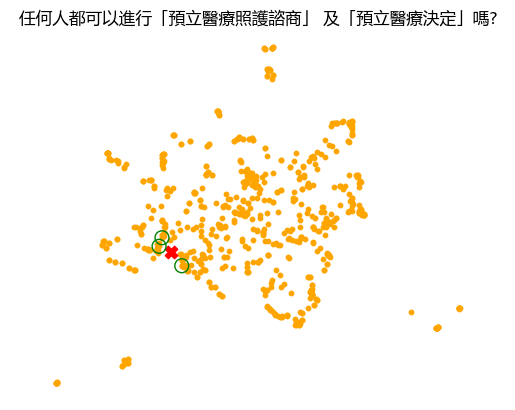

In [35]:
## 顯示, text vectordb
Query_ACP_AD_VIS(query, docs, projected_dataset_embeddings)

* ### Note the difference in results with `MMR`.

In [36]:
## 以 MMR方式擷取文件
query = "任何人都可以進行「預立醫療照護諮商」 及「預立醫療決定」嗎?"

docs_mmr = vectordb.max_marginal_relevance_search(query,k=5)
## k=3似乎略少

for document in docs_mmr:
    print(f"**{'-' * 20}** \n", document.page_content)
    print("\n")

**--------------------** 
 什麼是「預立醫療決定書」  (AD) ? 
「預立醫療決定書」 (AD)是指經過「預立醫療照護諮商」 (ACP)後，已經清楚瞭解  
「病人自主權利法」裡面規定，賦予病人預先表達在符合特定臨床條件的情況
時，接受或拒絕維持生命治療，或人 工營養及流體餵養的正式書面文件。所以申
請「預立醫療決定書」 ，必須先經過「預立醫療照護諮商」的程序，才能成立。  
 
申請「預立醫療決定書」  (AD) 需要那些資格或條件限制 ? 
1. 具有行為能力的人 (例如 20歲以上，或未成年但結婚的人 )。 
2. 有健保卡的人 (外籍人士有健保卡也可以簽 )。 
3. 心智清楚，不是被強迫來簽 。 
 
   「預立醫療照護諮商」 ( ACP)申請流程 ? 
步驟一：邀請尋找 2位必要陪同參與親友，並且預約醫院的「預立醫療照護諮
商」門診  
諮商團隊成員會向您 (意願人 )及參與者 (參與的親友 )做下列的說明：  
依病人自主權利法的規定，我會有那些「知情、選擇與決定權」？  
可以終止、撤除或不施行「維持生命治療」或「人工營養及流體餵養」所應符合
的特定臨床條件有哪些？


**--------------------** 
 (2) 無法出門的失能長者，透過居家失能個案家庭醫師方案，由醫師到宅協助進行「預立醫療照護諮商」服務
(3) 經確診之癌症病人可免費進行「預立醫療照護諮商」(目前持續規劃確認中)
Ｑ：如果我簽署預立醫療決定，以後我生病住院的話，醫護人員會不會就直接放棄 不救我了」？
Ａ：不會，經由「預立醫療決定」簽署後，當上述五款「臨床條件病人」發生時，您的預立醫療決定才會被啟動與執行，而是否符合這五款的條件，必須經過兩位專科醫師、至少二次緩和醫療團隊照會評估，其過程非常謹慎，不可能因立下預立醫療決定，而讓原有治癒機會的患者因而被提前放棄治療。
Ｑ：醫療進展快速，若現在治不好的疾病以後有機會根癒，想改變決定怎麼辦？
Ａ：可以隨時撤回或變更AD，如果改變決定，須向醫療機構提供變更，並再次註記在健保卡。
Ｑ：「預立醫療決定」跟安樂死有什麼不同?
Ａ：病人自主權利法不是安樂死，病人衡量自我生命品質價值觀後，可自主決定拒絕 透過人工或儀器介入來維繫生命，醫師則在尊重「末期病人」意願下中止醫療，讓病人自然地走。
Ｑ：簽署「預

100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:07<00:00,  1.45s/it]


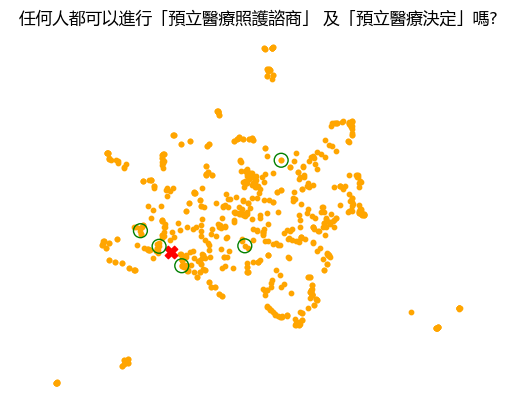

In [37]:
## show figure, text loader
Query_ACP_AD_VIS(query, docs_mmr, projected_dataset_embeddings)

100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:04<00:00,  1.25it/s]


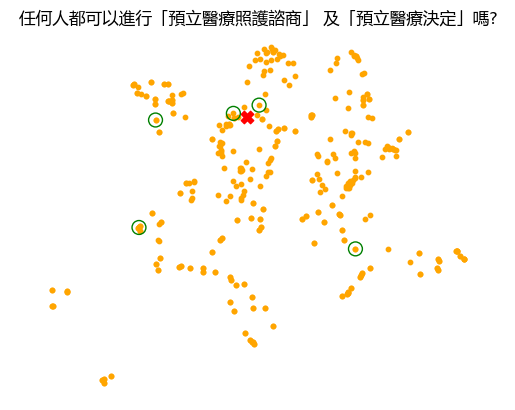

In [27]:
## show figure, txt splits
#Query_ACP_AD_VIS(query, docs_mmr, projected_dataset_embeddings)

100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:04<00:00,  1.14it/s]


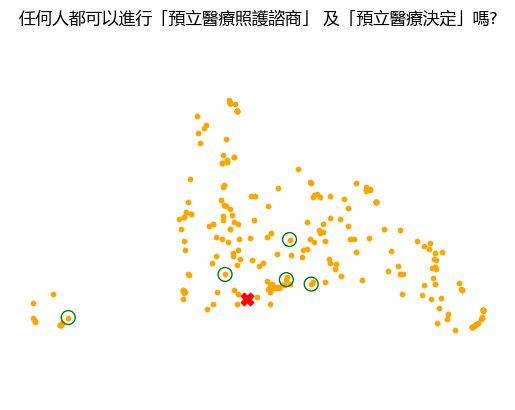

In [26]:
## show figure, pdf
#Query_ACP_AD_VIS(query, docs_mmr, projected_dataset_embeddings)

* ### 以ContextualCompressionRetrieverr方式,  LLMChainFilter擷取資料, need LLM 

In [38]:
import os

from dotenv import load_dotenv, find_dotenv
_ = load_dotenv(find_dotenv())                   # read local .env file, 不需要與程式在同一目錄內

In [39]:
query = "任何人都可以進行「預立醫療照護諮商」 及「預立醫療決定」嗎?"

## 擷取文件, LLM compression retrived data
k=10
#retriever = vectordb.as_retriever(search_type = "mmr", search_kwargs={"k":k})  ## default 為  similarity, k=4                    
retriever = vectordb.as_retriever(search_kwargs={"k":k})

### compression_retriever ### 
from langchain_openai import OpenAI
from langchain.retrievers import ContextualCompressionRetriever
from langchain.retrievers.document_compressors import LLMChainFilter
from langchain.retrievers.document_compressors import LLMChainExtractor
    
llm = OpenAI(temperature=0.0)
#llm_filter = LLMChainFilter.from_llm(llm)      ## filter 方式擷取內容
compressor = LLMChainExtractor.from_llm(llm)    ## 具摘錄及總結功能, 字句較少
compression_retriever_0 = ContextualCompressionRetriever(
                        #base_compressor=llm_filter, 
                        base_compressor=compressor,
                        base_retriever=retriever,
                        )  

## 擷取出來的各篇文件(頁)內容詞向量化
compressed_docs = compression_retriever_0.get_relevant_documents(query)

## 列印所擷取的資料
print(f"\n{'-' * 80}\n".join([f"Document {i+1}:\n\n" + d.page_content for i, d in enumerate(compressed_docs)]))   



Document 1:

- 「預立醫療照護諮商」 ( ACP)申請流程 ? 
- 依病人自主權利法的規定，我會有那些「知情、選擇與決定權」？  
- 可以終止、撤除或不施行「維持生命治療」或「人工營養及流體餵養」所應符合的特定臨床條件有哪些？
--------------------------------------------------------------------------------
Document 2:

(3) 經確診之癌症病人可免費進行「預立醫療照護諮商」(目前持續規劃確認中)
Ｑ：如果我簽署預立醫療決定，以後我生病住院的話，醫護人員會不會就直接放棄 不救我了」？
Ａ：不會，經由「預立醫療決定」簽署後，當上述五款「臨床條件病人」發生時，您的預立醫療決定才會被啟動與執行，而是否符合這五款的條件，必須經過兩位專科醫師、至少二次緩和醫療
--------------------------------------------------------------------------------
Document 3:

- Ｑ：我的家屬已經中風了，現在在養護中心可以簽署「預立醫療決定」嗎？
- Ａ：原則上只要您的家屬意識清楚且可以表達意願，在沒有心智缺陷或非出於自願的疑 慮下，需邀請二親等家屬及醫療委任代理人（若無醫療委任代理人則二親等家屬即可），共同參與預立醫療照護諮商及簽署預立醫療決定書。
--------------------------------------------------------------------------------
Document 4:

1.建議應簽署，因「預立醫療決定」除了保障末期病人，還擴大到上面所提的四種臨床條件病人，且拒絕醫療的範圍還包括，不接受鼻胃管灌食等延命措施範圍，建議簽過安寧意願書的人還是要簽預立醫療決定。
2.當疑似發生上面所提「五種臨床條件病人」時，會經由兩位專科醫師、至少二次緩和醫療團隊照會評估，確認符合上述 5 種臨床條件
--------------------------------------------------------------------------------
Document 5:

政府在 2019年1月6日公布實施《病人自主權利法》 。 
此為亞洲第

100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [00:14<00:00,  1.47s/it]


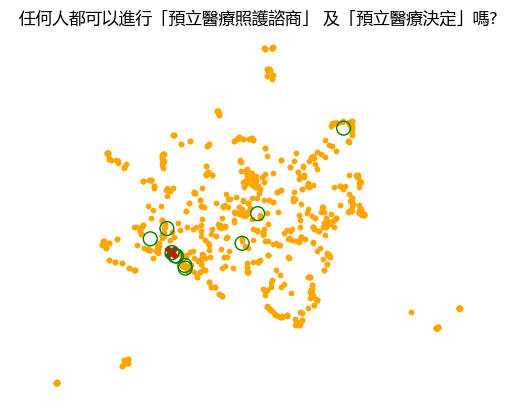

In [40]:
## show figure
Query_ACP_AD_VIS(query, compressed_docs, projected_dataset_embeddings)

* ## 4. Retriever

* ### get vector DB

In [1]:
## 取得 vector db ###
from langchain.vectorstores import Chroma
from langchain_openai import OpenAIEmbeddings
from langchain_community.embeddings import HuggingFaceEmbeddings

#embedding = OpenAIEmbeddings()
embedding = HuggingFaceEmbeddings()    

persist_directory = "./Data_test/VectorDB/預立醫療"                ## pdf 詞向量庫
#persdocist_directory = "./Data_test/VectorDB/預立醫療txt"
#persdocist_directory = "./Data_test/VectorDB/預立醫療_txt"
vectordb = Chroma(
    persist_directory=persist_directory,
    embedding_function=embedding
)


* ### 使用 ContextualCompressionRetriever (三種方式, 考慮用LLMChainFilter, 但似乎與一般retriver效果相當)

In [2]:
## Chroma retriever 方式, as base 

query = "任何人都可以進行「預立醫療照護諮商」 及「預立醫療決定」嗎?"

## 擷取文件, LLM compression retrived data
k=5
retriever = vectordb.as_retriever(search_type = "mmr", search_kwargs={"k":k})  ## default 為similarity, k=4                    
    

In [3]:
retriever

VectorStoreRetriever(tags=['Chroma', 'HuggingFaceEmbeddings'], vectorstore=<langchain_community.vectorstores.chroma.Chroma object at 0x000001DB704E3BE0>, search_type='mmr', search_kwargs={'k': 5})

In [21]:
query = "任何人都可以進行「預立醫療照護諮商」 及「預立醫療決定」嗎?"

## 擷取文件, LLM compression retrived data
k=10
retriever = vectordb.as_retriever(search_type = "mmr", search_kwargs={"k":k})  ## default 為  similarity, k=4                    
    
### compression_retriever ### need LLM
from langchain_openai import OpenAI
from langchain.retrievers import ContextualCompressionRetriever
from langchain.retrievers.document_compressors import LLMChainFilter
from langchain.retrievers.document_compressors import LLMChainExtractor

    
llm = OpenAI(temperature=0.0)
#llm_filter = LLMChainFilter.from_llm(llm)                    ## filter 方式擷取內容
compressor = LLMChainExtractor.from_llm(llm)                  ## 具摘錄及總結功能, 字句較少
compression_retriever = ContextualCompressionRetriever(
                        #base_compressor=llm_filter,          ## filter 方式擷取內容
                        base_compressor=compressor,
                        base_retriever=retriever,
                        ) 

## 擷取出來的各篇文件(頁)內容
compressed_docs = compression_retriever.get_relevant_documents(query)

## 列印所擷取的資料
print(f"\n{'-' * 80}\n".join([f"Document {i+1}:\n\n" + d.page_content for i, d in enumerate(compressed_docs)]))   



#### EmbeddingsFilter

In [78]:
## 內容多了向量資料, 使用embedding時, 需只取出 page_context, 否則meta資料太多 ...; 
from langchain.retrievers.document_compressors import EmbeddingsFilter
from langchain_openai import OpenAIEmbeddings

embedding = OpenAIEmbeddings()              
embeddings_filter = EmbeddingsFilter(embeddings=embedding, similarity_threshold=0.76)
compression_retriever_1 = ContextualCompressionRetriever(
    base_compressor=embeddings_filter, 
    base_retriever=retriever
)

In [81]:
compressed_docs

[_DocumentWithState(page_content='請「預立醫療決定書」 ，必須先經過「預立醫療照護諮商」的程序，才能成立。  \n \n申請「預立醫療決定書」  (AD) 需要那些資格或條件限制 ? \n1. 具有行為能力的人 (例如 20歲以上，或未成年但結婚的人 )。 \n2. 有健保卡的人 (外籍人士有健保卡也可以簽 )。 \n3. 心智清楚，不是被強迫來簽 。', metadata={'page': 0, 'source': './Data_test/預立醫療資料\\預立醫療步驟.pdf'}, state={'embedded_doc': [0.02097578266283637, 0.0030978065149884363, 0.01775575891304616, -0.04090864417697283, -0.023009482069298107, 0.016921420503970035, -0.0035198642319672706, -0.003813186154285103, -0.02675096825608352, -0.003660006866097616, 0.01057914790981818, 0.010729067568830072, -0.02057165011235545, 0.010148942051222977, -0.022501058149005295, 0.01625655859763676, 0.02410455169687183, -0.01822507473381279, 0.016986603774255746, -0.012169604803627573, -0.009171201378840912, 0.017703614159462835, -0.008708404816425475, -0.0031303976844699807, 0.007417788171962487, 0.011035426145205045, 0.017195188376524777, -0.016647654494060537, -0.004308574584674051, -0.014926831991002346, 0.011504741034649053, 0.0020369585699760236

In [79]:
compressed_docs = compression_retriever_1.get_relevant_documents(query)

## 列印所擷取的資料
print(f"\n{'-' * 80}\n".join([f"Document {i+1}:\n\n" + d.page_content for i, d in enumerate(compressed_docs)]))   


Document 1:

請「預立醫療決定書」 ，必須先經過「預立醫療照護諮商」的程序，才能成立。  
 
申請「預立醫療決定書」  (AD) 需要那些資格或條件限制 ? 
1. 具有行為能力的人 (例如 20歲以上，或未成年但結婚的人 )。 
2. 有健保卡的人 (外籍人士有健保卡也可以簽 )。 
3. 心智清楚，不是被強迫來簽 。
--------------------------------------------------------------------------------
Document 2:

Q1：哪邊可以拿到預立醫療決定的表格？是不是簽
名就可以？  
 
A：提供 AD網站簽署前也必須與醫療團隊共同進行
「預立醫療照護諮商」會議，討論各項醫療選項的成
效與風險，透過溝通與決策過程，以書面形式完成您
的「預立醫療決定」。另外，還需完成健保 IC卡註
記，您的「預立醫療決定」才具法律效力。  
  
  
Q2：任何人都可以進行「預立醫療照護諮商」  及
「預立醫療決定」嗎？  
  
A：滿 20歲具有完全行為能力者皆可，只要您：   
1.  至醫療機構完成「預立醫療照護諮商」，並經兩
人以上在場見證或公證程序。  
2.  完成健保 IC卡註記，您的「預立醫療決定」即具
有法律效力。  
  
 
Q3：我想帶我媽去參加預立醫療決定諮商，我要怎
麼跟她說？
--------------------------------------------------------------------------------
Document 3:

「預立醫療照護諮商」 ( ACP)申請流程 ? 
步驟一：邀請尋找 2位必要陪同參與親友，並且預約醫院的「預立醫療照護諮
商」門診  
諮商團隊成員會向您 (意願人 )及參與者 (參與的親友 )做下列的說明：  
依病人自主權利法的規定，我會有那些「知情、選擇與決定權」？  
可以終止、撤除或不施行「維持生命治療」或「人工營養及流體餵養」所應符合
的特定臨床條件有哪些？  
預立醫療決定書的「內容及其生效的法律程序」是 什麼？  
預立醫療決定書的「更改或撤回方式」是什麼？  
 
步驟二：簽署預立醫療決定書  
完成「預立醫療照護諮商」 ，不代表完成預立醫療決定喔 ~ 
發言別忘了簽妥「預立醫

* ### MultiQueryRetriever
* #### 產生多個query 及 隨之而來的docs

In [31]:
from langchain.retrievers.multi_query import MultiQueryRetriever
from langchain_openai import ChatOpenAI

query = "任何人都可以進行「預立醫療照護諮商」 及「預立醫療決定」嗎?"

llm = ChatOpenAI(temperature=0)
retriever_from_llm = MultiQueryRetriever.from_llm(
    retriever=vectordb.as_retriever(), llm=llm
)


In [33]:
# Set logging for the queries
import logging

logging.basicConfig()
logging.getLogger("langchain.retrievers.multi_query").setLevel(logging.INFO)

## 得到文件..
docs_query = retriever_from_llm.get_relevant_documents(query=query, k=5)
len(docs_query)

## get 3 questions and 5 docs

INFO:langchain.retrievers.multi_query:Generated queries: ['1. 可以進行「預立醫療照護諮商」和「預立醫療決定」的人有哪些？', '2. 誰有資格進行「預立醫療照護諮商」和「預立醫療決定」？', '3. 哪些人可以參與「預立醫療照護諮商」和「預立醫療決定」的過程？']


5

In [38]:
docs_query

[Document(page_content='Q1：哪邊可以拿到預立醫療決定的表格？是不是簽\n名就可以？  \n \nA：提供 AD網站簽署前也必須與醫療團隊共同進行\n「預立醫療照護諮商」會議，討論各項醫療選項的成\n效與風險，透過溝通與決策過程，以書面形式完成您\n的「預立醫療決定」。另外，還需完成健保 IC卡註\n記，您的「預立醫療決定」才具法律效力。  \n  \n  \nQ2：任何人都可以進行「預立醫療照護諮商」  及\n「預立醫療決定」嗎？  \n  \nA：滿 20歲具有完全行為能力者皆可，只要您：   \n1.  至醫療機構完成「預立醫療照護諮商」，並經兩\n人以上在場見證或公證程序。  \n2.  完成健保 IC卡註記，您的「預立醫療決定」即具\n有法律效力。  \n  \n \nQ3：我想帶我媽去參加預立醫療決定諮商，我要怎\n麼跟她說？', metadata={'page': 0, 'source': './Data_test/預立醫療資料\\QAs.pdf'}),
 Document(page_content='3.「預立醫療決定書」填寫範例說明：', metadata={'page': 1, 'source': './Data_test/預立醫療資料\\臺北市立聯合醫院-什麼是預立醫療決定-什麼是預立醫療決定書？.pdf'}),
 Document(page_content='看完覺得內容複雜嗎？沒關係，您還需要到醫療機構去完成「預立醫療照', metadata={'page': 3, 'source': './Data_test/預立醫療資料\\臺北市立聯合醫院-什麼是預立醫療決定-什麼是預立醫療決定書？.pdf'}),
 Document(page_content='諮商團隊成員會向您 ( 意願⼈ ) 及參與者 ( 參與的親友 ) 做下列的說明：\n依病⼈⾃主權利法的規定，我會有那些「知情、選擇與決定權」？\n可以終⽌、撤除或不施⾏「維持⽣命治療」或「⼈⼯營養及流體餵養」所應符合的特定臨床條\n件有哪些？\n預立醫療決定書的「內容及其⽣效的法律程序」是什麼？\n預立醫療決定書的「更改或撤回⽅式」是什麼？\n \n醫療委任代理⼈是做什麼的 ? 終⽌委任或解除委任的相關規定 ?', metadata={'page': 2, 'sourc

In [35]:
print(docs_query[0].page_content)

Q1：哪邊可以拿到預立醫療決定的表格？是不是簽
名就可以？  
 
A：提供 AD網站簽署前也必須與醫療團隊共同進行
「預立醫療照護諮商」會議，討論各項醫療選項的成
效與風險，透過溝通與決策過程，以書面形式完成您
的「預立醫療決定」。另外，還需完成健保 IC卡註
記，您的「預立醫療決定」才具法律效力。  
  
  
Q2：任何人都可以進行「預立醫療照護諮商」  及
「預立醫療決定」嗎？  
  
A：滿 20歲具有完全行為能力者皆可，只要您：   
1.  至醫療機構完成「預立醫療照護諮商」，並經兩
人以上在場見證或公證程序。  
2.  完成健保 IC卡註記，您的「預立醫療決定」即具
有法律效力。  
  
 
Q3：我想帶我媽去參加預立醫療決定諮商，我要怎
麼跟她說？


* ## 5. 理想答案資料庫, for系統建置時 model評估

* ### 評估用標準答案

In [43]:
## 標準問答對組合
# 提問
eval_queries = [
    "哪邊可以拿到預立醫療決定的表格？是不是簽名就可以？",
    "任何人都可以進行「預立醫療照護諮商」 及「預立醫療決定」嗎？",
    "我想帶我媽去參加預立醫療決定諮商，我要怎麼跟她說？",
    "我爸中風7年了，在養護中心可以簽預立醫療決定嗎？",
    "預立醫療照護諮商需要多久時間呢？",
    "兩位或兩位以上的意願人能否在同一次諮商中，一起完成預立醫療照護諮商？",
    "做了「預立醫療決定」後，是否發生明明還有治癒機會，或遭逢意外，卻被醫師提前放棄治療的情況？",
    "「預立醫療決定書」上傳註記後還能修改嗎？",
    "預立醫療決定書上為什麼需要見證人？",
    "誰可以擔任見證人？(外籍看護可以嗎？)",
    "誰不能擔任見證人？",
    "見證人要擔負什麼責任？",
    "如果沒有見證人，可以怎麼做？",
    "聽說預立醫療決定還要找見證人，所以我要找到見證人一起去醫院做預立醫療照護諮商嗎？",
    "做完預立醫療照護諮商(ACP)後，一定要填寫預立醫療決定書(AD)嗎？一定要當下完成並繳回嗎？",
    "拒絕人工營養及流體餵養，那是要將病人餓死、渴死嗎？",
    "如果我的二親等有事無法到門診參加預立醫療諮商，該怎麼辦？",    
]

# 理想答案
eval_answers = [
    "提供AD網站簽署前也必須與醫療團隊共同進行「預立醫療照護諮商」會議，討論各項醫療選項的成效與風險，透過溝通與決策過程，以書面形式完成您的「預立醫療決定」。另外，還需完成健保IC卡註記，您的「預立醫療決定」才具法律效力。", 
    "滿20歲具有完全行為能力者皆可，只要您： \
    1.至醫療機構完成「預立醫療照護諮商」，並經兩人以上在場見證或公證程序。\
    2.完成健保IC卡註記，您的「預立醫療決定」即具有法律效力。",
    "您可透過新聞報導、社會重大事件等話題，試著在聊天中找到討論時機，先聊聊自己對生命與死亡之體悟，鼓勵媽媽分享她的感受及想法，觀察媽媽反應。若媽媽不排斥，願意表達所期待的醫療照顧或身心靈需求，則可邀請她參加「預立醫療照護諮商」；並請告訴她，這是由醫師、護理師、社工師組成的諮商團隊，提供醫療、社會、家庭與心理的討論；諮商過後不一定要簽署「預立醫療決定」，但可透過諮商過程，讓媽媽有機會更清楚的思考與表達想法，也讓您有機會事先瞭解媽媽的期待。", 
    "原則上只要您的父親意識清楚且可以表達意願，以及在沒有心智缺陷或非出於自願的疑慮下，是可以邀請二親等家屬或醫療委任代理人，共同參與預立醫療照護諮商及簽署預立醫療決定的。", 
    "為了說明預立醫療意願書內涵並意願人的想法，推估約要半小時到一小時。", 
    "若當意願人及其家屬為彼此的二等親及醫療委任代理人，是可以一同完成預立醫療照護諮商。",
    "不會。須經由二位具相關專科醫師資格之醫師確診已符合條文所明定之臨床條件，並經緩和醫療團隊至少二次照會，才可執行預立醫療決定，不符合臨床條件者，應先予適當急救或採取必要措施，不得無故拖延；其過程非常謹慎，且經重重把關，不可能因立下預立醫療決定，而讓原有治癒機會的患者因而被提前放棄治療。",
    "意願人想撤回或變更預立醫療決定時，需要重新簽署預立醫療決定書，並向中央主管機關申請更新註記。",
    "為了保障個人簽署預立醫療決定書是出於自願、並無遭受外力脅迫等情況所決定。",
    "見證人除了不是意願人所指定之醫療委任代理人、主責照護醫療團隊成員、以及繼承人之外的受遺贈人、遺體或器官指定之受贈人、其他因意願人死亡而獲得利益者，剩下的人都可以擔任見證人。",
    "意願人所指定之醫療委任代理人、主責照護醫療團隊成員、以及繼承人之外的受遺贈人、遺體或器官指定之受贈人、其他因意願人死亡而獲得利益者，都不能擔任見證人。",
    "見證意願人簽署當下意識清楚、出於自願未受脅迫下簽署；不涉及醫療決策。",
    "可以找公證人。", 
    "不一定。病人自主權利法規定在預立醫療決定上簽名時有二名以上滿20歲具完全行為能力人在場見證或經公證人公證即可。若您的親友無法擔任見證人，您可事先告知醫療機構，有些機構或許協助安排。請特別注意，您的醫療委任代理人是無法做見證人。",
    "來參加ACP不一定要簽署AD喔。能與自己跟親友一起思考、探索生命議題的過程很有意義。您的醫療決定必須讓家人知道，才能當你意識不清的時候幫你實現。",
    "不是的！還可以慢慢從口餵食啊，過多水份養分其實造成額外負擔，末期病人並不會感到飢餓，餵食反而會造成嘔吐、食物進入氣管造成窒息等後果，若病人無法配合，掙扎甚至四肢約束、強迫裝置鼻胃管進行人工管灌，反更加痛苦。",
    "可以使用視訊參與預立醫療諮商，與醫療團隊共同了解您對生命真實想法與期待，確保預立醫療決定的實踐。",
]

## built idea answers pair...
ideaAnswers = [
    {"query": q, "answer": eval_answers[i]}
    for i, q in enumerate(eval_queries)
]

len(eval_queries), len(eval_answers)

In [45]:
## 核對
ideaAnswers

[{'query': '哪邊可以拿到預立醫療決定的表格？是不是簽名就可以？',
  'answer': '提供AD網站簽署前也必須與醫療團隊共同進行「預立醫療照護諮商」會議，討論各項醫療選項的成效與風險，透過溝通與決策過程，以書面形式完成您的「預立醫療決定」。另外，還需完成健保IC卡註記，您的「預立醫療決定」才具法律效力。'},
 {'query': '任何人都可以進行「預立醫療照護諮商」 及「預立醫療決定」嗎？',
  'answer': '滿20歲具有完全行為能力者皆可，只要您：     1.至醫療機構完成「預立醫療照護諮商」，並經兩人以上在場見證或公證程序。    2.完成健保IC卡註記，您的「預立醫療決定」即具有法律效力。'},
 {'query': '我想帶我媽去參加預立醫療決定諮商，我要怎麼跟她說？',
  'answer': '您可透過新聞報導、社會重大事件等話題，試著在聊天中找到討論時機，先聊聊自己對生命與死亡之體悟，鼓勵媽媽分享她的感受及想法，觀察媽媽反應。若媽媽不排斥，願意表達所期待的醫療照顧或身心靈需求，則可邀請她參加「預立醫療照護諮商」；並請告訴她，這是由醫師、護理師、社工師組成的諮商團隊，提供醫療、社會、家庭與心理的討論；諮商過後不一定要簽署「預立醫療決定」，但可透過諮商過程，讓媽媽有機會更清楚的思考與表達想法，也讓您有機會事先瞭解媽媽的期待。'},
 {'query': '我爸中風7年了，在養護中心可以簽預立醫療決定嗎？',
  'answer': '原則上只要您的父親意識清楚且可以表達意願，以及在沒有心智缺陷或非出於自願的疑慮下，是可以邀請二親等家屬或醫療委任代理人，共同參與預立醫療照護諮商及簽署預立醫療決定的。'},
 {'query': '預立醫療照護諮商需要多久時間呢？', 'answer': '為了說明預立醫療意願書內涵並意願人的想法，推估約要半小時到一小時。'},
 {'query': '兩位或兩位以上的意願人能否在同一次諮商中，一起完成預立醫療照護諮商？',
  'answer': '若當意願人及其家屬為彼此的二等親及醫療委任代理人，是可以一同完成預立醫療照護諮商。'},
 {'query': '做了「預立醫療決定」後，是否發生明明還有治癒機會，或遭逢意外，卻被醫師提前放棄治療的情況？',
  'answer': '不會。須

* ### LLM-Generated examples, LLM 生成問答對

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
import os
import openai
import sys
sys.path.append('../..')

from dotenv import load_dotenv, find_dotenv
_ = load_dotenv(find_dotenv()) # read local .env file

openai.api_key  = os.environ['OPENAI_API_KEY']

* #### 逐頁生成 LLM examples(問答對)

In [40]:
## 取得 vector db ###
from langchain.vectorstores import Chroma
from langchain_openai import OpenAIEmbeddings
from langchain_community.embeddings import HuggingFaceEmbeddings

#embedding = OpenAIEmbeddings()
embedding = HuggingFaceEmbeddings()    

persist_directory = "../Data_test/VectorDB/預立醫療"
#persist_directory = "../Data_test/VectorDB/預立醫療"

vectordb = Chroma(
    persist_directory=persist_directory,
    embedding_function=embedding
)

#取出所有 splits_doc, check 數量, 或設定MAX
splits_doc = vectordb.similarity_search("", k = 1000)

print(len(splits_doc))

In [41]:
#splits_doc[1]

Document(page_content='預立醫療⾃主計畫的精神，做好⻑期、定期思考⾃⼰的計畫，畢竟計畫與安排也會因臨時狀況或\n其他因素做滾動式調整，因此建議定期檢視原來的醫療照護計畫是否有需要調整的地⽅，並且適\n時告知親友或醫療團隊、讓⼤家⼀起做好安排，讓⾃⼰的⼼願得以落實。\n點閱數：77088| 資料更新： 112-09-20 15:19| 資料檢視： 112-09-20 15:19\n| 資料維護：臺北市立聯合醫院', metadata={'page': 6, 'source': './Data_test/預立醫療資料\\臺北市立聯合醫院-預立醫療照護諮商服務-什麼是預立醫療照護諮商_.pdf'})

In [46]:
from langchain.evaluation.qa import QAGenerateChain
from langchain_openai import ChatOpenAI

## 經修改原package所在位置的prompttemplate後可以輸出繁體中文
example_gen_chain = QAGenerateChain.from_llm(ChatOpenAI(model="gpt-3.5-turbo"))

## 隨機生成examples(問答對), 逐頁生成答案
import random

k = 5                                                                                  ## 生成問答對的數量   
#random_integers = [random.randint(0, len(splits_doc)) for _ in range(num_integers)]   ## 隨機整數, 但數值可能重複...
random_integers = random.sample(range(len(splits_doc)), k)                             ## range, 以及產生k個隨機整數
                                  
llm_examples = []
for i in random_integers:                                                            
    llm_examples_i = example_gen_chain.apply_and_parse(
        [{"doc": t} for t in splits_doc[i:i+1]]
    )
    ## Combine examples
    llm_examples += llm_examples_i

# 須從'qa_pairs'取出資料, 
llm_examples = [item['qa_pairs'] for item in llm_examples]

## Combine examples
examples = ideaAnswers.copy()          ## 理想答案
examples += llm_examples               ## AI 生成答案+理想答案

In [47]:
## 輸出略呆, 或可修改原程式
llm_examples

[{'query': '根據這份文件中的問題，當您罹患重病時，您是否希望親近的人知道您的病情？',
  'answer': '根據這份文件中的問題，提到了如果您罹患重病，您是否希望親近的人知道您的病情。您可以選擇「我希望親近的人知道一切病情」或者「我不希望他們知道任何病情」。'},
 {'query': '根據文件中的解釋，什麼是安寧緩和醫療？  ',
  'answer': '根據文件中的解釋，安寧緩和醫療指的是為減輕或免除末期病人的生理、心理及靈性痛苦，施予緩解性、支持性的醫療照護，以增進其生活品質。'},
 {'query': '根據文檔中提到的問題Q2，如果疾病造成您無法照顧自己或不認得外界事物，對自己需要被照顧的想法是什麼？',
  'answer': '根據文檔中提到的問題Q2，疾病造成無法照顧自己或不認得外界事物時，對自己需要被照顧的想法是「需要被照顧」。'},
 {'query': '根據文件提到的「病人自主權利法」，預立醫療照護諮商門診是為了什麼目的？',
  'answer': '預立醫療照護諮商門診是為了尊重病人醫療自主、保障其善終權益，促進醫病關係和諧而制定的，讓病人在特定的醫療情況下做出符合自己意願的決定。'},
 {'query': '根據文件中提供的資訊，這份文件的標題是什麼？', 'answer': '這份文件的標題是「我的預立醫療決定 -心願探索手冊」。'}]

In [49]:
#examples
## 或可轉 dataframe, 再save 為csv...
## 或反向, 建立SQL/CSV 標準答案庫, 再取出為 emamples 格式... 

[{'query': '哪邊可以拿到預立醫療決定的表格？是不是簽名就可以？',
  'answer': '提供AD網站簽署前也必須與醫療團隊共同進行「預立醫療照護諮商」會議，討論各項醫療選項的成效與風險，透過溝通與決策過程，以書面形式完成您的「預立醫療決定」。另外，還需完成健保IC卡註記，您的「預立醫療決定」才具法律效力。'},
 {'query': '任何人都可以進行「預立醫療照護諮商」 及「預立醫療決定」嗎？',
  'answer': '滿20歲具有完全行為能力者皆可，只要您：     1.至醫療機構完成「預立醫療照護諮商」，並經兩人以上在場見證或公證程序。    2.完成健保IC卡註記，您的「預立醫療決定」即具有法律效力。'},
 {'query': '我想帶我媽去參加預立醫療決定諮商，我要怎麼跟她說？',
  'answer': '您可透過新聞報導、社會重大事件等話題，試著在聊天中找到討論時機，先聊聊自己對生命與死亡之體悟，鼓勵媽媽分享她的感受及想法，觀察媽媽反應。若媽媽不排斥，願意表達所期待的醫療照顧或身心靈需求，則可邀請她參加「預立醫療照護諮商」；並請告訴她，這是由醫師、護理師、社工師組成的諮商團隊，提供醫療、社會、家庭與心理的討論；諮商過後不一定要簽署「預立醫療決定」，但可透過諮商過程，讓媽媽有機會更清楚的思考與表達想法，也讓您有機會事先瞭解媽媽的期待。'},
 {'query': '我爸中風7年了，在養護中心可以簽預立醫療決定嗎？',
  'answer': '原則上只要您的父親意識清楚且可以表達意願，以及在沒有心智缺陷或非出於自願的疑慮下，是可以邀請二親等家屬或醫療委任代理人，共同參與預立醫療照護諮商及簽署預立醫療決定的。'},
 {'query': '預立醫療照護諮商需要多久時間呢？', 'answer': '為了說明預立醫療意願書內涵並意願人的想法，推估約要半小時到一小時。'},
 {'query': '兩位或兩位以上的意願人能否在同一次諮商中，一起完成預立醫療照護諮商？',
  'answer': '若當意願人及其家屬為彼此的二等親及醫療委任代理人，是可以一同完成預立醫療照護諮商。'},
 {'query': '做了「預立醫療決定」後，是否發生明明還有治癒機會，或遭逢意外，卻被醫師提前放棄治療的情況？',
  'answer': '不會。須

In [50]:
## 將LLM 生成答案存檔, 可check, 修改, 再成為理想答案

import pandas as pd
pd.set_option('display.max_colwidth', None)

columns = ['Question', 'Answer', 'Remark']

# 使用 pd.DataFrame() 建立 DataFrame
df_LLM = pd.DataFrame(columns=columns)

for i in range(0, len(llm_examples)):
     df_LLM.loc[i]= [llm_examples[i]["query"], llm_examples[i]["answer"], "AI"]

df_LLM

,Question,Answer,Remark
0,根據這份文件中的問題，當您罹患重病時，您是否希望親近的人知道您的病情？,根據這份文件中的問題，提到了如果您罹患重病，您是否希望親近的人知道您的病情。您可以選擇「我希望親近的人知道一切病情」或者「我不希望他們知道任何病情」。,AI
1,根據文件中的解釋，什麼是安寧緩和醫療？,根據文件中的解釋，安寧緩和醫療指的是為減輕或免除末期病人的生理、心理及靈性痛苦，施予緩解性、支持性的醫療照護，以增進其生活品質。,AI
2,根據文檔中提到的問題Q2，如果疾病造成您無法照顧自己或不認得外界事物，對自己需要被照顧的想法是什麼？,根據文檔中提到的問題Q2，疾病造成無法照顧自己或不認得外界事物時，對自己需要被照顧的想法是「需要被照顧」。,AI
3,根據文件提到的「病人自主權利法」，預立醫療照護諮商門診是為了什麼目的？,預立醫療照護諮商門診是為了尊重病人醫療自主、保障其善終權益，促進醫病關係和諧而制定的，讓病人在特定的醫療情況下做出符合自己意願的決定。,AI
4,根據文件中提供的資訊，這份文件的標題是什麼？,這份文件的標題是「我的預立醫療決定 -心願探索手冊」。,AI


In [22]:
# 將 DataFrame 寫入 CSV 檔案
df_LLM.to_csv("LLM_QA.csv", index=False)     # index=False 避免寫入索引列

In [52]:
import pandas as pd

# 從 CSV 讀取資料到 DataFrame
df_LLM = pd.read_csv("LLM_QA.csv")
df_LLM

,Question,Answer,Remark
0,根據文件中的描述，什麼是指「不施行心肺復甦術」和「不施行維生醫療」？,「不施行心肺復甦術」指對臨終、瀕死或無生命徵象之病人不施予氣管內插管、體外心臟按壓、急救藥物注射、心臟電擊、心臟人工調頻、人工呼吸等標準急救程序或其他緊急救治行為。而「不施行維生醫療」指末期病人不施行用以維持生命徵象及延長其瀕死過程的醫療措施。,AI
1,根據文檔中提到的內容，預立醫療決定書中需要多少名見證人？他們的作用是什麼？,預立醫療決定書需要2個18歲以上的見證人。他們的作用是確定簽署者是自願簽署，並證明沒有人強迫他們簽署這份決定書。如果找不到2個見證人，也可以去法院找公證人。,AI
2,在這份文件中，提到了哪個重要的文件？這個文件的縮寫是什麼？,這份文件提到了「預立醫療決定書 (AD)」，其縮寫為AD。,AI
3,What is the source of the document provided in the metadata?,The source of the document is './Data_test/預立醫療資料\\預立醫療照護諮商說明工具(意願人版).pdf' as indicated in the metadata.,AI
4,根據文件中提到的內容，請列舉出極重度失智症中所描述的5種生病情況是什麼？,根據文件中提到的內容，極重度失智症中所描述的5種生病情況包括政府公告的疾病以及無法治好的疾病，例如：1. 罕見疾病 2. 漸凍人 3. 小腦萎縮症 4. 泡泡龍。,AI


In [31]:
## 理想答案 save to CSV
import pandas as pd

columns = ['Question', 'Answer', 'Remark' ]

# 使用 pd.DataFrame() 建立 DataFrame
df_H = pd.DataFrame(columns=columns)

for i in range(0, len(ideaAnswers)):
     df_H.loc[i]= [ideaAnswers[i]["query"], ideaAnswers[i]["answer"], "Human"]

# 將 DataFrame 寫入 CSV 檔案
df_H.to_csv("Human_QA.csv", index=False)     # index=False 避免寫入索引列        
        
df_H 

,Question,Answer,Remark
0,哪邊可以拿到預立醫療決定的表格？是不是簽名就可以？,提供AD網站簽署前也必須與醫療團隊共同進行「預立醫療照護諮商」會議，討論各項醫療選項的成效與...,Human
1,任何人都可以進行「預立醫療照護諮商」 及「預立醫療決定」嗎？,滿20歲具有完全行為能力者皆可，只要您： 1.至醫療機構完成「預立醫療照護諮商」，並...,Human
2,我想帶我媽去參加預立醫療決定諮商，我要怎麼跟她說？,您可透過新聞報導、社會重大事件等話題，試著在聊天中找到討論時機，先聊聊自己對生命與死亡之體悟...,Human
3,我爸中風7年了，在養護中心可以簽預立醫療決定嗎？,原則上只要您的父親意識清楚且可以表達意願，以及在沒有心智缺陷或非出於自願的疑慮下，是可以邀請...,Human
4,預立醫療照護諮商需要多久時間呢？,為了說明預立醫療意願書內涵並意願人的想法，推估約要半小時到一小時。,Human
5,兩位或兩位以上的意願人能否在同一次諮商中，一起完成預立醫療照護諮商？,若當意願人及其家屬為彼此的二等親及醫療委任代理人，是可以一同完成預立醫療照護諮商。,Human
6,做了「預立醫療決定」後，是否發生明明還有治癒機會，或遭逢意外，卻被醫師提前放棄治療的情況？,不會。須經由二位具相關專科醫師資格之醫師確診已符合條文所明定之臨床條件，並經緩和醫療團隊至少...,Human
7,「預立醫療決定書」上傳註記後還能修改嗎？,意願人想撤回或變更預立醫療決定時，需要重新簽署預立醫療決定書，並向中央主管機關申請更新註記。,Human
8,預立醫療決定書上為什麼需要見證人？,為了保障個人簽署預立醫療決定書是出於自願、並無遭受外力脅迫等情況所決定。,Human
9,誰可以擔任見證人？(外籍看護可以嗎？),見證人除了不是意願人所指定之醫療委任代理人、主責照護醫療團隊成員、以及繼承人之外的受遺贈人、...,Human


In [53]:
import pandas as pd

# 從 CSV 讀取資料到 DataFrame
df_H = pd.read_csv("Human_QA.csv")

df_H

,Question,Answer,Remark
0,哪邊可以拿到預立醫療決定的表格？是不是簽名就可以？,提供AD網站簽署前也必須與醫療團隊共同進行「預立醫療照護諮商」會議，討論各項醫療選項的成效與風險，透過溝通與決策過程，以書面形式完成您的「預立醫療決定」。另外，還需完成健保IC卡註記，您的「預立醫療決定」才具法律效力。,Human
1,任何人都可以進行「預立醫療照護諮商」 及「預立醫療決定」嗎？,滿20歲具有完全行為能力者皆可，只要您： 1.至醫療機構完成「預立醫療照護諮商」，並經兩人以上在場見證或公證程序。 2.完成健保IC卡註記，您的「預立醫療決定」即具有法律效力。,Human
2,我想帶我媽去參加預立醫療決定諮商，我要怎麼跟她說？,您可透過新聞報導、社會重大事件等話題，試著在聊天中找到討論時機，先聊聊自己對生命與死亡之體悟，鼓勵媽媽分享她的感受及想法，觀察媽媽反應。若媽媽不排斥，願意表達所期待的醫療照顧或身心靈需求，則可邀請她參加「預立醫療照護諮商」；並請告訴她，這是由醫師、護理師、社工師組成的諮商團隊，提供醫療、社會、家庭與心理的討論；諮商過後不一定要簽署「預立醫療決定」，但可透過諮商過程，讓媽媽有機會更清楚的思考與表達想法，也讓您有機會事先瞭解媽媽的期待。,Human
3,我爸中風7年了，在養護中心可以簽預立醫療決定嗎？,原則上只要您的父親意識清楚且可以表達意願，以及在沒有心智缺陷或非出於自願的疑慮下，是可以邀請二親等家屬或醫療委任代理人，共同參與預立醫療照護諮商及簽署預立醫療決定的。,Human
4,預立醫療照護諮商需要多久時間呢？,為了說明預立醫療意願書內涵並意願人的想法，推估約要半小時到一小時。,Human
5,兩位或兩位以上的意願人能否在同一次諮商中，一起完成預立醫療照護諮商？,若當意願人及其家屬為彼此的二等親及醫療委任代理人，是可以一同完成預立醫療照護諮商。,Human
6,做了「預立醫療決定」後，是否發生明明還有治癒機會，或遭逢意外，卻被醫師提前放棄治療的情況？,不會。須經由二位具相關專科醫師資格之醫師確診已符合條文所明定之臨床條件，並經緩和醫療團隊至少二次照會，才可執行預立醫療決定，不符合臨床條件者，應先予適當急救或採取必要措施，不得無故拖延；其過程非常謹慎，且經重重把關，不可能因立下預立醫療決定，而讓原有治癒機會的患者因而被提前放棄治療。,Human
7,「預立醫療決定書」上傳註記後還能修改嗎？,意願人想撤回或變更預立醫療決定時，需要重新簽署預立醫療決定書，並向中央主管機關申請更新註記。,Human
8,預立醫療決定書上為什麼需要見證人？,為了保障個人簽署預立醫療決定書是出於自願、並無遭受外力脅迫等情況所決定。,Human
9,誰可以擔任見證人？(外籍看護可以嗎？),見證人除了不是意願人所指定之醫療委任代理人、主責照護醫療團隊成員、以及繼承人之外的受遺贈人、遺體或器官指定之受贈人、其他因意願人死亡而獲得利益者，剩下的人都可以擔任見證人。,Human


* ### 將 examples問答對轉為pandas dataframe, 並存為 CSV 資料
* #### examples = Huamn + AI; 或 df_AI, df_H merge 更適合

In [34]:
import pandas as pd

columns = ['Question', 'Answer']

# 使用 pd.DataFrame() 建立 DataFrame
df = pd.DataFrame(columns=columns)

for i in range(0, len(examples)):
     df.loc[i]= [examples[i]["query"], examples[i]["answer"]]

df      

,Question,Answer
0,哪邊可以拿到預立醫療決定的表格？是不是簽名就可以？,提供AD網站簽署前也必須與醫療團隊共同進行「預立醫療照護諮商」會議，討論各項醫療選項的成效與...
1,任何人都可以進行「預立醫療照護諮商」 及「預立醫療決定」嗎？,滿20歲具有完全行為能力者皆可，只要您： 1.至醫療機構完成「預立醫療照護諮商」，並...
2,我想帶我媽去參加預立醫療決定諮商，我要怎麼跟她說？,您可透過新聞報導、社會重大事件等話題，試著在聊天中找到討論時機，先聊聊自己對生命與死亡之體悟...
3,我爸中風7年了，在養護中心可以簽預立醫療決定嗎？,原則上只要您的父親意識清楚且可以表達意願，以及在沒有心智缺陷或非出於自願的疑慮下，是可以邀請...
4,預立醫療照護諮商需要多久時間呢？,為了說明預立醫療意願書內涵並意願人的想法，推估約要半小時到一小時。
5,兩位或兩位以上的意願人能否在同一次諮商中，一起完成預立醫療照護諮商？,若當意願人及其家屬為彼此的二等親及醫療委任代理人，是可以一同完成預立醫療照護諮商。
6,做了「預立醫療決定」後，是否發生明明還有治癒機會，或遭逢意外，卻被醫師提前放棄治療的情況？,不會。須經由二位具相關專科醫師資格之醫師確診已符合條文所明定之臨床條件，並經緩和醫療團隊至少...
7,「預立醫療決定書」上傳註記後還能修改嗎？,意願人想撤回或變更預立醫療決定時，需要重新簽署預立醫療決定書，並向中央主管機關申請更新註記。
8,預立醫療決定書上為什麼需要見證人？,為了保障個人簽署預立醫療決定書是出於自願、並無遭受外力脅迫等情況所決定。
9,誰可以擔任見證人？(外籍看護可以嗎？),見證人除了不是意願人所指定之醫療委任代理人、主責照護醫療團隊成員、以及繼承人之外的受遺贈人、...


In [158]:
# 將 DataFrame 寫入 CSV 檔案
df.to_csv('QA_examples.csv', index=False)  # index=False 避免寫入索引列

In [55]:
import pandas as pd
pd.set_option('display.max_colwidth', None)

# 從 CSV 讀取資料到 DataFrame
df = pd.read_csv('QA_examples.csv')
df
##此版csv需修改

,Question,Answer
0,哪邊可以拿到預立醫療決定的表格？是不是簽名就可以？,提供AD網站簽署前也必須與醫療團隊共同進行「預立醫療照護諮商」會議，討論各項醫療選項的成效與風險，透過溝通與決策過程，以書面形式完成您的「預立醫療決定」。另外，還需完成健保IC卡註記，您的「預立醫療決定」才具法律效力。
1,任何人都可以進行「預立醫療照護諮商」 及「預立醫療決定」嗎？,滿20歲具有完全行為能力者皆可，只要您： 1.至醫療機構完成「預立醫療照護諮商」，並經兩人以上在場見證或公證程序。 2.完成健保IC卡註記，您的「預立醫療決定」即具有法律效力。
2,我想帶我媽去參加預立醫療決定諮商，我要怎麼跟她說？,您可透過新聞報導、社會重大事件等話題，試著在聊天中找到討論時機，先聊聊自己對生命與死亡之體悟，鼓勵媽媽分享她的感受及想法，觀察媽媽反應。若媽媽不排斥，願意表達所期待的醫療照顧或身心靈需求，則可邀請她參加「預立醫療照護諮商」；並請告訴她，這是由醫師、護理師、社工師組成的諮商團隊，提供醫療、社會、家庭與心理的討論；諮商過後不一定要簽署「預立醫療決定」，但可透過諮商過程，讓媽媽有機會更清楚的思考與表達想法，也讓您有機會事先瞭解媽媽的期待。
3,我爸中風7年了，在養護中心可以簽預立醫療決定嗎？,原則上只要您的父親意識清楚且可以表達意願，以及在沒有心智缺陷或非出於自願的疑慮下，是可以邀請二親等家屬或醫療委任代理人，共同參與預立醫療照護諮商及簽署預立醫療決定的。
4,預立醫療照護諮商需要多久時間呢？,為了說明預立醫療意願書內涵並意願人的想法，推估約要半小時到一小時。
5,兩位或兩位以上的意願人能否在同一次諮商中，一起完成預立醫療照護諮商？做了「預立醫療決定」後，是否發生明明還有治癒機會，或遭逢意外，卻被醫師提前放棄治療的情況？,若當意願人及其家屬為彼此的二等親及醫療委任代理人，是可以一同完成預立醫療照護諮商。
6,「預立醫療決定書」上傳註記後還能修改嗎？,不會。須經由二位具相關專科醫師資格之醫師確診已符合條文所明定之臨床條件，並經緩和醫療團隊至少二次照會，才可執行預立醫療決定，不符合臨床條件者，應先予適當急救或採取必要措施，不得無故拖延；其過程非常謹慎，且經重重把關，不可能因立下預立醫療決定，而讓原有治癒機會的患者因而被提前放棄治療。
7,預立醫療決定書上為什麼需要見證人？,意願人想撤回或變更預立醫療決定時，需要重新簽署預立醫療決定書，並向中央主管機關申請更新註記。
8,誰可以擔任見證人？(外籍看護可以嗎？),為了保障個人簽署預立醫療決定書是出於自願、並無遭受外力脅迫等情況所決定。
9,誰不能擔任見證人？見證人要擔負什麼責任？如果沒有見證人，可以怎麼做？聽說預立醫療決定還要找見證人，所以我要找到見證人一起去醫院做預立醫療照護諮商嗎？,見證人除了不是意願人所指定之醫療委任代理人、主責照護醫療團隊成員、以及繼承人之外的受遺贈人、遺體或器官指定之受贈人、其他因意願人死亡而獲得利益者，剩下的人都可以擔任見證人。


In [56]:
# 添加新的資料, if need
new_data = [examples[0]["query"], examples[0]["answer"]]

i = len(df)
df.loc[i] = new_data

In [57]:
df

,Question,Answer
0,哪邊可以拿到預立醫療決定的表格？是不是簽名就可以？,提供AD網站簽署前也必須與醫療團隊共同進行「預立醫療照護諮商」會議，討論各項醫療選項的成效與風險，透過溝通與決策過程，以書面形式完成您的「預立醫療決定」。另外，還需完成健保IC卡註記，您的「預立醫療決定」才具法律效力。
1,任何人都可以進行「預立醫療照護諮商」 及「預立醫療決定」嗎？,滿20歲具有完全行為能力者皆可，只要您： 1.至醫療機構完成「預立醫療照護諮商」，並經兩人以上在場見證或公證程序。 2.完成健保IC卡註記，您的「預立醫療決定」即具有法律效力。
2,我想帶我媽去參加預立醫療決定諮商，我要怎麼跟她說？,您可透過新聞報導、社會重大事件等話題，試著在聊天中找到討論時機，先聊聊自己對生命與死亡之體悟，鼓勵媽媽分享她的感受及想法，觀察媽媽反應。若媽媽不排斥，願意表達所期待的醫療照顧或身心靈需求，則可邀請她參加「預立醫療照護諮商」；並請告訴她，這是由醫師、護理師、社工師組成的諮商團隊，提供醫療、社會、家庭與心理的討論；諮商過後不一定要簽署「預立醫療決定」，但可透過諮商過程，讓媽媽有機會更清楚的思考與表達想法，也讓您有機會事先瞭解媽媽的期待。
3,我爸中風7年了，在養護中心可以簽預立醫療決定嗎？,原則上只要您的父親意識清楚且可以表達意願，以及在沒有心智缺陷或非出於自願的疑慮下，是可以邀請二親等家屬或醫療委任代理人，共同參與預立醫療照護諮商及簽署預立醫療決定的。
4,預立醫療照護諮商需要多久時間呢？,為了說明預立醫療意願書內涵並意願人的想法，推估約要半小時到一小時。
5,兩位或兩位以上的意願人能否在同一次諮商中，一起完成預立醫療照護諮商？做了「預立醫療決定」後，是否發生明明還有治癒機會，或遭逢意外，卻被醫師提前放棄治療的情況？,若當意願人及其家屬為彼此的二等親及醫療委任代理人，是可以一同完成預立醫療照護諮商。
6,「預立醫療決定書」上傳註記後還能修改嗎？,不會。須經由二位具相關專科醫師資格之醫師確診已符合條文所明定之臨床條件，並經緩和醫療團隊至少二次照會，才可執行預立醫療決定，不符合臨床條件者，應先予適當急救或採取必要措施，不得無故拖延；其過程非常謹慎，且經重重把關，不可能因立下預立醫療決定，而讓原有治癒機會的患者因而被提前放棄治療。
7,預立醫療決定書上為什麼需要見證人？,意願人想撤回或變更預立醫療決定時，需要重新簽署預立醫療決定書，並向中央主管機關申請更新註記。
8,誰可以擔任見證人？(外籍看護可以嗎？),為了保障個人簽署預立醫療決定書是出於自願、並無遭受外力脅迫等情況所決定。
9,誰不能擔任見證人？見證人要擔負什麼責任？如果沒有見證人，可以怎麼做？聽說預立醫療決定還要找見證人，所以我要找到見證人一起去醫院做預立醫療照護諮商嗎？,見證人除了不是意願人所指定之醫療委任代理人、主責照護醫療團隊成員、以及繼承人之外的受遺贈人、遺體或器官指定之受贈人、其他因意願人死亡而獲得利益者，剩下的人都可以擔任見證人。


* #### 從CSV/dataframe 取出問答對

In [58]:
import random

## built QA examples from dataframe...

k= len(df_LLM)-1                                                      ## 隨機數的個數, 此處全取  
random_integers = random.sample(range(len(df_LLM)), k)                ## range, 以及產生隨機整數 list

examples_LLM = [
    {"query": df_LLM.iloc[i]["Question"], "answer": df_LLM.iloc[i]["Answer"]
}
    for i in random_integers
]

k= 10                                                                 ## 隨機數的個數, 此處10個  
random_ints = random.sample(range(len(df_H)), k)                ## range, 以及產生隨機整數 list
examples_H = [
    {"query": df_H.iloc[i]["Question"], "answer": df_H.iloc[i]["Answer"]
}
    for i in random_ints
]

In [59]:
examples = examples_LLM + examples_H

examples

[{'query': '根據文件中的描述，什麼是指「不施行心肺復甦術」和「不施行維生醫療」？',
  'answer': '「不施行心肺復甦術」指對臨終、瀕死或無生命徵象之病人不施予氣管內插管、體外心臟按壓、急救藥物注射、心臟電擊、心臟人工調頻、人工呼吸等標準急救程序或其他緊急救治行為。而「不施行維生醫療」指末期病人不施行用以維持生命徵象及延長其瀕死過程的醫療措施。'},
 {'query': '在這份文件中，提到了哪個重要的文件？這個文件的縮寫是什麼？',
  'answer': '這份文件提到了「預立醫療決定書 (AD)」，其縮寫為AD。'},
 {'query': '根據文檔中提到的內容，預立醫療決定書中需要多少名見證人？他們的作用是什麼？',
  'answer': '預立醫療決定書需要2個18歲以上的見證人。他們的作用是確定簽署者是自願簽署，並證明沒有人強迫他們簽署這份決定書。如果找不到2個見證人，也可以去法院找公證人。'},
 {'query': 'What is the source of the document provided in the metadata?',
  'answer': "The source of the document is './Data_test/預立醫療資料\\\\預立醫療照護諮商說明工具(意願人版).pdf' as indicated in the metadata."},
 {'query': '見證人要擔負什麼責任？', 'answer': '見證意願人簽署當下意識清楚、出於自願未受脅迫下簽署；不涉及醫療決策。'},
 {'query': '預立醫療決定書上為什麼需要見證人？',
  'answer': '為了保障個人簽署預立醫療決定書是出於自願、並無遭受外力脅迫等情況所決定。'},
 {'query': '做完預立醫療照護諮商(ACP)後，一定要填寫預立醫療決定書(AD)嗎？一定要當下完成並繳回嗎？',
  'answer': '來參加ACP不一定要簽署AD喔。能與自己跟親友一起思考、探索生命議題的過程很有意義。您的醫療決定必須讓家人知道，才能當你意識不清的時候幫你實現。'},
 {'query': '預立醫療照護諮商需要多久時間呢？', 'answer': '為了說明預立醫療意願書內涵並意願人的想法，推估約